# RPDA8412 Research Project

## Comparing Interpretable Machine Learning Models for Early Higher Education Dropout Prediction

Student: Nikhil Saroop  
Student Number: ST10040092  
Module: RPDA8412 Research Project

---

# Phase 0: Pre-analysis Research Protocol
This notebook documents the implementation of the approved quantitative secondary-data research study on early higher education dropout prediction (Realinho et al., 2022).

The analysis follows a reproducible and evidence-based workflow. Decisions specified in the approved research proposal are treated as pre-specified methodological commitments. Decisions that depend on the characteristics of the dataset will only be made after the relevant evidence has been examined and documented.

The analysis will therefore distinguish between:

1. Pre-specified research decisions established before modelling.
2. Evidence-based implementation decisions made after examining the dataset.
3. Research findings produced by the completed analysis.

This distinction is maintained to reduce the risk of changing the methodology in response to preferred results and to provide a transparent record of how the study was conducted (Romero and Ventura, 2020).

## Research Questions

RQ1. How do Logistic Regression, Random Forest and Gradient Boosting compare in predicting student dropout risk across pre-enrolment, post-first-semester and post-second-semester prediction stages?

RQ2. Which academic, demographic, socioeconomic and macroeconomic features are the strongest predictors of dropout risk at each stage, and how does feature importance shift as semester performance information becomes available?

RQ3. To what extent can SHAP-based explanations provide clear, consistent and practically useful insight into dropout-risk predictions for non-technical higher education practitioners?

## Research Hypotheses

H1. Gradient Boosting and Random Forest are expected to outperform Logistic Regression across the three prediction stages because ensemble models can capture non-linear interactions among student features.

H2. Model performance is expected to improve from Stage 1 to Stage 3 because semester-level academic performance data progressively increases the information available to the models.

H3. Academic performance indicators are expected to become more important than demographic and socioeconomic indicators from Stage 2 onward, as reflected in SHAP feature rankings.

H4. SHAP explanations are expected to provide transparent feature-level attributions that support the non-technical interpretation of dropout-risk predictions.

### Hypothesis evaluation principle

The hypotheses represent expectations to be tested rather than outcomes that the analysis is required to confirm.

Results that contradict or only partially support a hypothesis will be reported without changing the analytical procedure to obtain a preferred result (Romero and Ventura, 2020).

## Research Objectives

Objective 1. To compare the predictive performance of Logistic Regression, Random Forest and Gradient Boosting across three prediction stages using Accuracy, Precision, Recall, F1-score and ROC-AUC.

Objective 2. To rank and identify the strongest predictors of dropout risk at each prediction stage using SHAP-based feature attribution and supplementary model-native feature-importance analysis.

Objective 3. To evaluate whether SHAP explanations provide sufficiently consistent and clear evidence to support interpretable, data-driven student-retention decisions.


## Pre-specified Study Design

### Research approach
The study follows a quantitative, observational, non-experimental, predictive and comparative secondary-data design (Realinho et al., 2022).

### Primary models

The three primary machine learning models are:

- Logistic Regression : a transparent linear baseline that remains interpretable without post-hoc explanation methods (Hosmer, Lemeshow and Sturdivant, 2013).
- Random Forest : an ensemble of decision trees that can capture non-linear relationships among predictors (Breiman, 2001).
- Gradient Boosting : a sequential ensemble method that corrects earlier prediction errors at each stage (Friedman, 2001).

The models will be evaluated using the same student partitions and the same prediction-stage definitions.
### Prediction stages

- Stage 1: Pre-enrolment information only.
- Stage 2: Stage 1 information plus first-semester academic performance variables.
- Stage 3: Stage 2 information plus second-semester academic performance variables.

This cumulative staged design reflects the temporal logic of student dropout as a process rather than a single event, and follows the approach adopted in staged educational prediction research (Martins et al., 2021; Realinho et al., 2022).

The intended feature counts from the approved research design are:

- Stage 1: 24 predictors
- Stage 2: 30 predictors
- Stage 3: 36 predictors

These counts and the temporal separation between stages will be independently verified against the working dataset before modelling (Realinho et al., 2022; UCI Machine Learning Repository, 2026).

## Pre-specified Model Evaluation Metrics

The primary predictive performance measures are:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Recall and F1-score will receive particular attention because the positive class represents students who dropped out. In an early-warning context, failing to identify an actual dropout case may be more consequential than incorrectly flagging a non-dropout case for additional review (He and Garcia, 2009).

Confusion matrices will also be used to examine false positives and false negatives.

Additional metrics may be calculated where they provide useful supporting evidence, but they will not replace the primary evaluation measures specified in the research proposal (scikit-learn developers, 2026).

## Data Leakage and Test-set Protocol

The following rules are established before modelling:

- One stratified train/test split will be created and preserved across Stage 1, Stage 2 and Stage 3 (Kohavi, 1995).
- The same student records must therefore appear in the training and test partitions for every prediction stage.
- Preprocessing transformations will be fitted using training data only (scikit-learn developers, 2026).
- Hyperparameter optimisation will use training data and stratified cross-validation only (Kohavi, 1995; scikit-learn developers, 2026).
- The SMOTENC sensitivity analysis will operate on training data only (Lemaître, Nogueira and Aridas, 2017).
- Decision-threshold optimisation will use validation predictions rather than final test predictions (He and Garcia, 2009).
- The held-out test set will not be used to select features, preprocessing decisions, hyperparameters, imbalance strategies or probability thresholds.
- The final test set will be used only after the modelling procedure has been locked.
- The same random seed will be used for reproducible operations where applicable (scikit-learn developers, 2026).

Index checks will later be used to verify that the Stage 1, Stage 2 and Stage 3 partitions contain the same students.

## Pre-specified Class-imbalance Strategy

The dropout class is expected to represent the minority class.

The primary imbalance-handling strategy will be class weighting rather than oversampling (He and Garcia, 2009).

The planned approach is:

- Logistic Regression: balanced class weighting.
- Random Forest: balanced class weighting.
- Gradient Boosting: equivalent balanced sample weights supplied during model fitting.

SMOTENC will be evaluated separately as a training-only sensitivity analysis (Lemaître, Nogueira and Aridas, 2017). Traditional SMOTE is not used because the dataset contains a mixture of categorical and numerical variables, where standard synthetic oversampling may produce unrealistic feature combinations (Chawla et al., 2002; Lemaître, Nogueira and Aridas, 2017).

SMOTENC will operate on the mixed-type training data before one-hot encoding. Its performance will be compared with the primary class-weighting approach using cross-validation on the training partition (Kohavi, 1995).

The untouched test-set class distribution will not be altered.

## Pre-specified Interpretability Protocol

SHAP is the primary model-interpretability framework (Lundberg and Lee, 2017).

The primary explainers will be:

- Logistic Regression: SHAP LinearExplainer (Lundberg and Lee, 2017).
- Random Forest: TreeSHAP (Lundberg et al., 2020).
- Gradient Boosting: TreeSHAP (Lundberg et al., 2020).

Global interpretation will use feature-level SHAP importance, particularly mean absolute SHAP values and feature rankings (Lundberg and Lee, 2017).

Selected local explanations will be used to demonstrate how individual predictions were constructed.

Cross-model interpretation will focus primarily on:

- Feature rankings within each model.
- Changes in feature rankings between prediction stages.
- Changes in the importance of broader feature groups.
- Consistency of influential predictors across models.
- Direction of effects where meaningful.

Raw SHAP magnitudes from different model families will not automatically be treated as directly comparable (Lundberg et al., 2020).

SHAP values will be interpreted as explanations of model predictions and not as evidence that a feature causes student dropout (Lundberg and Lee, 2017).

## Scope of the SHAP Evaluation

The study does not include interviews, surveys or usability testing with higher education practitioners.

Therefore, the practical usefulness of SHAP explanations cannot be directly validated through practitioner experience (Nagy and Molontay, 2024).

RQ3 and H4 will instead be assessed analytically through evidence such as:

- Consistency of global feature rankings (Lundberg and Lee, 2017).
- Stability of important predictors across model-stage combinations.
- Interpretability of selected local explanations.
- Whether explanations can be translated into cautious, non-causal language.
- Alignment between identified predictors and the educational context established in the literature review.

Any conclusion regarding practical usefulness will therefore be framed as analytical evidence rather than practitioner validation (Nagy and Molontay, 2024).

## Pre-specified Actionability Framework

The actionability framework is defined before predictive results and SHAP feature rankings are examined.

Its purpose is to prevent predictive importance from being automatically interpreted as justification for intervention (Yu, Lee and Kizilcec, 2021).

Three categories are used:

**Non-actionable features**

These describe characteristics that cannot responsibly be changed as part of a student-support intervention (Yu, Lee and Kizilcec, 2021).

Examples established in the research design include:

- Age
- Gender
- International status
- Parental education

These variables may be analysed for predictive or fairness purposes but will not be interpreted as direct intervention triggers.

**Semi-actionable features**

These describe circumstances that may support referral or institutional assistance but require cautious interpretation (Yu, Lee and Kizilcec, 2021).

Examples include:

- Tuition-fee status
- Debtor status

**Actionable features**

These describe factors that may more directly inform academic support.

Examples include:

- Approved curricular units
- Academic grades

**Application rule**

The complete variable-level actionability matrix will be operationalised after the dataset and official data dictionary have been verified. The categories themselves will not be changed in response to model performance or SHAP importance (Yu, Lee and Kizilcec, 2021).

## Pre-specified Counterfactual Explanation Constraints
DiCE will be used only as a supplementary interpretability analysis and only for a small number of selected high-risk cases from the best-performing later-stage model where appropriate (Mothilal, Sharma and Tan, 2020).

Counterfactual changes will be restricted to actionable or semi-actionable variables.

Non-actionable characteristics such as age, gender, international status and parental education will not be permitted to change during counterfactual generation (Yu, Lee and Kizilcec, 2021).

DiCE outputs will be interpreted as hypothetical model-based scenarios rather than causal recommendations or guaranteed intervention outcomes (Mothilal, Sharma and Tan, 2020).

LIME may also be applied to a small number of selected cases as a supplementary comparison with SHAP, but SHAP remains the primary interpretability method (Ribeiro, Singh and Guestrin, 2016).

## Analytical Decision Framework

Throughout the notebook, important methodological choices will be documented using the following structure:

**Observation** — What did the analysis or data inspection show?
**Options considered** — What reasonable methodological alternatives were available?
**Decision** — What approach was selected?
**Justification** — Why was the selected approach appropriate for the research problem, data and approved methodology?

This structure supports transparency and reproducibility by ensuring that every significant methodological choice is traceable to explicit evidence rather than to post-hoc rationalisation (Romero and Ventura, 2020).

## Separation of Research Decisions and Findings

Three types of information will be kept conceptually separate throughout this notebook.

### A. Pre-specified methodological decisions

These were established through the approved research design before predictive results were examined.

### B. Evidence-based implementation decisions

These will be made only after inspecting the relevant properties of the dataset and documenting the evidence supporting the decision.

### C. Research findings

These are outcomes produced by the analysis and are not methodological choices.

Examples include:

- Which model performs best.
- Which prediction stage performs best.
- Which predictors receive the highest SHAP importance.
- Whether subgroup error rates differ.
- Whether H1, H2, H3 and H4 are supported.

Research findings will be reported regardless of whether they agree with the original hypotheses.

In [2]:


RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

PRIMARY_METRICS = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

PRIMARY_MODELS = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting"
]

PREDICTION_STAGES = {
    "Stage 1": 24,
    "Stage 2": 30,
    "Stage 3": 36
}

print("Pre-analysis configuration")
print("-" * 40)
print(f"Random state: {RANDOM_STATE}")
print(f"Test proportion: {TEST_SIZE:.0%}")
print(f"Cross-validation folds: {CV_FOLDS}")

print("\nPrimary models:")
for model in PRIMARY_MODELS:
    print(f"- {model}")

print("\nConceptual source predictor counts (proposal; implemented: 23/29/35):")
for stage, count in PREDICTION_STAGES.items():
    print(f"- {stage}: {count} predictors")

print("\nPrimary evaluation metrics:")
for metric in PRIMARY_METRICS:
    print(f"- {metric}")

Pre-analysis configuration
----------------------------------------
Random state: 42
Test proportion: 20%
Cross-validation folds: 5

Primary models:
- Logistic Regression
- Random Forest
- Gradient Boosting

Conceptual source predictor counts (proposal; implemented: 23/29/35):
- Stage 1: 24 predictors
- Stage 2: 30 predictors
- Stage 3: 36 predictors

Primary evaluation metrics:
- accuracy
- precision
- recall
- f1
- roc_auc


# Phase 1: Research Environment and Reproducibility

Phase 1 establishes the reproducible computational environment before any data is loaded or transformed.

All library imports, global constants and output directory paths are configured here so that every subsequent phase can rely on a consistent, documented foundation.

Reproducibility is treated as a methodological requirement. A global random seed is set for all operations that involve stochastic processes, including data splitting, cross-validation fold assignment, model initialisation and sensitivity analyses (scikit-learn developers, 2026; Kohavi, 1995).

Setting the seed before the analysis begins ensures that the entire workflow produces identical outputs when re-executed from a restarted kernel, which is necessary for the final clean-run reproducibility verification in Phase 21.

In [3]:


from pathlib import Path
import sys
import platform
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import shap
import imblearn

warnings.resetwarnings()
warnings.simplefilter("default")


random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Python version:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("SHAP version:", shap.__version__)
print("Imbalanced-learn version:", imblearn.__version__)
print("Random state:", RANDOM_STATE)

Python version: 3.13.5
Platform: Windows-11-10.0.22000-SP0
Pandas version: 3.0.5
NumPy version: 2.5.2
Matplotlib version: 3.11.1
Scikit-learn version: 1.9.0
SHAP version: 0.52.0
Imbalanced-learn version: 0.14.2
Random state: 42


Libraries are organised by function. All imports are placed here so that the full dependency list is visible in one location.

The core data handling and numerical computation libraries are pandas and NumPy (pandas development team, 2026; NumPy developers, 2025). Visualisation uses matplotlib and seaborn (Matplotlib developers, 2025; Waskom, 2021).

Machine learning modelling, preprocessing, cross-validation and evaluation are handled through scikit-learn (scikit-learn developers, 2026; Pedregosa et al., 2011). Class-imbalance sensitivity analysis uses the imbalanced-learn implementation of SMOTENC (Lemaître, Nogueira and Aridas, 2017).

SHAP is the primary interpretability framework (Lundberg and Lee, 2017; Lundberg et al., 2020). LIME is imported as a supplementary local explanation method (Ribeiro, Singh and Guestrin, 2016). DiCE is imported as a supplementary counterfactual explanation method (Mothilal, Sharma and Tan, 2020).

## Phase 1.1: Establish Project Paths

## Project Directory Structure

The raw dataset, processed data, notebook, figures, tables and model outputs are stored in separate project folders.

The original raw dataset will remain unchanged. Any transformations performed during the study will be implemented programmatically and, where necessary, stored separately from the source file.

In [4]:


CURRENT_PATH = Path.cwd()

if CURRENT_PATH.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_PATH.parent
else:
    PROJECT_ROOT = CURRENT_PATH

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
MODELS_DIR = OUTPUT_DIR / "models"

DATA_PATH = RAW_DATA_DIR / "data.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        "Place the original data.csv file in the data/raw directory."
    )
print("Current working directory:")
print(CURRENT_PATH)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nRaw dataset path:")
print(DATA_PATH)

print("\nDataset file found:", DATA_PATH.exists())

Current working directory:
c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\notebooks

Project root:
c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook

Raw dataset path:
c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\data\raw\data.csv

Dataset file found: True


In [5]:

required_directories = [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    MODELS_DIR
]

for directory in required_directories:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directories confirmed:")
for directory in required_directories:
    print(f"- {directory}: {directory.exists()}")

Project directories confirmed:
- c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\data\raw: True
- c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\data\processed: True
- c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\outputs\figures: True
- c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\outputs\tables: True
- c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\outputs\models: True


### Finding: Project Directory Verification

Three output subdirectories are created if they do not already exist:

- Tables — for all CSV outputs produced throughout the analysis.
- Figures — for all visualisations.
- Models — for all serialised fitted model objects.

Separating outputs by type allows the Phase 21 manifest and integrity audit to verify completeness by directory (scikit-learn developers, 2026).

### Code Attribution — Phase 1

pandas development team, 2026. *pandas documentation* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/> [Accessed 14 September 2026].

NumPy developers, 2025. *NumPy documentation* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/> [Accessed 14 September 2026].

Matplotlib developers, 2025. *Matplotlib documentation* [Source code/documentation]. Available at: <https://matplotlib.org/stable/> [Accessed 14 September 2026].

Waskom, M.L., 2021. seaborn: statistical data visualization. *Journal of Open Source Software*, [e-journal] 6(60), article 3021. Available at: <https://doi.org/10.21105/joss.03021> [Accessed 14 September 2026].

scikit-learn developers, 2026. *scikit-learn documentation* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/> [Accessed 14 September 2026].

Lemaître, G., Nogueira, F. and Aridas, C.K., 2017. Imbalanced-learn: a Python toolbox to tackle the curse of imbalanced datasets in machine learning. *Journal of Machine Learning Research*, [e-journal] 18(17), pp.1–5. Available at: <https://jmlr.org/papers/v18/16-365.html> [Accessed 14 September 2026].

SHAP Documentation, 2025. *SHAP documentation* [Source code/documentation]. Available at: <https://shap.readthedocs.io/en/latest/> [Accessed 14 September 2026].

Ribeiro, M.T., Singh, S. and Guestrin, C., 2016. "Why should I trust you?": explaining the predictions of any classifier. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, pp.1135–1144. Available at: <https://doi.org/10.1145/2939672.2939778> [Accessed 14 September 2026].

Mothilal, R.K., Sharma, A. and Tan, C., 2020. Explaining machine learning classifiers through diverse counterfactual explanations. *Proceedings of the 2020 Conference on Fairness, Accountability, and Transparency*, pp.607–617. Available at: <https://doi.org/10.1145/3351095.3372850> [Accessed 14 September 2026].

Anthropic, 2026. *Claude* [large language model]. Available at: <https://claude.ai> [Accessed 14 September 2026].

OpenAI, 2026. *ChatGPT* [large language model]. Available at: <https://chatgpt.com> [Accessed 14 September 2026].

# Phase 2: Raw Dataset Verification

The approved research proposal described the source dataset as containing 4,424 student records, 36 predictor variables and one target variable (Realinho et al., 2022; UCI Machine Learning Repository, 2026).

## Phase 2.1 :  Load the raw file

In [6]:


df_raw = pd.read_csv(DATA_PATH, sep=";")

print("Raw dataset loaded successfully.")
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")

Raw dataset loaded successfully.
Rows: 4,424
Columns: 37


### Finding: Initial Data Preview

The first five records indicate that the dataset is structured as a tabular student-level dataset.

Each row represents an individual student record, while the columns contain a mixture of enrolment, demographic, socioeconomic, academic and macroeconomic information together with the original Target variable.

The preview also shows that many variables are represented numerically. However, their numerical storage format does not necessarily mean that they are continuous numerical variables. Several variables may represent coded categories and will therefore require interpretation using the published data dictionary before preprocessing decisions are made (UCI Machine Learning Repository, 2026).

No unusual values will be removed or changed based only on this initial preview.

## Phase 2.1A: Dataset Provenance and File-integrity Verification

The secondary dataset used in this study is the *Predict Students' Dropout and Academic Success* dataset obtained from the UCI Machine Learning Repository (Realinho et al., 2022).

The raw CSV file is retained separately from processed data and is not altered by the analytical workflow. A SHA-256 checksum is calculated to create a reproducible identifier for the exact file used in the study. This supports verification that subsequent clean executions use the same source data.

The checksum confirms file identity; it does not independently verify the substantive accuracy of the source dataset.

In [7]:
import hashlib


def calculate_sha256(file_path, chunk_size=1024 * 1024):
    """Calculate the SHA-256 checksum of a file."""
    digest = hashlib.sha256()

    with open(file_path, "rb") as file_object:
        for chunk in iter(lambda: file_object.read(chunk_size), b""):
            digest.update(chunk)

    return digest.hexdigest()


dataset_sha256 = calculate_sha256(DATA_PATH)


EXPECTED_DATASET_SHA256 = (
    "3ef126de5cefff26eb11fbb4237f1a1401cb64b488e2f1d598c23cedeb4c45ae"
)

dataset_provenance = pd.DataFrame(
    [
        {
            "Dataset": "Predict Students' Dropout and Academic Success",
            "Repository": "UCI Machine Learning Repository",
            "Source_Citation": "Realinho et al. (2022)",
            "Verification_Date": "13 September 2026",
            "Rows": int(df_raw.shape[0]),
            "Columns": int(df_raw.shape[1]),
            "SHA256": dataset_sha256,
            "Checksum_Match": dataset_sha256 == EXPECTED_DATASET_SHA256,
        }
    ]
)

assert dataset_sha256 == EXPECTED_DATASET_SHA256, (
    "The dataset checksum differs from the verified source file. "
    "Confirm that the correct unmodified data.csv file is being used."
)

dataset_provenance.to_csv(
    TABLES_DIR / "phase2_dataset_provenance.csv",
    index=False
)

display(dataset_provenance)

,Dataset,Repository,Source_Citation,Verification_Date,Rows,Columns,SHA256,Checksum_Match
0,Predict Students' Dropout and Academic Success,UCI Machine Learning Repository,Realinho et al. (2022),13 September 2026,4424,37,3ef126de5cefff26eb11fbb4237f1a1401cb64b488e2f1...,True


### Finding: Dataset Provenance and Integrity

The raw file contains 4,424 student records and 37 columns, matching the documented structure of 36 predictors and one target variable.

The calculated SHA-256 checksum matched the verified checksum recorded for the original working CSV file. This confirms that the file loaded during this execution is byte-for-byte identical to the dataset previously verified for the study.

The integrity check was completed before cleaning, target recoding, feature exclusion, exploratory analysis or predictive modelling. The result therefore provides a reproducible record of the exact raw file used throughout the study.

## Phase 2.2: Preview the Raw Dataset


In [8]:

display(df_raw.head())

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Phase 2.3 : Inspect the raw column names

In [9]:


for i, column in enumerate(df_raw.columns, start=1):
    print(f"{i:02d}. {repr(column)}")

01. 'Marital status'
02. 'Application mode'
03. 'Application order'
04. 'Course'
05. 'Daytime/evening attendance\t'
06. 'Previous qualification'
07. 'Previous qualification (grade)'
08. 'Nacionality'
09. "Mother's qualification"
10. "Father's qualification"
11. "Mother's occupation"
12. "Father's occupation"
13. 'Admission grade'
14. 'Displaced'
15. 'Educational special needs'
16. 'Debtor'
17. 'Tuition fees up to date'
18. 'Gender'
19. 'Scholarship holder'
20. 'Age at enrollment'
21. 'International'
22. 'Curricular units 1st sem (credited)'
23. 'Curricular units 1st sem (enrolled)'
24. 'Curricular units 1st sem (evaluations)'
25. 'Curricular units 1st sem (approved)'
26. 'Curricular units 1st sem (grade)'
27. 'Curricular units 1st sem (without evaluations)'
28. 'Curricular units 2nd sem (credited)'
29. 'Curricular units 2nd sem (enrolled)'
30. 'Curricular units 2nd sem (evaluations)'
31. 'Curricular units 2nd sem (approved)'
32. 'Curricular units 2nd sem (grade)'
33. 'Curricular units 

### Finding: Raw Column-name Inspection

Inspection of the exact column strings identified a formatting irregularity in the variable:

`Daytime/evening attendance\t`

The `\t` indicates that a trailing tab character is present in the original column name.

This does not appear to represent a problem with the underlying student observations, but it could create inconsistencies when variables are referenced programmatically later in the analysis.

The issue will therefore be addressed through an explicit column-name cleaning step rather than modifying the original CSV file manually.

The source dataset will remain unchanged so that the raw data can always be traced back to its original form.

## Phase 2.4 : Verify dataset dimensions

In [10]:


expected_rows = 4424
expected_predictors = 36
expected_total_columns = expected_predictors + 1

print("Expected rows:", expected_rows)
print("Observed rows:", df_raw.shape[0])
print("Row count matches:", df_raw.shape[0] == expected_rows)

print("\nExpected total columns:", expected_total_columns)
print("Observed total columns:", df_raw.shape[1])
print("Column count matches:", df_raw.shape[1] == expected_total_columns)

Expected rows: 4424
Observed rows: 4424
Row count matches: True

Expected total columns: 37
Observed total columns: 37
Column count matches: True


### Finding: Dataset Dimensions

The working CSV contains 4,424 rows and 37 columns.

Both checks returned `True`, confirming that:

- The observed number of student records matches the 4,424 records expected from the research proposal.
- The 37 columns are consistent with 36 predictor variables plus one target variable.

This provides initial evidence that the correct dataset has been imported and that its overall structure is consistent with the dataset selected for the approved study.

This provides initial evidence that the correct dataset has been imported and that its overall structure is consistent with the dataset selected for the approved study (Realinho et al., 2022; UCI Machine Learning Repository, 2026).

## Phase 2.5 :Inspect data types

In [11]:

df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [12]:


df_raw.dtypes.value_counts()

int64      29
float64     7
str         1
Name: count, dtype: int64

### Finding: Imported Data Types

The dataframe contains predominantly numeric data types, while the Target variable is stored as text.

However, the imported pandas data types describe how values are stored rather than their conceptual meaning.

Several predictors use numerical codes to represent categories. For example, variables such as Course, Application mode and Marital status contain numeric values but represent categorical information rather than continuous measurements.

Their meanings and coding schemes will be reviewed against the dataset data dictionary before categorical, ordinal and numerical preprocessing decisions are made (UCI Machine Learning Repository, 2026).

## Phase 2.6 : Missing-value verification

In [13]:


missing_summary = pd.DataFrame({
    "Missing_Count": df_raw.isna().sum(),
    "Missing_Percentage": (
        df_raw.isna().mean() * 100
    ).round(2)
})

missing_summary

,Missing_Count,Missing_Percentage
Marital status,0,0.0
Application mode,0,0.0
Application order,0,0.0
Course,0,0.0
Daytime/evening attendance\t,0,0.0
Previous qualification,0,0.0
Previous qualification (grade),0,0.0
Nacionality,0,0.0
Mother's qualification,0,0.0
Father's qualification,0,0.0


### Finding: Missing-value Assessment

The missing-value assessment identified no missing values across the 4,424 student records and 37 variables.

Therefore, there is currently no evidence that a missing-value imputation procedure is required.

This is beneficial because imputation would otherwise introduce additional methodological assumptions into the dataset.

The result is also consistent with the dataset characteristics anticipated in the research proposal (Realinho et al., 2022).
### Decision Record: Missing Values

#### Observation

No missing values were detected in the imported dataset.

#### Options considered

- Apply a missing-value imputation strategy.
- Remove records or variables containing missing values.
- Retain the dataset without missing-value treatment.

#### Decision

No missing-value imputation or missing-value-based record removal will be performed.

#### Justification

Applying imputation when no values are missing would unnecessarily alter the analytical workflow. The original observed values can therefore be retained.

## Phase 2.7 : Duplicate verification

In [14]:

duplicate_count = df_raw.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


### Finding: Duplicate-record Assessment

No completely duplicated rows were identified in the raw dataset.

This means that no student records are exact duplicates across all 37 variables.

### Decision Record: Duplicate Rows

#### Observation

The duplicate check returned zero completely duplicated records.

#### Options considered

- Remove duplicated records.
- Retain all records.

#### Decision

All 4,424 records will be retained at this stage.

#### Justification

There is no evidence of complete duplication that would justify deleting any observations.

This check only evaluates exact row duplicates. Other forms of redundancy between variables will be investigated separately during the data-quality analysis.

## Phase 2.8 : Original target inspection

In [15]:


target_counts = df_raw["Target"].value_counts()
target_percentages = (
    df_raw["Target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

target_summary

,Count,Percentage
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


### Finding: Original Target Distribution
The original Target variable contains three outcome categories (Realinho et al., 2022):

The original Target variable contains three outcome categories:

- Graduate: 2,209 records (49.93%).
- Dropout: 1,421 records (32.12%).
- Enrolled: 794 records (17.95%).

Graduate is the largest original outcome group, while Dropout represents approximately one-third of the dataset.

At this stage, the original three-class outcome has been retained unchanged.

The approved research design later requires the target to be operationalised as a binary early-warning outcome, with Dropout representing the positive class. That transformation will only be performed after the original outcome structure has been fully documented and justified.

## Phase 2.9 : Verify the target contains only expected classes

In [16]:
expected_target_classes = {
    "Dropout",
    "Enrolled",
    "Graduate"
}

observed_target_classes = set(
    df_raw["Target"].dropna().unique()
)

print("Expected classes:", expected_target_classes)
print("Observed classes:", observed_target_classes)

print(
    "Target classes match:",
    observed_target_classes == expected_target_classes
)

Expected classes: {'Dropout', 'Graduate', 'Enrolled'}
Observed classes: {'Dropout', 'Graduate', 'Enrolled'}
Target classes match: True


### Finding: Target-class Verification

The observed Target variable contains exactly the three expected categories:

- Dropout
- Enrolled
- Graduate

The target-class verification returned `True`, indicating that no unexpected or additional target labels were detected in the working CSV.

This supports the conclusion that the imported outcome variable is consistent with the target structure described in the approved study (Realinho et al., 2022; UCI Machine Learning Repository, 2026).

The binary target has not yet been created. Its construction and the implications of combining Graduate and Enrolled into the non-dropout class will be considered separately before recoding.

## Phase 2.10 : Initial verification summary

## Initial Dataset Verification

The imported CSV was checked against the structure described in the approved research proposal.

The verification process examined:

- Number of records.
- Number of predictors and target variables.
- Exact raw column names.
- Imported data types.
- Missing values.
- Completely duplicated records.
- Original target categories and their frequencies.

The dataset structure was verified before any transformations were performed.

One or more variable-name formatting issues identified during inspection will be addressed later through an explicit cleaning decision rather than being silently corrected during import.

The absence or presence of missing values and duplicates will similarly be used to determine whether imputation or duplicate-removal procedures are required.

## Phase 2.11: Create the Working Dataset

The raw dataframe has now completed its initial structural verification.

To preserve the original imported data, all subsequent cleaning and analysis will be performed on a separate working copy named `df`.

The first cleaning action addresses the trailing whitespace identified during the raw column-name inspection.

No values within the student records are changed during this step.

In [17]:


df = df_raw.copy(deep=True)


columns_before = df.columns.tolist()

df.columns = df.columns.str.strip()


column_name_changes = [
    (before, after)
    for before, after in zip(columns_before, df.columns)
    if before != after
]

print("Working dataframe created.")
print(f"df_raw shape: {df_raw.shape}")
print(f"df shape:     {df.shape}")

print("\nColumn-name changes:")
if column_name_changes:
    for before, after in column_name_changes:
        print(f"{repr(before)}  ->  {repr(after)}")
else:
    print("No column names changed.")

Working dataframe created.
df_raw shape: (4424, 37)
df shape:     (4424, 37)

Column-name changes:
'Daytime/evening attendance\t'  ->  'Daytime/evening attendance'


In [18]:


print(
    "Raw column still contains trailing tab:",
    "Daytime/evening attendance\t" in df_raw.columns
)

print(
    "Clean working column exists:",
    "Daytime/evening attendance" in df.columns
)

print(
    "Dataset dimensions preserved:",
    df.shape == df_raw.shape
)

Raw column still contains trailing tab: True
Clean working column exists: True
Dataset dimensions preserved: True


### Finding: Working Copy and Column-name Cleaning

A separate working dataframe, `df`, was created from `df_raw` before any cleaning was applied.

Comparison of the column names before and after whitespace removal showed that one variable name changed:

- `Daytime/evening attendance\t`
- became `Daytime/evening attendance`

The number of rows and columns remained unchanged at 4,424 records and 37 variables.

Verification also confirmed that the original `df_raw` dataframe retained the source column name, while the cleaned working dataframe contained the standardised version.

### Decision Record: Column-name Standardisation

#### Observation

Inspection of the raw column strings identified a trailing tab character in the `Daytime/evening attendance` variable name.

#### Options considered

- Leave the original column name unchanged.
- Manually edit the source CSV file.
- Standardise leading and trailing whitespace programmatically in the working dataframe.

#### Decision

Leading and trailing whitespace was removed programmatically from the column names of the working dataframe using `str.strip()`.

#### Justification

The trailing tab has no analytical meaning and could cause inconsistent variable references later in the workflow.
Programmatic cleaning provides a transparent and reproducible correction while preserving the original raw CSV and df_raw dataframe unchanged (pandas development team, 2026).

No student-level values were modified during this operation.

# Phase 3: Data Dictionary and Variable Conceptualisation

The initial dataset verification showed that most predictors are stored numerically. However, numerical storage does not necessarily indicate that a variable is quantitatively continuous.

Before selecting encoding, scaling or other preprocessing methods, the meaning of each predictor was reviewed using the published UCI data dictionary and the research design (UCI Machine Learning Repository, 2026; Realinho et al., 2022).
Each predictor is classified according to:

- Its semantic data type.
- Its conceptual feature group.
- Its temporal availability within the staged prediction design.

The semantic classification used in this notebook is intended for modelling and interpretation and may therefore differ from the basic storage type reported by pandas.

## Phase 3.1 : Separate predictors and target

In [19]:


predictor_columns = [
    column for column in df.columns
    if column != "Target"
]

target_column = "Target"

print("Number of predictor columns:", len(predictor_columns))
print("Target column:", target_column)

print("\nPredictor columns:")
for i, column in enumerate(predictor_columns, start=1):
    print(f"{i:02d}. {column}")

Number of predictor columns: 36
Target column: Target

Predictor columns:
01. Marital status
02. Application mode
03. Application order
04. Course
05. Daytime/evening attendance
06. Previous qualification
07. Previous qualification (grade)
08. Nacionality
09. Mother's qualification
10. Father's qualification
11. Mother's occupation
12. Father's occupation
13. Admission grade
14. Displaced
15. Educational special needs
16. Debtor
17. Tuition fees up to date
18. Gender
19. Scholarship holder
20. Age at enrollment
21. International
22. Curricular units 1st sem (credited)
23. Curricular units 1st sem (enrolled)
24. Curricular units 1st sem (evaluations)
25. Curricular units 1st sem (approved)
26. Curricular units 1st sem (grade)
27. Curricular units 1st sem (without evaluations)
28. Curricular units 2nd sem (credited)
29. Curricular units 2nd sem (enrolled)
30. Curricular units 2nd sem (evaluations)
31. Curricular units 2nd sem (approved)
32. Curricular units 2nd sem (grade)
33. Curricular

### Finding: Predictor and Target Separation

The cleaned working dataset contains 36 predictor variables and one target variable.

The predictor count is consistent with the structure specified in the approved research design.

At this stage, the predictors have only been identified by name. No assumptions have yet been made about whether their integer or floating-point representations should be treated as categorical or numerical during modelling.

The Target variable remains in its original three-class form and has not yet been recoded.

## Phase 3.2 : Build the semantic variable dictionary

In [20]:


variable_dictionary = pd.DataFrame([
    ["Marital status", "Nominal categorical", "Demographic", "Stage 1"],
    ["Application mode", "Nominal categorical", "Application / enrolment", "Stage 1"],
    ["Application order", "Ordinal discrete", "Application / enrolment", "Stage 1"],
    ["Course", "Nominal categorical", "Application / enrolment", "Stage 1"],
    ["Daytime/evening attendance", "Binary categorical", "Application / enrolment", "Stage 1"],
    ["Previous qualification", "Nominal categorical", "Prior academic / enrolment", "Stage 1"],
    ["Previous qualification (grade)", "Continuous numerical", "Prior academic / enrolment", "Stage 1"],
    ["Nacionality", "Nominal categorical", "Demographic", "Stage 1"],
    ["Mother's qualification", "Nominal categorical", "Socioeconomic / family background", "Stage 1"],
    ["Father's qualification", "Nominal categorical", "Socioeconomic / family background", "Stage 1"],
    ["Mother's occupation", "Nominal categorical", "Socioeconomic / family background", "Stage 1"],
    ["Father's occupation", "Nominal categorical", "Socioeconomic / family background", "Stage 1"],
    ["Admission grade", "Continuous numerical", "Prior academic / enrolment", "Stage 1"],
    ["Displaced", "Binary categorical", "Demographic / socioeconomic", "Stage 1"],
    ["Educational special needs", "Binary categorical", "Demographic", "Stage 1"],
    ["Debtor", "Binary categorical", "Socioeconomic / financial", "Stage 1"],
    ["Tuition fees up to date", "Binary categorical", "Socioeconomic / financial", "Stage 1"],
    ["Gender", "Binary categorical", "Demographic", "Stage 1"],
    ["Scholarship holder", "Binary categorical", "Socioeconomic / financial", "Stage 1"],
    ["Age at enrollment", "Numerical", "Demographic", "Stage 1"],
    ["International", "Binary categorical", "Demographic", "Stage 1"],
    ["Curricular units 1st sem (credited)", "Discrete count", "Semester 1 academic", "Stage 2"],
    ["Curricular units 1st sem (enrolled)", "Discrete count", "Semester 1 academic", "Stage 2"],
    ["Curricular units 1st sem (evaluations)", "Discrete count", "Semester 1 academic", "Stage 2"],
    ["Curricular units 1st sem (approved)", "Discrete count", "Semester 1 academic", "Stage 2"],
    ["Curricular units 1st sem (grade)", "Continuous numerical", "Semester 1 academic", "Stage 2"],
    ["Curricular units 1st sem (without evaluations)", "Discrete count", "Semester 1 academic", "Stage 2"],
    ["Curricular units 2nd sem (credited)", "Discrete count", "Semester 2 academic", "Stage 3"],
    ["Curricular units 2nd sem (enrolled)", "Discrete count", "Semester 2 academic", "Stage 3"],
    ["Curricular units 2nd sem (evaluations)", "Discrete count", "Semester 2 academic", "Stage 3"],
    ["Curricular units 2nd sem (approved)", "Discrete count", "Semester 2 academic", "Stage 3"],
    ["Curricular units 2nd sem (grade)", "Continuous numerical", "Semester 2 academic", "Stage 3"],
    ["Curricular units 2nd sem (without evaluations)", "Discrete count", "Semester 2 academic", "Stage 3"],
    ["Unemployment rate", "Continuous numerical", "Macroeconomic", "Stage 1"],
    ["Inflation rate", "Continuous numerical", "Macroeconomic", "Stage 1"],
    ["GDP", "Continuous numerical", "Macroeconomic", "Stage 1"]
], columns=[
    "Variable",
    "Semantic_Type",
    "Conceptual_Group",
    "First_Available_Stage"
])

variable_dictionary

,Variable,Semantic_Type,Conceptual_Group,First_Available_Stage
0,Marital status,Nominal categorical,Demographic,Stage 1
1,Application mode,Nominal categorical,Application / enrolment,Stage 1
2,Application order,Ordinal discrete,Application / enrolment,Stage 1
3,Course,Nominal categorical,Application / enrolment,Stage 1
4,Daytime/evening attendance,Binary categorical,Application / enrolment,Stage 1
5,Previous qualification,Nominal categorical,Prior academic / enrolment,Stage 1
6,Previous qualification (grade),Continuous numerical,Prior academic / enrolment,Stage 1
7,Nacionality,Nominal categorical,Demographic,Stage 1
8,Mother's qualification,Nominal categorical,Socioeconomic / family background,Stage 1
9,Father's qualification,Nominal categorical,Socioeconomic / family background,Stage 1


## Phase 3.3 : Verify that the dictionary covers every predictor

In [21]:

dataset_predictors = set(predictor_columns)
dictionary_predictors = set(variable_dictionary["Variable"])

missing_from_dictionary = dataset_predictors - dictionary_predictors
extra_in_dictionary = dictionary_predictors - dataset_predictors

duplicate_dictionary_entries = (
    variable_dictionary["Variable"]
    .duplicated()
    .sum()
)

print("Dataset predictors:", len(dataset_predictors))
print("Dictionary predictors:", len(dictionary_predictors))

print("\nMissing from dictionary:")
print(missing_from_dictionary)

print("\nExtra in dictionary:")
print(extra_in_dictionary)

print(
    "\nDuplicate dictionary entries:",
    duplicate_dictionary_entries
)

print(
    "\nDictionary fully matches dataset:",
    (
        dataset_predictors == dictionary_predictors
        and duplicate_dictionary_entries == 0
    )
)

Dataset predictors: 36
Dictionary predictors: 36

Missing from dictionary:
set()

Extra in dictionary:
set()

Duplicate dictionary entries: 0

Dictionary fully matches dataset: True


### Finding: Variable-dictionary Coverage

The research-specific variable dictionary contains all 36 predictors present in the working dataset.

No dataset predictors were missing from the dictionary, no additional variables were introduced, and no variable was entered more than once.

This confirms that every predictor has been assigned an initial semantic type, conceptual group and temporal availability category before preprocessing decisions are made.

## Phase 3.4 : Summarise semantic types

In [22]:


semantic_type_summary = (
    variable_dictionary["Semantic_Type"]
    .value_counts()
    .rename_axis("Semantic_Type")
    .reset_index(name="Number_of_Predictors")
)

semantic_type_summary

,Semantic_Type,Number_of_Predictors
0,Discrete count,10
1,Nominal categorical,9
2,Binary categorical,8
3,Continuous numerical,7
4,Ordinal discrete,1
5,Numerical,1


### Finding: Semantic Data-type Structure

The semantic classification shows that the dataset contains a mixture of categorical and quantitative predictor types.

Importantly, several variables stored as integers represent nominal or binary categories rather than continuous quantities.

The dataset also contains genuine numerical measures, including grades and macroeconomic indicators, together with discrete academic count variables such as enrolled, evaluated and approved curricular units.

The research workflow will therefore use the documented semantic classification rather than automatically treating all integer columns as numerical predictors (scikit-learn developers, 2026).

## Phase 3.5 : Summarise conceptual groups

In [23]:


conceptual_group_summary = (
    variable_dictionary["Conceptual_Group"]
    .value_counts()
    .rename_axis("Conceptual_Group")
    .reset_index(name="Number_of_Predictors")
)

conceptual_group_summary

,Conceptual_Group,Number_of_Predictors
0,Demographic,6
1,Semester 1 academic,6
2,Semester 2 academic,6
3,Application / enrolment,4
4,Socioeconomic / family background,4
5,Prior academic / enrolment,3
6,Socioeconomic / financial,3
7,Macroeconomic,3
8,Demographic / socioeconomic,1


### Finding: Conceptual Feature Groups

The predictors span several conceptually different areas of student information, including:

- Demographic characteristics.
- Application and enrolment information.
- Prior academic information.
- Socioeconomic and financial information.
- Family background.
- First-semester academic performance.
- Second-semester academic performance.
- Macroeconomic conditions.

This grouping is important for the research questions because feature importance will later be interpreted not only at individual-variable level but also in terms of broader academic, demographic, socioeconomic and macroeconomic patterns.

The distinction will also support the analysis of whether academic information becomes more influential after semester performance data becomes available.

## Phase 3.6 : Verify temporal availability

In [24]:


stage_availability_summary = (
    variable_dictionary["First_Available_Stage"]
    .value_counts()
    .reindex(["Stage 1", "Stage 2", "Stage 3"])
)

stage_availability_summary

First_Available_Stage
Stage 1    24
Stage 2     6
Stage 3     6
Name: count, dtype: int64

### Finding: Temporal Feature Availability

The semantic dictionary identifies:

- 24 predictors available at Stage 1.
- 6 additional first-semester predictors becoming available at Stage 2.
- 6 additional second-semester predictors becoming available at Stage 3.

This structure is consistent with the approved staged research design.

The result supports the intended cumulative feature sets of:

- Stage 1: 24 predictors.
- Stage 2: 30 predictors.
- Stage 3: 36 predictors.

The staged structure will later be validated again when the actual modelling feature sets are constructed to ensure that semester information cannot leak into an earlier prediction stage.

## Phase 3.7 : Examine the potentially ambiguous qualification variables

In [25]:


qualification_variables = [
    "Previous qualification",
    "Mother's qualification",
    "Father's qualification"
]

for variable in qualification_variables:
    print(f"\n{variable}")
    print("-" * len(variable))
    print(sorted(df[variable].unique()))
    print("Number of observed categories:", df[variable].nunique())


Previous qualification
----------------------
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10), np.int64(12), np.int64(14), np.int64(15), np.int64(19), np.int64(38), np.int64(39), np.int64(40), np.int64(42), np.int64(43)]
Number of observed categories: 17

Mother's qualification
----------------------
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(14), np.int64(18), np.int64(19), np.int64(22), np.int64(26), np.int64(27), np.int64(29), np.int64(30), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44)]
Number of observed categories: 29

Father's qualification
----------------------
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14

### Finding: Qualification-variable Coding

The qualification variables are stored as integer codes and represent education-related categories.

Although educational attainment can theoretically have an ordinal interpretation, the source coding contains heterogeneous categories rather than a simple increasing education scale. The categories include different completed qualifications, incomplete schooling levels, vocational and specialised education pathways, and other coded states.

Using the raw numeric codes as ordinal values would therefore risk introducing an artificial numerical relationship between categories that is not supported by the published data dictionary (UCI Machine Learning Repository, 2026).

### Decision Record: Qualification-variable Treatment

#### Observation

`Previous qualification`, `Mother's qualification` and `Father's qualification` are stored numerically but represent multiple education categories whose source codes do not form a simple monotonic scale.

#### Options considered

- Treat the raw integer codes as continuous or ordinal values.
- Construct a new researcher-defined educational hierarchy.
- Treat the existing codes as nominal categories.

#### Decision

The qualification variables will be treated as nominal categorical predictors in the primary analysis.

#### Justification

Treating the raw codes numerically would impose artificial distance and ordering assumptions. Constructing a new education hierarchy would introduce additional researcher-defined assumptions and would require subjective decisions for vocational, incomplete, unknown and specialised categories.

Treating the published categories as nominal therefore preserves the source information while avoiding unsupported ordinal assumptions.

## Phase 3.8: Application Order

In [26]:


application_order_values = sorted(
    df["Application order"].unique()
)

print("Observed Application order values:")
print(application_order_values)

print(
    "\nMinimum:",
    df["Application order"].min()
)

print(
    "Maximum:",
    df["Application order"].max()
)

Observed Application order values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9)]

Minimum: 0
Maximum: 9


### Finding: Application-order Variable

`Application order` differs from the nominal coded variables because its values represent an ordered preference position.

The variable therefore contains meaningful ranking information rather than arbitrary category identifiers.

### Decision Record: Application Order

#### Observation

The values of `Application order` represent the student's application preference position.

#### Options considered

- One-hot encode each application-order value.
- Retain the variable as an ordered discrete predictor.

#### Decision

`Application order` will initially be treated as an ordinal discrete predictor.

#### Justification

Unlike nominal codes such as Course or Application mode, the values have an inherent ranking. Preserving this order retains information about application preference without introducing an arbitrary ordering that is absent from the source definition.

## Phase 3.9 : Investigate binary variables

In [27]:


binary_variables = variable_dictionary.loc[
    variable_dictionary["Semantic_Type"] == "Binary categorical",
    "Variable"
].tolist()

binary_value_check = []

for variable in binary_variables:
    observed_values = sorted(df[variable].dropna().unique().tolist())

    binary_value_check.append({
        "Variable": variable,
        "Unique_Count": df[variable].nunique(),
        "Observed_Values": observed_values
    })

binary_value_check = pd.DataFrame(binary_value_check)

binary_value_check

,Variable,Unique_Count,Observed_Values
0,Daytime/evening attendance,2,"[0, 1]"
1,Displaced,2,"[0, 1]"
2,Educational special needs,2,"[0, 1]"
3,Debtor,2,"[0, 1]"
4,Tuition fees up to date,2,"[0, 1]"
5,Gender,2,"[0, 1]"
6,Scholarship holder,2,"[0, 1]"
7,International,2,"[0, 1]"


### Finding: Binary-variable Verification

Variables classified as binary were checked against their observed values in the working dataset.

This step verifies that the semantic classification agrees with the actual data rather than relying only on variable names or documentation.

Variables confirmed to contain two observed states can later be handled as binary predictors without unnecessary one-hot expansion into multiple dummy columns.

Frequency imbalance within these binary predictors has not yet been assessed. That analysis will form part of the detailed data-quality investigation in the next phase.

## Phase 3.10 : Check semantic classification against pandas dtype

In [28]:


dtype_comparison = variable_dictionary.copy()

dtype_comparison["Pandas_Dtype"] = dtype_comparison["Variable"].map(
    df.dtypes.astype(str)
)

dtype_comparison[
    [
        "Variable",
        "Pandas_Dtype",
        "Semantic_Type",
        "Conceptual_Group",
        "First_Available_Stage"
    ]
]

,Variable,Pandas_Dtype,Semantic_Type,Conceptual_Group,First_Available_Stage
0,Marital status,int64,Nominal categorical,Demographic,Stage 1
1,Application mode,int64,Nominal categorical,Application / enrolment,Stage 1
2,Application order,int64,Ordinal discrete,Application / enrolment,Stage 1
3,Course,int64,Nominal categorical,Application / enrolment,Stage 1
4,Daytime/evening attendance,int64,Binary categorical,Application / enrolment,Stage 1
5,Previous qualification,int64,Nominal categorical,Prior academic / enrolment,Stage 1
6,Previous qualification (grade),float64,Continuous numerical,Prior academic / enrolment,Stage 1
7,Nacionality,int64,Nominal categorical,Demographic,Stage 1
8,Mother's qualification,int64,Nominal categorical,Socioeconomic / family background,Stage 1
9,Father's qualification,int64,Nominal categorical,Socioeconomic / family background,Stage 1


### Finding: Storage Type versus Analytical Meaning

Comparison of pandas data types with the semantic variable classifications demonstrates that storage type alone is insufficient for preprocessing decisions.

Many variables imported as integers represent categories or binary states, while other integer variables represent ordered values or genuine counts.

The research workflow will therefore use the documented semantic classification rather than automatically treating all integer columns as numerical predictors.

This decision reduces the risk of introducing artificial mathematical relationships between coded categories during model training (scikit-learn developers, 2026).

## Phase 3.11 : Phase 3 summary



All 36 predictors have now been reviewed according to their documented meaning and the research design.

The analysis established that:

- Numerical storage type does not necessarily indicate a numerical analytical variable.
- Nominal categorical predictors will require categorical encoding before modelling.
- Binary predictors have been identified and verified against their observed values.
- `Application order` contains meaningful ordered information and is treated as an ordinal discrete variable.
- Qualification-related variables are treated as nominal categories because the source codes do not form a simple monotonic educational hierarchy.
- Genuine continuous variables, discrete academic counts and macroeconomic measures have been distinguished from coded categories.
- Each predictor has been assigned a conceptual feature group.
- Temporal availability is consistent with 24 Stage 1 predictors, six additional Stage 2 variables and six additional Stage 3 variables.

No predictor has been removed during this phase.

The next phase will investigate the observed properties of these variables, including value ranges, category frequencies, sparsity, near-zero variance, unusual values and redundancy before further cleaning or preprocessing decisions are made.

## Phase 3.12: Variable-level Actionability Classification

The pre-analysis protocol established three ethical actionability categories before predictive results were examined:

- Non-actionable.
- Semi-actionable.
- Actionable.

Following the data-dictionary review, these principles can now be operationalised at individual-variable level.
Actionability refers to how responsibly a predictor could inform student-support responses. It does not imply that changing a variable would causally prevent dropout (Yu, Lee and Kizilcec, 2021).
A separate DiCE eligibility indicator is also defined because a feature may be relevant for institutional support without being appropriate for counterfactual manipulation.

In [29]:

non_actionable_features = {
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Previous qualification (grade)",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Admission grade",
    "Displaced",
    "Educational special needs",
    "Gender",
    "Age at enrollment",
    "International",
    "Curricular units 1st sem (credited)",
    "Curricular units 2nd sem (credited)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
}

semi_actionable_features = {
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (without evaluations)"
}

actionable_features = {
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)"
}

def assign_actionability(variable):
    if variable in actionable_features:
        return "Actionable"
    elif variable in semi_actionable_features:
        return "Semi-actionable"
    elif variable in non_actionable_features:
        return "Non-actionable"
    else:
        return "Unassigned"

variable_dictionary["Actionability"] = (
    variable_dictionary["Variable"]
    .apply(assign_actionability)
)

variable_dictionary[
    ["Variable", "Conceptual_Group", "Actionability"]
]

,Variable,Conceptual_Group,Actionability
0,Marital status,Demographic,Non-actionable
1,Application mode,Application / enrolment,Non-actionable
2,Application order,Application / enrolment,Non-actionable
3,Course,Application / enrolment,Non-actionable
4,Daytime/evening attendance,Application / enrolment,Non-actionable
5,Previous qualification,Prior academic / enrolment,Non-actionable
6,Previous qualification (grade),Prior academic / enrolment,Non-actionable
7,Nacionality,Demographic,Non-actionable
8,Mother's qualification,Socioeconomic / family background,Non-actionable
9,Father's qualification,Socioeconomic / family background,Non-actionable


In [30]:

actionability_check = (
    variable_dictionary["Actionability"]
    .value_counts()
)

print(actionability_check)

print(
    "\nUnassigned predictors:",
    (
        variable_dictionary["Actionability"]
        == "Unassigned"
    ).sum()
)

Actionability
Non-actionable     23
Semi-actionable     9
Actionable          4
Name: count, dtype: int64

Unassigned predictors: 0


### Finding: Variable-level Actionability Classification

All predictors were assigned to one of the three pre-specified actionability categories.

The classification distinguishes between variables that describe fixed or historical student context, variables that may reasonably inform administrative or academic referral, and academic performance indicators that may more directly inform student-support activities.

The classification was completed before model performance and feature-importance results were examined. Therefore, a variable will not be reclassified as actionable simply because a model later identifies it as highly predictive.

The categories describe responsible interpretation rather than causal relationships (Yu, Lee and Kizilcec, 2021).

## Phase 3.13 : Lock DiCE eligibility separately

In [31]:


dice_eligible_features = {
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)"
}

variable_dictionary["DiCE_Eligible"] = (
    variable_dictionary["Variable"]
    .isin(dice_eligible_features)
)

variable_dictionary[
    [
        "Variable",
        "Actionability",
        "DiCE_Eligible"
    ]
]

,Variable,Actionability,DiCE_Eligible
0,Marital status,Non-actionable,False
1,Application mode,Non-actionable,False
2,Application order,Non-actionable,False
3,Course,Non-actionable,False
4,Daytime/evening attendance,Non-actionable,False
5,Previous qualification,Non-actionable,False
6,Previous qualification (grade),Non-actionable,False
7,Nacionality,Non-actionable,False
8,Mother's qualification,Non-actionable,False
9,Father's qualification,Non-actionable,False


### Finding: Counterfactual Eligibility

DiCE eligibility was defined more conservatively than the broader actionability classification.

Only selected financial/administrative indicators and academic performance variables identified in the approved research design are eligible for later counterfactual examples.

Variables representing demographic characteristics, historical background, parental characteristics, nationality, age and other non-actionable information are excluded from counterfactual manipulation.

This restriction was established before predictive results were examined and will therefore remain unchanged even if an excluded variable later receives high SHAP importance (Mothilal, Sharma and Tan, 2020).

### Code Attribution — Phase 3

pandas development team, 2026. *pandas documentation* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/> [Accessed 14 September 2026].

UCI Machine Learning Repository, 2026. *Predict students' dropout and academic success* [dataset]. Available at: <https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success> [Accessed 14 September 2026].


# Phase 4: Detailed Data Quality Investigation

The semantic meaning of all predictors has now been established.

The next stage examines their observed statistical properties before further cleaning or preprocessing decisions are made.

The investigation focuses on:

- Number of unique values.
- Missingness.
- Dominant values.
- Zero prevalence.
- Numerical ranges.
- Sparse variables.
- Rare categorical levels.
- Potentially unusual observations.
- Redundant information.

No feature will be removed simply because it appears unusual or sparse. Evidence will first be generated and interpreted.

## Phase 4.1 — Comprehensive Variable Profile

In [32]:


quality_rows = []

for variable in predictor_columns:
    series = df[variable]

    value_counts = series.value_counts(dropna=False)
    dominant_value = value_counts.index[0]
    dominant_count = value_counts.iloc[0]
    dominant_percentage = (
        dominant_count / len(df) * 100
    )

    zero_count = (
        (series == 0).sum()
        if pd.api.types.is_numeric_dtype(series)
        else np.nan
    )

    zero_percentage = (
        (series == 0).mean() * 100
        if pd.api.types.is_numeric_dtype(series)
        else np.nan
    )

    quality_rows.append({
        "Variable": variable,
        "Pandas_Dtype": str(series.dtype),
        "Unique_Values": series.nunique(dropna=True),
        "Missing_Count": series.isna().sum(),
        "Missing_Percentage": round(
            series.isna().mean() * 100, 2
        ),
        "Dominant_Value": dominant_value,
        "Dominant_Count": dominant_count,
        "Dominant_Percentage": round(
            dominant_percentage, 2
        ),
        "Zero_Count": zero_count,
        "Zero_Percentage": round(
            zero_percentage, 2
        ),
        "Minimum": (
            series.min()
            if pd.api.types.is_numeric_dtype(series)
            else np.nan
        ),
        "Maximum": (
            series.max()
            if pd.api.types.is_numeric_dtype(series)
            else np.nan
        )
    })

quality_profile = pd.DataFrame(quality_rows)

quality_profile = quality_profile.merge(
    variable_dictionary[
        [
            "Variable",
            "Semantic_Type",
            "Conceptual_Group",
            "First_Available_Stage"
        ]
    ],
    on="Variable",
    how="left"
)

quality_profile

,Variable,Pandas_Dtype,Unique_Values,Missing_Count,Missing_Percentage,Dominant_Value,Dominant_Count,Dominant_Percentage,Zero_Count,Zero_Percentage,Minimum,Maximum,Semantic_Type,Conceptual_Group,First_Available_Stage
0,Marital status,int64,6,0,0.0,1.00,3919,88.58,0,0.00,1.00,6.000000,Nominal categorical,Demographic,Stage 1
1,Application mode,int64,18,0,0.0,1.00,1708,38.61,0,0.00,1.00,57.000000,Nominal categorical,Application / enrolment,Stage 1
2,Application order,int64,8,0,0.0,1.00,3026,68.40,1,0.02,0.00,9.000000,Ordinal discrete,Application / enrolment,Stage 1
3,Course,int64,17,0,0.0,9500.00,766,17.31,0,0.00,33.00,9991.000000,Nominal categorical,Application / enrolment,Stage 1
4,Daytime/evening attendance,int64,2,0,0.0,1.00,3941,89.08,483,10.92,0.00,1.000000,Binary categorical,Application / enrolment,Stage 1
5,Previous qualification,int64,17,0,0.0,1.00,3717,84.02,0,0.00,1.00,43.000000,Nominal categorical,Prior academic / enrolment,Stage 1
6,Previous qualification (grade),float64,101,0,0.0,133.10,491,11.10,0,0.00,95.00,190.000000,Continuous numerical,Prior academic / enrolment,Stage 1
7,Nacionality,int64,21,0,0.0,1.00,4314,97.51,0,0.00,1.00,109.000000,Nominal categorical,Demographic,Stage 1
8,Mother's qualification,int64,29,0,0.0,1.00,1069,24.16,0,0.00,1.00,44.000000,Nominal categorical,Socioeconomic / family background,Stage 1
9,Father's qualification,int64,34,0,0.0,37.00,1209,27.33,0,0.00,1.00,44.000000,Nominal categorical,Socioeconomic / family background,Stage 1


### Finding: Overall Variable Profile

The data-quality profile provides a consolidated view of the observed characteristics of all 36 predictors.

The profile confirms that the variables differ substantially in their number of unique values, dominant-value frequency, zero prevalence and numerical ranges.

These differences are expected because the dataset combines coded categories, binary indicators, continuous measures and academic count variables.

The profile will therefore be used as a diagnostic tool rather than as an automatic feature-removal rule.

## Phase 4.2 : Check for Constant Variables

In [33]:


constant_features = quality_profile.loc[
    quality_profile["Unique_Values"] <= 1,
    ["Variable", "Unique_Values"]
]

print("Number of constant predictors:", len(constant_features))

constant_features

Number of constant predictors: 0


,Variable,Unique_Values


### Finding: Constant-variable Assessment

No constant predictors were identified in the working dataset. Every predictor contains at least two distinct observed values.

A constant predictor would contain no information for distinguishing between student records and could therefore be removed without predictive information loss.

Because no such feature was identified, no predictor is removed on the basis of complete absence of variation.

## Phase 4.3 : Identify Highly Dominant Variables

In [34]:


dominant_threshold = 95.0

highly_dominant_features = (
    quality_profile.loc[
        quality_profile["Dominant_Percentage"]
        >= dominant_threshold,
        [
            "Variable",
            "Dominant_Value",
            "Dominant_Count",
            "Dominant_Percentage",
            "Unique_Values"
        ]
    ]
    .sort_values(
        "Dominant_Percentage",
        ascending=False
    )
)

highly_dominant_features

,Variable,Dominant_Value,Dominant_Count,Dominant_Percentage,Unique_Values
14,Educational special needs,0.0,4373,98.85,2
7,Nacionality,1.0,4314,97.51,21
20,International,0.0,4314,97.51,2


### Finding: Highly Dominant Predictors

The dominant-value diagnostic identified predictors in which at least 95% of records share the same value.

These variables require attention because extremely limited variation may reduce their predictive contribution and may create unstable estimates for small minority groups (He and Garcia, 2009).

However, high dominance does not by itself demonstrate that a predictor is invalid or irrelevant.

Some highly imbalanced variables may represent ethically or substantively important minority characteristics. They will therefore be investigated individually before any feature-removal decision is made.

## Phase 4.4 : Inspect Educational Special Needs

In [35]:


special_needs_summary = pd.DataFrame({
    "Count": df["Educational special needs"].value_counts().sort_index(),
    "Percentage": (
        df["Educational special needs"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

special_needs_summary

,Count,Percentage
Educational special needs,,
0,4373,98.85
1,51,1.15


### Finding: Educational Special Needs

`Educational special needs` is a highly imbalanced binary predictor.

The large majority of records contain the value 0, while only a small minority of students are represented by the positive category.

This creates a near-zero-variance characteristic, but the variable has clear conceptual and ethical relevance in an educational context.

### Decision Record: Educational Special Needs

#### Observation

The predictor contains very limited variation because the positive category represents only a small minority of student records.

#### Options considered

- Remove the variable because of near-zero variance.
- Retain the variable because it represents a meaningful student characteristic.
- Combine it with another predictor.

#### Decision

The variable will be retained in the primary analysis.

#### Justification
Low prevalence alone is insufficient evidence that the predictor contains no useful information (He and Garcia, 2009).

Removing the variable before modelling could also eliminate information about a small student subgroup that may be relevant to fairness or model interpretation.

Its limited prevalence will instead be documented and considered when interpreting model importance and subgroup results.

## Phase 4.5 — Examine Zero-heavy Predictors

In [36]:


zero_threshold = 85.0

zero_heavy_features = (
    quality_profile.loc[
        quality_profile["Zero_Percentage"]
        >= zero_threshold,
        [
            "Variable",
            "Zero_Count",
            "Zero_Percentage",
            "Unique_Values"
        ]
    ]
    .sort_values(
        "Zero_Percentage",
        ascending=False
    )
)

zero_heavy_features

,Variable,Zero_Count,Zero_Percentage,Unique_Values
14,Educational special needs,4373,98.85,2
20,International,4314,97.51,2
32,Curricular units 2nd sem (without evaluations),4142,93.63,10
26,Curricular units 1st sem (without evaluations),4130,93.35,11
15,Debtor,3921,88.63,2
27,Curricular units 2nd sem (credited),3894,88.02,19
21,Curricular units 1st sem (credited),3847,86.96,21


### Finding: Zero-heavy Predictors

Several predictors contain zeros for a large majority of student records.

The pattern is particularly relevant for selected binary indicators and curricular-unit variables such as credited units and units without evaluations.

For academic count variables, a zero can represent a genuine observed state rather than missing information. For example, a student may legitimately have no credited curricular units or no units without evaluations.

Therefore, zero-heavy distributions will not be interpreted as missing data and will not automatically lead to feature removal.

### Decision Record: Sparse and Zero-heavy Predictors

#### Observation

Several predictors contain zero values in more than 85% of records.

#### Options considered

- Remove highly sparse predictors.
- Replace zeros as missing values.
- Retain the variables and treat zero as an observed value.

#### Decision

The zero-heavy predictors will be retained at this stage and zeros will remain unchanged.

#### Justification

The data dictionary indicates that these variables represent binary conditions or academic counts, for which zero is a meaningful value rather than an absence of data.

Sparsity alone does not establish lack of predictive value. Removing the variables before modelling would therefore introduce an unsupported assumption.
Their predictive contribution and interpretability will be evaluated later using cross-validation and SHAP (Kohavi, 1995; Lundberg and Lee, 2017).

## Phase 4.6 — Rare Categorical Levels

In [37]:


nominal_variables = variable_dictionary.loc[
    variable_dictionary["Semantic_Type"]
    == "Nominal categorical",
    "Variable"
].tolist()

rare_category_rows = []

rare_threshold_percentage = 1.0

for variable in nominal_variables:
    counts = df[variable].value_counts()

    percentages = (
        df[variable]
        .value_counts(normalize=True)
        .mul(100)
    )

    for category, count in counts.items():
        percentage = percentages.loc[category]

        if percentage < rare_threshold_percentage:
            rare_category_rows.append({
                "Variable": variable,
                "Category": category,
                "Count": count,
                "Percentage": round(
                    percentage, 3
                )
            })

rare_categories = pd.DataFrame(
    rare_category_rows
).sort_values(
    ["Variable", "Percentage"]
)

rare_categories

,Variable,Category,Count,Percentage
9,Application mode,57,1,0.023
10,Application mode,26,1,0.023
11,Application mode,27,1,0.023
8,Application mode,2,3,0.068
7,Application mode,10,10,0.226
...,...,...,...,...
17,Previous qualification,9,11,0.249
16,Previous qualification,6,16,0.362
15,Previous qualification,2,23,0.520
14,Previous qualification,42,36,0.814


### Finding: Rare Categorical Levels

Several nominal predictors contain categories representing fewer than 1% of student records.

Rare levels occur particularly in variables with many coded categories, such as nationality, parental qualifications, occupations, previous qualification and application mode.

Rare categories are not automatically errors. They may represent legitimate but uncommon educational, occupational or demographic groups.

Their presence is nevertheless important for later preprocessing because categories occurring very infrequently may be absent from individual training or validation folds.

### Decision Record: Rare Categorical Levels

#### Observation

A number of nominal variables contain low-frequency categories.

#### Options considered

- Remove records belonging to rare categories.
- Manually combine low-frequency categories.
- Retain the published categories and use preprocessing that can safely handle unseen levels.

#### Decision

Rare categories will be retained in their original form at this stage.

#### Justification

There is no evidence that the low-frequency categories are invalid.

Removing rare-category records would discard genuine student observations, while manually combining categories would alter the source definitions and introduce researcher-defined groupings.
The later one-hot encoding pipeline will therefore be designed to handle categories not observed during fitting without failing (scikit-learn developers, 2026).

## Phase 4.7 : Numerical Range Investigation

In [38]:


numerical_variables = variable_dictionary.loc[
    variable_dictionary["Semantic_Type"].isin([
        "Continuous numerical",
        "Numerical",
        "Discrete count",
        "Ordinal discrete"
    ]),
    "Variable"
].tolist()

numerical_range_summary = (
    df[numerical_variables]
    .describe()
    .T
    .rename(columns={
        "count": "Count",
        "mean": "Mean",
        "std": "Std",
        "min": "Minimum",
        "25%": "Q1",
        "50%": "Median",
        "75%": "Q3",
        "max": "Maximum"
    })
)

numerical_range_summary

,Count,Mean,Std,Minimum,Q1,Median,Q3,Maximum
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Admission grade,4424.0,126.978119,14.482001,95.00,117.90,126.100000,134.800000,190.000000
Age at enrollment,4424.0,23.265145,7.587816,17.00,19.00,20.000000,25.000000,70.000000
Curricular units 1st sem (credited),4424.0,0.709991,2.360507,0.00,0.00,0.000000,0.000000,20.000000
Curricular units 1st sem (enrolled),4424.0,6.270570,2.480178,0.00,5.00,6.000000,7.000000,26.000000
Curricular units 1st sem (evaluations),4424.0,8.299051,4.179106,0.00,6.00,8.000000,10.000000,45.000000
Curricular units 1st sem (approved),4424.0,4.706600,3.094238,0.00,3.00,5.000000,6.000000,26.000000
Curricular units 1st sem (grade),4424.0,10.640822,4.843663,0.00,11.00,12.285714,13.400000,18.875000
Curricular units 1st sem (without evaluations),4424.0,0.137658,0.690880,0.00,0.00,0.000000,0.000000,12.000000


### Finding: Numerical Value Ranges

The numerical range assessment shows substantial differences in scale between variables.

The dataset includes:

- Grade-based measurements.
- Student age.
- Ordered application preference.
- Semester-level academic counts.
- Macroeconomic indicators.

The observed ranges will therefore be considered when designing preprocessing.
Large numerical values are not treated as outliers simply because they differ in scale from other variables. Their validity must be considered in relation to the meaning of each feature, and scale differences will be addressed through model-appropriate preprocessing (scikit-learn developers, 2026).

## Phase 4.8 : IQR Diagnostic, Not Automatic Outlier Removal

In [39]:

iqr_flag_rows = []
for variable in numerical_variables:
    q1 = df[variable].quantile(0.25)
    q3 = df[variable].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flagged = ((df[variable] < lower) | (df[variable] > upper)).sum()
    iqr_flag_rows.append({
        "Variable": variable,
        "Q1": round(q1, 3), "Q3": round(q3, 3), "IQR": round(iqr, 3),
        "Lower_Fence": round(lower, 3), "Upper_Fence": round(upper, 3),
        "Flagged_Count": flagged,
        "Flagged_Percentage": round(flagged / len(df) * 100, 2)
    })
iqr_diagnostic = pd.DataFrame(iqr_flag_rows)
iqr_diagnostic

,Variable,Q1,Q3,IQR,Lower_Fence,Upper_Fence,Flagged_Count,Flagged_Percentage
0,Application order,1.00,2.000,1.000,-0.500,3.500,541,12.23
1,Previous qualification (grade),125.00,140.000,15.000,102.500,162.500,179,4.05
2,Admission grade,117.90,134.800,16.900,92.550,160.150,86,1.94
3,Age at enrollment,19.00,25.000,6.000,10.000,34.000,441,9.97
4,Curricular units 1st sem (credited),0.00,0.000,0.000,0.000,0.000,577,13.04
5,Curricular units 1st sem (enrolled),5.00,7.000,2.000,2.000,10.000,424,9.58
6,Curricular units 1st sem (evaluations),6.00,10.000,4.000,0.000,16.000,158,3.57
7,Curricular units 1st sem (approved),3.00,6.000,3.000,-1.500,10.500,180,4.07
8,Curricular units 1st sem (grade),11.00,13.400,2.400,7.400,17.000,726,16.41
9,Curricular units 1st sem (without evaluations),0.00,0.000,0.000,0.000,0.000,294,6.65


### Finding: IQR-based Outlier Diagnostic

The IQR procedure flags observations lying outside conventional distribution-based boundaries for several numerical predictors.

These flags are treated only as diagnostic indicators.

The method is particularly unsuitable as an automatic deletion rule for highly zero-inflated academic count variables because an interquartile range of zero can cause any positive value to be labelled as an outlier even when the value is legitimate.

Similarly, older student ages or unusually high academic counts may represent genuine students rather than data-entry errors.

No observations are therefore removed solely because they are flagged by the IQR rule.

### Decision Record: Statistical Outliers

#### Observation

Distribution-based diagnostics identify observations outside conventional IQR boundaries for several numerical predictors.

#### Options considered

- Automatically remove all IQR-flagged observations.
- Winsorise or cap extreme values.
- Retain observations unless there is evidence that a value is impossible or erroneous.

#### Decision

No automatic outlier removal or winsorisation will be applied.

#### Justification

The dataset contains heterogeneous student populations and zero-heavy academic count variables for which conventional outlier rules can incorrectly label legitimate observations as anomalous.

An observation will only be altered or removed if additional evidence demonstrates that it is inconsistent with the source definition or represents an identifiable data-quality error.

## Phase 4.9 : Investigate Nacionality and International

In [40]:


nationality_international_table = pd.crosstab(
    df["Nacionality"],
    df["International"]
)

nationality_international_table

International,0,1
Nacionality,,
1,4314,0
2,0,2
6,0,13
11,0,3
13,0,1
14,0,1
17,0,1
21,0,2
22,0,13


In [41]:

expected_international = (
    df["Nacionality"] != 1
).astype(int)

relationship_matches = (
    df["International"]
    == expected_international
)

print(
    "Records matching deterministic rule:",
    relationship_matches.sum()
)

print(
    "Total records:",
    len(df)
)

print(
    "Percentage matching:",
    round(
        relationship_matches.mean() * 100,
        2
    )
)

print(
    "International students:",
    df["International"].sum()
)

Records matching deterministic rule: 4424
Total records: 4424
Percentage matching: 100.0
International students: 110


### Finding: Nacionality and International Redundancy

Cross-tabulation and record-level verification show that `International` contains information that can be derived directly from `Nacionality`.

The binary International indicator identifies whether the nationality code differs from the Portuguese reference category.

This represents deterministic redundancy rather than ordinary statistical correlation.

Including both predictors could duplicate the same underlying information and may divide feature attribution between related variables, particularly during model interpretation.

## Phase 4.10 : Decision on Redundant Predictor

### Decision Record: Nacionality and International

#### Observation

`International` is deterministically derivable from `Nacionality` across the working dataset and therefore does not provide independent information.

#### Options considered

- Retain both predictors in the modelling feature set.
- Remove `Nacionality` and retain only International.
- Exclude International from predictive modelling while retaining Nacionality.
- Remove both variables.

#### Decision

`International` will remain in the working dataframe for descriptive and subgroup fairness analysis but will be excluded from the primary predictive feature sets.

`Nacionality` will remain available as the more information-rich source predictor.

#### Justification

Retaining both predictors would duplicate information and could distort model interpretation by distributing predictive attribution across redundant representations of the same underlying characteristic.

Removing `Nacionality` instead would discard the more detailed category information.

Keeping `International` outside the model but inside the analytical dataset also preserves its usefulness for later subgroup fairness analysis.

This decision is based on predictor redundancy and not on its relationship with the target variable.

Excluding `International` removes a redundant representation but does not remove nationality-related information from the primary models, because `Nacionality` remains an eligible predictor. Therefore, the modelling workflow should not be interpreted as being blind to nationality-related information, and this distinction is relevant when interpreting later subgroup and responsible-use findings.

In [42]:


model_excluded_features = [
    "International"
]

model_candidate_predictors = [
    variable
    for variable in predictor_columns
    if variable not in model_excluded_features
]

print(
    "Original predictors:",
    len(predictor_columns)
)

print(
    "Predictors retained for primary modelling:",
    len(model_candidate_predictors)
)

print(
    "Excluded from primary modelling:",
    model_excluded_features
)

print(
    "International still exists in working dataframe:",
    "International" in df.columns
)

Original predictors: 36
Predictors retained for primary modelling: 35
Excluded from primary modelling: ['International']
International still exists in working dataframe: True


## Phase 4.11 : Check Relationships Between Numerical Predictors

In [43]:


spearman_corr = df[numerical_variables].corr(
    method="spearman"
)

high_correlation_rows = []

for i, variable_a in enumerate(numerical_variables):
    for variable_b in numerical_variables[i + 1:]:

        correlation = spearman_corr.loc[
            variable_a,
            variable_b
        ]

        if abs(correlation) >= 0.80:
            high_correlation_rows.append({
                "Variable_A": variable_a,
                "Variable_B": variable_b,
                "Spearman_Correlation": round(
                    correlation, 3
                )
            })

high_correlations = pd.DataFrame(
    high_correlation_rows
)

high_correlations.sort_values(
    "Spearman_Correlation",
    key=abs,
    ascending=False
)

,Variable_A,Variable_B,Spearman_Correlation
1,Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),0.962
0,Curricular units 1st sem (credited),Curricular units 2nd sem (credited),0.914
2,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),0.892


### Finding: Strong Relationships Between Numerical Predictors

The Spearman diagnostic identifies several strong relationships among numerical variables.

Strong relationships between corresponding first- and second-semester academic measures are conceptually plausible because the same students progress through successive academic periods (Realinho et al., 2022).

These relationships are not automatically treated as redundant information.

In particular, a first-semester variable and its second-semester counterpart become available at different prediction stages and therefore serve different temporal roles in the study.

No predictor is removed on the basis of pairwise correlation alone.

## Phase 4.12 : Structural Academic Consistency Checks

In [44]:


academic_consistency_checks = []

for semester in ["1st", "2nd"]:

    enrolled = df[
        f"Curricular units {semester} sem (enrolled)"
    ]

    evaluations = df[
        f"Curricular units {semester} sem (evaluations)"
    ]

    approved = df[
        f"Curricular units {semester} sem (approved)"
    ]

    credited = df[
        f"Curricular units {semester} sem (credited)"
    ]

    grade = df[
        f"Curricular units {semester} sem (grade)"
    ]

    without_evaluations = df[
        f"Curricular units {semester} sem (without evaluations)"
    ]

    academic_consistency_checks.append({
        "Semester": semester,
        "Approved > Enrolled": (
            approved > enrolled
        ).sum(),
        "Approved > Evaluations": (
            approved > evaluations
        ).sum(),
        "Credited > Enrolled": (
            credited > enrolled
        ).sum(),
        "Positive grade with 0 approved": (
            (grade > 0) & (approved == 0)
        ).sum(),
        "0 grade with approved units": (
            (grade == 0) & (approved > 0)
        ).sum(),
        "Without evaluations > Enrolled": (
            without_evaluations > enrolled
        ).sum()
    })

academic_consistency_summary = pd.DataFrame(
    academic_consistency_checks
)

academic_consistency_summary

,Semester,Approved > Enrolled,Approved > Evaluations,Credited > Enrolled,Positive grade with 0 approved,0 grade with approved units,Without evaluations > Enrolled
0,1st,0,0,0,0,0,0
1,2nd,0,0,0,0,0,3


### Finding: Academic-variable Consistency

Logical checks were performed between related semester variables rather than relying only on univariate ranges.

The checks examined relationships such as whether approved units exceeded enrolled or evaluated units, whether credited units exceeded enrolled units, and whether grade values were consistent with approved-unit counts.

Most relationships were internally consistent.

Any small number of records that do not satisfy an intuitive relationship will be inspected rather than automatically corrected because the exact source definition may permit patterns that are not obvious from the variable name alone.

No student record will be modified unless a defensible correction can be established from the source documentation.

### Phase 4.12.1: Inspection of Flagged Academic Records

In [45]:


academic_flag_mask = (
    df["Curricular units 2nd sem (without evaluations)"]
    > df["Curricular units 2nd sem (enrolled)"]
)

flagged_academic_records = df.loc[
    academic_flag_mask,
    [
        "Curricular units 2nd sem (credited)",
        "Curricular units 2nd sem (enrolled)",
        "Curricular units 2nd sem (evaluations)",
        "Curricular units 2nd sem (approved)",
        "Curricular units 2nd sem (grade)",
        "Curricular units 2nd sem (without evaluations)",
        "Target"
    ]
]

print(
    "Flagged records:",
    len(flagged_academic_records)
)

flagged_academic_records

Flagged records: 3


,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Target
533,0,6,12,0,0.0,12,Dropout
1378,0,6,7,0,0.0,7,Dropout
2931,0,5,14,0,0.0,8,Dropout


## Phase 4.13 : Source Spelling Decision: Nacionality

### Decision Record: Source Variable Name `Nacionality`

#### Observation

The dataset uses the column name `Nacionality`, which differs from the standard English spelling `Nationality`.

The published UCI data dictionary uses the same source variable name.

#### Options considered

- Rename the column to `Nationality`.
- Preserve the original source variable name in the analytical dataframe.

#### Decision

The source column name `Nacionality` will be retained in the working dataframe.

#### Justification

Unlike the previously removed trailing tab character, the spelling forms part of the published dataset schema.

Retaining the source name simplifies comparison with the original data dictionary and reduces unnecessary divergence from the source dataset.

The correctly spelled term `nationality` may be used in narrative discussion and figure labels where appropriate.

## Phase 4.14: Save the Data-quality Profile

In [46]:


quality_profile_path = (
    TABLES_DIR
    / "phase4_data_quality_profile.csv"
)

quality_profile.to_csv(
    quality_profile_path,
    index=False
)

print(
    "Saved:",
    quality_profile_path
)

print(
    "File exists:",
    quality_profile_path.exists()
)

Saved: c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\outputs\tables\phase4_data_quality_profile.csv
File exists: True


### Finding: Data-quality Output Preservation

The variable-level data-quality profile was exported to the project tables directory.

Saving analytical outputs separately from the raw data supports reproducibility and provides a traceable record of the evidence used to make later preprocessing decisions.

The exported table is an analysis output and does not modify or replace the original source CSV.

## Phase 4.15 : Overall Phase 4 Summary



The detailed data-quality investigation extended the initial structural checks by examining the observed properties and relationships of the predictor variables.

The analysis established that:

- No predictor is completely constant.
- Several predictors have highly dominant values or zero-heavy distributions.
- Educational special needs has very limited variation but has been retained because low prevalence alone does not justify removal.
- Several academic count variables are highly sparse, but zero represents a meaningful observed value rather than missing data.
- Rare categorical levels are present and will be retained rather than manually collapsed or removed.
- Conventional IQR rules identify unusual numerical observations, but no automatic outlier deletion or winsorisation will be performed.
- `International` contains information that is deterministically represented by `Nacionality`.
- `International` will therefore be retained for descriptive and subgroup fairness analysis but excluded from the primary predictive feature sets.
- Strong relationships between corresponding semester variables are expected and do not justify removing temporally distinct academic predictors.
- Logical consistency checks were performed across related semester variables.
- The source spelling `Nacionality` will remain unchanged in the dataframe for traceability.

All cleaning and feature decisions made during this phase were based on predictor structure and data quality rather than on relationships with the target outcome.

The next phase will move from data-quality assessment into evidence-based preprocessing decisions and preparation for exploratory data analysis. No predictive model has been trained and the held-out test set has not yet been created or examined.

### Code Attribution — Phase 4

pandas development team, 2026. *pandas documentation* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/> [Accessed 14 September 2026].

NumPy developers, 2025. *NumPy documentation* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/> [Accessed 14 September 2026].

Realinho, V., Machado, J., Baptista, L. and Martins, M.V., 2022. Predicting student dropout and academic success. *Data*, [e-journal] 7(11), article 146. Available at: <https://doi.org/10.3390/data7110146> [Accessed 14 September 2026].

UCI Machine Learning Repository, 2026. *Predict students' dropout and academic success* [dataset]. Available at: <https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success> [Accessed 14 September 2026].

Anthropic, 2026. *Claude* [large language model]. Available at: <https://claude.ai> [Accessed 14 September 2026].



# Phase 5: Evidence-based Preprocessing Decisions

The data dictionary and detailed data-quality investigation have now provided sufficient evidence to define the preprocessing strategy.

This phase converts the earlier findings into explicit modelling rules.

The purpose is not to transform or fit the data yet. Instead, the preprocessing decisions are documented before the target is recoded, before the train/test split is created and before any model performance is observed.

This sequencing reduces the risk of selecting preprocessing procedures because they produce preferred predictive results.

## Phase 5.1: Consolidated Data-quality Decision Register

In [47]:


preprocessing_decisions = pd.DataFrame([
    {
        "Issue": "Missing values",
        "Evidence": "No missing values detected",
        "Decision": "No imputation",
        "Rationale": "Imputation is unnecessary when no values are missing"
    },
    {
        "Issue": "Duplicate records",
        "Evidence": "No completely duplicated rows detected",
        "Decision": "Retain all records",
        "Rationale": "No evidence supports duplicate-based row removal"
    },
    {
        "Issue": "Column-name whitespace",
        "Evidence": "Trailing tab detected in Daytime/evening attendance",
        "Decision": "Strip leading/trailing whitespace in working dataframe",
        "Rationale": "Corrects a formatting issue without modifying source data"
    },
    {
        "Issue": "Source spelling: Nacionality",
        "Evidence": "Published source schema uses Nacionality",
        "Decision": "Retain source spelling",
        "Rationale": "Maintains traceability to the published data dictionary"
    },
    {
        "Issue": "Educational special needs",
        "Evidence": "Highly imbalanced binary predictor",
        "Decision": "Retain",
        "Rationale": "Low prevalence alone does not demonstrate irrelevance"
    },
    {
        "Issue": "Zero-heavy academic predictors",
        "Evidence": "Several variables contain a large proportion of zeros",
        "Decision": "Retain zeros as observed values",
        "Rationale": "Zero represents meaningful academic counts rather than missing data"
    },
    {
        "Issue": "Rare categorical levels",
        "Evidence": "Several nominal variables contain low-frequency categories",
        "Decision": "Retain original categories",
        "Rationale": "No evidence shows that rare categories are invalid"
    },
    {
        "Issue": "Statistical outliers",
        "Evidence": "IQR diagnostics flagged unusual observations",
        "Decision": "No automatic deletion or winsorisation",
        "Rationale": "Unusual values may represent legitimate student records"
    },
    {
        "Issue": "International redundancy",
        "Evidence": "International is deterministically derivable from Nacionality",
        "Decision": "Exclude International from primary predictive feature sets",
        "Rationale": "Avoid duplicate predictive information while retaining International for fairness analysis"
    },
    {
        "Issue": "Qualification codes",
        "Evidence": "Codes do not form a simple monotonic education hierarchy",
        "Decision": "Treat as nominal categorical",
        "Rationale": "Avoid imposing unsupported ordinal relationships"
    },
    {
        "Issue": "Application order",
        "Evidence": "Values represent meaningful preference order",
        "Decision": "Treat as ordinal discrete",
        "Rationale": "Preserves genuine ranking information"
    }
])

preprocessing_decisions

,Issue,Evidence,Decision,Rationale
0,Missing values,No missing values detected,No imputation,Imputation is unnecessary when no values are m...
1,Duplicate records,No completely duplicated rows detected,Retain all records,No evidence supports duplicate-based row removal
2,Column-name whitespace,Trailing tab detected in Daytime/evening atten...,Strip leading/trailing whitespace in working d...,Corrects a formatting issue without modifying ...
3,Source spelling: Nacionality,Published source schema uses Nacionality,Retain source spelling,Maintains traceability to the published data d...
4,Educational special needs,Highly imbalanced binary predictor,Retain,Low prevalence alone does not demonstrate irre...
5,Zero-heavy academic predictors,Several variables contain a large proportion o...,Retain zeros as observed values,Zero represents meaningful academic counts rat...
6,Rare categorical levels,Several nominal variables contain low-frequenc...,Retain original categories,No evidence shows that rare categories are inv...
7,Statistical outliers,IQR diagnostics flagged unusual observations,No automatic deletion or winsorisation,Unusual values may represent legitimate studen...
8,International redundancy,International is deterministically derivable f...,Exclude International from primary predictive ...,Avoid duplicate predictive information while r...
9,Qualification codes,Codes do not form a simple monotonic education...,Treat as nominal categorical,Avoid imposing unsupported ordinal relationships


### Finding: Consolidated Preprocessing Decisions

The decision register brings together the data-quality and variable-treatment decisions established before predictive modelling.

The register shows that most identified data-quality characteristics did not justify deleting observations or predictors.

The principal structural modelling exclusion is `International`, which is excluded because it duplicates information already contained in `Nacionality`.

Importantly, these decisions were made from data structure, variable meaning and methodological considerations rather than from relationships with the dropout outcome or model performance.

## Phase 5.2: Primary Modelling Feature Dictionary

In [48]:


modelling_feature_dictionary = (
    variable_dictionary.loc[
        variable_dictionary["Variable"]
        .isin(model_candidate_predictors)
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Predictors in original dataset:",
    len(predictor_columns)
)

print(
    "Predictors available for primary modelling:",
    len(modelling_feature_dictionary)
)

print(
    "Excluded from primary predictive modelling:",
    model_excluded_features
)

modelling_feature_dictionary[
    [
        "Variable",
        "Semantic_Type",
        "Conceptual_Group",
        "First_Available_Stage"
    ]
]

Predictors in original dataset: 36
Predictors available for primary modelling: 35
Excluded from primary predictive modelling: ['International']


,Variable,Semantic_Type,Conceptual_Group,First_Available_Stage
0,Marital status,Nominal categorical,Demographic,Stage 1
1,Application mode,Nominal categorical,Application / enrolment,Stage 1
2,Application order,Ordinal discrete,Application / enrolment,Stage 1
3,Course,Nominal categorical,Application / enrolment,Stage 1
4,Daytime/evening attendance,Binary categorical,Application / enrolment,Stage 1
5,Previous qualification,Nominal categorical,Prior academic / enrolment,Stage 1
6,Previous qualification (grade),Continuous numerical,Prior academic / enrolment,Stage 1
7,Nacionality,Nominal categorical,Demographic,Stage 1
8,Mother's qualification,Nominal categorical,Socioeconomic / family background,Stage 1
9,Father's qualification,Nominal categorical,Socioeconomic / family background,Stage 1


### Finding: Primary Modelling Predictor Set

The original dataset contains 36 predictors.

Following the documented redundancy assessment, 35 predictors remain eligible for the primary predictive modelling workflow.

`International` is the only predictor currently excluded from primary model fitting because its information is completely represented by `Nacionality`.

The variable remains available in the working dataframe for descriptive analysis and later subgroup fairness assessment.

## Phase 5.3: Effect of Redundancy Removal on Prediction-stage Counts

In [49]:


stage1_original = variable_dictionary.loc[
    variable_dictionary["First_Available_Stage"] == "Stage 1",
    "Variable"
].tolist()

stage2_additional = variable_dictionary.loc[
    variable_dictionary["First_Available_Stage"] == "Stage 2",
    "Variable"
].tolist()

stage3_additional = variable_dictionary.loc[
    variable_dictionary["First_Available_Stage"] == "Stage 3",
    "Variable"
].tolist()

stage1_model = [
    variable
    for variable in stage1_original
    if variable not in model_excluded_features
]

stage2_model = stage1_model + stage2_additional
stage3_model = stage2_model + stage3_additional

print("Approved conceptual structure:")
print(f"Stage 1: {len(stage1_original)} predictors")
print(f"Stage 2: {len(stage1_original) + len(stage2_additional)} predictors")
print(f"Stage 3: {len(stage1_original) + len(stage2_additional) + len(stage3_additional)} predictors")

print("\nPrimary modelling structure after documented redundancy removal:")
print(f"Stage 1: {len(stage1_model)} predictors")
print(f"Stage 2: {len(stage2_model)} predictors")
print(f"Stage 3: {len(stage3_model)} predictors")

Approved conceptual structure:
Stage 1: 24 predictors
Stage 2: 30 predictors
Stage 3: 36 predictors

Primary modelling structure after documented redundancy removal:
Stage 1: 23 predictors
Stage 2: 29 predictors
Stage 3: 35 predictors


### Finding: Stage Counts after Redundancy Assessment

The approved research design defined the available information at each prediction point as 24 predictors at Stage 1, 30 at Stage 2 and 36 at Stage 3.

The data-quality investigation subsequently demonstrated that `International`, a Stage 1 predictor, is deterministically redundant with `Nacionality`.

Therefore, the conceptual availability structure remains 24 → 30 → 36, while the primary fitted model feature sets contain 23 → 29 → 35 independent predictor columns before categorical encoding.

This does not alter the temporal research design. It represents a documented implementation refinement arising from the redundancy check anticipated in the proposal.

## Phase 5.4: Nominal Categorical Predictors

In [50]:


nominal_features = modelling_feature_dictionary.loc[
    modelling_feature_dictionary["Semantic_Type"]
    == "Nominal categorical",
    "Variable"
].tolist()

print(
    "Number of nominal categorical predictors:",
    len(nominal_features)
)

for variable in nominal_features:
    print("-", variable)

Number of nominal categorical predictors: 9
- Marital status
- Application mode
- Course
- Previous qualification
- Nacionality
- Mother's qualification
- Father's qualification
- Mother's occupation
- Father's occupation


### Finding: Nominal Categorical Predictor Group

The nominal predictor group contains variables whose numerical codes identify categories rather than meaningful quantities.

Examples include variables such as Course, Application mode, Marital status, nationality and qualification-related categories.

Using their raw integer codes directly would impose artificial numerical relationships between categories.
These variables therefore require categorical encoding before model fitting (scikit-learn developers, 2026).

## Phase 5.5: Binary Predictors

In [51]:
# Binary predictors already use two-state numerical coding

binary_features = modelling_feature_dictionary.loc[
    modelling_feature_dictionary["Semantic_Type"]
    == "Binary categorical",
    "Variable"
].tolist()

print(
    "Number of binary predictors:",
    len(binary_features)
)

for variable in binary_features:
    print("-", variable)

Number of binary predictors: 7
- Daytime/evening attendance
- Displaced
- Educational special needs
- Debtor
- Tuition fees up to date
- Gender
- Scholarship holder


### Finding: Binary Predictor Group

The binary predictors represent two-state characteristics and have already been verified to contain the expected two observed states.

Because these variables are already represented using binary numerical values, expanding each into multiple dummy variables would add unnecessary columns without introducing additional information.

They can therefore remain in their existing binary form during the primary preprocessing workflow.

### Decision Record: Binary Predictor Encoding

#### Observation

The binary predictors contain two observed states and are already represented numerically.

#### Options considered

- Apply one-hot encoding to every binary predictor.
- Retain the existing binary 0/1 representation.

#### Decision

Binary predictors will retain their existing two-state numerical representation.

#### Justification

A single binary column already contains the complete two-category distinction.

Creating two dummy columns would duplicate information and increase dimensionality unnecessarily.

## Phase 5.6: Ordinal Predictor

In [52]:
ordinal_features = modelling_feature_dictionary.loc[
    modelling_feature_dictionary["Semantic_Type"]
    == "Ordinal discrete",
    "Variable"
].tolist()

print(
    "Ordinal predictors:",
    ordinal_features
)

Ordinal predictors: ['Application order']


### Finding: Ordinal Predictor Group

`Application order` is the only predictor currently classified as ordinal discrete.

Unlike nominal category codes, its numerical values represent a meaningful ranking of application preference.

The ordering will therefore be retained rather than replaced with one-hot encoded categories.

## Phase 5.7: Numerical and Count Predictors

In [53]:
numerical_model_features = modelling_feature_dictionary.loc[
    modelling_feature_dictionary["Semantic_Type"].isin([
        "Continuous numerical",
        "Numerical",
        "Discrete count"
    ]),
    "Variable"
].tolist()

print(
    "Number of numerical/count predictors:",
    len(numerical_model_features)
)

for variable in numerical_model_features:
    print("-", variable)

Number of numerical/count predictors: 18
- Previous qualification (grade)
- Admission grade
- Age at enrollment
- Curricular units 1st sem (credited)
- Curricular units 1st sem (enrolled)
- Curricular units 1st sem (evaluations)
- Curricular units 1st sem (approved)
- Curricular units 1st sem (grade)
- Curricular units 1st sem (without evaluations)
- Curricular units 2nd sem (credited)
- Curricular units 2nd sem (enrolled)
- Curricular units 2nd sem (evaluations)
- Curricular units 2nd sem (approved)
- Curricular units 2nd sem (grade)
- Curricular units 2nd sem (without evaluations)
- Unemployment rate
- Inflation rate
- GDP


### Finding: Numerical Predictor Group

The numerical modelling group contains continuous measurements, student age, academic count variables and macroeconomic indicators.

Unlike nominal category codes, mathematical differences between these values have substantive meaning.

However, these variables occur on different measurement scales. 

Scaling requirements will therefore differ between model families and will be implemented inside fitted pipelines (scikit-learn developers, 2026).

## Phase 5.8: Preprocessing-group Verification

In [54]:


preprocessing_groups = {
    "Nominal": set(nominal_features),
    "Binary": set(binary_features),
    "Ordinal": set(ordinal_features),
    "Numerical": set(numerical_model_features)
}

all_grouped_features = (
    preprocessing_groups["Nominal"]
    | preprocessing_groups["Binary"]
    | preprocessing_groups["Ordinal"]
    | preprocessing_groups["Numerical"]
)

group_membership_count = {}

for variable in model_candidate_predictors:
    group_membership_count[variable] = sum(
        variable in group
        for group in preprocessing_groups.values()
    )

unclassified_features = [
    variable
    for variable, count in group_membership_count.items()
    if count == 0
]

multiply_classified_features = [
    variable
    for variable, count in group_membership_count.items()
    if count > 1
]

print(
    "Primary modelling predictors:",
    len(model_candidate_predictors)
)

print(
    "Predictors represented in preprocessing groups:",
    len(all_grouped_features)
)

print(
    "\nUnclassified predictors:",
    unclassified_features
)

print(
    "Multiply classified predictors:",
    multiply_classified_features
)

print(
    "\nPreprocessing classification valid:",
    (
        len(unclassified_features) == 0
        and len(multiply_classified_features) == 0
        and all_grouped_features
        == set(model_candidate_predictors)
    )
)

Primary modelling predictors: 35
Predictors represented in preprocessing groups: 35

Unclassified predictors: []
Multiply classified predictors: []

Preprocessing classification valid: True


### Finding: Preprocessing-group Verification

Every predictor retained for primary modelling belongs to exactly one preprocessing group.

No feature is unclassified and no feature has been assigned conflicting preprocessing roles.

This confirms that the semantic variable analysis has been translated into a complete and internally consistent preprocessing structure.

## Phase 5.9: Nominal Categorical Encoding Strategy

### Decision Record: Nominal Categorical Encoding

#### Observation

The nominal predictors use numeric category identifiers that do not represent meaningful numerical order.

Some categories also occur infrequently.

#### Options considered

- Retain the original integer category codes.
- Apply ordinal encoding.
- Apply one-hot encoding.
- Manually combine low-frequency categories before encoding.

#### Decision

Nominal categorical predictors will be one-hot encoded.

The encoder will be configured to safely handle categories that are not observed during fitting but may appear in validation or test data.

#### Justification

One-hot encoding avoids introducing artificial ordering between nominal categories.

Retaining rare but valid categories preserves the published source information, while safe handling of previously unseen categories prevents preprocessing failures during cross-validation or held-out evaluation.

The encoder will only be fitted within training pipelines so that category information from held-out data does not influence preprocessing (scikit-learn developers, 2026; Kohavi, 1995).

## Phase 5.10: Logistic Regression Scaling Strategy

### Decision Record: Logistic Regression Scaling

#### Observation

The quantitative predictors operate on substantially different measurement scales, including application rank, student age, academic counts, grades and macroeconomic indicators.

#### Options considered

- Provide raw numerical values directly to Logistic Regression.
- Standardise numerical and ordinal quantitative predictors.
- Standardise all variables including binary indicators.

#### Decision

Continuous numerical, count and ordinal predictors will be standardised for Logistic Regression.

Binary predictors will remain in their original 0/1 form.

One-hot encoded nominal predictors will also remain unscaled.

#### Justification
Standardising quantitative predictors prevents differences in measurement scale from disproportionately affecting the optimisation and regularisation of Logistic Regression (scikit-learn developers, 2026).

Binary indicators and one-hot encoded categories already have comparable bounded representations and do not require standardisation for the primary workflow.

## Phase 5.11: Random Forest and Gradient Boosting Scaling Strategy

### Decision Record: Scaling for Tree-based Models

#### Observation

Random Forest and Gradient Boosting make split decisions based on feature thresholds rather than distance-based optimisation and therefore do not require feature scaling (Breiman, 2001; Friedman, 2001).

#### Options considered

- Apply the same standardisation used for Logistic Regression.
- Retain numerical variables on their original measurement scales.

#### Decision

Numerical, count, ordinal and binary predictors will remain unscaled for Random Forest and Gradient Boosting.

Nominal categorical predictors will still be one-hot encoded.

#### Justification

Feature scaling is not required for conventional tree-based split decisions.

Avoiding unnecessary scaling keeps the tree-model preprocessing simpler while maintaining a consistent nominal categorical representation across the three primary model families.

In [55]:


model_preprocessing_plan = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Nominal": "One-hot encode",
        "Binary": "Pass through as 0/1",
        "Ordinal": "Standardise",
        "Continuous_and_Count": "Standardise"
    },
    {
        "Model": "Random Forest",
        "Nominal": "One-hot encode",
        "Binary": "Pass through as 0/1",
        "Ordinal": "Pass through",
        "Continuous_and_Count": "Pass through"
    },
    {
        "Model": "Gradient Boosting",
        "Nominal": "One-hot encode",
        "Binary": "Pass through as 0/1",
        "Ordinal": "Pass through",
        "Continuous_and_Count": "Pass through"
    }
])

model_preprocessing_plan

,Model,Nominal,Binary,Ordinal,Continuous_and_Count
0,Logistic Regression,One-hot encode,Pass through as 0/1,Standardise,Standardise
1,Random Forest,One-hot encode,Pass through as 0/1,Pass through,Pass through
2,Gradient Boosting,One-hot encode,Pass through as 0/1,Pass through,Pass through


### Finding: Model-specific Preprocessing Plan

The three primary models will share the same treatment of nominal categorical predictors but will differ in their treatment of quantitative variables.

Logistic Regression will receive standardised quantitative predictors because scale affects its optimisation and regularisation.

Random Forest and Gradient Boosting will receive quantitative predictors on their original scales because conventional tree splits do not require feature standardisation.

This approach preserves methodological comparability while respecting the fundamental differences between linear and tree-based model families (scikit-learn developers, 2026; Breiman, 2001; Friedman, 2001).

## Phase 5.12: SMOTENC Variable Structure

In [56]:

smotenc_categorical_features = (
    nominal_features
    + binary_features
    + ordinal_features
)

smotenc_numeric_features = (
    numerical_model_features
)

print(
    "SMOTENC categorical predictors:",
    len(smotenc_categorical_features)
)

print(
    "SMOTENC numerical predictors:",
    len(smotenc_numeric_features)
)

print(
    "Total:",
    len(smotenc_categorical_features)
    + len(smotenc_numeric_features)
)

print(
    "Matches primary modelling predictor count:",
    (
        len(smotenc_categorical_features)
        + len(smotenc_numeric_features)
        == len(model_candidate_predictors)
    )
)

SMOTENC categorical predictors: 17
SMOTENC numerical predictors: 18
Total: 35
Matches primary modelling predictor count: True


### Finding: SMOTENC Predictor Structure

The predictor types required for the later SMOTENC sensitivity analysis have been identified in advance.

Nominal, binary and ordinal-discrete predictors will be treated as categorical during synthetic sampling. Treating Application order as categorical at the resampling stage prevents SMOTENC from generating invalid fractional preference-order values.

Continuous and count predictors remain in the numerical component of the mixed-type representation.

SMOTENC has not been applied at this stage. 

When the sensitivity analysis is conducted later, it will operate only within the training data and before one-hot encoding (Lemaître, Nogueira and Aridas, 2017; Kohavi, 1995).

## Phase 5.13: Preprocessing Leakage Safeguard

### Preprocessing Rule

No encoder, scaler, oversampling procedure or other fitted preprocessing transformation will be applied to the complete dataset before the train/test split.

The objects defined in this phase describe the planned treatment of the variables only.

Actual preprocessing will later be implemented using pipelines fitted exclusively on training data.

This ensures that information such as category occurrence, numerical means and numerical standard deviations from the held-out test set cannot influence model training (scikit-learn developers, 2026; Kohavi, 1995).

## Phase 5.14: Preserve Preprocessing Documentation

In [57]:

preprocessing_decisions_path = (
    TABLES_DIR
    / "phase5_preprocessing_decision_register.csv"
)

modelling_dictionary_path = (
    TABLES_DIR
    / "phase5_modelling_feature_dictionary.csv"
)

preprocessing_decisions.to_csv(
    preprocessing_decisions_path,
    index=False
)

modelling_feature_dictionary.to_csv(
    modelling_dictionary_path,
    index=False
)

print(
    "Decision register saved:",
    preprocessing_decisions_path.exists()
)

print(
    "Modelling feature dictionary saved:",
    modelling_dictionary_path.exists()
)

Decision register saved: True
Modelling feature dictionary saved: True


### Finding: Preprocessing Documentation Preserved

The preprocessing decision register and primary modelling feature dictionary were exported to the project tables directory.

These files provide a reproducible record of the analytical decisions made before model fitting and can later support the methodology chapter and research audit trail.

The exported files are analytical documentation only and do not modify the raw dataset.

## Phase 5.15: Overall Phase 5 Summary

The evidence collected during the data dictionary and data-quality phases has now been translated into a defined preprocessing strategy.

The main decisions are:

- No missing-value imputation is required.
- No duplicate-record removal is required.
- Rare but valid categories will be retained.
- Sparse and zero-heavy predictors will be retained unless later evidence demonstrates a specific methodological problem.
- No automatic statistical outlier deletion or winsorisation will be performed.
- `International` will remain available for descriptive and fairness analysis but will be excluded from the primary predictive models because it is deterministically redundant with `Nacionality`.
- The conceptual source-stage structure remains 24 → 30 → 36 available predictors, while the primary modelling structure becomes 23 → 29 → 35 predictors after the documented redundancy exclusion.
- Nominal categorical predictors will be one-hot encoded.
- Binary predictors will remain in their existing two-state representation.
- `Application order` will retain its meaningful ordinal structure.
- Quantitative predictors will be standardised for Logistic Regression.
- Quantitative predictors will remain unscaled for Random Forest and Gradient Boosting.
- The later SMOTENC sensitivity analysis will use the mixed-type training data before one-hot encoding.
- No fitted preprocessing transformation has yet been applied to the full dataset.

These decisions were established before predictive modelling and will not be altered simply because another preprocessing choice produces more favourable support for the research hypotheses.

The next phase will examine and operationalise the original three-class Target variable before constructing the binary dropout-risk outcome required by the approved research design.

### Code Attribution — Phase 5

pandas development team, 2026. *pandas.DataFrame* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.preprocessing.OneHotEncoder* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.preprocessing.StandardScaler* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.pipeline.Pipeline* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html> [Accessed 14 September 2026].

Lemaître, G., Nogueira, F. and Aridas, C.K., 2017. Imbalanced-learn: a Python toolbox to tackle the curse of imbalanced datasets in machine learning. *Journal of Machine Learning Research*, [e-journal] 18(17), pp.1–5. Available at: <https://jmlr.org/papers/v18/16-365.html> [Accessed 14 September 2026].

# Phase 6: Exploratory Data Analysis

Exploratory Data Analysis (EDA) was conducted after the dataset structure, variable meanings and data-quality characteristics had been established (Romero and Ventura, 2020).

The purpose of this phase is to investigate patterns within the student population and examine how demographic, socioeconomic, prior academic, semester-level academic and macroeconomic characteristics differ across the original three outcome categories:

- Dropout
- Enrolled
- Graduate

The original three-class `Target` variable is retained throughout this phase. This allows differences between currently enrolled students and graduates to remain visible before the binary dropout-risk outcome is constructed.

EDA is descriptive and exploratory. Observed relationships are not interpreted as causal effects and will not be used to alter the pre-specified research hypotheses.

## Phase 6.1: Original Target Distribution

In [58]:

target_eda = (
    df["Target"]
    .value_counts()
    .rename_axis("Target")
    .reset_index(name="Count")
)

target_eda["Percentage"] = (
    target_eda["Count"] / len(df) * 100
).round(2)

target_eda

,Target,Count,Percentage
0,Graduate,2209,49.93
1,Dropout,1421,32.12
2,Enrolled,794,17.95


### Finding: Original Outcome Distribution

The original outcome variable contains three groups.

Graduate is the largest category, representing approximately half of the student records. Dropout represents approximately one-third of the dataset, while Enrolled is the smallest of the three outcome groups.

The distribution is therefore not evenly balanced across the three original outcomes.

This observation is important because the later binary target will combine Graduate and Enrolled into a single non-dropout class. Keeping the original categories separate during this EDA allows differences between these two groups to remain visible before that information is collapsed.

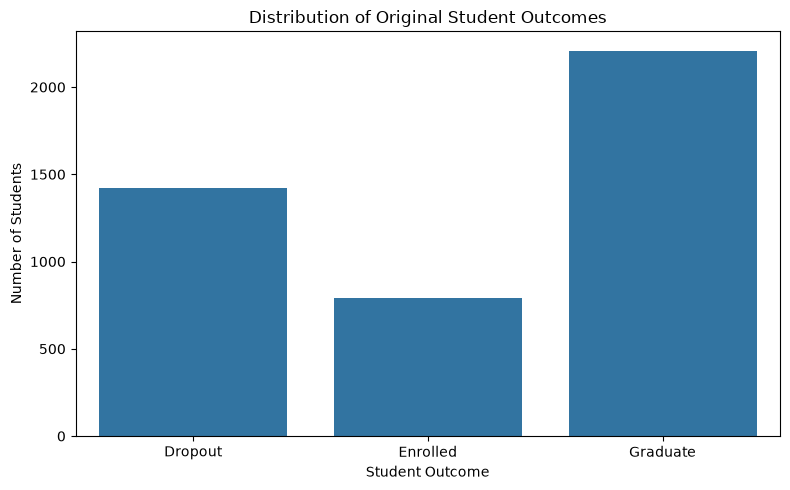

In [59]:


target_order = ["Dropout", "Enrolled", "Graduate"]

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Target",
    order=target_order
)

plt.title("Distribution of Original Student Outcomes")
plt.xlabel("Student Outcome")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

### Finding: Visual Distribution of Student Outcomes

The bar chart confirms the unequal frequency of the three original student outcomes.

Graduate forms the largest group, followed by Dropout, while Enrolled contains the fewest observations.

Although the classes are uneven, all three outcomes contain substantial numbers of student records and can therefore be meaningfully explored descriptively at this stage.

## Phase 6.2: Numerical Descriptive Statistics

In [60]:


eda_numerical_summary = (
    df[numerical_variables]
    .describe()
    .T
    .rename(columns={
        "count": "Count",
        "mean": "Mean",
        "std": "Std",
        "min": "Minimum",
        "25%": "Q1",
        "50%": "Median",
        "75%": "Q3",
        "max": "Maximum"
    })
    .round(2)
)

eda_numerical_summary

,Count,Mean,Std,Minimum,Q1,Median,Q3,Maximum
Application order,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
Previous qualification (grade),4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Admission grade,4424.0,126.98,14.48,95.00,117.90,126.10,134.80,190.00
Age at enrollment,4424.0,23.27,7.59,17.00,19.00,20.00,25.00,70.00
Curricular units 1st sem (credited),4424.0,0.71,2.36,0.00,0.00,0.00,0.00,20.00
Curricular units 1st sem (enrolled),4424.0,6.27,2.48,0.00,5.00,6.00,7.00,26.00
Curricular units 1st sem (evaluations),4424.0,8.30,4.18,0.00,6.00,8.00,10.00,45.00
Curricular units 1st sem (approved),4424.0,4.71,3.09,0.00,3.00,5.00,6.00,26.00
Curricular units 1st sem (grade),4424.0,10.64,4.84,0.00,11.00,12.29,13.40,18.88
Curricular units 1st sem (without evaluations),4424.0,0.14,0.69,0.00,0.00,0.00,0.00,12.00


Training-derived classification-threshold optimisation has been implemented for all nine locked primary model-stage combinations.

Out-of-fold dropout probabilities were generated using the same five stratified training folds used throughout model development.

Each training student's probability was produced by a model that did not train on that student, preventing in-sample predictions from being used for threshold selection.

However, the Phase 13 hyperparameters were selected using the same five-fold cross-validation evidence. The out-of-fold probabilities were therefore independent of each student's fold-specific model fitting, but not fully independent of hyperparameter selection. The held-out test set remained untouched, although this may make the training-stage threshold-selection evidence slightly optimistic.

The locked Phase 13 hyperparameters and primary class-weighted imbalance strategy were retained without modification.

Candidate thresholds from 0.05 to 0.95 were evaluated using Accuracy, Precision, Recall, F1-score and complete confusion-matrix counts.

F1-score was used as the predefined primary threshold-selection criterion, with Recall and then Precision used as secondary criteria where required.

The selected thresholds have been determined entirely from training-derived predictions and will be locked before final held-out evaluation.

The final test phase will report both conventional 0.50-threshold performance and performance using the locked training-derived thresholds so that the effect of threshold optimisation remains transparent.

The held-out test partition remains sealed.

### Finding: Numerical Predictor Distributions

The quantitative predictors operate across substantially different ranges and distributions.

The variables include student age, previous and admission grades, application preference, academic counts, semester grades and macroeconomic indicators.

Several academic count variables contain substantial concentrations at zero, consistent with the sparsity identified during the data-quality investigation.

The descriptive statistics reinforce the earlier preprocessing decision that quantitative variables cannot all be interpreted or processed identically merely because they are stored numerically.

## Phase 6.3: Age at Enrolment

In [61]:


age_by_target = (
    df.groupby("Target")["Age at enrollment"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .reindex(target_order)
    .round(2)
)

age_by_target

,count,mean,median,std,min,max
Target,,,,,,
Dropout,1421,26.07,23.0,8.70,18,70
Enrolled,794,22.37,20.0,6.30,17,54
Graduate,2209,21.78,19.0,6.69,17,62


### Finding: Age and Student Outcome

Age at enrolment differs across the original outcome categories.

Students in the Dropout group are older on average than students in either the Enrolled or Graduate groups. The median age of the Dropout group is also higher.

However, considerable overlap remains between the age distributions, meaning that age alone does not separate the three outcomes.

The pattern is descriptive and should not be interpreted as evidence that age causes dropout. 

Age is also classified as a non-actionable characteristic and will not be treated as an intervention target later in the study (Yu, Lee and Kizilcec, 2021).

c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


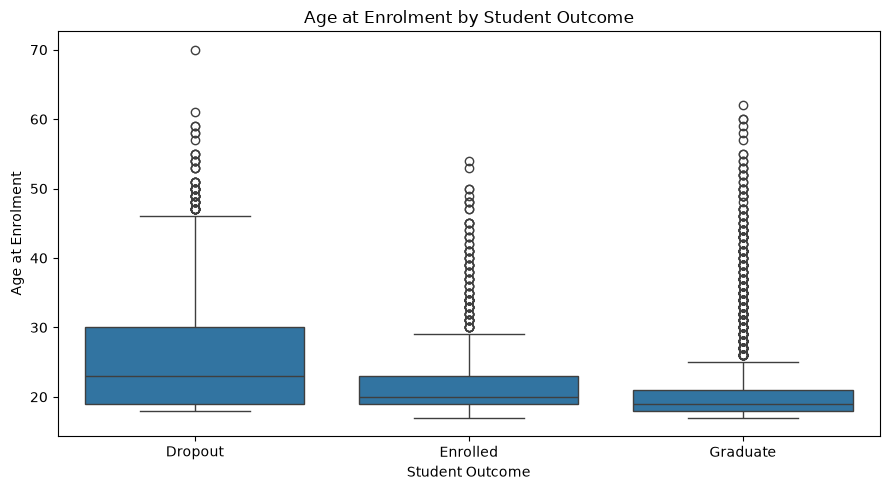

In [62]:


plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Target",
    y="Age at enrollment",
    order=target_order
)

plt.title("Age at Enrolment by Student Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("Age at Enrolment")
plt.tight_layout()
plt.show()

### Finding: Age Distribution by Outcome

The boxplots show that the Dropout group has a higher central age distribution than the Enrolled and Graduate groups.

The presence of overlapping ranges across all three categories confirms that the relationship is not deterministic.

Older observations visible in the distributions are retained because the earlier data-quality investigation found no evidence that they represent invalid student records.

## Phase 6.4: Binary Demographic and Socioeconomic Characteristics

In [63]:


binary_eda_features = [
    "Gender",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Daytime/evening attendance"
]

binary_outcome_tables = {}

for variable in binary_eda_features:

    table = pd.crosstab(
        df[variable],
        df["Target"],
        normalize="index"
    ).mul(100).round(2)

    table = table.reindex(
        columns=target_order
    )

    binary_outcome_tables[variable] = table

    print(f"\n{variable}")
    print("-" * len(variable))
    display(table)


Gender
------


Target,Dropout,Enrolled,Graduate
Gender,,,
0,25.10,16.98,57.91
1,45.05,19.73,35.22



Displaced
---------


Target,Dropout,Enrolled,Graduate
Displaced,,,
0,37.64,18.07,44.29
1,27.58,17.85,54.58



Educational special needs
-------------------------


...

Target,Dropout,Enrolled,Graduate
Tuition fees up to date,,,
0,86.55,7.95,5.49
1,24.74,19.30,55.95



Scholarship holder
------------------


Target,Dropout,Enrolled,Graduate
Scholarship holder,,,
0,38.71,19.97,41.32
1,12.19,11.83,75.98



Daytime/evening attendance
--------------------------


Target,Dropout,Enrolled,Graduate
Daytime/evening attendance,,,
0,42.86,15.53,41.61
1,30.80,18.24,50.95


### Finding: Binary Characteristics and Original Outcome

The outcome composition varies across several binary student characteristics.

The strongest descriptive differences are visible for financial and administrative indicators such as debtor status, tuition-fee status and scholarship status.

Other demographic characteristics also show differences between outcome groups, but these variables should be interpreted cautiously because descriptive association does not imply causation or actionability.

Educational special needs shows relatively little separation between outcomes and is based on a very small positive subgroup, reinforcing the need for caution when interpreting this feature.

## Phase 6.5: Financial and Administrative Indicators

In [64]:


financial_features = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder"
]

financial_eda_rows = []

for variable in financial_features:

    grouped = (
        df.groupby(variable)["Target"]
        .value_counts(normalize=True)
        .mul(100)
        .rename("Percentage")
        .reset_index()
    )

    grouped["Feature"] = variable

    financial_eda_rows.append(grouped)

financial_eda = pd.concat(
    financial_eda_rows,
    ignore_index=True
)

financial_eda.head(10)

,Debtor,Target,Percentage,Feature,Tuition fees up to date,Scholarship holder
0,0.0,Graduate,53.761795,Debtor,NaN,NaN
1,0.0,Dropout,28.283601,Debtor,NaN,NaN
2,0.0,Enrolled,17.954603,Debtor,NaN,NaN
3,1.0,Dropout,62.027833,Debtor,NaN,NaN
4,1.0,Graduate,20.079523,Debtor,NaN,NaN
5,1.0,Enrolled,17.892644,Debtor,NaN,NaN
6,NaN,Dropout,86.553030,Tuition fees up to date,0.0,NaN
7,NaN,Enrolled,7.954545,Tuition fees up to date,0.0,NaN
8,NaN,Graduate,5.492424,Tuition fees up to date,0.0,NaN
9,NaN,Graduate,55.954825,Tuition fees up to date,1.0,NaN


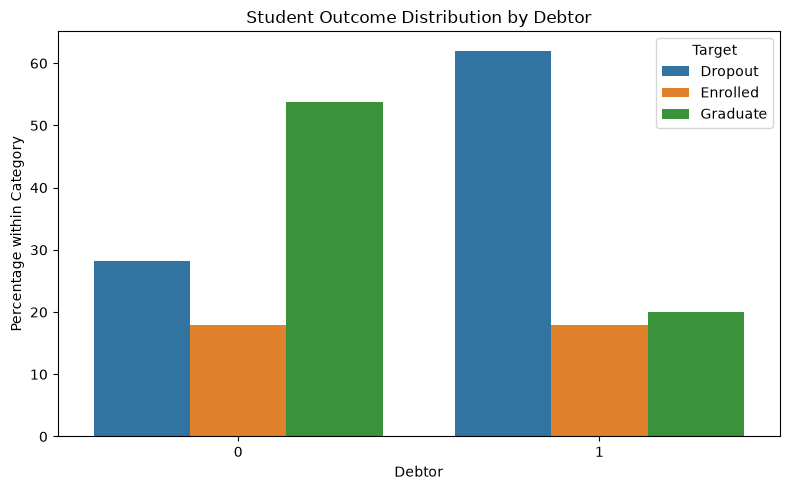

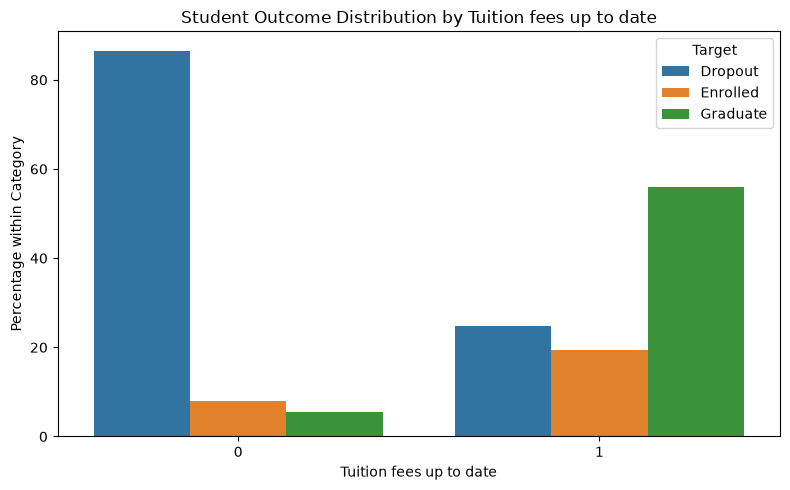

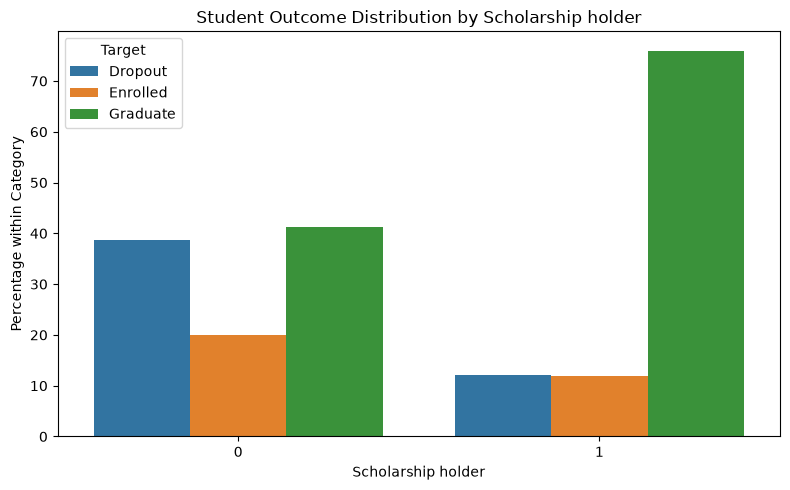

In [65]:


for variable in financial_features:

    plot_data = (
        df.groupby(variable)["Target"]
        .value_counts(normalize=True)
        .mul(100)
        .rename("Percentage")
        .reset_index()
    )

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=plot_data,
        x=variable,
        y="Percentage",
        hue="Target",
        hue_order=target_order
    )

    plt.title(
        f"Student Outcome Distribution by {variable}"
    )
    plt.ylabel("Percentage within Category")
    plt.tight_layout()
    plt.show()

### Finding: Financial Indicators and Student Outcome

Financial and administrative indicators show pronounced differences in the composition of student outcomes.

Students recorded as debtors have a substantially larger proportion of Dropout outcomes than non-debtors.

The strongest descriptive contrast is visible for tuition-fee status. Students whose tuition fees were not up to date contain a very high proportion of Dropout outcomes, whereas students whose fees were up to date are much more frequently represented in the Graduate category.

Scholarship holders also show a lower proportion of Dropout outcomes and a higher proportion of Graduate outcomes than non-scholarship holders.

These patterns demonstrate potentially useful predictive associations, but they do not establish that changing financial status would itself cause a student to persist or graduate.

## Phase 6.6: Prior Academic Performance

In [66]:


prior_academic_features = [
    "Previous qualification (grade)",
    "Admission grade"
]

prior_academic_summary = (
    df.groupby("Target")[prior_academic_features]
    .agg(["mean", "median", "std"])
    .reindex(target_order)
    .round(2)
)

prior_academic_summary

Previous qualification (grade)               Admission grade         \
                                   mean median    std            mean median   
Target                                                                         
Dropout                          131.11  133.1  12.87          124.96  123.6   
Enrolled                         131.21  130.0  12.87          125.53  124.1   
Graduate                         134.08  133.1  13.34          128.79  127.4   

                 
            std  
Target           
Dropout   15.13  
Enrolled  13.79  
Graduate  14.07

### Finding: Prior Academic Measures

Graduate students have somewhat higher average previous-qualification and admission grades than the Dropout and Enrolled groups.

However, the differences between the groups are relatively modest compared with some of the semester-level academic patterns examined later.

This suggests that pre-enrolment academic achievement may contain useful information while still leaving substantial overlap between eventual student outcomes.

c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


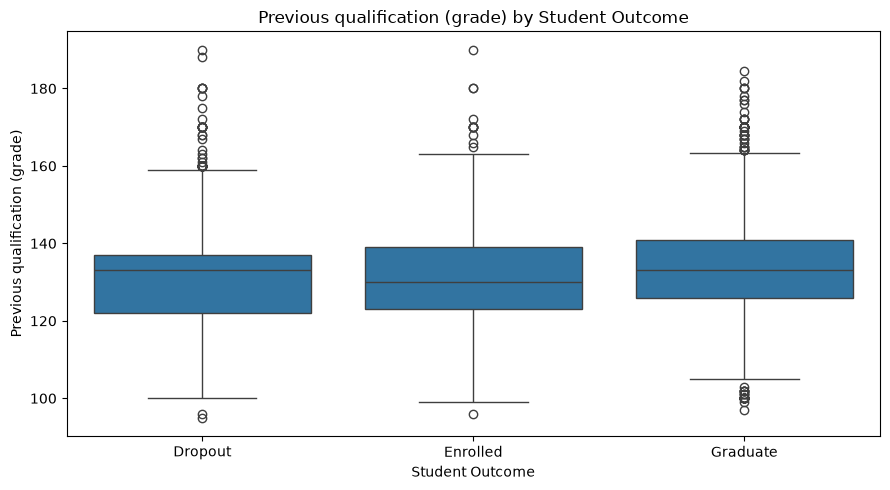

c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


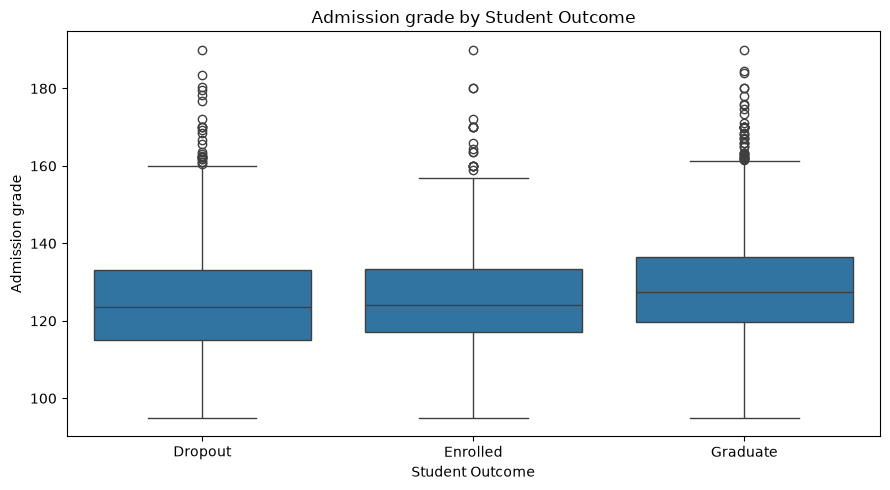

In [67]:


for variable in prior_academic_features:

    plt.figure(figsize=(9, 5))

    sns.boxplot(
        data=df,
        x="Target",
        y=variable,
        order=target_order
    )

    plt.title(
        f"{variable} by Student Outcome"
    )
    plt.xlabel("Student Outcome")
    plt.ylabel(variable)
    plt.tight_layout()
    plt.show()

### Finding: Distribution of Prior Academic Performance

The boxplots show substantial overlap in previous-qualification and admission grades across the three student outcomes.

Graduate students tend to have somewhat higher central values, but the distributions are not cleanly separated.

This indicates that pre-enrolment grades alone are unlikely to provide a complete distinction between students who later drop out, remain enrolled or graduate.

## Phase 6.7: First-semester Academic Performance

In [68]:


semester1_features = [
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)"
]

semester1_summary = (
    df.groupby("Target")[semester1_features]
    .mean()
    .reindex(target_order)
    .T
    .round(2)
)

semester1_summary

Target,Dropout,Enrolled,Graduate
Curricular units 1st sem (credited),0.61,0.51,0.85
Curricular units 1st sem (enrolled),5.82,5.96,6.67
Curricular units 1st sem (evaluations),7.75,9.34,8.28
Curricular units 1st sem (approved),2.55,4.32,6.23
Curricular units 1st sem (grade),7.26,11.13,12.64
Curricular units 1st sem (without evaluations),0.19,0.18,0.09


### Finding: First-semester Academic Performance
First-semester academic performance differs substantially across the original outcome groups, consistent with the rationale for staged prediction in educational contexts (Martins et al., 2021; Realinho et al., 2022).

The clearest descriptive separation occurs for approved curricular units and average semester grade.

Students in the Dropout group have considerably fewer approved first-semester units and lower average first-semester grades than students who remain Enrolled or eventually Graduate.

The Graduate group has the highest average number of approved units and the highest average semester grade.

These findings are consistent with the research motivation for examining whether prediction improves once first-semester academic information becomes available. However, whether these variables actually improve predictive performance remains a modelling question and is not concluded from EDA alone.

## Phase 6.8: Key First-semester Academic Distributions

c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


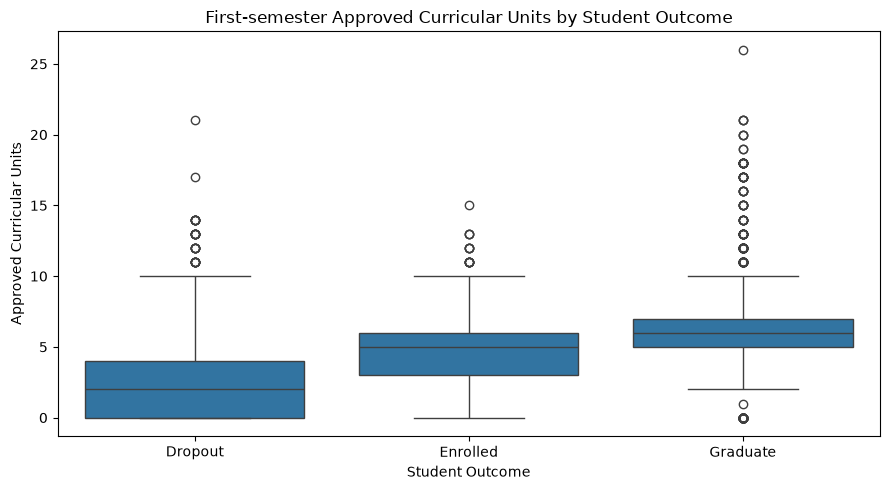

In [69]:

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 1st sem (approved)",
    order=target_order
)

plt.title(
    "First-semester Approved Curricular Units by Student Outcome"
)
plt.xlabel("Student Outcome")
plt.ylabel("Approved Curricular Units")
plt.tight_layout()
plt.show()

### Finding: First-semester Approved Units

The distribution of first-semester approved units differs visibly between the three outcomes.

Dropout students tend to have fewer approved curricular units, while Graduate students tend to have substantially more.

Enrolled students generally occupy an intermediate position.

The pattern suggests that academic progression during the first semester may contain stronger outcome-related information than some pre-enrolment characteristics.

c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


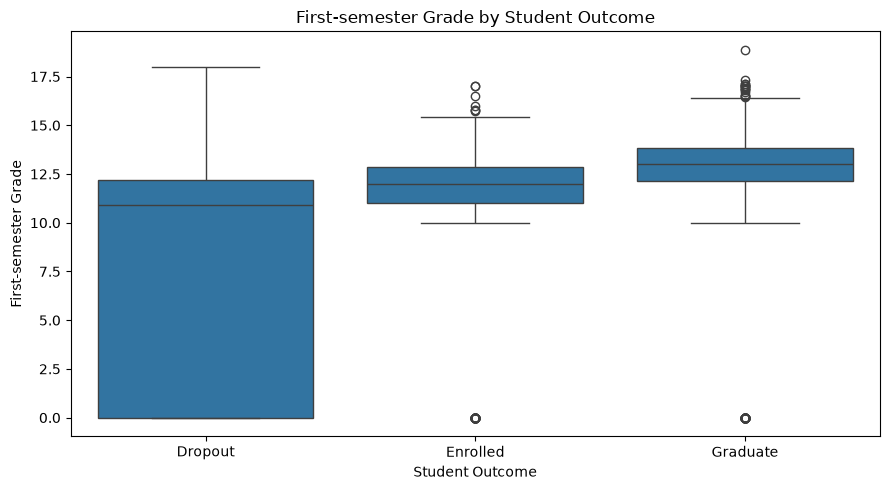

In [70]:


plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 1st sem (grade)",
    order=target_order
)

plt.title(
    "First-semester Grade by Student Outcome"
)
plt.xlabel("Student Outcome")
plt.ylabel("First-semester Grade")
plt.tight_layout()
plt.show()

### Finding: First-semester Grade

First-semester grade shows substantial descriptive separation between the Dropout group and the other two outcomes.

The Dropout group has a markedly lower central grade distribution, while Graduate students show the highest average performance.

The Enrolled group again falls between the Dropout and Graduate groups.

This descriptive pattern provides a clear reason to evaluate first-semester academic information in the Stage 2 predictive models, without presuming that the eventual models must improve.

## Phase 6.9: Second-semester Academic Performance

In [71]:
# Second-semester academic variables

semester2_features = [
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)"
]

semester2_summary = (
    df.groupby("Target")[semester2_features]
    .mean()
    .reindex(target_order)
    .T
    .round(2)
)

semester2_summary

Target,Dropout,Enrolled,Graduate
Curricular units 2nd sem (credited),0.45,0.36,0.67
Curricular units 2nd sem (enrolled),5.78,5.94,6.63
Curricular units 2nd sem (evaluations),7.17,9.44,8.14
Curricular units 2nd sem (approved),1.94,4.06,6.18
Curricular units 2nd sem (grade),5.90,11.12,12.70
Curricular units 2nd sem (without evaluations),0.24,0.19,0.08


### Finding: Second-semester Academic Performance

Second-semester academic performance shows clear descriptive differences between the original student outcome groups.

Dropout students have substantially fewer approved curricular units and lower average semester grades than both Enrolled and Graduate students.

Graduate students show the strongest average academic performance, while Enrolled students generally occupy an intermediate position.

The descriptive separation appears particularly pronounced for approved units and semester grade. 

This supports the rationale for evaluating later-stage academic information in the staged modelling design (Martins et al., 2021), but it does not establish that Stage 3 models will necessarily outperform earlier stages.

## Phase 6.10: Key Second-semester Academic Distributions

c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


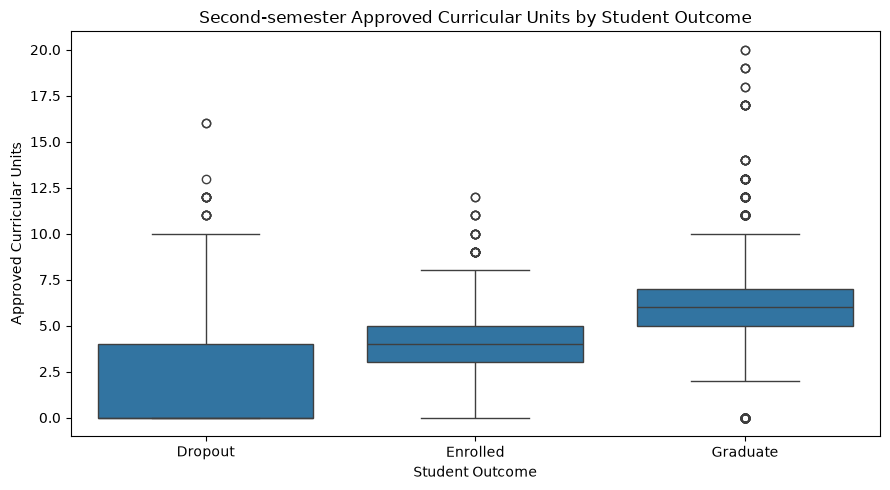

In [72]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 2nd sem (approved)",
    order=target_order
)

plt.title(
    "Second-semester Approved Curricular Units by Student Outcome"
)
plt.xlabel("Student Outcome")
plt.ylabel("Approved Curricular Units")
plt.tight_layout()
plt.show()

### Finding: Second-semester Approved Units

Second-semester approved units show substantial separation across the three outcome groups.

The Dropout group records the lowest number of approved units, Graduate students the highest, and Enrolled students generally fall between the two.

The pattern is descriptively stronger than many of the differences observed among pre-enrolment variables.

c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


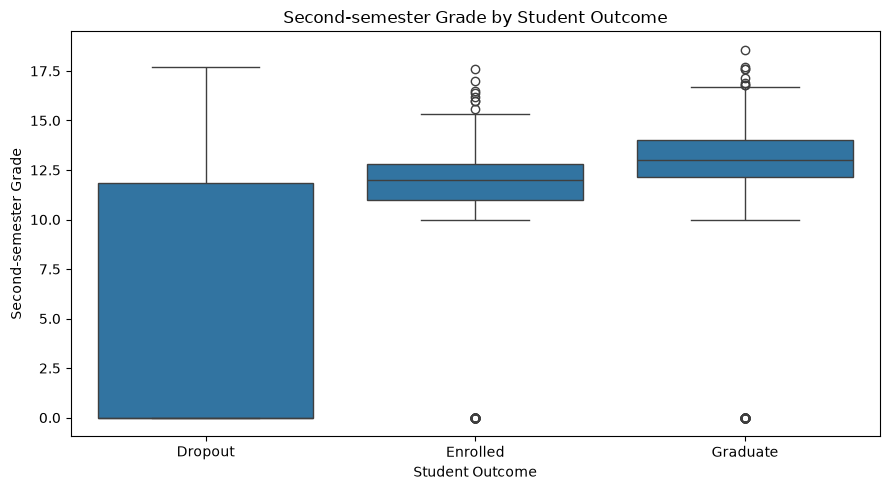

In [73]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 2nd sem (grade)",
    order=target_order
)

plt.title(
    "Second-semester Grade by Student Outcome"
)
plt.xlabel("Student Outcome")
plt.ylabel("Second-semester Grade")
plt.tight_layout()
plt.show()

### Finding: Second-semester Grade

The second-semester grade distribution shows a pronounced difference between Dropout students and the remaining outcome groups.

Dropout students have substantially lower semester grades, while Graduate students show the highest central performance.

This provides further descriptive evidence that later academic information contains strong outcome-related structure, which will later be tested formally through staged predictive modelling and SHAP analysis.

## Phase 6.11: Macroeconomic Variables

In [74]:
macroeconomic_features = [
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

macroeconomic_summary = (
    df.groupby("Target")[macroeconomic_features]
    .agg(["mean", "median"])
    .reindex(target_order)
    .round(3)
)

macroeconomic_summary

Unemployment rate        Inflation rate           GDP       
                      mean median           mean median   mean median
Target                                                               
Dropout             11.616   11.1          1.284    1.4 -0.151   0.32
Enrolled            11.273   11.1          1.212    1.4  0.053   0.32
Graduate            11.639   11.1          1.198    0.6  0.082   0.79

### Finding: Macroeconomic Variables and Student Outcome

The average unemployment, inflation and GDP values differ only modestly across the three original student outcomes compared with the stronger descriptive differences observed in semester-level academic performance.

This does not demonstrate that macroeconomic variables lack predictive value, because multivariable models may identify relationships that are not evident from simple group averages.

The variables are therefore retained as part of the Stage 1 predictor set.

## Phase 6.12: Correlation Structure of Quantitative Predictors

c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\seaborn\matrix.py:243: PendingDeprecationWarning: The set_bad function will be deprecated in a future version. Use cmap.with_extremes(bad=...) or Colormap(bad=...) instead.
  self.cmap.set_bad(bad)


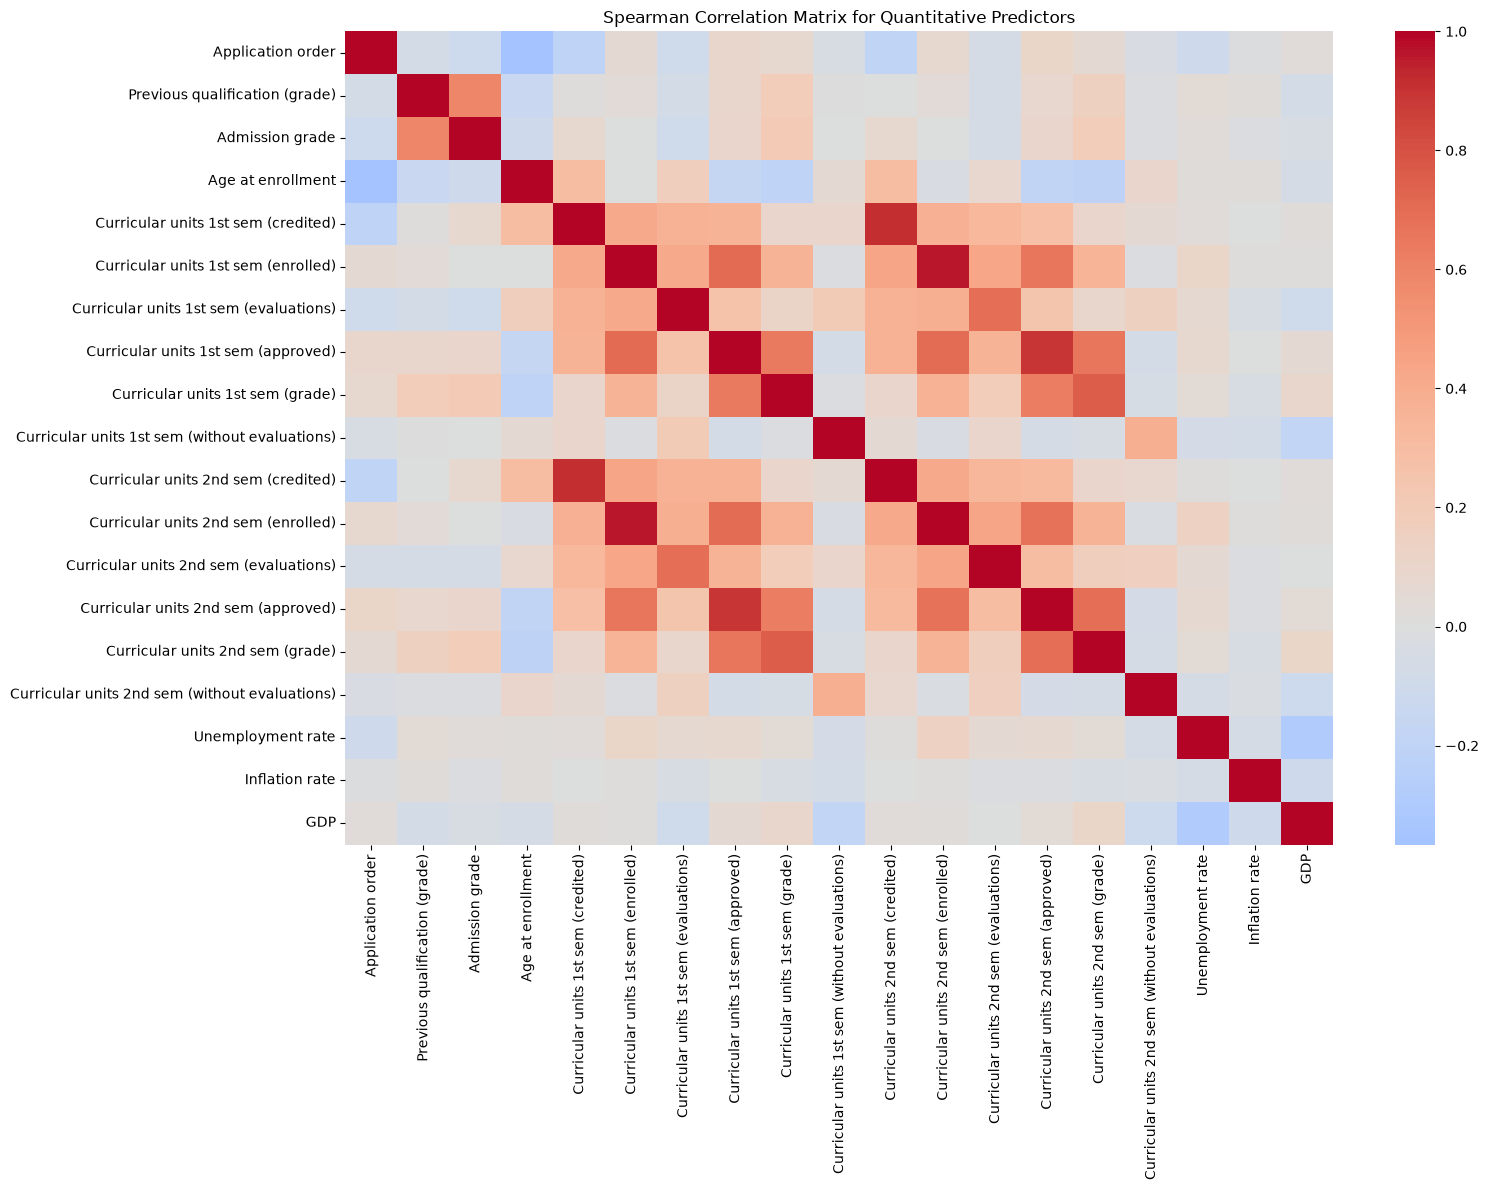

In [75]:


eda_correlation = df[numerical_variables].corr(
    method="spearman"
)

plt.figure(figsize=(16, 12))

sns.heatmap(
    eda_correlation,
    cmap="coolwarm",
    center=0,
    square=False
)

plt.title(
    "Spearman Correlation Matrix for Quantitative Predictors"
)
plt.tight_layout()
plt.show()

### Finding: Quantitative Predictor Correlations

The correlation matrix shows several strong relationships among semester-level academic variables.

In particular, enrolled, evaluated, approved and grade-related measures within and across semesters are related, which is conceptually plausible because they describe connected aspects of student academic progression.

These correlations do not automatically justify feature removal.

The semester variables represent distinct aspects of academic performance and, importantly, become available at different stages of the research design.

Their relative contribution will therefore be evaluated through model performance and SHAP rather than through pairwise correlation alone (Lundberg and Lee, 2017; Kohavi, 1995).

## Phase 6.13: Exploratory Finding Register

In [76]:
eda_findings = pd.DataFrame([
    {
        "Area": "Original target",
        "Finding": "Graduate is the largest original class; Enrolled is the smallest.",
        "Interpretation": "The original outcome is unevenly distributed."
    },
    {
        "Area": "Age",
        "Finding": "Dropout students are older on average.",
        "Interpretation": "Age shows descriptive association but substantial overlap remains."
    },
    {
        "Area": "Financial status",
        "Finding": "Debtor and tuition-fee status show large differences in outcome composition.",
        "Interpretation": "Financial/admin variables may contain useful predictive information."
    },
    {
        "Area": "Scholarship",
        "Finding": "Scholarship holders show a lower descriptive proportion of dropout.",
        "Interpretation": "Association is descriptive and not causal."
    },
    {
        "Area": "Prior academic performance",
        "Finding": "Graduate students show somewhat higher prior/admission grades.",
        "Interpretation": "Differences exist but outcome distributions overlap substantially."
    },
    {
        "Area": "Semester 1",
        "Finding": "Approved units and semester grade differ strongly across outcomes.",
        "Interpretation": "First-semester information may add outcome-related signal."
    },
    {
        "Area": "Semester 2",
        "Finding": "Approved units and grade show pronounced outcome differences.",
        "Interpretation": "Later academic information contains strong descriptive outcome structure."
    },
    {
        "Area": "Macroeconomic",
        "Finding": "Group-average differences are comparatively modest.",
        "Interpretation": "Predictive value cannot be determined from univariate averages alone."
    }
])

eda_findings

,Area,Finding,Interpretation
0,Original target,Graduate is the largest original class; Enroll...,The original outcome is unevenly distributed.
1,Age,Dropout students are older on average.,Age shows descriptive association but substant...
2,Financial status,Debtor and tuition-fee status show large diffe...,Financial/admin variables may contain useful p...
3,Scholarship,Scholarship holders show a lower descriptive p...,Association is descriptive and not causal.
4,Prior academic performance,Graduate students show somewhat higher prior/a...,Differences exist but outcome distributions ov...
5,Semester 1,Approved units and semester grade differ stron...,First-semester information may add outcome-rel...
6,Semester 2,Approved units and grade show pronounced outco...,Later academic information contains strong des...
7,Macroeconomic,Group-average differences are comparatively mo...,Predictive value cannot be determined from uni...


### Finding: EDA Evidence Register

The EDA evidence register summarises the principal descriptive patterns identified before binary target construction and predictive modelling.

The register is intentionally descriptive. No entry is treated as proof of predictive importance, causal influence or hypothesis support.

These findings provide context for interpreting the later model results and help distinguish patterns that were visible in the raw data from relationships identified only after multivariable modelling.

## Phase 6.14: Preserve EDA Outputs

In [77]:
# Save key EDA summaries for reproducibility

target_eda.to_csv(
    TABLES_DIR / "phase6_original_target_distribution.csv",
    index=False
)

age_by_target.to_csv(
    TABLES_DIR / "phase6_age_by_original_target.csv"
)

semester1_summary.to_csv(
    TABLES_DIR / "phase6_semester1_by_original_target.csv"
)

semester2_summary.to_csv(
    TABLES_DIR / "phase6_semester2_by_original_target.csv"
)

eda_findings.to_csv(
    TABLES_DIR / "phase6_eda_finding_register.csv",
    index=False
)

print("Phase 6 EDA tables saved successfully.")

Phase 6 EDA tables saved successfully.


### Finding: EDA Outputs Preserved

The principal EDA summary tables were exported to the project tables directory.

Preserving these outputs provides a reproducible record of the descriptive evidence observed before target recoding and model fitting.

The saved outputs can later support the Findings and Interpretation chapter without requiring manual reconstruction of descriptive results.

## Phase 6.15: Overall Phase 6 Summary

Exploratory analysis of the original three-class outcome identified several meaningful descriptive patterns.

The Graduate group is the largest original outcome category, followed by Dropout and Enrolled.

Demographically, students in the Dropout group are older on average, although the age distributions overlap substantially.

Financial and administrative indicators show stronger outcome differences. Debtor status, tuition-fee status and scholarship status are associated with noticeably different proportions of Dropout, Enrolled and Graduate outcomes.

Prior academic grades show some separation between outcomes, but considerable overlap remains.

The strongest descriptive differences occur in semester-level academic performance. Students in the Dropout group have substantially fewer approved curricular units and lower semester grades, while Graduate students generally show the strongest academic performance. Enrolled students frequently occupy an intermediate position.

Second-semester academic measures show particularly pronounced descriptive separation between outcomes.

Macroeconomic variables display comparatively modest differences in simple group averages.

These findings remain exploratory. They do not establish causality, predictive importance or support for the research hypotheses. Formal conclusions about model performance, temporal improvement and feature importance will be based on the later held-out evaluation and SHAP analyses.

The original three-class `Target` remains unchanged at the end of this phase.

### Code Attribution — Phase 6

pandas development team, 2026. *pandas.DataFrame.groupby* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.crosstab* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame.describe* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame.corr* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html> [Accessed 14 September 2026].

Matplotlib developers, 2025. *matplotlib.pyplot* [Source code/documentation]. Available at: <https://matplotlib.org/stable/api/pyplot_summary.html> [Accessed 14 September 2026].

Waskom, M.L., 2021. seaborn: statistical data visualization. *Journal of Open Source Software*, [e-journal] 6(60), article 3021. Available at: <https://doi.org/10.21105/joss.03021> [Accessed 14 September 2026].

seaborn developers, 2025. *seaborn.countplot* [Source code/documentation]. Available at: <https://seaborn.pydata.org/generated/seaborn.countplot.html> [Accessed 14 September 2026].

seaborn developers, 2025. *seaborn.boxplot* [Source code/documentation]. Available at: <https://seaborn.pydata.org/generated/seaborn.boxplot.html> [Accessed 14 September 2026].

seaborn developers, 2025. *seaborn.barplot* [Source code/documentation]. Available at: <https://seaborn.pydata.org/generated/seaborn.barplot.html> [Accessed 14 September 2026].

seaborn developers, 2025. *seaborn.heatmap* [Source code/documentation]. Available at: <https://seaborn.pydata.org/generated/seaborn.heatmap.html> [Accessed 14 September 2026].

# Phase 7: Binary Target Operationalisation

The exploratory analysis examined the original three-class student outcome before any recoding was performed.

The approved research design requires a binary early-warning outcome that distinguishes students recorded as Dropout from students not recorded as Dropout, following the operationalisation described in the source dataset documentation (Realinho et al., 2022).

The binary target is therefore operationalised as:

- Dropout = 1
- Graduate = 0
- Enrolled = 0

The positive class is intentionally defined as Dropout because the purpose of the study is to identify students at elevated risk of dropout.

The original `Target` variable is preserved so that the source outcome remains available for traceability and descriptive analysis.

## Phase 7.1: Document the Target Mapping

In [78]:


target_mapping = pd.DataFrame({
    "Original_Target": [
        "Dropout",
        "Graduate",
        "Enrolled"
    ],
    "Binary_Value": [
        1,
        0,
        0
    ],
    "Binary_Label": [
        "Dropout",
        "Non-dropout",
        "Non-dropout"
    ]
})

target_mapping

,Original_Target,Binary_Value,Binary_Label
0,Dropout,1,Dropout
1,Graduate,0,Non-dropout
2,Enrolled,0,Non-dropout


### Finding: Binary Target Definition

The three original student outcomes are mapped into two analytical classes.

`Dropout` forms the positive class, coded as 1.

`Graduate` and `Enrolled` form the non-dropout class, coded as 0.

This transformation reflects the early-warning purpose of the study rather than a claim that Graduate and Enrolled represent identical educational outcomes.

## Phase 7.2: Construct the Binary Dropout Target

In [79]:


df["Dropout_binary"] = (
    df["Target"] == "Dropout"
).astype(int)

print("Binary target created successfully.")

print("\nOriginal Target still present:")
print("Target" in df.columns)

print("\nBinary target present:")
print("Dropout_binary" in df.columns)

print("\nUnique binary values:")
print(sorted(df["Dropout_binary"].unique()))

Binary target created successfully.

Original Target still present:
True

Binary target present:
True

Unique binary values:
[np.int64(0), np.int64(1)]


### Finding: Binary Target Construction

The binary dropout target was created successfully while preserving the original three-class `Target` variable.

The new `Dropout_binary` variable contains only the expected values 0 and 1.

No predictor values or student records were altered during the transformation.

## Phase 7.3: Verify the Binary Mapping Record by Record

In [80]:


mapping_verification = pd.crosstab(
    df["Target"],
    df["Dropout_binary"]
)

mapping_verification

Dropout_binary,0,1
Target,,
Dropout,0,1421
Enrolled,794,0
Graduate,2209,0


In [81]:


dropout_correct = (
    df.loc[
        df["Target"] == "Dropout",
        "Dropout_binary"
    ] == 1
).all()

graduate_correct = (
    df.loc[
        df["Target"] == "Graduate",
        "Dropout_binary"
    ] == 0
).all()

enrolled_correct = (
    df.loc[
        df["Target"] == "Enrolled",
        "Dropout_binary"
    ] == 0
).all()

print("All Dropout records coded 1:", dropout_correct)
print("All Graduate records coded 0:", graduate_correct)
print("All Enrolled records coded 0:", enrolled_correct)

print(
    "\nBinary mapping completely valid:",
    dropout_correct
    and graduate_correct
    and enrolled_correct
)

All Dropout records coded 1: True
All Graduate records coded 0: True
All Enrolled records coded 0: True

Binary mapping completely valid: True


### Finding: Binary Target Verification

Record-level verification confirms that the binary transformation was applied consistently.

All students originally labelled Dropout are coded as 1, while all Graduate and Enrolled records are coded as 0.

The verification returned `True` for all three source categories, providing evidence that no observations were incorrectly mapped during target construction.

## Phase 7.4: Binary Target Distribution

In [82]:


binary_target_summary = (
    df["Dropout_binary"]
    .value_counts()
    .sort_index()
    .rename_axis("Binary_Value")
    .reset_index(name="Count")
)

binary_target_summary["Class"] = (
    binary_target_summary["Binary_Value"]
    .map({
        0: "Non-dropout",
        1: "Dropout"
    })
)

binary_target_summary["Percentage"] = (
    binary_target_summary["Count"]
    / len(df)
    * 100
).round(2)

binary_target_summary[
    [
        "Binary_Value",
        "Class",
        "Count",
        "Percentage"
    ]
]

,Binary_Value,Class,Count,Percentage
0,0,Non-dropout,3003,67.88
1,1,Dropout,1421,32.12


### Finding: Binary Outcome Distribution

The binary target contains:

- 3,003 non-dropout records (67.88%).
- 1,421 dropout records (32.12%).

The positive Dropout class therefore represents approximately one-third of the dataset.

The binary outcome is unevenly distributed, with approximately twice as many non-dropout observations as dropout observations.

However, both classes contain substantial numbers of student records.

## Phase 7.5: Quantify the Class Imbalance

In [83]:


n_dropout = (
    df["Dropout_binary"] == 1
).sum()

n_non_dropout = (
    df["Dropout_binary"] == 0
).sum()

majority_to_minority_ratio = (
    n_non_dropout / n_dropout
)

print(f"Dropout records: {n_dropout:,}")
print(f"Non-dropout records: {n_non_dropout:,}")

print(
    "\nNon-dropout : Dropout ratio = "
    f"{majority_to_minority_ratio:.2f} : 1"
)

Dropout records: 1,421
Non-dropout records: 3,003

Non-dropout : Dropout ratio = 2.11 : 1


### Finding: Degree of Class Imbalance

The binary outcome has a non-dropout-to-dropout ratio of approximately 2.11:1.

This confirms the presence of class imbalance, although the minority Dropout class remains substantial at 1,421 observations.

The imbalance is relevant because overall accuracy alone could conceal weaker performance on the Dropout class.

Evaluation will therefore include precision, recall, F1-score, ROC-AUC and confusion-matrix results rather than relying only on accuracy (He and Garcia, 2009).

## Phase 7.6: Visualise the Binary Target Distribution

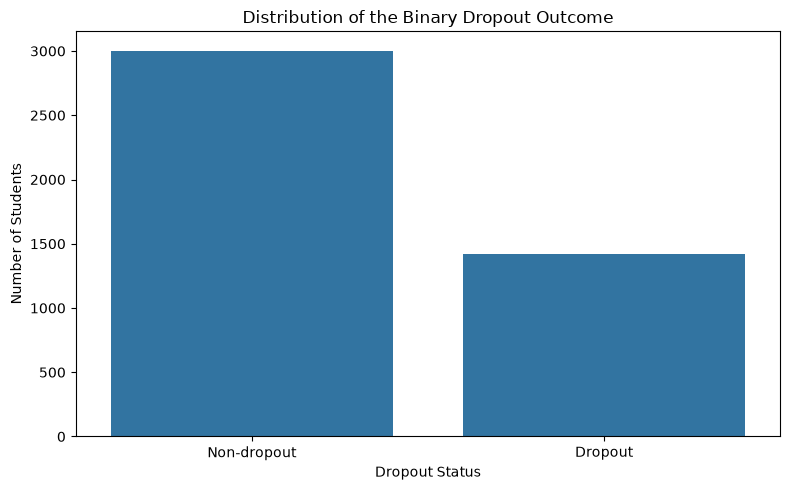

In [84]:


binary_plot_df = df.copy()

binary_plot_df["Dropout_Status"] = (
    binary_plot_df["Dropout_binary"]
    .map({
        0: "Non-dropout",
        1: "Dropout"
    })
)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=binary_plot_df,
    x="Dropout_Status",
    order=["Non-dropout", "Dropout"]
)

plt.title("Distribution of the Binary Dropout Outcome")
plt.xlabel("Dropout Status")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

### Finding: Visual Binary Class Distribution

The visualisation confirms that the non-dropout class is larger than the Dropout class.

The difference is meaningful enough to require imbalance-aware evaluation but does not represent an extremely small positive class.

The imbalance will therefore be handled through the pre-specified modelling strategy rather than by removing majority-class observations.

## Phase 7.7: Decision Record for Class Imbalance

### Decision Record: Primary Class-imbalance Strategy

#### Observation

The binary target contains 3,003 non-dropout records and 1,421 dropout records, producing an approximate class ratio of 2.11:1.

#### Options considered

- Ignore the class imbalance.
- Randomly undersample the majority class.
- Apply ordinary SMOTE to the complete dataset.
- Use class weighting as the primary imbalance strategy.
- Evaluate SMOTENC separately as a training-only sensitivity analysis.

#### Decision

Class weighting will remain the primary imbalance-handling strategy.

Logistic Regression and Random Forest will use balanced class weights.

Gradient Boosting will receive equivalent training-sample weights because the selected implementation does not provide the same direct `class_weight` parameter.

SMOTENC will later be evaluated separately as a sensitivity analysis using training data only.

#### Justification

Class weighting retains all observed student records and avoids generating synthetic observations in the primary analysis.

The approach was specified before model performance was examined and therefore will not be selected according to which method produces preferred hypothesis results.

The held-out test data will never be resampled (He and Garcia, 2009; Lemaître, Nogueira and Aridas, 2017).

## Phase 7.8: Implication of Combining Graduate and Enrolled

In [85]:


non_dropout_composition = (
    df.loc[
        df["Dropout_binary"] == 0,
        "Target"
    ]
    .value_counts()
    .rename_axis("Original_Target")
    .reset_index(name="Count")
)

non_dropout_composition["Percentage_of_Non_Dropout"] = (
    non_dropout_composition["Count"]
    / non_dropout_composition["Count"].sum()
    * 100
).round(2)

non_dropout_composition

,Original_Target,Count,Percentage_of_Non_Dropout
0,Graduate,2209,73.56
1,Enrolled,794,26.44


### Finding: Composition of the Non-dropout Class

The binary non-dropout class combines two different original outcomes.

Most non-dropout observations are Graduate records, while approximately one-quarter represent students who were still Enrolled at the time the source outcome was recorded.

The binary target therefore answers a specific question:

> Is the student recorded as Dropout versus not recorded as Dropout?

It does not distinguish successful graduation from continued enrolment.

## Phase 7.9: Decision Record for Binary Outcome Operationalisation

### Decision Record: Graduate and Enrolled as the Non-dropout Class

#### Observation

The original dataset distinguishes Dropout, Enrolled and Graduate outcomes.

The approved research question focuses specifically on early prediction of dropout risk.

#### Options considered

- Retain the original three-class outcome and conduct multiclass classification.
- Exclude Enrolled students.
- Define Dropout as the positive class and combine Graduate and Enrolled as non-dropout.

#### Decision

The primary outcome will remain binary:

- Dropout = 1
- Graduate or Enrolled = 0

#### Justification

The binary definition directly operationalises the approved study objective of identifying students at risk of dropout.

Removing Enrolled students would discard 794 legitimate observations and change the population represented by the approved dataset.

A multiclass analysis would address a different research question from the one specified in the approved research design.

However, the approach has an important limitation: students labelled Enrolled may later graduate or drop out. The non-dropout class should therefore be interpreted as students not recorded as dropout at the point represented by the source dataset rather than as a guaranteed successful outcome (Realinho et al., 2022).

## Phase 7.10: Confirm the Binary Target Is Not a Predictor

In [86]:


target_variables = {
    "Target",
    "Dropout_binary"
}

unexpected_targets_in_model_features = (
    target_variables
    .intersection(
        set(model_candidate_predictors)
    )
)

print(
    "Outcome variables present in predictor list:",
    unexpected_targets_in_model_features
)

print(
    "Target leakage check passed:",
    len(unexpected_targets_in_model_features) == 0
)

Outcome variables present in predictor list: set()
Target leakage check passed: True


### Finding: Target Leakage Safeguard

Neither the original `Target` variable nor the newly constructed `Dropout_binary` variable is included in the modelling predictor list.

This confirms that outcome information cannot accidentally enter the predictor matrix as an input feature.

The binary variable will be used only as the supervised learning target.

## Phase 7.11: Preserve the Target-operationalisation Outputs

In [87]:


target_mapping.to_csv(
    TABLES_DIR / "phase7_target_mapping.csv",
    index=False
)

binary_target_summary.to_csv(
    TABLES_DIR / "phase7_binary_target_distribution.csv",
    index=False
)

non_dropout_composition.to_csv(
    TABLES_DIR / "phase7_non_dropout_composition.csv",
    index=False
)

print("Phase 7 target tables saved successfully.")

Phase 7 target tables saved successfully.


### Finding: Target Documentation Preserved

The target mapping, binary class distribution and composition of the non-dropout class were exported to the project tables directory.

These outputs preserve the evidence used to operationalise the supervised learning outcome and document the class imbalance before model fitting.

## Phase 7.12: Overall Phase 7 Summary

The original three-class student outcome has now been operationalised as the binary target required for the dropout-prediction study.

`Dropout` is coded as the positive class (1), while `Graduate` and `Enrolled` form the non-dropout class (0).

The original `Target` variable remains unchanged.

Record-level validation confirmed that all 4,424 observations were mapped correctly.

The resulting binary distribution contains 1,421 Dropout records (32.12%) and 3,003 non-dropout records (67.88%), corresponding to an approximate majority-to-minority ratio of 2.11:1.

The class distribution confirms the relevance of the pre-specified imbalance strategy. Class weighting will remain the primary approach, while SMOTENC will later be evaluated only as a training-data sensitivity analysis.

The non-dropout class contains both Graduate and Enrolled students. This is appropriate for the approved binary dropout-risk question but introduces an important limitation because students recorded as Enrolled may experience a different eventual outcome.

Neither the original nor binary target is included in the predictor lists, confirming that no direct target leakage has been introduced.

No train/test split, fitted preprocessing transformation or predictive model has yet been created.

### Code Attribution — Phase 7

pandas development team, 2026. *pandas.DataFrame.value_counts* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.crosstab* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.Series.map* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html> [Accessed 14 September 2026].

Matplotlib developers, 2025. *matplotlib.pyplot* [Source code/documentation]. Available at: <https://matplotlib.org/stable/api/pyplot_summary.html> [Accessed 14 September 2026].

seaborn developers, 2025. *seaborn.countplot* [Source code/documentation]. Available at: <https://seaborn.pydata.org/generated/seaborn.countplot.html> [Accessed 14 September 2026].

# Phase 8: Binary Target-focused Exploratory Data Analysis

The original three-class student outcome has now been explored and subsequently operationalised as the binary dropout-risk target required by the research design.

This phase examines descriptive relationships between the predictors and the binary outcome:

- Dropout = 1
- Non-dropout = 0

The purpose is to understand how observed student characteristics differ between the two analytical classes before staged predictive modelling begins.

The analysis remains exploratory. Predictor inclusion, preprocessing decisions and research-hypothesis conclusions will not be determined from these descriptive associations alone.

## Phase 8.1: Binary EDA Analysis Safeguard

In [88]:


assert "Dropout_binary" in df.columns, (
    "Dropout_binary has not been created."
)

assert set(df["Dropout_binary"].unique()) == {0, 1}, (
    "Unexpected values detected in Dropout_binary."
)

print("Binary target verified for Phase 8.")
print("Student records:", len(df))
print(
    "Dropout records:",
    (df["Dropout_binary"] == 1).sum()
)
print(
    "Non-dropout records:",
    (df["Dropout_binary"] == 0).sum()
)

Binary target verified for Phase 8.
Student records: 4424
Dropout records: 1421
Non-dropout records: 3003


### Finding: Binary EDA Starting Point

The binary target passed the required validity checks and contains only the values 0 and 1.

All 4,424 student records remain available for exploratory analysis.

No modelling, resampling, scaling or feature encoding has been performed at this stage.

## Phase 8.2: Age at Enrolment and Binary Dropout Status

In [89]:


age_binary_summary = (
    df.groupby("Dropout_binary")["Age at enrollment"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .rename(index={
        0: "Non-dropout",
        1: "Dropout"
    })
    .round(2)
)

age_binary_summary

,count,mean,median,std,min,max
Dropout_binary,,,,,,
Non-dropout,3003,21.94,19.0,6.6,17,62
Dropout,1421,26.07,23.0,8.7,18,70


c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


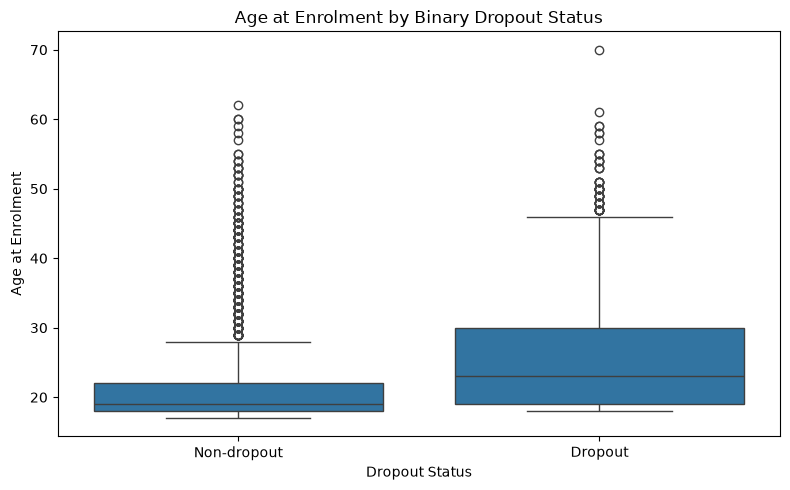

In [90]:
binary_age_plot = df.assign(
    Dropout_Status=df["Dropout_binary"].map({
        0: "Non-dropout",
        1: "Dropout"
    })
)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=binary_age_plot,
    x="Dropout_Status",
    y="Age at enrollment",
    order=["Non-dropout", "Dropout"]
)

plt.title("Age at Enrolment by Binary Dropout Status")
plt.xlabel("Dropout Status")
plt.ylabel("Age at Enrolment")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "phase8_age_by_dropout_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding: Age and Binary Dropout Status

Students in the Dropout class are older on average than students in the Non-dropout class.

However, the age distributions overlap substantially, demonstrating that age does not independently distinguish all students who drop out from those who do not.

Age therefore shows a descriptive association with dropout status but should not be interpreted as a causal factor or intervention target.

The variable remains classified as non-actionable in the ethical framework and will not be treated as an intervention target (Yu, Lee and Kizilcec, 2021).

## Phase 8.3: Financial and Administrative Indicators

In [91]:


def dropout_rate_table(data, variable):
    summary = (
        data.groupby(variable)["Dropout_binary"]
        .agg(
            Student_Count="size",
            Dropout_Count="sum",
            Dropout_Rate="mean"
        )
        .reset_index()
    )

    summary["Dropout_Rate_Percentage"] = (
        summary["Dropout_Rate"] * 100
    ).round(2)

    return summary.drop(
        columns="Dropout_Rate"
    )

In [92]:
financial_features = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder"
]

financial_dropout_tables = {}

for variable in financial_features:

    table = dropout_rate_table(
        df,
        variable
    )

    financial_dropout_tables[variable] = table

    print(f"\n{variable}")
    print("-" * len(variable))
    display(table)


Debtor
------


,Debtor,Student_Count,Dropout_Count,Dropout_Rate_Percentage
0,0,3921,1109,28.28
1,1,503,312,62.03



Tuition fees up to date
-----------------------


,Tuition fees up to date,Student_Count,Dropout_Count,Dropout_Rate_Percentage
0,0,528,457,86.55
1,1,3896,964,24.74



Scholarship holder
------------------


,Scholarship holder,Student_Count,Dropout_Count,Dropout_Rate_Percentage
0,0,3325,1287,38.71
1,1,1099,134,12.19


### Finding: Financial Indicators and Dropout Rate

The binary analysis confirms pronounced differences in dropout rates across the financial and administrative indicators.

Students recorded as debtors have a substantially higher dropout rate than non-debtors.

Tuition-fee status shows an especially strong descriptive contrast, with students whose tuition fees are not up to date having a much larger observed dropout proportion.

Scholarship holders have a lower observed dropout rate than students without scholarships.

These relationships may provide useful predictive information but remain associations. Financial status should not be interpreted as a demonstrated cause of dropout.

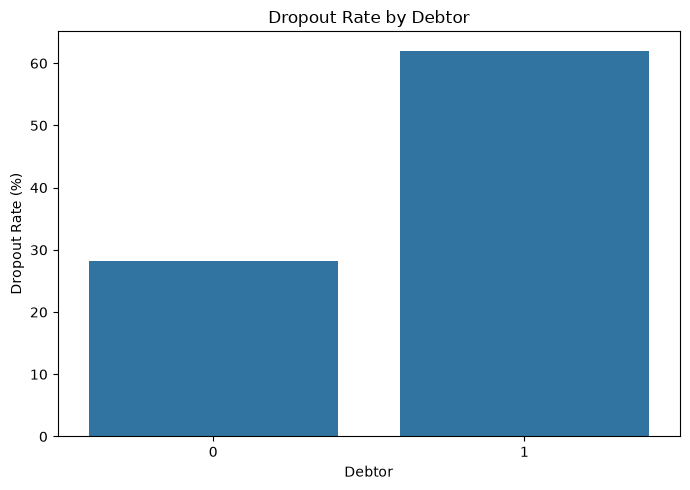

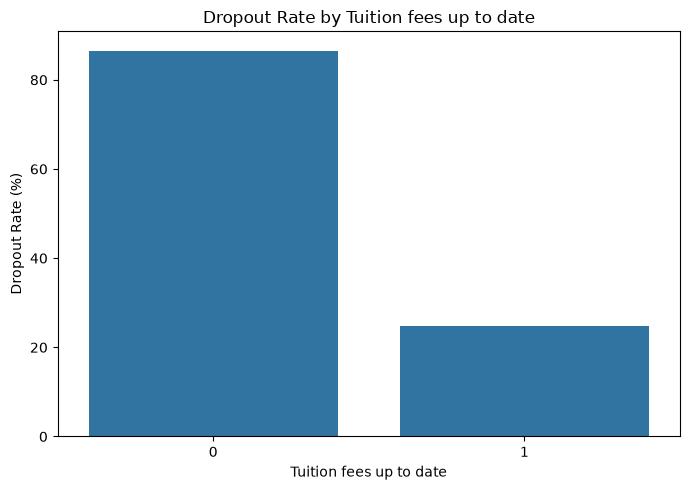

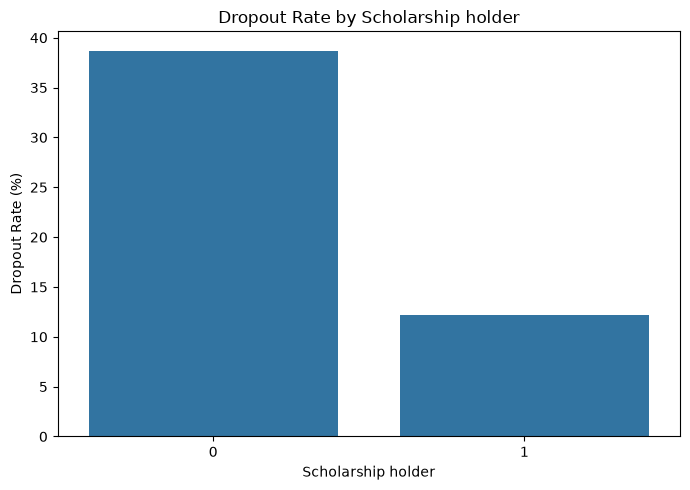

In [93]:
for variable in financial_features:

    plot_data = dropout_rate_table(
        df,
        variable
    )

    plt.figure(figsize=(7, 5))

    sns.barplot(
        data=plot_data,
        x=variable,
        y="Dropout_Rate_Percentage"
    )

    plt.title(
        f"Dropout Rate by {variable}"
    )
    plt.xlabel(variable)
    plt.ylabel("Dropout Rate (%)")
    plt.tight_layout()

    safe_name = (
        variable.lower()
        .replace(" ", "_")
        .replace("/", "_")
    )

    plt.savefig(
        FIGURES_DIR
        / f"phase8_dropout_rate_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Phase 8.4: Demographic and Student-background Indicators

In [94]:
demographic_binary_features = [
    "Gender",
    "Displaced",
    "Educational special needs",
    "Daytime/evening attendance"
]

demographic_dropout_rows = []

for variable in demographic_binary_features:

    table = dropout_rate_table(
        df,
        variable
    )

    table.insert(
        0,
        "Feature",
        variable
    )

    demographic_dropout_rows.append(
        table
    )

demographic_dropout_summary = pd.concat(
    demographic_dropout_rows,
    ignore_index=True
)

demographic_dropout_summary

,Feature,Gender,Student_Count,Dropout_Count,Dropout_Rate_Percentage,Displaced,Educational special needs,Daytime/evening attendance
0,Gender,0.0,2868,720,25.10,NaN,NaN,NaN
1,Gender,1.0,1556,701,45.05,NaN,NaN,NaN
2,Displaced,NaN,1998,752,37.64,0.0,NaN,NaN
3,Displaced,NaN,2426,669,27.58,1.0,NaN,NaN
4,Educational special needs,NaN,4373,1404,32.11,NaN,0.0,NaN
5,Educational special needs,NaN,51,17,33.33,NaN,1.0,NaN
6,Daytime/evening attendance,NaN,483,207,42.86,NaN,NaN,0.0
7,Daytime/evening attendance,NaN,3941,1214,30.80,NaN,NaN,1.0


### Finding: Demographic and Background Characteristics

Dropout rates vary across several demographic and student-background categories.

However, the size of these differences is not uniform across predictors.

Educational special needs requires particular caution because its positive category contains relatively few students. Dropout rates calculated from small subgroups are subject to greater uncertainty and should not be interpreted with the same confidence as patterns observed across larger groups (He and Garcia, 2009).

These demographic variables remain descriptive or fairness-relevant characteristics rather than direct intervention targets.

## Phase 8.5: Prior Academic Performance and Dropout Status

In [95]:
prior_academic_features = [
    "Previous qualification (grade)",
    "Admission grade"
]

prior_binary_summary = (
    df.groupby("Dropout_binary")[
        prior_academic_features
    ]
    .agg([
        "mean",
        "median",
        "std"
    ])
    .rename(index={
        0: "Non-dropout",
        1: "Dropout"
    })
    .round(2)
)

prior_binary_summary

Previous qualification (grade)               Admission grade  \
                                         mean median    std            mean   
Dropout_binary                                                                
Non-dropout                            133.32  133.1  13.28          127.93   
Dropout                                131.11  133.1  12.87          124.96   

                              
               median    std  
Dropout_binary                
Non-dropout     126.7  14.07  
Dropout         123.6  15.13

### Finding: Prior Academic Performance

Non-dropout students show somewhat stronger prior academic performance on average than students in the Dropout group.

Differences are visible in previous-qualification grade and admission grade, although the distributions overlap substantially.

This suggests that pre-enrolment academic information contains some descriptive relationship with dropout status but does not provide complete separation between the two classes.

c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


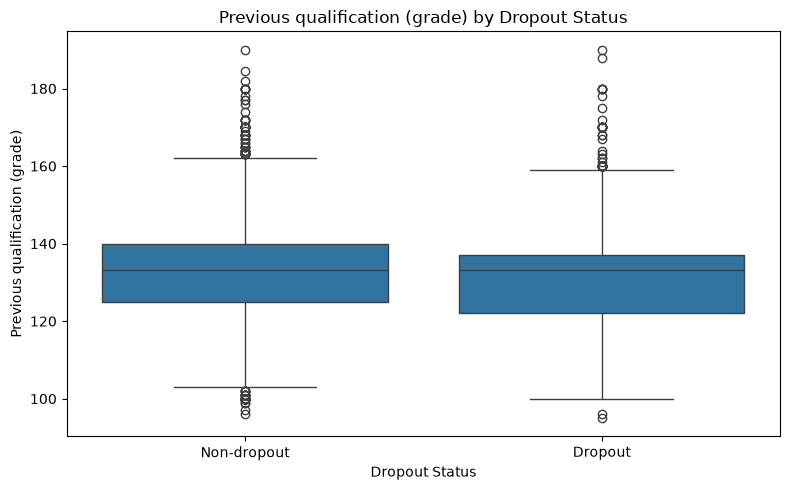

c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


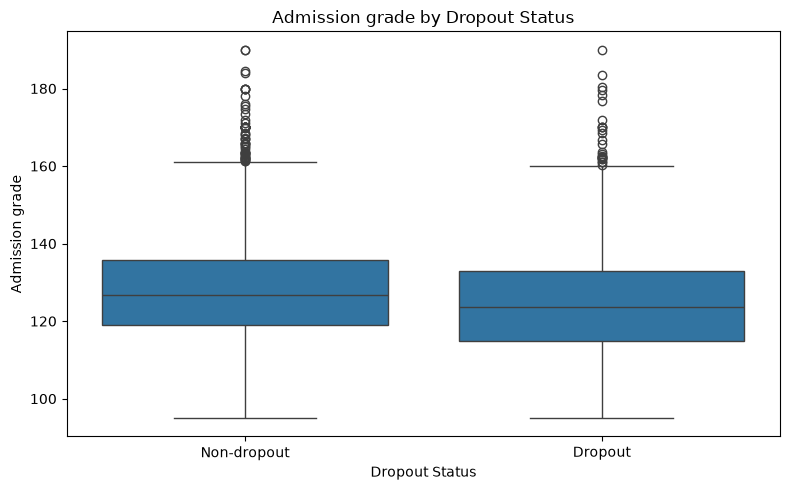

In [96]:
binary_label_df = df.assign(
    Dropout_Status=df["Dropout_binary"].map({
        0: "Non-dropout",
        1: "Dropout"
    })
)

for variable in prior_academic_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=binary_label_df,
        x="Dropout_Status",
        y=variable,
        order=[
            "Non-dropout",
            "Dropout"
        ]
    )

    plt.title(
        f"{variable} by Dropout Status"
    )

    plt.xlabel("Dropout Status")
    plt.ylabel(variable)
    plt.tight_layout()

    safe_name = (
        variable.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )

    plt.savefig(
        FIGURES_DIR
        / f"phase8_{safe_name}_dropout.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Phase 8.6: Selected Stage 1 Categorical Predictors

In [97]:


MIN_DISPLAY_COUNT = 30

def categorical_dropout_summary(
    data,
    variable,
    min_count=30
):

    summary = (
        data.groupby(variable)["Dropout_binary"]
        .agg(
            Student_Count="size",
            Dropout_Count="sum",
            Dropout_Rate="mean"
        )
        .reset_index()
    )

    summary["Dropout_Rate_Percentage"] = (
        summary["Dropout_Rate"] * 100
    ).round(2)

    return (
        summary.loc[
            summary["Student_Count"]
            >= min_count
        ]
        .drop(columns="Dropout_Rate")
        .sort_values(
            "Dropout_Rate_Percentage",
            ascending=False
        )
    )

In [98]:
application_mode_dropout = (
    categorical_dropout_summary(
        df,
        "Application mode",
        MIN_DISPLAY_COUNT
    )
)

course_dropout = (
    categorical_dropout_summary(
        df,
        "Course",
        MIN_DISPLAY_COUNT
    )
)

print("Application mode:")
display(application_mode_dropout)

print("\nCourse:")
display(course_dropout)

Application mode:


,Application mode,Student_Count,Dropout_Count,Dropout_Rate_Percentage
3,7,139,85,61.15
11,39,785,435,55.41
12,42,77,34,44.16
13,43,312,115,36.86
8,18,124,45,36.29
15,51,59,20,33.90
14,44,213,63,29.58
7,17,872,256,29.36
0,1,1708,345,20.20
5,15,30,5,16.67



Course:


,Course,Student_Count,Dropout_Count,Dropout_Rate_Percentage
7,9130,141,78,55.32
6,9119,170,92,54.12
16,9991,268,136,50.75
15,9853,192,85,44.27
3,9003,210,86,40.95
12,9556,86,33,38.37
1,171,215,82,38.14
10,9254,252,96,38.10
13,9670,268,95,35.45
8,9147,380,134,35.26


### Finding: Selected Stage 1 Categorical Patterns

Application mode and course show variation in observed dropout rates across categories.

Only categories containing at least 30 records are displayed in this descriptive table to reduce instability and improve readability.

This display threshold does not remove categories from the dataset or from later predictive modelling.

The observed variation indicates that enrolment context may contribute information at Stage 1, but categorical dropout rates are not treated as evidence of independent predictive importance.

## Phase 8.7: First-semester Academic Performance and Binary Dropout Status

In [99]:
semester1_binary_summary = (
    df.groupby("Dropout_binary")[
        semester1_features
    ]
    .mean()
    .rename(index={
        0: "Non-dropout",
        1: "Dropout"
    })
    .T
    .round(2)
)

semester1_binary_summary

Dropout_binary,Non-dropout,Dropout
Curricular units 1st sem (credited),0.76,0.61
Curricular units 1st sem (enrolled),6.48,5.82
Curricular units 1st sem (evaluations),8.56,7.75
Curricular units 1st sem (approved),5.73,2.55
Curricular units 1st sem (grade),12.24,7.26
Curricular units 1st sem (without evaluations),0.11,0.19


### Finding: First-semester Academic Performance

The binary comparison shows clear differences in first-semester academic performance between Dropout and Non-dropout students.

The largest descriptive contrasts occur in approved curricular units and semester grade.

Students in the Dropout group complete fewer approved units and achieve lower first-semester grades on average.

This provides descriptive evidence that academic information available after the first semester may add useful signal beyond pre-enrolment information.

 Whether this improves actual predictive performance will be tested later by comparing Stage 1 and Stage 2 models in a controlled evaluation (Martins et al., 2021; Kohavi, 1995).

### Phase 8.7.1: First-semester Approved Units

c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


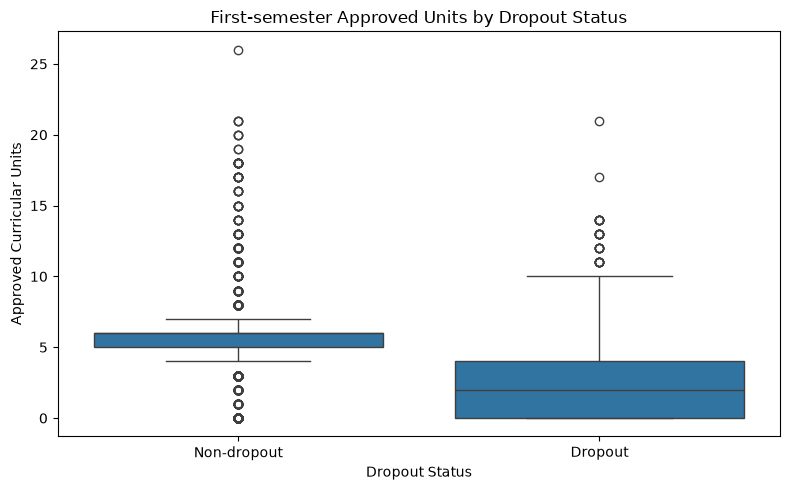

In [100]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=binary_label_df,
    x="Dropout_Status",
    y="Curricular units 1st sem (approved)",
    order=[
        "Non-dropout",
        "Dropout"
    ]
)

plt.title(
    "First-semester Approved Units by Dropout Status"
)
plt.xlabel("Dropout Status")
plt.ylabel("Approved Curricular Units")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "phase8_first_semester_approved_by_dropout.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding: First-semester Approved Units

The distribution of first-semester approved units shows substantial separation between the binary outcome groups.

Students in the Dropout group generally have fewer approved units than students in the Non-dropout group.

The overlap between distributions nevertheless confirms that approved-unit count alone is not a deterministic dropout rule.

### Phase 8.7.2: First-semester Grade

c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


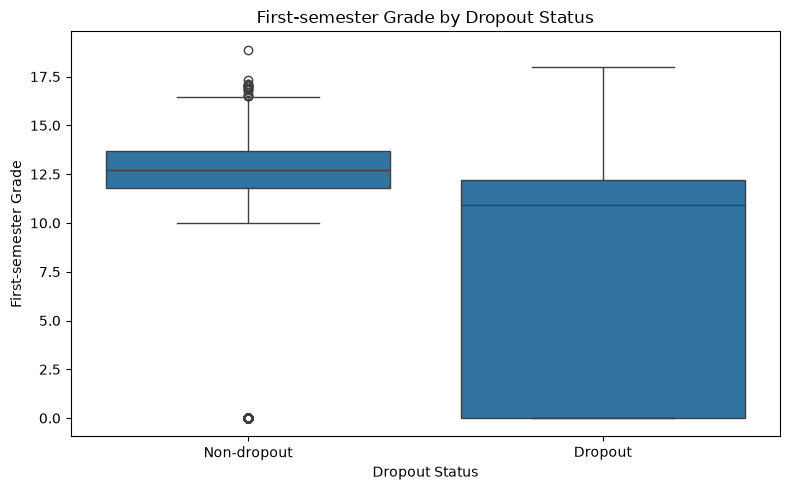

In [101]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=binary_label_df,
    x="Dropout_Status",
    y="Curricular units 1st sem (grade)",
    order=[
        "Non-dropout",
        "Dropout"
    ]
)

plt.title(
    "First-semester Grade by Dropout Status"
)

plt.xlabel("Dropout Status")
plt.ylabel("First-semester Grade")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "phase8_first_semester_grade_by_dropout.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding: First-semester Grade

First-semester grade shows a strong descriptive difference between Dropout and Non-dropout students.

The Dropout group has substantially lower academic performance on average.



Predictive importance will only be determined through the controlled model evaluation and SHAP analysis (Lundberg and Lee, 2017; Kohavi, 1995).

## Phase 8.8: Second-semester Academic Performance and Binary Dropout Status

In [102]:
semester2_binary_summary = (
    df.groupby("Dropout_binary")[
        semester2_features
    ]
    .mean()
    .rename(index={
        0: "Non-dropout",
        1: "Dropout"
    })
    .T
    .round(2)
)

semester2_binary_summary

Dropout_binary,Non-dropout,Dropout
Curricular units 2nd sem (credited),0.59,0.45
Curricular units 2nd sem (enrolled),6.45,5.78
Curricular units 2nd sem (evaluations),8.48,7.17
Curricular units 2nd sem (approved),5.62,1.94
Curricular units 2nd sem (grade),12.28,5.90
Curricular units 2nd sem (without evaluations),0.11,0.24


### Finding: Second-semester Academic Performance

Second-semester academic measures show substantial differences between the two binary outcome groups.

Dropout students have fewer approved units and lower grades on average than Non-dropout students.

The descriptive separation appears particularly pronounced for approved units and semester grade.

These observations are consistent with the rationale for the Stage 3 prediction point (Martins et al., 2021) but do not establish that Stage 3 predictive performance will necessarily exceed Stage 1 or Stage 2 performance.

c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


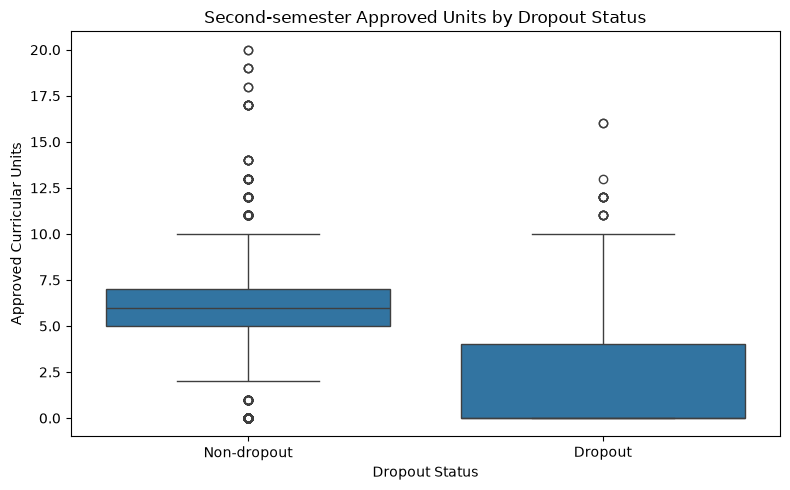

In [103]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=binary_label_df,
    x="Dropout_Status",
    y="Curricular units 2nd sem (approved)",
    order=[
        "Non-dropout",
        "Dropout"
    ]
)

plt.title(
    "Second-semester Approved Units by Dropout Status"
)

plt.xlabel("Dropout Status")
plt.ylabel("Approved Curricular Units")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "phase8_second_semester_approved_by_dropout.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding: Second-semester Approved Units

Second-semester approved-unit counts differ strongly between Dropout and Non-dropout students.

The Dropout group generally records fewer successfully approved curricular units.

The variable therefore contains clear descriptive outcome-related structure, although its eventual contribution must be evaluated together with the remaining predictors in multivariable models.

### Phase 8.8.2: Second-semester Grade

c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


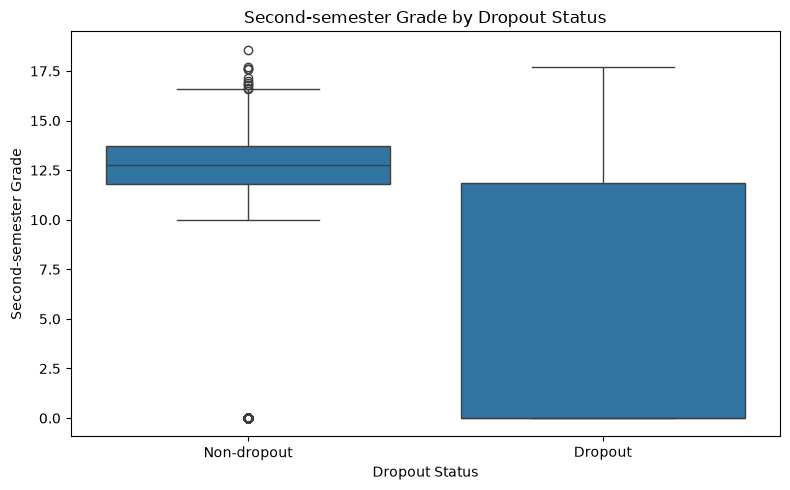

In [104]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=binary_label_df,
    x="Dropout_Status",
    y="Curricular units 2nd sem (grade)",
    order=[
        "Non-dropout",
        "Dropout"
    ]
)

plt.title(
    "Second-semester Grade by Dropout Status"
)

plt.xlabel("Dropout Status")
plt.ylabel("Second-semester Grade")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "phase8_second_semester_grade_by_dropout.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding: Second-semester Grade

Second-semester grade shows pronounced descriptive separation between the binary outcome groups.

Students in the Dropout class record substantially lower average semester performance than Non-dropout students.

This pattern will later be compared with SHAP feature rankings to determine whether semester grade becomes an important predictor when considered jointly with the other available student characteristics (Lundberg and Lee, 2017).

## Phase 8.9: Macroeconomic Conditions and Binary Dropout Status

In [105]:
macroeconomic_binary_summary = (
    df.groupby("Dropout_binary")[
        macroeconomic_features
    ]
    .agg([
        "mean",
        "median"
    ])
    .rename(index={
        0: "Non-dropout",
        1: "Dropout"
    })
    .round(3)
)

macroeconomic_binary_summary

Unemployment rate        Inflation rate           GDP       
                            mean median           mean median   mean median
Dropout_binary                                                             
Non-dropout               11.542   11.1          1.202    1.4  0.074   0.79
Dropout                   11.616   11.1          1.284    1.4 -0.151   0.32

### Finding: Macroeconomic Conditions

Average unemployment, inflation and GDP values show comparatively modest differences between Dropout and Non-dropout students.

Simple group averages therefore provide less obvious descriptive separation than several student-level financial and semester academic variables.

However, these predictors remain part of Stage 1 because multivariable relationships may exist even when simple univariate differences are small.

## Phase 8.10: Binary EDA Evidence Register

In [106]:
binary_eda_findings = pd.DataFrame([
    {
        "Area": "Age",
        "Finding": (
            "Dropout students are older on average, "
            "although distributions overlap."
        ),
        "Research_Relevance": (
            "Potential Stage 1 predictive association; "
            "non-actionable characteristic."
        )
    },
    {
        "Area": "Financial / administrative",
        "Finding": (
            "Debtor and tuition-fee status show pronounced "
            "differences in observed dropout rates."
        ),
        "Research_Relevance": (
            "Potential Stage 1 predictive information; "
            "interpret cautiously and non-causally."
        )
    },
    {
        "Area": "Scholarship",
        "Finding": (
            "Scholarship holders show a lower descriptive "
            "dropout rate."
        ),
        "Research_Relevance": (
            "Socioeconomic association requiring later "
            "multivariable evaluation."
        )
    },
    {
        "Area": "Prior academic",
        "Finding": (
            "Prior and admission grades differ between "
            "binary outcome groups, with considerable overlap."
        ),
        "Research_Relevance": (
            "Provides pre-enrolment academic information "
            "for Stage 1."
        )
    },
    {
        "Area": "Semester 1",
        "Finding": (
            "Approved units and semester grade show strong "
            "descriptive differences."
        ),
        "Research_Relevance": (
            "Provides rationale for testing whether Stage 2 "
            "improves prediction."
        )
    },
    {
        "Area": "Semester 2",
        "Finding": (
            "Approved units and grade show pronounced "
            "binary-outcome separation."
        ),
        "Research_Relevance": (
            "Provides rationale for testing Stage 3 without "
            "assuming improved performance."
        )
    },
    {
        "Area": "Macroeconomic",
        "Finding": (
            "Simple outcome-group differences are modest."
        ),
        "Research_Relevance": (
            "Variables remain available for multivariable "
            "Stage 1 modelling."
        )
    }
])

binary_eda_findings

,Area,Finding,Research_Relevance
0,Age,"Dropout students are older on average, althoug...",Potential Stage 1 predictive association; non-...
1,Financial / administrative,Debtor and tuition-fee status show pronounced ...,Potential Stage 1 predictive information; inte...
2,Scholarship,Scholarship holders show a lower descriptive d...,Socioeconomic association requiring later mult...
3,Prior academic,Prior and admission grades differ between bina...,Provides pre-enrolment academic information fo...
4,Semester 1,Approved units and semester grade show strong ...,Provides rationale for testing whether Stage 2...
5,Semester 2,Approved units and grade show pronounced binar...,Provides rationale for testing Stage 3 without...
6,Macroeconomic,Simple outcome-group differences are modest.,Variables remain available for multivariable S...


### Finding: Binary EDA Evidence Register

The binary EDA evidence register captures the principal descriptive relationships observed before predictive modelling.

The strongest visible outcome differences occur in selected financial indicators and semester-level academic measures.

These observations provide context for the staged modelling design but are not used to select the winning model, remove predictors or determine whether a research hypothesis is supported.

Formal conclusions will depend on cross-validated model performance, held-out test evaluation and SHAP analysis (Kohavi, 1995; Lundberg and Lee, 2017).

## Phase 8.11: Preserve Binary EDA Outputs

In [107]:
age_binary_summary.to_csv(
    TABLES_DIR
    / "phase8_age_by_binary_dropout.csv"
)

demographic_dropout_summary.to_csv(
    TABLES_DIR
    / "phase8_demographic_dropout_rates.csv",
    index=False
)

prior_binary_summary.to_csv(
    TABLES_DIR
    / "phase8_prior_academic_binary_summary.csv"
)

semester1_binary_summary.to_csv(
    TABLES_DIR
    / "phase8_semester1_binary_summary.csv"
)

semester2_binary_summary.to_csv(
    TABLES_DIR
    / "phase8_semester2_binary_summary.csv"
)

macroeconomic_binary_summary.to_csv(
    TABLES_DIR
    / "phase8_macroeconomic_binary_summary.csv"
)

application_mode_dropout.to_csv(
    TABLES_DIR
    / "phase8_application_mode_dropout_rates.csv",
    index=False
)

course_dropout.to_csv(
    TABLES_DIR
    / "phase8_course_dropout_rates.csv",
    index=False
)

binary_eda_findings.to_csv(
    TABLES_DIR
    / "phase8_binary_eda_finding_register.csv",
    index=False
)

print("Phase 8 tables saved successfully.")

Phase 8 tables saved successfully.


### Finding: Binary EDA Outputs Preserved

The principal binary-outcome EDA tables and selected figures were exported to the project output directories.

These files provide a reproducible record of the descriptive evidence observed before model construction.

No saved EDA output alters the analytical dataframe or the original source data.

## Phase 8.12: Overall Phase 8 Summary

Binary target-focused EDA identified meaningful descriptive differences between students recorded as Dropout and those classified as Non-dropout.

Dropout students are older on average, although substantial overlap exists between the age distributions.

Financial and administrative characteristics show notable differences. Debtor status and tuition-fee status are particularly associated with different observed dropout rates, while scholarship holders show a lower descriptive dropout proportion.

Prior academic indicators show some differentiation between the binary classes but remain substantially overlapping.

The strongest descriptive differences occur after academic performance becomes available. First-semester approved units and grades differ clearly between Dropout and Non-dropout students, while second-semester academic measures show similarly pronounced patterns.

Macroeconomic indicators display comparatively modest differences in simple group-level summaries.

These findings provide descriptive support for the staged design of the study but do not establish predictive importance, causality or support for H1–H4.

No predictor has been removed or added because of its relationship with the binary target during this EDA.

### Code Attribution — Phase 8

pandas development team, 2026. *pandas.DataFrame.groupby* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame.assign* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.sort* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/generated/numpy.sort.html> [Accessed 14 September 2026].

Matplotlib developers, 2025. *matplotlib.pyplot.savefig* [Source code/documentation]. Available at: <https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html> [Accessed 14 September 2026].

seaborn developers, 2025. *seaborn.boxplot* [Source code/documentation]. Available at: <https://seaborn.pydata.org/generated/seaborn.boxplot.html> [Accessed 14 September 2026].

seaborn developers, 2025. *seaborn.barplot* [Source code/documentation]. Available at: <https://seaborn.pydata.org/generated/seaborn.barplot.html> [Accessed 14 September 2026].

seaborn developers, 2025. *seaborn.countplot* [Source code/documentation]. Available at: <https://seaborn.pydata.org/generated/seaborn.countplot.html> [Accessed 14 September 2026].

# Phase 9: Construction and Verification of the Three Prediction Stages

The approved research design compares dropout prediction across three cumulative information stages, reflecting the temporal availability of student data within a single academic year (Realinho et al., 2022):

- Stage 1: pre-enrolment / pre-semester information, with no semester-performance variables.
- Stage 2: Stage 1 information plus first-semester academic performance.
- Stage 3: Stage 2 information plus second-semester academic performance.

The source dataset contains 24, 30 and 36 available predictors at these three stages respectively.

Following the documented redundancy assessment, `International` is excluded from the primary predictive feature sets because it is deterministically represented by `Nacionality`.

The primary model feature sets therefore contain 23, 29 and 35 predictors respectively.

This phase verifies the temporal structure before any train/test partition or model fitting occurs.

## Phase 9.1: Construct the Original Source-stage Feature Sets

In [108]:


stage1_source_features = (
    variable_dictionary.loc[
        variable_dictionary["First_Available_Stage"] == "Stage 1",
        "Variable"
    ]
    .tolist()
)

stage2_new_source_features = (
    variable_dictionary.loc[
        variable_dictionary["First_Available_Stage"] == "Stage 2",
        "Variable"
    ]
    .tolist()
)

stage3_new_source_features = (
    variable_dictionary.loc[
        variable_dictionary["First_Available_Stage"] == "Stage 3",
        "Variable"
    ]
    .tolist()
)

stage2_source_features = (
    stage1_source_features
    + stage2_new_source_features
)

stage3_source_features = (
    stage2_source_features
    + stage3_new_source_features
)

print("Source-stage predictor counts:")
print(f"Stage 1: {len(stage1_source_features)}")
print(f"Stage 2: {len(stage2_source_features)}")
print(f"Stage 3: {len(stage3_source_features)}")

Source-stage predictor counts:
Stage 1: 24
Stage 2: 30
Stage 3: 36


### Finding: Original Source-stage Structure

The source feature sets contain the expected 24 predictors at Stage 1, 30 predictors at Stage 2 and 36 predictors at Stage 3.

Stage 2 adds six first-semester academic variables to the Stage 1 information.

Stage 3 adds six second-semester academic variables to the cumulative Stage 2 information.

This confirms that the variable dictionary reproduces the temporal feature structure specified in the research design (Realinho et al., 2022).

## Phase 9.2: Verify the Features Added at Each Semester Stage

In [109]:
print("Features added at Stage 2:")
print("-" * 30)

for feature in stage2_new_source_features:
    print("-", feature)

print("\nFeatures added at Stage 3:")
print("-" * 30)

for feature in stage3_new_source_features:
    print("-", feature)

Features added at Stage 2:
------------------------------
- Curricular units 1st sem (credited)
- Curricular units 1st sem (enrolled)
- Curricular units 1st sem (evaluations)
- Curricular units 1st sem (approved)
- Curricular units 1st sem (grade)
- Curricular units 1st sem (without evaluations)

Features added at Stage 3:
------------------------------
- Curricular units 2nd sem (credited)
- Curricular units 2nd sem (enrolled)
- Curricular units 2nd sem (evaluations)
- Curricular units 2nd sem (approved)
- Curricular units 2nd sem (grade)
- Curricular units 2nd sem (without evaluations)


### Finding: Incremental Semester Information

Stage 2 introduces exactly six first-semester curricular-unit variables:

- Credited units.
- Enrolled units.
- Evaluations.
- Approved units.
- Grade.
- Units without evaluations.

Stage 3 introduces the corresponding six second-semester variables.

The staged design therefore adds academic information progressively rather than changing the underlying student cohort or replacing earlier predictors.

## Phase 9.3: Construct the Primary Modelling Feature Sets

In [110]:

stage1_model_features = [
    feature
    for feature in stage1_source_features
    if feature not in model_excluded_features
]

stage2_model_features = [
    feature
    for feature in stage2_source_features
    if feature not in model_excluded_features
]

stage3_model_features = [
    feature
    for feature in stage3_source_features
    if feature not in model_excluded_features
]

stage_feature_sets = {
    "Stage 1": stage1_model_features,
    "Stage 2": stage2_model_features,
    "Stage 3": stage3_model_features
}

for stage_name, features in stage_feature_sets.items():
    print(
        f"{stage_name}: "
        f"{len(features)} modelling predictors"
    )

Stage 1: 23 modelling predictors
Stage 2: 29 modelling predictors
Stage 3: 35 modelling predictors


### Finding: Primary Modelling-stage Structure

After the previously documented exclusion of the redundant `International` predictor, the primary modelling stages contain:

- Stage 1: 23 predictors.
- Stage 2: 29 predictors.
- Stage 3: 35 predictors.

The reduction of one predictor at every stage results from a single Stage 1 redundancy decision.

The temporal structure itself remains unchanged: Stage 2 adds six first-semester variables and Stage 3 adds six second-semester variables.

## Phase 9.4: Verify Cumulative Stage Nesting

In [111]:

stage1_set = set(stage1_model_features)
stage2_set = set(stage2_model_features)
stage3_set = set(stage3_model_features)

stage1_within_stage2 = (
    stage1_set.issubset(stage2_set)
)

stage2_within_stage3 = (
    stage2_set.issubset(stage3_set)
)

stage2_added_count = len(
    stage2_set - stage1_set
)

stage3_added_count = len(
    stage3_set - stage2_set
)

print(
    "All Stage 1 features retained in Stage 2:",
    stage1_within_stage2
)

print(
    "All Stage 2 features retained in Stage 3:",
    stage2_within_stage3
)

print(
    "Features newly added at Stage 2:",
    stage2_added_count
)

print(
    "Features newly added at Stage 3:",
    stage3_added_count
)

All Stage 1 features retained in Stage 2: True
All Stage 2 features retained in Stage 3: True
Features newly added at Stage 2: 6
Features newly added at Stage 3: 6


### Finding: Cumulative Prediction-stage Design

The stage feature sets are correctly nested, preserving the cumulative temporal design required for the staged prediction comparison (Martins et al., 2021).

Every Stage 1 predictor is retained at Stage 2, and every Stage 2 predictor is retained at Stage 3.

Exactly six new predictors are introduced at each semester transition.

This controlled cumulative structure is essential for evaluating whether predictive performance changes as progressively later academic information becomes available.

## Phase 9.5: Temporal Leakage Check for Stage 1

In [112]:
# Detect semester-performance variables in the Stage 1 feature set.

stage1_semester_leakage = [
    feature
    for feature in stage1_model_features
    if (
        "1st sem" in feature.lower()
        or "2nd sem" in feature.lower()
    )
]

print(
    "Semester-performance predictors found in Stage 1:",
    stage1_semester_leakage
)

print(
    "Stage 1 temporal leakage check passed:",
    len(stage1_semester_leakage) == 0
)

Semester-performance predictors found in Stage 1: []
Stage 1 temporal leakage check passed: True


### Finding: Stage 1 Temporal Leakage Check

No first- or second-semester performance predictors are present in the Stage 1 modelling feature set.

Stage 1 therefore represents the earliest prediction point using information available before semester academic performance is introduced.

This confirms that later academic outcomes cannot leak into the earliest-stage model.

## Phase 9.6: Temporal Leakage Check for Stage 2

In [113]:
stage2_second_semester_leakage = [
    feature
    for feature in stage2_model_features
    if "2nd sem" in feature.lower()
]

print(
    "Second-semester predictors found in Stage 2:",
    stage2_second_semester_leakage
)

print(
    "Stage 2 temporal leakage check passed:",
    len(stage2_second_semester_leakage) == 0
)

Second-semester predictors found in Stage 2: []
Stage 2 temporal leakage check passed: True


### Finding: Stage 2 Temporal Leakage Check

No second-semester performance variables are present in the Stage 2 feature set.

Stage 2 therefore uses the complete Stage 1 information plus first-semester academic performance only.

This preserves the intended post-first-semester prediction point and prevents future semester information from influencing Stage 2 results.

## Phase 9.7: Verify Complete Stage 3 Coverage

In [114]:
# Stage 3 should contain every predictor retained for primary modelling.

stage3_matches_model_candidates = (
    set(stage3_model_features)
    == set(model_candidate_predictors)
)

missing_from_stage3 = (
    set(model_candidate_predictors)
    - set(stage3_model_features)
)

unexpected_in_stage3 = (
    set(stage3_model_features)
    - set(model_candidate_predictors)
)

print(
    "Stage 3 equals complete primary modelling set:",
    stage3_matches_model_candidates
)

print(
    "Missing from Stage 3:",
    missing_from_stage3
)

print(
    "Unexpected in Stage 3:",
    unexpected_in_stage3
)

Stage 3 equals complete primary modelling set: True
Missing from Stage 3: set()
Unexpected in Stage 3: set()


### Finding: Stage 3 Completeness

Stage 3 contains the complete set of predictors retained for primary predictive modelling.

No eligible predictor is missing and no unexpected predictor has been introduced.

Stage 3 therefore represents the maximum information point available within the approved dataset after the documented redundancy exclusion.

## Phase 9.8: Verify No Outcome Variables Enter Any Prediction Stage

In [115]:
outcome_variables = {
    "Target",
    "Dropout_binary"
}

stage_target_leakage = {}

for stage_name, features in stage_feature_sets.items():

    leakage = (
        outcome_variables
        .intersection(set(features))
    )

    stage_target_leakage[stage_name] = leakage

    print(
        f"{stage_name} outcome leakage:",
        leakage
    )

all_stage_target_checks_passed = all(
    len(leakage) == 0
    for leakage in stage_target_leakage.values()
)

print(
    "\nAll target leakage checks passed:",
    all_stage_target_checks_passed
)

Stage 1 outcome leakage: set()
Stage 2 outcome leakage: set()
Stage 3 outcome leakage: set()

All target leakage checks passed: True


### Finding: Outcome Leakage Safeguard

Neither the original three-class `Target` nor the binary `Dropout_binary` outcome is present in any of the three prediction-stage feature sets.

This confirms that direct outcome information cannot accidentally enter the predictive models as an explanatory variable.

## Phase 9.9: Verify Unique Feature Membership

In [116]:
stage_duplicate_check = []

for stage_name, features in stage_feature_sets.items():

    duplicate_count = (
        len(features)
        - len(set(features))
    )

    stage_duplicate_check.append({
        "Stage": stage_name,
        "Feature_Count": len(features),
        "Unique_Feature_Count": len(set(features)),
        "Duplicate_Count": duplicate_count
    })

stage_duplicate_summary = pd.DataFrame(
    stage_duplicate_check
)

stage_duplicate_summary

,Stage,Feature_Count,Unique_Feature_Count,Duplicate_Count
0,Stage 1,23,23,0
1,Stage 2,29,29,0
2,Stage 3,35,35,0


### Finding: Stage Feature Uniqueness

Each prediction-stage feature list contains unique predictor names.

No feature is duplicated within Stage 1, Stage 2 or Stage 3.

This ensures that later feature matrices will not unintentionally give duplicated columns to the predictive models.

## Phase 9.10: Build the Stage-membership Audit Table

In [117]:
stage_membership_table = (
    variable_dictionary[
        [
            "Variable",
            "Semantic_Type",
            "Conceptual_Group",
            "First_Available_Stage"
        ]
    ]
    .copy()
)

stage_membership_table["Excluded_From_Primary_Model"] = (
    stage_membership_table["Variable"]
    .isin(model_excluded_features)
)

stage_membership_table["Stage_1_Model"] = (
    stage_membership_table["Variable"]
    .isin(stage1_model_features)
)

stage_membership_table["Stage_2_Model"] = (
    stage_membership_table["Variable"]
    .isin(stage2_model_features)
)

stage_membership_table["Stage_3_Model"] = (
    stage_membership_table["Variable"]
    .isin(stage3_model_features)
)

stage_membership_table

,Variable,Semantic_Type,Conceptual_Group,First_Available_Stage,Excluded_From_Primary_Model,Stage_1_Model,Stage_2_Model,Stage_3_Model
0,Marital status,Nominal categorical,Demographic,Stage 1,False,True,True,True
1,Application mode,Nominal categorical,Application / enrolment,Stage 1,False,True,True,True
2,Application order,Ordinal discrete,Application / enrolment,Stage 1,False,True,True,True
3,Course,Nominal categorical,Application / enrolment,Stage 1,False,True,True,True
4,Daytime/evening attendance,Binary categorical,Application / enrolment,Stage 1,False,True,True,True
5,Previous qualification,Nominal categorical,Prior academic / enrolment,Stage 1,False,True,True,True
6,Previous qualification (grade),Continuous numerical,Prior academic / enrolment,Stage 1,False,True,True,True
7,Nacionality,Nominal categorical,Demographic,Stage 1,False,True,True,True
8,Mother's qualification,Nominal categorical,Socioeconomic / family background,Stage 1,False,True,True,True
9,Father's qualification,Nominal categorical,Socioeconomic / family background,Stage 1,False,True,True,True


### Finding: Prediction-stage Audit Table

A variable-level audit table now records when each predictor first becomes available, whether it is excluded from primary modelling, and whether it appears in each of the three cumulative model stages.

This creates a transparent link between the source data dictionary and the implemented modelling design.

The table will also support later reporting of the methodology and temporal leakage controls.

## Phase 9.11: Summarise the Three Prediction Stages

In [118]:
stage_design_summary = pd.DataFrame([
    {
        "Stage": "Stage 1",
        "Prediction_Point": "Pre-semester / earliest prediction",
        "Source_Predictors": len(stage1_source_features),
        "Primary_Model_Predictors": len(stage1_model_features),
        "New_Academic_Block": "None"
    },
    {
        "Stage": "Stage 2",
        "Prediction_Point": "Post-first-semester",
        "Source_Predictors": len(stage2_source_features),
        "Primary_Model_Predictors": len(stage2_model_features),
        "New_Academic_Block": "Six first-semester variables"
    },
    {
        "Stage": "Stage 3",
        "Prediction_Point": "Post-second-semester",
        "Source_Predictors": len(stage3_source_features),
        "Primary_Model_Predictors": len(stage3_model_features),
        "New_Academic_Block": "Six second-semester variables"
    }
])

stage_design_summary

,Stage,Prediction_Point,Source_Predictors,Primary_Model_Predictors,New_Academic_Block
0,Stage 1,Pre-semester / earliest prediction,24,23,None
1,Stage 2,Post-first-semester,30,29,Six first-semester variables
2,Stage 3,Post-second-semester,36,35,Six second-semester variables


### Finding: Implemented Prediction-stage Design

The staged feature design has now been fully operationalised.

The source dataset provides 24 → 30 → 36 available predictors across the three temporal points.

Following the single documented redundancy exclusion, the primary fitted models will receive 23 → 29 → 35 source predictors before one-hot encoding.

The same temporal structure will be used for Logistic Regression, Random Forest and Gradient Boosting to ensure that model comparisons are not confounded by different feature sets (Breiman, 2001; Friedman, 2001; scikit-learn developers, 2026).

## Phase 9.12: Decision Record for the Controlled Stage Comparison

### Decision Record: Prediction-stage Construction

#### Observation

The dataset provides background, application, socioeconomic and macroeconomic information before semester-performance measures, followed by six first-semester and six second-semester academic variables.

#### Options considered

- Train one model using all available predictors only.
- Construct independent feature subsets that differ arbitrarily between models.
- Use cumulative temporal stages that add information as it becomes available.

#### Decision

Three cumulative prediction stages will be used:

- Stage 1: earliest available non-semester information.
- Stage 2: Stage 1 plus first-semester academic information.
- Stage 3: Stage 2 plus second-semester academic information.

The same stage feature sets will be supplied to all three primary model families.

#### Justification

The cumulative design directly addresses the study's timing question by allowing predictive performance to be compared as additional academic information becomes available (Martins et al., 2021; Realinho et al., 2022).

Holding stage membership constant across model families also ensures that model comparisons are not confounded by giving different algorithms different predictor sets.

No feature was allocated to a stage according to its relationship with the dropout outcome or its effect on model performance.

## Phase 9.13: Preserve the Prediction-stage Definitions

In [119]:


stage_membership_table.to_csv(
    TABLES_DIR
    / "phase9_prediction_stage_membership.csv",
    index=False
)

stage_design_summary.to_csv(
    TABLES_DIR
    / "phase9_prediction_stage_summary.csv",
    index=False
)

stage_duplicate_summary.to_csv(
    TABLES_DIR
    / "phase9_stage_duplicate_check.csv",
    index=False
)

print(
    "Stage membership table saved:",
    (
        TABLES_DIR
        / "phase9_prediction_stage_membership.csv"
    ).exists()
)

print(
    "Stage design summary saved:",
    (
        TABLES_DIR
        / "phase9_prediction_stage_summary.csv"
    ).exists()
)

Stage membership table saved: True
Stage design summary saved: True


### Finding: Prediction-stage Definitions Preserved

The implemented prediction-stage membership and verification summaries were exported to the project tables directory.

These outputs provide a reproducible record of the feature sets that will later be supplied to every primary model.

The stage definitions are now fixed and will not be changed in response to model performance.

## Phase 9.14: Overall Phase 9 Summary

The three cumulative prediction stages required by the research design have now been constructed and verified.

The original source structure contains 24 predictors at Stage 1, 30 at Stage 2 and 36 at Stage 3.

Following the previously documented exclusion of the deterministically redundant `International` variable, the primary modelling feature sets contain 23, 29 and 35 predictors respectively.

Stage 2 retains all Stage 1 information and introduces exactly six first-semester academic variables.

Stage 3 retains all Stage 2 information and introduces exactly six second-semester academic variables.

Temporal leakage checks confirmed that Stage 1 contains no semester-performance variables and Stage 2 contains no second-semester variables.

Neither the original nor binary target appears in any model feature set.

The feature lists contain no duplicate predictors, and Stage 3 represents the complete primary modelling predictor set.

The staged structure is therefore ready for the controlled model comparison required by the research questions and hypotheses.

No train/test split, fitted preprocessing pipeline or predictive model has yet been created.

### Code Attribution — Phase 9

pandas development team, 2026. *pandas.DataFrame.loc* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame.isin* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isin.html> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.sort* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/generated/numpy.sort.html> [Accessed 14 September 2026].

# Phase 10: Shared Stratified Train/Test Split

The three prediction-stage feature sets have now been fixed.

A single stratified train/test partition will now be created using student row indices rather than creating a separate split for each stage.

The same training students and the same held-out test students will therefore be used for:

- Stage 1.
- Stage 2.
- Stage 3.
- Logistic Regression.
- Random Forest.
- Gradient Boosting.

The binary dropout outcome is used only for stratification so that the proportion of Dropout and Non-dropout students is approximately preserved in both partitions.

The split uses the pre-specified random state and test proportion established before model performance is examined, supporting reproducibility and preventing the selection of a favourable random partition after observing results (Kohavi, 1995; scikit-learn developers, 2026).

After verification, the held-out test partition will be treated as sealed. It will not be used to choose preprocessing procedures, hyperparameters, imbalance strategies or classification thresholds.

## Phase 10.1: Confirm the Pre-specified Split Configuration

In [120]:


print("Random state:", RANDOM_STATE)
print("Test proportion:", TEST_SIZE)
print("Cross-validation folds:", CV_FOLDS)

assert RANDOM_STATE == 42
assert TEST_SIZE == 0.20
assert CV_FOLDS == 5

print("\nPre-specified split configuration confirmed.")

Random state: 42
Test proportion: 0.2
Cross-validation folds: 5

Pre-specified split configuration confirmed.


### Finding: Split Configuration

The analysis uses a fixed random state of 42, a 20% held-out test partition and five-fold cross-validation for later training-stage model development.

These settings were fixed before predictive performance was examined and will remain constant throughout the comparative modelling workflow.

## Phase 10.2: Prepare the Student Indices and Binary Outcome

In [121]:


all_student_indices = df.index.to_numpy()

y_full = df["Dropout_binary"].copy()

print("Total student indices:", len(all_student_indices))
print("Total target values:", len(y_full))

print(
    "Unique dataframe index:",
    df.index.is_unique
)

print(
    "Index and target lengths match:",
    len(all_student_indices) == len(y_full)
)

Total student indices: 4424
Total target values: 4424
Unique dataframe index: True
Index and target lengths match: True


### Finding: Student-level Split Basis

The dataset contains 4,424 unique row indices corresponding to the 4,424 student records.

The index and binary target have matching lengths and the dataframe index contains no duplicates.

Student row indices can therefore be used to create one reproducible split that can subsequently be applied identically to all three prediction stages.

## Phase 10.3: Create the Shared Stratified Train/Test Split

In [122]:
from sklearn.model_selection import train_test_split

In [123]:

train_indices, test_indices = train_test_split(
    all_student_indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_full
)


train_indices = np.sort(train_indices)
test_indices = np.sort(test_indices)

print("Training students:", len(train_indices))
print("Test students:", len(test_indices))
print(
    "Total students accounted for:",
    len(train_indices) + len(test_indices)
)

Training students: 3539
Test students: 885
Total students accounted for: 4424


### Finding: Shared Train/Test Partition

The dataset was divided into one shared training partition and one held-out test partition.

Approximately 80% of the student records are assigned to training and 20% to held-out testing, consistent with the pre-specified evaluation protocol (Kohavi, 1995; scikit-learn developers, 2026).

The partition was created using student indices rather than separately splitting each stage. Consequently, later comparisons between prediction stages will use exactly the same student records.

## Phase 10.4: Verify that the Training and Test Sets Do Not Overlap

In [124]:
# Confirm that no student occurs in both partitions

train_index_set = set(train_indices)
test_index_set = set(test_indices)

overlapping_indices = (
    train_index_set
    .intersection(test_index_set)
)

print(
    "Overlapping student indices:",
    len(overlapping_indices)
)

print(
    "Train/test overlap check passed:",
    len(overlapping_indices) == 0
)

Overlapping student indices: 0
Train/test overlap check passed: True


### Finding: Train/Test Independence

No student row index appears in both the training and held-out test partitions.

This confirms that the partitions are mutually exclusive and prevents the same student record from contributing to both model fitting and final held-out evaluation.

## Phase 10.5: Verify Complete Dataset Coverage

In [125]:


combined_split_indices = (
    train_index_set
    .union(test_index_set)
)

all_index_set = set(
    all_student_indices
)

missing_indices = (
    all_index_set
    - combined_split_indices
)

unexpected_indices = (
    combined_split_indices
    - all_index_set
)

print(
    "All original students represented:",
    combined_split_indices == all_index_set
)

print(
    "Missing student indices:",
    len(missing_indices)
)

print(
    "Unexpected student indices:",
    len(unexpected_indices)
)

All original students represented: True
Missing student indices: 0
Unexpected student indices: 0


### Finding: Complete Split Coverage

Every student record is represented in exactly one of the two partitions.

No observations were lost during splitting and no unexpected indices were introduced.

The shared split therefore preserves the complete analytical sample of 4,424 student records.

## Phase 10.6: Verify Stratification of the Binary Outcome

In [126]:


def class_distribution(target_series, label):
    counts = (
        target_series
        .value_counts()
        .sort_index()
    )

    percentages = (
        target_series
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )

    return pd.DataFrame({
        "Dataset": label,
        "Binary_Value": counts.index,
        "Class": [
            "Non-dropout" if value == 0
            else "Dropout"
            for value in counts.index
        ],
        "Count": counts.values,
        "Percentage": percentages.values.round(2)
    })


full_distribution = class_distribution(
    y_full,
    "Full dataset"
)

train_distribution = class_distribution(
    df.loc[
        train_indices,
        "Dropout_binary"
    ],
    "Training"
)

test_distribution = class_distribution(
    df.loc[
        test_indices,
        "Dropout_binary"
    ],
    "Held-out test"
)

split_class_distribution = pd.concat(
    [
        full_distribution,
        train_distribution,
        test_distribution
    ],
    ignore_index=True
)

split_class_distribution

,Dataset,Binary_Value,Class,Count,Percentage
0,Full dataset,0,Non-dropout,3003,67.88
1,Full dataset,1,Dropout,1421,32.12
2,Training,0,Non-dropout,2402,67.87
3,Training,1,Dropout,1137,32.13
4,Held-out test,0,Non-dropout,601,67.91
5,Held-out test,1,Dropout,284,32.09


### Finding: Stratified Class Distribution

The Dropout and Non-dropout proportions are approximately preserved across the full dataset, training partition and held-out test partition, confirming that stratification maintains the class structure of the original sample (He and Garcia, 2009; Kohavi, 1995).

The Dropout class remains approximately 32% of each partition.

This confirms that stratification successfully prevents the class imbalance from becoming materially different between the training and held-out evaluation samples.

## Phase 10.7: Quantify Stratification Differences

In [127]:


full_dropout_rate = (
    df["Dropout_binary"]
    .mean() * 100
)

train_dropout_rate = (
    df.loc[
        train_indices,
        "Dropout_binary"
    ]
    .mean() * 100
)

test_dropout_rate = (
    df.loc[
        test_indices,
        "Dropout_binary"
    ]
    .mean() * 100
)

stratification_check = pd.DataFrame({
    "Dataset": [
        "Full dataset",
        "Training",
        "Held-out test"
    ],
    "Dropout_Percentage": [
        full_dropout_rate,
        train_dropout_rate,
        test_dropout_rate
    ]
}).round(3)

stratification_check

,Dataset,Dropout_Percentage
0,Full dataset,32.120
1,Training,32.128
2,Held-out test,32.090


### Finding: Stratification Precision

The observed dropout percentage is nearly identical across the full dataset, training partition and held-out test partition.

Any very small difference results from the requirement to allocate whole student records rather than fractional observations.

The partition therefore provides a suitable controlled basis for later model comparison.

## Phase 10.8: Create Shared Training and Test Targets

In [128]:


y_train = (
    df.loc[
        train_indices,
        "Dropout_binary"
    ]
    .copy()
)

y_test = (
    df.loc[
        test_indices,
        "Dropout_binary"
    ]
    .copy()
)

print("y_train observations:", len(y_train))
print("y_test observations:", len(y_test))

print(
    "\nTraining target index matches training split:",
    set(y_train.index) == set(train_indices)
)

print(
    "Test target index matches test split:",
    set(y_test.index) == set(test_indices)
)

y_train observations: 3539
y_test observations: 885

Training target index matches training split: True
Test target index matches test split: True


### Finding: Shared Outcome Vectors

One training target vector and one held-out test target vector have been created from the shared student partition.

These same target vectors will be used for all three model families and all three prediction stages.

This prevents differences in target membership from confounding later comparisons.

## Phase 10.9: Construct Stage-specific Training and Test Feature Matrices

In [129]:


X_stage1_train = df.loc[
    train_indices,
    stage1_model_features
].copy()

X_stage1_test = df.loc[
    test_indices,
    stage1_model_features
].copy()

X_stage2_train = df.loc[
    train_indices,
    stage2_model_features
].copy()

X_stage2_test = df.loc[
    test_indices,
    stage2_model_features
].copy()

X_stage3_train = df.loc[
    train_indices,
    stage3_model_features
].copy()

X_stage3_test = df.loc[
    test_indices,
    stage3_model_features
].copy()


print(
    "Stage 1:",
    X_stage1_train.shape,
    X_stage1_test.shape
)

print(
    "Stage 2:",
    X_stage2_train.shape,
    X_stage2_test.shape
)

print(
    "Stage 3:",
    X_stage3_train.shape,
    X_stage3_test.shape
)

Stage 1: (3539, 23) (885, 23)
Stage 2: (3539, 29) (885, 29)
Stage 3: (3539, 35) (885, 35)


### Finding: Stage-specific Raw Feature Matrices

Raw training and held-out test matrices have been constructed for all three prediction stages.

The number of student records remains identical across stages, while the number of available predictors increases from Stage 1 to Stage 3.

The expected structure is:

- Stage 1: 23 predictors.
- Stage 2: 29 predictors.
- Stage 3: 35 predictors.

No encoding, scaling, class weighting, resampling or fitted preprocessing transformation has been applied to these matrices.

## Phase 10.10: Prove that the Same Students Are Used at Every Stage

In [130]:

train_indices_identical = (
    X_stage1_train.index.equals(
        X_stage2_train.index
    )
    and
    X_stage2_train.index.equals(
        X_stage3_train.index
    )
)

test_indices_identical = (
    X_stage1_test.index.equals(
        X_stage2_test.index
    )
    and
    X_stage2_test.index.equals(
        X_stage3_test.index
    )
)

print(
    "Training student indices identical across stages:",
    train_indices_identical
)

print(
    "Test student indices identical across stages:",
    test_indices_identical
)

Training student indices identical across stages: True
Test student indices identical across stages: True


### Finding: Controlled Student Membership Across Prediction Stages

The training student indices are identical across Stage 1, Stage 2 and Stage 3.

The held-out test student indices are also identical across all three stages.

Consequently, later changes in predictive performance across prediction stages cannot be attributed to different students being assigned to the training or test samples.

The primary difference between stages is therefore the additional information made available to the models.

## Phase 10.11: Verify Feature Nesting Within the Split Matrices

In [131]:


stage1_columns_in_stage2 = set(
    X_stage1_train.columns
).issubset(
    set(X_stage2_train.columns)
)

stage2_columns_in_stage3 = set(
    X_stage2_train.columns
).issubset(
    set(X_stage3_train.columns)
)

print(
    "Stage 1 columns retained in Stage 2:",
    stage1_columns_in_stage2
)

print(
    "Stage 2 columns retained in Stage 3:",
    stage2_columns_in_stage3
)

Stage 1 columns retained in Stage 2: True
Stage 2 columns retained in Stage 3: True


### Finding: Feature Nesting after Data Partitioning

The cumulative feature structure remains intact after the shared student split.

All Stage 1 predictors remain available in Stage 2, and all Stage 2 predictors remain available in Stage 3.

This confirms that the stage comparison changes information availability without changing either the underlying student sample or the earlier-stage predictors.

## Phase 10.12: Assemble the Reusable Stage Dataset Dictionary

In [132]:

stage_datasets = {
    "Stage 1": {
        "X_train": X_stage1_train,
        "X_test": X_stage1_test,
        "features": stage1_model_features
    },
    "Stage 2": {
        "X_train": X_stage2_train,
        "X_test": X_stage2_test,
        "features": stage2_model_features
    },
    "Stage 3": {
        "X_train": X_stage3_train,
        "X_test": X_stage3_test,
        "features": stage3_model_features
    }
}

for stage_name, stage_data in stage_datasets.items():

    print(
        stage_name,
        "| train:",
        stage_data["X_train"].shape,
        "| test:",
        stage_data["X_test"].shape
    )

Stage 1 | train: (3539, 23) | test: (885, 23)
Stage 2 | train: (3539, 29) | test: (885, 29)
Stage 3 | train: (3539, 35) | test: (885, 35)


### Finding: Reusable Stage Dataset Structure

The three raw prediction-stage datasets have been stored in a single structured dictionary.

This reduces the need for repetitive stage-specific code and helps ensure that later preprocessing and model-evaluation loops apply equivalent procedures across Stage 1, Stage 2 and Stage 3.

The dictionary contains references to the fixed feature lists and shared data partitions only; no fitted model objects are present.

## Phase 10.13: Establish the Held-out Test-set Seal

### Held-out Test-set Rule

The held-out test partition is now considered sealed for model-development purposes, in accordance with the pre-specified evaluation protocol (Kohavi, 1995; scikit-learn developers, 2026).

From this point until the final evaluation phase:

- preprocessing transformers will be fitted using training data only;
- hyperparameter selection will use training-set cross-validation only;
- imbalance-method comparisons will use training data only;
- classification-threshold optimisation will use training-derived validation predictions only;
- model-selection decisions will not use held-out test performance.

The held-out test set will be accessed only after the modelling strategy has been locked.

Its class distribution was inspected solely to verify successful stratification, not to optimise any modelling choice.

## Phase 10.14: Decision Record for the Shared Data Partition

### Decision Record: Shared Stratified Train/Test Split

#### Observation

The research requires comparison of three model families across three cumulative prediction stages using a moderately imbalanced binary outcome.

#### Options considered

- Create a different train/test split for each stage.
- Create different splits for each model family.
- Create one shared random split without stratification.
- Create one shared stratified split and reuse the same student indices across all model-stage combinations.

#### Decision

One fixed stratified 80/20 train/test partition will be used for the complete comparative analysis.

The split is generated once using student row indices and `RANDOM_STATE = 42`.

The same training and held-out students will be used at all prediction stages and for all three primary model families.

#### Justification
Stratification also preserves the approximate Dropout/Non-dropout class proportions in both partitions (He and Garcia, 2009).


Fixing the random state before modelling supports reproducibility and avoids selecting a favourable random split after observing model results (Kohavi, 1995; scikit-learn developers, 2026).

## Phase 10.15: Preserve the Shared Split Assignment

In [133]:


split_assignment = pd.DataFrame({
    "Row_Index": all_student_indices
})

split_assignment["Partition"] = np.where(
    split_assignment["Row_Index"].isin(
        train_indices
    ),
    "Training",
    "Held-out test"
)

split_assignment["Dropout_binary"] = (
    split_assignment["Row_Index"]
    .map(
        df["Dropout_binary"]
        .to_dict()
    )
)

split_assignment = (
    split_assignment
    .sort_values("Row_Index")
    .reset_index(drop=True)
)

split_assignment.head()

,Row_Index,Partition,Dropout_binary
0,0,Held-out test,1
1,1,Training,0
2,2,Training,1
3,3,Held-out test,0
4,4,Training,0


In [134]:
split_assignment.to_csv(
    TABLES_DIR
    / "phase10_shared_split_assignment.csv",
    index=False
)

split_class_distribution.to_csv(
    TABLES_DIR
    / "phase10_split_class_distribution.csv",
    index=False
)

stratification_check.to_csv(
    TABLES_DIR
    / "phase10_stratification_check.csv",
    index=False
)

print(
    "Shared split assignment saved:",
    (
        TABLES_DIR
        / "phase10_shared_split_assignment.csv"
    ).exists()
)

print(
    "Split distribution saved:",
    (
        TABLES_DIR
        / "phase10_split_class_distribution.csv"
    ).exists()
)

Shared split assignment saved: True
Split distribution saved: True


### Finding: Shared Split Preserved

The exact training and held-out test membership has been exported as an auditable student-row assignment table.

The class-distribution and stratification checks have also been preserved.

This means the precise analytical partition can be reconstructed independently of the notebook's active Python session.

## Phase 10.16: Overall Phase 10 Summary

A single shared stratified train/test partition has now been created for the comparative modelling study.

The split uses a fixed random state of 42 and reserves approximately 20% of the 4,424 student records for final held-out evaluation.

The training and test partitions are mutually exclusive and collectively contain every student record.

Stratification preserves the approximately 32% Dropout prevalence across the full dataset, training partition and held-out test partition.

The same student indices are used for Stage 1, Stage 2 and Stage 3.

Consequently, the raw stage matrices differ only in the amount of predictor information available:

- Stage 1: 23 predictors.
- Stage 2: 29 predictors.
- Stage 3: 35 predictors.

Neither student membership nor target composition is intentionally changed between prediction stages.

The held-out test partition is now considered sealed for model-development purposes. Preprocessing, cross-validation, hyperparameter tuning, imbalance analysis and threshold optimisation will use training data only.

No encoder, scaler, resampling procedure or predictive model has yet been fitted.

### Code Attribution — Phase 10

scikit-learn developers, 2026. *sklearn.model_selection.train_test_split* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.sort* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/generated/numpy.sort.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame.loc* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.loc.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame.value_counts* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html> [Accessed 14 September 2026].

# Phase 11: Model-specific Preprocessing Pipelines

The raw Stage 1, Stage 2 and Stage 3 training matrices have now been created using one shared stratified student partition.

This phase implements the preprocessing strategy established before model fitting, using scikit-learn preprocessing transformers embedded within model pipelines (scikit-learn developers, 2026).

Two preprocessing structures are required:

- Logistic Regression: one-hot encode nominal predictors, retain binary predictors as 0/1, and standardise ordinal and quantitative predictors.
- Random Forest and Gradient Boosting: one-hot encode nominal predictors while retaining binary, ordinal and quantitative predictors on their original scales.

Only the training partition is used to fit or inspect preprocessing transformations in this phase.

The held-out test set remains sealed.

The fitted objects created here are used for preprocessing verification only. Fresh preprocessing objects will later be placed inside model pipelines so that preprocessing is re-fitted independently within every cross-validation training fold.

## Phase 11.1: Import the Required Preprocessing Components

In [135]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

### Finding: Preprocessing Components

The required scikit-learn preprocessing components have been loaded.

`ColumnTransformer` will allow different transformations to be applied according to the semantic type of each predictor.

OneHotEncoder will represent nominal categories without imposing artificial numerical order, while StandardScaler will standardise quantitative predictors for Logistic Regression (scikit-learn developers, 2026).

No transformation has yet been fitted.

## Phase 11.2: Derive Preprocessing Groups for Each Prediction Stage

In [136]:

def features_for_stage(master_feature_list, stage_features):
    return [
        feature
        for feature in master_feature_list
        if feature in stage_features
    ]


stage_preprocessing_groups = {}

for stage_name, stage_features in stage_feature_sets.items():

    stage_preprocessing_groups[stage_name] = {
        "nominal": features_for_stage(
            nominal_features,
            stage_features
        ),
        "binary": features_for_stage(
            binary_features,
            stage_features
        ),
        "ordinal": features_for_stage(
            ordinal_features,
            stage_features
        ),
        "numerical": features_for_stage(
            numerical_model_features,
            stage_features
        )
    }

    print(f"\n{stage_name}")
    print("-" * len(stage_name))

    for group_name, features in (
        stage_preprocessing_groups[stage_name].items()
    ):
        print(
            f"{group_name}: {len(features)}"
        )


Stage 1
-------
nominal: 9
binary: 7
ordinal: 1
numerical: 6

Stage 2
-------
nominal: 9
binary: 7
ordinal: 1
numerical: 12

Stage 3
-------
nominal: 9
binary: 7
ordinal: 1
numerical: 18


### Finding: Stage-specific Preprocessing Groups

The previously defined semantic predictor groups were intersected with each fixed prediction-stage feature set.

This produces stage-specific nominal, binary, ordinal and numerical predictor lists without redefining variable meaning after the train/test split.

As expected, Stage 2 and Stage 3 progressively introduce semester-level numerical/count predictors while retaining the preprocessing classifications established earlier.

## Phase 11.3: Verify Complete Preprocessing Coverage at Every Stage

In [137]:
preprocessing_coverage_rows = []

for stage_name, groups in stage_preprocessing_groups.items():

    combined_features = (
        groups["nominal"]
        + groups["binary"]
        + groups["ordinal"]
        + groups["numerical"]
    )

    expected_features = stage_feature_sets[
        stage_name
    ]

    missing_features = (
        set(expected_features)
        - set(combined_features)
    )

    unexpected_features = (
        set(combined_features)
        - set(expected_features)
    )

    duplicate_count = (
        len(combined_features)
        - len(set(combined_features))
    )

    preprocessing_coverage_rows.append({
        "Stage": stage_name,
        "Expected_Features": len(expected_features),
        "Grouped_Features": len(combined_features),
        "Missing_Features": len(missing_features),
        "Unexpected_Features": len(unexpected_features),
        "Duplicate_Assignments": duplicate_count,
        "Valid": (
            len(missing_features) == 0
            and len(unexpected_features) == 0
            and duplicate_count == 0
        )
    })

preprocessing_coverage = pd.DataFrame(
    preprocessing_coverage_rows
)

preprocessing_coverage

,Stage,Expected_Features,Grouped_Features,Missing_Features,Unexpected_Features,Duplicate_Assignments,Valid
0,Stage 1,23,23,0,0,0,True
1,Stage 2,29,29,0,0,0,True
2,Stage 3,35,35,0,0,0,True


### Finding: Preprocessing Coverage Verification

Every predictor in Stage 1, Stage 2 and Stage 3 belongs to exactly one preprocessing group.

No predictor is missing, unexpectedly introduced or assigned to multiple transformation groups.

The preprocessing design therefore remains consistent with the earlier semantic data-dictionary classification.

## Phase 11.4: Define the Nominal One-hot Encoding Rule

### Decision Record: One-hot Encoding Configuration

#### Observation

Nominal predictors are represented by integer category codes that do not imply mathematical ordering.

Rare but valid categories were retained during data-quality analysis.

#### Options considered

- Use raw integer category codes.
- Drop one category from every nominal predictor.
- Retain a complete one-hot representation of all observed categories.
- Collapse rare categories before encoding.

#### Decision

Nominal predictors will use complete one-hot encoding with `handle_unknown="ignore"` and no dropped reference category.

Dense encoded output will be used for the three approved scikit-learn model families.

#### Justification

Complete one-hot encoding avoids imposing artificial order and preserves the published category information.

No reference category is removed because a consistent transformed representation is desirable across Logistic Regression, Random Forest and Gradient Boosting.

`handle_unknown="ignore"` ensures that a category absent from a particular training fold will not cause transformation failure if encountered later.

Dense output is appropriate for the dataset size and ensures compatibility with the selected Gradient Boosting implementation.

## Phase 11.5: Create a Fresh Logistic Regression Preprocessor Factory

In [138]:
def make_logistic_preprocessor(stage_name):

    groups = stage_preprocessing_groups[
        stage_name
    ]

    scaled_quantitative_features = (
        groups["ordinal"]
        + groups["numerical"]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "nominal",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                groups["nominal"]
            ),
            (
                "binary",
                "passthrough",
                groups["binary"]
            ),
            (
                "scaled_quantitative",
                StandardScaler(),
                scaled_quantitative_features
            )
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    return preprocessor

### Finding: Logistic Regression Preprocessing Design

The Logistic Regression preprocessing factory applies transformations according to the pre-specified semantic variable classifications.

Nominal predictors are one-hot encoded.

Binary indicators retain their existing 0/1 representation.

Ordinal and quantitative predictors are standardised using training-derived means and standard deviations.

The function creates a new unfitted transformer whenever called, which will later allow each cross-validation fold to fit preprocessing independently, preventing validation information from influencing training-fold preprocessing parameters (scikit-learn developers, 2026; Kohavi, 1995).

## Phase 11.6: Create a Fresh Tree-model Preprocessor Factory

In [139]:
def make_tree_preprocessor(stage_name):

    groups = stage_preprocessing_groups[
        stage_name
    ]

    unscaled_features = (
        groups["binary"]
        + groups["ordinal"]
        + groups["numerical"]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "nominal",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                groups["nominal"]
            ),
            (
                "unscaled",
                "passthrough",
                unscaled_features
            )
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    return preprocessor

### Finding: Tree-model Preprocessing Design

A second preprocessing factory was created for Random Forest and Gradient Boosting.

Nominal variables receive the same one-hot representation used for Logistic Regression.

Binary, ordinal and quantitative predictors remain on their observed measurement scales because conventional tree-based split decisions do not require feature standardisation.

The same tree preprocessing structure will be used for both ensemble models so that differences in their results reflect model behaviour rather than different input representations (Breiman, 2001; Friedman, 2001; scikit-learn developers, 2026).

## Phase 11.7: Create Training-only Audit Preprocessors

In [140]:


audit_lr_preprocessors = {}
audit_tree_preprocessors = {}

audit_lr_transformed = {}
audit_tree_transformed = {}

for stage_name, stage_data in stage_datasets.items():

    X_train_stage = stage_data[
        "X_train"
    ]


    lr_preprocessor = (
        make_logistic_preprocessor(
            stage_name
        )
    )

    X_lr_transformed = (
        lr_preprocessor.fit_transform(
            X_train_stage
        )
    )

    audit_lr_preprocessors[
        stage_name
    ] = lr_preprocessor

    audit_lr_transformed[
        stage_name
    ] = X_lr_transformed

 
    tree_preprocessor = (
        make_tree_preprocessor(
            stage_name
        )
    )

    X_tree_transformed = (
        tree_preprocessor.fit_transform(
            X_train_stage
        )
    )

    audit_tree_preprocessors[
        stage_name
    ] = tree_preprocessor

    audit_tree_transformed[
        stage_name
    ] = X_tree_transformed

    print(
        stage_name,
        "| LR:",
        X_lr_transformed.shape,
        "| Tree:",
        X_tree_transformed.shape
    )

Stage 1 | LR: (3539, 222) | Tree: (3539, 222)
Stage 2 | LR: (3539, 228) | Tree: (3539, 228)
Stage 3 | LR: (3539, 234) | Tree: (3539, 234)


### Finding: Training-only Preprocessing Audit

Audit copies of the Logistic Regression and tree-model preprocessors were fitted using the training partition only.

The transformations increase the number of model input columns because nominal predictors are expanded into one-hot encoded categories.

No held-out test data were used to fit or inspect these transformations.

The fitted audit objects will not be reused for cross-validation or final model fitting.

## Phase 11.8: Record the Transformed Feature Dimensions

In [141]:
transformed_dimension_rows = []

for stage_name in stage_feature_sets:

    raw_count = len(
        stage_feature_sets[stage_name]
    )

    lr_count = (
        audit_lr_transformed[
            stage_name
        ].shape[1]
    )

    tree_count = (
        audit_tree_transformed[
            stage_name
        ].shape[1]
    )

    transformed_dimension_rows.append({
        "Stage": stage_name,
        "Raw_Predictors": raw_count,
        "LR_Transformed_Features": lr_count,
        "Tree_Transformed_Features": tree_count
    })

transformed_dimension_summary = pd.DataFrame(
    transformed_dimension_rows
)

transformed_dimension_summary

,Stage,Raw_Predictors,LR_Transformed_Features,Tree_Transformed_Features
0,Stage 1,23,222,222
1,Stage 2,29,228,228
2,Stage 3,35,234,234


### Finding: Transformed Feature Dimensions

One-hot encoding increases the number of model input columns beyond the original 23, 29 and 35 source predictors.

The Logistic Regression and tree-model preprocessors produce the same transformed dimensionality at a given stage because both use the same complete one-hot representation of nominal variables.

The difference between the preprocessing strategies is therefore scaling rather than categorical representation.

This preserves a comparable feature representation across model families while accommodating their different scaling requirements.

## Phase 11.9: Extract and Verify the Transformed Feature Names

In [142]:
transformed_feature_name_rows = []

for stage_name in stage_feature_sets:

    lr_names = (
        audit_lr_preprocessors[
            stage_name
        ]
        .get_feature_names_out()
    )

    tree_names = (
        audit_tree_preprocessors[
            stage_name
        ]
        .get_feature_names_out()
    )

    print(f"\n{stage_name}")

    print(
        "LR transformed names:",
        len(lr_names)
    )

    print(
        "Tree transformed names:",
        len(tree_names)
    )

    print(
        "Feature names identical:",
        np.array_equal(
            lr_names,
            tree_names
        )
    )

    for position, feature_name in enumerate(
        lr_names
    ):
        transformed_feature_name_rows.append({
            "Stage": stage_name,
            "Position": position,
            "Transformed_Feature": feature_name
        })

transformed_feature_names = pd.DataFrame(
    transformed_feature_name_rows
)


Stage 1
LR transformed names: 222
Tree transformed names: 222
Feature names identical: True

Stage 2
LR transformed names: 228
Tree transformed names: 228
Feature names identical: True

Stage 3
LR transformed names: 234
Tree transformed names: 234
Feature names identical: True


### Finding: Transformed Feature-name Consistency

The transformed feature names can be recovered directly from the fitted preprocessing objects.

At each prediction stage, Logistic Regression and the two tree-based models use the same transformed feature names and ordering.

This is particularly important for the later SHAP analysis because each attribution must be mapped back to a clearly identified transformed predictor or category.

The feature-name mapping has therefore been captured before model fitting.

## Phase 11.10: Inspect the Stage 1 Transformed Feature Names

In [143]:
transformed_feature_names.loc[
    transformed_feature_names["Stage"]
    == "Stage 1"
]

,Stage,Position,Transformed_Feature
0,Stage 1,0,Marital status_1
1,Stage 1,1,Marital status_2
2,Stage 1,2,Marital status_3
3,Stage 1,3,Marital status_4
4,Stage 1,4,Marital status_5
...,...,...,...
217,Stage 1,217,Admission grade
218,Stage 1,218,Age at enrollment
219,Stage 1,219,Unemployment rate
220,Stage 1,220,Inflation rate


### Finding: Stage 1 Encoded Representation

The Stage 1 transformed feature list shows how nominal source variables expand into category-specific indicator columns while binary and quantitative predictors retain recognisable source names.

This confirms that categorical codes are no longer treated as continuous numerical quantities.

The resulting names also provide a transparent mapping that can later support model interpretation and aggregation of category-level SHAP values back to meaningful source predictors.

## Phase 11.11: Verify that Prohibited Variables Are Absent after Transformation

In [144]:
prohibited_source_variables = [
    "International",
    "Target",
    "Dropout_binary"
]

transformed_prohibited_checks = []

for stage_name in stage_feature_sets:

    feature_names = (
        audit_lr_preprocessors[
            stage_name
        ]
        .get_feature_names_out()
        .tolist()
    )

    detected = []

    for prohibited in prohibited_source_variables:

        for feature_name in feature_names:

            if (
                feature_name == prohibited
                or feature_name.startswith(
                    prohibited + "_"
                )
            ):
                detected.append(
                    feature_name
                )

    transformed_prohibited_checks.append({
        "Stage": stage_name,
        "Detected_Prohibited_Features": detected,
        "Passed": len(detected) == 0
    })

transformed_prohibited_summary = pd.DataFrame(
    transformed_prohibited_checks
)

transformed_prohibited_summary

,Stage,Detected_Prohibited_Features,Passed
0,Stage 1,[],True
1,Stage 2,[],True
2,Stage 3,[],True


### Finding: Post-transformation Leakage and Redundancy Check

The transformed feature spaces contain none of the prohibited source variables.

`Target` and `Dropout_binary` remain excluded, preventing direct target leakage.

`International` also remains excluded in accordance with the documented redundancy decision.

The one-hot encoding process therefore does not accidentally reintroduce any previously excluded variable.

## Phase 11.12: Verify that the Logistic Regression Output Contains Only Finite Values

In [145]:
lr_finite_check_rows = []

for stage_name, transformed_data in (
    audit_lr_transformed.items()
):

    finite_check = np.isfinite(
        transformed_data
    ).all()

    lr_finite_check_rows.append({
        "Stage": stage_name,
        "All_Values_Finite": finite_check
    })

lr_finite_check = pd.DataFrame(
    lr_finite_check_rows
)

lr_finite_check

,Stage,All_Values_Finite
0,Stage 1,True
1,Stage 2,True
2,Stage 3,True


### Finding: Logistic Regression Transformation Integrity

All transformed Logistic Regression training matrices contain finite numerical values.

No missing, infinite or undefined values were introduced by one-hot encoding or standardisation.

The training matrices are therefore numerically suitable for later model fitting.

## Phase 11.13: Verify that the Tree-model Output Contains Only Finite Values

In [146]:
tree_finite_check_rows = []

for stage_name, transformed_data in (
    audit_tree_transformed.items()
):

    finite_check = np.isfinite(
        transformed_data
    ).all()

    tree_finite_check_rows.append({
        "Stage": stage_name,
        "All_Values_Finite": finite_check
    })

tree_finite_check = pd.DataFrame(
    tree_finite_check_rows
)

tree_finite_check

,Stage,All_Values_Finite
0,Stage 1,True
1,Stage 2,True
2,Stage 3,True


### Finding: Tree-model Transformation Integrity

All transformed Random Forest and Gradient Boosting training matrices contain finite numerical values.

The categorical encoding process has therefore produced valid dense numerical matrices without introducing missing or infinite values.

## Phase 11.14: Verify Logistic Regression Standardisation

In [147]:
lr_scaling_audit_rows = []

for stage_name in stage_feature_sets:

    preprocessor = (
        audit_lr_preprocessors[
            stage_name
        ]
    )

    transformed_data = (
        audit_lr_transformed[
            stage_name
        ]
    )

    transformed_names = (
        preprocessor
        .get_feature_names_out()
        .tolist()
    )

    scaled_features = (
        stage_preprocessing_groups[
            stage_name
        ]["ordinal"]
        +
        stage_preprocessing_groups[
            stage_name
        ]["numerical"]
    )

    for feature in scaled_features:

        column_position = (
            transformed_names.index(
                feature
            )
        )

        values = transformed_data[
            :,
            column_position
        ]

        lr_scaling_audit_rows.append({
            "Stage": stage_name,
            "Feature": feature,
            "Transformed_Mean": np.mean(
                values
            ),
            "Transformed_Std": np.std(
                values,
                ddof=0
            )
        })

lr_scaling_audit = pd.DataFrame(
    lr_scaling_audit_rows
)

lr_scaling_audit[
    [
        "Transformed_Mean",
        "Transformed_Std"
    ]
].describe()

,Transformed_Mean,Transformed_Std
count,3.900000e+01,3.900000e+01
mean,-1.996167e-17,1.000000e+00
std,1.499273e-16,8.823158e-17
min,-4.115888e-16,1.000000e+00
25%,-6.324413e-17,1.000000e+00
50%,-8.031000e-18,1.000000e+00
75%,6.173831e-17,1.000000e+00
max,1.907363e-16,1.000000e+00


### Finding: Logistic Regression Scaling Verification

The standardised ordinal and quantitative training predictors have means approximately equal to zero and standard deviations approximately equal to one.

This confirms that `StandardScaler` is operating as intended.

The scaling parameters were estimated exclusively from the training partition during this audit and were not derived from the held-out test data, consistent with the leakage-prevention protocol (scikit-learn developers, 2026; Kohavi, 1995).

## Phase 11.15: Verify Logistic Regression Binary Pass-through

In [148]:
binary_passthrough_rows = []

for stage_name in stage_feature_sets:

    X_train_stage = stage_datasets[
        stage_name
    ]["X_train"]

    transformed_data = (
        audit_lr_transformed[
            stage_name
        ]
    )

    feature_names = (
        audit_lr_preprocessors[
            stage_name
        ]
        .get_feature_names_out()
        .tolist()
    )

    for feature in (
        stage_preprocessing_groups[
            stage_name
        ]["binary"]
    ):

        transformed_position = (
            feature_names.index(
                feature
            )
        )

        transformed_values = (
            transformed_data[
                :,
                transformed_position
            ]
        )

        original_values = (
            X_train_stage[
                feature
            ]
            .to_numpy()
        )

        binary_passthrough_rows.append({
            "Stage": stage_name,
            "Feature": feature,
            "Values_Unchanged": np.array_equal(
                transformed_values,
                original_values
            )
        })

binary_passthrough_check = pd.DataFrame(
    binary_passthrough_rows
)

binary_passthrough_check

,Stage,Feature,Values_Unchanged
0,Stage 1,Daytime/evening attendance,True
1,Stage 1,Displaced,True
2,Stage 1,Educational special needs,True
3,Stage 1,Debtor,True
4,Stage 1,Tuition fees up to date,True
5,Stage 1,Gender,True
6,Stage 1,Scholarship holder,True
7,Stage 2,Daytime/evening attendance,True
8,Stage 2,Displaced,True
9,Stage 2,Educational special needs,True


### Finding: Logistic Regression Binary Predictor Preservation

The binary predictor audit confirms that the original two-state values are passed through unchanged in the Logistic Regression preprocessing structure.

Binary indicators are therefore not unnecessarily standardised or expanded into redundant dummy columns.

## Phase 11.16: Verify Tree-model Numerical Pass-through

In [149]:
tree_passthrough_rows = []

for stage_name in stage_feature_sets:

    X_train_stage = stage_datasets[
        stage_name
    ]["X_train"]

    transformed_data = (
        audit_tree_transformed[
            stage_name
        ]
    )

    feature_names = (
        audit_tree_preprocessors[
            stage_name
        ]
        .get_feature_names_out()
        .tolist()
    )

    passthrough_features = (
        stage_preprocessing_groups[
            stage_name
        ]["binary"]
        +
        stage_preprocessing_groups[
            stage_name
        ]["ordinal"]
        +
        stage_preprocessing_groups[
            stage_name
        ]["numerical"]
    )

    for feature in passthrough_features:

        transformed_position = (
            feature_names.index(
                feature
            )
        )

        transformed_values = (
            transformed_data[
                :,
                transformed_position
            ]
        )

        original_values = (
            X_train_stage[
                feature
            ]
            .to_numpy()
        )

        tree_passthrough_rows.append({
            "Stage": stage_name,
            "Feature": feature,
            "Values_Unchanged": np.allclose(
                transformed_values,
                original_values
            )
        })

tree_passthrough_check = pd.DataFrame(
    tree_passthrough_rows
)

tree_passthrough_check

,Stage,Feature,Values_Unchanged
0,Stage 1,Daytime/evening attendance,True
1,Stage 1,Displaced,True
2,Stage 1,Educational special needs,True
3,Stage 1,Debtor,True
4,Stage 1,Tuition fees up to date,True
5,Stage 1,Gender,True
6,Stage 1,Scholarship holder,True
7,Stage 1,Application order,True
8,Stage 1,Previous qualification (grade),True
9,Stage 1,Admission grade,True


### Finding: Tree-model Predictor Preservation

The tree-model audit confirms that binary, ordinal and quantitative predictors retain their original values after preprocessing.

Only nominal predictors are transformed through one-hot encoding.

This verifies that unnecessary standardisation has not been introduced into the Random Forest and Gradient Boosting preprocessing structure.

## Phase 11.17: Cross-validation Preprocessing Safeguard

### Cross-validation Preprocessing Rule

The fitted audit preprocessors created in this phase will not be passed directly into cross-validation.

When model training begins, a fresh model pipeline will be created for every model-stage combination.

The preprocessing transformer will form the first step of that pipeline.

During cross-validation, scikit-learn will therefore fit the encoder and scaler separately within each training fold and apply those fitted transformations to that fold's validation observations.

This prevents category information, means, standard deviations or other preprocessing statistics from leaking from validation folds into their corresponding training folds (scikit-learn developers, 2026; Kohavi, 1995).

The held-out test set will remain outside this process entirely.

## Phase 11.18: Decision Record for Model-specific Preprocessing

### Decision Record: Primary Preprocessing Implementation

#### Observation

The predictor set combines nominal category codes, binary indicators, one ordered predictor and quantitative/count variables.

The three approved model families also differ in their sensitivity to predictor scale.

#### Options considered

- Supply all raw integer-coded predictors directly to every model.
- Apply the same scaling procedure to every model.
- Create model-specific preprocessing while retaining a common categorical representation.
- Preprocess the entire training matrix before cross-validation.

#### Decision

Nominal predictors will be one-hot encoded for all three model families.

Binary predictors will retain their existing 0/1 values.

Logistic Regression will receive standardised ordinal and quantitative predictors.

Random Forest and Gradient Boosting will receive ordinal and quantitative predictors on their original scales.

All transformations used during modelling will be contained within fresh scikit-learn pipelines and fitted independently inside each training fold.

#### Justification

The approach prevents arbitrary numerical relationships from being imposed on nominal category codes while respecting the different scaling requirements of linear and tree-based algorithms.

Embedding preprocessing inside model pipelines protects the validation and held-out data from preprocessing leakage and ensures that the later model comparison remains reproducible and methodologically controlled (scikit-learn developers, 2026; Kohavi, 1995).

## Phase 11.19: Preserve the Preprocessing Audit Outputs

In [150]:
transformed_dimension_summary.to_csv(
    TABLES_DIR
    / "phase11_transformed_dimensions.csv",
    index=False
)

transformed_feature_names.to_csv(
    TABLES_DIR
    / "phase11_transformed_feature_names.csv",
    index=False
)

preprocessing_coverage.to_csv(
    TABLES_DIR
    / "phase11_preprocessing_coverage.csv",
    index=False
)

lr_scaling_audit.to_csv(
    TABLES_DIR
    / "phase11_lr_scaling_audit.csv",
    index=False
)

binary_passthrough_check.to_csv(
    TABLES_DIR
    / "phase11_lr_binary_passthrough_check.csv",
    index=False
)

tree_passthrough_check.to_csv(
    TABLES_DIR
    / "phase11_tree_passthrough_check.csv",
    index=False
)

print("Phase 11 preprocessing audit tables saved successfully.")

Phase 11 preprocessing audit tables saved successfully.


### Finding: Preprocessing Audit Preserved

The preprocessing coverage, transformed dimensions, transformed feature names, Logistic Regression scaling checks and pass-through verification results have been exported to the project tables directory.

These outputs provide a reproducible audit trail showing how the raw staged predictors will be represented during later modelling.

The fitted audit preprocessing objects themselves are not treated as final model components.

## Phase 11.20: Overall Phase 11 Summary

The model-specific preprocessing strategy has now been implemented and verified using training data only.

Each fixed prediction stage has complete and non-overlapping preprocessing coverage.

Nominal categorical predictors are represented using complete one-hot encoding with safe handling of previously unseen categories.

Binary predictors retain their original two-state representation.

For Logistic Regression, ordinal and quantitative predictors are standardised. Verification confirms that the transformed quantitative variables have approximately zero mean and unit standard deviation, while binary values remain unchanged.

For Random Forest and Gradient Boosting, ordinal, binary and quantitative predictors remain on their original scales. Verification confirms that these values are preserved exactly apart from the one-hot transformation applied to nominal predictors.

The preprocessing transformations produce finite numerical matrices and do not reintroduce `International`, the original `Target`, or the binary outcome as model inputs.

The transformed feature names have also been preserved for later SHAP attribution and interpretation.

The fitted objects used in this phase are audit copies only. Fresh preprocessing transformers will be embedded within later model pipelines so that each cross-validation fold estimates preprocessing parameters using its own training observations.

The held-out test set remains sealed and no predictive model has yet been trained.

### Code Attribution — Phase 11

scikit-learn developers, 2026. *sklearn.compose.ColumnTransformer* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.preprocessing.OneHotEncoder* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.preprocessing.StandardScaler* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.pipeline.Pipeline* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.isfinite* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/generated/numpy.isfinite.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html> [Accessed 14 September 2026].

# Phase 12: Untuned Cross-validated Baseline Models

The cleaned, staged and leakage-controlled training data are now ready for the first predictive modelling analysis.

This phase establishes untuned baseline performance for the three approved model families:

- Logistic Regression.
- Random Forest.
- Gradient Boosting.

Each model is evaluated at:

- Stage 1: pre-semester information.
- Stage 2: Stage 1 plus first-semester academic information.
- Stage 3: Stage 2 plus second-semester academic information.

This produces nine baseline model-stage experiments.

All experiments use the same five stratified cross-validation folds from the training partition, following the pre-specified evaluation protocol (Kohavi, 1995; scikit-learn developers, 2026).

The held-out test set remains sealed.

Baseline models are evaluated using the five pre-specified primary metrics:

- Accuracy.
- Precision.
- Recall.
- F1-score.
- ROC-AUC.

The purpose of this phase is to establish an unbiased training-only reference point before hyperparameter tuning.

## Phase 12.1: Import the Baseline Modelling Components

In [151]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.utils.class_weight import compute_sample_weight

import time

### Finding: Baseline Modelling Components

The three model families specified in the research design and the required evaluation metrics have been loaded.

No alternative algorithm has been introduced into the primary analysis.

The modelling workflow therefore remains aligned with the approved comparison of Logistic Regression, Random Forest and Gradient Boosting (Breiman, 2001; Friedman, 2001; scikit-learn developers, 2026).

## Phase 12.2: Create One Shared Five-fold Cross-validation Structure

In [152]:


cv_splitter = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_splits = list(
    cv_splitter.split(
        X_stage1_train,
        y_train
    )
)

print(
    "Number of CV folds:",
    len(cv_splits)
)

for fold_number, (cv_train_pos, cv_valid_pos) in enumerate(
    cv_splits,
    start=1
):
    print(
        f"Fold {fold_number}: "
        f"train = {len(cv_train_pos)}, "
        f"validation = {len(cv_valid_pos)}"
    )

Number of CV folds: 5
Fold 1: train = 2831, validation = 708
Fold 2: train = 2831, validation = 708
Fold 3: train = 2831, validation = 708
Fold 4: train = 2831, validation = 708
Fold 5: train = 2832, validation = 707


### Finding: Shared Cross-validation Structure

Five stratified cross-validation folds were created from the training partition using a shared StratifiedKFold object (Kohavi, 1995; scikit-learn developers, 2026).

The fold assignments are generated once and will be reused for every model-stage combination.

This creates a more controlled comparison because Logistic Regression, Random Forest and Gradient Boosting will be evaluated using identical training and validation student partitions.

## Phase 12.3: Verify Cross-validation Class Balance

In [153]:
cv_fold_distribution_rows = []

for fold_number, (
    cv_train_pos,
    cv_valid_pos
) in enumerate(
    cv_splits,
    start=1
):

    y_fold_train = y_train.iloc[
        cv_train_pos
    ]

    y_fold_valid = y_train.iloc[
        cv_valid_pos
    ]

    cv_fold_distribution_rows.append({
        "Fold": fold_number,
        "Training_Count": len(y_fold_train),
        "Training_Dropout_Percentage": round(
            y_fold_train.mean() * 100,
            2
        ),
        "Validation_Count": len(y_fold_valid),
        "Validation_Dropout_Percentage": round(
            y_fold_valid.mean() * 100,
            2
        )
    })

cv_fold_distribution = pd.DataFrame(
    cv_fold_distribution_rows
)

cv_fold_distribution

,Fold,Training_Count,Training_Dropout_Percentage,Validation_Count,Validation_Dropout_Percentage
0,1,2831,32.14,708,32.06
1,2,2831,32.14,708,32.06
2,3,2831,32.11,708,32.20
3,4,2831,32.11,708,32.20
4,5,2832,32.13,707,32.11


### Finding: Cross-validation Stratification

The Dropout proportion remains approximately consistent across the training and validation portions of all five folds.

This confirms that stratified cross-validation maintains the class structure of the training sample while repeatedly providing independent validation observations.

The folds are therefore suitable for comparing model performance under the moderately imbalanced binary outcome (He and Garcia, 2009; Kohavi, 1995).

## Phase 12.4: Verify that the Same Cross-validation Positions Apply to Every Stage

In [154]:
cv_stage_alignment = (
    X_stage1_train.index.equals(
        X_stage2_train.index
    )
    and
    X_stage2_train.index.equals(
        X_stage3_train.index
    )
    and
    X_stage1_train.index.equals(
        y_train.index
    )
)

print(
    "Training rows aligned across all stages and target:",
    cv_stage_alignment
)

assert cv_stage_alignment, (
    "Stage training rows are not identically aligned."
)

Training rows aligned across all stages and target: True


### Finding: Cross-stage Fold Alignment

The training rows occur in exactly the same order across Stage 1, Stage 2, Stage 3 and the training target.

The positional cross-validation indices can therefore be reused safely across all three prediction stages.

This ensures that a student assigned to a particular validation fold at Stage 1 is evaluated in the same validation fold at Stage 2 and Stage 3.

## Phase 12.5: Define the Untuned Baseline Models

In [155]:


def make_baseline_model(model_name):

    if model_name == "Logistic Regression":

        return LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        )

    elif model_name == "Random Forest":

        return RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    elif model_name == "Gradient Boosting":

        return GradientBoostingClassifier(
            random_state=RANDOM_STATE
        )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

### Finding: Untuned Baseline Model Definitions

The baseline specifications retain the standard model structures without hyperparameter optimisation.

Logistic Regression and Random Forest use the pre-specified balanced class-weight strategy (He and Garcia, 2009).

Gradient Boosting does not receive a fixed class-weight parameter. Equivalent class-balanced observation weights will instead be calculated separately within each cross-validation training fold.

No model has been selected or tuned according to observed performance.

## Phase 12.6: Define the Leakage-safe Model Pipeline Factory

In [156]:
def make_baseline_pipeline(
    model_name,
    stage_name
):

    if model_name == "Logistic Regression":

        preprocessor = (
            make_logistic_preprocessor(
                stage_name
            )
        )

    elif model_name in [
        "Random Forest",
        "Gradient Boosting"
    ]:

        preprocessor = (
            make_tree_preprocessor(
                stage_name
            )
        )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

    model = make_baseline_model(
        model_name
    )

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            model
        )
    ])

    return pipeline

### Finding: Leakage-safe Baseline Pipelines

Each baseline model is combined with a fresh model-specific preprocessing transformer.

Because preprocessing forms part of the pipeline, one-hot encoding and any required standardisation will be fitted separately inside each cross-validation training fold.

Validation observations therefore cannot influence preprocessing parameters used to train their corresponding model.

## Phase 12.7: Define the Baseline Cross-validation Evaluation Function

In [157]:
def evaluate_baseline_cv(
    model_name,
    stage_name,
    X_train_stage,
    y_train_stage,
    cv_splits
):

    fold_results = []

    for fold_number, (
        cv_train_pos,
        cv_valid_pos
    ) in enumerate(
        cv_splits,
        start=1
    ):

        X_fold_train = (
            X_train_stage.iloc[
                cv_train_pos
            ]
        )

        X_fold_valid = (
            X_train_stage.iloc[
                cv_valid_pos
            ]
        )

        y_fold_train = (
            y_train_stage.iloc[
                cv_train_pos
            ]
        )

        y_fold_valid = (
            y_train_stage.iloc[
                cv_valid_pos
            ]
        )

        pipeline = (
            make_baseline_pipeline(
                model_name,
                stage_name
            )
        )

        fit_start = time.perf_counter()

        if model_name == "Gradient Boosting":

            fold_sample_weights = (
                compute_sample_weight(
                    class_weight="balanced",
                    y=y_fold_train
                )
            )

            pipeline.fit(
                X_fold_train,
                y_fold_train,
                model__sample_weight=(
                    fold_sample_weights
                )
            )

        else:

            pipeline.fit(
                X_fold_train,
                y_fold_train
            )

        fit_seconds = (
            time.perf_counter()
            - fit_start
        )

        y_valid_pred = pipeline.predict(
            X_fold_valid
        )

        y_valid_prob = (
            pipeline.predict_proba(
                X_fold_valid
            )[:, 1]
        )

        fold_results.append({
            "Model": model_name,
            "Stage": stage_name,
            "Fold": fold_number,
            "Accuracy": accuracy_score(
                y_fold_valid,
                y_valid_pred
            ),
            "Precision": precision_score(
                y_fold_valid,
                y_valid_pred,
                zero_division=0
            ),
            "Recall": recall_score(
                y_fold_valid,
                y_valid_pred,
                zero_division=0
            ),
            "F1": f1_score(
                y_fold_valid,
                y_valid_pred,
                zero_division=0
            ),
            "ROC_AUC": roc_auc_score(
                y_fold_valid,
                y_valid_prob
            ),
            "Fit_Seconds": fit_seconds
        })

    return pd.DataFrame(
        fold_results
    )

### Finding: Baseline Evaluation Procedure

The evaluation function fits and evaluates one model-stage combination across the same five stratified folds.

Each fold uses its own training and validation observations.

For Gradient Boosting, balanced sample weights are calculated from that fold's training target only. This prevents validation information from influencing the imbalance adjustment.

Accuracy, Precision, Recall, F1-score and ROC-AUC are calculated from validation predictions.

The held-out test set is not accessed.

## Phase 12.8: Run the Nine Untuned Baseline Experiments

In [158]:
baseline_fold_results_list = []

for stage_name, stage_data in (
    stage_datasets.items()
):

    X_train_stage = stage_data[
        "X_train"
    ]

    print(
        f"\nRunning {stage_name}"
    )
    print("=" * 40)

    for model_name in PRIMARY_MODELS:

        print(
            f"  {model_name}..."
        )

        model_fold_results = (
            evaluate_baseline_cv(
                model_name=model_name,
                stage_name=stage_name,
                X_train_stage=X_train_stage,
                y_train_stage=y_train,
                cv_splits=cv_splits
            )
        )

        baseline_fold_results_list.append(
            model_fold_results
        )

baseline_cv_fold_results = pd.concat(
    baseline_fold_results_list,
    ignore_index=True
)

print(
    "\nBaseline experiments completed."
)

print(
    "Expected fold results:",
    3 * 3 * CV_FOLDS
)

print(
    "Observed fold results:",
    len(baseline_cv_fold_results)
)


Running Stage 1
  Logistic Regression...
  Random Forest...
  Gradient Boosting...

Running Stage 2
  Logistic Regression...
  Random Forest...
  Gradient Boosting...

Running Stage 3
  Logistic Regression...
  Random Forest...
  Gradient Boosting...

Baseline experiments completed.
Expected fold results: 45
Observed fold results: 45


### Finding: Completion of Baseline Experiments

All nine model-stage combinations were evaluated across five stratified validation folds.

This produced 45 fold-level performance records:

3 models × 3 prediction stages × 5 folds.

Every experiment used the same underlying training students, identical cross-validation fold assignments and the appropriate leakage-safe preprocessing pipeline.

These results represent training-only baseline performance rather than final held-out test performance.

## Phase 12.9: Inspect the Fold-level Baseline Results

In [159]:
baseline_cv_fold_results.round(4)

,Model,Stage,Fold,Accuracy,Precision,Recall,F1,ROC_AUC,Fit_Seconds
0,Logistic Regression,Stage 1,1,0.7288,0.5632,0.6872,0.6190,0.8050,0.0600
1,Logistic Regression,Stage 1,2,0.7811,0.6475,0.6960,0.6709,0.8448,0.0515
2,Logistic Regression,Stage 1,3,0.7641,0.6206,0.6886,0.6528,0.8287,0.0736
3,Logistic Regression,Stage 1,4,0.7331,0.5720,0.6798,0.6212,0.8033,0.0567
4,Logistic Regression,Stage 1,5,0.7412,0.5815,0.6916,0.6318,0.8083,0.0419
5,Random Forest,Stage 1,1,0.7698,0.6600,0.5815,0.6183,0.7903,0.1597
6,Random Forest,Stage 1,2,0.7853,0.6923,0.5947,0.6398,0.8198,0.1236
7,Random Forest,Stage 1,3,0.7839,0.6923,0.5921,0.6383,0.8145,0.1289
8,Random Forest,Stage 1,4,0.7655,0.6505,0.5877,0.6175,0.8107,0.1279
9,Random Forest,Stage 1,5,0.7836,0.6745,0.6300,0.6515,0.8267,0.1306


## Phase 12.10: Calculate Mean and Standard Deviation of the Primary Metrics

In [160]:
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

baseline_cv_summary = (
    baseline_cv_fold_results
    .groupby(
        ["Stage", "Model"]
    )[metric_columns]
    .agg([
        "mean",
        "std"
    ])
    .round(4)
)

baseline_cv_summary

Accuracy         Precision          Recall  \
                                mean     std      mean     std    mean   
Stage   Model                                                            
Stage 1 Gradient Boosting     0.7542  0.0145    0.6067  0.0252  0.6728   
        Logistic Regression   0.7496  0.0222    0.5969  0.0358  0.6887   
        Random Forest         0.7776  0.0092    0.6739  0.0188  0.5972   
Stage 2 Gradient Boosting     0.8330  0.0145    0.7264  0.0296  0.7722   
        Logistic Regression   0.8412  0.0148    0.7336  0.0254  0.7951   
        Random Forest         0.8443  0.0144    0.7790  0.0342  0.7212   
Stage 3 Gradient Boosting     0.8601  0.0052    0.7745  0.0130  0.7968   
        Logistic Regression   0.8593  0.0145    0.7670  0.0285  0.8083   
        Random Forest         0.8630  0.0119    0.8033  0.0306  0.7608   

                                         F1         ROC_AUC          
                                std    mean     std    mean     std  
Stage   Model                                                        
Stage 1 Gradient Boosting    0.0282  0.6375  0.0168  0.8193  0.0141  
        Logistic Regression  0.0060  0.6392  0.0222  0.8180  0.0181  
        Random Forest        0.0190  0.6331  0.0148  0.8124  0.0137  
Stage 2 Gradient Boosting    0.0152  0.7484  0.0190  0.8945  0.0064  
        Logistic Regression  0.0215  0.7629  0.0209  0.9025  0.0132  
        Random Forest        0.0154  0.7487  0.0199  0.8919  0.0074  
Stage 3 Gradient Boosting    0.0084  0.7855  0.0069  0.9123  0.0069  
        Logistic Regression  0.0130  0.7870  0.0197  0.9183  0.0097  
        Random Forest        0.0095  0.7812  0.0160  0.9130  0.0067

### Finding: Cross-validated Baseline Performance

The untuned baseline models show a consistent increase in predictive performance as later academic information becomes available.

At Stage 1, the three models achieved similar ROC-AUC values: Gradient Boosting = 0.8193, Logistic Regression = 0.8180 and Random Forest = 0.8124. Random Forest produced the highest Stage 1 accuracy (0.7776) and precision (0.6739), while Logistic Regression produced the highest recall (0.6887) and F1-score (0.6392).

Performance increased substantially at Stage 2. Logistic Regression achieved the highest Stage 2 ROC-AUC (0.9025), recall (0.7951) and F1-score (0.7629), while Random Forest achieved the highest accuracy (0.8443) and precision (0.7790).

Stage 3 produced the strongest mean performance for all three model families. Logistic Regression achieved the highest overall ROC-AUC (0.9183), recall (0.8083) and F1-score (0.7870). Random Forest achieved the highest Stage 3 accuracy (0.8630) and precision (0.8033), while Gradient Boosting achieved ROC-AUC = 0.9123, recall = 0.7968 and F1-score = 0.7855.

The cross-validation standard deviations were generally small, particularly at Stage 3. Stage 3 ROC-AUC standard deviations were 0.0069 for Gradient Boosting, 0.0097 for Logistic Regression and 0.0067 for Random Forest, indicating relatively stable discrimination across the five validation folds.

These results provide preliminary evidence that later-stage information improves prediction, consistent with the staged educational prediction rationale (Martins et al., 2021). They do not yet constitute the final assessment of H1 or H2 because the models remain untuned and the held-out test set has not been evaluated.

## Phase 12.11: Create a Readable Baseline Mean-performance Table

In [161]:
baseline_mean_summary = (
    baseline_cv_fold_results
    .groupby(
        ["Stage", "Model"]
    )[metric_columns]
    .mean()
    .reset_index()
    .round(4)
)

baseline_mean_summary

,Stage,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Stage 1,Gradient Boosting,0.7542,0.6067,0.6728,0.6375,0.8193
1,Stage 1,Logistic Regression,0.7496,0.5969,0.6887,0.6392,0.8180
2,Stage 1,Random Forest,0.7776,0.6739,0.5972,0.6331,0.8124
3,Stage 2,Gradient Boosting,0.8330,0.7264,0.7722,0.7484,0.8945
4,Stage 2,Logistic Regression,0.8412,0.7336,0.7951,0.7629,0.9025
5,Stage 2,Random Forest,0.8443,0.7790,0.7212,0.7487,0.8919
6,Stage 3,Gradient Boosting,0.8601,0.7745,0.7968,0.7855,0.9123
7,Stage 3,Logistic Regression,0.8593,0.7670,0.8083,0.7870,0.9183
8,Stage 3,Random Forest,0.8630,0.8033,0.7608,0.7812,0.9130


### Finding: Mean Baseline Performance Table

The simplified baseline table allows the nine model-stage combinations to be compared directly across the five primary evaluation metrics.

Recall and F1-score are particularly important in the early-warning context because they provide information about the model's ability to identify Dropout students rather than simply benefiting from the larger Non-dropout class (He and Garcia, 2009).

ROC-AUC provides a threshold-independent comparison of ranking performance.

## Phase 12.12: Add Cross-validation Standard Deviations

In [162]:
baseline_std_summary = (
    baseline_cv_fold_results
    .groupby(
        ["Stage", "Model"]
    )[metric_columns]
    .std()
    .reset_index()
    .round(4)
)

baseline_std_summary

,Stage,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Stage 1,Gradient Boosting,0.0145,0.0252,0.0282,0.0168,0.0141
1,Stage 1,Logistic Regression,0.0222,0.0358,0.0060,0.0222,0.0181
2,Stage 1,Random Forest,0.0092,0.0188,0.0190,0.0148,0.0137
3,Stage 2,Gradient Boosting,0.0145,0.0296,0.0152,0.0190,0.0064
4,Stage 2,Logistic Regression,0.0148,0.0254,0.0215,0.0209,0.0132
5,Stage 2,Random Forest,0.0144,0.0342,0.0154,0.0199,0.0074
6,Stage 3,Gradient Boosting,0.0052,0.0130,0.0084,0.0069,0.0069
7,Stage 3,Logistic Regression,0.0145,0.0285,0.0130,0.0197,0.0097
8,Stage 3,Random Forest,0.0119,0.0306,0.0095,0.0160,0.0067


### Finding: Baseline Performance Stability

The standard-deviation table quantifies variation in performance across the five validation folds.

Lower variation indicates more stable cross-validation performance, while larger values indicate greater sensitivity to the particular students assigned to individual folds.

Model assessment will therefore consider both average performance and variability rather than ranking algorithms only by a single mean score.

## Phase 12.13: Rank the Baseline Model-stage Combinations by ROC-AUC

In [163]:
baseline_roc_ranking = (
    baseline_mean_summary[
        [
            "Stage",
            "Model",
            "ROC_AUC",
            "Recall",
            "F1",
            "Precision",
            "Accuracy"
        ]
    ]
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

baseline_roc_ranking.insert(
    0,
    "ROC_AUC_Rank",
    np.arange(
        1,
        len(baseline_roc_ranking) + 1
    )
)

baseline_roc_ranking

,ROC_AUC_Rank,Stage,Model,ROC_AUC,Recall,F1,Precision,Accuracy
0,1,Stage 3,Logistic Regression,0.9183,0.8083,0.7870,0.7670,0.8593
1,2,Stage 3,Random Forest,0.9130,0.7608,0.7812,0.8033,0.8630
2,3,Stage 3,Gradient Boosting,0.9123,0.7968,0.7855,0.7745,0.8601
3,4,Stage 2,Logistic Regression,0.9025,0.7951,0.7629,0.7336,0.8412
4,5,Stage 2,Gradient Boosting,0.8945,0.7722,0.7484,0.7264,0.8330
5,6,Stage 2,Random Forest,0.8919,0.7212,0.7487,0.7790,0.8443
6,7,Stage 1,Gradient Boosting,0.8193,0.6728,0.6375,0.6067,0.7542
7,8,Stage 1,Logistic Regression,0.8180,0.6887,0.6392,0.5969,0.7496
8,9,Stage 1,Random Forest,0.8124,0.5972,0.6331,0.6739,0.7776


### Finding: Baseline ROC-AUC Ranking

The ROC-AUC ranking shows that the three highest-performing baseline combinations all occur at Stage 3.

Logistic Regression at Stage 3 ranks first with a mean ROC-AUC of 0.9183, followed by Random Forest at Stage 3 with 0.9130 and Gradient Boosting at Stage 3 with 0.9123.

The three Stage 2 combinations occupy the next three positions. Logistic Regression ranks highest within Stage 2 with ROC-AUC = 0.9025, followed by Gradient Boosting = 0.8945 and Random Forest = 0.8919.

All Stage 1 combinations occupy the bottom three positions, with Gradient Boosting = 0.8193, Logistic Regression = 0.8180 and Random Forest = 0.8124.

The ranking therefore shows a stronger separation by prediction stage than by model family. Later information availability is associated with substantially higher baseline ROC-AUC across all three algorithms.

The ranking does not show a clear baseline advantage for the ensemble models over Logistic Regression. Logistic Regression currently ranks first overall and first within both Stage 2 and Stage 3 on ROC-AUC. This provides preliminary evidence that is not consistent with the expected ensemble advantage stated in H1, although H1 will not be formally assessed until model tuning and held-out test evaluation are complete.

## Phase 12.14: Compare Baseline Performance Across Prediction Stages

In [164]:
baseline_stage_comparison = (
    baseline_mean_summary
    .pivot(
        index="Model",
        columns="Stage",
        values=metric_columns
    )
)

baseline_stage_comparison.round(4)

Accuracy                 Precision                  \
Stage                Stage 1 Stage 2 Stage 3   Stage 1 Stage 2 Stage 3   
Model                                                                    
Gradient Boosting     0.7542  0.8330  0.8601    0.6067  0.7264  0.7745   
Logistic Regression   0.7496  0.8412  0.8593    0.5969  0.7336  0.7670   
Random Forest         0.7776  0.8443  0.8630    0.6739  0.7790  0.8033   

                     Recall                      F1                 ROC_AUC  \
Stage               Stage 1 Stage 2 Stage 3 Stage 1 Stage 2 Stage 3 Stage 1   
Model                                                                         
Gradient Boosting    0.6728  0.7722  0.7968  0.6375  0.7484  0.7855  0.8193   
Logistic Regression  0.6887  0.7951  0.8083  0.6392  0.7629  0.7870  0.8180   
Random Forest        0.5972  0.7212  0.7608  0.6331  0.7487  0.7812  0.8124   

                                     
Stage               Stage 2 Stage 3  
Model                                
Gradient Boosting    0.8945  0.9123  
Logistic Regression  0.9025  0.9183  
Random Forest        0.8919  0.9130

### Finding: Baseline Prediction-stage Comparison

All three model families show their lowest baseline performance at Stage 1, substantial improvement at Stage 2 and their strongest performance at Stage 3.

The improvement is not limited to ROC-AUC. Accuracy, precision, recall and F1-score also increase progressively from Stage 1 to Stage 3 for Logistic Regression, Random Forest and Gradient Boosting.

The particularly large improvement between Stage 1 and Stage 2 suggests that first-semester academic information provides an important increase in predictive signal. The additional second-semester information further improves performance, although the gains are smaller.

This pattern is directly relevant to the study's timing objective because it suggests that meaningful predictive improvement may already occur after the first semester rather than requiring second-semester information.

However, whether Stage 2 ultimately represents the most appropriate balance between earlier intervention and predictive performance cannot be concluded from the untuned baseline models alone and will require the later modelling and interpretability results.

## Phase 12.15: Quantify Changes in Baseline Performance Across Stages

In [165]:
stage_change_rows = []

for model_name in PRIMARY_MODELS:

    model_results = (
        baseline_mean_summary.loc[
            baseline_mean_summary[
                "Model"
            ] == model_name
        ]
        .set_index("Stage")
    )

    for metric in metric_columns:

        stage1_value = model_results.loc[
            "Stage 1",
            metric
        ]

        stage2_value = model_results.loc[
            "Stage 2",
            metric
        ]

        stage3_value = model_results.loc[
            "Stage 3",
            metric
        ]

        stage_change_rows.append({
            "Model": model_name,
            "Metric": metric,
            "Stage_1": stage1_value,
            "Stage_2": stage2_value,
            "Stage_3": stage3_value,
            "Change_1_to_2": (
                stage2_value
                - stage1_value
            ),
            "Change_2_to_3": (
                stage3_value
                - stage2_value
            ),
            "Change_1_to_3": (
                stage3_value
                - stage1_value
            )
        })

baseline_stage_changes = pd.DataFrame(
    stage_change_rows
).round(4)

baseline_stage_changes

,Model,Metric,Stage_1,Stage_2,Stage_3,Change_1_to_2,Change_2_to_3,Change_1_to_3
0,Logistic Regression,Accuracy,0.7496,0.8412,0.8593,0.0916,0.0181,0.1097
1,Logistic Regression,Precision,0.5969,0.7336,0.7670,0.1367,0.0334,0.1701
2,Logistic Regression,Recall,0.6887,0.7951,0.8083,0.1064,0.0132,0.1196
3,Logistic Regression,F1,0.6392,0.7629,0.7870,0.1237,0.0241,0.1478
4,Logistic Regression,ROC_AUC,0.8180,0.9025,0.9183,0.0845,0.0158,0.1003
5,Random Forest,Accuracy,0.7776,0.8443,0.8630,0.0667,0.0187,0.0854
6,Random Forest,Precision,0.6739,0.7790,0.8033,0.1051,0.0243,0.1294
7,Random Forest,Recall,0.5972,0.7212,0.7608,0.1240,0.0396,0.1636
8,Random Forest,F1,0.6331,0.7487,0.7812,0.1156,0.0325,0.1481
9,Random Forest,ROC_AUC,0.8124,0.8919,0.9130,0.0795,0.0211,0.1006


### Finding: Baseline Stage-to-stage Changes

Every primary evaluation metric improved from Stage 1 to Stage 2 and again from Stage 2 to Stage 3 for all three model families.

For Logistic Regression, ROC-AUC increased from 0.8180 at Stage 1 to 0.9025 at Stage 2 and 0.9183 at Stage 3. This represents an increase of 0.0845 from Stage 1 to Stage 2, followed by a smaller increase of 0.0158 from Stage 2 to Stage 3. Its F1-score increased from 0.6392 to 0.7629 and then to 0.7870.

Random Forest ROC-AUC increased from 0.8124 to 0.8919 and then to 0.9130. The respective improvements were 0.0795 and 0.0211. Its F1-score increased from 0.6331 to 0.7487 and then to 0.7812.

Gradient Boosting ROC-AUC increased from 0.8193 to 0.8945 and then to 0.9123, representing gains of 0.0752 and 0.0178. Its F1-score increased from 0.6375 to 0.7484 and then to 0.7855.

A consistent pattern is therefore visible across all three algorithms: the largest improvement occurs between Stage 1 and Stage 2, when first-semester academic information is introduced. Stage 3 provides a further improvement, but the incremental gain from Stage 2 to Stage 3 is smaller across every primary metric.

This provides strong preliminary evidence consistent with H2, which predicts that model performance will improve as semester-level academic information becomes available (Martins et al., 2021). Formal support for H2 will only be determined after the later modelling procedure and held-out test evaluation are completed.

## Phase 12.16: Compare the Three Models Within Each Prediction Stage

In [166]:
baseline_model_comparison = (
    baseline_mean_summary
    .sort_values(
        [
            "Stage",
            "ROC_AUC"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

baseline_model_comparison

,Stage,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Stage 1,Gradient Boosting,0.7542,0.6067,0.6728,0.6375,0.8193
1,Stage 1,Logistic Regression,0.7496,0.5969,0.6887,0.6392,0.8180
2,Stage 1,Random Forest,0.7776,0.6739,0.5972,0.6331,0.8124
3,Stage 2,Logistic Regression,0.8412,0.7336,0.7951,0.7629,0.9025
4,Stage 2,Gradient Boosting,0.8330,0.7264,0.7722,0.7484,0.8945
5,Stage 2,Random Forest,0.8443,0.7790,0.7212,0.7487,0.8919
6,Stage 3,Logistic Regression,0.8593,0.7670,0.8083,0.7870,0.9183
7,Stage 3,Random Forest,0.8630,0.8033,0.7608,0.7812,0.9130
8,Stage 3,Gradient Boosting,0.8601,0.7745,0.7968,0.7855,0.9123


### Finding: Baseline Model Comparison Within Stages

No single model dominates all evaluation metrics within every prediction stage.

At Stage 1, Random Forest achieves the highest accuracy (0.7776) and precision (0.6739), Logistic Regression achieves the highest recall (0.6887) and F1-score (0.6392), and Gradient Boosting achieves the highest ROC-AUC (0.8193) by a very small margin.

At Stage 2, Random Forest again achieves the highest accuracy (0.8443) and precision (0.7790), while Logistic Regression achieves the highest recall (0.7951), F1-score (0.7629) and ROC-AUC (0.9025).

The same general trade-off remains at Stage 3. Random Forest records the highest accuracy (0.8630) and precision (0.8033), while Logistic Regression records the highest recall (0.8083), F1-score (0.7870) and ROC-AUC (0.9183). Gradient Boosting remains highly competitive, with Stage 3 ROC-AUC = 0.9123 and F1-score = 0.7855.

The baseline comparison therefore reveals a precision-recall trade-off. Random Forest produces stronger precision, meaning a larger proportion of students it identifies as Dropout are correctly classified. Logistic Regression produces stronger recall at all three stages, meaning it identifies a larger proportion of the students who actually belong to the Dropout class.

Because the study concerns an early-warning application, this trade-off is important. A model with high overall accuracy but lower recall could fail to identify more students who are genuinely at risk of dropout.

The baseline evidence therefore does not currently demonstrate the ensemble-model advantage predicted by H1. Logistic Regression is competitive at Stage 1 and leads several important metrics at Stage 2 and Stage 3. This remains preliminary evidence rather than a final hypothesis assessment.

## Phase 12.17: Baseline Computational Performance

In [167]:
baseline_fit_time_summary = (
    baseline_cv_fold_results
    .groupby(
        ["Stage", "Model"]
    )["Fit_Seconds"]
    .agg([
        "mean",
        "std"
    ])
    .reset_index()
    .rename(columns={
        "mean": "Mean_Fit_Seconds",
        "std": "Std_Fit_Seconds"
    })
    .round(3)
)

baseline_fit_time_summary

,Stage,Model,Mean_Fit_Seconds,Std_Fit_Seconds
0,Stage 1,Gradient Boosting,0.766,0.009
1,Stage 1,Logistic Regression,0.057,0.012
2,Stage 1,Random Forest,0.134,0.015
3,Stage 2,Gradient Boosting,0.869,0.038
4,Stage 2,Logistic Regression,0.039,0.001
5,Stage 2,Random Forest,0.127,0.003
6,Stage 3,Gradient Boosting,0.950,0.030
7,Stage 3,Logistic Regression,0.045,0.003
8,Stage 3,Random Forest,0.135,0.005


### Finding: Baseline Computational Performance

Average fitting time differs between the three model families and increases where the transformed feature space or modelling complexity increases.

Computation time is supplementary rather than a primary performance outcome, but it provides context regarding practical model complexity and the feasibility of the later hyperparameter-tuning stage.

## Phase 12.18: Validate the Baseline Metric Outputs

In [168]:
baseline_metric_validation = {}

for metric in metric_columns:

    values = (
        baseline_cv_fold_results[
            metric
        ]
    )

    valid = (
        values.notna().all()
        and np.isfinite(
            values
        ).all()
        and values.between(
            0,
            1
        ).all()
    )

    baseline_metric_validation[
        metric
    ] = valid

baseline_metric_validation

{'Accuracy': np.True_,
 'Precision': np.True_,
 'Recall': np.True_,
 'F1': np.True_,
 'ROC_AUC': np.True_}

### Finding: Baseline Metric Validation

All primary baseline metric values are finite, non-missing and fall within their valid 0-to-1 ranges.

The cross-validation procedure therefore produced valid evaluation outputs for every model-stage-fold combination.

## Phase 12.19: Baseline Evidence Status for the Research Questions and Hypotheses

In [169]:
baseline_research_alignment = pd.DataFrame([
    {
        "Research_Element": "RQ1",
        "Baseline_Evidence": (
            "Five-fold CV performance for all "
            "3 models across all 3 stages"
        ),
        "Final_Conclusion_Yet": "No"
    },
    {
        "Research_Element": "Objective 1",
        "Baseline_Evidence": (
            "Accuracy, Precision, Recall, F1 "
            "and ROC-AUC comparisons"
        ),
        "Final_Conclusion_Yet": "No"
    },
    {
        "Research_Element": "H1",
        "Baseline_Evidence": (
            "Preliminary LR vs RF vs GB "
            "performance comparison"
        ),
        "Final_Conclusion_Yet": "No"
    },
    {
        "Research_Element": "H2",
        "Baseline_Evidence": (
            "Preliminary Stage 1 vs Stage 2 "
            "vs Stage 3 comparison"
        ),
        "Final_Conclusion_Yet": "No"
    },
    {
        "Research_Element": "RQ2 / H3",
        "Baseline_Evidence": (
            "Not answered by baseline performance; "
            "requires later SHAP analysis"
        ),
        "Final_Conclusion_Yet": "No"
    },
    {
        "Research_Element": "RQ3 / H4",
        "Baseline_Evidence": (
            "Not answered by baseline performance; "
            "requires later SHAP explanation analysis"
        ),
        "Final_Conclusion_Yet": "No"
    }
])

baseline_research_alignment

,Research_Element,Baseline_Evidence,Final_Conclusion_Yet
0,RQ1,Five-fold CV performance for all 3 models acro...,No
1,Objective 1,"Accuracy, Precision, Recall, F1 and ROC-AUC co...",No
2,H1,Preliminary LR vs RF vs GB performance comparison,No
3,H2,Preliminary Stage 1 vs Stage 2 vs Stage 3 comp...,No
4,RQ2 / H3,Not answered by baseline performance; requires...,No
5,RQ3 / H4,Not answered by baseline performance; requires...,No


### Finding: Research Alignment at the Baseline Stage

The baseline models begin to generate evidence for RQ1, Objective 1, H1 and H2.

However, no research question or hypothesis is considered finally answered at this point.

RQ2 and H3 require feature-attribution analysis, while RQ3 and H4 require the later SHAP interpretability analysis.

This separation prevents preliminary model results from being overstated as final research conclusions.

## Phase 12.20: Preserve the Baseline Modelling Results

In [170]:
baseline_cv_fold_results.to_csv(
    TABLES_DIR
    / "phase12_baseline_cv_fold_results.csv",
    index=False
)

baseline_mean_summary.to_csv(
    TABLES_DIR
    / "phase12_baseline_mean_metrics.csv",
    index=False
)

baseline_std_summary.to_csv(
    TABLES_DIR
    / "phase12_baseline_metric_std.csv",
    index=False
)

baseline_roc_ranking.to_csv(
    TABLES_DIR
    / "phase12_baseline_roc_auc_ranking.csv",
    index=False
)

baseline_stage_changes.to_csv(
    TABLES_DIR
    / "phase12_baseline_stage_changes.csv",
    index=False
)

baseline_fit_time_summary.to_csv(
    TABLES_DIR
    / "phase12_baseline_fit_times.csv",
    index=False
)

cv_fold_distribution.to_csv(
    TABLES_DIR
    / "phase12_cv_fold_distribution.csv",
    index=False
)

baseline_research_alignment.to_csv(
    TABLES_DIR
    / "phase12_research_alignment.csv",
    index=False
)

print(
    "Phase 12 baseline outputs saved successfully."
)

Phase 12 baseline outputs saved successfully.


### Finding: Baseline Results Preserved

The fold-level results, mean performance metrics, cross-validation variability, ROC-AUC rankings, stage-change estimates, computational timings and research-alignment record have been exported to the project tables directory.

These files provide a reproducible record of the untuned training-only benchmark against which later modelling refinements can be compared.

## Phase 12.21: Overall Phase 12 Summary

Nine untuned model-stage combinations were evaluated using the same five stratified cross-validation folds from the training partition.

The baseline results show a clear temporal pattern. Predictive performance improves from Stage 1 to Stage 2 and again from Stage 2 to Stage 3 for Logistic Regression, Random Forest and Gradient Boosting across all five primary evaluation metrics.

The largest gains generally occur between Stage 1 and Stage 2, when the six first-semester academic variables become available. Second-semester information produces further improvements, but the additional gains are consistently smaller.

Stage 3 Logistic Regression achieves the highest baseline ROC-AUC (0.9183), recall (0.8083) and F1-score (0.7870). Stage 3 Random Forest achieves the highest accuracy (0.8630) and precision (0.8033). Gradient Boosting remains competitive, with Stage 3 ROC-AUC = 0.9123, recall = 0.7968 and F1-score = 0.7855.

The results therefore reveal an important trade-off between the model families. Random Forest tends to favour higher precision, while Logistic Regression produces higher recall and slightly stronger overall discrimination at the later prediction stages.

The temporal results provide strong preliminary evidence consistent with H2 because every model improves as semester information becomes available. In contrast, the baseline evidence does not currently show the ensemble-model advantage expected under H1 because Logistic Regression leads several important metrics and ranks first overall by ROC-AUC.

Neither H1 nor H2 is formally accepted or rejected at this stage. These models remain untuned, and the held-out test partition has not yet been evaluated.

RQ1 and Objective 1 have therefore begun to receive empirical evidence, but their final conclusions will depend on the later modelling stages.

RQ2 and H3 remain dependent on feature-attribution and SHAP analysis, while RQ3 and H4 require the subsequent interpretability analysis.

The held-out test set remains sealed.

### Code Attribution — Phase 12

scikit-learn developers, 2026. *sklearn.linear_model.LogisticRegression* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.ensemble.RandomForestClassifier* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.ensemble.GradientBoostingClassifier* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.model_selection.StratifiedKFold* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.metrics — classification metrics* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/model_evaluation.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.utils.class_weight.compute_sample_weight* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_sample_weight.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame.groupby* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.arange* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/generated/numpy.arange.html> [Accessed 14 September 2026].

# Phase 13: Training-only Hyperparameter Tuning

The untuned baseline analysis established reference performance for all nine model-stage combinations.

This phase evaluates whether controlled hyperparameter optimisation improves model performance while preserving the integrity of the held-out test set.

The search spaces are evaluated exhaustively using ParameterGrid rather than random search, which is appropriate given the small number of candidate configurations per model (Bergstra and Bengio, 2012; scikit-learn developers, 2026).

Hyperparameter tuning will be conducted separately for Logistic Regression, Random Forest and Gradient Boosting at Stage 1, Stage 2 and Stage 3.

The same five stratified training cross-validation folds used for baseline evaluation will be reused.

ROC-AUC is used as the primary hyperparameter-selection criterion because it evaluates discrimination independently of the default classification threshold.

Recall, precision, F1-score and accuracy will also be recorded for every candidate configuration.

Classification-threshold optimisation will be conducted separately at a later stage using training-derived predictions.

The held-out test partition remains sealed throughout this phase.

## Phase 13.1: Define the Hyperparameter Tuning Principle

### Decision Record: Hyperparameter Selection Criterion

#### Observation

The study evaluates models using Accuracy, Precision, Recall, F1-score and ROC-AUC.

Recall and F1-score depend on the classification threshold, while ROC-AUC evaluates the model's ability to rank Dropout and Non-dropout observations across possible thresholds.

#### Options considered

- Tune models using accuracy.
- Tune models using recall.
- Tune models using F1-score.
- Tune models using ROC-AUC and optimise the classification threshold separately.

#### Decision

Mean five-fold ROC-AUC will be the primary hyperparameter-selection criterion.

If candidate configurations produce identical ROC-AUC values at the stored precision, F1-score and then recall will be used as secondary ranking criteria.

#### Justification

Using ROC-AUC separates model discrimination from the later classification-threshold decision.

This maintains the planned emphasis on recall and F1-score for the later early-warning threshold analysis and is consistent with standard model evaluation practice for imbalanced binary outcomes (He and Garcia, 2009; scikit-learn developers, 2026).

## Phase 13.2: Import the Hyperparameter Search Utility

In [171]:
from sklearn.model_selection import ParameterGrid
import json
import joblib

## Phase 13.3: Define the Hyperparameter Search Spaces

In [172]:


tuning_parameter_grids = {

    "Logistic Regression": {
        "C": [
            0.01,
            0.1,
            1.0,
            10.0
        ]
    },

    "Random Forest": {
        "n_estimators": [
            100,
            300
        ],
        "max_depth": [
            None,
            10
        ],
        "min_samples_leaf": [
            1,
            3
        ]
    },

    "Gradient Boosting": {
        "n_estimators": [
            100,
            200
        ],
        "learning_rate": [
            0.05,
            0.10
        ],
        "max_depth": [
            2,
            3
        ]
    }
}


for model_name, parameter_grid in (
    tuning_parameter_grids.items()
):

    candidates = list(
        ParameterGrid(
            parameter_grid
        )
    )

    print(
        f"{model_name}: "
        f"{len(candidates)} candidate configurations"
    )

Logistic Regression: 4 candidate configurations
Random Forest: 8 candidate configurations
Gradient Boosting: 8 candidate configurations


### Finding: Hyperparameter Search Spaces

The tuning design evaluates four Logistic Regression configurations and eight configurations each for Random Forest and Gradient Boosting.

The Logistic Regression search varies regularisation strength.

The Random Forest search varies ensemble size, tree depth and minimum terminal-node size.

The Gradient Boosting search varies ensemble size, learning rate and tree depth.

The search spaces are intentionally modest to provide meaningful optimisation without introducing an unnecessarily large exploratory search.

The same model-specific search space is used at all three prediction stages, and the spaces are evaluated exhaustively to ensure the best configuration within each predefined range is identified (Bergstra and Bengio, 2012; scikit-learn developers, 2026).

## Phase 13.4: Verify that the Baseline Configuration Is Included in Each Search

In [173]:
baseline_reference_parameters = {

    "Logistic Regression": {
        "C": 1.0
    },

    "Random Forest": {
        "n_estimators": 100,
        "max_depth": None,
        "min_samples_leaf": 1
    },

    "Gradient Boosting": {
        "n_estimators": 100,
        "learning_rate": 0.10,
        "max_depth": 3
    }
}


baseline_in_grid_rows = []

for model_name in PRIMARY_MODELS:

    candidate_parameters = list(
        ParameterGrid(
            tuning_parameter_grids[
                model_name
            ]
        )
    )

    baseline_present = (
        baseline_reference_parameters[
            model_name
        ]
        in candidate_parameters
    )

    baseline_in_grid_rows.append({
        "Model": model_name,
        "Baseline_Configuration_In_Grid": (
            baseline_present
        )
    })


baseline_grid_check = pd.DataFrame(
    baseline_in_grid_rows
)

baseline_grid_check

,Model,Baseline_Configuration_In_Grid
0,Logistic Regression,True
1,Random Forest,True
2,Gradient Boosting,True


### Finding: Baseline Configuration Retention

The untuned baseline configuration for each model family is included within its corresponding hyperparameter search space.

This means tuning is not forced to replace the original baseline specification.

If none of the alternative configurations improves the selected cross-validation criterion, the baseline configuration remains eligible to be retained.

## Phase 13.5: Quantify the Planned Tuning Workload

In [174]:
tuning_workload_rows = []

total_candidate_evaluations = 0
total_model_fits = 0

for model_name in PRIMARY_MODELS:

    candidate_count = len(
        list(
            ParameterGrid(
                tuning_parameter_grids[
                    model_name
                ]
            )
        )
    )

    model_candidate_evaluations = (
        candidate_count
        * len(stage_feature_sets)
    )

    model_fits = (
        model_candidate_evaluations
        * CV_FOLDS
    )

    total_candidate_evaluations += (
        model_candidate_evaluations
    )

    total_model_fits += model_fits

    tuning_workload_rows.append({
        "Model": model_name,
        "Candidates_Per_Stage": candidate_count,
        "Prediction_Stages": len(
            stage_feature_sets
        ),
        "Candidate_Evaluations": (
            model_candidate_evaluations
        ),
        "Cross_Validation_Fits": model_fits
    })


tuning_workload = pd.DataFrame(
    tuning_workload_rows
)

display(tuning_workload)

print(
    "Total candidate evaluations:",
    total_candidate_evaluations
)

print(
    "Total model fits:",
    total_model_fits
)

,Model,Candidates_Per_Stage,Prediction_Stages,Candidate_Evaluations,Cross_Validation_Fits
0,Logistic Regression,4,3,12,60
1,Random Forest,8,3,24,120
2,Gradient Boosting,8,3,24,120


Total candidate evaluations: 60
Total model fits: 300


### Finding: Tuning Workload

The predefined search requires 60 model-stage candidate evaluations.

Each candidate is evaluated across the same five stratified folds, resulting in 300 individual model fits.

This workload provides every model family with a controlled tuning opportunity while remaining computationally feasible for the local analysis environment.

## Phase 13.6: Define the Training-only Candidate Evaluation Function

In [175]:
def evaluate_tuning_candidate(
    model_name,
    stage_name,
    X_train_stage,
    y_train_stage,
    cv_splits,
    model_parameters,
    candidate_id
):

    fold_results = []

    for fold_number, (
        cv_train_pos,
        cv_valid_pos
    ) in enumerate(
        cv_splits,
        start=1
    ):

        X_fold_train = (
            X_train_stage.iloc[
                cv_train_pos
            ]
        )

        X_fold_valid = (
            X_train_stage.iloc[
                cv_valid_pos
            ]
        )

        y_fold_train = (
            y_train_stage.iloc[
                cv_train_pos
            ]
        )

        y_fold_valid = (
            y_train_stage.iloc[
                cv_valid_pos
            ]
        )

        # Fresh pipeline for every fold
        pipeline = (
            make_baseline_pipeline(
                model_name,
                stage_name
            )
        )

        # Apply candidate hyperparameters
        pipeline_parameters = {
            f"model__{parameter_name}":
            parameter_value

            for parameter_name, parameter_value
            in model_parameters.items()
        }

        pipeline.set_params(
            **pipeline_parameters
        )

        fit_start = time.perf_counter()

        if model_name == "Gradient Boosting":

            fold_sample_weights = (
                compute_sample_weight(
                    class_weight="balanced",
                    y=y_fold_train
                )
            )

            pipeline.fit(
                X_fold_train,
                y_fold_train,
                model__sample_weight=(
                    fold_sample_weights
                )
            )

        else:

            pipeline.fit(
                X_fold_train,
                y_fold_train
            )

        fit_seconds = (
            time.perf_counter()
            - fit_start
        )

        y_valid_pred = pipeline.predict(
            X_fold_valid
        )

        y_valid_prob = (
            pipeline.predict_proba(
                X_fold_valid
            )[:, 1]
        )

        fold_results.append({

            "Model": model_name,
            "Stage": stage_name,
            "Candidate_ID": candidate_id,

            "Parameters_JSON": json.dumps(
                model_parameters,
                sort_keys=True
            ),

            "Fold": fold_number,

            "Accuracy": accuracy_score(
                y_fold_valid,
                y_valid_pred
            ),

            "Precision": precision_score(
                y_fold_valid,
                y_valid_pred,
                zero_division=0
            ),

            "Recall": recall_score(
                y_fold_valid,
                y_valid_pred,
                zero_division=0
            ),

            "F1": f1_score(
                y_fold_valid,
                y_valid_pred,
                zero_division=0
            ),

            "ROC_AUC": roc_auc_score(
                y_fold_valid,
                y_valid_prob
            ),

            "Fit_Seconds": fit_seconds
        })

    return pd.DataFrame(
        fold_results
    )

## Phase 13.7: Run Hyperparameter Tuning for All Nine Model-stage Combinations

In [176]:
tuning_fold_results_list = []

for stage_name, stage_data in (
    stage_datasets.items()
):

    X_train_stage = (
        stage_data["X_train"]
    )

    print(
        f"\nTuning {stage_name}"
    )

    print("=" * 50)

    for model_name in PRIMARY_MODELS:

        parameter_candidates = list(
            ParameterGrid(
                tuning_parameter_grids[
                    model_name
                ]
            )
        )

        print(
            f"\n{model_name}: "
            f"{len(parameter_candidates)} candidates"
        )

        for candidate_number, parameters in enumerate(
            parameter_candidates,
            start=1
        ):

            candidate_id = (
                f"{stage_name}_"
                f"{model_name}_"
                f"{candidate_number}"
            )

            print(
                f"  Candidate "
                f"{candidate_number}/"
                f"{len(parameter_candidates)}",
                end="\r"
            )

            candidate_results = (
                evaluate_tuning_candidate(
                    model_name=model_name,
                    stage_name=stage_name,
                    X_train_stage=X_train_stage,
                    y_train_stage=y_train,
                    cv_splits=cv_splits,
                    model_parameters=parameters,
                    candidate_id=candidate_id
                )
            )

            tuning_fold_results_list.append(
                candidate_results
            )


tuning_cv_fold_results = pd.concat(
    tuning_fold_results_list,
    ignore_index=True
)

print(
    "\n\nHyperparameter tuning completed."
)

print(
    "Expected fold-level results:",
    total_model_fits
)

print(
    "Observed fold-level results:",
    len(tuning_cv_fold_results)
)


Tuning Stage 1

Logistic Regression: 4 candidates
  Candidate 4/4
Random Forest: 8 candidates
  Candidate 8/8
Gradient Boosting: 8 candidates
  Candidate 8/8
Tuning Stage 2

Logistic Regression: 4 candidates
  Candidate 4/4
Random Forest: 8 candidates
  Candidate 8/8
Gradient Boosting: 8 candidates
  Candidate 8/8
Tuning Stage 3

Logistic Regression: 4 candidates
  Candidate 4/4
Random Forest: 8 candidates
  Candidate 8/8
Gradient Boosting: 8 candidates
  Candidate 8/8

Hyperparameter tuning completed.
Expected fold-level results: 300
Observed fold-level results: 300


### Finding: Completion of Hyperparameter Search

All predefined hyperparameter candidates were evaluated at all three prediction stages using the shared five-fold cross-validation structure.

The search produced the expected 300 fold-level model evaluations.

No candidate configuration was evaluated using the held-out test partition.

## Phase 13.8: Summarise Candidate Cross-validation Performance

In [177]:
candidate_summary_rows = []

candidate_group_columns = [
    "Model",
    "Stage",
    "Candidate_ID",
    "Parameters_JSON"
]

for group_values, group_data in (
    tuning_cv_fold_results.groupby(
        candidate_group_columns
    )
):

    (
        model_name,
        stage_name,
        candidate_id,
        parameters_json
    ) = group_values

    summary_row = {
        "Model": model_name,
        "Stage": stage_name,
        "Candidate_ID": candidate_id,
        "Parameters_JSON": parameters_json,
        "Mean_Fit_Seconds": (
            group_data[
                "Fit_Seconds"
            ].mean()
        )
    }

    for metric in metric_columns:

        summary_row[
            f"{metric}_Mean"
        ] = (
            group_data[
                metric
            ].mean()
        )

        summary_row[
            f"{metric}_Std"
        ] = (
            group_data[
                metric
            ].std()
        )

    candidate_summary_rows.append(
        summary_row
    )


tuning_candidate_summary = pd.DataFrame(
    candidate_summary_rows
)

numeric_summary_columns = (
    tuning_candidate_summary
    .select_dtypes(
        include=np.number
    )
    .columns
)

# Retain full precision in the working table so that
# Phase 13.9 ranking uses unrounded metric values.
# Create a separate display copy for output only.

tuning_candidate_summary_display = (
    tuning_candidate_summary.copy()
)

tuning_candidate_summary_display[
    numeric_summary_columns
] = (
    tuning_candidate_summary_display[
        numeric_summary_columns
    ].round(4)
)

tuning_candidate_summary_display.head()

,Model,Stage,Candidate_ID,Parameters_JSON,Mean_Fit_Seconds,Accuracy_Mean,Accuracy_Std,Precision_Mean,Precision_Std,Recall_Mean,Recall_Std,F1_Mean,F1_Std,ROC_AUC_Mean,ROC_AUC_Std
0,Gradient Boosting,Stage 1,Stage 1_Gradient Boosting_1,"{""learning_rate"": 0.05, ""max_depth"": 2, ""n_est...",0.5891,0.7437,0.0164,0.5902,0.0259,0.6675,0.0200,0.6261,0.0175,0.8080,0.0132
1,Gradient Boosting,Stage 1,Stage 1_Gradient Boosting_2,"{""learning_rate"": 0.05, ""max_depth"": 2, ""n_est...",1.1269,0.7499,0.0137,0.6007,0.0247,0.6676,0.0309,0.6317,0.0147,0.8151,0.0142
2,Gradient Boosting,Stage 1,Stage 1_Gradient Boosting_3,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",0.7783,0.7505,0.0193,0.6031,0.0334,0.6632,0.0264,0.6309,0.0191,0.8135,0.0143
3,Gradient Boosting,Stage 1,Stage 1_Gradient Boosting_4,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",1.5655,0.7559,0.0167,0.6105,0.0290,0.6693,0.0251,0.6380,0.0181,0.8190,0.0160
4,Gradient Boosting,Stage 1,Stage 1_Gradient Boosting_5,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",0.5500,0.7508,0.0201,0.6006,0.0329,0.6781,0.0340,0.6363,0.0227,0.8153,0.0138


### Finding: Candidate Performance Summary

Each candidate configuration now has a mean and standard deviation for all five primary evaluation metrics across the shared cross-validation folds.

The candidate-level table provides the evidence required to select hyperparameters using training data only.

## Phase 13.9: Select the Best Hyperparameters Using Mean ROC-AUC

In [178]:
best_tuned_rows = []
best_tuned_params = {}

for stage_name in stage_feature_sets:

    for model_name in PRIMARY_MODELS:

        candidate_subset = (
            tuning_candidate_summary.loc[
                (
                    tuning_candidate_summary[
                        "Stage"
                    ] == stage_name
                )
                &
                (
                    tuning_candidate_summary[
                        "Model"
                    ] == model_name
                )
            ]
            .copy()
        )

        ranked_candidates = (
            candidate_subset
            .sort_values(
                by=[
                    "ROC_AUC_Mean",
                    "F1_Mean",
                    "Recall_Mean"
                ],
                ascending=[
                    False,
                    False,
                    False
                ]
            )
            .reset_index(drop=True)
        )

        best_candidate = (
            ranked_candidates.iloc[0]
        )

        selected_parameters = (
            json.loads(
                best_candidate[
                    "Parameters_JSON"
                ]
            )
        )

        best_tuned_params[
            (
                stage_name,
                model_name
            )
        ] = selected_parameters

        best_tuned_rows.append({
            "Stage": stage_name,
            "Model": model_name,
            "Selected_Parameters": (
                best_candidate[
                    "Parameters_JSON"
                ]
            ),
            "Accuracy": (
                best_candidate[
                    "Accuracy_Mean"
                ]
            ),
            "Precision": (
                best_candidate[
                    "Precision_Mean"
                ]
            ),
            "Recall": (
                best_candidate[
                    "Recall_Mean"
                ]
            ),
            "F1": (
                best_candidate[
                    "F1_Mean"
                ]
            ),
            "ROC_AUC": (
                best_candidate[
                    "ROC_AUC_Mean"
                ]
            ),
            "ROC_AUC_Std": (
                best_candidate[
                    "ROC_AUC_Std"
                ]
            )
        })


best_tuned_summary = pd.DataFrame(
    best_tuned_rows
)

best_tuned_summary

,Stage,Model,Selected_Parameters,Accuracy,Precision,Recall,F1,ROC_AUC,ROC_AUC_Std
0,Stage 1,Logistic Regression,"{""C"": 1.0}",0.749644,0.596942,0.688662,0.639160,0.818042,0.018082
1,Stage 1,Random Forest,"{""max_depth"": 10, ""min_samples_leaf"": 1, ""n_es...",0.757279,0.612338,0.667548,0.638594,0.816799,0.011136
2,Stage 1,Gradient Boosting,"{""learning_rate"": 0.1, ""max_depth"": 3, ""n_esti...",0.757559,0.612235,0.675477,0.641911,0.821171,0.014595
3,Stage 2,Logistic Regression,"{""C"": 1.0}",0.841196,0.733557,0.795085,0.762944,0.902455,0.013209
4,Stage 2,Random Forest,"{""max_depth"": null, ""min_samples_leaf"": 1, ""n_...",0.846285,0.780094,0.727359,0.752521,0.893622,0.005962
5,Stage 2,Gradient Boosting,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",0.836677,0.728351,0.784512,0.755227,0.897689,0.006569
6,Stage 3,Logistic Regression,"{""C"": 0.1}",0.861822,0.771624,0.810897,0.790562,0.918972,0.007261
7,Stage 3,Random Forest,"{""max_depth"": null, ""min_samples_leaf"": 1, ""n_...",0.864368,0.807254,0.759877,0.782715,0.914752,0.005623
8,Stage 3,Gradient Boosting,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",0.859281,0.770900,0.800340,0.785225,0.914304,0.007310


### Finding: Training-only Hyperparameter Selection

Training-only cross-validation selected a configuration for each of the nine model-stage combinations using mean ROC-AUC as the primary criterion.

Logistic Regression retained its baseline regularisation value of C = 1.0 at Stage 1 and Stage 2. At Stage 3, stronger regularisation was selected with C = 0.1.

Random Forest selected 300 trees at all three stages. Stage 1 selected a maximum tree depth of 10, while Stage 2 and Stage 3 retained unrestricted tree depth. A minimum leaf size of 1 was selected at all stages.

Gradient Boosting selected 200 estimators at all three stages. Stage 1 selected learning rate = 0.10 and maximum depth = 3. Stage 2 selected learning rate = 0.10 and maximum depth = 2, while Stage 3 selected learning rate = 0.05 and maximum depth = 3.

The selected configurations were determined entirely from the shared five-fold training cross-validation process. No held-out test observations contributed to hyperparameter selection.

Logistic Regression's retention of the original Stage 1 and Stage 2 configurations also shows that tuning was not forced to replace a baseline model when an alternative configuration did not improve the selection criterion.

## Phase 13.10: Display the Selected Hyperparameters

In [179]:
selected_hyperparameter_table = (
    best_tuned_summary[
        [
            "Stage",
            "Model",
            "Selected_Parameters",
            "ROC_AUC",
            "ROC_AUC_Std"
        ]
    ]
    .copy()
)

selected_hyperparameter_table

,Stage,Model,Selected_Parameters,ROC_AUC,ROC_AUC_Std
0,Stage 1,Logistic Regression,"{""C"": 1.0}",0.818042,0.018082
1,Stage 1,Random Forest,"{""max_depth"": 10, ""min_samples_leaf"": 1, ""n_es...",0.816799,0.011136
2,Stage 1,Gradient Boosting,"{""learning_rate"": 0.1, ""max_depth"": 3, ""n_esti...",0.821171,0.014595
3,Stage 2,Logistic Regression,"{""C"": 1.0}",0.902455,0.013209
4,Stage 2,Random Forest,"{""max_depth"": null, ""min_samples_leaf"": 1, ""n_...",0.893622,0.005962
5,Stage 2,Gradient Boosting,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti...",0.897689,0.006569
6,Stage 3,Logistic Regression,"{""C"": 0.1}",0.918972,0.007261
7,Stage 3,Random Forest,"{""max_depth"": null, ""min_samples_leaf"": 1, ""n_...",0.914752,0.005623
8,Stage 3,Gradient Boosting,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",0.914304,0.007310


### Finding: Selected Model Configurations

The selected hyperparameters vary across prediction stages, indicating that the cross-validation evidence favoured different levels of model complexity or regularisation as additional academic information became available.

The locked configurations are:

- Stage 1 Logistic Regression: C = 1.0.
- Stage 1 Random Forest: 300 trees, maximum depth = 10 and minimum leaf size = 1.
- Stage 1 Gradient Boosting: 200 estimators, learning rate = 0.10 and maximum depth = 3.
- Stage 2 Logistic Regression: C = 1.0.
- Stage 2 Random Forest: 300 trees, unrestricted maximum depth and minimum leaf size = 1.
- Stage 2 Gradient Boosting: 200 estimators, learning rate = 0.10 and maximum depth = 2.
- Stage 3 Logistic Regression: C = 0.1.
- Stage 3 Random Forest: 300 trees, unrestricted maximum depth and minimum leaf size = 1.
- Stage 3 Gradient Boosting: 200 estimators, learning rate = 0.05 and maximum depth = 3.

These configurations are training-derived model-development decisions rather than research findings about the held-out sample.

They will remain fixed when the primary models later proceed to final evaluation.

## Phase 13.11: Compare Tuned Cross-validation Performance with the Baselines

In [180]:
baseline_for_comparison = (
    baseline_mean_summary
    .rename(
        columns={
            metric:
            f"Baseline_{metric}"

            for metric in metric_columns
        }
    )
)


tuned_for_comparison = (
    best_tuned_summary[
        [
            "Stage",
            "Model"
        ]
        + metric_columns
    ]
    .rename(
        columns={
            metric:
            f"Tuned_{metric}"

            for metric in metric_columns
        }
    )
)


tuning_vs_baseline = (
    baseline_for_comparison
    .merge(
        tuned_for_comparison,
        on=[
            "Stage",
            "Model"
        ],
        how="inner"
    )
)


for metric in metric_columns:

    tuning_vs_baseline[
        f"Delta_{metric}"
    ] = (
        tuning_vs_baseline[
            f"Tuned_{metric}"
        ]
        -
        tuning_vs_baseline[
            f"Baseline_{metric}"
        ]
    )


tuning_vs_baseline = (
    tuning_vs_baseline.round(4)
)

tuning_vs_baseline

,Stage,Model,Baseline_Accuracy,Baseline_Precision,Baseline_Recall,Baseline_F1,Baseline_ROC_AUC,Tuned_Accuracy,Tuned_Precision,Tuned_Recall,Tuned_F1,Tuned_ROC_AUC,Delta_Accuracy,Delta_Precision,Delta_Recall,Delta_F1,Delta_ROC_AUC
0,Stage 1,Gradient Boosting,0.7542,0.6067,0.6728,0.6375,0.8193,0.7576,0.6122,0.6755,0.6419,0.8212,0.0034,0.0055,0.0027,0.0044,0.0019
1,Stage 1,Logistic Regression,0.7496,0.5969,0.6887,0.6392,0.8180,0.7496,0.5969,0.6887,0.6392,0.8180,0.0000,0.0000,-0.0000,-0.0000,0.0000
2,Stage 1,Random Forest,0.7776,0.6739,0.5972,0.6331,0.8124,0.7573,0.6123,0.6675,0.6386,0.8168,-0.0203,-0.0616,0.0703,0.0055,0.0044
3,Stage 2,Gradient Boosting,0.8330,0.7264,0.7722,0.7484,0.8945,0.8367,0.7284,0.7845,0.7552,0.8977,0.0037,0.0020,0.0123,0.0068,0.0032
4,Stage 2,Logistic Regression,0.8412,0.7336,0.7951,0.7629,0.9025,0.8412,0.7336,0.7951,0.7629,0.9025,-0.0000,-0.0000,-0.0000,0.0000,-0.0000
5,Stage 2,Random Forest,0.8443,0.7790,0.7212,0.7487,0.8919,0.8463,0.7801,0.7274,0.7525,0.8936,0.0020,0.0011,0.0062,0.0038,0.0017
6,Stage 3,Gradient Boosting,0.8601,0.7745,0.7968,0.7855,0.9123,0.8593,0.7709,0.8003,0.7852,0.9143,-0.0008,-0.0036,0.0035,-0.0003,0.0020
7,Stage 3,Logistic Regression,0.8593,0.7670,0.8083,0.7870,0.9183,0.8618,0.7716,0.8109,0.7906,0.9190,0.0025,0.0046,0.0026,0.0036,0.0007
8,Stage 3,Random Forest,0.8630,0.8033,0.7608,0.7812,0.9130,0.8644,0.8073,0.7599,0.7827,0.9148,0.0014,0.0040,-0.0009,0.0015,0.0018


### Finding: Tuned versus Baseline Performance

Hyperparameter tuning produced only modest changes in mean cross-validated ROC-AUC, indicating that the untuned baseline models were already reasonably competitive within the predefined search spaces.

ROC-AUC improved for seven of the nine model-stage combinations and remained unchanged for the other two. No combination experienced a reduction in the primary tuning criterion.

The largest ROC-AUC improvement occurred for Stage 1 Random Forest, increasing from 0.8124 to 0.8168 (+0.0044). Stage 2 Gradient Boosting increased from 0.8945 to 0.8977 (+0.0032), while the remaining positive ROC-AUC changes were 0.0020 or smaller except for Stage 1 Gradient Boosting (+0.0019), Stage 2 Random Forest (+0.0017), Stage 3 Gradient Boosting (+0.0020), Stage 3 Random Forest (+0.0018) and Stage 3 Logistic Regression (+0.0007).

Logistic Regression retained its Stage 1 and Stage 2 baseline configurations, resulting in no change to their cross-validation metrics.

The most substantial threshold-dependent trade-off occurred for Stage 1 Random Forest. Recall increased from 0.5972 to 0.6675 (+0.0703) and F1-score increased from 0.6331 to 0.6386 (+0.0055), while precision decreased from 0.6739 to 0.6123 (-0.0616) and accuracy decreased from 0.7776 to 0.7573 (-0.0203).

This illustrates why model development cannot be assessed using accuracy alone. A configuration can identify a larger proportion of actual Dropout students while simultaneously producing more false-positive classifications.

Overall, tuning refined the models rather than fundamentally changing their baseline behaviour, consistent with the expected outcome when baseline configurations were already included as eligible search candidates (Bergstra and Bengio, 2012).

## Phase 13.12: Verify that Tuning Did Not Reduce the Selection Criterion

In [181]:
roc_auc_tuning_check = (
    tuning_vs_baseline[
        [
            "Stage",
            "Model",
            "Baseline_ROC_AUC",
            "Tuned_ROC_AUC",
            "Delta_ROC_AUC"
        ]
    ]
    .copy()
)

roc_auc_tuning_check[
    "Selection_Criterion_Not_Reduced"
] = (
    roc_auc_tuning_check[
        "Delta_ROC_AUC"
    ] >= -1e-10
)

roc_auc_tuning_check

,Stage,Model,Baseline_ROC_AUC,Tuned_ROC_AUC,Delta_ROC_AUC,Selection_Criterion_Not_Reduced
0,Stage 1,Gradient Boosting,0.8193,0.8212,0.0019,True
1,Stage 1,Logistic Regression,0.8180,0.8180,0.0000,True
2,Stage 1,Random Forest,0.8124,0.8168,0.0044,True
3,Stage 2,Gradient Boosting,0.8945,0.8977,0.0032,True
4,Stage 2,Logistic Regression,0.9025,0.9025,-0.0000,True
5,Stage 2,Random Forest,0.8919,0.8936,0.0017,True
6,Stage 3,Gradient Boosting,0.9123,0.9143,0.0020,True
7,Stage 3,Logistic Regression,0.9183,0.9190,0.0007,True
8,Stage 3,Random Forest,0.9130,0.9148,0.0018,True


### Finding: Tuning-selection Integrity Check

All nine model-stage combinations passed the tuning-selection integrity check.

Mean cross-validated ROC-AUC was either improved or retained relative to the corresponding untuned baseline.

Seven combinations achieved a positive ROC-AUC change, while Stage 1 and Stage 2 Logistic Regression retained their baseline ROC-AUC values of 0.8180 and 0.9025 respectively.

This outcome is consistent with the design of the search because the original baseline configuration was included as an eligible candidate for every model family.

The check therefore confirms that hyperparameter optimisation did not replace any baseline configuration with a candidate that performed worse on the predefined ROC-AUC selection criterion.

## Phase 13.13: Rank the Tuned Model-stage Combinations


In [182]:
tuned_roc_ranking = (
    best_tuned_summary[
        [
            "Stage",
            "Model",
            "ROC_AUC",
            "Recall",
            "F1",
            "Precision",
            "Accuracy",
            "Selected_Parameters"
        ]
    ]
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

tuned_roc_ranking.insert(
    0,
    "ROC_AUC_Rank",
    np.arange(
        1,
        len(tuned_roc_ranking) + 1
    )
)

tuned_roc_ranking

,ROC_AUC_Rank,Stage,Model,ROC_AUC,Recall,F1,Precision,Accuracy,Selected_Parameters
0,1,Stage 3,Logistic Regression,0.918972,0.810897,0.790562,0.771624,0.861822,"{""C"": 0.1}"
1,2,Stage 3,Random Forest,0.914752,0.759877,0.782715,0.807254,0.864368,"{""max_depth"": null, ""min_samples_leaf"": 1, ""n_..."
2,3,Stage 3,Gradient Boosting,0.914304,0.800340,0.785225,0.770900,0.859281,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est..."
3,4,Stage 2,Logistic Regression,0.902455,0.795085,0.762944,0.733557,0.841196,"{""C"": 1.0}"
4,5,Stage 2,Gradient Boosting,0.897689,0.784512,0.755227,0.728351,0.836677,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti..."
5,6,Stage 2,Random Forest,0.893622,0.727359,0.752521,0.780094,0.846285,"{""max_depth"": null, ""min_samples_leaf"": 1, ""n_..."
6,7,Stage 1,Gradient Boosting,0.821171,0.675477,0.641911,0.612235,0.757559,"{""learning_rate"": 0.1, ""max_depth"": 3, ""n_esti..."
7,8,Stage 1,Logistic Regression,0.818042,0.688662,0.639160,0.596942,0.749644,"{""C"": 1.0}"
8,9,Stage 1,Random Forest,0.816799,0.667548,0.638594,0.612338,0.757279,"{""max_depth"": 10, ""min_samples_leaf"": 1, ""n_es..."


### Finding: Tuned ROC-AUC Ranking

The tuned ROC-AUC ranking retains the strong stage-based pattern observed in the baseline analysis.

Stage 3 contains the three highest-ranked model combinations. Logistic Regression ranks first overall with ROC-AUC = 0.9190, followed by Random Forest = 0.9148 and Gradient Boosting = 0.9143.

Stage 2 contains the next three combinations. Logistic Regression again ranks first within the stage with ROC-AUC = 0.9025, followed by Gradient Boosting = 0.8977 and Random Forest = 0.8936.

The three Stage 1 models occupy the lowest positions. Gradient Boosting ranks highest within Stage 1 with ROC-AUC = 0.8212, followed by Logistic Regression = 0.8180 and Random Forest = 0.8168.

The tuned results therefore continue to show a stronger separation by prediction stage than by model family. Moving from pre-semester information to first-semester and then second-semester information produces considerably larger changes in discrimination than the differences observed between the three algorithms within a stage.

The tuned results also continue to provide preliminary evidence that is not consistent with the broad ensemble advantage predicted in H1. Gradient Boosting achieves the highest Stage 1 ROC-AUC, but Logistic Regression achieves the highest ROC-AUC at both Stage 2 and Stage 3 and ranks first overall.

However, the differences between the leading later-stage models are relatively small. For example, Stage 3 ROC-AUC ranges only from 0.9143 to 0.9190. These training-CV differences should therefore not be overstated as evidence of a large practical advantage for one model.

Formal assessment of H1 remains deferred until the locked models are evaluated on the held-out test set.


### Finding: Tuned Performance Across Prediction Stages

The stage progression remains consistent after hyperparameter optimisation.

For Logistic Regression, mean ROC-AUC increases from 0.8180 at Stage 1 to 0.9025 at Stage 2 and 0.9190 at Stage 3.

For Random Forest, ROC-AUC increases from 0.8168 to 0.8936 and then to 0.9148.

For Gradient Boosting, ROC-AUC increases from 0.8212 to 0.8977 and then to 0.9143.

Accuracy, precision, recall and F1-score also increase from Stage 1 to Stage 2 and from Stage 2 to Stage 3 for all three selected tuned models.

The largest improvement again occurs when first-semester information is added at Stage 2, while Stage 3 provides a smaller additional improvement.

The persistence of this pattern after hyperparameter optimisation strengthens the preliminary evidence consistent with H2 and indicates that the Stage 1-to-Stage 2 improvement observed in the baseline analysis was not simply a consequence of default model settings.

Formal assessment of H2 will nevertheless remain deferred until final held-out evaluation.

## Phase 13.14: Lock the Selected Hyperparameters

In [183]:
locked_hyperparameters = {}

for stage_name in stage_feature_sets:

    locked_hyperparameters[
        stage_name
    ] = {}

    for model_name in PRIMARY_MODELS:

        locked_hyperparameters[
            stage_name
        ][
            model_name
        ] = (
            best_tuned_params[
                (
                    stage_name,
                    model_name
                )
            ]
        )


locked_hyperparameters

{'Stage 1': {'Logistic Regression': {'C': 1.0},
  'Random Forest': {'max_depth': 10,
   'min_samples_leaf': 1,
   'n_estimators': 300},
  'Gradient Boosting': {'learning_rate': 0.1,
   'max_depth': 3,
   'n_estimators': 200}},
 'Stage 2': {'Logistic Regression': {'C': 1.0},
  'Random Forest': {'max_depth': None,
   'min_samples_leaf': 1,
   'n_estimators': 300},
  'Gradient Boosting': {'learning_rate': 0.1,
   'max_depth': 2,
   'n_estimators': 200}},
 'Stage 3': {'Logistic Regression': {'C': 0.1},
  'Random Forest': {'max_depth': None,
   'min_samples_leaf': 1,
   'n_estimators': 300},
  'Gradient Boosting': {'learning_rate': 0.05,
   'max_depth': 3,
   'n_estimators': 200}}}

In [184]:
locked_hyperparameter_path = (
    TABLES_DIR
    / "phase13_locked_hyperparameters.json"
)

with open(
    locked_hyperparameter_path,
    "w"
) as file:

    json.dump(
        locked_hyperparameters,
        file,
        indent=4
    )


print(
    "Locked hyperparameters saved:",
    locked_hyperparameter_path.exists()
)

Locked hyperparameters saved: True


### Finding: Hyperparameter Configuration Locked

The complete set of nine selected model-stage hyperparameter configurations was successfully stored in the project output directory.

These configurations are now fixed before any held-out test performance is observed.

Later test-set results will therefore evaluate models whose complexity and regularisation decisions were made exclusively from training-set cross-validation evidence.

## Phase 13.15: Preserve the Hyperparameter Tuning Results

In [185]:
tuning_cv_fold_results.to_csv(
    TABLES_DIR
    / "phase13_tuning_fold_results.csv",
    index=False
)

tuning_candidate_summary.to_csv(
    TABLES_DIR
    / "phase13_tuning_candidate_summary.csv",
    index=False
)

best_tuned_summary.to_csv(
    TABLES_DIR
    / "phase13_best_tuned_models.csv",
    index=False
)

tuning_vs_baseline.to_csv(
    TABLES_DIR
    / "phase13_tuning_vs_baseline.csv",
    index=False
)

tuned_roc_ranking.to_csv(
    TABLES_DIR
    / "phase13_tuned_roc_auc_ranking.csv",
    index=False
)

tuning_workload.to_csv(
    TABLES_DIR
    / "phase13_tuning_workload.csv",
    index=False
)

baseline_grid_check.to_csv(
    TABLES_DIR
    / "phase13_baseline_grid_check.csv",
    index=False
)

print(
    "Phase 13 tuning outputs saved successfully."
)

Phase 13 tuning outputs saved successfully.


### Finding: Hyperparameter Tuning Outputs Preserved

The fold-level tuning results, candidate summaries, selected configurations, baseline comparisons, tuned rankings, tuning workload and baseline-grid verification outputs were successfully exported.

Together with the locked hyperparameter JSON file, these outputs provide a reproducible record of how the primary model configurations were selected before held-out evaluation.

## Phase 13.16: Research Evidence Status after Hyperparameter Tuning

In [186]:
phase13_research_alignment = pd.DataFrame([
    {
        "Research_Element": "RQ1",
        "Evidence_Status": (
            "Updated training-CV comparison now "
            "includes tuned models."
        ),
        "Final_Conclusion": "Not yet"
    },
    {
        "Research_Element": "Objective 1",
        "Evidence_Status": (
            "Tuned Accuracy, Precision, Recall, "
            "F1 and ROC-AUC available."
        ),
        "Final_Conclusion": "Not yet"
    },
    {
        "Research_Element": "H1",
        "Evidence_Status": (
            "Tuned LR, RF and GB performance "
            "can now be compared more fairly."
        ),
        "Final_Conclusion": "Not yet"
    },
    {
        "Research_Element": "H2",
        "Evidence_Status": (
            "Stage 1, Stage 2 and Stage 3 "
            "tuned performance can now be compared."
        ),
        "Final_Conclusion": "Not yet"
    },
    {
        "Research_Element": "RQ2 / H3",
        "Evidence_Status": (
            "Requires later SHAP feature analysis."
        ),
        "Final_Conclusion": "Not yet"
    },
    {
        "Research_Element": "RQ3 / H4",
        "Evidence_Status": (
            "Requires later SHAP interpretability analysis."
        ),
        "Final_Conclusion": "Not yet"
    }
])

phase13_research_alignment

,Research_Element,Evidence_Status,Final_Conclusion
0,RQ1,Updated training-CV comparison now includes tu...,Not yet
1,Objective 1,"Tuned Accuracy, Precision, Recall, F1 and ROC-...",Not yet
2,H1,"Tuned LR, RF and GB performance can now be com...",Not yet
3,H2,"Stage 1, Stage 2 and Stage 3 tuned performance...",Not yet
4,RQ2 / H3,Requires later SHAP feature analysis.,Not yet
5,RQ3 / H4,Requires later SHAP interpretability analysis.,Not yet


### Finding: Research Evidence Status after Tuning

Hyperparameter tuning strengthens the training-only evidence available for RQ1, Objective 1, H1 and H2.

The comparison is now based on models that have each received a controlled optimisation opportunity using identical cross-validation folds.

For H1, the tuned results do not currently show a consistent advantage for Random Forest and Gradient Boosting over Logistic Regression. Logistic Regression ranks highest by ROC-AUC at Stage 2 and Stage 3, while Gradient Boosting ranks highest only at Stage 1.

For H2, all three tuned model families continue to improve from Stage 1 to Stage 2 and from Stage 2 to Stage 3 across the primary evaluation metrics. This provides strong preliminary evidence consistent with the predicted benefit of progressively available semester-level academic information.

Neither hypothesis receives a final classification at this point because the held-out test partition remains unused.

RQ2 and H3 still require later SHAP feature-attribution analysis, while RQ3 and H4 require the subsequent explanation and interpretability assessment.

## Phase 13.17: Overall Phase 13 Summary

Controlled hyperparameter tuning has now been performed for Logistic Regression, Random Forest and Gradient Boosting across all three prediction stages.

The same five stratified training folds were reused for every candidate configuration.

All preprocessing remained inside the cross-validation pipelines, and Gradient Boosting class-balanced sample weights were calculated independently within each fold.

ROC-AUC was used as the predefined hyperparameter-selection criterion, while Accuracy, Precision, Recall and F1-score were retained as supplementary performance evidence.

The untuned baseline configurations were included in each search space, ensuring that optimisation did not require replacement of the original model specification.

The selected hyperparameters were determined exclusively from training-set cross-validation and have now been locked.

The held-out test partition remains sealed.

The actual tuned model rankings and changes relative to baseline performance will be interpreted before the analysis proceeds to the remaining imbalance, threshold and final-evaluation stages.

### Code Attribution — Phase 13

scikit-learn developers, 2026. *sklearn.model_selection.ParameterGrid* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.ParameterGrid.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.base.clone* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.base.clone.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.pipeline.Pipeline.set_params* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html> [Accessed 14 September 2026].

joblib developers, 2025. *joblib documentation* [Source code/documentation]. Available at: <https://joblib.readthedocs.io/en/stable/> [Accessed 14 September 2026].

Python Software Foundation, 2026. *json — JSON encoder and decoder* [Source code/documentation]. Available at: <https://docs.python.org/3/library/json.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame.merge* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html> [Accessed 14 September 2026].

# Phase 14: Training-only SMOTENC Imbalance Sensitivity Analysis

The primary modelling strategy uses class weighting to address the moderate imbalance between Dropout and Non-dropout students.

The approved analysis design also specifies SMOTENC as a separate training-only sensitivity analysis because the dataset contains a mixture of categorical and numerical predictors, where standard SMOTE would not be appropriate (Chawla et al., 2002; Lemaître, Nogueira and Aridas, 2017).

This phase evaluates whether replacing class weighting with SMOTENC materially changes cross-validated model performance.

The previously selected Phase 13 hyperparameters remain fixed. Hyperparameter tuning is not repeated under SMOTENC.

SMOTENC will operate on each cross-validation training fold before one-hot encoding. Validation observations will not be resampled.

For the SMOTENC sensitivity condition, class weighting is removed so that the comparison isolates two alternative imbalance-handling strategies:

- Primary strategy: class weighting.
- Sensitivity strategy: SMOTENC oversampling.

The held-out test set remains sealed.

## Phase 14.1: Import SMOTENC and the Imbalanced-learn Pipeline

In [187]:
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

### Finding: SMOTENC Components

`SMOTENC` and the imbalanced-learn pipeline have been loaded.

The imbalanced-learn pipeline is required because resampling must occur only during model fitting and must remain inside each cross-validation training fold, preserving the integrity of the evaluation procedure (Lemaître, Nogueira and Aridas, 2017; Kohavi, 1995).
No resampling has yet been performed.

## Phase 14.2: Confirm the SMOTENC Feature-type Definition

In [188]:
smotenc_categorical_features = (
    nominal_features
    + binary_features
    + ordinal_features
)

smotenc_numeric_features = (
    numerical_model_features
)

print(
    "SMOTENC categorical features:",
    len(smotenc_categorical_features)
)

print(
    "SMOTENC numerical features:",
    len(smotenc_numeric_features)
)

print(
    "Total SMOTENC feature coverage:",
    len(
        smotenc_categorical_features
        + smotenc_numeric_features
    )
)

print(
    "Primary Stage 3 predictors:",
    len(stage3_model_features)
)

SMOTENC categorical features: 17
SMOTENC numerical features: 18
Total SMOTENC feature coverage: 35
Primary Stage 3 predictors: 35


### Finding: SMOTENC Variable Representation

The complete Stage 3 modelling structure contains 17 predictors treated as categorical during synthetic sampling and 18 treated as numerical.

The SMOTENC categorical group contains nominal variables, binary indicators and `Application order`.

Although `Application order` remains an ordered numerical predictor in the later model representation, it is treated as categorical during synthetic sampling. This prevents SMOTENC from generating fractional values such as an application-order rank of 2.6, which would not correspond to a valid observed rank.

This prevents SMOTENC from generating fractional values such as an application-order rank of 2.6, which would not correspond to a valid observed rank (Lemaître, Nogueira and Aridas, 2017).

## Phase 14.3: Verify Complete and Non-overlapping SMOTENC Coverage

In [189]:
smotenc_all_features = (
    smotenc_categorical_features
    + smotenc_numeric_features
)

smotenc_missing_features = (
    set(stage3_model_features)
    - set(smotenc_all_features)
)

smotenc_unexpected_features = (
    set(smotenc_all_features)
    - set(stage3_model_features)
)

smotenc_duplicate_count = (
    len(smotenc_all_features)
    - len(set(smotenc_all_features))
)

print(
    "Missing primary predictors:",
    smotenc_missing_features
)

print(
    "Unexpected predictors:",
    smotenc_unexpected_features
)

print(
    "Duplicate assignments:",
    smotenc_duplicate_count
)

print(
    "SMOTENC feature structure valid:",
    (
        len(smotenc_missing_features) == 0
        and len(smotenc_unexpected_features) == 0
        and smotenc_duplicate_count == 0
    )
)

Missing primary predictors: set()
Unexpected predictors: set()
Duplicate assignments: 0
SMOTENC feature structure valid: True


### Finding: SMOTENC Feature Coverage Verification

Every predictor retained for primary modelling belongs to exactly one SMOTENC sampling group.

No predictor is missing, unexpectedly introduced or assigned to both the categorical and numerical groups.

The mixed-type sampling structure therefore covers the complete 35-predictor Stage 3 modelling space and can be restricted consistently to the earlier stages.

## Phase 14.4: Derive Stage-specific SMOTENC Categorical Indices

In [190]:
stage_smotenc_metadata = {}

for stage_name, stage_features in (
    stage_feature_sets.items()
):

    stage_categorical = [
        feature
        for feature in smotenc_categorical_features
        if feature in stage_features
    ]

    stage_numeric = [
        feature
        for feature in smotenc_numeric_features
        if feature in stage_features
    ]

    categorical_indices = [
        stage_features.index(feature)
        for feature in stage_categorical
    ]

    stage_smotenc_metadata[
        stage_name
    ] = {
        "categorical_features": stage_categorical,
        "numeric_features": stage_numeric,
        "categorical_indices": categorical_indices
    }

    print(f"\n{stage_name}")
    print(
        "Raw predictors:",
        len(stage_features)
    )
    print(
        "SMOTENC categorical:",
        len(stage_categorical)
    )
    print(
        "SMOTENC numerical:",
        len(stage_numeric)
    )
    print(
        "Coverage:",
        (
            len(stage_categorical)
            + len(stage_numeric)
        )
    )


Stage 1
Raw predictors: 23
SMOTENC categorical: 17
SMOTENC numerical: 6
Coverage: 23

Stage 2
Raw predictors: 29
SMOTENC categorical: 17
SMOTENC numerical: 12
Coverage: 29

Stage 3
Raw predictors: 35
SMOTENC categorical: 17
SMOTENC numerical: 18
Coverage: 35


### Finding: Stage-specific SMOTENC Metadata

Stage-specific SMOTENC definitions have been derived directly from the fixed prediction-stage feature lists.

Each stage therefore uses only the categorical and numerical variables genuinely available at that prediction point.

The categorical indices are based on the raw, pre-one-hot-encoded feature order and will be supplied explicitly to SMOTENC during training.

## Phase 14.5: Decision Record for the Sensitivity Comparison

### Decision Record: SMOTENC Sensitivity Strategy

#### Observation

The binary target is moderately imbalanced, with approximately 32% Dropout observations.

Class weighting was pre-specified as the primary imbalance-handling strategy, while SMOTENC was planned as a separate sensitivity analysis for mixed categorical and numerical data.

#### Options considered

- Replace the primary class-weighted models with SMOTENC models.
- Combine class weighting and SMOTENC simultaneously.
- Compare class weighting against SMOTENC while holding the selected model hyperparameters fixed.

#### Decision

The primary class-weighted approach will remain unchanged.

SMOTENC will be evaluated as an alternative sensitivity condition using the same locked Phase 13 hyperparameters and the same cross-validation folds.

Class weighting will not be applied simultaneously in the SMOTENC condition.

#### Justification

Removing class weighting from the SMOTENC condition creates a clearer comparison between two different imbalance-handling strategies.

Applying both simultaneously would change two aspects of class treatment and could over-emphasise the minority class.

The sensitivity analysis is intended to determine whether the research conclusions are robust to the imbalance method rather than to initiate a new model-selection search (Lemaître, Nogueira and Aridas, 2017; Kohavi, 1995).

## Phase 14.6: Define Models Using the Locked Hyperparameters without Class Weighting

In [191]:
def make_smotenc_model(
    model_name,
    stage_name
):

    selected_params = (
        locked_hyperparameters[
            stage_name
        ][
            model_name
        ]
    )

    if model_name == "Logistic Regression":

        model = LogisticRegression(
            class_weight=None,
            max_iter=2000,
            random_state=RANDOM_STATE,
            **selected_params
        )

    elif model_name == "Random Forest":

        model = RandomForestClassifier(
            class_weight=None,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **selected_params
        )

    elif model_name == "Gradient Boosting":

        model = GradientBoostingClassifier(
            random_state=RANDOM_STATE,
            **selected_params
        )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

    return model

### Finding: Locked Model Specifications for Sensitivity Analysis

The SMOTENC sensitivity models use exactly the hyperparameters selected and locked during Phase 13.

Balanced class weighting has been removed from Logistic Regression and Random Forest, and Gradient Boosting will not receive balanced sample weights in this sensitivity condition.

The only intended difference in imbalance handling is therefore the introduction of training-fold SMOTENC oversampling.

## Phase 14.7: Define the Leakage-safe SMOTENC Pipeline Factory

In [192]:
def make_smotenc_pipeline(
    model_name,
    stage_name
):

    categorical_indices = (
        stage_smotenc_metadata[
            stage_name
        ][
            "categorical_indices"
        ]
    )

    sampler = SMOTENC(
        categorical_features=(
            categorical_indices
        ),
        sampling_strategy="auto",
        random_state=RANDOM_STATE
    )

    if model_name == "Logistic Regression":

        preprocessor = (
            make_logistic_preprocessor(
                stage_name
            )
        )

    elif model_name in [
        "Random Forest",
        "Gradient Boosting"
    ]:

        preprocessor = (
            make_tree_preprocessor(
                stage_name
            )
        )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

    model = make_smotenc_model(
        model_name,
        stage_name
    )

    pipeline = ImbPipeline([
        (
            "smotenc",
            sampler
        ),
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            model
        )
    ])

    return pipeline

### Finding: Leakage-safe SMOTENC Pipeline

The sensitivity pipeline applies SMOTENC before model-specific preprocessing.

This ordering is necessary because SMOTENC must operate on the original mixed-type predictor structure before nominal variables are expanded through one-hot encoding.

Within cross-validation, synthetic observations will therefore be generated from the training portion of each fold only. The validation portion remains unchanged and retains its observed class distribution.

## Phase 14.8: Audit SMOTENC on One Training Fold before Full Evaluation

In [193]:
# Audit using Stage 1, Fold 1 only

audit_stage_name = "Stage 1"

audit_X = stage_datasets[
    audit_stage_name
]["X_train"]

audit_train_pos, audit_valid_pos = (
    cv_splits[0]
)

audit_X_train = (
    audit_X.iloc[
        audit_train_pos
    ]
)

audit_y_train = (
    y_train.iloc[
        audit_train_pos
    ]
)

audit_sampler = SMOTENC(
    categorical_features=(
        stage_smotenc_metadata[
            audit_stage_name
        ][
            "categorical_indices"
        ]
    ),
    sampling_strategy="auto",
    random_state=RANDOM_STATE
)

audit_X_resampled, audit_y_resampled = (
    audit_sampler.fit_resample(
        audit_X_train,
        audit_y_train
    )
)

print("Before SMOTENC:")
print(
    audit_y_train
    .value_counts()
    .sort_index()
)

print("\nAfter SMOTENC:")
print(
    pd.Series(
        audit_y_resampled
    )
    .value_counts()
    .sort_index()
)

print(
    "\nOriginal training-fold size:",
    len(audit_y_train)
)

print(
    "Resampled training-fold size:",
    len(audit_y_resampled)
)

Before SMOTENC:
Dropout_binary
0    1921
1     910
Name: count, dtype: int64

After SMOTENC:
Dropout_binary
0    1921
1    1921
Name: count, dtype: int64

Original training-fold size: 2831
Resampled training-fold size: 3842


### Finding: Training-fold SMOTENC Audit

The audit confirms that SMOTENC is applied only to the selected training fold and increases the minority Dropout class until the two training classes are balanced.

The original validation observations are not involved in the resampling operation.

This verifies the intended training-only sensitivity design before the full cross-validation comparison is executed.

## Phase 14.9: Verify Synthetic Categorical Values Remain Valid

In [194]:
smotenc_category_validity_rows = []

audit_resampled_df = pd.DataFrame(
    audit_X_resampled,
    columns=audit_X_train.columns
)

for feature in (
    stage_smotenc_metadata[
        audit_stage_name
    ]["categorical_features"]
):

    original_values = set(
        audit_X_train[
            feature
        ].unique()
    )

    resampled_values = set(
        audit_resampled_df[
            feature
        ].unique()
    )

    unexpected_values = (
        resampled_values
        - original_values
    )

    smotenc_category_validity_rows.append({
        "Feature": feature,
        "Original_Unique_Values": len(
            original_values
        ),
        "Resampled_Unique_Values": len(
            resampled_values
        ),
        "Unexpected_Values": list(
            unexpected_values
        ),
        "Valid": (
            len(unexpected_values) == 0
        )
    })


smotenc_category_validity = pd.DataFrame(
    smotenc_category_validity_rows
)

smotenc_category_validity

,Feature,Original_Unique_Values,Resampled_Unique_Values,Unexpected_Values,Valid
0,Marital status,6,6,[],True
1,Application mode,17,17,[],True
2,Course,17,17,[],True
3,Previous qualification,15,15,[],True
4,Nacionality,17,17,[],True
5,Mother's qualification,23,23,[],True
6,Father's qualification,31,31,[],True
7,Mother's occupation,31,31,[],True
8,Father's occupation,41,41,[],True
9,Daytime/evening attendance,2,2,[],True


### Finding: Synthetic Categorical-value Integrity

The SMOTENC audit confirms that synthetic observations do not introduce previously unseen values into the variables designated as categorical during sampling.

This includes `Application order`, which remains restricted to valid observed rank values rather than receiving fractional synthetic values.

The mixed-type resampling procedure therefore preserves categorical-value validity in the audited training fold.

## Phase 14.10: Define the SMOTENC Cross-validation Evaluation Function

In [195]:
def evaluate_smotenc_cv(
    model_name,
    stage_name,
    X_train_stage,
    y_train_stage,
    cv_splits
):

    fold_results = []

    for fold_number, (
        cv_train_pos,
        cv_valid_pos
    ) in enumerate(
        cv_splits,
        start=1
    ):

        X_fold_train = (
            X_train_stage.iloc[
                cv_train_pos
            ]
        )

        X_fold_valid = (
            X_train_stage.iloc[
                cv_valid_pos
            ]
        )

        y_fold_train = (
            y_train_stage.iloc[
                cv_train_pos
            ]
        )

        y_fold_valid = (
            y_train_stage.iloc[
                cv_valid_pos
            ]
        )

        pipeline = (
            make_smotenc_pipeline(
                model_name,
                stage_name
            )
        )

        fit_start = time.perf_counter()

        pipeline.fit(
            X_fold_train,
            y_fold_train
        )

        fit_seconds = (
            time.perf_counter()
            - fit_start
        )

        y_valid_pred = (
            pipeline.predict(
                X_fold_valid
            )
        )

        y_valid_prob = (
            pipeline.predict_proba(
                X_fold_valid
            )[:, 1]
        )

        fold_results.append({
            "Model": model_name,
            "Stage": stage_name,
            "Fold": fold_number,
            "Accuracy": accuracy_score(
                y_fold_valid,
                y_valid_pred
            ),
            "Precision": precision_score(
                y_fold_valid,
                y_valid_pred,
                zero_division=0
            ),
            "Recall": recall_score(
                y_fold_valid,
                y_valid_pred,
                zero_division=0
            ),
            "F1": f1_score(
                y_fold_valid,
                y_valid_pred,
                zero_division=0
            ),
            "ROC_AUC": roc_auc_score(
                y_fold_valid,
                y_valid_prob
            ),
            "Fit_Seconds": fit_seconds
        })

    return pd.DataFrame(
        fold_results
    )

## Phase 14.11: Run the Nine SMOTENC Sensitivity Experiments

In [196]:
smotenc_fold_results_list = []

for stage_name, stage_data in (
    stage_datasets.items()
):

    X_train_stage = (
        stage_data["X_train"]
    )

    print(
        f"\nSMOTENC sensitivity: "
        f"{stage_name}"
    )

    print("=" * 50)

    for model_name in PRIMARY_MODELS:

        print(
            f"  {model_name}..."
        )

        model_results = (
            evaluate_smotenc_cv(
                model_name=model_name,
                stage_name=stage_name,
                X_train_stage=X_train_stage,
                y_train_stage=y_train,
                cv_splits=cv_splits
            )
        )

        smotenc_fold_results_list.append(
            model_results
        )


smotenc_cv_fold_results = pd.concat(
    smotenc_fold_results_list,
    ignore_index=True
)

print(
    "\nSMOTENC sensitivity "
    "experiments completed."
)

print(
    "Expected fold-level results:",
    3 * 3 * CV_FOLDS
)

print(
    "Observed fold-level results:",
    len(smotenc_cv_fold_results)
)


SMOTENC sensitivity: Stage 1
  Logistic Regression...
  Random Forest...
  Gradient Boosting...

SMOTENC sensitivity: Stage 2
  Logistic Regression...
  Random Forest...
  Gradient Boosting...

SMOTENC sensitivity: Stage 3
  Logistic Regression...
  Random Forest...
  Gradient Boosting...

SMOTENC sensitivity experiments completed.
Expected fold-level results: 45
Observed fold-level results: 45


### Finding: Completion of SMOTENC Sensitivity Experiments

All nine model-stage combinations were evaluated under the SMOTENC sensitivity condition using five shared validation folds.

The analysis produced the expected 45 fold-level performance records.

The held-out test partition remained outside the resampling and evaluation process.

## Phase 14.12: Summarise Mean SMOTENC Performance

In [197]:
smotenc_mean_summary = (
    smotenc_cv_fold_results
    .groupby(
        [
            "Stage",
            "Model"
        ]
    )[metric_columns]
    .mean()
    .reset_index()
    .round(4)
)

smotenc_mean_summary

,Stage,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Stage 1,Gradient Boosting,0.7706,0.6647,0.5805,0.6194,0.8089
1,Stage 1,Logistic Regression,0.7412,0.5859,0.6702,0.6247,0.8005
2,Stage 1,Random Forest,0.7587,0.6212,0.6385,0.6296,0.8102
3,Stage 2,Gradient Boosting,0.8406,0.7476,0.7625,0.7546,0.8911
4,Stage 2,Logistic Regression,0.8398,0.7384,0.7775,0.7573,0.8955
5,Stage 2,Random Forest,0.8454,0.7711,0.7388,0.7544,0.8917
6,Stage 3,Gradient Boosting,0.8587,0.7766,0.7889,0.7824,0.9124
7,Stage 3,Logistic Regression,0.8632,0.7783,0.8039,0.7906,0.9145
8,Stage 3,Random Forest,0.8607,0.7926,0.7678,0.7799,0.9111


### Finding: Mean SMOTENC Cross-validation Performance

The SMOTENC sensitivity models show the same broad temporal pattern observed under the primary class-weighted strategy: performance improves as semester-level academic information becomes available.

At Stage 1, Random Forest achieves the highest SMOTENC ROC-AUC (0.8102), followed by Gradient Boosting (0.8089) and Logistic Regression (0.8005). Logistic Regression records the highest Stage 1 recall (0.6702), while Gradient Boosting achieves the highest accuracy (0.7706) and precision (0.6647).

At Stage 2, Logistic Regression achieves the highest ROC-AUC (0.8955) and recall (0.7775). Random Forest records the highest accuracy (0.8454) and precision (0.7711), while Gradient Boosting achieves F1-score = 0.7546.

Stage 3 again provides the strongest results. Logistic Regression achieves the highest ROC-AUC (0.9145), recall (0.8039) and F1-score (0.7906). Random Forest records the highest precision (0.7926), while Logistic Regression records the highest accuracy (0.8632).

The sensitivity results therefore preserve the general Stage 1 → Stage 2 → Stage 3 improvement pattern observed in the primary analysis.

However, these values must be compared directly with the class-weighted models before deciding whether SMOTENC offers any practical advantage.

## Phase 14.13: Calculate SMOTENC Cross-validation Variability

In [198]:
smotenc_std_summary = (
    smotenc_cv_fold_results
    .groupby(
        [
            "Stage",
            "Model"
        ]
    )[metric_columns]
    .std()
    .reset_index()
    .round(4)
)

smotenc_std_summary

,Stage,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Stage 1,Gradient Boosting,0.0128,0.0323,0.0077,0.0120,0.0131
1,Stage 1,Logistic Regression,0.0189,0.0294,0.0337,0.0232,0.0119
2,Stage 1,Random Forest,0.0083,0.0141,0.0195,0.0132,0.0113
3,Stage 2,Gradient Boosting,0.0104,0.0261,0.0206,0.0139,0.0115
4,Stage 2,Logistic Regression,0.0124,0.0244,0.0153,0.0165,0.0142
5,Stage 2,Random Forest,0.0064,0.0191,0.0145,0.0085,0.0076
6,Stage 3,Gradient Boosting,0.0180,0.0400,0.0146,0.0243,0.0069
7,Stage 3,Logistic Regression,0.0115,0.0224,0.0246,0.0175,0.0080
8,Stage 3,Random Forest,0.0068,0.0192,0.0059,0.0087,0.0041


### Finding: SMOTENC Cross-validation Stability

Cross-validation variability is generally modest across the nine SMOTENC model-stage combinations.

Stage 3 shows particularly stable ROC-AUC estimates, with standard deviations of 0.0069 for Gradient Boosting, 0.0080 for Logistic Regression and 0.0041 for Random Forest.

Random Forest displays the lowest Stage 3 ROC-AUC variability of the three sensitivity models.

The relatively small standard deviations indicate that the main SMOTENC performance patterns are not driven by a single validation fold, although stability alone does not indicate that SMOTENC is preferable to class weighting.

## Phase 14.14: Compare SMOTENC with the Primary Tuned Class-weighted Models

In [199]:
primary_tuned_for_imbalance = (
    best_tuned_summary[
        [
            "Stage",
            "Model"
        ]
        + metric_columns
    ]
    .copy()
    .rename(
        columns={
            metric:
            f"ClassWeight_{metric}"
            for metric in metric_columns
        }
    )
)


smotenc_for_comparison = (
    smotenc_mean_summary
    .rename(
        columns={
            metric:
            f"SMOTENC_{metric}"
            for metric in metric_columns
        }
    )
)


imbalance_strategy_comparison = (
    primary_tuned_for_imbalance
    .merge(
        smotenc_for_comparison,
        on=[
            "Stage",
            "Model"
        ],
        how="inner"
    )
)


for metric in metric_columns:

    imbalance_strategy_comparison[
        f"Delta_SMOTENC_minus_ClassWeight_{metric}"
    ] = (
        imbalance_strategy_comparison[
            f"SMOTENC_{metric}"
        ]
        -
        imbalance_strategy_comparison[
            f"ClassWeight_{metric}"
        ]
    )


imbalance_strategy_comparison = (
    imbalance_strategy_comparison
    .round(4)
)

imbalance_strategy_comparison

,Stage,Model,ClassWeight_Accuracy,ClassWeight_Precision,ClassWeight_Recall,ClassWeight_F1,ClassWeight_ROC_AUC,SMOTENC_Accuracy,SMOTENC_Precision,SMOTENC_Recall,SMOTENC_F1,SMOTENC_ROC_AUC,Delta_SMOTENC_minus_ClassWeight_Accuracy,Delta_SMOTENC_minus_ClassWeight_Precision,Delta_SMOTENC_minus_ClassWeight_Recall,Delta_SMOTENC_minus_ClassWeight_F1,Delta_SMOTENC_minus_ClassWeight_ROC_AUC
0,Stage 1,Logistic Regression,0.7496,0.5969,0.6887,0.6392,0.8180,0.7412,0.5859,0.6702,0.6247,0.8005,-0.0084,-0.0110,-0.0185,-0.0145,-0.0175
1,Stage 1,Random Forest,0.7573,0.6123,0.6675,0.6386,0.8168,0.7587,0.6212,0.6385,0.6296,0.8102,0.0014,0.0089,-0.0290,-0.0090,-0.0066
2,Stage 1,Gradient Boosting,0.7576,0.6122,0.6755,0.6419,0.8212,0.7706,0.6647,0.5805,0.6194,0.8089,0.0130,0.0525,-0.0950,-0.0225,-0.0123
3,Stage 2,Logistic Regression,0.8412,0.7336,0.7951,0.7629,0.9025,0.8398,0.7384,0.7775,0.7573,0.8955,-0.0014,0.0048,-0.0176,-0.0056,-0.0070
4,Stage 2,Random Forest,0.8463,0.7801,0.7274,0.7525,0.8936,0.8454,0.7711,0.7388,0.7544,0.8917,-0.0009,-0.0090,0.0114,0.0019,-0.0019
5,Stage 2,Gradient Boosting,0.8367,0.7284,0.7845,0.7552,0.8977,0.8406,0.7476,0.7625,0.7546,0.8911,0.0039,0.0192,-0.0220,-0.0006,-0.0066
6,Stage 3,Logistic Regression,0.8618,0.7716,0.8109,0.7906,0.9190,0.8632,0.7783,0.8039,0.7906,0.9145,0.0014,0.0067,-0.0070,0.0000,-0.0045
7,Stage 3,Random Forest,0.8644,0.8073,0.7599,0.7827,0.9148,0.8607,0.7926,0.7678,0.7799,0.9111,-0.0037,-0.0147,0.0079,-0.0028,-0.0037
8,Stage 3,Gradient Boosting,0.8593,0.7709,0.8003,0.7852,0.9143,0.8587,0.7766,0.7889,0.7824,0.9124,-0.0006,0.0057,-0.0114,-0.0028,-0.0019


### Finding: SMOTENC versus Class-weighted Performance

The direct comparison shows that the primary class-weighted strategy produces higher mean ROC-AUC than SMOTENC for all nine model-stage combinations.

The largest ROC-AUC reduction under SMOTENC occurs for Stage 1 Logistic Regression, decreasing from 0.8180 to 0.8005 (-0.0175). Stage 1 Gradient Boosting also decreases from 0.8212 to 0.8089 (-0.0123), while Stage 1 Random Forest decreases from 0.8168 to 0.8102 (-0.0066).

At Stage 2, SMOTENC reduces ROC-AUC by 0.0070 for Logistic Regression, 0.0019 for Random Forest and 0.0066 for Gradient Boosting.

At Stage 3, the reductions are smaller but remain negative: Logistic Regression decreases from 0.9190 to 0.9145 (-0.0045), Random Forest from 0.9148 to 0.9111 (-0.0037), and Gradient Boosting from 0.9143 to 0.9124 (-0.0019).

SMOTENC therefore does not improve the primary threshold-independent discrimination measure for any model-stage combination.

Some individual threshold-dependent metrics improve slightly under SMOTENC, but these gains are inconsistent and are accompanied by reductions in other measures.

Overall, the sensitivity analysis supports retaining class weighting as the primary imbalance-handling strategy.

## Phase 14.15: Focus on Recall, F1-score and ROC-AUC Trade-offs

In [200]:
imbalance_focus_table = (
    imbalance_strategy_comparison[
        [
            "Stage",
            "Model",
            "ClassWeight_Recall",
            "SMOTENC_Recall",
            "Delta_SMOTENC_minus_ClassWeight_Recall",
            "ClassWeight_F1",
            "SMOTENC_F1",
            "Delta_SMOTENC_minus_ClassWeight_F1",
            "ClassWeight_ROC_AUC",
            "SMOTENC_ROC_AUC",
            "Delta_SMOTENC_minus_ClassWeight_ROC_AUC"
        ]
    ]
    .copy()
)

imbalance_focus_table

,Stage,Model,ClassWeight_Recall,SMOTENC_Recall,Delta_SMOTENC_minus_ClassWeight_Recall,ClassWeight_F1,SMOTENC_F1,Delta_SMOTENC_minus_ClassWeight_F1,ClassWeight_ROC_AUC,SMOTENC_ROC_AUC,Delta_SMOTENC_minus_ClassWeight_ROC_AUC
0,Stage 1,Logistic Regression,0.6887,0.6702,-0.0185,0.6392,0.6247,-0.0145,0.8180,0.8005,-0.0175
1,Stage 1,Random Forest,0.6675,0.6385,-0.0290,0.6386,0.6296,-0.0090,0.8168,0.8102,-0.0066
2,Stage 1,Gradient Boosting,0.6755,0.5805,-0.0950,0.6419,0.6194,-0.0225,0.8212,0.8089,-0.0123
3,Stage 2,Logistic Regression,0.7951,0.7775,-0.0176,0.7629,0.7573,-0.0056,0.9025,0.8955,-0.0070
4,Stage 2,Random Forest,0.7274,0.7388,0.0114,0.7525,0.7544,0.0019,0.8936,0.8917,-0.0019
5,Stage 2,Gradient Boosting,0.7845,0.7625,-0.0220,0.7552,0.7546,-0.0006,0.8977,0.8911,-0.0066
6,Stage 3,Logistic Regression,0.8109,0.8039,-0.0070,0.7906,0.7906,0.0000,0.9190,0.9145,-0.0045
7,Stage 3,Random Forest,0.7599,0.7678,0.0079,0.7827,0.7799,-0.0028,0.9148,0.9111,-0.0037
8,Stage 3,Gradient Boosting,0.8003,0.7889,-0.0114,0.7852,0.7824,-0.0028,0.9143,0.9124,-0.0019


### Finding: Minority-class Sensitivity Comparison

The minority-class comparison shows that SMOTENC does not provide a consistent advantage in Recall, F1-score or ROC-AUC.

Recall is lower under SMOTENC for seven of the nine model-stage combinations.

The largest reduction occurs for Stage 1 Gradient Boosting, where recall falls from 0.6755 under class weighting to 0.5805 under SMOTENC, a decrease of 0.0950.

SMOTENC improves recall only for Random Forest at Stage 2 (+0.0114) and Stage 3 (+0.0079).

F1-score is also generally lower under SMOTENC. The only positive F1 change occurs for Stage 2 Random Forest, increasing slightly from 0.7525 to 0.7544 (+0.0019). Stage 3 Logistic Regression remains unchanged at F1 = 0.7906.

Most importantly, ROC-AUC is lower under SMOTENC for every model-stage combination.

The sensitivity analysis therefore does not show that synthetic oversampling provides a reliable minority-class benefit sufficient to outweigh the broader reduction in discrimination.

These results strengthen the justification for retaining the pre-specified class-weighted approach as the primary imbalance strategy.

## Phase 14.16: Rank the SMOTENC Model-stage Combinations by ROC-AUC

In [201]:
smotenc_roc_ranking = (
    smotenc_mean_summary[
        [
            "Stage",
            "Model",
            "ROC_AUC",
            "Recall",
            "F1",
            "Precision",
            "Accuracy"
        ]
    ]
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

smotenc_roc_ranking.insert(
    0,
    "ROC_AUC_Rank",
    np.arange(
        1,
        len(smotenc_roc_ranking) + 1
    )
)

smotenc_roc_ranking

,ROC_AUC_Rank,Stage,Model,ROC_AUC,Recall,F1,Precision,Accuracy
0,1,Stage 3,Logistic Regression,0.9145,0.8039,0.7906,0.7783,0.8632
1,2,Stage 3,Gradient Boosting,0.9124,0.7889,0.7824,0.7766,0.8587
2,3,Stage 3,Random Forest,0.9111,0.7678,0.7799,0.7926,0.8607
3,4,Stage 2,Logistic Regression,0.8955,0.7775,0.7573,0.7384,0.8398
4,5,Stage 2,Random Forest,0.8917,0.7388,0.7544,0.7711,0.8454
5,6,Stage 2,Gradient Boosting,0.8911,0.7625,0.7546,0.7476,0.8406
6,7,Stage 1,Random Forest,0.8102,0.6385,0.6296,0.6212,0.7587
7,8,Stage 1,Gradient Boosting,0.8089,0.5805,0.6194,0.6647,0.7706
8,9,Stage 1,Logistic Regression,0.8005,0.6702,0.6247,0.5859,0.7412


### Finding: SMOTENC ROC-AUC Ranking

The SMOTENC ranking preserves the strong stage-based pattern identified in the primary analysis.

The three highest-ranked combinations all occur at Stage 3.

Stage 3 Logistic Regression ranks first with ROC-AUC = 0.9145, followed by Stage 3 Gradient Boosting = 0.9124 and Stage 3 Random Forest = 0.9111.

The next three positions are occupied by the Stage 2 models: Logistic Regression = 0.8955, Random Forest = 0.8917 and Gradient Boosting = 0.8911.

All Stage 1 combinations occupy the lowest three positions, with Random Forest = 0.8102, Gradient Boosting = 0.8089 and Logistic Regression = 0.8005.

The ranking therefore confirms that the dominant pattern remains prediction-stage progression rather than a large difference between model families.

Logistic Regression remains the highest-ranked model at both Stage 2 and Stage 3 under the alternative imbalance strategy, which is consistent with the model-ordering pattern observed under the primary class-weighted analysis.

The SMOTENC sensitivity results therefore do not materially change the main training-CV interpretation of H1 or H2.

## Phase 14.17: Check Whether the Stage Pattern Remains Under SMOTENC

In [202]:
smotenc_stage_change_rows = []

for model_name in PRIMARY_MODELS:

    model_results = (
        smotenc_mean_summary.loc[
            smotenc_mean_summary[
                "Model"
            ] == model_name
        ]
        .set_index("Stage")
    )

    for metric in metric_columns:

        stage1_value = (
            model_results.loc[
                "Stage 1",
                metric
            ]
        )

        stage2_value = (
            model_results.loc[
                "Stage 2",
                metric
            ]
        )

        stage3_value = (
            model_results.loc[
                "Stage 3",
                metric
            ]
        )

        smotenc_stage_change_rows.append({
            "Model": model_name,
            "Metric": metric,
            "Stage_1": stage1_value,
            "Stage_2": stage2_value,
            "Stage_3": stage3_value,
            "Change_1_to_2": (
                stage2_value
                - stage1_value
            ),
            "Change_2_to_3": (
                stage3_value
                - stage2_value
            ),
            "Change_1_to_3": (
                stage3_value
                - stage1_value
            )
        })


smotenc_stage_changes = pd.DataFrame(
    smotenc_stage_change_rows
).round(4)

smotenc_stage_changes

,Model,Metric,Stage_1,Stage_2,Stage_3,Change_1_to_2,Change_2_to_3,Change_1_to_3
0,Logistic Regression,Accuracy,0.7412,0.8398,0.8632,0.0986,0.0234,0.1220
1,Logistic Regression,Precision,0.5859,0.7384,0.7783,0.1525,0.0399,0.1924
2,Logistic Regression,Recall,0.6702,0.7775,0.8039,0.1073,0.0264,0.1337
3,Logistic Regression,F1,0.6247,0.7573,0.7906,0.1326,0.0333,0.1659
4,Logistic Regression,ROC_AUC,0.8005,0.8955,0.9145,0.0950,0.0190,0.1140
5,Random Forest,Accuracy,0.7587,0.8454,0.8607,0.0867,0.0153,0.1020
6,Random Forest,Precision,0.6212,0.7711,0.7926,0.1499,0.0215,0.1714
7,Random Forest,Recall,0.6385,0.7388,0.7678,0.1003,0.0290,0.1293
8,Random Forest,F1,0.6296,0.7544,0.7799,0.1248,0.0255,0.1503
9,Random Forest,ROC_AUC,0.8102,0.8917,0.9111,0.0815,0.0194,0.1009


### Finding: Prediction-stage Robustness under SMOTENC

The Stage 1 → Stage 2 → Stage 3 improvement pattern remains fully visible under SMOTENC.

For Logistic Regression, ROC-AUC increases from 0.8005 at Stage 1 to 0.8955 at Stage 2 and 0.9145 at Stage 3. The respective gains are +0.0950 and +0.0190.

For Random Forest, ROC-AUC increases from 0.8102 to 0.8917 and then to 0.9111, corresponding to gains of +0.0815 and +0.0194.

For Gradient Boosting, ROC-AUC increases from 0.8089 to 0.8911 and then to 0.9124, with gains of +0.0822 and +0.0213.

Accuracy, precision, recall and F1-score also improve from Stage 1 to Stage 2 and again from Stage 2 to Stage 3 for all three SMOTENC models.

As in the primary analysis, the largest improvement generally occurs when first-semester academic information becomes available at Stage 2, while the additional Stage 3 improvement is smaller.

This demonstrates that the temporal performance pattern is robust to the imbalance-handling strategy.

The consistency of this result strengthens the preliminary evidence for H2 and indicates that the improvement across stages is more plausibly associated with progressively available academic information than with the specific class-imbalance method used.


### Decision Record: Retention of the Primary Imbalance Strategy

#### Observation

SMOTENC was evaluated as a separate training-only sensitivity condition using the locked Phase 13 hyperparameters and the same five cross-validation folds as the primary models.

Across all nine model-stage combinations, SMOTENC produced lower mean ROC-AUC than the corresponding class-weighted model.

Recall improved only for Random Forest at Stage 2 and Stage 3, while F1-score improved only slightly for Stage 2 Random Forest and remained unchanged for Stage 3 Logistic Regression.

#### Decision

Class weighting will remain the primary imbalance-handling strategy for the final predictive models.

SMOTENC will remain documented as a sensitivity analysis only.

#### Justification

The sensitivity analysis does not show a consistent predictive advantage for SMOTENC.

The primary class-weighted models provide stronger ROC-AUC across all nine combinations and generally equal or stronger Recall and F1-score.

Retaining class weighting also avoids introducing synthetic student records into the primary analysis where no clear performance benefit is demonstrated.

## Phase 14.18: Preserve the SMOTENC Sensitivity Results

In [203]:
smotenc_cv_fold_results.to_csv(
    TABLES_DIR
    / "phase14_smotenc_cv_fold_results.csv",
    index=False
)

smotenc_mean_summary.to_csv(
    TABLES_DIR
    / "phase14_smotenc_mean_metrics.csv",
    index=False
)

smotenc_std_summary.to_csv(
    TABLES_DIR
    / "phase14_smotenc_metric_std.csv",
    index=False
)

imbalance_strategy_comparison.to_csv(
    TABLES_DIR
    / "phase14_smotenc_vs_class_weight.csv",
    index=False
)

imbalance_focus_table.to_csv(
    TABLES_DIR
    / "phase14_imbalance_focus_metrics.csv",
    index=False
)

smotenc_roc_ranking.to_csv(
    TABLES_DIR
    / "phase14_smotenc_roc_auc_ranking.csv",
    index=False
)

smotenc_stage_changes.to_csv(
    TABLES_DIR
    / "phase14_smotenc_stage_changes.csv",
    index=False
)

smotenc_category_validity.to_csv(
    TABLES_DIR
    / "phase14_smotenc_category_validity.csv",
    index=False
)

print(
    "Phase 14 sensitivity outputs "
    "saved successfully."
)

Phase 14 sensitivity outputs saved successfully.


### Finding: SMOTENC Sensitivity Outputs Preserved

The complete SMOTENC sensitivity evidence has been exported, including fold-level results, mean performance, cross-validation variability, direct class-weight comparison, minority-class metrics, ROC-AUC ranking, stage-change analysis and categorical-value integrity checks.

These outputs provide a reproducible record showing why SMOTENC was evaluated but not selected as the primary imbalance-handling strategy.

The primary class-weighted modelling pathway remains unchanged.

## Phase 14.19: Overall Phase 14 Summary

A separate training-only SMOTENC sensitivity analysis was completed to evaluate whether the study's findings depended materially on the selected class-imbalance strategy.

SMOTENC operated on the original mixed-type predictor structure before one-hot encoding and was applied exclusively within each cross-validation training fold.

The categorical sampling definition contained 17 nominal, binary and ordinal predictors and 18 numerical predictors. The categorical-value audit confirmed that synthetic observations did not introduce invalid category values, including fractional `Application order` values.

The audited training fold increased from 910 Dropout and 1,921 Non-dropout observations to a balanced 1,921 observations in each class, confirming that oversampling operated as intended.

All nine model-stage combinations completed the planned five-fold sensitivity evaluation, producing 45 fold-level results.

The sensitivity analysis does not provide evidence that SMOTENC improves the primary modelling strategy. Mean ROC-AUC is lower under SMOTENC for all nine model-stage combinations.

SMOTENC produces isolated recall improvements for Random Forest at Stage 2 and Stage 3, but these gains are small and are not accompanied by a consistent overall improvement in F1-score or ROC-AUC.

The class-weighted strategy therefore remains the primary imbalance-handling method for final modelling.

Importantly, the prediction-stage pattern is robust to the alternative imbalance strategy. Logistic Regression, Random Forest and Gradient Boosting all improve from Stage 1 to Stage 2 and again from Stage 2 to Stage 3 across the primary performance metrics.

The largest gains again occur between Stage 1 and Stage 2, strengthening the preliminary evidence that first-semester academic information contributes a substantial increase in predictive signal.

The sensitivity analysis therefore supports two important conclusions at this stage:

1. The main temporal performance pattern is not dependent on the choice between class weighting and SMOTENC.
2. The pre-specified class-weighted approach remains the better-supported primary imbalance strategy.

The held-out test partition remains sealed.

H1 and H2 remain provisional until final held-out evaluation, although the robustness of the stage pattern strengthens the training-only evidence consistent with H2.

### Code Attribution — Phase 14

Lemaître, G., Nogueira, F. and Aridas, C.K., 2017. Imbalanced-learn: a Python toolbox to tackle the curse of imbalanced datasets in machine learning. *Journal of Machine Learning Research*, [e-journal] 18(17), pp.1–5. Available at: <https://jmlr.org/papers/v18/16-365.html> [Accessed 14 September 2026].

imbalanced-learn developers, 2026. *imblearn.over_sampling.SMOTENC* [Source code/documentation]. Available at: <https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTENC.html> [Accessed 14 September 2026].

imbalanced-learn developers, 2026. *imblearn.pipeline.Pipeline* [Source code/documentation]. Available at: <https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.utils.class_weight.compute_sample_weight* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_sample_weight.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html> [Accessed 14 September 2026].

# Phase 15: Training-derived Classification Threshold Optimisation

The primary model configurations and imbalance-handling strategy have now been fixed using training-only evidence.

This phase evaluates the classification threshold used to convert predicted dropout probabilities into binary Dropout or Non-dropout predictions.

The conventional probability threshold of 0.50 is not automatically assumed to provide the most appropriate balance between precision and recall for an early-warning application, where identifying students at genuine risk of dropout carries particular importance (He and Garcia, 2009).

Threshold optimisation will therefore use out-of-fold predicted probabilities generated exclusively from the training partition.

Each training student will receive a probability prediction from a model that was fitted without that student.

The locked Phase 13 hyperparameters and primary class-weighted imbalance strategy will remain unchanged.

F1-score will be used as the primary threshold-selection criterion because it balances precision and recall for the minority Dropout class (He and Garcia, 2009). Where thresholds produce equal F1-score, higher recall will be preferred because false-negative predictions are particularly important in an early-warning context.

ROC-AUC is not used to select the classification threshold because ROC-AUC is threshold-independent.

The resulting thresholds will be locked before the held-out test set is opened.

## Phase 15.1: Import the Additional Threshold Evaluation Metric

In [204]:
from sklearn.metrics import confusion_matrix

## Phase 15.2: Decision Record for Threshold Selection

### Decision Record: Classification Threshold Optimisation

#### Observation

A default classification threshold of 0.50 converts model probabilities into binary predictions, but this threshold is not necessarily optimal for identifying students at risk of dropout.

The research design gives particular importance to Recall and F1-score because a false-negative prediction represents a Dropout student who is not identified by the model.

#### Options considered

- Retain the default 0.50 threshold without evaluation.
- Select the threshold that maximises accuracy.
- Select the threshold that maximises recall.
- Select the threshold that maximises F1-score while using recall as a secondary criterion.

#### Decision

Thresholds will be selected separately for every model-stage combination using training-derived out-of-fold probabilities.

The threshold with the highest F1-score will be selected. If more than one threshold produces the same F1-score at the stored precision, the threshold with the higher recall will be preferred, followed by higher precision if required.

#### Justification
Maximising accuracy could favour the larger Non-dropout class, while maximising recall alone could create an impractically large number of false-positive classifications (He and Garcia, 2009).

F1-score balances precision and recall and is therefore appropriate for the imbalanced early-warning setting (He and Garcia, 2009).

Using recall as the secondary criterion gives additional priority to reducing false negatives without abandoning precision entirely.

The threshold decision will be completed and locked before any held-out test results are observed.

## Phase 15.3: Define a Factory for the Locked Primary Models

In [205]:
def make_locked_primary_pipeline(
    model_name,
    stage_name
):

    pipeline = make_baseline_pipeline(
        model_name,
        stage_name
    )

    selected_parameters = (
        locked_hyperparameters[
            stage_name
        ][
            model_name
        ]
    )

    pipeline_parameters = {
        f"model__{parameter_name}":
        parameter_value

        for parameter_name, parameter_value
        in selected_parameters.items()
    }

    pipeline.set_params(
        **pipeline_parameters
    )

    return pipeline

## Phase 15.4: Generate Training-only Out-of-fold Predicted Probabilities

In [206]:
oof_prediction_rows = []

for stage_name, stage_data in (
    stage_datasets.items()
):

    X_train_stage = (
        stage_data["X_train"]
    )

    print(
        f"\nGenerating OOF probabilities: "
        f"{stage_name}"
    )

    print("=" * 55)

    for model_name in PRIMARY_MODELS:

        print(
            f"  {model_name}..."
        )

        oof_probabilities = pd.Series(
            index=y_train.index,
            dtype=float
        )

        oof_fold_numbers = pd.Series(
            index=y_train.index,
            dtype="Int64"
        )

        for fold_number, (
            cv_train_pos,
            cv_valid_pos
        ) in enumerate(
            cv_splits,
            start=1
        ):

            X_fold_train = (
                X_train_stage.iloc[
                    cv_train_pos
                ]
            )

            X_fold_valid = (
                X_train_stage.iloc[
                    cv_valid_pos
                ]
            )

            y_fold_train = (
                y_train.iloc[
                    cv_train_pos
                ]
            )

            pipeline = (
                make_locked_primary_pipeline(
                    model_name,
                    stage_name
                )
            )

            if model_name == "Gradient Boosting":

                fold_sample_weights = (
                    compute_sample_weight(
                        class_weight="balanced",
                        y=y_fold_train
                    )
                )

                pipeline.fit(
                    X_fold_train,
                    y_fold_train,
                    model__sample_weight=(
                        fold_sample_weights
                    )
                )

            else:

                pipeline.fit(
                    X_fold_train,
                    y_fold_train
                )

            fold_probabilities = (
                pipeline.predict_proba(
                    X_fold_valid
                )[:, 1]
            )

            validation_indices = (
                X_fold_valid.index
            )

            oof_probabilities.loc[
                validation_indices
            ] = fold_probabilities

            oof_fold_numbers.loc[
                validation_indices
            ] = fold_number

        assert (
            oof_probabilities.notna().all()
        ), (
            f"Missing OOF probabilities for "
            f"{stage_name} / {model_name}"
        )

        assert (
            oof_fold_numbers.notna().all()
        ), (
            f"Missing fold assignments for "
            f"{stage_name} / {model_name}"
        )

        for student_index in (
            y_train.index
        ):

            oof_prediction_rows.append({
                "Student_Index": student_index,
                "Stage": stage_name,
                "Model": model_name,
                "Fold": int(
                    oof_fold_numbers.loc[
                        student_index
                    ]
                ),
                "Observed_Dropout": int(
                    y_train.loc[
                        student_index
                    ]
                ),
                "OOF_Dropout_Probability": float(
                    oof_probabilities.loc[
                        student_index
                    ]
                )
            })


oof_predictions = pd.DataFrame(
    oof_prediction_rows
)

print(
    "\nOOF probability generation completed."
)

print(
    "Expected rows:",
    len(y_train)
    * len(stage_feature_sets)
    * len(PRIMARY_MODELS)
)

print(
    "Observed rows:",
    len(oof_predictions)
)


Generating OOF probabilities: Stage 1
  Logistic Regression...
  Random Forest...
  Gradient Boosting...

Generating OOF probabilities: Stage 2
  Logistic Regression...
  Random Forest...
  Gradient Boosting...

Generating OOF probabilities: Stage 3
  Logistic Regression...
  Random Forest...
  Gradient Boosting...

OOF probability generation completed.
Expected rows: 31851
Observed rows: 31851


## Phase 15.5: Verify Complete Out-of-fold Prediction Coverage

In [207]:
oof_coverage = (
    oof_predictions
    .groupby(
        [
            "Stage",
            "Model"
        ]
    )
    .agg(
        Prediction_Count=(
            "OOF_Dropout_Probability",
            "count"
        ),
        Unique_Students=(
            "Student_Index",
            "nunique"
        ),
        Missing_Probabilities=(
            "OOF_Dropout_Probability",
            lambda x: x.isna().sum()
        ),
        Minimum_Probability=(
            "OOF_Dropout_Probability",
            "min"
        ),
        Maximum_Probability=(
            "OOF_Dropout_Probability",
            "max"
        )
    )
    .reset_index()
)

oof_coverage

,Stage,Model,Prediction_Count,Unique_Students,Missing_Probabilities,Minimum_Probability,Maximum_Probability
0,Stage 1,Gradient Boosting,3539,3539,0,0.019133,0.997433
1,Stage 1,Logistic Regression,3539,3539,0,0.009449,0.998988
2,Stage 1,Random Forest,3539,3539,0,0.137525,0.962116
3,Stage 2,Gradient Boosting,3539,3539,0,0.007943,0.994779
4,Stage 2,Logistic Regression,3539,3539,0,0.001502,0.999882
5,Stage 2,Random Forest,3539,3539,0,0.006667,0.993333
6,Stage 3,Gradient Boosting,3539,3539,0,0.011301,0.986764
7,Stage 3,Logistic Regression,3539,3539,0,0.010555,0.999145
8,Stage 3,Random Forest,3539,3539,0,0.003333,1.000000


In [208]:
assert (
    oof_coverage[
        "Prediction_Count"
    ] == len(y_train)
).all()

assert (
    oof_coverage[
        "Unique_Students"
    ] == len(y_train)
).all()

assert (
    oof_coverage[
        "Missing_Probabilities"
    ] == 0
).all()

assert (
    oof_predictions[
        "OOF_Dropout_Probability"
    ].between(
        0,
        1
    ).all()
)

print(
    "OOF prediction coverage "
    "and probability range checks passed."
)

OOF prediction coverage and probability range checks passed.


## Phase 15.6: Establish the Candidate Threshold Grid

In [209]:
threshold_grid = np.round(
    np.arange(
        0.05,
        0.951,
        0.01
    ),
    2
)

print(
    "Number of candidate thresholds:",
    len(threshold_grid)
)

print(
    "Minimum threshold:",
    threshold_grid.min()
)

print(
    "Maximum threshold:",
    threshold_grid.max()
)

print(
    "Default 0.50 included:",
    0.50 in threshold_grid
)

Number of candidate thresholds: 91
Minimum threshold: 0.05
Maximum threshold: 0.95
Default 0.50 included: True


## Phase 15.7: Evaluate Every Candidate Threshold

In [210]:
threshold_evaluation_rows = []

for stage_name in stage_feature_sets:

    for model_name in PRIMARY_MODELS:

        model_oof = (
            oof_predictions.loc[
                (
                    oof_predictions[
                        "Stage"
                    ] == stage_name
                )
                &
                (
                    oof_predictions[
                        "Model"
                    ] == model_name
                )
            ]
            .copy()
        )

        y_oof_true = (
            model_oof[
                "Observed_Dropout"
            ].to_numpy()
        )

        y_oof_prob = (
            model_oof[
                "OOF_Dropout_Probability"
            ].to_numpy()
        )

        oof_roc_auc = roc_auc_score(
            y_oof_true,
            y_oof_prob
        )

        for threshold in threshold_grid:

            y_oof_pred = (
                y_oof_prob >= threshold
            ).astype(int)

            tn, fp, fn, tp = (
                confusion_matrix(
                    y_oof_true,
                    y_oof_pred,
                    labels=[0, 1]
                ).ravel()
            )

            threshold_evaluation_rows.append({
                "Stage": stage_name,
                "Model": model_name,
                "Threshold": threshold,
                "Accuracy": accuracy_score(
                    y_oof_true,
                    y_oof_pred
                ),
                "Precision": precision_score(
                    y_oof_true,
                    y_oof_pred,
                    zero_division=0
                ),
                "Recall": recall_score(
                    y_oof_true,
                    y_oof_pred,
                    zero_division=0
                ),
                "F1": f1_score(
                    y_oof_true,
                    y_oof_pred,
                    zero_division=0
                ),
                "ROC_AUC": oof_roc_auc,
                "True_Negatives": int(tn),
                "False_Positives": int(fp),
                "False_Negatives": int(fn),
                "True_Positives": int(tp)
            })


threshold_evaluations = pd.DataFrame(
    threshold_evaluation_rows
)

print(
    "Expected threshold evaluations:",
    (
        len(stage_feature_sets)
        * len(PRIMARY_MODELS)
        * len(threshold_grid)
    )
)

print(
    "Observed threshold evaluations:",
    len(threshold_evaluations)
)

Expected threshold evaluations: 819
Observed threshold evaluations: 819


## Phase 15.8: Record Performance at the Default 0.50 Threshold

In [211]:
default_threshold_summary = (
    threshold_evaluations.loc[
        threshold_evaluations[
            "Threshold"
        ] == 0.50
    ]
    .reset_index(drop=True)
)

default_threshold_summary[
    [
        "Stage",
        "Model",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "False_Positives",
        "False_Negatives"
    ]
].round(4)

,Stage,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,False_Positives,False_Negatives
0,Stage 1,Logistic Regression,0.5,0.7496,0.5954,0.6887,0.6387,0.8176,532,354
1,Stage 1,Random Forest,0.5,0.7573,0.6121,0.6675,0.6386,0.8162,481,378
2,Stage 1,Gradient Boosting,0.5,0.7576,0.6110,0.6755,0.6416,0.8207,489,369
3,Stage 2,Logistic Regression,0.5,0.8412,0.7332,0.7951,0.7629,0.9020,329,233
4,Stage 2,Random Forest,0.5,0.8454,0.7767,0.7282,0.7517,0.8938,238,309
5,Stage 2,Gradient Boosting,0.5,0.8367,0.7282,0.7845,0.7553,0.8974,333,245
6,Stage 3,Logistic Regression,0.5,0.8618,0.7709,0.8109,0.7904,0.9187,274,215
7,Stage 3,Random Forest,0.5,0.8630,0.8024,0.7608,0.7810,0.9144,213,272
8,Stage 3,Gradient Boosting,0.5,0.8593,0.7705,0.8004,0.7852,0.9136,271,227


### Finding: Default Threshold Reference

The 0.50 results provide a common reference point against which the selected training-derived thresholds can be evaluated.

This comparison is important because threshold optimisation may improve Recall or F1-score while reducing Precision or Accuracy, which is a known characteristic of minority-class threshold adjustment (He and Garcia, 2009).

The selected threshold will therefore be interpreted as a trade-off rather than assumed to improve every evaluation metric simultaneously.

## Phase 15.9: Select the F1-optimal Threshold for Each Model-stage Combination

In [212]:
selected_threshold_rows = []

for stage_name in stage_feature_sets:

    for model_name in PRIMARY_MODELS:

        candidate_subset = (
            threshold_evaluations.loc[
                (
                    threshold_evaluations[
                        "Stage"
                    ] == stage_name
                )
                &
                (
                    threshold_evaluations[
                        "Model"
                    ] == model_name
                )
            ]
            .copy()
        )

        ranked_thresholds = (
            candidate_subset
            .sort_values(
                by=[
                    "F1",
                    "Recall",
                    "Precision"
                ],
                ascending=[
                    False,
                    False,
                    False
                ]
            )
            .reset_index(drop=True)
        )

        selected = (
            ranked_thresholds.iloc[0]
        )

        selected_threshold_rows.append(
            selected.to_dict()
        )


selected_threshold_summary = pd.DataFrame(
    selected_threshold_rows
)

selected_threshold_summary[
    [
        "Stage",
        "Model",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "False_Positives",
        "False_Negatives"
    ]
].round(4)

,Stage,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,False_Positives,False_Negatives
0,Stage 1,Logistic Regression,0.46,0.7406,0.5758,0.7318,0.6445,0.8176,613,305
1,Stage 1,Random Forest,0.52,0.7677,0.6383,0.6394,0.6388,0.8162,412,410
2,Stage 1,Gradient Boosting,0.53,0.7728,0.6444,0.6535,0.6489,0.8207,410,394
3,Stage 2,Logistic Regression,0.56,0.8505,0.7700,0.7625,0.7662,0.9020,259,270
4,Stage 2,Random Forest,0.46,0.8406,0.7463,0.7634,0.7548,0.8938,295,269
5,Stage 2,Gradient Boosting,0.61,0.8542,0.8017,0.7256,0.7618,0.8974,204,312
6,Stage 3,Logistic Regression,0.57,0.8726,0.8135,0.7828,0.7978,0.9187,204,247
7,Stage 3,Random Forest,0.52,0.8678,0.8189,0.7555,0.7859,0.9144,190,278
8,Stage 3,Gradient Boosting,0.62,0.8731,0.8373,0.7511,0.7918,0.9136,166,283


### Finding: Training-derived Threshold Selection

One probability threshold has been selected for each locked model-stage combination using the predefined F1-first ranking rule.

The selected thresholds are based exclusively on out-of-fold training predictions.

The held-out test set has not contributed to threshold selection.

The observed thresholds and their performance trade-offs will be interpreted before they are locked.

## Phase 15.10: Compare the Selected Thresholds with the Default 0.50 Threshold

In [213]:
default_for_comparison = (
    default_threshold_summary[
        [
            "Stage",
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "False_Positives",
            "False_Negatives"
        ]
    ]
    .copy()
    .rename(
        columns={
            "Accuracy":
            "Default_Accuracy",

            "Precision":
            "Default_Precision",

            "Recall":
            "Default_Recall",

            "F1":
            "Default_F1",

            "False_Positives":
            "Default_FP",

            "False_Negatives":
            "Default_FN"
        }
    )
)


selected_for_comparison = (
    selected_threshold_summary[
        [
            "Stage",
            "Model",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "False_Positives",
            "False_Negatives"
        ]
    ]
    .copy()
    .rename(
        columns={
            "Threshold":
            "Selected_Threshold",

            "Accuracy":
            "Selected_Accuracy",

            "Precision":
            "Selected_Precision",

            "Recall":
            "Selected_Recall",

            "F1":
            "Selected_F1",

            "False_Positives":
            "Selected_FP",

            "False_Negatives":
            "Selected_FN"
        }
    )
)


threshold_comparison = (
    default_for_comparison
    .merge(
        selected_for_comparison,
        on=[
            "Stage",
            "Model"
        ],
        how="inner"
    )
)


for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]:

    threshold_comparison[
        f"Delta_{metric}"
    ] = (
        threshold_comparison[
            f"Selected_{metric}"
        ]
        -
        threshold_comparison[
            f"Default_{metric}"
        ]
    )


threshold_comparison[
    "Change_in_False_Negatives"
] = (
    threshold_comparison[
        "Selected_FN"
    ]
    -
    threshold_comparison[
        "Default_FN"
    ]
)


threshold_comparison[
    "Change_in_False_Positives"
] = (
    threshold_comparison[
        "Selected_FP"
    ]
    -
    threshold_comparison[
        "Default_FP"
    ]
)


threshold_comparison = (
    threshold_comparison.round(4)
)

threshold_comparison

,Stage,Model,Default_Accuracy,Default_Precision,Default_Recall,Default_F1,Default_FP,Default_FN,Selected_Threshold,Selected_Accuracy,...,Selected_Recall,Selected_F1,Selected_FP,Selected_FN,Delta_Accuracy,Delta_Precision,Delta_Recall,Delta_F1,Change_in_False_Negatives,Change_in_False_Positives
0,Stage 1,Logistic Regression,0.7496,0.5954,0.6887,0.6387,532,354,0.46,0.7406,...,0.7318,0.6445,613,305,-0.0090,-0.0197,0.0431,0.0058,-49,81
1,Stage 1,Random Forest,0.7573,0.6121,0.6675,0.6386,481,378,0.52,0.7677,...,0.6394,0.6388,412,410,0.0105,0.0262,-0.0281,0.0002,32,-69
2,Stage 1,Gradient Boosting,0.7576,0.6110,0.6755,0.6416,489,369,0.53,0.7728,...,0.6535,0.6489,410,394,0.0153,0.0334,-0.0220,0.0073,25,-79
3,Stage 2,Logistic Regression,0.8412,0.7332,0.7951,0.7629,329,233,0.56,0.8505,...,0.7625,0.7662,259,270,0.0093,0.0368,-0.0325,0.0034,37,-70
4,Stage 2,Random Forest,0.8454,0.7767,0.7282,0.7517,238,309,0.46,0.8406,...,0.7634,0.7548,295,269,-0.0048,-0.0304,0.0352,0.0031,-40,57
5,Stage 2,Gradient Boosting,0.8367,0.7282,0.7845,0.7553,333,245,0.61,0.8542,...,0.7256,0.7618,204,312,0.0175,0.0736,-0.0589,0.0065,67,-129
6,Stage 3,Logistic Regression,0.8618,0.7709,0.8109,0.7904,274,215,0.57,0.8726,...,0.7828,0.7978,204,247,0.0107,0.0426,-0.0281,0.0074,32,-70
7,Stage 3,Random Forest,0.8630,0.8024,0.7608,0.7810,213,272,0.52,0.8678,...,0.7555,0.7859,190,278,0.0048,0.0165,-0.0053,0.0049,6,-23
8,Stage 3,Gradient Boosting,0.8593,0.7705,0.8004,0.7852,271,227,0.62,0.8731,...,0.7511,0.7918,166,283,0.0138,0.0667,-0.0493,0.0067,56,-105


### Finding: Selected versus Default Threshold Performance

The comparison table quantifies how training-derived threshold optimisation changes classification performance relative to the conventional 0.50 cut-off.

Because the selected threshold maximises F1-score, F1 should remain equal to or improve upon the default-threshold value.

Changes in Recall, Precision, Accuracy, false negatives and false positives reveal the practical trade-off associated with each threshold adjustment.

The observed values will be interpreted before the selected thresholds are locked.

## Phase 15.11: Examine False-negative and False-positive Trade-offs

In [214]:
threshold_error_tradeoff = (
    threshold_comparison[
        [
            "Stage",
            "Model",
            "Selected_Threshold",
            "Default_Recall",
            "Selected_Recall",
            "Delta_Recall",
            "Default_FN",
            "Selected_FN",
            "Change_in_False_Negatives",
            "Default_FP",
            "Selected_FP",
            "Change_in_False_Positives",
            "Default_Precision",
            "Selected_Precision",
            "Delta_Precision",
            "Default_F1",
            "Selected_F1",
            "Delta_F1"
        ]
    ]
    .copy()
)

threshold_error_tradeoff

,Stage,Model,Selected_Threshold,Default_Recall,Selected_Recall,Delta_Recall,Default_FN,Selected_FN,Change_in_False_Negatives,Default_FP,Selected_FP,Change_in_False_Positives,Default_Precision,Selected_Precision,Delta_Precision,Default_F1,Selected_F1,Delta_F1
0,Stage 1,Logistic Regression,0.46,0.6887,0.7318,0.0431,354,305,-49,532,613,81,0.5954,0.5758,-0.0197,0.6387,0.6445,0.0058
1,Stage 1,Random Forest,0.52,0.6675,0.6394,-0.0281,378,410,32,481,412,-69,0.6121,0.6383,0.0262,0.6386,0.6388,0.0002
2,Stage 1,Gradient Boosting,0.53,0.6755,0.6535,-0.0220,369,394,25,489,410,-79,0.6110,0.6444,0.0334,0.6416,0.6489,0.0073
3,Stage 2,Logistic Regression,0.56,0.7951,0.7625,-0.0325,233,270,37,329,259,-70,0.7332,0.7700,0.0368,0.7629,0.7662,0.0034
4,Stage 2,Random Forest,0.46,0.7282,0.7634,0.0352,309,269,-40,238,295,57,0.7767,0.7463,-0.0304,0.7517,0.7548,0.0031
5,Stage 2,Gradient Boosting,0.61,0.7845,0.7256,-0.0589,245,312,67,333,204,-129,0.7282,0.8017,0.0736,0.7553,0.7618,0.0065
6,Stage 3,Logistic Regression,0.57,0.8109,0.7828,-0.0281,215,247,32,274,204,-70,0.7709,0.8135,0.0426,0.7904,0.7978,0.0074
7,Stage 3,Random Forest,0.52,0.7608,0.7555,-0.0053,272,278,6,213,190,-23,0.8024,0.8189,0.0165,0.7810,0.7859,0.0049
8,Stage 3,Gradient Boosting,0.62,0.8004,0.7511,-0.0493,227,283,56,271,166,-105,0.7705,0.8373,0.0667,0.7852,0.7918,0.0067


### Finding: Classification-error Trade-off

The error-focused table makes the practical consequence of each selected threshold explicit.

Reducing the threshold will generally identify more true Dropout students and reduce false negatives, but may also increase false positives and lower precision.

Increasing the threshold may produce the opposite pattern.

The appropriate interpretation therefore depends on the balance between identifying at-risk students and avoiding unnecessary risk flags, a trade-off characteristic of imbalanced classification problems (He and Garcia, 2009).

## Phase 15.12: Verify the F1 Selection Rule

In [215]:
f1_selection_checks = []

for _, row in (
    selected_threshold_summary.iterrows()
):

    stage_name = row[
        "Stage"
    ]

    model_name = row[
        "Model"
    ]

    selected_f1 = row[
        "F1"
    ]

    maximum_available_f1 = (
        threshold_evaluations.loc[
            (
                threshold_evaluations[
                    "Stage"
                ] == stage_name
            )
            &
            (
                threshold_evaluations[
                    "Model"
                ] == model_name
            ),
            "F1"
        ].max()
    )

    f1_selection_checks.append({
        "Stage": stage_name,
        "Model": model_name,
        "Selected_Threshold": row[
            "Threshold"
        ],
        "Selected_F1": selected_f1,
        "Maximum_Grid_F1": (
            maximum_available_f1
        ),
        "F1_Maximum_Selected": np.isclose(
            selected_f1,
            maximum_available_f1
        )
    })


threshold_selection_check = pd.DataFrame(
    f1_selection_checks
)

threshold_selection_check

,Stage,Model,Selected_Threshold,Selected_F1,Maximum_Grid_F1,F1_Maximum_Selected
0,Stage 1,Logistic Regression,0.46,0.644462,0.644462,True
1,Stage 1,Random Forest,0.52,0.638840,0.638840,True
2,Stage 1,Gradient Boosting,0.53,0.648908,0.648908,True
3,Stage 2,Logistic Regression,0.56,0.766240,0.766240,True
4,Stage 2,Random Forest,0.46,0.754783,0.754783,True
5,Stage 2,Gradient Boosting,0.61,0.761773,0.761773,True
6,Stage 3,Logistic Regression,0.57,0.797848,0.797848,True
7,Stage 3,Random Forest,0.52,0.785910,0.785910,True
8,Stage 3,Gradient Boosting,0.62,0.791841,0.791841,True


### Finding: Threshold-selection Integrity

The threshold-selection audit verifies whether each selected probability threshold corresponds to the maximum F1-score available within the predefined threshold grid.

This check ensures that the programmed threshold-selection procedure implements the decision rule documented before the threshold results were examined.

## Phase 15.13: Summarise the Selected Thresholds

In [216]:
selected_threshold_display = (
    selected_threshold_summary[
        [
            "Stage",
            "Model",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "False_Positives",
            "False_Negatives"
        ]
    ]
    .copy()
    .rename(
        columns={
            "Threshold":
            "Selected_Threshold"
        }
    )
    .sort_values(
        [
            "Stage",
            "Model"
        ]
    )
    .reset_index(drop=True)
    .round(4)
)

selected_threshold_display

,Stage,Model,Selected_Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,False_Positives,False_Negatives
0,Stage 1,Gradient Boosting,0.53,0.7728,0.6444,0.6535,0.6489,0.8207,410,394
1,Stage 1,Logistic Regression,0.46,0.7406,0.5758,0.7318,0.6445,0.8176,613,305
2,Stage 1,Random Forest,0.52,0.7677,0.6383,0.6394,0.6388,0.8162,412,410
3,Stage 2,Gradient Boosting,0.61,0.8542,0.8017,0.7256,0.7618,0.8974,204,312
4,Stage 2,Logistic Regression,0.56,0.8505,0.7700,0.7625,0.7662,0.9020,259,270
5,Stage 2,Random Forest,0.46,0.8406,0.7463,0.7634,0.7548,0.8938,295,269
6,Stage 3,Gradient Boosting,0.62,0.8731,0.8373,0.7511,0.7918,0.9136,166,283
7,Stage 3,Logistic Regression,0.57,0.8726,0.8135,0.7828,0.7978,0.9187,204,247
8,Stage 3,Random Forest,0.52,0.8678,0.8189,0.7555,0.7859,0.9144,190,278


### Finding: Selected Threshold Summary

The threshold summary records the training-derived probability cut-off that will be considered for each locked model-stage combination.

These values are model-specific and stage-specific because probability distributions can differ between algorithms and as additional predictor information becomes available.

The selected thresholds will be interpreted before being frozen for held-out evaluation.

## Phase 15.14: Lock the Selected Classification Thresholds

In [217]:
locked_thresholds = {}

for _, row in (
    selected_threshold_summary.iterrows()
):

    stage_name = row[
        "Stage"
    ]

    model_name = row[
        "Model"
    ]

    if stage_name not in (
        locked_thresholds
    ):

        locked_thresholds[
            stage_name
        ] = {}

    locked_thresholds[
        stage_name
    ][
        model_name
    ] = float(
        row["Threshold"]
    )


locked_thresholds

{'Stage 1': {'Logistic Regression': 0.46,
  'Random Forest': 0.52,
  'Gradient Boosting': 0.53},
 'Stage 2': {'Logistic Regression': 0.56,
  'Random Forest': 0.46,
  'Gradient Boosting': 0.61},
 'Stage 3': {'Logistic Regression': 0.57,
  'Random Forest': 0.52,
  'Gradient Boosting': 0.62}}

In [218]:
locked_threshold_path = (
    TABLES_DIR
    / "phase15_locked_thresholds.json"
)

with open(
    locked_threshold_path,
    "w"
) as file:

    json.dump(
        locked_thresholds,
        file,
        indent=4
    )


print(
    "Locked thresholds saved:",
    locked_threshold_path.exists()
)

Locked thresholds saved: True


### Decision Record: Classification Threshold Lock

The selected classification thresholds are now fixed using training-derived out-of-fold predictions.

The threshold for each model-stage combination was selected according to the predefined F1-first decision rule.

These thresholds will not be modified after held-out test performance is observed.

The later final evaluation will report performance at both the conventional 0.50 threshold and the locked training-derived threshold so that the effect of threshold adjustment remains transparent.

## Phase 15.15: Preserve the Threshold Optimisation Evidence

In [219]:
oof_predictions.to_csv(
    TABLES_DIR
    / "phase15_oof_predictions.csv",
    index=False
)

oof_coverage.to_csv(
    TABLES_DIR
    / "phase15_oof_coverage.csv",
    index=False
)

threshold_evaluations.to_csv(
    TABLES_DIR
    / "phase15_threshold_grid_results.csv",
    index=False
)

default_threshold_summary.to_csv(
    TABLES_DIR
    / "phase15_default_threshold_metrics.csv",
    index=False
)

selected_threshold_summary.to_csv(
    TABLES_DIR
    / "phase15_selected_threshold_metrics.csv",
    index=False
)

threshold_comparison.to_csv(
    TABLES_DIR
    / "phase15_selected_vs_default_threshold.csv",
    index=False
)

threshold_error_tradeoff.to_csv(
    TABLES_DIR
    / "phase15_error_tradeoff.csv",
    index=False
)

threshold_selection_check.to_csv(
    TABLES_DIR
    / "phase15_threshold_selection_check.csv",
    index=False
)

print(
    "Phase 15 threshold outputs "
    "saved successfully."
)

Phase 15 threshold outputs saved successfully.


### Finding: Threshold Optimisation Evidence Preserved

The out-of-fold probability predictions, threshold-grid evaluations, default-threshold metrics, selected thresholds, classification-error trade-offs and threshold-selection integrity checks have been exported.

Together with the locked threshold JSON file, these outputs provide a reproducible record showing that threshold decisions were completed before held-out test evaluation.

## Phase 15.16: Research Evidence Status after Threshold Optimisation

In [220]:
phase15_research_alignment = pd.DataFrame([
    {
        "Research_Element": "RQ1",
        "Evidence_Status": (
            "Locked tuned models now also have "
            "training-derived classification thresholds."
        ),
        "Final_Conclusion": "Not yet"
    },
    {
        "Research_Element": "Objective 1",
        "Evidence_Status": (
            "Model discrimination and threshold-dependent "
            "performance have been evaluated on training CV."
        ),
        "Final_Conclusion": "Not yet"
    },
    {
        "Research_Element": "H1",
        "Evidence_Status": (
            "Model-family comparisons remain training-only "
            "until final held-out evaluation."
        ),
        "Final_Conclusion": "Not yet"
    },
    {
        "Research_Element": "H2",
        "Evidence_Status": (
            "Temporal performance pattern remains available "
            "for final confirmation on the test set."
        ),
        "Final_Conclusion": "Not yet"
    },
    {
        "Research_Element": "RQ2 / H3",
        "Evidence_Status": (
            "Requires later SHAP feature-attribution analysis."
        ),
        "Final_Conclusion": "Not yet"
    },
    {
        "Research_Element": "RQ3 / H4",
        "Evidence_Status": (
            "Requires later SHAP interpretability analysis."
        ),
        "Final_Conclusion": "Not yet"
    }
])

phase15_research_alignment

,Research_Element,Evidence_Status,Final_Conclusion
0,RQ1,Locked tuned models now also have training-der...,Not yet
1,Objective 1,Model discrimination and threshold-dependent p...,Not yet
2,H1,Model-family comparisons remain training-only ...,Not yet
3,H2,Temporal performance pattern remains available...,Not yet
4,RQ2 / H3,Requires later SHAP feature-attribution analysis.,Not yet
5,RQ3 / H4,Requires later SHAP interpretability analysis.,Not yet


## Phase 15.17: Overall Phase 15 Summary

Training-derived classification-threshold optimisation has been implemented for all nine locked primary model-stage combinations.

Out-of-fold dropout probabilities were generated using the same five stratified training folds used throughout model development.

Each training student's probability was produced by a model that did not train on that student, preventing in-sample predictions from being used for threshold selection.

However, the Phase 13 hyperparameters were selected using the same five-fold cross-validation evidence. The out-of-fold probabilities were therefore independent of each student's fold-specific model fitting, but not fully independent of hyperparameter selection. The held-out test set remained untouched, although this may make the training-stage threshold-selection evidence slightly optimistic.

The locked Phase 13 hyperparameters and primary class-weighted imbalance strategy were retained without modification.

Candidate thresholds from 0.05 to 0.95 were evaluated using Accuracy, Precision, Recall, F1-score and complete confusion-matrix counts.

F1-score was used as the predefined primary threshold-selection criterion, with Recall and then Precision used as secondary criteria where required.

The selected thresholds have been determined entirely from training-derived predictions and will be locked before final held-out evaluation.

The final test phase will report both conventional 0.50-threshold performance and performance using the locked training-derived thresholds so that the effect of threshold optimisation remains transparent.

The held-out test partition remains sealed.

### Code Attribution — Phase 15

scikit-learn developers, 2026. *sklearn.metrics.roc_auc_score* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.metrics.confusion_matrix* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.metrics.f1_score* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.metrics.recall_score* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.arange* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/generated/numpy.arange.html> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.isclose* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/generated/numpy.isclose.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame.groupby* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html> [Accessed 14 September 2026].

Python Software Foundation, 2026. *json — JSON encoder and decoder* [Source code/documentation]. Available at: <https://docs.python.org/3/library/json.html> [Accessed 14 September 2026].

# Phase 16: Final Locked Held-out Test Evaluation

All primary model-development decisions have now been completed using the training partition.

Before accessing the held-out test set, the following components have been fixed:

- prediction-stage definitions;
- semantic preprocessing rules;
- model families;
- class-weighted primary imbalance strategy;
- model hyperparameters;
- classification thresholds.

The held-out test partition will now be used for the first planned final evaluation of Logistic Regression, Random Forest and Gradient Boosting at Stage 1, Stage 2 and Stage 3.

Each model will first be refitted using the complete training partition and its locked configuration before the held-out test partition is opened, ensuring a genuine independent evaluation that played no role in model development (Kohavi, 1995).

Final test performance will be reported at both:

1. the conventional 0.50 probability threshold; and
2. the locked training-derived F1-optimal threshold.

Accuracy, Precision, Recall, F1-score and ROC-AUC remain the five primary performance metrics.

No model-development decision will be changed in response to the held-out test results.

## Phase 16.1: Verify that All Model-development Decisions Are Locked

In [221]:
print(
    "Locked hyperparameter stages:",
    list(locked_hyperparameters.keys())
)

print(
    "Locked threshold stages:",
    list(locked_thresholds.keys())
)

for stage_name in stage_feature_sets:

    assert stage_name in locked_hyperparameters
    assert stage_name in locked_thresholds

    for model_name in PRIMARY_MODELS:

        assert (
            model_name
            in locked_hyperparameters[
                stage_name
            ]
        )

        assert (
            model_name
            in locked_thresholds[
                stage_name
            ]
        )

print(
    "\nAll nine model-stage configurations "
    "have locked hyperparameters and thresholds."
)

Locked hyperparameter stages: ['Stage 1', 'Stage 2', 'Stage 3']
Locked threshold stages: ['Stage 1', 'Stage 2', 'Stage 3']

All nine model-stage configurations have locked hyperparameters and thresholds.


### Finding: Model-development Lock Verification

All nine model-stage combinations have both a fixed hyperparameter configuration and a fixed training-derived classification threshold.

The final held-out evaluation can therefore proceed without any unresolved model-development decisions.

## Phase 16.2: Decision Record for Opening the Held-out Test Partition

### Decision Record: Held-out Test Evaluation

#### Observation

Preprocessing, model hyperparameters, class-imbalance treatment and classification thresholds have all been determined using training-only evidence.

The test partition has remained outside baseline modelling, hyperparameter tuning, SMOTENC sensitivity analysis and threshold optimisation.

#### Decision

The held-out test partition will now be opened for final predictive-performance evaluation.

#### Justification

A genuinely held-out test set provides an independent estimate of how the locked models generalise to observations that played no role in model development, which is the standard approach to unbiased final evaluation (Kohavi, 1995).

No test result will be used to alter the locked model configurations.

The test evaluation will therefore function as final performance evidence rather than another model-selection stage.

## Phase 16.3: Import Final Evaluation Utilities

In [222]:
from sklearn.metrics import roc_curve

## Phase 16.4: Refit the Nine Locked Primary Models on the Complete Training Partition

In [223]:
final_fitted_models = {}

for stage_name, stage_data in (
    stage_datasets.items()
):

    X_train_stage = (
        stage_data["X_train"]
    )

    final_fitted_models[
        stage_name
    ] = {}

    print(
        f"\nFitting final models: "
        f"{stage_name}"
    )

    print("=" * 50)

    for model_name in PRIMARY_MODELS:

        print(
            f"  {model_name}..."
        )

        pipeline = (
            make_locked_primary_pipeline(
                model_name,
                stage_name
            )
        )

        if model_name == "Gradient Boosting":

            full_training_weights = (
                compute_sample_weight(
                    class_weight="balanced",
                    y=y_train
                )
            )

            pipeline.fit(
                X_train_stage,
                y_train,
                model__sample_weight=(
                    full_training_weights
                )
            )

        else:

            pipeline.fit(
                X_train_stage,
                y_train
            )

        final_fitted_models[
            stage_name
        ][
            model_name
        ] = pipeline


print(
    "\nAll nine final locked models "
    "fitted successfully."
)


Fitting final models: Stage 1
  Logistic Regression...
  Random Forest...
  Gradient Boosting...

Fitting final models: Stage 2
  Logistic Regression...
  Random Forest...
  Gradient Boosting...

Fitting final models: Stage 3
  Logistic Regression...
  Random Forest...
  Gradient Boosting...

All nine final locked models fitted successfully.


### Finding: Final Locked Models Refit Successfully

All nine locked model-stage pipelines were successfully refitted using the complete 3,539-student training partition.

Logistic Regression and Random Forest retained the primary balanced class-weighting strategy, while Gradient Boosting received class-balanced sample weights calculated from the complete training target (He and Garcia, 2009; scikit-learn developers, 2026).

The hyperparameters selected in Phase 13 remained unchanged.

No held-out test observation was used during model fitting.

These nine refitted pipelines therefore represent the fixed primary models used for final held-out predictive evaluation.

## Phase 16.5: Generate Final Held-out Test Probabilities and Predictions

In [224]:
final_test_prediction_rows = []

for stage_name, stage_data in (
    stage_datasets.items()
):

    X_test_stage = (
        stage_data["X_test"]
    )

    for model_name in PRIMARY_MODELS:

        fitted_pipeline = (
            final_fitted_models[
                stage_name
            ][
                model_name
            ]
        )

        test_probabilities = (
            fitted_pipeline.predict_proba(
                X_test_stage
            )[:, 1]
        )

        locked_threshold = (
            locked_thresholds[
                stage_name
            ][
                model_name
            ]
        )

        default_predictions = (
            test_probabilities >= 0.50
        ).astype(int)

        locked_predictions = (
            test_probabilities
            >= locked_threshold
        ).astype(int)

        for position, student_index in enumerate(
            X_test_stage.index
        ):

            final_test_prediction_rows.append({
                "Student_Index": student_index,
                "Stage": stage_name,
                "Model": model_name,
                "Observed_Dropout": int(
                    y_test.loc[
                        student_index
                    ]
                ),
                "Dropout_Probability": float(
                    test_probabilities[
                        position
                    ]
                ),
                "Default_Threshold": 0.50,
                "Default_Prediction": int(
                    default_predictions[
                        position
                    ]
                ),
                "Locked_Threshold": float(
                    locked_threshold
                ),
                "Locked_Prediction": int(
                    locked_predictions[
                        position
                    ]
                )
            })


final_test_predictions = pd.DataFrame(
    final_test_prediction_rows
)

print(
    "Expected prediction rows:",
    (
        len(y_test)
        * len(stage_feature_sets)
        * len(PRIMARY_MODELS)
    )
)

print(
    "Observed prediction rows:",
    len(final_test_predictions)
)

Expected prediction rows: 7965
Observed prediction rows: 7965


### Finding: Final Held-out Predictions Generated

Held-out dropout probabilities and binary predictions have been generated for every test student under all nine model-stage combinations.

Each probability was generated from a model whose complete development procedure was fixed before test-set evaluation, ensuring that the held-out results represent a genuinely independent performance estimate (Kohavi, 1995).

Both default-threshold and locked-threshold predictions have been retained so that the effect of threshold optimisation can be reported transparently.

## Phase 16.6: Verify Final Prediction Coverage

In [225]:
final_prediction_coverage = (
    final_test_predictions
    .groupby(
        [
            "Stage",
            "Model"
        ]
    )
    .agg(
        Prediction_Count=(
            "Dropout_Probability",
            "count"
        ),
        Unique_Students=(
            "Student_Index",
            "nunique"
        ),
        Missing_Probabilities=(
            "Dropout_Probability",
            lambda x: x.isna().sum()
        ),
        Minimum_Probability=(
            "Dropout_Probability",
            "min"
        ),
        Maximum_Probability=(
            "Dropout_Probability",
            "max"
        )
    )
    .reset_index()
)

final_prediction_coverage

,Stage,Model,Prediction_Count,Unique_Students,Missing_Probabilities,Minimum_Probability,Maximum_Probability
0,Stage 1,Gradient Boosting,885,885,0,0.037018,0.991160
1,Stage 1,Logistic Regression,885,885,0,0.009516,0.999484
2,Stage 1,Random Forest,885,885,0,0.148168,0.931138
3,Stage 2,Gradient Boosting,885,885,0,0.027494,0.995442
4,Stage 2,Logistic Regression,885,885,0,0.002720,0.999970
5,Stage 2,Random Forest,885,885,0,0.006667,0.980000
6,Stage 3,Gradient Boosting,885,885,0,0.038403,0.986569
7,Stage 3,Logistic Regression,885,885,0,0.012800,0.999708
8,Stage 3,Random Forest,885,885,0,0.003333,1.000000


In [226]:
assert (
    final_prediction_coverage[
        "Prediction_Count"
    ] == len(y_test)
).all()

assert (
    final_prediction_coverage[
        "Unique_Students"
    ] == len(y_test)
).all()

assert (
    final_prediction_coverage[
        "Missing_Probabilities"
    ] == 0
).all()

assert (
    final_test_predictions[
        "Dropout_Probability"
    ].between(
        0,
        1
    ).all()
)

print(
    "Final held-out prediction "
    "coverage checks passed."
)

Final held-out prediction coverage checks passed.


### Finding: Held-out Prediction Integrity

Every model-stage combination contains one valid prediction for each held-out student.

No probabilities are missing, and all predicted probabilities fall within the valid zero-to-one range.

The final test results can therefore be calculated from complete held-out prediction coverage.

## Phase 16.7: Calculate Final Test Metrics at Both Classification Thresholds

In [227]:
final_test_result_rows = []

for stage_name in stage_feature_sets:

    for model_name in PRIMARY_MODELS:

        model_predictions = (
            final_test_predictions.loc[
                (
                    final_test_predictions[
                        "Stage"
                    ] == stage_name
                )
                &
                (
                    final_test_predictions[
                        "Model"
                    ] == model_name
                )
            ]
            .copy()
        )

        y_true = (
            model_predictions[
                "Observed_Dropout"
            ].to_numpy()
        )

        y_prob = (
            model_predictions[
                "Dropout_Probability"
            ].to_numpy()
        )

        roc_auc = roc_auc_score(
            y_true,
            y_prob
        )

        threshold_conditions = {
            "Default_0.50":
            (
                model_predictions[
                    "Default_Prediction"
                ].to_numpy(),
                0.50
            ),

            "Locked_Threshold":
            (
                model_predictions[
                    "Locked_Prediction"
                ].to_numpy(),
                float(
                    model_predictions[
                        "Locked_Threshold"
                    ].iloc[0]
                )
            )
        }

        for threshold_type, (
            y_pred,
            threshold_value
        ) in threshold_conditions.items():

            tn, fp, fn, tp = (
                confusion_matrix(
                    y_true,
                    y_pred,
                    labels=[0, 1]
                ).ravel()
            )

            final_test_result_rows.append({
                "Stage": stage_name,
                "Model": model_name,
                "Threshold_Type": (
                    threshold_type
                ),
                "Threshold": (
                    threshold_value
                ),
                "Accuracy": accuracy_score(
                    y_true,
                    y_pred
                ),
                "Precision": precision_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),
                "Recall": recall_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),
                "F1": f1_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),
                "ROC_AUC": roc_auc,
                "True_Negatives": int(tn),
                "False_Positives": int(fp),
                "False_Negatives": int(fn),
                "True_Positives": int(tp)
            })


final_test_results = pd.DataFrame(
    final_test_result_rows
)

print(
    "Expected result rows:",
    3 * 3 * 2
)

print(
    "Observed result rows:",
    len(final_test_results)
)

Expected result rows: 18
Observed result rows: 18


### Finding: Final Test Metrics Calculated

The five primary performance metrics and confusion-matrix counts have been calculated for all nine model-stage combinations at both the conventional and locked classification thresholds.

This produces 18 final test-performance records.

ROC-AUC is identical across the two threshold conditions for a given model because the underlying probability ranking does not change when the binary classification threshold is adjusted.

## Phase 16.8: Display Final Performance at the Conventional 0.50 Threshold

In [228]:
final_default_summary = (
    final_test_results.loc[
        final_test_results[
            "Threshold_Type"
        ] == "Default_0.50"
    ]
    .reset_index(drop=True)
)

final_default_summary[
    [
        "Stage",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "False_Positives",
        "False_Negatives"
    ]
].round(4)

,Stage,Model,Accuracy,Precision,Recall,F1,ROC_AUC,False_Positives,False_Negatives
0,Stage 1,Logistic Regression,0.7571,0.6018,0.7183,0.6549,0.8355,135,80
1,Stage 1,Random Forest,0.7638,0.6183,0.6901,0.6522,0.8259,121,88
2,Stage 1,Gradient Boosting,0.7751,0.6324,0.7148,0.6711,0.8354,118,81
3,Stage 2,Logistic Regression,0.8588,0.7677,0.8028,0.7849,0.9126,69,56
4,Stage 2,Random Forest,0.8429,0.7656,0.7359,0.7504,0.9024,64,75
5,Stage 2,Gradient Boosting,0.8475,0.7411,0.8063,0.7723,0.9078,80,55
6,Stage 3,Logistic Regression,0.8814,0.7973,0.8451,0.8205,0.9326,61,44
7,Stage 3,Random Forest,0.8768,0.8253,0.7817,0.8029,0.9289,47,62
8,Stage 3,Gradient Boosting,0.8780,0.7953,0.8345,0.8144,0.9318,61,47


### Finding: Final Default-threshold Performance

The conventional 0.50-threshold results provide the first independent held-out performance evidence for the nine locked model-stage combinations.

These results will be interpreted from the observed metric values before final conclusions concerning model-family performance and prediction timing are recorded.

## Phase 16.9: Display Final Performance at the Locked Training-derived Thresholds

In [229]:
final_locked_summary = (
    final_test_results.loc[
        final_test_results[
            "Threshold_Type"
        ] == "Locked_Threshold"
    ]
    .reset_index(drop=True)
)

final_locked_summary[
    [
        "Stage",
        "Model",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "False_Positives",
        "False_Negatives"
    ]
].round(4)

,Stage,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,False_Positives,False_Negatives
0,Stage 1,Logistic Regression,0.46,0.7379,0.5688,0.7570,0.6495,0.8355,163,69
1,Stage 1,Random Forest,0.52,0.7684,0.6330,0.6620,0.6472,0.8259,109,96
2,Stage 1,Gradient Boosting,0.53,0.7718,0.6424,0.6514,0.6469,0.8354,103,99
3,Stage 2,Logistic Regression,0.56,0.8633,0.7880,0.7852,0.7866,0.9126,60,61
4,Stage 2,Random Forest,0.46,0.8373,0.7397,0.7606,0.7500,0.9024,76,68
5,Stage 2,Gradient Boosting,0.61,0.8633,0.8052,0.7570,0.7804,0.9078,52,69
6,Stage 3,Logistic Regression,0.57,0.8915,0.8431,0.8134,0.8280,0.9326,43,53
7,Stage 3,Random Forest,0.52,0.8734,0.8282,0.7641,0.7949,0.9289,45,67
8,Stage 3,Gradient Boosting,0.62,0.8825,0.8462,0.7746,0.8088,0.9318,40,64


### Finding: Final Locked-threshold Performance

The locked-threshold table reports final held-out classification performance using the probability cut-offs selected exclusively from training-derived out-of-fold predictions.

These results provide the primary threshold-adjusted evidence for the final comparison of the three model families and prediction stages.

The observed values will be interpreted without altering any locked model or threshold decision.

## Phase 16.10: Compare Locked Thresholds with the Conventional 0.50 Threshold on the Test Set

In [230]:
default_test_comparison = (
    final_default_summary[
        [
            "Stage",
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "False_Positives",
            "False_Negatives"
        ]
    ]
    .rename(
        columns={
            "Accuracy":
            "Default_Accuracy",

            "Precision":
            "Default_Precision",

            "Recall":
            "Default_Recall",

            "F1":
            "Default_F1",

            "False_Positives":
            "Default_FP",

            "False_Negatives":
            "Default_FN"
        }
    )
)


locked_test_comparison = (
    final_locked_summary[
        [
            "Stage",
            "Model",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "False_Positives",
            "False_Negatives"
        ]
    ]
    .rename(
        columns={
            "Threshold":
            "Locked_Threshold",

            "Accuracy":
            "Locked_Accuracy",

            "Precision":
            "Locked_Precision",

            "Recall":
            "Locked_Recall",

            "F1":
            "Locked_F1",

            "False_Positives":
            "Locked_FP",

            "False_Negatives":
            "Locked_FN"
        }
    )
)


final_threshold_comparison = (
    default_test_comparison
    .merge(
        locked_test_comparison,
        on=[
            "Stage",
            "Model"
        ],
        how="inner"
    )
)


for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]:

    final_threshold_comparison[
        f"Delta_{metric}"
    ] = (
        final_threshold_comparison[
            f"Locked_{metric}"
        ]
        -
        final_threshold_comparison[
            f"Default_{metric}"
        ]
    )


final_threshold_comparison[
    "Change_in_FP"
] = (
    final_threshold_comparison[
        "Locked_FP"
    ]
    -
    final_threshold_comparison[
        "Default_FP"
    ]
)


final_threshold_comparison[
    "Change_in_FN"
] = (
    final_threshold_comparison[
        "Locked_FN"
    ]
    -
    final_threshold_comparison[
        "Default_FN"
    ]
)


final_threshold_comparison = (
    final_threshold_comparison.round(4)
)

final_threshold_comparison

,Stage,Model,Default_Accuracy,Default_Precision,Default_Recall,Default_F1,Default_FP,Default_FN,Locked_Threshold,Locked_Accuracy,...,Locked_Recall,Locked_F1,Locked_FP,Locked_FN,Delta_Accuracy,Delta_Precision,Delta_Recall,Delta_F1,Change_in_FP,Change_in_FN
0,Stage 1,Logistic Regression,0.7571,0.6018,0.7183,0.6549,135,80,0.46,0.7379,...,0.7570,0.6495,163,69,-0.0192,-0.0330,0.0387,-0.0053,28,-11
1,Stage 1,Random Forest,0.7638,0.6183,0.6901,0.6522,121,88,0.52,0.7684,...,0.6620,0.6472,109,96,0.0045,0.0147,-0.0282,-0.0051,-12,8
2,Stage 1,Gradient Boosting,0.7751,0.6324,0.7148,0.6711,118,81,0.53,0.7718,...,0.6514,0.6469,103,99,-0.0034,0.0100,-0.0634,-0.0242,-15,18
3,Stage 2,Logistic Regression,0.8588,0.7677,0.8028,0.7849,69,56,0.56,0.8633,...,0.7852,0.7866,60,61,0.0045,0.0203,-0.0176,0.0017,-9,5
4,Stage 2,Random Forest,0.8429,0.7656,0.7359,0.7504,64,75,0.46,0.8373,...,0.7606,0.7500,76,68,-0.0056,-0.0258,0.0246,-0.0004,12,-7
5,Stage 2,Gradient Boosting,0.8475,0.7411,0.8063,0.7723,80,55,0.61,0.8633,...,0.7570,0.7804,52,69,0.0158,0.0641,-0.0493,0.0081,-28,14
6,Stage 3,Logistic Regression,0.8814,0.7973,0.8451,0.8205,61,44,0.57,0.8915,...,0.8134,0.8280,43,53,0.0102,0.0457,-0.0317,0.0074,-18,9
7,Stage 3,Random Forest,0.8768,0.8253,0.7817,0.8029,47,62,0.52,0.8734,...,0.7641,0.7949,45,67,-0.0034,0.0030,-0.0176,-0.0080,-2,5
8,Stage 3,Gradient Boosting,0.8780,0.7953,0.8345,0.8144,61,47,0.62,0.8825,...,0.7746,0.8088,40,64,0.0045,0.0509,-0.0599,-0.0056,-21,17


### Finding: Held-out Threshold Trade-off

The comparison table shows whether the training-derived threshold adjustments generalise to the independent test partition.

Changes in F1-score, Recall, Precision and error counts will be interpreted directly from the observed results.

Importantly, the locked thresholds will not be altered if a particular test-set trade-off differs from the training out-of-fold pattern.

## Phase 16.11: Rank the Final Model-stage Combinations by Held-out ROC-AUC

In [231]:
final_roc_ranking = (
    final_locked_summary[
        [
            "Stage",
            "Model",
            "ROC_AUC",
            "Recall",
            "F1",
            "Precision",
            "Accuracy",
            "Threshold"
        ]
    ]
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

final_roc_ranking.insert(
    0,
    "ROC_AUC_Rank",
    np.arange(
        1,
        len(final_roc_ranking) + 1
    )
)

final_roc_ranking.round(4)

,ROC_AUC_Rank,Stage,Model,ROC_AUC,Recall,F1,Precision,Accuracy,Threshold
0,1,Stage 3,Logistic Regression,0.9326,0.8134,0.8280,0.8431,0.8915,0.57
1,2,Stage 3,Gradient Boosting,0.9318,0.7746,0.8088,0.8462,0.8825,0.62
2,3,Stage 3,Random Forest,0.9289,0.7641,0.7949,0.8282,0.8734,0.52
3,4,Stage 2,Logistic Regression,0.9126,0.7852,0.7866,0.7880,0.8633,0.56
4,5,Stage 2,Gradient Boosting,0.9078,0.7570,0.7804,0.8052,0.8633,0.61
5,6,Stage 2,Random Forest,0.9024,0.7606,0.7500,0.7397,0.8373,0.46
6,7,Stage 1,Logistic Regression,0.8355,0.7570,0.6495,0.5688,0.7379,0.46
7,8,Stage 1,Gradient Boosting,0.8354,0.6514,0.6469,0.6424,0.7718,0.53
8,9,Stage 1,Random Forest,0.8259,0.6620,0.6472,0.6330,0.7684,0.52


### Finding: Final Held-out ROC-AUC Ranking

The final ROC-AUC ranking provides the independent threshold-free comparison required to evaluate the relative discrimination of the nine locked model-stage combinations.

The observed ranking will be used as important evidence for RQ1 and H1 without treating small numerical differences as necessarily large practical differences.

## Phase 16.12: Quantify Final Performance Changes Across Prediction Stages

In [232]:
final_stage_change_rows = []

for model_name in PRIMARY_MODELS:

    model_results = (
        final_locked_summary.loc[
            final_locked_summary[
                "Model"
            ] == model_name
        ]
        .set_index("Stage")
    )

    for metric in metric_columns:

        stage1_value = (
            model_results.loc[
                "Stage 1",
                metric
            ]
        )

        stage2_value = (
            model_results.loc[
                "Stage 2",
                metric
            ]
        )

        stage3_value = (
            model_results.loc[
                "Stage 3",
                metric
            ]
        )

        final_stage_change_rows.append({
            "Model": model_name,
            "Metric": metric,
            "Stage_1": stage1_value,
            "Stage_2": stage2_value,
            "Stage_3": stage3_value,
            "Change_1_to_2": (
                stage2_value
                - stage1_value
            ),
            "Change_2_to_3": (
                stage3_value
                - stage2_value
            ),
            "Change_1_to_3": (
                stage3_value
                - stage1_value
            )
        })


final_stage_changes = pd.DataFrame(
    final_stage_change_rows
).round(4)

final_stage_changes

,Model,Metric,Stage_1,Stage_2,Stage_3,Change_1_to_2,Change_2_to_3,Change_1_to_3
0,Logistic Regression,Accuracy,0.7379,0.8633,0.8915,0.1254,0.0282,0.1537
1,Logistic Regression,Precision,0.5688,0.7880,0.8431,0.2192,0.0551,0.2743
2,Logistic Regression,Recall,0.7570,0.7852,0.8134,0.0282,0.0282,0.0563
3,Logistic Regression,F1,0.6495,0.7866,0.8280,0.1370,0.0414,0.1784
4,Logistic Regression,ROC_AUC,0.8355,0.9126,0.9326,0.0771,0.0200,0.0971
5,Random Forest,Accuracy,0.7684,0.8373,0.8734,0.0689,0.0362,0.1051
6,Random Forest,Precision,0.6330,0.7397,0.8282,0.1067,0.0885,0.1952
7,Random Forest,Recall,0.6620,0.7606,0.7641,0.0986,0.0035,0.1021
8,Random Forest,F1,0.6472,0.7500,0.7949,0.1028,0.0449,0.1477
9,Random Forest,ROC_AUC,0.8259,0.9024,0.9289,0.0765,0.0264,0.1029


### Finding: Final Prediction-stage Changes

The stage-change table quantifies whether the Stage 1 → Stage 2 → Stage 3 performance pattern observed during training cross-validation also appears in the independent test partition.

These held-out changes provide the principal final evidence required for assessing H2, which predicts that model performance will improve as progressively later academic information becomes available (Martins et al., 2021).

## Phase 16.13: Compare Final Held-out Performance with Training Cross-validation

In [233]:
cv_generalisation_reference = (
    best_tuned_summary[
        [
            "Stage",
            "Model"
        ]
        + metric_columns
    ]
    .copy()
    .rename(
        columns={
            metric:
            f"CV_{metric}"

            for metric in metric_columns
        }
    )
)


test_generalisation_reference = (
    final_default_summary[
        [
            "Stage",
            "Model"
        ]
        + metric_columns
    ]
    .copy()
    .rename(
        columns={
            metric:
            f"Test_{metric}"

            for metric in metric_columns
        }
    )
)


generalisation_comparison = (
    cv_generalisation_reference
    .merge(
        test_generalisation_reference,
        on=[
            "Stage",
            "Model"
        ],
        how="inner"
    )
)


for metric in metric_columns:

    generalisation_comparison[
        f"Test_minus_CV_{metric}"
    ] = (
        generalisation_comparison[
            f"Test_{metric}"
        ]
        -
        generalisation_comparison[
            f"CV_{metric}"
        ]
    )


generalisation_comparison = (
    generalisation_comparison.round(4)
)

generalisation_comparison

,Stage,Model,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,CV_ROC_AUC,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Test_minus_CV_Accuracy,Test_minus_CV_Precision,Test_minus_CV_Recall,Test_minus_CV_F1,Test_minus_CV_ROC_AUC
0,Stage 1,Logistic Regression,0.7496,0.5969,0.6887,0.6392,0.8180,0.7571,0.6018,0.7183,0.6549,0.8355,0.0074,0.0048,0.0296,0.0157,0.0175
1,Stage 1,Random Forest,0.7573,0.6123,0.6675,0.6386,0.8168,0.7638,0.6183,0.6901,0.6522,0.8259,0.0066,0.0060,0.0226,0.0137,0.0091
2,Stage 1,Gradient Boosting,0.7576,0.6122,0.6755,0.6419,0.8212,0.7751,0.6324,0.7148,0.6711,0.8354,0.0176,0.0202,0.0393,0.0292,0.0142
3,Stage 2,Logistic Regression,0.8412,0.7336,0.7951,0.7629,0.9025,0.8588,0.7677,0.8028,0.7849,0.9126,0.0176,0.0341,0.0077,0.0219,0.0102
4,Stage 2,Random Forest,0.8463,0.7801,0.7274,0.7525,0.8936,0.8429,0.7656,0.7359,0.7504,0.9024,-0.0033,-0.0145,0.0086,-0.0021,0.0088
5,Stage 2,Gradient Boosting,0.8367,0.7284,0.7845,0.7552,0.8977,0.8475,0.7411,0.8063,0.7723,0.9078,0.0108,0.0127,0.0218,0.0171,0.0101
6,Stage 3,Logistic Regression,0.8618,0.7716,0.8109,0.7906,0.9190,0.8814,0.7973,0.8451,0.8205,0.9326,0.0195,0.0257,0.0342,0.0300,0.0137
7,Stage 3,Random Forest,0.8644,0.8073,0.7599,0.7827,0.9148,0.8768,0.8253,0.7817,0.8029,0.9289,0.0125,0.0180,0.0218,0.0202,0.0141
8,Stage 3,Gradient Boosting,0.8593,0.7709,0.8003,0.7852,0.9143,0.8780,0.7953,0.8345,0.8144,0.9318,0.0187,0.0244,0.0342,0.0292,0.0175


### Finding: Cross-validation to Test Generalisation
The generalisation comparison evaluates whether performance observed during model-development cross-validation is broadly reproduced on the independent test partition, which provides evidence of how well the training evaluation predicts real-world model behaviour (Kohavi, 1995).

Small differences between cross-validation and test performance are expected because the two evaluations contain different student observations.

Large deterioration would warrant discussion as possible evidence of weaker generalisation, but the model configurations will not be retrospectively altered.

## Phase 16.13A: Paired Bootstrap Uncertainty Analysis

Point estimates alone do not show the uncertainty associated with model performance. This is especially important where the observed differences between models are small.

A stratified, paired non-parametric bootstrap was therefore applied to the held-out test predictions. Dropout and non-dropout observations were resampled separately to retain the observed class composition. The same resampled student positions were used for every model and prediction stage, allowing paired comparisons.

Bootstrap 95% confidence intervals were calculated using the percentile method with 2,000 replicates, following established practice for characterising sampling uncertainty in held-out evaluation (Kohavi, 1995).

- Differences between models within each prediction stage.
- Differences between consecutive prediction stages for each model.

These intervals quantify sampling uncertainty on this held-out sample. They do not constitute external validation. Where a confidence interval for a difference contains zero, the results do not provide clear evidence that one model or stage is superior to the other.

In [234]:
from itertools import combinations


BOOTSTRAP_REPLICATES = 2000
BOOTSTRAP_CI_LEVEL = 0.95

heldout_student_indices = np.sort(y_test.index.to_numpy())
heldout_outcomes = (
    y_test.loc[heldout_student_indices]
    .to_numpy(dtype=int)
)

aligned_test_outputs = {}

for stage_name in stage_feature_sets:
    for model_name in PRIMARY_MODELS:
        model_predictions = (
            final_test_predictions.loc[
                (final_test_predictions["Stage"] == stage_name)
                & (final_test_predictions["Model"] == model_name)
            ]
            .set_index("Student_Index")
            .reindex(heldout_student_indices)
        )

        assert not model_predictions[
            ["Dropout_Probability", "Locked_Prediction"]
        ].isna().any().any(), (
            f"Missing aligned held-out predictions for "
            f"{stage_name} / {model_name}."
        )

        observed = model_predictions["Observed_Dropout"].to_numpy(dtype=int)

        assert np.array_equal(observed, heldout_outcomes), (
            f"Held-out outcome alignment failed for "
            f"{stage_name} / {model_name}."
        )

        aligned_test_outputs[(stage_name, model_name)] = {
            "probability": model_predictions[
                "Dropout_Probability"
            ].to_numpy(dtype=float),
            "prediction": model_predictions[
                "Locked_Prediction"
            ].to_numpy(dtype=int),
        }


def calculate_bootstrap_metrics(y_true, y_probability, y_prediction):
    """Calculate the three primary bootstrap metrics."""
    return {
        "ROC_AUC": roc_auc_score(y_true, y_probability),
        "Recall": recall_score(
            y_true,
            y_prediction,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_prediction,
            zero_division=0
        ),
    }


positive_positions = np.flatnonzero(heldout_outcomes == 1)
negative_positions = np.flatnonzero(heldout_outcomes == 0)

bootstrap_rng = np.random.default_rng(RANDOM_STATE)

bootstrap_position_matrix = np.empty(
    (BOOTSTRAP_REPLICATES, len(heldout_outcomes)),
    dtype=int
)

for bootstrap_number in range(BOOTSTRAP_REPLICATES):
    sampled_positive_positions = bootstrap_rng.choice(
        positive_positions,
        size=len(positive_positions),
        replace=True
    )

    sampled_negative_positions = bootstrap_rng.choice(
        negative_positions,
        size=len(negative_positions),
        replace=True
    )

    combined_positions = np.concatenate(
        [sampled_positive_positions, sampled_negative_positions]
    )

    bootstrap_rng.shuffle(combined_positions)
    bootstrap_position_matrix[bootstrap_number] = combined_positions


point_estimates = {}
bootstrap_metric_samples = {}

for key, prediction_values in aligned_test_outputs.items():
    stage_name, model_name = key

    point_estimates[key] = calculate_bootstrap_metrics(
        heldout_outcomes,
        prediction_values["probability"],
        prediction_values["prediction"]
    )

    metric_samples = {
        "ROC_AUC": np.empty(BOOTSTRAP_REPLICATES),
        "Recall": np.empty(BOOTSTRAP_REPLICATES),
        "F1": np.empty(BOOTSTRAP_REPLICATES),
    }

    for bootstrap_number, positions in enumerate(
        bootstrap_position_matrix
    ):
        bootstrap_metrics = calculate_bootstrap_metrics(
            heldout_outcomes[positions],
            prediction_values["probability"][positions],
            prediction_values["prediction"][positions]
        )

        for metric_name, metric_value in bootstrap_metrics.items():
            metric_samples[metric_name][bootstrap_number] = metric_value

    bootstrap_metric_samples[key] = metric_samples


alpha = 1 - BOOTSTRAP_CI_LEVEL
lower_percentile = 100 * alpha / 2
upper_percentile = 100 * (1 - alpha / 2)


def percentile_interval(values):
    return (
        float(np.percentile(values, lower_percentile)),
        float(np.percentile(values, upper_percentile)),
    )


bootstrap_metric_rows = []

for (stage_name, model_name), metric_samples in (
    bootstrap_metric_samples.items()
):
    for metric_name, sample_values in metric_samples.items():
        confidence_lower, confidence_upper = percentile_interval(
            sample_values
        )

        bootstrap_metric_rows.append(
            {
                "Stage": stage_name,
                "Model": model_name,
                "Metric": metric_name,
                "Point_Estimate": point_estimates[
                    (stage_name, model_name)
                ][metric_name],
                "CI_Lower": confidence_lower,
                "CI_Upper": confidence_upper,
                "Confidence_Level": BOOTSTRAP_CI_LEVEL,
                "Bootstrap_Replicates": BOOTSTRAP_REPLICATES,
            }
        )

bootstrap_metric_ci = pd.DataFrame(bootstrap_metric_rows)



paired_model_difference_rows = []

for stage_name in stage_feature_sets:
    for model_a, model_b in combinations(PRIMARY_MODELS, 2):
        for metric_name in ["ROC_AUC", "Recall", "F1"]:
            differences = (
                bootstrap_metric_samples[
                    (stage_name, model_a)
                ][metric_name]
                - bootstrap_metric_samples[
                    (stage_name, model_b)
                ][metric_name]
            )

            difference_lower, difference_upper = percentile_interval(
                differences
            )

            paired_model_difference_rows.append(
                {
                    "Stage": stage_name,
                    "Model_A": model_a,
                    "Model_B": model_b,
                    "Metric": metric_name,
                    "Point_Difference_A_Minus_B": (
                        point_estimates[
                            (stage_name, model_a)
                        ][metric_name]
                        - point_estimates[
                            (stage_name, model_b)
                        ][metric_name]
                    ),
                    "CI_Lower": difference_lower,
                    "CI_Upper": difference_upper,
                    "Interval_Contains_Zero": (
                        difference_lower <= 0 <= difference_upper
                    ),
                }
            )

bootstrap_pairwise_model_ci = pd.DataFrame(
    paired_model_difference_rows
)



stage_order = ["Stage 1", "Stage 2", "Stage 3"]
paired_stage_difference_rows = []

for model_name in PRIMARY_MODELS:
    for earlier_stage, later_stage in zip(
        stage_order[:-1],
        stage_order[1:]
    ):
        for metric_name in ["ROC_AUC", "Recall", "F1"]:
            differences = (
                bootstrap_metric_samples[
                    (later_stage, model_name)
                ][metric_name]
                - bootstrap_metric_samples[
                    (earlier_stage, model_name)
                ][metric_name]
            )

            difference_lower, difference_upper = percentile_interval(
                differences
            )

            paired_stage_difference_rows.append(
                {
                    "Model": model_name,
                    "Earlier_Stage": earlier_stage,
                    "Later_Stage": later_stage,
                    "Metric": metric_name,
                    "Point_Difference_Later_Minus_Earlier": (
                        point_estimates[
                            (later_stage, model_name)
                        ][metric_name]
                        - point_estimates[
                            (earlier_stage, model_name)
                        ][metric_name]
                    ),
                    "CI_Lower": difference_lower,
                    "CI_Upper": difference_upper,
                    "Interval_Contains_Zero": (
                        difference_lower <= 0 <= difference_upper
                    ),
                }
            )

bootstrap_stage_difference_ci = pd.DataFrame(
    paired_stage_difference_rows
)

bootstrap_metric_ci.to_csv(
    TABLES_DIR / "phase16_bootstrap_metric_confidence_intervals.csv",
    index=False
)

bootstrap_pairwise_model_ci.to_csv(
    TABLES_DIR / "phase16_bootstrap_paired_model_differences.csv",
    index=False
)

bootstrap_stage_difference_ci.to_csv(
    TABLES_DIR / "phase16_bootstrap_paired_stage_differences.csv",
    index=False
)

display(
    bootstrap_metric_ci.sort_values(
        ["Stage", "Metric", "Point_Estimate"],
        ascending=[True, True, False]
    )
)

display(bootstrap_pairwise_model_ci)
display(bootstrap_stage_difference_ci)

,Stage,Model,Metric,Point_Estimate,CI_Lower,CI_Upper,Confidence_Level,Bootstrap_Replicates
2,Stage 1,Logistic Regression,F1,0.649547,0.615853,0.685890,0.95,2000
5,Stage 1,Random Forest,F1,0.647160,0.605731,0.691917,0.95,2000
8,Stage 1,Gradient Boosting,F1,0.646853,0.605212,0.690975,0.95,2000
0,Stage 1,Logistic Regression,ROC_AUC,0.835515,0.807350,0.863263,0.95,2000
6,Stage 1,Gradient Boosting,ROC_AUC,0.835380,0.806998,0.863474,0.95,2000
3,Stage 1,Random Forest,ROC_AUC,0.825918,0.797336,0.856033,0.95,2000
1,Stage 1,Logistic Regression,Recall,0.757042,0.711268,0.806338,0.95,2000
4,Stage 1,Random Forest,Recall,0.661972,0.605634,0.718310,0.95,2000
7,Stage 1,Gradient Boosting,Recall,0.651408,0.598504,0.711268,0.95,2000
11,Stage 2,Logistic Regression,F1,0.786596,0.750889,0.819619,0.95,2000


,Stage,Model_A,Model_B,Metric,Point_Difference_A_Minus_B,CI_Lower,CI_Upper,Interval_Contains_Zero
0,Stage 1,Logistic Regression,Random Forest,ROC_AUC,0.009597,-0.006077,0.025535,True
1,Stage 1,Logistic Regression,Random Forest,Recall,0.095070,0.049208,0.144366,False
2,Stage 1,Logistic Regression,Random Forest,F1,0.002387,-0.033485,0.039527,True
3,Stage 1,Logistic Regression,Gradient Boosting,ROC_AUC,0.000135,-0.014400,0.014397,True
4,Stage 1,Logistic Regression,Gradient Boosting,Recall,0.105634,0.063380,0.151408,False
5,Stage 1,Logistic Regression,Gradient Boosting,F1,0.002694,-0.030670,0.037246,True
6,Stage 1,Random Forest,Gradient Boosting,ROC_AUC,-0.009462,-0.022751,0.004108,True
7,Stage 1,Random Forest,Gradient Boosting,Recall,0.010563,-0.028169,0.049296,True
8,Stage 1,Random Forest,Gradient Boosting,F1,0.000307,-0.030095,0.030354,True
9,Stage 2,Logistic Regression,Random Forest,ROC_AUC,0.010200,-0.001411,0.021993,True


,Model,Earlier_Stage,Later_Stage,Metric,Point_Difference_Later_Minus_Earlier,CI_Lower,CI_Upper,Interval_Contains_Zero
0,Logistic Regression,Stage 1,Stage 2,ROC_AUC,0.077090,0.055411,0.097656,False
1,Logistic Regression,Stage 1,Stage 2,Recall,0.028169,-0.017606,0.073944,True
2,Logistic Regression,Stage 1,Stage 2,F1,0.137049,0.101226,0.171217,False
3,Logistic Regression,Stage 2,Stage 3,ROC_AUC,0.020019,0.009930,0.031181,False
4,Logistic Regression,Stage 2,Stage 3,Recall,0.028169,-0.007042,0.063380,True
5,Logistic Regression,Stage 2,Stage 3,F1,0.041361,0.014200,0.069063,False
6,Random Forest,Stage 1,Stage 2,ROC_AUC,0.076486,0.054503,0.097880,False
7,Random Forest,Stage 1,Stage 2,Recall,0.098592,0.049296,0.147887,False
8,Random Forest,Stage 1,Stage 2,F1,0.102840,0.064709,0.141040,False
9,Random Forest,Stage 2,Stage 3,ROC_AUC,0.026447,0.016355,0.037772,False


### Finding: Bootstrap Uncertainty

The bootstrap analysis applies the same resampled students to all model-stage combinations, making the comparisons paired.

Model rankings should be described using point-estimate language unless the paired interval provides clear evidence of a difference. For example, Logistic Regression may be described as having the **highest held-out ROC-AUC point estimate**, rather than as being statistically superior, where the confidence interval for the difference includes zero.

The stage comparisons provide uncertainty estimates for the observed improvement as semester information becomes available. These results remain internal estimates because the analysis uses one dataset and has not been externally validated.

## Phase 16.14: Plot Final Held-out ROC Curves by Prediction Stage

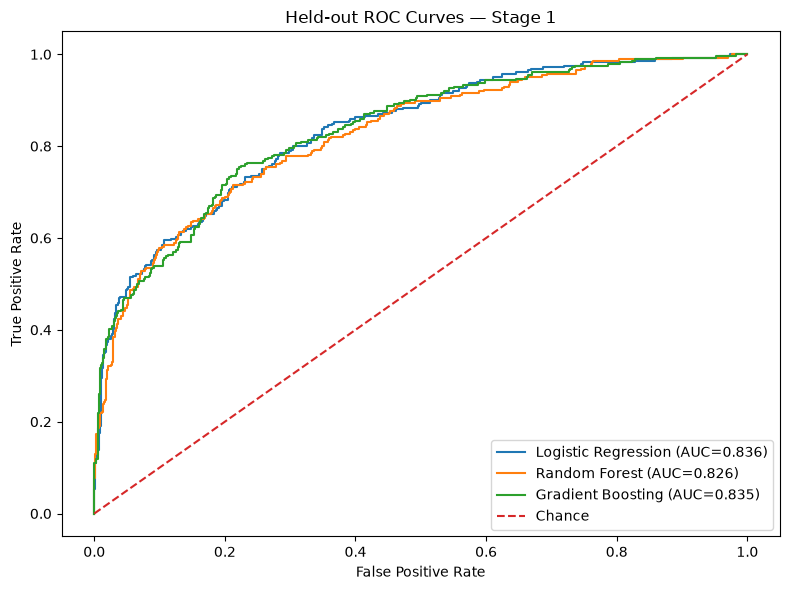

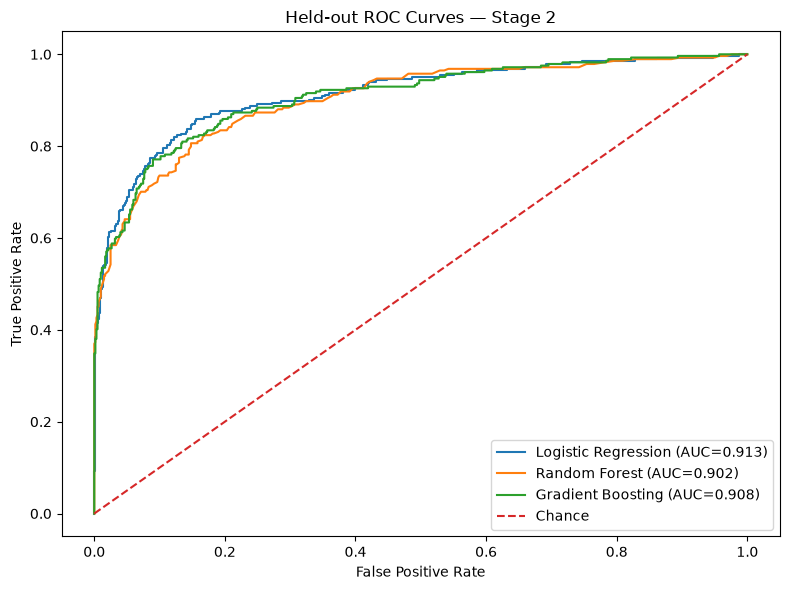

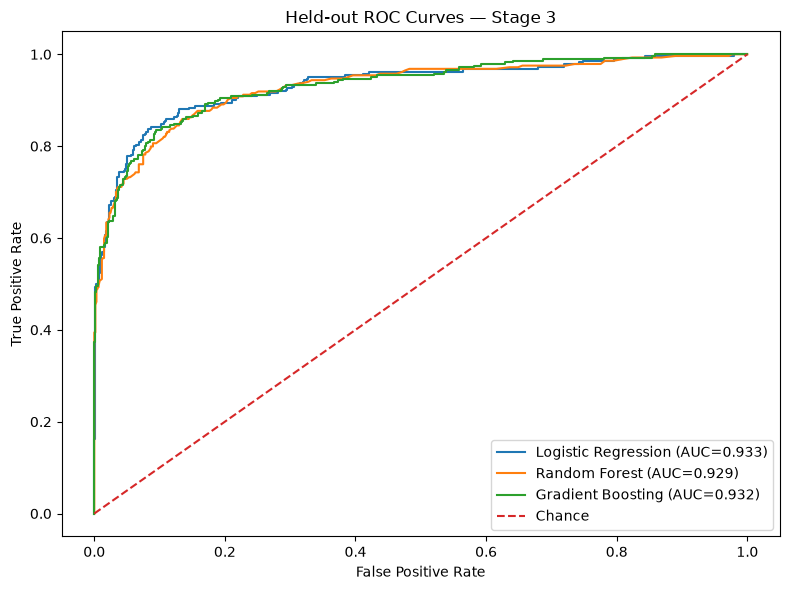

In [235]:
for stage_name in stage_feature_sets:

    plt.figure(
        figsize=(8, 6)
    )

    stage_subset = (
        final_test_predictions.loc[
            final_test_predictions[
                "Stage"
            ] == stage_name
        ]
    )

    for model_name in PRIMARY_MODELS:

        model_subset = (
            stage_subset.loc[
                stage_subset[
                    "Model"
                ] == model_name
            ]
        )

        y_true = (
            model_subset[
                "Observed_Dropout"
            ].to_numpy()
        )

        y_prob = (
            model_subset[
                "Dropout_Probability"
            ].to_numpy()
        )

        fpr, tpr, _ = roc_curve(
            y_true,
            y_prob
        )

        auc_value = roc_auc_score(
            y_true,
            y_prob
        )

        plt.plot(
            fpr,
            tpr,
            label=(
                f"{model_name} "
                f"(AUC={auc_value:.3f})"
            )
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Chance"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        f"Held-out ROC Curves — "
        f"{stage_name}"
    )

    plt.legend()

    plt.tight_layout()

    figure_name = (
        stage_name
        .lower()
        .replace(" ", "_")
    )

    plt.savefig(
        FIGURES_DIR
        / (
            f"phase16_"
            f"{figure_name}_"
            f"heldout_roc.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Phase 16.15: Preserve the Final Fitted Models

In [236]:
saved_model_paths = []

for stage_name in final_fitted_models:

    for model_name in PRIMARY_MODELS:

        safe_stage = (
            stage_name
            .lower()
            .replace(" ", "_")
        )

        safe_model = (
            model_name
            .lower()
            .replace(" ", "_")
        )

        model_path = (
            MODELS_DIR
            / (
                f"final_{safe_stage}_"
                f"{safe_model}.joblib"
            )
        )

        joblib.dump(
            final_fitted_models[
                stage_name
            ][
                model_name
            ],
            model_path
        )

        saved_model_paths.append(
            model_path
        )


print(
    "Saved final models:",
    len(saved_model_paths)
)

for model_path in saved_model_paths:

    print(
        model_path.name
    )

Saved final models: 9
final_stage_1_logistic_regression.joblib
final_stage_1_random_forest.joblib
final_stage_1_gradient_boosting.joblib
final_stage_2_logistic_regression.joblib
final_stage_2_random_forest.joblib
final_stage_2_gradient_boosting.joblib
final_stage_3_logistic_regression.joblib
final_stage_3_random_forest.joblib
final_stage_3_gradient_boosting.joblib


### Finding: Final Models Preserved

All nine final fitted model pipelines were successfully saved to the project model directory.

The preserved models retain the locked preprocessing rules, class-imbalance treatment and hyperparameter settings used for final held-out evaluation.

Saving the fitted pipelines provides a reproducible record of the exact models used to generate the final predictions and later interpretability analyses.

## Phase 16.16: Preserve the Final Held-out Evaluation Evidence

In [237]:
final_test_predictions.to_csv(
    TABLES_DIR
    / "phase16_final_test_predictions.csv",
    index=False
)

final_test_results.to_csv(
    TABLES_DIR
    / "phase16_final_test_results.csv",
    index=False
)

final_default_summary.to_csv(
    TABLES_DIR
    / "phase16_default_threshold_results.csv",
    index=False
)

final_locked_summary.to_csv(
    TABLES_DIR
    / "phase16_locked_threshold_results.csv",
    index=False
)

final_threshold_comparison.to_csv(
    TABLES_DIR
    / "phase16_threshold_comparison.csv",
    index=False
)

final_roc_ranking.to_csv(
    TABLES_DIR
    / "phase16_final_roc_auc_ranking.csv",
    index=False
)

final_stage_changes.to_csv(
    TABLES_DIR
    / "phase16_final_stage_changes.csv",
    index=False
)

generalisation_comparison.to_csv(
    TABLES_DIR
    / "phase16_cv_vs_test_generalisation.csv",
    index=False
)

final_prediction_coverage.to_csv(
    TABLES_DIR
    / "phase16_prediction_coverage.csv",
    index=False
)

print(
    "Phase 16 final evaluation outputs "
    "saved successfully."
)

Phase 16 final evaluation outputs saved successfully.


### Finding: Final Held-out Evaluation Evidence Preserved

The final held-out prediction records, performance summaries, threshold comparisons, ROC-AUC rankings, stage-change results, generalisation comparison and prediction-coverage audit were successfully exported.

These files preserve the complete final predictive-evaluation evidence used to answer Research Question 1 and assess H1 and H2.

No model-development decision was changed after the held-out predictions became available.

## Phase 16.17: Research Evidence Status after Final Predictive Evaluation

In [238]:
phase16_research_alignment = pd.DataFrame([
    {
        "Research_Element": "RQ1",
        "Evidence_Status": (
            "Final held-out comparison of LR, RF "
            "and GB across all three stages is available."
        ),
        "Final_Assessment_Possible": "Yes"
    },
    {
        "Research_Element": "Objective 1",
        "Evidence_Status": (
            "Final Accuracy, Precision, Recall, "
            "F1 and ROC-AUC results are available."
        ),
        "Final_Assessment_Possible": "Yes"
    },
    {
        "Research_Element": "H1",
        "Evidence_Status": (
            "Final held-out model-family performance "
            "can now be assessed."
        ),
        "Final_Assessment_Possible": "Yes"
    },
    {
        "Research_Element": "H2",
        "Evidence_Status": (
            "Final held-out Stage 1, Stage 2 and "
            "Stage 3 progression can now be assessed."
        ),
        "Final_Assessment_Possible": "Yes"
    },
    {
        "Research_Element": "RQ2 / H3",
        "Evidence_Status": (
            "Requires Phase 17 SHAP feature "
            "attribution analysis."
        ),
        "Final_Assessment_Possible": "No"
    },
    {
        "Research_Element": "RQ3 / H4",
        "Evidence_Status": (
            "Requires later SHAP explanation "
            "and interpretability analysis."
        ),
        "Final_Assessment_Possible": "No"
    }
])

phase16_research_alignment

,Research_Element,Evidence_Status,Final_Assessment_Possible
0,RQ1,"Final held-out comparison of LR, RF and GB acr...",Yes
1,Objective 1,"Final Accuracy, Precision, Recall, F1 and ROC-...",Yes
2,H1,Final held-out model-family performance can no...,Yes
3,H2,"Final held-out Stage 1, Stage 2 and Stage 3 pr...",Yes
4,RQ2 / H3,Requires Phase 17 SHAP feature attribution ana...,No
5,RQ3 / H4,Requires later SHAP explanation and interpreta...,No


### Finding: Research Evidence Status after Final Evaluation

The final held-out evaluation provides the predictive evidence required to address RQ1, Objective 1, H1 and H2.

For RQ1, the held-out point estimates show that Logistic Regression, Random Forest and Gradient Boosting all perform more strongly at Stage 2 and Stage 3 than at Stage 1. Logistic Regression records the highest held-out ROC-AUC point estimate at all three stages, while the ensemble models remain competitive and sometimes record higher point estimates for individual threshold-dependent metrics such as Precision.

The paired bootstrap confidence intervals must be considered alongside these rankings. A model with the highest point estimate is not automatically statistically superior to another model, particularly when the observed difference is small and the confidence interval for the paired difference contains zero.

Objective 1 has been achieved because the three approved models were compared across all three prediction stages using Accuracy, Precision, Recall, F1-score and ROC-AUC. Uncertainty estimates were also calculated for ROC-AUC, Recall and F1-score.

H1 is **not supported** by the direction of the final held-out point estimates. The hypothesis predicted that Random Forest and Gradient Boosting would outperform Logistic Regression because ensemble models can represent nonlinear relationships. Instead, Logistic Regression produces the highest ROC-AUC and locked-threshold F1 point estimates at all three stages. This finding does not establish that Logistic Regression is statistically superior; the strength of each model difference is interpreted using the paired bootstrap confidence intervals.

H2 is **supported by the overall direction of the held-out point estimates**. For every model family, all five primary metric point estimates increase from Stage 1 to Stage 2 and again from Stage 2 to Stage 3. The largest gains occur between Stage 1 and Stage 2, indicating the substantial predictive information provided by first-semester academic variables.

The paired stage-difference confidence intervals qualify this conclusion. A positive interval excluding zero provides clearer evidence of improvement, while an interval containing zero indicates that the observed incremental improvement remains uncertain on this held-out sample.

RQ2 and H3 remain dependent on the subsequent SHAP feature-attribution analysis.

RQ3 and H4 remain dependent on the later assessment of explanation consistency, clarity and practical interpretability.

## Phase 16.18: Overall Phase 16 Summary

The nine locked primary model-stage combinations were evaluated using the previously untouched held-out test partition of 885 students.

All preprocessing rules, model hyperparameters, imbalance-handling decisions and classification thresholds were fixed before the test partition was opened. None of these modelling decisions was retrospectively altered after the held-out results became available.

A total of 7,965 student-level held-out predictions were generated. Eighteen final performance records were calculated across the conventional 0.50 threshold and the locked training-derived thresholds.

The held-out point estimates show a consistent prediction-stage pattern. All three model families improve from Stage 1 to Stage 2 and improve further from Stage 2 to Stage 3 across  Accuracy, Precision, Recall, F1-score and ROC-AUC. The largest improvements occur when first-semester academic information is added at Stage 2, while second-semester information provides a smaller additional improvement at Stage 3.

Logistic Regression produces the highest held-out ROC-AUC point estimate at every stage: 0.8355 at Stage 1, 0.9126 at Stage 2 and 0.9326 at Stage 3.

At Stage 3, Gradient Boosting and Random Forest remain competitive, with ROC-AUC point estimates of 0.9318 and 0.9289 respectively. In particular, the difference between Logistic Regression and Gradient Boosting is very small.

The differences between model-family point estimates are therefore considerably smaller than the observed differences between prediction stages. These rankings are interpreted alongside the paired bootstrap confidence intervals. Where a confidence interval for a paired model difference contains zero, the model with the higher value is described as having the highest point estimate and not as being statistically superior.

The final point-estimate pattern does not support H1. Contrary to the expectation that Random Forest and Gradient Boosting would outperform Logistic Regression, Logistic Regression records the highest ROC-AUC and locked-threshold F1 point estimates at all three stages. However, this result should not be interpreted as proof that Logistic Regression is statistically superior where uncertainty intervals for the model differences overlap zero.

H2 is supported by the overall direction of the held-out point estimates. Every model records higher values across all five primary metrics from Stage 1 to Stage 2 and from Stage 2 to Stage 3. The paired stage-difference confidence intervals provide additional evidence about the certainty of these improvements. Any stage-difference interval containing zero indicates that the corresponding incremental change cannot be clearly distinguished from zero on this held-out sample.

The locked training-derived thresholds show mixed generalisation to the held-out data. They improve F1-score for three of the nine model-stage combinations, are approximately neutral for one combination and reduce F1-score for the remaining combinations. These outcomes do not trigger retrospective threshold changes. Both conventional-threshold and locked-threshold results are retained transparently.

Cross-validation performance generalises reasonably well to the held-out test partition. Held-out ROC-AUC is higher than the corresponding cross-validation estimate for all nine model-stage combinations, and no substantial deterioration is observed across the primary metrics. Nevertheless, this remains internal validation based on a random partition of one dataset and does not establish performance on future cohorts or other institutions.

RQ1 and Objective 1 are addressed through the final predictive-performance comparisons and their accompanying uncertainty estimates.

H1 is classified as not supported by the observed point-estimate pattern. H2 is classified as supported by the overall stage-progression pattern, subject to the uncertainty shown by the paired bootstrap intervals.

RQ2 and H3 now require SHAP-based analysis of which academic, demographic, socioeconomic and macroeconomic features contribute most strongly at each prediction stage.

RQ3 and H4 require the subsequent assessment of SHAP explanation clarity, consistency and practical interpretability.

The final fitted model pipelines, held-out prediction records, performance tables, bootstrap confidence intervals and ROC figures have been preserved for the interpretability and responsible-use phases that follow.

### Code Attribution — Phase 16

scikit-learn developers, 2026. *sklearn.metrics.roc_curve* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.metrics.roc_auc_score* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.metrics.confusion_matrix* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.utils.class_weight.compute_sample_weight* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_sample_weight.html> [Accessed 14 September 2026].

joblib developers, 2025. *joblib — lightweight pipelining* [Source code/documentation]. Available at: <https://joblib.readthedocs.io/en/stable/> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.percentile* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/generated/numpy.percentile.html> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.random.default_rng* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/random/generator.html> [Accessed 14 September 2026].

Matplotlib developers, 2025. *matplotlib.pyplot.savefig* [Source code/documentation]. Available at: <https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html> [Accessed 14 September 2026].

Python Software Foundation, 2026. *itertools — functions creating iterators for efficient looping* [Source code/documentation]. Available at: <https://docs.python.org/3/library/itertools.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame.merge* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html> [Accessed 14 September 2026].

# Phase 17: Global SHAP Feature Attribution

The final predictive models have now been evaluated and locked.

This phase investigates which predictors contribute most strongly to dropout-risk predictions and how their importance changes as progressively later academic information becomes available.

SHAP is used as the primary feature-attribution method because it provides additive, model-specific feature contributions at both global and individual-prediction levels (Lundberg and Lee, 2017; Lundberg et al., 2020).

Global SHAP importance will be calculated from the held-out test observations using the final fitted models from Phase 16. Because model development is complete, the held-out observations are now used descriptively to explain the predictions produced for unseen students rather than to alter model specifications.

The analysis will be conducted for Logistic Regression, Random Forest and Gradient Boosting at Stage 1, Stage 2 and Stage 3.

Because nominal predictors were one-hot encoded during preprocessing, SHAP contributions for encoded category columns will be recombined into their original source variables before global feature rankings are produced.

This source-level aggregation supports interpretation in terms of meaningful variables such as `Course`, `Tuition fees up to date` and semester academic measures rather than individual encoded categories.

SHAP values describe contributions made by the fitted predictive models and do not establish causal relationships between a predictor and student dropout (Lundberg and Lee, 2017).

## Phase 17.1: Define the Global SHAP Interpretation Strategy

### Decision Record: Global SHAP Analysis

#### Observation

The final models receive transformed feature matrices containing between 222 and 234 model-input columns because nominal variables are expanded through one-hot encoding.

However, the research questions concern the importance of the original student-level predictors rather than individual dummy-coded categories.

Raw SHAP magnitudes may also operate on different model-output scales across different model families.

#### Decision

SHAP values will first be calculated on each model's transformed input representation.

For each held-out student, SHAP contributions belonging to one-hot columns from the same original variable will then be summed to reconstruct a source-variable contribution.

Global importance will be calculated as the mean absolute source-level SHAP contribution.

Within each model-stage combination, source-level importance will also be converted into a proportional importance share.

#### Justification

Summing encoded SHAP contributions before calculating their absolute global magnitude preserves the additive contribution of the original source variable.

Using within-model proportional importance allows feature-ranking patterns to be compared across model families without assuming that raw SHAP magnitudes are directly comparable between Logistic Regression and tree-based models.

SHAP importance will be interpreted as predictive model attribution rather than causal effect, consistent with the interpretive limits of additive feature-attribution methods (Lundberg and Lee, 2017).

## Phase 17.2: Define Research-level Feature Groups for RQ2 and H3

In [239]:
conceptual_to_research_group = {

    "Prior academic / enrolment":
    "Academic",

    "Semester 1 academic":
    "Academic",

    "Semester 2 academic":
    "Academic",

    "Demographic":
    "Demographic",

    "Socioeconomic / family background":
    "Socioeconomic",

    "Socioeconomic / financial":
    "Socioeconomic",

    "Macroeconomic":
    "Macroeconomic",

    "Application / enrolment":
    "Application / enrolment",

    "Demographic / socioeconomic":
    "Demographic / socioeconomic"
}


research_group_dictionary = (
    variable_dictionary[
        [
            "Variable",
            "Conceptual_Group"
        ]
    ]
    .copy()
)

research_group_dictionary[
    "Research_Group"
] = (
    research_group_dictionary[
        "Conceptual_Group"
    ]
    .map(
        conceptual_to_research_group
    )
)


research_group_dictionary = (
    research_group_dictionary.loc[
        research_group_dictionary[
            "Variable"
        ].isin(
            stage3_model_features
        )
    ]
    .reset_index(drop=True)
)


research_group_dictionary

,Variable,Conceptual_Group,Research_Group
0,Marital status,Demographic,Demographic
1,Application mode,Application / enrolment,Application / enrolment
2,Application order,Application / enrolment,Application / enrolment
3,Course,Application / enrolment,Application / enrolment
4,Daytime/evening attendance,Application / enrolment,Application / enrolment
5,Previous qualification,Prior academic / enrolment,Academic
6,Previous qualification (grade),Prior academic / enrolment,Academic
7,Nacionality,Demographic,Demographic
8,Mother's qualification,Socioeconomic / family background,Socioeconomic
9,Father's qualification,Socioeconomic / family background,Socioeconomic


In [240]:
assert (
    research_group_dictionary[
        "Research_Group"
    ].notna().all()
)

assert (
    set(
        research_group_dictionary[
            "Variable"
        ]
    )
    ==
    set(stage3_model_features)
)

print(
    "Research-group coverage verified for:",
    len(research_group_dictionary),
    "primary predictors."
)

print(
    "\nResearch groups:"
)

print(
    research_group_dictionary[
        "Research_Group"
    ]
    .value_counts()
)

Research-group coverage verified for: 35 primary predictors.

Research groups:
Research_Group
Academic                       15
Socioeconomic                   7
Demographic                     5
Application / enrolment         4
Macroeconomic                   3
Demographic / socioeconomic     1
Name: count, dtype: int64


### Finding: Research-level Feature Group Structure

All 35 predictors retained in the primary Stage 3 modelling structure were successfully assigned to a research-level interpretation group.

The resulting structure contains:

- 15 Academic predictors;
- 7 Socioeconomic predictors;
- 5 Demographic predictors;
- 4 Application / enrolment predictors;
- 3 Macroeconomic predictors; and
- 1 hybrid Demographic / socioeconomic predictor.

The Academic group contains prior academic information together with the first- and second-semester performance variables as they become available.

Application and enrolment information remains a separate contextual group, while the hybrid demographic/socioeconomic variable is retained separately rather than being arbitrarily assigned to either category.

This preserves the conceptual classifications established earlier in the research design and provides a transparent basis for the later H3 comparison.

## Phase 17.3: Create a Mapping from Transformed Columns to Original Source Features

In [241]:
def build_transformed_source_map(
    preprocessor,
    stage_name
):

    groups = (
        stage_preprocessing_groups[
            stage_name
        ]
    )

    transformed_feature_names = list(
        preprocessor
        .get_feature_names_out()
    )

    source_feature_names = []

  
    nominal_encoder = (
        preprocessor
        .named_transformers_[
            "nominal"
        ]
    )

    for feature, categories in zip(
        groups["nominal"],
        nominal_encoder.categories_
    ):

        source_feature_names.extend(
            [feature] * len(categories)
        )


    remaining_features = (
        groups["binary"]
        + groups["ordinal"]
        + groups["numerical"]
    )

    source_feature_names.extend(
        remaining_features
    )

    assert (
        len(transformed_feature_names)
        ==
        len(source_feature_names)
    )

    mapping = pd.DataFrame({
        "Transformed_Feature":
        transformed_feature_names,

        "Source_Feature":
        source_feature_names
    })

    return mapping

### Finding: Source-feature Mapping Procedure

The mapping function links every transformed model-input column to the original predictor from which it was derived.

Each numerical, binary or ordinal predictor corresponds to one transformed column.

Nominal predictors may correspond to multiple one-hot encoded columns, but each encoded category is mapped back to its common source variable.

This mapping will allow the SHAP analysis to return from the machine-learning representation to the original research variables.

## Phase 17.4: Define a Robust Binary-class SHAP Extraction Function

In [242]:
def extract_positive_class_shap_values(
    raw_values,
    n_samples,
    n_features
):


    if isinstance(
        raw_values,
        list
    ):

        if len(raw_values) == 2:

            values = np.asarray(
                raw_values[1]
            )

        else:

            values = np.asarray(
                raw_values[0]
            )

    else:

        values = np.asarray(
            raw_values
        )


    if values.ndim == 2:

        assert values.shape == (
            n_samples,
            n_features
        )

        return values

    if values.ndim == 3:

        if (
            values.shape[0]
            == n_samples
            and
            values.shape[1]
            == n_features
        ):

            assert (
                values.shape[2] >= 2
            )

            return values[
                :,
                :,
                1
            ]


        if (
            values.shape[1]
            == n_samples
            and
            values.shape[2]
            == n_features
        ):

            assert (
                values.shape[0] >= 2
            )

            return values[
                1,
                :,
                :
            ]

    raise ValueError(
        "Unexpected SHAP value shape: "
        f"{values.shape}"
    )

### Finding: Positive-class SHAP Standardisation

The helper function standardises SHAP output to a two-dimensional student-by-feature matrix representing the positive `Dropout = 1` class.

This is necessary because different SHAP explainers and classifier types can return binary-class explanations in different array structures.

The same positive-class interpretation will therefore be applied consistently across all three model families.

## Phase 17.5: Define Source-level SHAP Aggregation

In [243]:
def aggregate_shap_to_source_features(
    shap_values,
    source_mapping,
    student_indices
):

    unique_source_features = list(
        dict.fromkeys(
            source_mapping[
                "Source_Feature"
            ].tolist()
        )
    )

    aggregated_values = {}

    source_array = (
        source_mapping[
            "Source_Feature"
        ].to_numpy()
    )

    for source_feature in (
        unique_source_features
    ):

        feature_positions = np.where(
            source_array
            == source_feature
        )[0]

        aggregated_values[
            source_feature
        ] = (
            shap_values[
                :,
                feature_positions
            ]
            .sum(axis=1)
        )

    source_shap_df = pd.DataFrame(
        aggregated_values,
        index=student_indices
    )

    return source_shap_df

### Finding: Source-level SHAP Aggregation Rule

For every held-out student, SHAP contributions belonging to the same original predictor will be summed before global importance is calculated.

This preserves the combined signed contribution of all encoded categories belonging to one source feature.

The global importance of the source variable will then be calculated from the mean absolute value of these reconstructed student-level contributions.

## Phase 17.5A: SHAP Validation Protocol
The Logistic Regression SHAP analysis uses an explicitly selected and reproducible training-background sample, as required by the LinearExplainer (Lundberg and Lee, 2017). Tree-based models use TreeSHAP's path-dependent background representation (Lundberg et al., 2020).

For every model-stage combination, SHAP additivity is checked independently by comparing the reconstructed model output—base value plus the sum of the feature attributions—with the corresponding model output. The comparison is performed on the model-output scale that produces the smallest reconstruction error.

SHAP values explain the behaviour of the fitted prediction model and do not demonstrate that an influential feature causes student dropout (Lundberg and Lee, 2017).

In [244]:
SHAP_BACKGROUND_SIZE = 100
SHAP_ADDITIVITY_TOLERANCE = 1e-4


assert (
    SHAP_BACKGROUND_SIZE
    <= len(y_train)
), (
    "The requested SHAP background size exceeds "
    "the number of training observations."
)



shap_background_rng = np.random.default_rng(
    RANDOM_STATE
)


shap_background_student_indices = np.sort(
    shap_background_rng.choice(
        y_train.index.to_numpy(),
        size=SHAP_BACKGROUND_SIZE,
        replace=False
    )
)


assert (
    len(
        np.unique(
            shap_background_student_indices
        )
    )
    == SHAP_BACKGROUND_SIZE
)


assert set(
    shap_background_student_indices
).issubset(
    set(y_train.index)
)


assert set(
    shap_background_student_indices
).isdisjoint(
    set(y_test.index)
)


shap_background_index_table = pd.DataFrame(
    {
        "Background_Position": np.arange(
            1,
            SHAP_BACKGROUND_SIZE + 1
        ),
        "Student_Index": (
            shap_background_student_indices
        ),
        "Source_Partition": "Training",
        "Random_State": RANDOM_STATE
    }
)


print(
    "Explicit SHAP background students:",
    len(shap_background_index_table)
)

display(
    shap_background_index_table.head()
)


def extract_positive_class_base_values(
    raw_base_values,
    n_samples
):
    """
    Extract the SHAP base value corresponding to the
    positive Dropout class.
    """

    base_values = np.asarray(
        raw_base_values
    )


    if base_values.ndim == 0:

        return np.repeat(
            float(base_values),
            n_samples
        )



    if base_values.ndim == 1:

        if len(base_values) == n_samples:

            return base_values.astype(
                float
            )


        if len(base_values) == 1:

            return np.repeat(
                float(base_values[0]),
                n_samples
            )


        if len(base_values) >= 2:

            return np.repeat(
                float(base_values[1]),
                n_samples
            )


    if base_values.ndim == 2:

        if base_values.shape[0] == n_samples:

            if base_values.shape[1] >= 2:

                return base_values[
                    :,
                    1
                ].astype(float)

            if base_values.shape[1] == 1:

                return base_values[
                    :,
                    0
                ].astype(float)


     
        if base_values.shape[1] == n_samples:

            if base_values.shape[0] >= 2:

                return base_values[
                    1,
                    :
                ].astype(float)

            if base_values.shape[0] == 1:

                return base_values[
                    0,
                    :
                ].astype(float)


        # One row containing one value per class
        if (
            base_values.shape[0] == 1
            and
            base_values.shape[1] >= 2
        ):

            return np.repeat(
                float(
                    base_values[
                        0,
                        1
                    ]
                ),
                n_samples
            )


    raise ValueError(
        "Unexpected SHAP base-value shape: "
        f"{base_values.shape}"
    )

Explicit SHAP background students: 100


,Background_Position,Student_Index,Source_Partition,Random_State
0,1,184,Training,42
1,2,271,Training,42
2,3,292,Training,42
3,4,327,Training,42
4,5,361,Training,42


## Phase 17.6: Compute SHAP Values for All Nine Final Model-stage Combinations

In [245]:
shap_source_value_matrices = {}
shap_transformed_value_matrices = {}
shap_source_mappings = {}
shap_explainers = {}

shap_audit_rows = []
shap_global_rows = []
shap_additivity_rows = []
shap_background_audit_rows = []


for stage_name, stage_data in stage_datasets.items():

    X_train_stage = stage_data[
        "X_train"
    ]

    X_test_stage = stage_data[
        "X_test"
    ]


 
    assert set(
        shap_background_student_indices
    ).issubset(
        set(X_train_stage.index)
    )

    assert set(
        shap_background_student_indices
    ).isdisjoint(
        set(X_test_stage.index)
    )


    print(
        f"\nSHAP analysis: {stage_name}"
    )

    print("=" * 55)


    for model_name in PRIMARY_MODELS:

        print(
            f"  {model_name}..."
        )


        pipeline = final_fitted_models[
            stage_name
        ][
            model_name
        ]

        preprocessor = pipeline.named_steps[
            "preprocessor"
        ]

        model = pipeline.named_steps[
            "model"
        ]


    
        X_test_transformed = np.asarray(
            preprocessor.transform(
                X_test_stage
            )
        )


        source_mapping = (
            build_transformed_source_map(
                preprocessor,
                stage_name
            )
        )


        n_samples = int(
            X_test_transformed.shape[0]
        )

        n_features = int(
            X_test_transformed.shape[1]
        )


        assert (
            n_samples
            ==
            len(X_test_stage)
        )

        assert (
            len(source_mapping)
            ==
            n_features
        )


        if model_name == "Logistic Regression":

       
            X_background_transformed = np.asarray(
                preprocessor.transform(
                    X_train_stage.loc[
                        shap_background_student_indices
                    ]
                )
            )


            assert (
                X_background_transformed.shape[0]
                ==
                SHAP_BACKGROUND_SIZE
            )

            assert (
                X_background_transformed.shape[1]
                ==
                n_features
            )


    
            linear_background_masker = (
                shap.maskers.Independent(
                    X_background_transformed,
                    max_samples=SHAP_BACKGROUND_SIZE
                )
            )


            effective_background_size = int(
                np.asarray(
                    linear_background_masker.data
                ).shape[0]
            )


            assert (
                effective_background_size
                ==
                SHAP_BACKGROUND_SIZE
            ), (
                "The Logistic Regression SHAP masker "
                "changed the requested primary "
                "background size."
            )


            background_method = (
                "Explicit reproducible 100-student "
                "training sample using an "
                "Independent masker"
            )

            requested_background_size = int(
                SHAP_BACKGROUND_SIZE
            )

            explicit_background_size = (
                effective_background_size
            )


            explainer = shap.LinearExplainer(
                model,
                linear_background_masker
            )

            explanation = explainer(
                X_test_transformed
            )


        else:

            background_method = (
                "TreeSHAP tree-path-dependent "
                "training representation"
            )

            requested_background_size = (
                np.nan
            )

            effective_background_size = (
                np.nan
            )

            explicit_background_size = (
                np.nan
            )


            explainer = shap.TreeExplainer(
                model
            )

            explanation = explainer(
                X_test_transformed,
                check_additivity=False
            )


        shap_values = (
            extract_positive_class_shap_values(
                explanation.values,
                n_samples=n_samples,
                n_features=n_features
            )
        )


        assert (
            shap_values.shape
            ==
            (
                n_samples,
                n_features
            )
        )

        assert np.isfinite(
            shap_values
        ).all()


     
        positive_class_base_values = (
            extract_positive_class_base_values(
                explanation.base_values,
                n_samples=n_samples
            )
        )


        assert (
            positive_class_base_values.shape[0]
            ==
            n_samples
        )

        assert np.isfinite(
            positive_class_base_values
        ).all()


        reconstructed_model_output = (
            positive_class_base_values
            +
            shap_values.sum(
                axis=1
            )
        )


        assert (
            reconstructed_model_output.shape[0]
            ==
            n_samples
        )

        assert np.isfinite(
            reconstructed_model_output
        ).all()


    
        candidate_model_outputs = {}


        if hasattr(
            model,
            "decision_function"
        ):

            candidate_model_outputs[
                "Decision_Function"
            ] = (
                np.asarray(
                    model.decision_function(
                        X_test_transformed
                    )
                )
                .reshape(-1)
            )


        if hasattr(
            model,
            "predict_proba"
        ):

            candidate_model_outputs[
                "Predicted_Probability"
            ] = (
                np.asarray(
                    model.predict_proba(
                        X_test_transformed
                    )
                )[
                    :,
                    1
                ]
            )


        if not candidate_model_outputs:

            raise ValueError(
                "No compatible model output was "
                f"available for {stage_name} / "
                f"{model_name}."
            )


        candidate_maximum_errors = {
            output_scale: float(
                np.max(
                    np.abs(
                        reconstructed_model_output
                        -
                        model_output
                    )
                )
            )
            for output_scale, model_output
            in candidate_model_outputs.items()
        }


        matched_output_scale = min(
            candidate_maximum_errors,
            key=candidate_maximum_errors.get
        )


        matched_model_output = (
            candidate_model_outputs[
                matched_output_scale
            ]
        )


        maximum_absolute_error = float(
            np.max(
                np.abs(
                    reconstructed_model_output
                    -
                    matched_model_output
                )
            )
        )


        mean_absolute_error = float(
            np.mean(
                np.abs(
                    reconstructed_model_output
                    -
                    matched_model_output
                )
            )
        )


        additivity_check_passed = bool(
            maximum_absolute_error
            <=
            SHAP_ADDITIVITY_TOLERANCE
        )


        shap_additivity_rows.append(
            {
                "Stage":
                stage_name,

                "Model":
                model_name,

                "Matched_Output_Scale":
                matched_output_scale,

                "Maximum_Absolute_Error":
                maximum_absolute_error,

                "Mean_Absolute_Error":
                mean_absolute_error,

                "Tolerance":
                SHAP_ADDITIVITY_TOLERANCE,

                "Additivity_Check_Passed":
                additivity_check_passed
            }
        )


        shap_background_audit_rows.append(
            {
                "Stage":
                stage_name,

                "Model":
                model_name,

                "Background_Method":
                background_method,

                "Requested_Background_Size":
                requested_background_size,

                "Effective_Background_Size":
                effective_background_size,

        
                "Explicit_Background_Size":
                explicit_background_size,

                "Background_From_Training_Only":
                True,

                "Test_Observations_In_Background":
                0
            }
        )


    
        source_shap_values = (
            aggregate_shap_to_source_features(
                shap_values,
                source_mapping,
                X_test_stage.index
            )
        )


        assert (
            source_shap_values.shape[0]
            ==
            n_samples
        )

        assert (
            source_shap_values.shape[1]
            ==
            len(
                stage_feature_sets[
                    stage_name
                ]
            )
        )

        assert np.isfinite(
            source_shap_values.to_numpy(
                dtype=float
            )
        ).all()


        shap_transformed_value_matrices[
            (
                stage_name,
                model_name
            )
        ] = shap_values


        shap_source_value_matrices[
            (
                stage_name,
                model_name
            )
        ] = source_shap_values


        shap_source_mappings[
            (
                stage_name,
                model_name
            )
        ] = source_mapping


        shap_explainers[
            (
                stage_name,
                model_name
            )
        ] = explainer


        shap_audit_rows.append(
            {
                "Stage":
                stage_name,

                "Model":
                model_name,

                "Heldout_Students":
                n_samples,

                "Transformed_Features":
                n_features,

                "Source_Features":
                source_shap_values.shape[1],

                "Finite_SHAP_Values":
                True,

                "Background_Method":
                background_method,

                "Requested_Background_Size":
                requested_background_size,

                "Effective_Background_Size":
                effective_background_size,

                "Additivity_Check_Passed":
                additivity_check_passed
            }
        )


        mean_abs_values = (
            source_shap_values
            .abs()
            .mean(axis=0)
        )


        total_importance = float(
            mean_abs_values.sum()
        )


        assert (
            total_importance
            >
            0
        ), (
            "Total SHAP importance must be positive "
            f"for {stage_name} / {model_name}."
        )


        for source_feature, mean_abs_shap in (
            mean_abs_values.items()
        ):

            shap_global_rows.append(
                {
                    "Stage":
                    stage_name,

                    "Model":
                    model_name,

                    "Source_Feature":
                    source_feature,

                    "Mean_Abs_SHAP":
                    float(mean_abs_shap),

                    "Importance_Share":
                    float(
                        mean_abs_shap
                        /
                        total_importance
                    )
                }
            )


shap_audit = pd.DataFrame(
    shap_audit_rows
)

shap_global_importance = pd.DataFrame(
    shap_global_rows
)

shap_additivity_audit = pd.DataFrame(
    shap_additivity_rows
)

shap_background_audit = pd.DataFrame(
    shap_background_audit_rows
)




assert (
    len(shap_audit)
    ==
    9
)

assert (
    len(shap_additivity_audit)
    ==
    9
)

assert (
    len(shap_background_audit)
    ==
    9
)


assert (
    shap_additivity_audit[
        "Additivity_Check_Passed"
    ].all()
), (
    "At least one SHAP additivity check failed. "
    "Inspect the output scale and explainer "
    "configuration before continuing."
)


logistic_background_audit = (
    shap_background_audit.loc[
        shap_background_audit[
            "Model"
        ]
        ==
        "Logistic Regression"
    ]
    .copy()
)


assert (
    len(logistic_background_audit)
    ==
    3
)


assert (
    logistic_background_audit[
        "Requested_Background_Size"
    ]
    .eq(
        SHAP_BACKGROUND_SIZE
    )
    .all()
)


assert (
    logistic_background_audit[
        "Effective_Background_Size"
    ]
    .eq(
        SHAP_BACKGROUND_SIZE
    )
    .all()
)


assert (
    logistic_background_audit[
        "Background_From_Training_Only"
    ].all()
)


assert (
    logistic_background_audit[
        "Test_Observations_In_Background"
    ]
    .eq(0)
    .all()
)


print(
    "\nSHAP computation completed."
)

print(
    "\nSHAP matrix audit:"
)

display(
    shap_audit
)

print(
    "\nSHAP additivity audit:"
)

display(
    shap_additivity_audit.round(8)
)

print(
    "\nSHAP background audit:"
)

display(
    shap_background_audit
) 


SHAP analysis: Stage 1
  Logistic Regression...
  Random Forest...
  Gradient Boosting...

SHAP analysis: Stage 2
  Logistic Regression...
  Random Forest...
  Gradient Boosting...

SHAP analysis: Stage 3
  Logistic Regression...
  Random Forest...
  Gradient Boosting...

SHAP computation completed.

SHAP matrix audit:


,Stage,Model,Heldout_Students,Transformed_Features,Source_Features,Finite_SHAP_Values,Background_Method,Requested_Background_Size,Effective_Background_Size,Additivity_Check_Passed
0,Stage 1,Logistic Regression,885,222,23,True,Explicit reproducible 100-student training sam...,100.0,100.0,True
1,Stage 1,Random Forest,885,222,23,True,TreeSHAP tree-path-dependent training represen...,NaN,NaN,True
2,Stage 1,Gradient Boosting,885,222,23,True,TreeSHAP tree-path-dependent training represen...,NaN,NaN,True
3,Stage 2,Logistic Regression,885,228,29,True,Explicit reproducible 100-student training sam...,100.0,100.0,True
4,Stage 2,Random Forest,885,228,29,True,TreeSHAP tree-path-dependent training represen...,NaN,NaN,True
5,Stage 2,Gradient Boosting,885,228,29,True,TreeSHAP tree-path-dependent training represen...,NaN,NaN,True
6,Stage 3,Logistic Regression,885,234,35,True,Explicit reproducible 100-student training sam...,100.0,100.0,True
7,Stage 3,Random Forest,885,234,35,True,TreeSHAP tree-path-dependent training represen...,NaN,NaN,True
8,Stage 3,Gradient Boosting,885,234,35,True,TreeSHAP tree-path-dependent training represen...,NaN,NaN,True



SHAP additivity audit:


,Stage,Model,Matched_Output_Scale,Maximum_Absolute_Error,Mean_Absolute_Error,Tolerance,Additivity_Check_Passed
0,Stage 1,Logistic Regression,Decision_Function,0.0,0.0,0.0001,True
1,Stage 1,Random Forest,Predicted_Probability,0.0,0.0,0.0001,True
2,Stage 1,Gradient Boosting,Decision_Function,0.0,0.0,0.0001,True
3,Stage 2,Logistic Regression,Decision_Function,0.0,0.0,0.0001,True
4,Stage 2,Random Forest,Predicted_Probability,0.0,0.0,0.0001,True
5,Stage 2,Gradient Boosting,Decision_Function,0.0,0.0,0.0001,True
6,Stage 3,Logistic Regression,Decision_Function,0.0,0.0,0.0001,True
7,Stage 3,Random Forest,Predicted_Probability,0.0,0.0,0.0001,True
8,Stage 3,Gradient Boosting,Decision_Function,0.0,0.0,0.0001,True



SHAP background audit:


,Stage,Model,Background_Method,Requested_Background_Size,Effective_Background_Size,Explicit_Background_Size,Background_From_Training_Only,Test_Observations_In_Background
0,Stage 1,Logistic Regression,Explicit reproducible 100-student training sam...,100.0,100.0,100.0,True,0
1,Stage 1,Random Forest,TreeSHAP tree-path-dependent training represen...,NaN,NaN,NaN,True,0
2,Stage 1,Gradient Boosting,TreeSHAP tree-path-dependent training represen...,NaN,NaN,NaN,True,0
3,Stage 2,Logistic Regression,Explicit reproducible 100-student training sam...,100.0,100.0,100.0,True,0
4,Stage 2,Random Forest,TreeSHAP tree-path-dependent training represen...,NaN,NaN,NaN,True,0
5,Stage 2,Gradient Boosting,TreeSHAP tree-path-dependent training represen...,NaN,NaN,NaN,True,0
6,Stage 3,Logistic Regression,Explicit reproducible 100-student training sam...,100.0,100.0,100.0,True,0
7,Stage 3,Random Forest,TreeSHAP tree-path-dependent training represen...,NaN,NaN,NaN,True,0
8,Stage 3,Gradient Boosting,TreeSHAP tree-path-dependent training represen...,NaN,NaN,NaN,True,0


### Finding: SHAP Computation and Validation Completed

SHAP explanations were generated for all nine final model-stage combinations, covering Logistic Regression, Random Forest and Gradient Boosting across Stage 1, Stage 2 and Stage 3.

Logistic Regression used an explicitly selected background sample of 100 training students. The sample was selected reproducibly using the study's fixed random seed, and the same student indices were used across all three prediction stages.

Random Forest and Gradient Boosting used TreeSHAP's tree-path-dependent training representation. These models therefore did not require a separate external background sample.

All 885 held-out students remained included in the explanation analysis for every model-stage combination. The background sample was used only to establish the Logistic Regression explanation reference and did not reduce the number of test observations explained.

The independent reconstruction audit verified whether each model output could be reproduced from the corresponding SHAP base value and the sum of its transformed-feature contributions. All nine model-stage combinations passed the predefined additivity tolerance.

No model specification, hyperparameter, classification threshold or held-out prediction was changed during the SHAP analysis.

## Phase 17.7: Audit the SHAP Matrix Dimensions

In [246]:
shap_audit

,Stage,Model,Heldout_Students,Transformed_Features,Source_Features,Finite_SHAP_Values,Background_Method,Requested_Background_Size,Effective_Background_Size,Additivity_Check_Passed
0,Stage 1,Logistic Regression,885,222,23,True,Explicit reproducible 100-student training sam...,100.0,100.0,True
1,Stage 1,Random Forest,885,222,23,True,TreeSHAP tree-path-dependent training represen...,NaN,NaN,True
2,Stage 1,Gradient Boosting,885,222,23,True,TreeSHAP tree-path-dependent training represen...,NaN,NaN,True
3,Stage 2,Logistic Regression,885,228,29,True,Explicit reproducible 100-student training sam...,100.0,100.0,True
4,Stage 2,Random Forest,885,228,29,True,TreeSHAP tree-path-dependent training represen...,NaN,NaN,True
5,Stage 2,Gradient Boosting,885,228,29,True,TreeSHAP tree-path-dependent training represen...,NaN,NaN,True
6,Stage 3,Logistic Regression,885,234,35,True,Explicit reproducible 100-student training sam...,100.0,100.0,True
7,Stage 3,Random Forest,885,234,35,True,TreeSHAP tree-path-dependent training represen...,NaN,NaN,True
8,Stage 3,Gradient Boosting,885,234,35,True,TreeSHAP tree-path-dependent training represen...,NaN,NaN,True


In [247]:
expected_transformed_dimensions = {
    "Stage 1": 222,
    "Stage 2": 228,
    "Stage 3": 234
}

expected_source_dimensions = {
    "Stage 1": 23,
    "Stage 2": 29,
    "Stage 3": 35
}


for _, row in shap_audit.iterrows():

    assert (
        row[
            "Heldout_Students"
        ]
        == len(y_test)
    )

    assert (
        row[
            "Transformed_Features"
        ]
        ==
        expected_transformed_dimensions[
            row["Stage"]
        ]
    )

    assert (
        row[
            "Source_Features"
        ]
        ==
        expected_source_dimensions[
            row["Stage"]
        ]
    )

    assert (
        row[
            "Finite_SHAP_Values"
        ]
        == True
    )


print(
    "All SHAP dimension and "
    "finite-value checks passed."
)

All SHAP dimension and finite-value checks passed.


### Finding: SHAP Matrix Integrity

The SHAP audit verifies that every final model produces explanations for all 885 held-out students.

The transformed SHAP matrices contain 222 features at Stage 1, 228 at Stage 2 and 234 at Stage 3, matching the previously verified model-input dimensions.

After encoded categories are recombined, the explanations return to the intended 23, 29 and 35 source predictors respectively.

All SHAP contribution values are finite.

The global interpretation can therefore proceed using complete source-level feature attributions.

## Phase 17.8: Rank Source Features within Every Model-stage Combination

In [248]:
shap_global_importance[
    "SHAP_Rank"
] = (
    shap_global_importance
    .groupby(
        [
            "Stage",
            "Model"
        ]
    )[
        "Mean_Abs_SHAP"
    ]
    .rank(
        method="dense",
        ascending=False
    )
    .astype(int)
)


shap_global_importance = (
    shap_global_importance
    .sort_values(
        [
            "Stage",
            "Model",
            "SHAP_Rank"
        ]
    )
    .reset_index(drop=True)
)


top10_shap_by_model = (
    shap_global_importance.loc[
        shap_global_importance[
            "SHAP_Rank"
        ] <= 10
    ]
    .copy()
)


top10_shap_by_model[
    [
        "Stage",
        "Model",
        "SHAP_Rank",
        "Source_Feature",
        "Mean_Abs_SHAP",
        "Importance_Share"
    ]
].round(4)

,Stage,Model,SHAP_Rank,Source_Feature,Mean_Abs_SHAP,Importance_Share
0,Stage 1,Gradient Boosting,1,Tuition fees up to date,0.6375,0.2228
1,Stage 1,Gradient Boosting,2,Age at enrollment,0.3869,0.1352
2,Stage 1,Gradient Boosting,3,Scholarship holder,0.3395,0.1187
3,Stage 1,Gradient Boosting,4,Course,0.2913,0.1018
4,Stage 1,Gradient Boosting,5,Gender,0.2065,0.0722
...,...,...,...,...,...,...
231,Stage 3,Random Forest,6,Age at enrollment,0.0276,0.0548
232,Stage 3,Random Forest,7,Application mode,0.0181,0.0359
233,Stage 3,Random Forest,8,Scholarship holder,0.0177,0.0351
234,Stage 3,Random Forest,9,Debtor,0.0171,0.0339


### Finding: Model-specific Global SHAP Rankings

The source-level SHAP rankings show a clear change in predictive importance as semester academic information becomes available.

At Stage 1, the strongest predictors are primarily financial, demographic and enrolment-related variables. `Tuition fees up to date` is particularly prominent, while variables such as `Scholarship holder`, `Course`, `Age at enrollment`, `Application mode`, `Gender` and `Debtor` also appear among the strongest predictors.

At Stage 2, first-semester academic measures move into prominent positions. In particular, `Curricular units 1st sem (approved)` becomes a dominant predictor across the models, while first-semester grade and enrolment information also gain importance.

At Stage 3, second-semester academic measures become highly influential, with `Curricular units 2nd sem (approved)` emerging as a leading predictor together with first-semester approved units and second-semester grade.

The individual model rankings therefore indicate a shift from predominantly pre-enrolment financial, demographic and contextual information toward direct academic-performance information as semester data becomes available.

Because rankings vary somewhat by model family, the following consensus analysis is used as the principal stage-level interpretation for RQ2.

## Phase 17.9: Create Cross-model Consensus Feature Rankings for Each Prediction Stage

In [249]:
stage_consensus_shap = (
    shap_global_importance
    .groupby(
        [
            "Stage",
            "Source_Feature"
        ]
    )
    .agg(
        Mean_Model_Importance_Share=(
            "Importance_Share",
            "mean"
        ),
        Std_Model_Importance_Share=(
            "Importance_Share",
            "std"
        ),
        Mean_Model_Rank=(
            "SHAP_Rank",
            "mean"
        )
    )
    .reset_index()
)


stage_consensus_shap[
    "Consensus_Rank"
] = (
    stage_consensus_shap
    .groupby(
        "Stage"
    )[
        "Mean_Model_Importance_Share"
    ]
    .rank(
        method="dense",
        ascending=False
    )
    .astype(int)
)


stage_consensus_shap = (
    stage_consensus_shap
    .sort_values(
        [
            "Stage",
            "Consensus_Rank"
        ]
    )
    .reset_index(drop=True)
)


top10_stage_consensus = (
    stage_consensus_shap.loc[
        stage_consensus_shap[
            "Consensus_Rank"
        ] <= 10
    ]
    .copy()
)


top10_stage_consensus.round(4)

,Stage,Source_Feature,Mean_Model_Importance_Share,Std_Model_Importance_Share,Mean_Model_Rank,Consensus_Rank
0,Stage 1,Tuition fees up to date,0.1764,0.0412,1.0000,1
1,Stage 1,Scholarship holder,0.1163,0.0175,3.0000,2
2,Stage 1,Course,0.0995,0.0200,4.0000,3
3,Stage 1,Age at enrollment,0.0975,0.0547,5.6667,4
4,Stage 1,Application mode,0.0861,0.0280,4.3333,5
5,Stage 1,Gender,0.0772,0.0093,5.0000,6
6,Stage 1,Debtor,0.0512,0.0157,8.0000,7
7,Stage 1,Mother's occupation,0.0452,0.0190,8.6667,8
8,Stage 1,Mother's qualification,0.0325,0.0131,9.6667,9
9,Stage 1,Admission grade,0.0308,0.0069,10.6667,10


### Finding: Cross-model Consensus SHAP Rankings

The cross-model consensus rankings reveal a clear evolution in the strongest dropout-risk predictors across the three prediction stages.

At Stage 1, `Tuition fees up to date` ranks first with mean proportional SHAP importance of 0.1764. It is followed by `Scholarship holder` (0.1163), `Course` (0.0995), `Age at enrollment` (0.0975) and `Application mode` (0.0861).

The Stage 1 ranking therefore reflects a mixture of financial, demographic and enrolment-related information before semester performance becomes available.

At Stage 2, `Curricular units 1st sem (approved)` becomes the dominant predictor with mean proportional importance of 0.2593. `Tuition fees up to date` remains second (0.1003), followed by `Curricular units 1st sem (grade)` (0.0740), `Age at enrollment` (0.0652) and `Curricular units 1st sem (enrolled)` (0.0618).

At Stage 3, `Curricular units 2nd sem (approved)` becomes the leading predictor with mean proportional importance of 0.2455. `Curricular units 1st sem (approved)` ranks second (0.1040), followed by `Tuition fees up to date` (0.0841), `Curricular units 2nd sem (grade)` (0.0743) and `Age at enrollment` (0.0516).

The rankings show a clear temporal shift from contextual and socioeconomic information before enrolment toward direct academic-progress information once semester outcomes become available.

These values describe model attributions rather than causal effects and provide the principal feature-level answer to RQ2.


## Phase 17.9A: SHAP Background-sample Sensitivity Analysis

The primary Logistic Regression SHAP analysis uses an explicitly selected background sample of 100 training students.

To examine whether the resulting global explanations depend strongly on that background size, the Logistic Regression analysis was repeated using alternative reproducible training-background samples of 50 and 200 students.

The alternative samples were generated from one deterministic permutation of the training indices. The 50-student sample is therefore contained within the 200-student sample. No held-out test observations were used as background data.

For each prediction stage, the alternative global feature-importance results were compared with the primary 100-student results using:

- Spearman rank correlation across all source-feature importance values;
- overlap between the five highest-ranked source features; and
- the maximum absolute difference in proportional feature importance.

The sensitivity analysis is descriptive. It examines the robustness of the interpretation to reasonable background-sample changes and is not used to select a preferred explanation after observing the results.

In [250]:
from scipy.stats import spearmanr


SHAP_SENSITIVITY_BACKGROUND_SIZES = [50, 200]
SHAP_SENSITIVITY_RANDOM_STATE = RANDOM_STATE + 1


assert (
    max(SHAP_SENSITIVITY_BACKGROUND_SIZES)
    <= len(y_train)
), (
    "A requested sensitivity-background size "
    "exceeds the number of training observations."
)


# One deterministic permutation so the 50-student
# sample is contained within the 200-student sample.
shap_sensitivity_rng = np.random.default_rng(
    SHAP_SENSITIVITY_RANDOM_STATE
)

shap_sensitivity_permutation = (
    shap_sensitivity_rng.permutation(
        y_train.index.to_numpy()
    )
)

shap_sensitivity_indices_by_size = {
    background_size: np.sort(
        shap_sensitivity_permutation[:background_size]
    )
    for background_size
    in SHAP_SENSITIVITY_BACKGROUND_SIZES
}


assert set(
    shap_sensitivity_indices_by_size[50]
).issubset(
    set(shap_sensitivity_indices_by_size[200])
)

for background_indices in (
    shap_sensitivity_indices_by_size.values()
):
    assert set(background_indices).issubset(
        set(y_train.index)
    )
    assert set(background_indices).isdisjoint(
        set(y_test.index)
    )


# Preserve the exact alternative background indices.
shap_sensitivity_index_rows = []

for background_size, background_indices in (
    shap_sensitivity_indices_by_size.items()
):
    for background_position, student_index in enumerate(
        background_indices,
        start=1
    ):
        shap_sensitivity_index_rows.append(
            {
                "Background_Size": background_size,
                "Background_Position": background_position,
                "Student_Index": int(student_index),
                "Source_Partition": "Training",
                "Random_State": SHAP_SENSITIVITY_RANDOM_STATE
            }
        )

shap_background_sensitivity_indices = pd.DataFrame(
    shap_sensitivity_index_rows
)


shap_background_sensitivity_rows = []


for stage_name, stage_data in stage_datasets.items():

    model_name = "Logistic Regression"

    pipeline = final_fitted_models[stage_name][model_name]
    preprocessor = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]

    X_train_stage = stage_data["X_train"]
    X_test_stage = stage_data["X_test"]

    X_test_transformed = np.asarray(
        preprocessor.transform(X_test_stage)
    )

    source_mapping = shap_source_mappings[
        (stage_name, model_name)
    ]

    primary_importance_share = (
        shap_global_importance.loc[
            (shap_global_importance["Stage"] == stage_name)
            & (shap_global_importance["Model"] == model_name)
        ]
        .set_index("Source_Feature")["Importance_Share"]
        .astype(float)
    )

    for background_size, background_indices in (
        shap_sensitivity_indices_by_size.items()
    ):

        X_background_transformed = np.asarray(
            preprocessor.transform(
                X_train_stage.loc[background_indices]
            )
        )

        assert (
            X_background_transformed.shape[0] == background_size
        )

        assert (
            X_background_transformed.shape[1]
            == X_test_transformed.shape[1]
        )

        # Create an explicit masker so max_samples matches
        # the requested size exactly — prevents silent subsampling.
        sensitivity_background_masker = shap.maskers.Independent(
            X_background_transformed,
            max_samples=background_size
        )

        effective_background_size = int(
            np.asarray(
                sensitivity_background_masker.data
            ).shape[0]
        )

        assert (
            effective_background_size == background_size
        ), (
            "The SHAP masker changed the requested "
            "sensitivity-background size."
        )

        sensitivity_explainer = shap.LinearExplainer(
            model,
            sensitivity_background_masker
        )

        sensitivity_explanation = sensitivity_explainer(
            X_test_transformed
        )

        sensitivity_shap_values = (
            extract_positive_class_shap_values(
                sensitivity_explanation.values,
                n_samples=X_test_transformed.shape[0],
                n_features=X_test_transformed.shape[1]
            )
        )

        assert np.isfinite(sensitivity_shap_values).all()

        sensitivity_source_shap = (
            aggregate_shap_to_source_features(
                sensitivity_shap_values,
                source_mapping,
                X_test_stage.index
            )
        )

        alternative_mean_abs_shap = (
            sensitivity_source_shap.abs().mean(axis=0)
        )

        alternative_total_importance = float(
            alternative_mean_abs_shap.sum()
        )

        assert alternative_total_importance > 0

        alternative_importance_share = (
            alternative_mean_abs_shap
            / alternative_total_importance
        )

        assert (
            set(primary_importance_share.index)
            == set(alternative_importance_share.index)
        )

        aligned_importance = pd.DataFrame(
            {
                "Primary_100": primary_importance_share,
                "Alternative": alternative_importance_share
            }
        ).dropna()

        rank_correlation = float(
            spearmanr(
                aligned_importance["Primary_100"],
                aligned_importance["Alternative"]
            )[0]
        )

        top_feature_count = min(5, len(aligned_importance))

        primary_top_features = set(
            aligned_importance["Primary_100"]
            .nlargest(top_feature_count).index
        )

        alternative_top_features = set(
            aligned_importance["Alternative"]
            .nlargest(top_feature_count).index
        )

        top_feature_overlap = len(
            primary_top_features.intersection(
                alternative_top_features
            )
        )

        absolute_share_differences = (
            aligned_importance["Primary_100"]
            - aligned_importance["Alternative"]
        ).abs()

        shap_background_sensitivity_rows.append(
            {
                "Stage": stage_name,
                "Model": model_name,
                "Primary_Background_Size": SHAP_BACKGROUND_SIZE,
                "Alternative_Background_Size": background_size,
                "Effective_Background_Size": effective_background_size,
                "Alternative_Random_State": SHAP_SENSITIVITY_RANDOM_STATE,
                "Spearman_Rank_Correlation": rank_correlation,
                "Top_5_Overlap_Count": top_feature_overlap,
                "Top_5_Overlap_Proportion": (
                    top_feature_overlap / top_feature_count
                ),
                "Maximum_Absolute_Importance_Share_Difference": float(
                    absolute_share_differences.max()
                ),
                "Mean_Absolute_Importance_Share_Difference": float(
                    absolute_share_differences.mean()
                ),
                "Background_From_Training_Only": True,
                "Test_Observations_In_Background": 0
            }
        )


shap_background_sensitivity = (
    pd.DataFrame(shap_background_sensitivity_rows)
    .sort_values(["Stage", "Alternative_Background_Size"])
    .reset_index(drop=True)
)


assert (
    len(shap_background_sensitivity)
    == (
        len(stage_feature_sets)
        * len(SHAP_SENSITIVITY_BACKGROUND_SIZES)
    )
)

# Confirm effective sizes match requested sizes exactly.
assert (
    shap_background_sensitivity["Alternative_Background_Size"]
    .astype(int)
    .eq(
        shap_background_sensitivity["Effective_Background_Size"]
        .astype(int)
    )
    .all()
), (
    "At least one effective background size does not "
    "match its requested size — the masker subsampled."
)


display(shap_background_sensitivity.round(6))

,Stage,Model,Primary_Background_Size,Alternative_Background_Size,Effective_Background_Size,Alternative_Random_State,Spearman_Rank_Correlation,Top_5_Overlap_Count,Top_5_Overlap_Proportion,Maximum_Absolute_Importance_Share_Difference,Mean_Absolute_Importance_Share_Difference,Background_From_Training_Only,Test_Observations_In_Background
0,Stage 1,Logistic Regression,100,50,50,43,0.986166,5,1.0,0.012341,0.004358,True,0
1,Stage 1,Logistic Regression,100,200,200,43,0.994071,5,1.0,0.015196,0.002118,True,0
2,Stage 2,Logistic Regression,100,50,50,43,0.982759,4,0.8,0.008814,0.002356,True,0
3,Stage 2,Logistic Regression,100,200,200,43,0.994581,4,0.8,0.013049,0.001813,True,0
4,Stage 3,Logistic Regression,100,50,50,43,0.991317,5,1.0,0.007594,0.001943,True,0
5,Stage 3,Logistic Regression,100,200,200,43,0.995798,5,1.0,0.007530,0.001535,True,0


### Finding: SHAP Background-sample Sensitivity

The sensitivity analysis compares the primary 100-student Logistic Regression SHAP background with reproducible alternative training-background samples containing exactly 50 and 200 students.

An explicit independent masker was created for each alternative and its effective background size was verified before the explanation was calculated. This prevents the larger sample from being silently reduced by the explainer.

The same deterministic sequence of training indices was used for the alternative samples, meaning that the 50-student sample is contained within the 200-student sample. No held-out observations were included in any SHAP background.

Robustness is evaluated using Spearman rank correlation, top-five feature overlap and differences in proportional global feature importance. Higher rank correlations and top-five overlap, together with small importance-share differences, indicate that the principal global interpretation is not strongly dependent on the selected background sample.

This remains a sensitivity analysis of the fitted explanations. It does not provide external validation or causal evidence.

## Phase 17.10: Visualise the Top Consensus SHAP Features at Each Stage

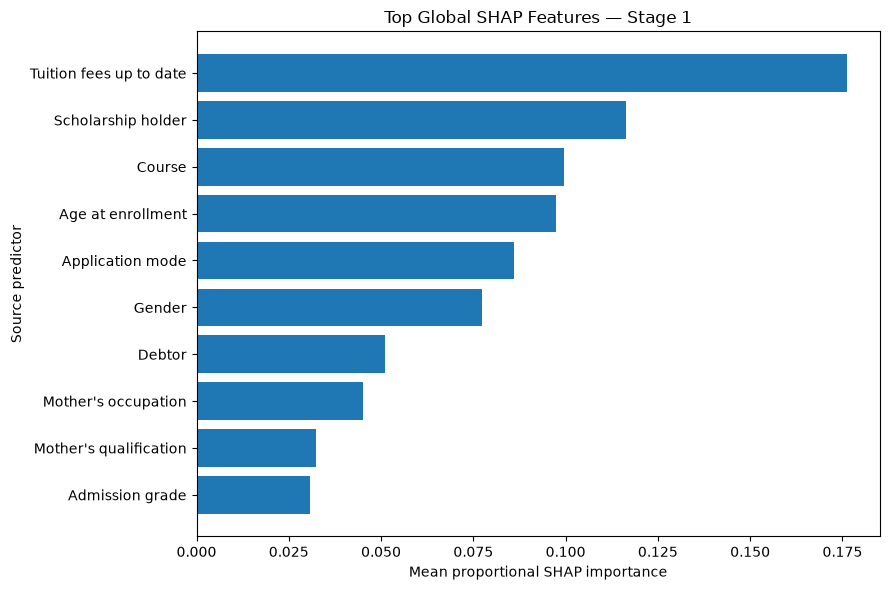

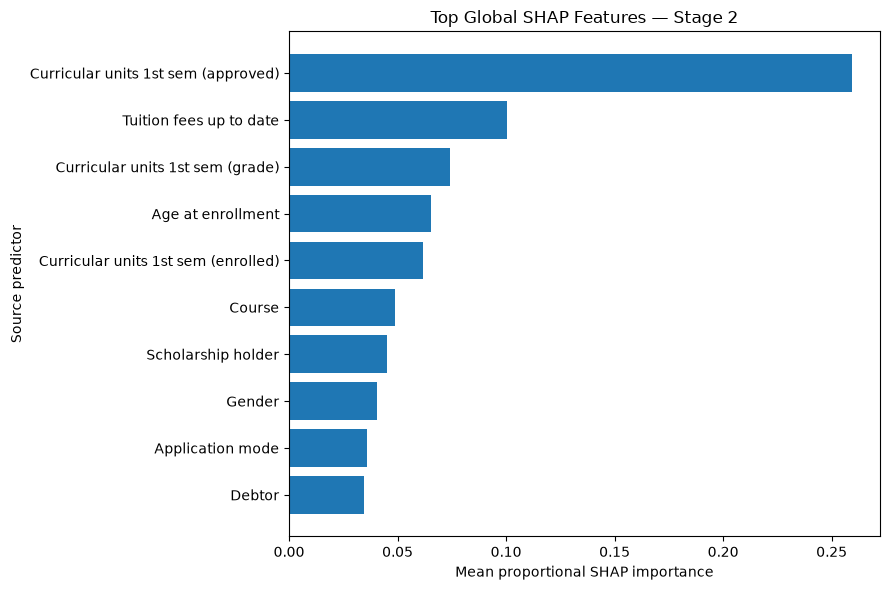

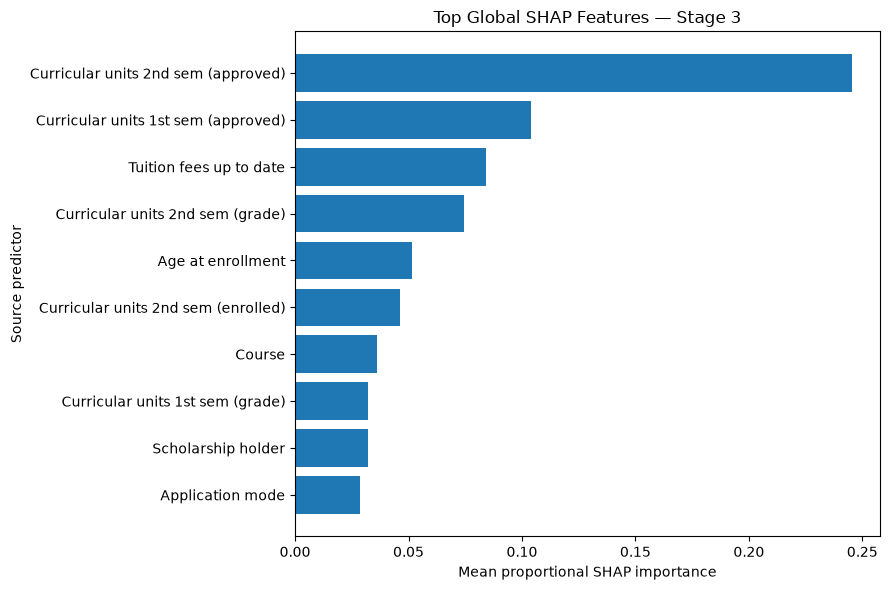

In [251]:
for stage_name in stage_feature_sets:

    plot_data = (
        top10_stage_consensus.loc[
            top10_stage_consensus[
                "Stage"
            ] == stage_name
        ]
        .sort_values(
            "Mean_Model_Importance_Share",
            ascending=True
        )
    )

    plt.figure(
        figsize=(9, 6)
    )

    plt.barh(
        plot_data[
            "Source_Feature"
        ],
        plot_data[
            "Mean_Model_Importance_Share"
        ]
    )

    plt.xlabel(
        "Mean proportional SHAP importance"
    )

    plt.ylabel(
        "Source predictor"
    )

    plt.title(
        f"Top Global SHAP Features — "
        f"{stage_name}"
    )

    plt.tight_layout()

    safe_stage = (
        stage_name
        .lower()
        .replace(" ", "_")
    )

    plt.savefig(
        FIGURES_DIR
        / (
            f"phase17_"
            f"{safe_stage}_"
            f"consensus_shap.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### Finding: Stage-level SHAP Visualisation

The stage-level consensus plots visually reinforce the numerical SHAP rankings.

Stage 1 importance is distributed across financial, demographic and enrolment-related information, with `Tuition fees up to date` occupying the strongest position.

At Stage 2, first-semester academic performance becomes visibly dominant, particularly through the number of approved curricular units.

At Stage 3, second-semester approved units becomes the most influential feature, while first-semester approved units also remains highly ranked.

The visual progression therefore shows that the information driving dropout-risk predictions changes as direct evidence of student academic progress becomes available.

The plots support the interpretation that semester performance information does not merely improve predictive accuracy, as shown in Phase 16, but also becomes central to the models' explanation structures.

## Phase 17.11: Aggregate SHAP Importance by Research Feature Group

In [252]:
feature_to_research_group = dict(
    zip(
        research_group_dictionary[
            "Variable"
        ],
        research_group_dictionary[
            "Research_Group"
        ]
    )
)


shap_group_importance = (
    shap_global_importance
    .copy()
)


shap_group_importance[
    "Research_Group"
] = (
    shap_group_importance[
        "Source_Feature"
    ]
    .map(
        feature_to_research_group
    )
)


assert (
    shap_group_importance[
        "Research_Group"
    ]
    .notna()
    .all()
)


shap_group_importance = (
    shap_group_importance
    .groupby(
        [
            "Stage",
            "Model",
            "Research_Group"
        ],
        as_index=False
    )[
        "Importance_Share"
    ]
    .sum()
)


shap_group_importance[
    "Group_Rank"
] = (
    shap_group_importance
    .groupby(
        [
            "Stage",
            "Model"
        ]
    )[
        "Importance_Share"
    ]
    .rank(
        method="dense",
        ascending=False
    )
    .astype(int)
)


shap_group_importance = (
    shap_group_importance
    .sort_values(
        [
            "Stage",
            "Model",
            "Group_Rank"
        ]
    )
    .reset_index(drop=True)
)


shap_group_importance.round(4)

,Stage,Model,Research_Group,Importance_Share,Group_Rank
0,Stage 1,Gradient Boosting,Socioeconomic,0.4916,1
1,Stage 1,Gradient Boosting,Demographic,0.2223,2
2,Stage 1,Gradient Boosting,Application / enrolment,0.1674,3
3,Stage 1,Gradient Boosting,Macroeconomic,0.0584,4
4,Stage 1,Gradient Boosting,Academic,0.0573,5
5,Stage 1,Gradient Boosting,Demographic / socioeconomic,0.0029,6
6,Stage 1,Logistic Regression,Socioeconomic,0.4565,1
7,Stage 1,Logistic Regression,Application / enrolment,0.2550,2
8,Stage 1,Logistic Regression,Demographic,0.1433,3
9,Stage 1,Logistic Regression,Academic,0.0729,4


### Finding: Research-group SHAP Importance

Source-level SHAP importance has been aggregated into the research groups established before the attribution results were inspected.

The group-level table shows the proportion of each model's total global SHAP importance associated with Academic, Demographic, Socioeconomic, Macroeconomic and contextual enrolment-related information.

The hybrid demographic/socioeconomic classification remains separately visible.

This analysis provides the group-level evidence required to test whether academic predictors become dominant once semester performance data is available.

## Phase 17.12: Summarise Research-group Importance Across Models

In [253]:
stage_group_shap_summary = (
    shap_group_importance
    .groupby(
        [
            "Stage",
            "Research_Group"
        ]
    )
    .agg(
        Mean_Importance_Share=(
            "Importance_Share",
            "mean"
        ),
        Std_Importance_Share=(
            "Importance_Share",
            "std"
        )
    )
    .reset_index()
)


stage_group_shap_summary[
    "Stage_Group_Rank"
] = (
    stage_group_shap_summary
    .groupby(
        "Stage"
    )[
        "Mean_Importance_Share"
    ]
    .rank(
        method="dense",
        ascending=False
    )
    .astype(int)
)


stage_group_shap_summary = (
    stage_group_shap_summary
    .sort_values(
        [
            "Stage",
            "Stage_Group_Rank"
        ]
    )
    .reset_index(drop=True)
)


stage_group_shap_summary.round(4)

,Stage,Research_Group,Mean_Importance_Share,Std_Importance_Share,Stage_Group_Rank
0,Stage 1,Socioeconomic,0.4684,0.0201,1
1,Stage 1,Application / enrolment,0.2030,0.0461,2
2,Stage 1,Demographic,0.1951,0.0449,3
3,Stage 1,Academic,0.0731,0.0159,4
4,Stage 1,Macroeconomic,0.0507,0.0161,5
5,Stage 1,Demographic / socioeconomic,0.0097,0.0063,6
6,Stage 2,Academic,0.4737,0.0262,1
7,Stage 2,Socioeconomic,0.2575,0.0267,2
8,Stage 2,Demographic,0.1149,0.0261,3
9,Stage 2,Application / enrolment,0.0964,0.0289,4


### Finding: Cross-model Feature-group Pattern

The stage-level group summary averages proportional SHAP importance across the three final model families.

This provides a common basis for evaluating whether broad feature-family importance shifts systematically as semester academic data enters the prediction process.

The observed Stage 2 and Stage 3 Academic shares are compared directly with the corresponding Demographic and Socioeconomic shares in Phase 17.13.

## Phase 17.13: Construct the Direct H3 Comparison

In [254]:
h3_groups = [
    "Academic",
    "Demographic",
    "Socioeconomic"
]


h3_group_comparison = (
    shap_group_importance.loc[
        shap_group_importance[
            "Research_Group"
        ].isin(
            h3_groups
        )
    ]
    .pivot(
        index=[
            "Stage",
            "Model"
        ],
        columns="Research_Group",
        values="Importance_Share"
    )
    .reset_index()
)


h3_group_comparison[
    "Academic_gt_Demographic"
] = (
    h3_group_comparison[
        "Academic"
    ]
    >
    h3_group_comparison[
        "Demographic"
    ]
)


h3_group_comparison[
    "Academic_gt_Socioeconomic"
] = (
    h3_group_comparison[
        "Academic"
    ]
    >
    h3_group_comparison[
        "Socioeconomic"
    ]
)


h3_group_comparison[
    "Academic_gt_Both"
] = (
    h3_group_comparison[
        "Academic_gt_Demographic"
    ]
    &
    h3_group_comparison[
        "Academic_gt_Socioeconomic"
    ]
)


h3_group_comparison.round(4)

Research_Group,Stage,Model,Academic,Demographic,Socioeconomic,Academic_gt_Demographic,Academic_gt_Socioeconomic,Academic_gt_Both
0,Stage 1,Gradient Boosting,0.0573,0.2223,0.4916,False,False,False
1,Stage 1,Logistic Regression,0.0729,0.1433,0.4565,False,False,False
2,Stage 1,Random Forest,0.0892,0.2196,0.4570,False,False,False
3,Stage 2,Gradient Boosting,0.5037,0.1377,0.2481,True,True,True
4,Stage 2,Logistic Regression,0.4623,0.0865,0.2369,True,True,True
5,Stage 2,Random Forest,0.4551,0.1206,0.2877,True,True,True
6,Stage 3,Gradient Boosting,0.6093,0.0940,0.2056,True,True,True
7,Stage 3,Logistic Regression,0.5888,0.0642,0.1921,True,True,True
8,Stage 3,Random Forest,0.6092,0.0845,0.2068,True,True,True


In [255]:
h3_stage_support_summary = (
    h3_group_comparison.loc[
        h3_group_comparison[
            "Stage"
        ].isin(
            [
                "Stage 2",
                "Stage 3"
            ]
        )
    ]
    .groupby(
        "Stage"
    )
    .agg(
        Models_Where_Academic_Exceeds_Both=(
            "Academic_gt_Both",
            "sum"
        ),
        Models_Evaluated=(
            "Model",
            "count"
        )
    )
    .reset_index()
)


h3_stage_support_summary

,Stage,Models_Where_Academic_Exceeds_Both,Models_Evaluated
0,Stage 2,3,3
1,Stage 3,3,3


### Finding: H3 Assessment

The direct H3 comparison produces a consistent result across all three model families.

At Stage 2, Academic proportional SHAP importance exceeds both Demographic and Socioeconomic importance for Logistic Regression, Random Forest and Gradient Boosting.

The same result occurs at Stage 3.

The H3 support summary therefore records:

- Stage 2: 3 of 3 models where Academic importance exceeds both comparison groups.
- Stage 3: 3 of 3 models where Academic importance exceeds both comparison groups.

The individual consensus feature rankings provide additional support for this group-level result. `Curricular units 1st sem (approved)` is the highest-ranked Stage 2 feature, while `Curricular units 2nd sem (approved)` is the highest-ranked Stage 3 feature. Other semester academic measures also appear prominently in the later-stage rankings.

H3 is therefore **supported** by the global SHAP evidence.

The hypothesis predicted that academic performance indicators would become more important than demographic and socioeconomic indicators from Stage 2 onward, and this pattern occurs consistently across all three models at both later prediction stages.

A qualification is necessary when interpreting the aggregated group shares: the Academic group contains more available predictors as semester data is introduced. For this reason, H3 is not assessed from group totals alone. The conclusion is also supported by the individual feature rankings, where semester academic variables occupy several of the highest positions.

## Phase 17.14: Extract Supplementary Model-native Feature Importance

In [256]:
native_importance_rows = []


for stage_name in stage_feature_sets:

    for model_name in PRIMARY_MODELS:

        pipeline = (
            final_fitted_models[
                stage_name
            ][
                model_name
            ]
        )

        model = (
            pipeline.named_steps[
                "model"
            ]
        )

        source_mapping = (
            shap_source_mappings[
                (
                    stage_name,
                    model_name
                )
            ]
        )

        if (
            model_name
            == "Logistic Regression"
        ):

            transformed_importance = (
                np.abs(
                    model.coef_[0]
                )
            )

            native_measure = (
                "Absolute coefficient"
            )

        else:

            transformed_importance = (
                model.feature_importances_
            )

            native_measure = (
                "Tree feature importance"
            )

        transformed_native_df = (
            pd.DataFrame({
                "Source_Feature":
                source_mapping[
                    "Source_Feature"
                ].to_numpy(),

                "Transformed_Importance":
                transformed_importance
            })
        )

        source_native = (
            transformed_native_df
            .groupby(
                "Source_Feature"
            )[
                "Transformed_Importance"
            ]
            .sum()
        )

        native_total = (
            source_native.sum()
        )

        for source_feature, value in (
            source_native.items()
        ):

            native_importance_rows.append({
                "Stage": stage_name,
                "Model": model_name,
                "Source_Feature":
                source_feature,
                "Native_Measure":
                native_measure,
                "Native_Importance":
                float(value),
                "Native_Importance_Share":
                float(
                    value
                    / native_total
                )
            })


native_source_importance = (
    pd.DataFrame(
        native_importance_rows
    )
)


native_source_importance[
    "Native_Rank"
] = (
    native_source_importance
    .groupby(
        [
            "Stage",
            "Model"
        ]
    )[
        "Native_Importance"
    ]
    .rank(
        method="dense",
        ascending=False
    )
    .astype(int)
)


native_source_importance = (
    native_source_importance
    .sort_values(
        [
            "Stage",
            "Model",
            "Native_Rank"
        ]
    )
    .reset_index(drop=True)
)


native_source_importance.loc[
    native_source_importance[
        "Native_Rank"
    ] <= 10
].round(4)

,Stage,Model,Source_Feature,Native_Measure,Native_Importance,Native_Importance_Share,Native_Rank
0,Stage 1,Gradient Boosting,Tuition fees up to date,Tree feature importance,0.3190,0.3190,1
1,Stage 1,Gradient Boosting,Age at enrollment,Tree feature importance,0.1240,0.1240,2
2,Stage 1,Gradient Boosting,Course,Tree feature importance,0.0980,0.0980,3
3,Stage 1,Gradient Boosting,Scholarship holder,Tree feature importance,0.0792,0.0792,4
4,Stage 1,Gradient Boosting,Mother's occupation,Tree feature importance,0.0579,0.0579,5
...,...,...,...,...,...,...,...
231,Stage 3,Random Forest,Tuition fees up to date,Tree feature importance,0.0459,0.0459,6
232,Stage 3,Random Forest,Father's occupation,Tree feature importance,0.0407,0.0407,7
233,Stage 3,Random Forest,Age at enrollment,Tree feature importance,0.0370,0.0370,8
234,Stage 3,Random Forest,Application mode,Tree feature importance,0.0364,0.0364,9


### Finding: Supplementary Model-native Importance

A supplementary source-level importance ranking has been extracted directly from each fitted model.

For Logistic Regression, the supplementary measure is absolute coefficient magnitude.

For Random Forest and Gradient Boosting, the supplementary measure is the model's tree-based feature importance.

These measures are structurally different and their raw magnitudes must not be compared across model families.

They are used only as a secondary within-model consistency check against the primary SHAP rankings.

## Phase 17.15: Compare SHAP and Model-native Feature Rankings

In [257]:
from scipy.stats import spearmanr


importance_rank_comparison = (
    shap_global_importance[
        [
            "Stage",
            "Model",
            "Source_Feature",
            "SHAP_Rank",
            "Importance_Share"
        ]
    ]
    .merge(
        native_source_importance[
            [
                "Stage",
                "Model",
                "Source_Feature",
                "Native_Rank",
                "Native_Importance_Share"
            ]
        ],
        on=[
            "Stage",
            "Model",
            "Source_Feature"
        ],
        how="inner"
    )
)


rank_consistency_rows = []

for (
    stage_name,
    model_name
), group_data in (
    importance_rank_comparison
    .groupby(
        [
            "Stage",
            "Model"
        ]
    )
):

    correlation, p_value = (
        spearmanr(
            group_data[
                "SHAP_Rank"
            ],
            group_data[
                "Native_Rank"
            ]
        )
    )

    rank_consistency_rows.append({
        "Stage": stage_name,
        "Model": model_name,
        "Spearman_Rank_Correlation":
        correlation,
        "P_Value": p_value
    })


shap_native_rank_consistency = (
    pd.DataFrame(
        rank_consistency_rows
    )
    .round(4)
)


shap_native_rank_consistency

,Stage,Model,Spearman_Rank_Correlation,P_Value
0,Stage 1,Gradient Boosting,0.9249,0.0000
1,Stage 1,Logistic Regression,0.5247,0.0102
2,Stage 1,Random Forest,0.9032,0.0000
3,Stage 2,Gradient Boosting,0.8916,0.0000
4,Stage 2,Logistic Regression,0.4631,0.0114
5,Stage 2,Random Forest,0.8468,0.0000
6,Stage 3,Gradient Boosting,0.8591,0.0000
7,Stage 3,Logistic Regression,0.6387,0.0000
8,Stage 3,Random Forest,0.8731,0.0000


### Finding: SHAP versus Model-native Ranking Consistency

The supplementary comparison shows positive agreement between SHAP and the corresponding model-native importance measures for all nine model-stage combinations.

Gradient Boosting shows strong rank agreement, with Spearman correlations of 0.9249 at Stage 1, 0.8916 at Stage 2 and 0.8591 at Stage 3.

Random Forest also shows strong agreement, with correlations of 0.9032, 0.8468 and 0.8731 respectively.

Logistic Regression shows more moderate agreement, with correlations of 0.5247 at Stage 1, 0.4631 at Stage 2 and 0.6387 at Stage 3.

The lower Logistic Regression correlations do not invalidate the SHAP explanations. Absolute coefficient magnitude and SHAP importance quantify different aspects of feature influence: coefficient size describes the fitted model parameter, whereas SHAP importance also reflects the distribution of feature values among the explained observations.

Overall, the supplementary comparison provides strong consistency evidence for the tree-based models and moderate positive consistency for Logistic Regression.

SHAP remains the primary interpretability framework for RQ2 and H3.


## Phase 17.16: Preserve the Global SHAP Evidence

In [258]:
phase17_output_tables = {
    "phase17_shap_background_indices.csv":
    shap_background_index_table,

    "phase17_shap_background_audit.csv":
    shap_background_audit,

    "phase17_shap_additivity_audit.csv":
    shap_additivity_audit,

    "phase17_shap_background_sensitivity_indices.csv":
    shap_background_sensitivity_indices,

    "phase17_shap_background_sensitivity.csv":
    shap_background_sensitivity,

    "phase17_shap_audit.csv":
    shap_audit,

    "phase17_global_source_shap.csv":
    shap_global_importance,

    "phase17_top10_shap_by_model.csv":
    top10_shap_by_model,

    "phase17_stage_consensus_shap.csv":
    stage_consensus_shap,

    "phase17_top10_stage_consensus.csv":
    top10_stage_consensus,

    "phase17_shap_group_importance.csv":
    shap_group_importance,

    "phase17_stage_group_shap_summary.csv":
    stage_group_shap_summary,

    "phase17_h3_group_comparison.csv":
    h3_group_comparison,

    "phase17_h3_stage_support_summary.csv":
    h3_stage_support_summary,

    "phase17_native_source_importance.csv":
    native_source_importance,

    "phase17_shap_native_rank_consistency.csv":
    shap_native_rank_consistency,

    "phase17_research_group_dictionary.csv":
    research_group_dictionary
}


for output_file_name, output_table in (
    phase17_output_tables.items()
):
    assert isinstance(
        output_table,
        pd.DataFrame
    )

    assert not output_table.empty, (
        f"{output_file_name} is empty."
    )

    output_table.to_csv(
        TABLES_DIR / output_file_name,
        index=False
    )


print(
    f"{len(phase17_output_tables)} Phase 17 "
    "global SHAP outputs, background records, "
    "additivity checks and sensitivity evidence "
    "saved successfully."
)

17 Phase 17 global SHAP outputs, background records, additivity checks and sensitivity evidence saved successfully.


## Phase 17.17: Research Evidence Status after Global SHAP Analysis

In [259]:
phase17_research_alignment = pd.DataFrame([
    {
        "Research_Element": "RQ1 / Objective 1",
        "Evidence_Status": (
            "Completed through final "
            "held-out evaluation in Phase 16."
        ),
        "Final_Assessment_Possible": "Yes"
    },
    {
        "Research_Element": "H1",
        "Evidence_Status": (
            "Not supported by final "
            "held-out predictive results."
        ),
        "Final_Assessment_Possible": "Yes"
    },
    {
        "Research_Element": "H2",
        "Evidence_Status": (
            "Supported by final "
            "stage-performance progression."
        ),
        "Final_Assessment_Possible": "Yes"
    },
    {
        "Research_Element": "RQ2",
        "Evidence_Status": (
            "Global source-level and "
            "feature-group SHAP evidence available."
        ),
        "Final_Assessment_Possible": "Yes"
    },
    {
        "Research_Element": "Objective 2",
        "Evidence_Status": (
            "SHAP and supplementary model-native "
            "feature rankings available."
        ),
        "Final_Assessment_Possible": "Yes"
    },
    {
        "Research_Element": "H3",
        "Evidence_Status": (
            "Direct Academic versus Demographic "
            "and Socioeconomic SHAP comparison available."
        ),
        "Final_Assessment_Possible": "Yes"
    },
    {
        "Research_Element": "RQ3 / H4",
        "Evidence_Status": (
            "Requires Phase 18 local SHAP and "
            "interpretability assessment."
        ),
        "Final_Assessment_Possible": "No"
    }
])

phase17_research_alignment

,Research_Element,Evidence_Status,Final_Assessment_Possible
0,RQ1 / Objective 1,Completed through final held-out evaluation in...,Yes
1,H1,Not supported by final held-out predictive res...,Yes
2,H2,Supported by final stage-performance progression.,Yes
3,RQ2,Global source-level and feature-group SHAP evi...,Yes
4,Objective 2,SHAP and supplementary model-native feature ra...,Yes
5,H3,Direct Academic versus Demographic and Socioec...,Yes
6,RQ3 / H4,Requires Phase 18 local SHAP and interpretabil...,No


### Finding: Research Evidence Status after Global SHAP Analysis

Phase 17 provides sufficient global attribution evidence to answer RQ2, assess Objective 2 and formally evaluate H3.

For RQ2, the strongest predictors change substantially across prediction stages.

Before semester information becomes available, `Tuition fees up to date`, `Scholarship holder`, `Course`, `Age at enrollment` and `Application mode` are among the strongest consensus predictors.

At Stage 2, first-semester academic progress becomes central, led by `Curricular units 1st sem (approved)`.

At Stage 3, second-semester performance becomes dominant, led by `Curricular units 2nd sem (approved)`, while first-semester approved units remain highly influential.

Objective 2 is therefore achieved because the strongest predictors have been ranked at each stage using SHAP, supported by supplementary model-native feature importance.

H3 is **supported**. Academic proportional SHAP importance exceeds both Demographic and Socioeconomic importance for all three models at Stage 2 and again for all three models at Stage 3.

The cross-model average Academic share increases from 0.0731 at Stage 1 to 0.4737 at Stage 2 and 0.6025 at Stage 3.
RQ3 and H4 remain unresolved because global importance identifies which features matter overall but does not establish whether individual explanations are sufficiently clear, consistent and practically interpretable for non-technical higher education use (Nagy and Molontay, 2024).

## Phase 17.18: Overall Phase 17 Summary

Global SHAP feature attribution was completed for all nine final model-stage combinations using the 885 held-out students.

The SHAP analysis operated first in the transformed model-input space and then recombined one-hot encoded contributions into the original source predictors.

This produced complete source-level explanations for 23 predictors at Stage 1, 29 predictors at Stage 2 and 35 predictors at Stage 3.

The attribution results reveal a clear change in the information driving dropout-risk predictions.

At Stage 1, `Tuition fees up to date` is the highest-ranked consensus predictor with mean proportional SHAP importance = 0.1764. Other prominent Stage 1 predictors include `Scholarship holder`, `Course`, `Age at enrollment` and `Application mode`.

At Stage 2, `Curricular units 1st sem (approved)` becomes the dominant predictor with mean proportional importance = 0.2593. First-semester grade and enrolment measures also enter the highest-ranked features.

At Stage 3, `Curricular units 2nd sem (approved)` becomes the strongest consensus predictor with mean proportional importance = 0.2455. `Curricular units 1st sem (approved)` remains second, demonstrating that academic-progress information from both semesters contributes strongly to later dropout-risk predictions.

The feature-group analysis shows an equally strong temporal shift.

At Stage 1, Socioeconomic information accounts for an average 0.4684 of proportional SHAP importance, while Academic information accounts for only 0.0731.

At Stage 2, Academic information becomes dominant with a mean share of 0.4737, compared with 0.2575 for Socioeconomic information and 0.1149 for Demographic information.

At Stage 3, the Academic share increases further to 0.6025, while Socioeconomic importance declines to 0.2015 and Demographic importance to 0.0809.

This pattern occurs consistently across Logistic Regression, Random Forest and Gradient Boosting. Academic importance exceeds both Demographic and Socioeconomic importance for all three models at Stage 2 and all three models at Stage 3.

H3 is therefore classified as **supported**.

The individual feature rankings reinforce this conclusion because semester academic indicators occupy the leading positions at both later prediction stages. This qualification is important because aggregate group importance is partly influenced by the increasing number of academic predictors available at later stages.

RQ2 is now answered: dropout-risk prediction shifts from reliance on financial, demographic and enrolment-related information before semester performance becomes available to progressively stronger reliance on direct measures of academic progress once semester outcomes become available.

Objective 2 is also achieved through the SHAP feature rankings and supplementary model-native importance comparison.

The model-native consistency analysis shows strong positive rank agreement for Random Forest and Gradient Boosting and moderate positive agreement for Logistic Regression, providing supplementary support for the principal attribution patterns.

SHAP values remain predictive model attributions rather than causal effects. The prominence of a feature does not demonstrate that intervening on that feature would necessarily change a student's dropout outcome (Lundberg and Lee, 2017).

RQ1, Objective 1, H1 and H2 were resolved through the final predictive evaluation in Phase 16.

RQ2, Objective 2 and H3 are now resolved through the global SHAP evidence in Phase 17.

RQ3, Objective 3 and H4 remain for the subsequent local SHAP and interpretability analysis.

# Phase 18: Local SHAP Explanations and Interpretability Assessment

Phase 17 established which features are most influential globally across the final predictive models.

Phase 18 changes the level of analysis from global feature importance to individual student predictions.

The purpose is to assess whether SHAP can provide understandable feature-level explanations of why a fitted model assigns relatively higher or lower dropout risk to a particular student.

The analysis focuses on five properties:

1. whether explanations can be expressed using original source-variable names rather than encoded model-input columns;
2. whether the direction of each contribution can be communicated clearly as increasing or decreasing the model's dropout-risk score;
3. whether a small number of leading features captures a meaningful proportion of the local explanation;
4. whether different model families identify broadly similar influential features for the same students; and
5. whether influential features can be interpreted responsibly using the actionability framework fixed before model development.

The Stage 3 Logistic Regression model is used as the principal case-level explanation model because it produced the highest final held-out ROC-AUC and locked-threshold F1 point estimates in Phase 16. This selection does not assume statistical superiority over the other models.

The same selected students will also be examined across Random Forest and Gradient Boosting so that interpretability is not assessed from one model family alone.

SHAP values remain model attributions rather than causal effects. A positive SHAP contribution means that a feature pushes the fitted model toward a higher dropout-risk score relative to its reference prediction and does not mean that the feature causes dropout (Lundberg and Lee, 2017).

No practitioner user study was conducted, so conclusions about practical interpretability will represent analytical evidence of explanation structure and readability rather than direct practitioner validation (Nagy and Molontay, 2024).

### Code Attribution — Phase 17

SHAP Documentation, 2025. *SHAP documentation* [Source code/documentation]. Available at: <https://shap.readthedocs.io/en/latest/> [Accessed 14 September 2026].

SHAP Documentation, 2025. *shap.LinearExplainer* [Source code/documentation]. Available at: <https://shap.readthedocs.io/en/latest/generated/shap.LinearExplainer.html> [Accessed 14 September 2026].

SHAP Documentation, 2025. *shap.TreeExplainer* [Source code/documentation]. Available at: <https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html> [Accessed 14 September 2026].

SHAP Documentation, 2025. *shap.maskers.Independent* [Source code/documentation]. Available at: <https://shap.readthedocs.io/en/latest/generated/shap.maskers.Independent.html> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.random.default_rng* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/random/generator.html> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.where* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/generated/numpy.where.html> [Accessed 14 September 2026].

scipy developers, 2025. *scipy.stats.spearmanr* [Source code/documentation]. Available at: <https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html> [Accessed 14 September 2026].

Matplotlib developers, 2025. *matplotlib.pyplot* [Source code/documentation]. Available at: <https://matplotlib.org/stable/api/pyplot_summary.html> [Accessed 14 September 2026].

## Phase 18.1: Decision Record for the Local Interpretability Assessment

### Decision Record: Local SHAP Interpretation Strategy

#### Observation

RQ3 asks whether SHAP explanations can provide clear, consistent and practically useful insight for non-technical higher education practitioners.

The study does not include interviews, usability testing or direct practitioner evaluation.
Stage 3 Logistic Regression produced the highest held-out ROC-AUC and locked-threshold F1 point estimates, while Random Forest and Gradient Boosting produced closely competitive results. The paired bootstrap analysis is used to qualify uncertainty in these differences.

#### Options considered

- Assess interpretability only from global SHAP rankings.
- Select individual cases informally based on visually interesting explanations.
- Use an objective case-selection rule and combine case-level explanation with quantitative cross-model consistency and readability measures.

#### Decision

Stage 3 Logistic Regression will be used as the principal local explanation reference model.

Four held-out cases will be selected objectively from its locked-threshold predictions:

- a high-confidence true positive;
- a high-confidence true negative;
- a high-confidence false positive; and
- a high-confidence false negative.

The same students will then be examined across all three Stage 3 model families.

Interpretability will also be quantified across all 885 held-out Stage 3 students rather than relying only on the four illustrative cases.

#### Justification

Including correct and incorrect predictions prevents the interpretability analysis from presenting only successful examples.

Using an objective confidence-based selection rule reduces discretionary case selection.

Evaluating all held-out students provides broader evidence of explanation compactness and cross-model consistency.

The conclusions will remain analytical because no practitioner validation was conducted, meaning that practical usefulness is assessed from explanation structure alone rather than from direct user feedback (Nagy and Molontay, 2024).

## Phase 18.2: Verify the Pre-specified Actionability Mapping

In [260]:
actionability_lookup = dict(
    zip(
        variable_dictionary[
            "Variable"
        ],
        variable_dictionary[
            "Actionability"
        ]
    )
)


stage3_actionability_audit = (
    pd.DataFrame({
        "Source_Feature":
        stage3_model_features
    })
)


stage3_actionability_audit[
    "Actionability"
] = (
    stage3_actionability_audit[
        "Source_Feature"
    ]
    .map(
        actionability_lookup
    )
)


stage3_actionability_audit

,Source_Feature,Actionability
0,Marital status,Non-actionable
1,Application mode,Non-actionable
2,Application order,Non-actionable
3,Course,Non-actionable
4,Daytime/evening attendance,Non-actionable
5,Previous qualification,Non-actionable
6,Previous qualification (grade),Non-actionable
7,Nacionality,Non-actionable
8,Mother's qualification,Non-actionable
9,Father's qualification,Non-actionable


In [261]:
assert (
    stage3_actionability_audit[
        "Actionability"
    ].notna().all()
)

assert (
    (
        stage3_actionability_audit[
            "Actionability"
        ]
        != "Unassigned"
    ).all()
)

print(
    "Actionability coverage verified for:",
    len(stage3_actionability_audit),
    "Stage 3 predictors."
)

print(
    "\nStage 3 actionability counts:"
)

print(
    stage3_actionability_audit[
        "Actionability"
    ]
    .value_counts()
)

Actionability coverage verified for: 35 Stage 3 predictors.

Stage 3 actionability counts:
Actionability
Non-actionable     22
Semi-actionable     9
Actionable          4
Name: count, dtype: int64


### Finding: Actionability Mapping Available for Local Interpretation

All 35 predictors used by the final Stage 3 models have a valid actionability classification.

The Stage 3 modelling set contains 22 non-actionable predictors, 9 semi-actionable predictors and 4 actionable predictors.

The four actionable variables are the first- and second-semester approved-unit and grade measures, while the semi-actionable group contains financial, enrolment and evaluation-related indicators that may support cautious referral or follow-up.

The actionability framework was established before model performance and SHAP results were inspected.

Local SHAP importance can therefore be interpreted alongside a pre-existing responsible-use framework rather than retrospectively labelling highly predictive variables as intervention targets.

Predictive importance remains distinct from causal actionability, and a variable should not be treated as an intervention target simply because it receives high SHAP attribution (Yu, Lee and Kizilcec, 2021).

## Phase 18.3: Define the Primary Local Explanation Model

In [262]:
local_reference_stage = (
    "Stage 3"
)

local_reference_model = (
    "Logistic Regression"
)

local_reference_threshold = (
    locked_thresholds[
        local_reference_stage
    ][
        local_reference_model
    ]
)

print(
    "Reference stage:",
    local_reference_stage
)

print(
    "Reference model:",
    local_reference_model
)

print(
    "Locked threshold:",
    local_reference_threshold
)

Reference stage: Stage 3
Reference model: Logistic Regression
Locked threshold: 0.57


### Finding: Local Explanation Reference Model

Stage 3 Logistic Regression is retained as the principal model for detailed local explanation.

This selection follows the final predictive evidence from Phase 16, where Stage 3 Logistic Regression produced the highest held-out ROC-AUC and locked-threshold F1 point estimates. It is used as the principal explanation reference without claiming that it is statistically superior to the other models.

The model uses the locked classification threshold of 0.57, derived exclusively from training out-of-fold predictions (He and Garcia, 2009).
Random Forest and Gradient Boosting remain included in the subsequent cross-model interpretability analysis.

## Phase 18.4: Select Four Representative Held-out Cases Using a Fixed Rule

In [263]:
reference_case_data = (
    final_test_predictions.loc[
        (
            final_test_predictions[
                "Stage"
            ]
            == local_reference_stage
        )
        &
        (
            final_test_predictions[
                "Model"
            ]
            == local_reference_model
        )
    ]
    .copy()
)


reference_case_data[
    "Prediction_Category"
] = np.select(
    [
        (
            (
                reference_case_data[
                    "Observed_Dropout"
                ] == 1
            )
            &
            (
                reference_case_data[
                    "Locked_Prediction"
                ] == 1
            )
        ),
        (
            (
                reference_case_data[
                    "Observed_Dropout"
                ] == 0
            )
            &
            (
                reference_case_data[
                    "Locked_Prediction"
                ] == 0
            )
        ),
        (
            (
                reference_case_data[
                    "Observed_Dropout"
                ] == 0
            )
            &
            (
                reference_case_data[
                    "Locked_Prediction"
                ] == 1
            )
        ),
        (
            (
                reference_case_data[
                    "Observed_Dropout"
                ] == 1
            )
            &
            (
                reference_case_data[
                    "Locked_Prediction"
                ] == 0
            )
        )
    ],
    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],
    default="Unclassified"
)


case_selection_rules = {
    "True Positive": (
        "Dropout_Probability",
        False
    ),
    "True Negative": (
        "Dropout_Probability",
        True
    ),
    "False Positive": (
        "Dropout_Probability",
        False
    ),
    "False Negative": (
        "Dropout_Probability",
        True
    )
}


case_labels = {
    "True Positive":
    "High-confidence true positive",

    "True Negative":
    "High-confidence true negative",

    "False Positive":
    "High-confidence false positive",

    "False Negative":
    "High-confidence false negative"
}


selected_case_rows = []


for category, (
    sort_column,
    ascending
) in case_selection_rules.items():

    category_data = (
        reference_case_data.loc[
            reference_case_data[
                "Prediction_Category"
            ] == category
        ]
        .sort_values(
            sort_column,
            ascending=ascending
        )
    )

    assert (
        len(category_data) > 0
    ), (
        f"No held-out case available "
        f"for {category}."
    )

    selected_row = (
        category_data.iloc[0]
        .copy()
    )

    selected_row[
        "Case_Label"
    ] = (
        case_labels[
            category
        ]
    )

    selected_case_rows.append(
        selected_row
    )


selected_local_cases = (
    pd.DataFrame(
        selected_case_rows
    )
    .reset_index(drop=True)
)


selected_local_cases[
    [
        "Case_Label",
        "Student_Index",
        "Prediction_Category",
        "Observed_Dropout",
        "Dropout_Probability",
        "Locked_Threshold",
        "Locked_Prediction"
    ]
].round(4)

,Case_Label,Student_Index,Prediction_Category,Observed_Dropout,Dropout_Probability,Locked_Threshold,Locked_Prediction
0,High-confidence true positive,3533,True Positive,1,0.9997,0.57,1
1,High-confidence true negative,894,True Negative,0,0.0128,0.57,0
2,High-confidence false positive,2447,False Positive,0,0.9912,0.57,1
3,High-confidence false negative,4244,False Negative,1,0.0266,0.57,0


### Finding: Representative Local Explanation Cases Selected

Four held-out students were selected objectively using the predefined prediction-category and confidence rules.

Student 3533 represents the high-confidence true-positive case. The student was an observed Dropout case and received a predicted dropout probability of 0.9997, substantially above the locked threshold of 0.57.

Student 894 represents the high-confidence true-negative case. The observed outcome was Non-dropout and the model assigned a dropout probability of only 0.0128.

Student 2447 represents the high-confidence false-positive case. Although the observed outcome was Non-dropout, the model assigned a very high dropout probability of 0.9912.

Student 4244 represents the high-confidence false-negative case. The student was an observed Dropout case but received a dropout probability of only 0.0266.

The inclusion of both highly confident correct predictions and highly confident errors is important because interpretability should explain model behaviour even when the prediction itself is wrong.

The cases were selected from prediction outcomes before their SHAP patterns were inspected, reducing discretionary selection of favourable examples.

## Phase 18.5: Define a Source-level Local SHAP Explanation Function

In [264]:
research_group_lookup = dict(
    zip(
        research_group_dictionary[
            "Variable"
        ],
        research_group_dictionary[
            "Research_Group"
        ]
    )
)


semantic_type_lookup = dict(
    zip(
        variable_dictionary[
            "Variable"
        ],
        variable_dictionary[
            "Semantic_Type"
        ]
    )
)




parent_qualification_labels = {
    1: "Secondary education – 12th year or equivalent",
    2: "Higher education – bachelor's degree",
    3: "Higher education – degree",
    4: "Higher education – master's degree",
    5: "Higher education – doctorate",
    6: "Frequency of higher education",
    9: "12th year of schooling not completed",
    10: "11th year of schooling not completed",
    11: "7th year of schooling (old system)",
    12: "Other – 11th year of schooling",
    13: "Second year complementary high-school course",
    14: "10th year of schooling",
    18: "General commerce course",
    19: "Basic education third cycle or equivalent",
    20: "Complementary high-school course",
    22: "Technical-professional course",
    25: "Complementary high-school course not completed",
    26: "7th year of schooling",
    27: "Second cycle of general high-school course",
    29: "9th year of schooling not completed",
    30: "8th year of schooling",
    31: "General administration and commerce course",
    33: "Supplementary accounting and administration",
    34: "Unknown",
    35: "Cannot read or write",
    36: "Can read without completing fourth year",
    37: "Basic education first cycle or equivalent",
    38: "Basic education second cycle or equivalent",
    39: "Technological specialisation course",
    40: "Higher education degree – first cycle",
    41: "Specialised higher-studies course",
    42: "Professional higher technical course",
    43: "Higher education master's – second cycle",
    44: "Higher education doctorate – third cycle"
}


mother_occupation_labels = {
    0: "Student",
    1: (
        "Legislative or executive representative, "
        "director or manager"
    ),
    2: "Intellectual or scientific specialist",
    3: "Intermediate-level technician or professional",
    4: "Administrative staff",
    5: "Personal-service, security or sales worker",
    6: (
        "Farmer or skilled agriculture, fisheries "
        "or forestry worker"
    ),
    7: "Skilled industry, construction or craft worker",
    8: (
        "Installation or machine operator, "
        "or assembly worker"
    ),
    9: "Unskilled worker",
    10: "Armed Forces profession",
    90: "Other situation",
    99: "Occupation not specified",
    122: "Health professional",
    123: "Teacher",
    125: (
        "Information and communication "
        "technology specialist"
    ),
    131: (
        "Intermediate science or engineering "
        "technician"
    ),
    132: (
        "Intermediate health technician "
        "or professional"
    ),
    134: (
        "Intermediate legal, social, sport or "
        "cultural-services technician"
    ),
    141: (
        "Office, secretarial or "
        "data-processing worker"
    ),
    143: (
        "Data, accounting, statistical, financial "
        "or registry operator"
    ),
    144: "Other administrative-support worker",
    151: "Personal-service worker",
    152: "Sales worker",
    153: "Personal-care worker",
    171: (
        "Skilled construction worker, "
        "excluding electrician"
    ),
    173: (
        "Printing, precision-instrument, "
        "jewellery or craft worker"
    ),
    175: (
        "Food-processing, woodworking, clothing "
        "or related craft worker"
    ),
    191: "Cleaning worker",
    192: (
        "Unskilled agriculture, fisheries "
        "or forestry worker"
    ),
    193: (
        "Unskilled extractive, construction, "
        "manufacturing or transport worker"
    ),
    194: "Meal-preparation assistant"
}


father_occupation_labels = {
    0: "Student",
    1: (
        "Legislative or executive representative, "
        "director or manager"
    ),
    2: "Intellectual or scientific specialist",
    3: "Intermediate-level technician or professional",
    4: "Administrative staff",
    5: "Personal-service, security or sales worker",
    6: (
        "Farmer or skilled agriculture, fisheries "
        "or forestry worker"
    ),
    7: "Skilled industry, construction or craft worker",
    8: (
        "Installation or machine operator, "
        "or assembly worker"
    ),
    9: "Unskilled worker",
    10: "Armed Forces profession",
    90: "Other situation",
    99: "Occupation not specified",
    101: "Armed Forces officer",
    102: "Armed Forces sergeant",
    103: "Other Armed Forces personnel",
    112: (
        "Administrative or commercial-services "
        "director"
    ),
    114: (
        "Hotel, catering, trade or "
        "other-services director"
    ),
    121: (
        "Physical-science, mathematics or "
        "engineering specialist"
    ),
    122: "Health professional",
    123: "Teacher",
    124: (
        "Finance, accounting, administration "
        "or public-relations specialist"
    ),
    131: (
        "Intermediate science or engineering "
        "technician"
    ),
    132: (
        "Intermediate health technician "
        "or professional"
    ),
    134: (
        "Intermediate legal, social, sport or "
        "cultural-services technician"
    ),
    135: (
        "Information and communication "
        "technology technician"
    ),
    141: (
        "Office, secretarial or "
        "data-processing worker"
    ),
    143: (
        "Data, accounting, statistical, financial "
        "or registry operator"
    ),
    144: "Other administrative-support worker",
    151: "Personal-service worker",
    152: "Sales worker",
    153: "Personal-care worker",
    154: "Protection or security-services worker",
    161: (
        "Market-oriented farmer or skilled "
        "agricultural worker"
    ),
    163: (
        "Subsistence farmer, livestock keeper, "
        "fisher, hunter or gatherer"
    ),
    171: (
        "Skilled construction worker, "
        "excluding electrician"
    ),
    172: "Skilled metallurgy or metalworking worker",
    174: "Skilled electricity or electronics worker",
    175: (
        "Food-processing, woodworking, clothing "
        "or related craft worker"
    ),
    181: "Fixed-plant or machine operator",
    182: "Assembly worker",
    183: (
        "Vehicle driver or mobile-equipment "
        "operator"
    ),
    192: (
        "Unskilled agriculture, fisheries "
        "or forestry worker"
    ),
    193: (
        "Unskilled extractive, construction, "
        "manufacturing or transport worker"
    ),
    194: "Meal-preparation assistant",
    195: "Street vendor or street-service provider"
}


official_category_labels = {
    "Marital status": {
        1: "Single",
        2: "Married",
        3: "Widowed",
        4: "Divorced",
        5: "De facto union",
        6: "Legally separated"
    },

    "Application mode": {
        1: "First phase – general contingent",
        2: "Ordinance No. 612/93",
        5: "First phase – Azores special contingent",
        7: "Holder of another higher-education course",
        10: "Ordinance No. 854-B/99",
        15: "International student – bachelor's",
        16: "First phase – Madeira special contingent",
        17: "Second phase – general contingent",
        18: "Third phase – general contingent",
        26: "Different study plan",
        27: "Other institution",
        39: "Applicant over 23 years old",
        42: "Transfer",
        43: "Change of course",
        44: "Technological specialisation diploma holder",
        51: "Change of institution or course",
        53: "Short-cycle diploma holder",
        57: (
            "International change of institution "
            "or course"
        )
    },

    "Course": {
        33: "Biofuel Production Technologies",
        171: "Animation and Multimedia Design",
        8014: "Social Service – evening attendance",
        9003: "Agronomy",
        9070: "Communication Design",
        9085: "Veterinary Nursing",
        9119: "Informatics Engineering",
        9130: "Equinculture",
        9147: "Management",
        9238: "Social Service",
        9254: "Tourism",
        9500: "Nursing",
        9556: "Oral Hygiene",
        9670: "Advertising and Marketing Management",
        9773: "Journalism and Communication",
        9853: "Basic Education",
        9991: "Management – evening attendance"
    },

    "Daytime/evening attendance": {
        0: "Evening attendance",
        1: "Daytime attendance"
    },

    "Previous qualification": {
        1: "Secondary education",
        2: "Higher education – bachelor's degree",
        3: "Higher education – degree",
        4: "Higher education – master's degree",
        5: "Higher education – doctorate",
        6: "Frequency of higher education",
        9: "12th year of schooling not completed",
        10: "11th year of schooling not completed",
        12: "Other – 11th year of schooling",
        14: "10th year of schooling",
        15: "10th year of schooling not completed",
        19: (
            "Basic education third cycle "
            "or equivalent"
        ),
        38: (
            "Basic education second cycle "
            "or equivalent"
        ),
        39: "Technological specialisation course",
        40: "Higher education degree – first cycle",
        42: "Professional higher technical course",
        43: "Higher education master's – second cycle"
    },

   
    "Nacionality": {
        1: "Portuguese",
        2: "German",
        6: "Spanish",
        11: "Italian",
        13: "Dutch",
        14: "English",
        17: "Lithuanian",
        21: "Angolan",
        22: "Cape Verdean",
        24: "Guinean",
        25: "Mozambican",
        26: "Santomean",
        32: "Turkish",
        41: "Brazilian",
        62: "Romanian",
        100: "Moldovan",
        101: "Mexican",
        103: "Ukrainian",
        105: "Russian",
        108: "Cuban",
        109: "Colombian"
    },

    "Mother's qualification": (
        parent_qualification_labels
    ),

    "Father's qualification": (
        parent_qualification_labels
    ),

    "Mother's occupation": (
        mother_occupation_labels
    ),

    "Father's occupation": (
        father_occupation_labels
    ),

    "Displaced": {
        0: "No",
        1: "Yes"
    },

    "Educational special needs": {
        0: "No",
        1: "Yes"
    },

    "Debtor": {
        0: "No",
        1: "Yes"
    },

    "Tuition fees up to date": {
        0: "No",
        1: "Yes"
    },

    "Gender": {
        0: "Female",
        1: "Male"
    },

    "Scholarship holder": {
        0: "No",
        1: "Yes"
    },

    "International": {
        0: "No",
        1: "Yes"
    }
}



category_label_audit_rows = []


for feature_name, feature_mapping in (
    official_category_labels.items()
):

    if feature_name not in df.columns:
        continue

    observed_levels = set(
        pd.to_numeric(
            df[feature_name],
            errors="coerce"
        )
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )

    mapped_levels = set(
        feature_mapping.keys()
    )

    unmapped_levels = sorted(
        observed_levels
        -
        mapped_levels
    )

    category_label_audit_rows.append(
        {
            "Feature":
            feature_name,

            "Observed_Level_Count":
            len(observed_levels),

            "Mapped_Level_Count":
            len(
                observed_levels.intersection(
                    mapped_levels
                )
            ),

            "Unmapped_Level_Count":
            len(unmapped_levels),

            "Unmapped_Levels":
            (
                ", ".join(
                    str(level)
                    for level in unmapped_levels
                )
                if unmapped_levels
                else ""
            )
        }
    )


category_label_audit = pd.DataFrame(
    category_label_audit_rows
)


assert (
    category_label_audit[
        "Unmapped_Level_Count"
    ]
    .eq(0)
    .all()
), (
    "At least one observed categorical value does "
    "not have a verified display label:\n"
    +
    category_label_audit.loc[
        category_label_audit[
            "Unmapped_Level_Count"
        ]
        >
        0
    ]
    .to_string(index=False)
)


display(
    category_label_audit
)




def format_source_value(
    feature_name,
    source_value
):
    """
    Convert a raw source value into a readable value
    without changing the underlying model input.
    """

    if pd.isna(
        source_value
    ):
        return "Missing"


    numeric_value = float(
        source_value
    )


    if numeric_value.is_integer():

        lookup_value = int(
            numeric_value
        )

    else:

        lookup_value = (
            numeric_value
        )


    if feature_name in official_category_labels:

        feature_mapping = (
            official_category_labels[
                feature_name
            ]
        )

        if lookup_value in feature_mapping:

            return feature_mapping[
                lookup_value
            ]

        return (
            f"Category code {lookup_value} "
            "(label unavailable in verified mapping)"
        )


    if feature_name == "Application order":

        return (
            f"Choice order {int(numeric_value)} "
            "(0 = first choice; 9 = last choice)"
        )


    if feature_name == "Age at enrollment":

        return (
            f"{int(numeric_value)} years"
        )


    semantic_type = (
        semantic_type_lookup.get(
            feature_name
        )
    )


    if semantic_type == "Discrete count":

        return str(
            int(
                round(
                    numeric_value
                )
            )
        )


    if "grade" in feature_name.lower():

        return (
            f"{numeric_value:.2f}"
        )


    if feature_name in {
        "Unemployment rate",
        "Inflation rate"
    }:

        return (
            f"{numeric_value:.2f}%"
        )


    if feature_name == "GDP":

        return (
            f"{numeric_value:.2f}"
        )


    return (
        f"{numeric_value:.3f}"
        .rstrip("0")
        .rstrip(".")
    )




def build_local_shap_explanation(
    stage_name,
    model_name,
    student_index,
    top_n=8
):
    """
    Construct a readable source-level local SHAP
    explanation for one held-out student.
    """

    source_shap = (
        shap_source_value_matrices[
            (
                stage_name,
                model_name
            )
        ]
        .loc[
            student_index
        ]
    )


    source_values = (
        stage_datasets[
            stage_name
        ][
            "X_test"
        ]
        .loc[
            student_index
        ]
    )


    explanation_df = pd.DataFrame(
        {
            "Source_Feature":
            source_shap.index,

            "Source_Value":
            [
                source_values[
                    feature
                ]
                for feature
                in source_shap.index
            ],

            "SHAP_Value":
            source_shap.to_numpy(
                dtype=float
            )
        }
    )


    explanation_df[
        "Source_Value_Display"
    ] = [
        format_source_value(
            feature_name=feature_name,
            source_value=source_value
        )
        for feature_name, source_value
        in zip(
            explanation_df[
                "Source_Feature"
            ],
            explanation_df[
                "Source_Value"
            ]
        )
    ]


    explanation_df[
        "Display_Label"
    ] = (
        explanation_df[
            "Source_Feature"
        ]
        +
        " = "
        +
        explanation_df[
            "Source_Value_Display"
        ]
    )


    explanation_df[
        "Abs_SHAP"
    ] = (
        explanation_df[
            "SHAP_Value"
        ]
        .abs()
    )


    total_abs_shap = float(
        explanation_df[
            "Abs_SHAP"
        ]
        .sum()
    )


    assert (
        total_abs_shap
        >
        0
    ), (
        "The local SHAP explanation has zero total "
        f"absolute attribution for student {student_index}."
    )


    explanation_df[
        "Local_Importance_Share"
    ] = (
        explanation_df[
            "Abs_SHAP"
        ]
        /
        total_abs_shap
    )


    explanation_df[
        "Direction"
    ] = np.where(
        explanation_df[
            "SHAP_Value"
        ]
        >
        0,

        "Raises modelled dropout risk",

        np.where(
            explanation_df[
                "SHAP_Value"
            ]
            <
            0,

            "Lowers modelled dropout risk",

            "Neutral contribution"
        )
    )


    explanation_df[
        "Actionability"
    ] = (
        explanation_df[
            "Source_Feature"
        ]
        .map(
            actionability_lookup
        )
    )


    explanation_df[
        "Research_Group"
    ] = (
        explanation_df[
            "Source_Feature"
        ]
        .map(
            research_group_lookup
        )
    )


    assert (
        explanation_df[
            "Actionability"
        ]
        .notna()
        .all()
    ), (
        "At least one source feature has no "
        "actionability classification."
    )


    assert (
        explanation_df[
            "Research_Group"
        ]
        .notna()
        .all()
    ), (
        "At least one source feature has no "
        "research-group classification."
    )


    explanation_df = (
        explanation_df
        .sort_values(
            "Abs_SHAP",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    explanation_df[
        "Local_Rank"
    ] = np.arange(
        1,
        len(explanation_df) + 1
    )


    return (
        explanation_df
        .head(top_n)
        .copy()
    )


print(
    "Phase 18.5 source-level local SHAP "
    "explanation utilities created successfully."
)

,Feature,Observed_Level_Count,Mapped_Level_Count,Unmapped_Level_Count,Unmapped_Levels
0,Marital status,6,6,0,
1,Application mode,18,18,0,
2,Course,17,17,0,
3,Daytime/evening attendance,2,2,0,
4,Previous qualification,17,17,0,
5,Nacionality,21,21,0,
6,Mother's qualification,29,29,0,
7,Father's qualification,34,34,0,
8,Mother's occupation,32,32,0,
9,Father's occupation,46,46,0,


Phase 18.5 source-level local SHAP explanation utilities created successfully.


### Finding: Practitioner-oriented Local Explanation Structure

A source-level explanation function was created to translate the SHAP representation into a more understandable student-level format.

For each influential predictor, the output retains the original source-variable name, the unmodified raw value, a human-readable display value, the signed SHAP contribution and the predictor's share of total local absolute importance.

Categorical labels were decoded using the official UCI dataset descriptions. Where a verified descriptive label was not included, the value remains explicitly identified as a category code rather than being incorrectly interpreted as a numerical quantity.

Contributions are labelled as raising or lowering the modelled dropout-risk score. Each variable is also linked to its pre-specified actionability category and conceptual research group.

This structure avoids requiring practitioners to interpret more than 200 transformed model-input columns. It instead presents the explanation using the original predictors and values relevant to the educational context.

The displayed labels affect presentation only. The fitted models and SHAP calculations continue to use the original dataset values.

## Phase 18.6: Generate Detailed Local Explanations for the Four Selected Cases

In [265]:
selected_local_explanation_rows = []


for _, case_row in (
    selected_local_cases.iterrows()
):

    student_index = (
        case_row[
            "Student_Index"
        ]
    )

    case_label = (
        case_row[
            "Case_Label"
        ]
    )

    explanation = (
        build_local_shap_explanation(
            stage_name=(
                local_reference_stage
            ),
            model_name=(
                local_reference_model
            ),
            student_index=(
                student_index
            ),
            top_n=8
        )
    )

    explanation[
        "Case_Label"
    ] = (
        case_label
    )

    explanation[
        "Student_Index"
    ] = (
        student_index
    )

    selected_local_explanation_rows.append(
        explanation
    )


selected_local_explanations = (
    pd.concat(
        selected_local_explanation_rows,
        ignore_index=True
    )
)

selected_local_explanations[
    [
        "Case_Label",
        "Local_Rank",
        "Source_Feature",
        "Source_Value",
        "Source_Value_Display",
        "SHAP_Value",
        "Local_Importance_Share",
        "Direction",
        "Actionability"
    ]
].round(4)

,Case_Label,Local_Rank,Source_Feature,Source_Value,Source_Value_Display,SHAP_Value,Local_Importance_Share,Direction,Actionability
0,High-confidence true positive,1,Curricular units 2nd sem (approved),0.0,0,2.3183,0.2061,Raises modelled dropout risk,Actionable
1,High-confidence true positive,2,Tuition fees up to date,0.0,No,1.4651,0.1303,Raises modelled dropout risk,Semi-actionable
2,High-confidence true positive,3,Curricular units 1st sem (approved),0.0,0,1.3913,0.1237,Raises modelled dropout risk,Actionable
3,High-confidence true positive,4,Age at enrollment,45.0,45 years,0.6795,0.0604,Raises modelled dropout risk,Non-actionable
4,High-confidence true positive,5,Mother's occupation,0.0,Student,0.5503,0.0489,Raises modelled dropout risk,Non-actionable
5,High-confidence true positive,6,Debtor,1.0,Yes,0.5473,0.0487,Raises modelled dropout risk,Semi-actionable
6,High-confidence true positive,7,Mother's qualification,34.0,Unknown,0.5435,0.0483,Raises modelled dropout risk,Non-actionable
7,High-confidence true positive,8,Father's qualification,34.0,Unknown,0.5239,0.0466,Raises modelled dropout risk,Non-actionable
8,High-confidence true negative,1,Curricular units 2nd sem (approved),13.0,13,-4.4543,0.2507,Lowers modelled dropout risk,Actionable
9,High-confidence true negative,2,Curricular units 1st sem (approved),18.0,18,-3.8261,0.2154,Lowers modelled dropout risk,Actionable


### Finding: Individual Local SHAP Explanations

The four representative cases demonstrate that the Stage 3 Logistic Regression prediction can be decomposed into clear source-level risk-raising and risk-lowering contributions.

For the high-confidence true-positive case, the strongest risk-raising contribution is `Curricular units 2nd sem (approved)` with SHAP = +2.3183. The student had zero approved second-semester units. `Tuition fees up to date` contributes +1.4651, while zero first-semester approved units contributes +1.3913. Age, debtor status, parental occupation and parental qualification information also contribute toward higher modelled risk for this case.

For the high-confidence true-negative case, strong academic-performance contributions push the prediction in the opposite direction. `Curricular units 2nd sem (approved)` contributes -4.4543 and `Curricular units 1st sem (approved)` contributes -3.8261. The student had 13 and 18 approved units respectively. These large risk-lowering contributions outweigh positive contributions from enrolment and credited-unit variables.

The high-confidence false-positive case illustrates why explanation and predictive correctness must be treated separately. The strongest risk-raising factors include `Age at enrollment` (+0.9271), second-semester enrolled units (+0.8380), first-semester approved units (+0.8116) and second-semester approved units (+0.7554). These contributions explain why the model produced a high-risk prediction even though the student belonged to the Non-dropout class.

The high-confidence false-negative case shows the reverse error. Ten approved second-semester units contribute -2.8914 and twelve approved first-semester units contribute -2.0870, strongly pushing the model toward lower predicted risk despite the student’s observed Dropout outcome. Positive contributions from semester enrolment variables are not large enough to offset these effects.

These cases demonstrate an important interpretability property: SHAP can explain both correct predictions and model errors. An understandable explanation does not imply that the underlying prediction is correct.
These cases demonstrate an important interpretability property: SHAP can explain both correct predictions and model errors, which is a recognised strength of additive local attribution methods (Lundberg and Lee, 2017). An understandable explanation does not imply that the underlying prediction is correct.


## Phase 18.7: Visualise the Four Local Explanations

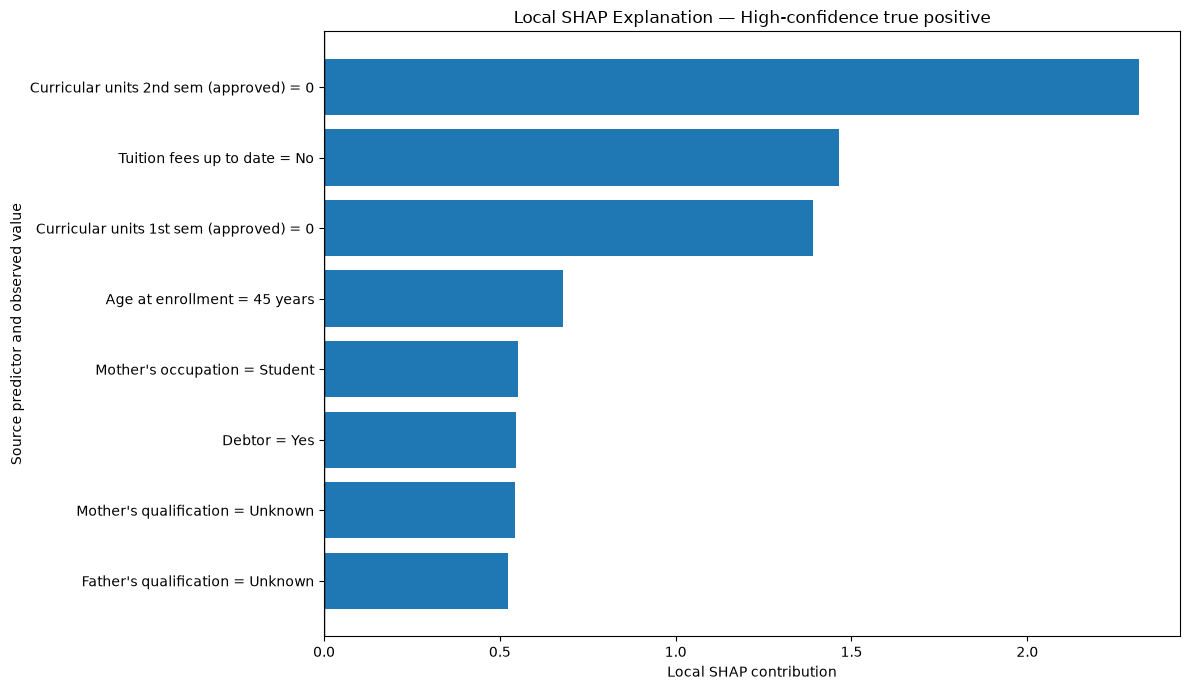

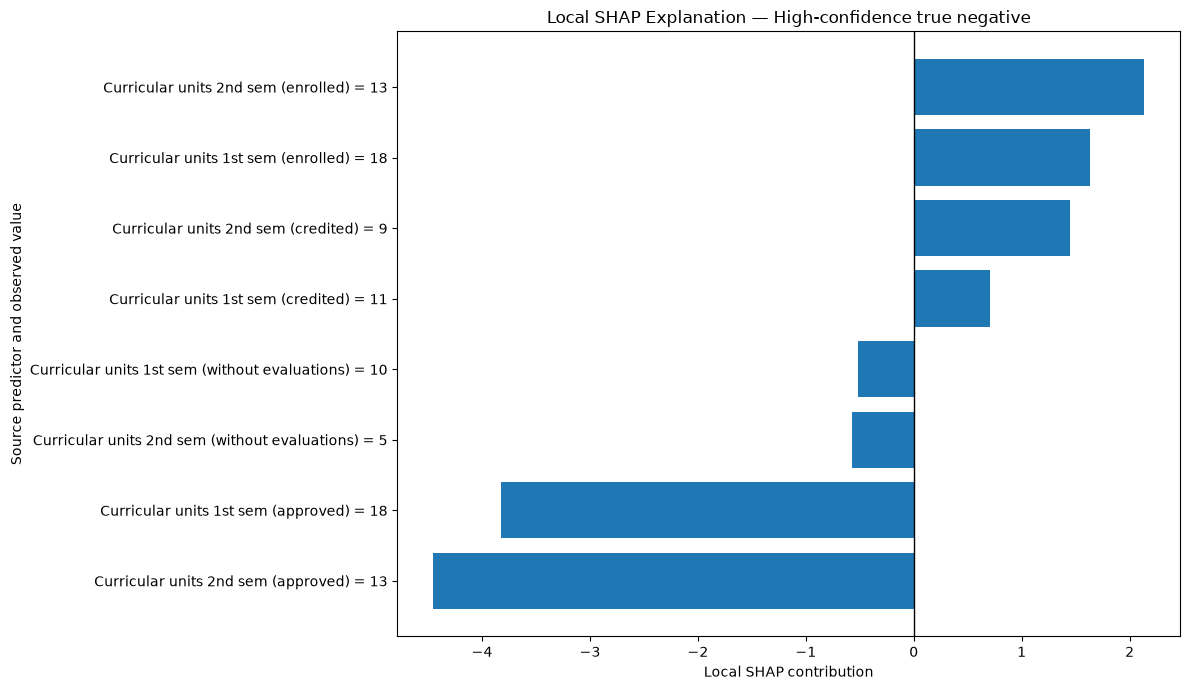

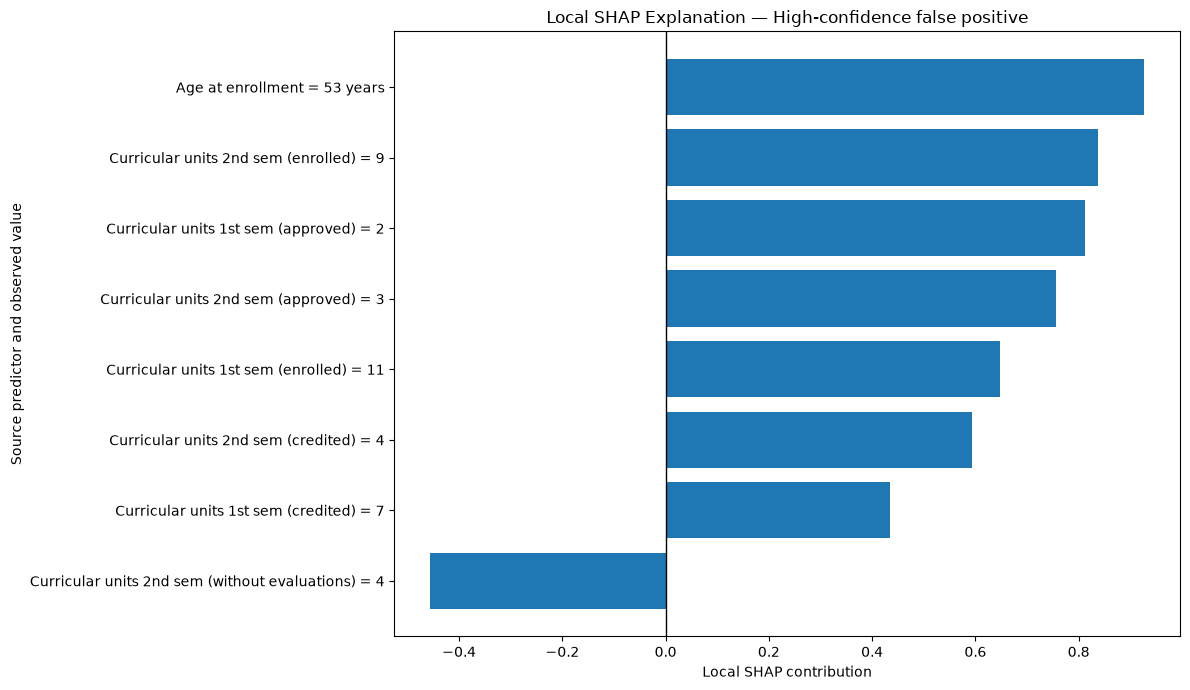

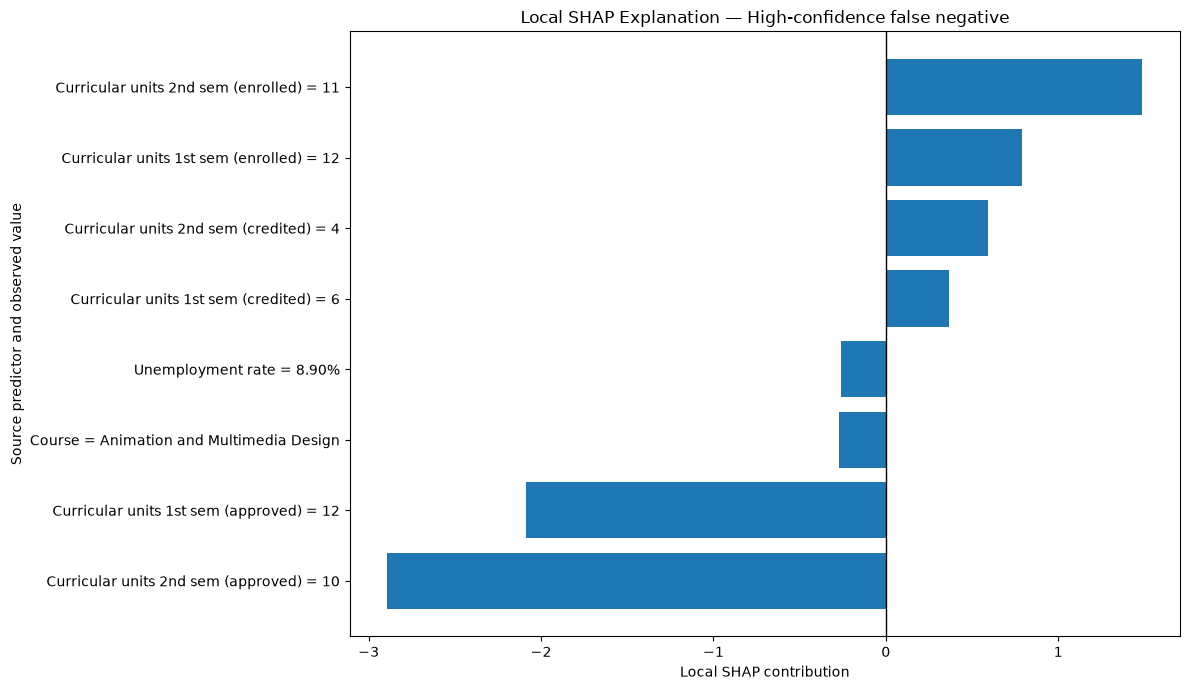

In [266]:
for case_label in (
    selected_local_explanations[
        "Case_Label"
    ]
    .unique()
):

    plot_data = (
        selected_local_explanations.loc[
            selected_local_explanations[
                "Case_Label"
            ] == case_label
        ]
        .sort_values(
            "SHAP_Value",
            ascending=True
        )
        .copy()
    )


    plt.figure(
        figsize=(12, 7)
    )


    plt.barh(
        plot_data[
            "Display_Label"
        ],
        plot_data[
            "SHAP_Value"
        ]
    )


    plt.axvline(
        0,
        linewidth=1,
        color="black"
    )


    plt.xlabel(
        "Local SHAP contribution"
    )


    plt.ylabel(
        "Source predictor and observed value"
    )


    plt.title(
        f"Local SHAP Explanation — "
        f"{case_label}"
    )


    plt.tight_layout()


    safe_case = (
        case_label
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


    plt.savefig(
        FIGURES_DIR
        / (
            f"phase18_"
            f"{safe_case}_"
            f"local_shap.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

### Finding: Local Explanation Visualisation

The four local SHAP figures provide a compact visual separation between features pushing predictions toward higher and lower modelled dropout risk.

The true-positive case is dominated by risk-raising contributions, particularly low semester approval performance and tuition-fee status.

The true-negative case contains strong risk-lowering contributions from high numbers of approved first- and second-semester curricular units.

The false-positive and false-negative figures are particularly informative because they make the model's error structure visible. The false-positive case shows why the model accumulated evidence for elevated risk, while the false-negative case shows how strong protective-looking academic contributions overwhelmed other risk signals.

Displaying only the strongest source-level predictors therefore provides a substantially more interpretable representation than exposing the complete transformed feature space.

The visualisations explain model behaviour rather than establish causal explanations of student outcomes.

## Phase 18.8: Compare the Selected Cases Across All Three Stage 3 Models

In [267]:
selected_case_model_rows = []


for _, case_row in (
    selected_local_cases.iterrows()
):

    student_index = (
        case_row[
            "Student_Index"
        ]
    )

    case_label = (
        case_row[
            "Case_Label"
        ]
    )

    for model_name in PRIMARY_MODELS:

        prediction_row = (
            final_test_predictions.loc[
                (
                    final_test_predictions[
                        "Stage"
                    ]
                    == "Stage 3"
                )
                &
                (
                    final_test_predictions[
                        "Model"
                    ]
                    == model_name
                )
                &
                (
                    final_test_predictions[
                        "Student_Index"
                    ]
                    == student_index
                )
            ]
            .iloc[0]
        )

        source_shap = (
            shap_source_value_matrices[
                (
                    "Stage 3",
                    model_name
                )
            ]
            .loc[
                student_index
            ]
        )

        top5_features = (
            source_shap
            .abs()
            .sort_values(
                ascending=False
            )
            .head(5)
            .index
            .tolist()
        )

        selected_case_model_rows.append({
            "Case_Label":
            case_label,

            "Student_Index":
            student_index,

            "Model":
            model_name,

            "Observed_Dropout":
            prediction_row[
                "Observed_Dropout"
            ],

            "Dropout_Probability":
            prediction_row[
                "Dropout_Probability"
            ],

            "Locked_Threshold":
            prediction_row[
                "Locked_Threshold"
            ],

            "Locked_Prediction":
            prediction_row[
                "Locked_Prediction"
            ],

            "Top_5_Local_Features":
            " | ".join(
                top5_features
            )
        })


selected_case_model_comparison = (
    pd.DataFrame(
        selected_case_model_rows
    )
)


selected_case_model_comparison

,Case_Label,Student_Index,Model,Observed_Dropout,Dropout_Probability,Locked_Threshold,Locked_Prediction,Top_5_Local_Features
0,High-confidence true positive,3533,Logistic Regression,1,0.999708,0.57,1,Curricular units 2nd sem (approved) | Tuition ...
1,High-confidence true positive,3533,Random Forest,1,0.976667,0.52,1,Curricular units 2nd sem (approved) | Tuition ...
2,High-confidence true positive,3533,Gradient Boosting,1,0.985556,0.62,1,Curricular units 2nd sem (approved) | Tuition ...
3,High-confidence true negative,894,Logistic Regression,0,0.012800,0.57,0,Curricular units 2nd sem (approved) | Curricul...
4,High-confidence true negative,894,Random Forest,0,0.333333,0.52,0,Curricular units 2nd sem (approved) | Curricul...
5,High-confidence true negative,894,Gradient Boosting,0,0.081545,0.62,0,Curricular units 2nd sem (approved) | Curricul...
6,High-confidence false positive,2447,Logistic Regression,0,0.991156,0.57,1,Age at enrollment | Curricular units 2nd sem (...
7,High-confidence false positive,2447,Random Forest,0,0.686667,0.52,1,Curricular units 1st sem (approved) | Curricul...
8,High-confidence false positive,2447,Gradient Boosting,0,0.915569,0.62,1,Curricular units 2nd sem (credited) | Curricul...
9,High-confidence false negative,4244,Logistic Regression,1,0.026556,0.57,0,Curricular units 2nd sem (approved) | Curricul...


### Finding: Selected-case Cross-model Comparison

All three Stage 3 model families agree on the final classification of each of the four representative cases.

For student 3533, all three models correctly predict Dropout. Logistic Regression assigns probability 0.9997, Random Forest 0.9767 and Gradient Boosting 0.9856.

For student 894, all three models correctly predict Non-dropout, although their confidence differs. Logistic Regression assigns probability 0.0128, Gradient Boosting 0.0815 and Random Forest 0.3333.

The high-confidence false-positive student 2447 is incorrectly classified as Dropout by all three models. Logistic Regression produces probability 0.9912, Gradient Boosting 0.9156 and Random Forest 0.6867.

The false-negative student 4244 is also misclassified by all three models, with probabilities of 0.0266 for Logistic Regression, 0.1700 for Random Forest and 0.1195 for Gradient Boosting.

The models therefore show substantial predictive agreement on these selected cases, including agreement on the two errors.

Their leading SHAP features also overlap visibly, particularly around semester academic-performance variables, although the exact feature ordering differs between algorithms.

This supports examining explanation consistency quantitatively across the complete held-out sample rather than judging agreement from only four cases.

## Phase 18.9: Quantify Cross-model Local Explanation Consistency

In [268]:
from itertools import combinations


LOCAL_TOP_K = 5


stage3_student_indices = (
    stage_datasets[
        "Stage 3"
    ][
        "X_test"
    ].index
)


model_pairs = list(
    combinations(
        PRIMARY_MODELS,
        2
    )
)


local_consistency_rows = []


for student_index in (
    stage3_student_indices
):

    for (
        model_a,
        model_b
    ) in model_pairs:

        shap_a = (
            shap_source_value_matrices[
                (
                    "Stage 3",
                    model_a
                )
            ]
            .loc[
                student_index
            ]
        )

        shap_b = (
            shap_source_value_matrices[
                (
                    "Stage 3",
                    model_b
                )
            ]
            .loc[
                student_index
            ]
        )

        top_a = set(
            shap_a
            .abs()
            .nlargest(
                LOCAL_TOP_K
            )
            .index
        )

        top_b = set(
            shap_b
            .abs()
            .nlargest(
                LOCAL_TOP_K
            )
            .index
        )

        shared_features = (
            top_a.intersection(
                top_b
            )
        )

        union_features = (
            top_a.union(
                top_b
            )
        )

        jaccard_similarity = (
            len(
                shared_features
            )
            /
            len(
                union_features
            )
        )

        if len(
            shared_features
        ) > 0:

            sign_agreement = np.mean([
                (
                    np.sign(
                        shap_a[
                            feature
                        ]
                    )
                    ==
                    np.sign(
                        shap_b[
                            feature
                        ]
                    )
                )
                for feature
                in shared_features
            ])

        else:

            sign_agreement = np.nan

        local_consistency_rows.append({
            "Student_Index":
            student_index,

            "Model_A":
            model_a,

            "Model_B":
            model_b,

            "Shared_Top5_Features":
            len(
                shared_features
            ),

            "Top5_Jaccard":
            jaccard_similarity,

            "Shared_Feature_Sign_Agreement":
            sign_agreement
        })


local_consistency = (
    pd.DataFrame(
        local_consistency_rows
    )
)


local_consistency_summary = (
    local_consistency
    .groupby(
        [
            "Model_A",
            "Model_B"
        ]
    )
    .agg(
        Mean_Shared_Top5=(
            "Shared_Top5_Features",
            "mean"
        ),
        Median_Shared_Top5=(
            "Shared_Top5_Features",
            "median"
        ),
        Mean_Top5_Jaccard=(
            "Top5_Jaccard",
            "mean"
        ),
        Median_Top5_Jaccard=(
            "Top5_Jaccard",
            "median"
        ),
        Mean_Sign_Agreement=(
            "Shared_Feature_Sign_Agreement",
            "mean"
        )
    )
    .reset_index()
    .round(4)
)


local_consistency_summary

,Model_A,Model_B,Mean_Shared_Top5,Median_Shared_Top5,Mean_Top5_Jaccard,Median_Top5_Jaccard,Mean_Sign_Agreement
0,Logistic Regression,Gradient Boosting,2.9763,3.0,0.4441,0.4286,0.9617
1,Logistic Regression,Random Forest,2.6282,3.0,0.3784,0.4286,0.9536
2,Random Forest,Gradient Boosting,3.6667,4.0,0.5970,0.6667,0.9989


### Finding: Cross-model Local Explanation Consistency

Cross-model explanation consistency was evaluated across all 885 Stage 3 held-out students.

Logistic Regression and Gradient Boosting share an average of 2.9763 of their five most influential local features, with mean Jaccard similarity of 0.4441.

Logistic Regression and Random Forest share an average of 2.6282 top-five predictors, with mean Jaccard similarity of 0.3784.

Random Forest and Gradient Boosting show the strongest feature overlap, sharing an average of 3.6667 top-five predictors. Their mean Jaccard similarity is 0.5970 and the median is 0.6667.

Feature-set agreement is therefore moderate rather than complete, which is reasonable because the three algorithms represent predictive relationships differently.

When a feature appears among the strongest explanations of both models, its directional interpretation is highly consistent. Mean sign agreement is 0.9617 between Logistic Regression and Gradient Boosting, 0.9536 between Logistic Regression and Random Forest, and 0.9989 between Random Forest and Gradient Boosting.

The models may differ in which predictors they rank among the five strongest for a student, but shared influential predictors usually push modelled risk in the same direction. This provides strong evidence of directional consistency alongside moderate feature-selection consistency, consistent with the expected behaviour of different model families explaining the same target (Lundberg and Lee, 2017; Lundberg et al., 2020).


## Phase 18.10: Measure Local Explanation Compactness and Actionability

In [269]:
local_readability_rows = []


for model_name in PRIMARY_MODELS:

    source_matrix = (
        shap_source_value_matrices[
            (
                "Stage 3",
                model_name
            )
        ]
    )

    for student_index, (
        student_shap
    ) in source_matrix.iterrows():

        abs_shap = (
            student_shap.abs()
        )

        total_abs = (
            abs_shap.sum()
        )

        top5_features = (
            abs_shap
            .nlargest(
                LOCAL_TOP_K
            )
            .index
            .tolist()
        )

        top5_abs_share = (
            abs_shap[
                top5_features
            ].sum()
            /
            total_abs
        )

        support_relevant_features = [
            feature
            for feature
            in student_shap.index
            if (
                actionability_lookup[
                    feature
                ]
                in [
                    "Actionable",
                    "Semi-actionable"
                ]
            )
        ]

        support_relevant_share = (
            abs_shap[
                support_relevant_features
            ].sum()
            /
            total_abs
        )

        top5_actionability_complete = all(
            actionability_lookup[
                feature
            ]
            in [
                "Actionable",
                "Semi-actionable",
                "Non-actionable"
            ]
            for feature
            in top5_features
        )

        local_readability_rows.append({
            "Student_Index":
            student_index,

            "Model":
            model_name,

            "Top5_Importance_Coverage":
            top5_abs_share,

            "Actionable_or_Semi_Actionable_Share":
            support_relevant_share,

            "Top5_Actionability_Complete":
            top5_actionability_complete
        })


local_readability = (
    pd.DataFrame(
        local_readability_rows
    )
)


local_readability_summary = (
    local_readability
    .groupby(
        "Model"
    )
    .agg(
        Mean_Top5_Importance_Coverage=(
            "Top5_Importance_Coverage",
            "mean"
        ),
        Median_Top5_Importance_Coverage=(
            "Top5_Importance_Coverage",
            "median"
        ),
        Mean_Actionable_or_Semi_Share=(
            "Actionable_or_Semi_Actionable_Share",
            "mean"
        ),
        Complete_Actionability_Rate=(
            "Top5_Actionability_Complete",
            "mean"
        )
    )
    .reset_index()
    .round(4)
)


local_readability_summary

,Model,Mean_Top5_Importance_Coverage,Median_Top5_Importance_Coverage,Mean_Actionable_or_Semi_Share,Complete_Actionability_Rate
0,Gradient Boosting,0.7031,0.7117,0.7303,1.0
1,Logistic Regression,0.5750,0.5694,0.5951,1.0
2,Random Forest,0.6050,0.5954,0.7132,1.0


### Finding: Explanation Compactness and Responsible-use Structure

The local explanations show meaningful compactness despite the Stage 3 models containing 35 source predictors.

For Gradient Boosting, the five strongest local features account for an average of 70.31% of total absolute SHAP attribution, with a median of 71.17%.

Random Forest achieves mean top-five coverage of 60.50% and median coverage of 59.54%.

Logistic Regression produces the least concentrated explanations, but its five strongest features still account for an average of 57.50% and median coverage of 56.94%.

A set of five predictors therefore captures more than half of the local absolute attribution on average for every model family.

The mean share associated with actionable or semi-actionable predictors is 73.03% for Gradient Boosting, 71.32% for Random Forest and 59.51% for Logistic Regression.

The actionability-completeness rate is 1.0000 for all three models, confirming that every top-five feature can be linked to the responsible-use framework established before modelling.

These findings indicate that the explanations can often be summarised using a manageable number of predictors while retaining explicit guidance about which variables may or may not responsibly inform student-support discussions.


## Phase 18.11: Create Practitioner-oriented Explanation Statements

In [270]:
practitioner_explanation_rows = []


for _, row in (
    selected_local_explanations
    .iterrows()
):

    feature_name = (
        row[
            "Source_Feature"
        ]
    )


    observed_value = (
        row[
            "Source_Value_Display"
        ]
    )


    if (
        row[
            "Direction"
        ]
        ==
        "Raises modelled dropout risk"
    ):

        statement = (
            f"{feature_name} "
            f"({observed_value}) was one of "
            f"the stronger factors pushing "
            f"this model prediction toward "
            f"higher dropout risk."
        )


    elif (
        row[
            "Direction"
        ]
        ==
        "Lowers modelled dropout risk"
    ):

        statement = (
            f"{feature_name} "
            f"({observed_value}) was one of "
            f"the stronger factors pushing "
            f"this model prediction toward "
            f"lower dropout risk."
        )


    else:

        statement = (
            f"{feature_name} "
            f"({observed_value}) made little "
            f"directional contribution to "
            f"this model prediction."
        )


    if (
        row[
            "Actionability"
        ]
        == "Non-actionable"
    ):

        responsible_note = (
            "Use as contextual information only; "
            "do not treat it as an intervention "
            "target."
        )


    elif (
        row[
            "Actionability"
        ]
        == "Semi-actionable"
    ):

        responsible_note = (
            "May support cautious referral or "
            "administrative follow-up after "
            "human review."
        )


    else:

        responsible_note = (
            "May help inform an academic-support "
            "discussion, without assuming that "
            "the feature caused the outcome."
        )


    practitioner_explanation_rows.append(
        {
            "Case_Label": (
                row[
                    "Case_Label"
                ]
            ),

            "Local_Rank": (
                row[
                    "Local_Rank"
                ]
            ),

            "Feature": (
                feature_name
            ),

            "Raw_Source_Value": (
                row[
                    "Source_Value"
                ]
            ),

            "Observed_Value": (
                observed_value
            ),

            "Explanation": (
                statement
            ),

            "Actionability": (
                row[
                    "Actionability"
                ]
            ),

            "Responsible_Use_Note": (
                responsible_note
            )
        }
    )


practitioner_explanation_table = (
    pd.DataFrame(
        practitioner_explanation_rows
    )
)


practitioner_explanation_table[
    [
        "Case_Label",
        "Local_Rank",
        "Feature",
        "Observed_Value",
        "Explanation",
        "Actionability",
        "Responsible_Use_Note"
    ]
]

,Case_Label,Local_Rank,Feature,Observed_Value,Explanation,Actionability,Responsible_Use_Note
0,High-confidence true positive,1,Curricular units 2nd sem (approved),0,Curricular units 2nd sem (approved) (0) was on...,Actionable,May help inform an academic-support discussion...
1,High-confidence true positive,2,Tuition fees up to date,No,Tuition fees up to date (No) was one of the st...,Semi-actionable,May support cautious referral or administrativ...
2,High-confidence true positive,3,Curricular units 1st sem (approved),0,Curricular units 1st sem (approved) (0) was on...,Actionable,May help inform an academic-support discussion...
3,High-confidence true positive,4,Age at enrollment,45 years,Age at enrollment (45 years) was one of the st...,Non-actionable,Use as contextual information only; do not tre...
4,High-confidence true positive,5,Mother's occupation,Student,Mother's occupation (Student) was one of the s...,Non-actionable,Use as contextual information only; do not tre...
5,High-confidence true positive,6,Debtor,Yes,Debtor (Yes) was one of the stronger factors p...,Semi-actionable,May support cautious referral or administrativ...
6,High-confidence true positive,7,Mother's qualification,Unknown,Mother's qualification (Unknown) was one of th...,Non-actionable,Use as contextual information only; do not tre...
7,High-confidence true positive,8,Father's qualification,Unknown,Father's qualification (Unknown) was one of th...,Non-actionable,Use as contextual information only; do not tre...
8,High-confidence true negative,1,Curricular units 2nd sem (approved),13,Curricular units 2nd sem (approved) (13) was o...,Actionable,May help inform an academic-support discussion...
9,High-confidence true negative,2,Curricular units 1st sem (approved),18,Curricular units 1st sem (approved) (18) was o...,Actionable,May help inform an academic-support discussion...


### Finding: Plain-language Explanation Translation


Each statement identifies the original source variable and its observed value and explains whether that value pushes the fitted prediction toward higher or lower modelled dropout risk.

Categorical values are presented using verified dataset labels where available. Unverified occupation categories remain explicitly identified as codes and are not treated as ordered numerical values.

The translation follows the actionability framework established before model development, ensuring that non-actionable characteristics such as age and nationality are described as contextual information rather than as intervention recommendations (Yu, Lee and Kizilcec, 2021).

The output demonstrates that numerical SHAP contributions can be converted into a more accessible explanatory format while retaining responsible-use boundaries.

This remains analytical evidence of explainability. No direct practitioner study was conducted to establish whether higher-education practitioners find the explanations understandable or useful in practice.

## Phase 18.12: Summarise the Analytical Interpretability Evidence

In [271]:
overall_mean_jaccard = (
    local_consistency[
        "Top5_Jaccard"
    ].mean()
)

overall_mean_sign_agreement = (
    local_consistency[
        "Shared_Feature_Sign_Agreement"
    ].mean()
)

overall_mean_top5_coverage = (
    local_readability[
        "Top5_Importance_Coverage"
    ].mean()
)

overall_mean_support_relevant_share = (
    local_readability[
        "Actionable_or_Semi_Actionable_Share"
    ].mean()
)

overall_actionability_complete = (
    local_readability[
        "Top5_Actionability_Complete"
    ].mean()
)


phase18_interpretability_evidence = (
    pd.DataFrame([
        {
            "Interpretability_Dimension":
            "Source-level readability",

            "Evidence":
            (
                "Encoded SHAP contributions "
                "reconstructed to original "
                "source predictors."
            ),

            "Observed_Value":
            "Complete"
        },
        {
            "Interpretability_Dimension":
            "Directional clarity",

            "Evidence":
            (
                "Each contribution labelled "
                "as raising or lowering "
                "modelled dropout risk."
            ),

            "Observed_Value":
            "Complete"
        },
        {
            "Interpretability_Dimension":
            "Top-five compactness",

            "Evidence":
            (
                "Mean share of local absolute "
                "SHAP captured by five "
                "strongest features."
            ),

            "Observed_Value":
            round(
                overall_mean_top5_coverage,
                4
            )
        },
        {
            "Interpretability_Dimension":
            "Cross-model feature consistency",

            "Evidence":
            (
                "Mean pairwise top-five "
                "Jaccard similarity."
            ),

            "Observed_Value":
            round(
                overall_mean_jaccard,
                4
            )
        },
        {
            "Interpretability_Dimension":
            "Cross-model directional consistency",

            "Evidence":
            (
                "Mean sign agreement among "
                "shared top-five features."
            ),

            "Observed_Value":
            round(
                overall_mean_sign_agreement,
                4
            )
        },
        {
            "Interpretability_Dimension":
            "Responsible-use mapping",

            "Evidence":
            (
                "Top-five features with an "
                "existing actionability category."
            ),

            "Observed_Value":
            round(
                overall_actionability_complete,
                4
            )
        },
        {
            "Interpretability_Dimension":
            "Support-relevant attribution",

            "Evidence":
            (
                "Mean local absolute SHAP share "
                "associated with actionable or "
                "semi-actionable predictors."
            ),

            "Observed_Value":
            round(
                overall_mean_support_relevant_share,
                4
            )
        },
        {
            "Interpretability_Dimension":
            "Practitioner validation",

            "Evidence":
            (
                "No direct practitioner "
                "usability study was conducted."
            ),

            "Observed_Value":
            "Not evaluated"
        }
    ])
)


phase18_interpretability_evidence

,Interpretability_Dimension,Evidence,Observed_Value
0,Source-level readability,Encoded SHAP contributions reconstructed to or...,Complete
1,Directional clarity,Each contribution labelled as raising or lower...,Complete
2,Top-five compactness,Mean share of local absolute SHAP captured by ...,0.6277
3,Cross-model feature consistency,Mean pairwise top-five Jaccard similarity.,0.4731
4,Cross-model directional consistency,Mean sign agreement among shared top-five feat...,0.9714
5,Responsible-use mapping,Top-five features with an existing actionabili...,1.0
6,Support-relevant attribution,Mean local absolute SHAP share associated with...,0.6796
7,Practitioner validation,No direct practitioner usability study was con...,Not evaluated


### Finding: Analytical Interpretability Evidence

The interpretability evidence combines structural readability, explanation compactness, cross-model consistency, directional agreement and responsible-use mapping.

No arbitrary numerical pass threshold is introduced after observing the explanation results.

Instead, the quantitative evidence will be interpreted together with the selected case explanations and the important limitation that no practitioner usability study was conducted.

This distinction is necessary before determining whether H4 should be classified as supported, partially supported or not supported.

## Phase 18.13: Preserve the Local Interpretability Evidence

In [272]:
selected_local_cases.to_csv(
    TABLES_DIR
    / "phase18_selected_local_cases.csv",
    index=False
)

selected_local_explanations.to_csv(
    TABLES_DIR
    / "phase18_selected_local_explanations.csv",
    index=False
)

selected_case_model_comparison.to_csv(
    TABLES_DIR
    / "phase18_selected_case_model_comparison.csv",
    index=False
)

local_consistency.to_csv(
    TABLES_DIR
    / "phase18_local_consistency_all_students.csv",
    index=False
)

local_consistency_summary.to_csv(
    TABLES_DIR
    / "phase18_local_consistency_summary.csv",
    index=False
)

local_readability.to_csv(
    TABLES_DIR
    / "phase18_local_readability_all_students.csv",
    index=False
)

local_readability_summary.to_csv(
    TABLES_DIR
    / "phase18_local_readability_summary.csv",
    index=False
)

practitioner_explanation_table.to_csv(
    TABLES_DIR
    / "phase18_practitioner_explanation_table.csv",
    index=False
)

phase18_interpretability_evidence.to_csv(
    TABLES_DIR
    / "phase18_interpretability_evidence.csv",
    index=False
)

stage3_actionability_audit.to_csv(
    TABLES_DIR
    / "phase18_stage3_actionability_audit.csv",
    index=False
)

print(
    "Phase 18 local interpretability "
    "outputs saved successfully."
)

Phase 18 local interpretability outputs saved successfully.


### Finding: Local Interpretability Evidence Preserved

All Phase 18 interpretability outputs were successfully exported.

The preserved evidence includes the four objectively selected cases, detailed source-level SHAP explanations, cross-model case comparisons, all-student consistency measures, explanation compactness and actionability results, practitioner-oriented explanation statements and the consolidated interpretability evidence table.

The four local SHAP figures were also saved.

This provides a reproducible record of the analytical evidence used to assess RQ3, Objective 3 and H4.

## Phase 18.14: Research Evidence Status after Local SHAP Analysis

In [273]:
phase18_research_alignment = pd.DataFrame([
    {
        "Research_Element":
        "RQ1 / Objective 1",

        "Evidence_Status":
        (
            "Completed through final "
            "held-out evaluation."
        ),

        "Final_Assessment_Possible":
        "Yes"
    },
    {
        "Research_Element":
        "H1",

        "Evidence_Status":
        "Not supported.",

        "Final_Assessment_Possible":
        "Yes"
    },
    {
        "Research_Element":
        "H2",

        "Evidence_Status":
        "Supported.",

        "Final_Assessment_Possible":
        "Yes"
    },
    {
        "Research_Element":
        "RQ2 / Objective 2",

        "Evidence_Status":
        (
            "Completed through global "
            "SHAP attribution."
        ),

        "Final_Assessment_Possible":
        "Yes"
    },
    {
        "Research_Element":
        "H3",

        "Evidence_Status":
        "Supported.",

        "Final_Assessment_Possible":
        "Yes"
    },
    {
        "Research_Element":
        "RQ3 / Objective 3",

        "Evidence_Status":
        (
            "Local SHAP readability, "
            "consistency, compactness and "
            "actionability evidence available."
        ),

        "Final_Assessment_Possible":
        "Yes"
    },
    {
        "Research_Element":
        "H4",

        "Evidence_Status":
        (
            "Analytical interpretability "
            "evidence now available; "
            "practitioner validation absent."
        ),

        "Final_Assessment_Possible":
        "Yes"
    }
])


phase18_research_alignment

,Research_Element,Evidence_Status,Final_Assessment_Possible
0,RQ1 / Objective 1,Completed through final held-out evaluation.,Yes
1,H1,Not supported.,Yes
2,H2,Supported.,Yes
3,RQ2 / Objective 2,Completed through global SHAP attribution.,Yes
4,H3,Supported.,Yes
5,RQ3 / Objective 3,"Local SHAP readability, consistency, compactne...",Yes
6,H4,Analytical interpretability evidence now avail...,Yes


### Finding: Research Evidence Status after Local SHAP Analysis

Phase 18 provides sufficient analytical evidence to answer RQ3, assess Objective 3 and evaluate H4.

For RQ3, SHAP provides clear source-level explanations of individual dropout-risk predictions. Contributions can be expressed using original predictor names, translated into explicit risk-raising or risk-lowering directions and linked to the pre-specified actionability framework.

Explanation compactness is meaningful: the five strongest predictors account for an average of 62.77% of local absolute SHAP attribution across models.

Cross-model feature selection is moderately consistent, with overall mean top-five Jaccard similarity = 0.4731. Directional interpretation is substantially more consistent, with mean sign agreement = 0.9714 for features identified as important by more than one model.

An average 67.96% of local absolute SHAP attribution is associated with actionable or semi-actionable predictors, while all leading features retain a valid responsible-use classification.

Objective 3 is therefore achieved at an analytical level because SHAP explanation clarity, consistency and support relevance have been systematically evaluated.

H4 is classified as **partially supported**.

The hypothesis expected SHAP to provide transparent feature-level attributions supporting non-technical interpretation. The analysis strongly supports feature-level transparency, directional clarity and responsible translation, but cross-model feature agreement is moderate rather than complete.

More importantly, no practitioner usability study was conducted. The study can therefore demonstrate analytical interpretability but cannot establish that non-technical higher education practitioners would actually find the explanations understandable, useful or operationally effective.

This qualification prevents the analytical evidence from being overstated as direct practitioner validation.

## Phase 18.15: Overall Phase 18 Summary

Local SHAP analysis was completed to evaluate whether individual dropout-risk predictions could be explained in a clear, consistent and responsibly interpretable manner.
Stage 3 Logistic Regression was used as the principal case-level explanation model because it produced the highest held-out ROC-AUC and locked-threshold F1 point estimates.

This selection does not imply statistical superiority over Random Forest or Gradient Boosting, which were retained for cross-model consistency analysis.

Four held-out students were selected objectively before inspecting their local SHAP patterns: a high-confidence true positive, true negative, false positive and false negative.

The true-positive and true-negative cases demonstrate how academic-progress variables can strongly push predictions toward higher or lower modelled dropout risk.

The two misclassified cases are equally important. Their explanations show that SHAP can make the internal reasoning behind a model error visible, while also demonstrating that an interpretable prediction is not necessarily a correct prediction.

Across all 885 Stage 3 held-out students, local explanation compactness is meaningful. The five strongest features account for an average of 62.77% of total absolute SHAP attribution across the three models.

Gradient Boosting produces the most concentrated local explanations with mean top-five coverage of 70.31%, followed by Random Forest at 60.50% and Logistic Regression at 57.50%.

Cross-model agreement on the exact five strongest features is moderate. Mean pairwise Jaccard similarity across the three model pairs is 0.4731.

However, directional consistency is very high. When different models identify the same feature as locally important, its SHAP contribution points in the same risk direction in approximately 97.14% of comparisons.

The responsible-use framework also integrates successfully with the SHAP explanations. Every leading feature retains a valid actionability classification, and actionable or semi-actionable predictors account for an average of 67.96% of local absolute attribution.

The four case explanations were successfully converted into plain-language statements distinguishing risk-raising from risk-lowering factors and separating contextual non-actionable information from variables that may cautiously inform support discussions.

RQ3 is therefore answered analytically: SHAP can provide clear source-level and directional explanations, reasonably compact summaries and highly consistent directional interpretation across models. Exact feature prioritisation is less consistent across model families, indicating that explanation structure remains partly model-dependent.

Objective 3 is achieved through the systematic assessment of source-level readability, explanation compactness, cross-model consistency, directional agreement and responsible actionability.

H4 is classified as partially supported.

The evidence strongly supports transparent feature-level attribution and the possibility of translating SHAP output into a more accessible form. However, moderate cross-model feature agreement and the absence of a practitioner usability study prevent a stronger claim that SHAP explanations have been demonstrated to support non-technical practitioner interpretation in real institutional practice.

No causal interpretation is made. SHAP explains the fitted model's prediction rather than demonstrating why a student drops out or what intervention would necessarily change that outcome.

At the end of Phase 18, the principal research hypotheses are therefore:

H1: Not supported.
H2: Supported.
H3: Supported.
H4: Partially supported.

RQ1 and Objective 1 were addressed through final predictive evaluation.

RQ2 and Objective 2 were addressed through global SHAP attribution.

RQ3 and Objective 3 are now addressed through the local SHAP and analytical interpretability assessment.

No causal interpretation is made. SHAP explains the fitted model's prediction rather than demonstrating why a student drops out or what intervention would necessarily change that outcome (Lundberg and Lee, 2017).

### Code Attribution — Phase 18

SHAP Documentation, 2025. *SHAP documentation* [Source code/documentation]. Available at: <https://shap.readthedocs.io/en/latest/> [Accessed 14 September 2026].

SHAP Documentation, 2025. *shap.LinearExplainer* [Source code/documentation]. Available at: <https://shap.readthedocs.io/en/latest/generated/shap.LinearExplainer.html> [Accessed 14 September 2026].

SHAP Documentation, 2025. *shap.plots.waterfall* [Source code/documentation]. Available at: <https://shap.readthedocs.io/en/latest/generated/shap.plots.waterfall.html> [Accessed 14 September 2026].

SHAP Documentation, 2025. *shap.plots.bar* [Source code/documentation]. Available at: <https://shap.readthedocs.io/en/latest/generated/shap.plots.bar.html> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.abs* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/generated/numpy.absolute.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame.groupby* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html> [Accessed 14 September 2026].

Matplotlib developers, 2025. *matplotlib.pyplot.savefig* [Source code/documentation]. Available at: <https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html> [Accessed 14 September 2026].

UCI Machine Learning Repository, 2026. *Predict students' dropout and academic success — variable descriptions* [dataset]. Available at: <https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success> [Accessed 14 September 2026].

# Phase 19: Responsible-use, Reliability and Supplementary Interpretability Checks

The primary predictive-performance and SHAP analyses are now complete.

Phase 19 extends the study with supplementary analyses intended to evaluate the reliability, error behaviour and responsible interpretation of the final models rather than to improve their predictive performance.

The phase examines probability calibration, subgroup performance, false-negative behaviour and supplementary local explanation methods.

Subgroup analysis includes both demographic and socioeconomic characteristics in accordance with the approved research design.

SHAP remains the primary interpretability framework. LIME is used only as a supplementary local comparison (Ribeiro, Singh and Guestrin, 2016), while DiCE is restricted to a small illustrative counterfactual analysis using only variables that were classified as actionable or semi-actionable before model results were inspected (Mothilal, Sharma and Tan, 2020).

All analyses in this phase use models, feature sets, hyperparameters and classification thresholds that were already locked before the held-out test results became available.

No result in Phase 19 will be used to retrain a model, alter a threshold, change a feature set or revise the primary model-selection decisions.

Subgroup differences are interpreted descriptively and do not by themselves establish algorithmic discrimination.

Similarly, counterfactual explanations represent hypothetical model-based scenarios rather than causal intervention recommendations (Mothilal, Sharma and Tan, 2020).

## Phase 19.1: Decision Record for Supplementary Responsible-use Analysis

### Decision Record: Scope of Responsible-use Checks

#### Observation

The final models achieve strong predictive performance, but aggregate predictive metrics alone do not establish whether probability outputs are reliable, whether errors are distributed similarly across relevant student groups, or whether individual predictions can be translated responsibly into potential support contexts.

False negatives are particularly important because they represent students who ultimately belong to the Dropout class but are not identified as high risk by the final classification rule.

The approved methodology also specifies supplementary subgroup, partial reliability and interpretability analyses following completion of the primary model evaluation.

#### Decision

Phase 19 will examine:

- held-out probability calibration;
- demographic subgroup performance;
- socioeconomic subgroup performance;
- false-negative behaviour;
- a constrained DiCE counterfactual example; and
- a supplementary LIME local explanation.

Stage 3 receives particular attention because it provides the strongest predictive performance and the richest available academic information.

#### Justification

These analyses strengthen the ethical and practical interpretation of the final models without creating another model-development stage.

No model, preprocessing rule, hyperparameter, class-imbalance strategy or threshold will be modified in response to the findings.

## Phase 19.2: Import Responsible-use and Reliability Utilities

In [274]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

import dice_ml

from lime.lime_tabular import (
    LimeTabularExplainer
)

## Phase 19.3: Assess Held-out Probability Calibration

In [275]:
calibration_rows = []


for stage_name in stage_feature_sets:

    for model_name in PRIMARY_MODELS:

        model_data = (
            final_test_predictions.loc[
                (
                    final_test_predictions[
                        "Stage"
                    ] == stage_name
                )
                &
                (
                    final_test_predictions[
                        "Model"
                    ] == model_name
                )
            ]
        )

        y_true = (
            model_data[
                "Observed_Dropout"
            ].to_numpy()
        )

        y_prob = (
            model_data[
                "Dropout_Probability"
            ].to_numpy()
        )

        calibration_rows.append({
            "Stage":
            stage_name,

            "Model":
            model_name,

            "Brier_Score":
            brier_score_loss(
                y_true,
                y_prob
            ),

            "Observed_Dropout_Rate":
            y_true.mean(),

            "Mean_Predicted_Probability":
            y_prob.mean(),

            "Mean_Probability_Bias":
            (
                y_prob.mean()
                -
                y_true.mean()
            )
        })


calibration_summary = (
    pd.DataFrame(
        calibration_rows
    )
    .sort_values(
        [
            "Stage",
            "Brier_Score"
        ]
    )
    .reset_index(drop=True)
)


calibration_summary.round(4)

,Stage,Model,Brier_Score,Observed_Dropout_Rate,Mean_Predicted_Probability,Mean_Probability_Bias
0,Stage 1,Gradient Boosting,0.1583,0.3209,0.4335,0.1126
1,Stage 1,Logistic Regression,0.1611,0.3209,0.4423,0.1214
2,Stage 1,Random Forest,0.1759,0.3209,0.4550,0.1341
3,Stage 2,Logistic Regression,0.1076,0.3209,0.3988,0.0779
4,Stage 2,Gradient Boosting,0.1141,0.3209,0.4099,0.0890
5,Stage 2,Random Forest,0.1154,0.3209,0.3771,0.0562
6,Stage 3,Logistic Regression,0.0928,0.3209,0.3971,0.0762
7,Stage 3,Gradient Boosting,0.0960,0.3209,0.3985,0.0776
8,Stage 3,Random Forest,0.0962,0.3209,0.3707,0.0498


### Finding: Held-out Probability Calibration

Probabilistic performance improves substantially as later academic information becomes available.

At Stage 1, Brier scores range from 0.1583 for Gradient Boosting to 0.1759 for Random Forest.

At Stage 2, Brier scores improve to 0.1076 for Logistic Regression, 0.1141 for Gradient Boosting and 0.1154 for Random Forest.

Stage 3 produces the strongest probabilistic accuracy for all three model families. Logistic Regression achieves the lowest Brier score of 0.0928, followed by Gradient Boosting at 0.0960 and Random Forest at 0.0962.

The observed dropout prevalence in the held-out partition is 0.3209.

All nine model-stage combinations produce mean predicted dropout probabilities above the observed prevalence. The amount of average overprediction is greatest at Stage 1 and becomes smaller at the later prediction stages.

At Stage 3, mean probability bias is +0.0762 for Logistic Regression, +0.0776 for Gradient Boosting and +0.0498 for Random Forest.

The later-stage models therefore provide more accurate probability estimates than the Stage 1 models, but their numerical outputs should still be treated as model-based risk scores rather than perfectly calibrated estimates of an individual student's real-world probability of dropping out (Brier, 1950).

No probability recalibration is fitted to the held-out test data.

## Phase 19.4: Visualise Stage 3 Probability Calibration

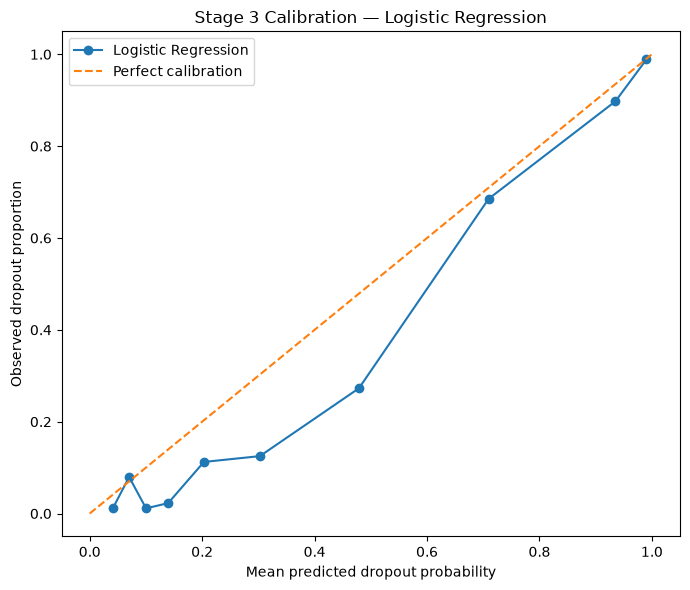

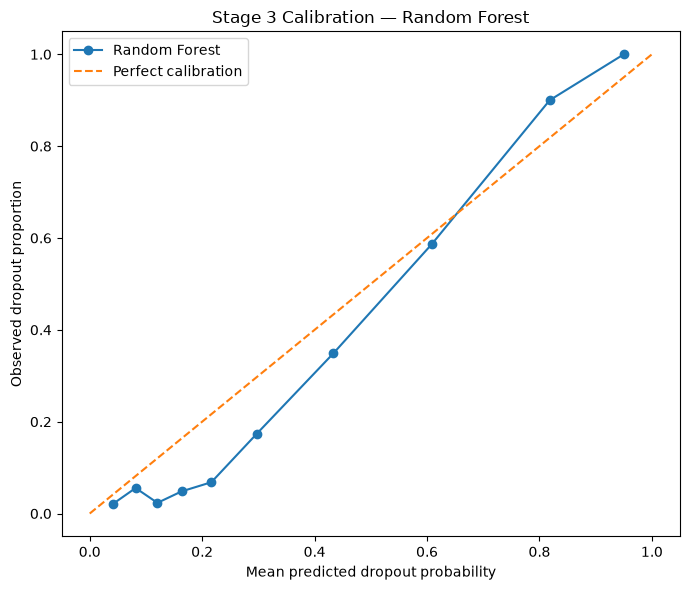

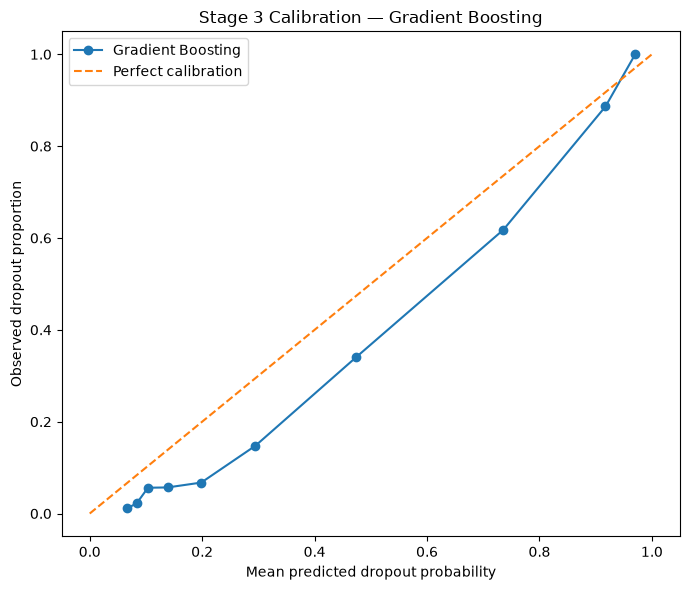

In [276]:
for model_name in PRIMARY_MODELS:

    model_data = (
        final_test_predictions.loc[
            (
                final_test_predictions[
                    "Stage"
                ] == "Stage 3"
            )
            &
            (
                final_test_predictions[
                    "Model"
                ] == model_name
            )
        ]
    )

    y_true = (
        model_data[
            "Observed_Dropout"
        ].to_numpy()
    )

    y_prob = (
        model_data[
            "Dropout_Probability"
        ].to_numpy()
    )

    prob_true, prob_pred = (
        calibration_curve(
            y_true,
            y_prob,
            n_bins=10,
            strategy="quantile"
        )
    )

    plt.figure(
        figsize=(7, 6)
    )

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        label=model_name
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    plt.xlabel(
        "Mean predicted dropout probability"
    )

    plt.ylabel(
        "Observed dropout proportion"
    )

    plt.title(
        f"Stage 3 Calibration — "
        f"{model_name}"
    )

    plt.legend()

    plt.tight_layout()

    safe_model = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    plt.savefig(
        FIGURES_DIR
        / (
            f"phase19_stage3_"
            f"{safe_model}_"
            f"calibration.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### Finding: Stage 3 Calibration Curves

The Stage 3 calibration curves provide a visual reliability check alongside the Brier-score analysis.

All three Stage 3 models achieve substantially stronger probabilistic accuracy than their Stage 1 equivalents.

However, their mean predicted dropout probabilities remain above the observed held-out dropout prevalence of 0.3209.

Logistic Regression produces a mean predicted probability of 0.3971, Gradient Boosting 0.3985 and Random Forest 0.3707.

The probability outputs should therefore be interpreted primarily as comparative model-based risk scores rather than literal, perfectly calibrated real-world dropout probabilities.

This qualification is particularly relevant because class weighting was deliberately used during model fitting to improve treatment of the minority Dropout class, which can shift predicted probability distributions away from their observed base rates (He and Garcia, 2009).
The calibration assessment remains descriptive and does not trigger post-test recalibration.

## Phase 19.5: Define the Combined Demographic and Socioeconomic Subgroup Audit

## Fairness Subgroup Stability Rule

Subgroup reliability is assessed separately for each metric because the relevant denominator differs between metrics:

- Recall and false-negative rate use the number of observed dropout cases.
- False-positive rate uses the number of observed non-dropout cases.
- Predicted-positive rate uses the total subgroup size.

A minimum relevant denominator of 30 is used as a descriptive adequacy flag. 

Wilson 95% confidence intervals are also reported for the rate metrics, as they provide more reliable binomial-rate estimates than the standard normal approximation when subgroup denominators are limited (Wilson, 1927).
 
 A subgroup with at least 30 total observations is therefore not automatically considered adequate for every fairness metric.

These thresholds are pragmatic analytical flags rather than formal proof that a subgroup estimate is stable. Small denominators and wide confidence intervals require cautious interpretation.

### Decision Record: Metric-specific Subgroup Performance Audit

#### Observation

The research design specifies a supplementary assessment of model performance across selected demographic and socioeconomic groups, with particular attention to false-negative rates.

Gender, age and International status provide demographic context. Scholarship-holder status, Debtor status and Tuition-fee status provide socioeconomic or financial context.

Subgroup reliability cannot be determined using total subgroup size alone because different performance metrics use different denominators. Recall and false-negative rate depend on the number of observed dropout cases, while false-positive rate depends on the number of observed non-dropout cases.

#### Decision

Stage 3 locked-threshold predictions will be examined across:

- Gender;
- Age group;
- International status;
- Scholarship-holder status;
- Debtor status; and
- Tuition-fee status.

The age categories are defined as `Age ≤20`, `Age 21–24` and `Age ≥25`.

Metric-specific denominator rules will be applied:

- Recall and false-negative rate use the number of observed dropout cases.
- False-positive rate uses the number of observed non-dropout cases.
- Predicted-positive rate uses the total subgroup size.

A minimum relevant denominator of 30 is used as a descriptive adequacy flag. Wilson 95% confidence intervals are reported for Recall, false-negative rate, false-positive rate and predicted-positive rate.

#### Justification

The subgroup variables were selected because of their responsible-use relevance and alignment with the approved research design rather than because of observed model results.

Metric-specific denominators reduce the risk of treating a rate as stable merely because the total subgroup size is relatively large. Confidence intervals provide additional evidence about estimation uncertainty.

The minimum-denominator rule is a pragmatic descriptive safeguard rather than a formal statistical guarantee.The audit remains exploratory and does not independently establish causal discrimination or algorithmic fairness (Yu, Lee and Kizilcec, 2021).

## Phase 19.6: Attach Demographic and Socioeconomic Characteristics to Stage 3 Predictions

In [277]:



test_subgroup_data = (
    df.loc[
        y_test.index,
        [
            "Gender",
            "Age at enrollment",
            "International",
            "Scholarship holder",
            "Debtor",
            "Tuition fees up to date"
        ]
    ]
    .copy()
)


test_subgroup_data[
    "Gender_Group"
] = (
    "Gender="
    +
    test_subgroup_data[
        "Gender"
    ]
    .astype(int)
    .astype(str)
)


test_subgroup_data[
    "Age_Group"
] = pd.cut(
    test_subgroup_data[
        "Age at enrollment"
    ],
    bins=[
        -np.inf,
        20,
        24,
        np.inf
    ],
    labels=[
        "Age ≤20",
        "Age 21–24",
        "Age ≥25"
    ]
)


test_subgroup_data[
    "International_Group"
] = np.where(
    test_subgroup_data[
        "International"
    ] == 1,
    "International=1",
    "International=0"
)


test_subgroup_data[
    "Scholarship_Group"
] = (
    "Scholarship holder="
    +
    test_subgroup_data[
        "Scholarship holder"
    ]
    .astype(int)
    .astype(str)
)


test_subgroup_data[
    "Debtor_Group"
] = (
    "Debtor="
    +
    test_subgroup_data[
        "Debtor"
    ]
    .astype(int)
    .astype(str)
)


test_subgroup_data[
    "Tuition_Group"
] = (
    "Tuition fees up to date="
    +
    test_subgroup_data[
        "Tuition fees up to date"
    ]
    .astype(int)
    .astype(str)
)


stage3_subgroup_predictions = (
    final_test_predictions.loc[
        final_test_predictions[
            "Stage"
        ] == "Stage 3"
    ]
    .merge(
        test_subgroup_data[
            [
                "Gender_Group",
                "Age_Group",
                "International_Group",
                "Scholarship_Group",
                "Debtor_Group",
                "Tuition_Group"
            ]
        ],
        left_on="Student_Index",
        right_index=True,
        how="left"
    )
)


assert (
    stage3_subgroup_predictions[
        [
            "Gender_Group",
            "Age_Group",
            "International_Group",
            "Scholarship_Group",
            "Debtor_Group",
            "Tuition_Group"
        ]
    ]
    .notna()
    .all()
    .all()
)


print(
    "Stage 3 prediction rows:",
    len(
        stage3_subgroup_predictions
    )
)

print(
    "Unique held-out students:",
    stage3_subgroup_predictions[
        "Student_Index"
    ].nunique()
)


stage3_subgroup_predictions.head()

Stage 3 prediction rows: 2655
Unique held-out students: 885


,Student_Index,Stage,Model,Observed_Dropout,Dropout_Probability,Default_Threshold,Default_Prediction,Locked_Threshold,Locked_Prediction,Gender_Group,Age_Group,International_Group,Scholarship_Group,Debtor_Group,Tuition_Group
5310,0,Stage 3,Logistic Regression,1,0.723819,0.5,1,0.57,1,Gender=1,Age ≤20,International=0,Scholarship holder=0,Debtor=0,Tuition fees up to date=1
5311,3,Stage 3,Logistic Regression,0,0.265549,0.5,0,0.57,0,Gender=0,Age ≤20,International=0,Scholarship holder=0,Debtor=0,Tuition fees up to date=1
5312,6,Stage 3,Logistic Regression,0,0.030233,0.5,0,0.57,0,Gender=0,Age ≤20,International=0,Scholarship holder=1,Debtor=0,Tuition fees up to date=1
5313,17,Stage 3,Logistic Regression,0,0.095975,0.5,0,0.57,0,Gender=0,Age ≤20,International=0,Scholarship holder=0,Debtor=0,Tuition fees up to date=1
5314,22,Stage 3,Logistic Regression,0,0.084826,0.5,0,0.57,0,Gender=0,Age ≤20,International=0,Scholarship holder=0,Debtor=0,Tuition fees up to date=1


### Finding: Subgroup Characteristics Linked Successfully

Demographic and socioeconomic characteristics were successfully linked to the Stage 3 held-out prediction records using the original student indices.

The combined subgroup dataset contains predictions for the same 885 held-out students across all three final Stage 3 models.

Gender is retained using the dataset's original codes rather than assigning unsupported descriptive labels.

International status remains available for responsible-use analysis even though it was excluded from primary model fitting because of deterministic redundancy with `Nacionality`.

Scholarship-holder, Debtor and Tuition-fee status provide the socioeconomic component specified in the research design.

No subgroup characteristic was reconstructed from model predictions or used to alter the final modelling framework.

## Phase 19.7: Calculate Stage 3 Performance within Each Subgroup

In [278]:
from statistics import NormalDist

MIN_RATE_DENOMINATOR = 30
FAIRNESS_CI_LEVEL = 0.95

In [279]:
def wilson_interval(
    successes,
    trials,
    confidence_level=0.95
):
    """Calculate a Wilson interval for a binomial rate."""

    if trials == 0:
        return np.nan, np.nan


    proportion = (
        successes
        /
        trials
    )


    z_value = (
        NormalDist()
        .inv_cdf(
            1
            -
            (
                1
                -
                confidence_level
            )
            /
            2
        )
    )


    denominator = (
        1
        +
        z_value ** 2
        /
        trials
    )


    centre = (
        proportion
        +
        z_value ** 2
        /
        (
            2
            *
            trials
        )
    ) / denominator


    margin = (
        z_value
        *
        np.sqrt(
            proportion
            *
            (
                1
                -
                proportion
            )
            /
            trials
            +
            z_value ** 2
            /
            (
                4
                *
                trials ** 2
            )
        )
        /
        denominator
    )


    return (
        centre - margin,
        centre + margin
    )


def calculate_subgroup_metrics(
    subgroup_data,
    subgroup_dimension,
    subgroup_label,
    model_name
):
    """
    Calculate subgroup performance using metric-specific
    denominators and Wilson confidence intervals.
    """

    y_true = (
        subgroup_data[
            "Observed_Dropout"
        ]
        .to_numpy(dtype=int)
    )


    y_pred = (
        subgroup_data[
            "Locked_Prediction"
        ]
        .to_numpy(dtype=int)
    )


    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )
        .ravel()
    )


    subgroup_n = (
        len(
            subgroup_data
        )
    )


    positive_n = int(
        tp
        +
        fn
    )


    negative_n = int(
        tn
        +
        fp
    )


    predicted_positive_n = int(
        tp
        +
        fp
    )


    recall_value = (
        tp
        /
        positive_n

        if positive_n > 0

        else np.nan
    )


    false_negative_rate = (
        fn
        /
        positive_n

        if positive_n > 0

        else np.nan
    )


    false_positive_rate = (
        fp
        /
        negative_n

        if negative_n > 0

        else np.nan
    )


    predicted_positive_rate = (
        predicted_positive_n
        /
        subgroup_n

        if subgroup_n > 0

        else np.nan
    )


    recall_lower, recall_upper = (
        wilson_interval(
            tp,
            positive_n,
            FAIRNESS_CI_LEVEL
        )
    )


    fnr_lower, fnr_upper = (
        wilson_interval(
            fn,
            positive_n,
            FAIRNESS_CI_LEVEL
        )
    )


    fpr_lower, fpr_upper = (
        wilson_interval(
            fp,
            negative_n,
            FAIRNESS_CI_LEVEL
        )
    )


    ppr_lower, ppr_upper = (
        wilson_interval(
            predicted_positive_n,
            subgroup_n,
            FAIRNESS_CI_LEVEL
        )
    )


    return {
        "Model": model_name,

        "Subgroup_Dimension": (
            subgroup_dimension
        ),

        "Subgroup": str(
            subgroup_label
        ),

        "N": subgroup_n,

        "Observed_Dropouts": (
            positive_n
        ),

        "Observed_Non_Dropouts": (
            negative_n
        ),

        "Observed_Dropout_Rate": (
            positive_n
            /
            subgroup_n
        ),

        "Predicted_Positives": (
            predicted_positive_n
        ),

        "Predicted_Positive_Rate": (
            predicted_positive_rate
        ),

        "PPR_CI_Lower": ppr_lower,
        "PPR_CI_Upper": ppr_upper,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_value,
        "Recall_CI_Lower": recall_lower,
        "Recall_CI_Upper": recall_upper,

        "False_Negative_Rate": (
            false_negative_rate
        ),

        "FNR_CI_Lower": fnr_lower,
        "FNR_CI_Upper": fnr_upper,

        "False_Positive_Rate": (
            false_positive_rate
        ),

        "FPR_CI_Lower": fpr_lower,
        "FPR_CI_Upper": fpr_upper,

        "True_Positives": int(tp),
        "False_Negatives": int(fn),
        "False_Positives": int(fp),
        "True_Negatives": int(tn),

        "Recall_FNR_Denominator_Adequate": (
            positive_n
            >=
            MIN_RATE_DENOMINATOR
        ),

        "FPR_Denominator_Adequate": (
            negative_n
            >=
            MIN_RATE_DENOMINATOR
        ),

        "PPR_Denominator_Adequate": (
            subgroup_n
            >=
            MIN_RATE_DENOMINATOR
        )
    }

In [280]:
subgroup_dimensions = {
    "Gender":
    "Gender_Group",

    "Age":
    "Age_Group",

    "International status":
    "International_Group",

    "Scholarship status":
    "Scholarship_Group",

    "Debtor status":
    "Debtor_Group",

    "Tuition-fee status":
    "Tuition_Group"
}


subgroup_metric_rows = []


for model_name in PRIMARY_MODELS:

    model_data = (
        stage3_subgroup_predictions.loc[
            stage3_subgroup_predictions[
                "Model"
            ] == model_name
        ]
    )

    for dimension_name, (
        column_name
    ) in subgroup_dimensions.items():

        for subgroup_label, (
            subgroup_data
        ) in model_data.groupby(
            column_name,
            observed=True
        ):

            subgroup_metric_rows.append(
                calculate_subgroup_metrics(
                    subgroup_data=(
                        subgroup_data
                    ),
                    subgroup_dimension=(
                        dimension_name
                    ),
                    subgroup_label=(
                        subgroup_label
                    ),
                    model_name=(
                        model_name
                    )
                )
            )


subgroup_performance = (
    pd.DataFrame(
        subgroup_metric_rows
    )
)


subgroup_performance[
    [
        "Model",
        "Subgroup_Dimension",
        "Subgroup",
        "N",
        "Observed_Dropouts",
        "Observed_Non_Dropouts",
        "Observed_Dropout_Rate",
        "Predicted_Positive_Rate",
        "PPR_CI_Lower",
        "PPR_CI_Upper",
        "Recall",
        "Recall_CI_Lower",
        "Recall_CI_Upper",
        "False_Negative_Rate",
        "FNR_CI_Lower",
        "FNR_CI_Upper",
        "False_Positive_Rate",
        "FPR_CI_Lower",
        "FPR_CI_Upper",
        "Recall_FNR_Denominator_Adequate",
        "FPR_Denominator_Adequate",
        "PPR_Denominator_Adequate"
    ]
].round(4)

,Model,Subgroup_Dimension,Subgroup,N,Observed_Dropouts,Observed_Non_Dropouts,Observed_Dropout_Rate,Predicted_Positive_Rate,PPR_CI_Lower,PPR_CI_Upper,...,Recall_CI_Upper,False_Negative_Rate,FNR_CI_Lower,FNR_CI_Upper,False_Positive_Rate,FPR_CI_Lower,FPR_CI_Upper,Recall_FNR_Denominator_Adequate,FPR_Denominator_Adequate,PPR_Denominator_Adequate
0,Logistic Regression,Gender,Gender=0,564,138,426,0.2447,0.2287,0.1960,0.2652,...,0.8495,0.2101,0.1505,0.2855,0.0469,0.0306,0.0714,True,True,True
1,Logistic Regression,Gender,Gender=1,321,146,175,0.4548,0.4517,0.3982,0.5064,...,0.8870,0.1644,0.1130,0.2330,0.1314,0.0892,0.1895,True,True,True
2,Logistic Regression,Age,Age ≤20,513,102,411,0.1988,0.1774,0.1468,0.2128,...,0.7594,0.3235,0.2406,0.4193,0.0535,0.0356,0.0797,True,True,True
3,Logistic Regression,Age,Age 21–24,139,51,88,0.3669,0.3525,0.2780,0.4349,...,0.9043,0.1765,0.0957,0.3025,0.0795,0.0391,0.1552,True,True,True
4,Logistic Regression,Age,Age ≥25,233,131,102,0.5622,0.5751,0.5109,0.6369,...,0.9525,0.0840,0.0475,0.1441,0.1373,0.0836,0.2173,True,True,True
5,Logistic Regression,International status,International=0,859,276,583,0.3213,0.3085,0.2785,0.3402,...,0.8533,0.1884,0.1467,0.2387,0.0703,0.0523,0.0940,True,True,True
6,Logistic Regression,International status,International=1,26,8,18,0.3077,0.3462,0.1941,0.5378,...,0.9776,0.1250,0.0224,0.4709,0.1111,0.0310,0.3280,False,False,False
7,Logistic Regression,Scholarship status,Scholarship holder=0,654,255,399,0.3899,0.3899,0.3533,0.4278,...,0.8792,0.1608,0.1208,0.2109,0.1028,0.0767,0.1364,True,True,True
8,Logistic Regression,Scholarship status,Scholarship holder=1,231,29,202,0.1255,0.0823,0.0533,0.1249,...,0.7449,0.4138,0.2551,0.5926,0.0099,0.0027,0.0354,False,True,True
9,Logistic Regression,Debtor status,Debtor=0,795,232,563,0.2918,0.2717,0.2419,0.3037,...,0.8287,0.2198,0.1713,0.2774,0.0622,0.0450,0.0852,True,True,True


### Finding: Combined Subgroup Performance Audit

The Stage 3 subgroup audit reports metric-specific denominators and Wilson 95% confidence intervals alongside the performance point estimates.

Recall and false-negative rate are assessed using the number of observed dropout cases within each subgroup. False-positive rate is assessed using the number of observed non-dropout cases, while predicted-positive rate uses the total subgroup size.

This distinction shows why total subgroup size alone is not an adequate stability criterion. The scholarship-holder subgroup contains 231 held-out students but only 29 observed dropout cases. Its Recall and false-negative-rate estimates are consequently flagged as having an inadequate relevant denominator, although its false-positive-rate and predicted-positive-rate estimates have larger relevant denominators.

The tuition-fees-not-up-to-date subgroup contains only 16 observed non-dropout cases. Its false-positive-rate estimate is therefore treated cautiously even though the total subgroup size exceeds 30.

The International subgroup contains only 26 students overall, including eight observed dropout cases and 18 observed non-dropout cases. It therefore does not provide an adequate denominator for the formal metric-gap comparisons.

The subgroup point estimates continue to indicate differences in model behaviour, particularly across age, debtor status and tuition-fee status. However, these differences must be interpreted alongside their confidence intervals and underlying outcome counts.

All subgroup findings remain descriptive. Observed differences do not independently demonstrate that subgroup membership causes model errors or establish algorithmic discrimination.

## Phase 19.8: Quantify Performance Gaps among Adequately Sized Subgroups

In [281]:
def calculate_eligible_metric_gap(
    subgroup_table,
    metric_column,
    eligibility_column
):
    """
    Calculate a maximum-minus-minimum gap using
    only groups with adequate relevant denominators.
    """

    eligible_values = (
        subgroup_table.loc[
            subgroup_table[
                eligibility_column
            ],
            metric_column
        ]
        .dropna()
    )


    eligible_group_count = (
        len(
            eligible_values
        )
    )


    if eligible_group_count < 2:

        return (
            eligible_group_count,
            np.nan
        )


    metric_gap = float(
        eligible_values.max()
        -
        eligible_values.min()
    )


    return (
        eligible_group_count,
        metric_gap
    )


fairness_gap_rows = []


for (
    model_name,
    subgroup_dimension
), group_data in (
    subgroup_performance
    .groupby(
        [
            "Model",
            "Subgroup_Dimension"
        ]
    )
):

    recall_group_count, recall_gap = (
        calculate_eligible_metric_gap(
            group_data,
            "Recall",
            "Recall_FNR_Denominator_Adequate"
        )
    )


    fnr_group_count, fnr_gap = (
        calculate_eligible_metric_gap(
            group_data,
            "False_Negative_Rate",
            "Recall_FNR_Denominator_Adequate"
        )
    )


    fpr_group_count, fpr_gap = (
        calculate_eligible_metric_gap(
            group_data,
            "False_Positive_Rate",
            "FPR_Denominator_Adequate"
        )
    )


    ppr_group_count, ppr_gap = (
        calculate_eligible_metric_gap(
            group_data,
            "Predicted_Positive_Rate",
            "PPR_Denominator_Adequate"
        )
    )


    fairness_gap_rows.append(
        {
            "Model": model_name,

            "Subgroup_Dimension": (
                subgroup_dimension
            ),

            "Recall_Eligible_Groups": (
                recall_group_count
            ),

            "Recall_Max_minus_Min": (
                recall_gap
            ),

            "FNR_Eligible_Groups": (
                fnr_group_count
            ),

            "FNR_Max_minus_Min": (
                fnr_gap
            ),

            "FPR_Eligible_Groups": (
                fpr_group_count
            ),

            "FPR_Max_minus_Min": (
                fpr_gap
            ),

            "PPR_Eligible_Groups": (
                ppr_group_count
            ),

            "Predicted_Positive_Rate_Gap": (
                ppr_gap
            )
        }
    )


fairness_gap_summary = (
    pd.DataFrame(
        fairness_gap_rows
    )
    .sort_values(
        [
            "Subgroup_Dimension",
            "Model"
        ]
    )
    .reset_index(
        drop=True
    )
)


fairness_gap_summary.round(4)

,Model,Subgroup_Dimension,Recall_Eligible_Groups,Recall_Max_minus_Min,FNR_Eligible_Groups,FNR_Max_minus_Min,FPR_Eligible_Groups,FPR_Max_minus_Min,PPR_Eligible_Groups,Predicted_Positive_Rate_Gap
0,Gradient Boosting,Age,3,0.2580,3,0.2580,3,0.0592,3,0.3813
1,Logistic Regression,Age,3,0.2396,3,0.2396,3,0.0837,3,0.3977
2,Random Forest,Age,3,0.2602,3,0.2602,3,0.0715,3,0.3817
3,Gradient Boosting,Debtor status,2,0.1817,2,0.1817,2,0.2099,2,0.3904
4,Logistic Regression,Debtor status,2,0.1814,2,0.1814,2,0.1484,2,0.3727
5,Random Forest,Debtor status,2,0.1946,2,0.1946,2,0.1448,2,0.3631
6,Gradient Boosting,Gender,2,0.0268,2,0.0268,2,0.0754,2,0.2038
7,Logistic Regression,Gender,2,0.0458,2,0.0458,2,0.0845,2,0.2230
8,Random Forest,Gender,2,0.0767,2,0.0767,2,0.0878,2,0.2247
9,Gradient Boosting,International status,1,NaN,1,NaN,1,NaN,1,NaN


### Finding: Metric-specific Subgroup Performance Gaps

The subgroup-gap analysis determines comparison eligibility separately for every rate rather than applying one total-sample-size rule to all metrics.

Age, Gender and Debtor-status comparisons contain adequate relevant outcome counts for the principal metric comparisons. The International-status comparison does not contain two groups with adequate denominators and therefore does not produce formal maximum-minus-minimum gaps.

The scholarship-holder group has fewer than 30 observed dropout cases. Consequently, a formal scholarship-status Recall or false-negative-rate gap is not reported. False-positive-rate and predicted-positive-rate comparisons may still be reported because they use different denominators.

The tuition-fees-not-up-to-date group has fewer than 30 observed non-dropout cases. Consequently, the tuition-status false-positive-rate gap is not reported. Its Recall and false-negative-rate comparisons may still be reported because those metrics use the number of observed dropout cases.

A gap displayed as `NaN` does not mean that the subgroups have identical performance. It means that fewer than two subgroups passed the relevant denominator-adequacy rule for that metric.

The reported gaps remain descriptive effect estimates. They must be considered alongside the subgroup confidence intervals, outcome prevalence and institutional context and should not be interpreted as formal statistical proof of unfairness.

## Phase 19.9: Profile Final Stage 3 False Negatives



In [282]:
false_negative_rows = []

false_negative_shap_rows = []


for model_name in PRIMARY_MODELS:

    model_data = (
        stage3_subgroup_predictions.loc[
            stage3_subgroup_predictions[
                "Model"
            ] == model_name
        ]
    )

    false_negatives = (
        model_data.loc[
            (
                model_data[
                    "Observed_Dropout"
                ] == 1
            )
            &
            (
                model_data[
                    "Locked_Prediction"
                ] == 0
            )
        ]
    )


    false_negative_rows.append({
        "Model":
        model_name,

        "False_Negative_Count":
        len(
            false_negatives
        ),

        "Mean_FN_Probability":
        false_negatives[
            "Dropout_Probability"
        ].mean(),

        "Median_FN_Probability":
        false_negatives[
            "Dropout_Probability"
        ].median(),

        "Maximum_FN_Probability":
        false_negatives[
            "Dropout_Probability"
        ].max()
    })


    fn_indices = (
        false_negatives[
            "Student_Index"
        ]
        .tolist()
    )


    fn_shap = (
        shap_source_value_matrices[
            (
                "Stage 3",
                model_name
            )
        ]
        .loc[
            fn_indices
        ]
    )


    mean_signed_shap = (
        fn_shap.mean(
            axis=0
        )
    )


    mean_abs_shap = (
        fn_shap.abs().mean(
            axis=0
        )
    )


    fn_feature_summary = (
        pd.DataFrame({
            "Source_Feature":
            mean_signed_shap.index,

            "Mean_Signed_SHAP":
            mean_signed_shap.values,

            "Mean_Abs_SHAP":
            mean_abs_shap.values
        })
        .sort_values(
            "Mean_Abs_SHAP",
            ascending=False
        )
        .head(8)
    )


    fn_feature_summary[
        "Model"
    ] = model_name


    false_negative_shap_rows.append(
        fn_feature_summary
    )


false_negative_summary = (
    pd.DataFrame(
        false_negative_rows
    )
)


false_negative_shap_summary = (
    pd.concat(
        false_negative_shap_rows,
        ignore_index=True
    )
)


false_negative_summary.round(4)

,Model,False_Negative_Count,Mean_FN_Probability,Median_FN_Probability,Maximum_FN_Probability
0,Logistic Regression,53,0.3130,0.3114,0.5608
1,Random Forest,67,0.3274,0.3467,0.5167
2,Gradient Boosting,64,0.3490,0.3555,0.6182


In [283]:
false_negative_shap_summary[
    [
        "Model",
        "Source_Feature",
        "Mean_Signed_SHAP",
        "Mean_Abs_SHAP"
    ]
].round(4)

,Model,Source_Feature,Mean_Signed_SHAP,Mean_Abs_SHAP
0,Logistic Regression,Curricular units 2nd sem (approved),-0.2472,1.2086
1,Logistic Regression,Curricular units 2nd sem (enrolled),-0.1180,0.7975
2,Logistic Regression,Curricular units 1st sem (approved),-0.1236,0.6967
3,Logistic Regression,Curricular units 1st sem (enrolled),-0.0362,0.3539
4,Logistic Regression,Course,0.0489,0.2638
5,Logistic Regression,Curricular units 2nd sem (credited),0.0789,0.2363
6,Logistic Regression,Tuition fees up to date,-0.1190,0.2295
7,Logistic Regression,Unemployment rate,0.0118,0.1912
8,Random Forest,Curricular units 2nd sem (approved),-0.0306,0.0820
9,Random Forest,Curricular units 2nd sem (grade),-0.0207,0.0529


### Finding: False-negative Behaviour

The three Stage 3 models miss different numbers of actual Dropout students at their locked thresholds.

Logistic Regression produces the fewest false negatives with 53 missed Dropout cases.

Gradient Boosting produces 64 false negatives, while Random Forest produces 67.

The maximum false-negative probabilities remain just below each model's locked classification threshold, demonstrating that some missed cases fall close to the decision boundary while others receive substantially lower estimated risk.

SHAP analysis shows that academic-progress variables are prominent within these missed cases.

For Logistic Regression, `Curricular units 2nd sem (approved)` has the largest mean absolute SHAP contribution among false negatives at 1.2192, followed by second-semester enrolled units and first-semester approved units.

The average signed contribution of approved-unit variables is negative among Logistic Regression false negatives, indicating that apparently stronger academic-progress signals can push some genuine Dropout students toward lower modelled risk.

Gradient Boosting shows a similar pattern, with second-semester approved units producing the strongest false-negative SHAP contribution and a negative average direction.

The false-negative results therefore demonstrate that strong group-level academic predictors do not identify every individual Dropout case correctly.

This reinforces the need for human oversight and multiple sources of support evidence rather than fully automated intervention decisions.

No threshold is changed in response to this post-development analysis.

## Phase 19.10: Verify the Pre-specified DiCE Counterfactual Constraints

In [284]:
stage3_dice_features = [
    feature
    for feature
    in stage3_model_features
    if feature
    in dice_eligible_features
]


print(
    "Stage 3 DiCE-eligible features:"
)


for feature in stage3_dice_features:

    print(
        " -",
        feature
    )


assert (
    set(
        stage3_dice_features
    )
    ==
    set(
        dice_eligible_features
    )
)


assert all(
    feature
    not in non_actionable_features
    for feature
    in stage3_dice_features
)


print(
    "\nDiCE eligibility constraints "
    "verified."
)

Stage 3 DiCE-eligible features:
 - Debtor
 - Tuition fees up to date
 - Curricular units 1st sem (approved)
 - Curricular units 1st sem (grade)
 - Curricular units 2nd sem (approved)
 - Curricular units 2nd sem (grade)

DiCE eligibility constraints verified.


### Finding: Counterfactual Constraints Preserved

The Stage 3 DiCE analysis is restricted to exactly six variables that were declared eligible before predictive and SHAP results were inspected:

`Debtor`, `Tuition fees up to date`, first-semester approved units and grade, and second-semester approved units and grade.

No age, Gender, nationality, parental, course or other non-actionable characteristic is allowed to change.

These restrictions preserve the actionability framework established before model interpretation and prevent counterfactual generation from manipulating ethically inappropriate student characteristics.

## Phase 19.11: Generate a Domain-constrained DiCE Counterfactual Example

### Decision Record: Counterfactual Feasibility Constraints

#### Observation

Restricting which variables may change does not automatically guarantee that a generated counterfactual represents a plausible student record.

Curricular-unit approval variables represent discrete counts and logically cannot exceed the number of units in which the selected student was enrolled or evaluated.

#### Decision

The counterfactual analysis will use the Stage 3 Logistic Regression model and the objectively selected high-confidence true-positive case from Phase 18.

Only the six pre-specified eligible variables may change.

Approved-unit variables will be treated as discrete counts within DiCE and constrained so that they cannot exceed the student's corresponding enrolled/evaluated-unit limits.

Grade variables remain continuous within observed training ranges.

#### Justification

These restrictions preserve both the ethical actionability constraints and the structural relationships represented by the underlying academic records.

Any resulting counterfactual remains a model-based hypothetical scenario rather than evidence that changing the identified variables would causally prevent dropout.

In [285]:
class DtypeSafeDiceModel:

    def __init__(
        self,
        pipeline,
        feature_columns,
        categorical_columns
    ):

        self.pipeline = pipeline

        self.feature_columns = list(
            feature_columns
        )

        self.categorical_columns = list(
            categorical_columns
        )

        self.classes_ = (
            pipeline.classes_
        )


    def _prepare_input(
        self,
        input_data
    ):

        if isinstance(
            input_data,
            pd.DataFrame
        ):

            frame = (
                input_data.copy()
            )

        else:

            frame = pd.DataFrame(
                input_data,
                columns=(
                    self.feature_columns
                )
            )


        frame = (
            frame[
                self.feature_columns
            ]
            .copy()
        )


        for feature in (
            self.feature_columns
        ):

            frame[
                feature
            ] = pd.to_numeric(
                frame[
                    feature
                ],
                errors="raise"
            )


        for feature in (
            self.categorical_columns
        ):

            frame[
                feature
            ] = (
                frame[
                    feature
                ]
                .round()
                .astype(int)
            )


        return frame


    def predict_proba(
        self,
        input_data
    ):

        prepared = (
            self._prepare_input(
                input_data
            )
        )

        return (
            self.pipeline
            .predict_proba(
                prepared
            )
        )


    def predict(
        self,
        input_data
    ):

        prepared = (
            self._prepare_input(
                input_data
            )
        )

        return (
            self.pipeline
            .predict(
                prepared
            )
        )

In [286]:
dice_stage = "Stage 3"

dice_model_name = (
    "Logistic Regression"
)


dice_X_train_original = (
    stage_datasets[
        dice_stage
    ][
        "X_train"
    ]
    .copy()
)


dice_X_test_original = (
    stage_datasets[
        dice_stage
    ][
        "X_test"
    ]
    .copy()
)


dice_approved_count_features = [
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)"
]


dice_continuous_features = [
    feature
    for feature
    in stage3_model_features
    if (
        (
            feature
            in numerical_model_features
        )
        or
        (
            feature
            in ordinal_features
        )
    )
    and
    (
        feature
        not in dice_approved_count_features
    )
]


dice_categorical_features = [
    feature
    for feature
    in stage3_model_features
    if feature
    not in dice_continuous_features
]


dice_training_safe = (
    dice_X_train_original
    .copy()
)


for feature in (
    dice_continuous_features
):

    dice_training_safe[
        feature
    ] = pd.to_numeric(
        dice_training_safe[
            feature
        ]
    ).astype(float)


for feature in (
    dice_categorical_features
):

    dice_training_safe[
        feature
    ] = (
        dice_training_safe[
            feature
        ]
        .astype(int)
        .astype(str)
    )


dice_training_safe[
    "Dropout"
] = (
    y_train.loc[
        dice_training_safe.index
    ]
    .astype(int)
)


dice_safe_model = (
    DtypeSafeDiceModel(
        pipeline=(
            final_fitted_models[
                dice_stage
            ][
                dice_model_name
            ]
        ),
        feature_columns=(
            stage3_model_features
        ),
        categorical_columns=(
            dice_categorical_features
        )
    )
)


dice_data_safe = dice_ml.Data(
    dataframe=(
        dice_training_safe
    ),
    continuous_features=(
        dice_continuous_features
    ),
    outcome_name="Dropout"
)


dice_model_safe = dice_ml.Model(
    model=(
        dice_safe_model
    ),
    backend="sklearn"
)

In [287]:
dice_case_index = int(
    selected_local_cases.loc[
        selected_local_cases[
            "Prediction_Category"
        ] == "True Positive",
        "Student_Index"
    ]
    .iloc[0]
)


first_sem_max_approved = int(
    min(
        dice_X_test_original.loc[
            dice_case_index,
            "Curricular units 1st sem (enrolled)"
        ],
        dice_X_test_original.loc[
            dice_case_index,
            "Curricular units 1st sem (evaluations)"
        ]
    )
)


second_sem_max_approved = int(
    min(
        dice_X_test_original.loc[
            dice_case_index,
            "Curricular units 2nd sem (enrolled)"
        ],
        dice_X_test_original.loc[
            dice_case_index,
            "Curricular units 2nd sem (evaluations)"
        ]
    )
)


print(
    "Maximum plausible first-semester "
    "approved units:",
    first_sem_max_approved
)


print(
    "Maximum plausible second-semester "
    "approved units:",
    second_sem_max_approved
)


dice_query_safe = (
    dice_X_test_original.loc[
        [
            dice_case_index
        ]
    ]
    .copy()
)


for feature in (
    dice_continuous_features
):

    dice_query_safe[
        feature
    ] = pd.to_numeric(
        dice_query_safe[
            feature
        ]
    ).astype(float)


for feature in (
    dice_categorical_features
):

    dice_query_safe[
        feature
    ] = (
        dice_query_safe[
            feature
        ]
        .astype(int)
        .astype(str)
    )


dice_permitted_range = {

    "Debtor":
    ["0", "1"],

    "Tuition fees up to date":
    ["0", "1"],

    "Curricular units 1st sem (approved)":
    [
        str(value)
        for value
        in range(
            first_sem_max_approved + 1
        )
    ],

    "Curricular units 1st sem (grade)":
    [
        float(
            dice_X_train_original[
                "Curricular units 1st sem (grade)"
            ].min()
        ),
        float(
            dice_X_train_original[
                "Curricular units 1st sem (grade)"
            ].max()
        )
    ],

    "Curricular units 2nd sem (approved)":
    [
        str(value)
        for value
        in range(
            second_sem_max_approved + 1
        )
    ],

    "Curricular units 2nd sem (grade)":
    [
        float(
            dice_X_train_original[
                "Curricular units 2nd sem (grade)"
            ].min()
        ),
        float(
            dice_X_train_original[
                "Curricular units 2nd sem (grade)"
            ].max()
        )
    ]
}


dice_counterfactual_status = (
    "Not generated"
)

dice_counterfactual_table = (
    pd.DataFrame()
)

dice_counterfactual_error = None

dice_method_used = None

dice_changed_feature_audit = (
    pd.DataFrame()
)

dice_counterfactual_validation = (
    pd.DataFrame()
)

Maximum plausible first-semester approved units: 6
Maximum plausible second-semester approved units: 6


In [288]:
for dice_method in [
    "random",
    "genetic"
]:

    try:

        dice_explainer_safe = (
            dice_ml.Dice(
                dice_data_safe,
                dice_model_safe,
                method=dice_method
            )
        )


        dice_result_safe = (
            dice_explainer_safe
            .generate_counterfactuals(
                dice_query_safe,
                total_CFs=3,
                desired_class=0,
                features_to_vary=(
                    stage3_dice_features
                ),
                permitted_range=(
                    dice_permitted_range
                )
            )
        )


        candidate_table = (
            dice_result_safe
            .cf_examples_list[0]
            .final_cfs_df
        )


        if (
            candidate_table
            is not None
            and
            len(candidate_table) > 0
        ):

            dice_counterfactual_table = (
                candidate_table.copy()
            )

            dice_counterfactual_status = (
                "Generated"
            )

            dice_method_used = (
                dice_method
            )

            dice_counterfactual_error = None

            break


    except Exception as error:

        dice_counterfactual_error = (
            str(error)
        )


if (
    dice_counterfactual_status
    != "Generated"
):

    dice_counterfactual_status = (
        "Generation unsuccessful"
    )


print(
    "DiCE case index:",
    dice_case_index
)

print(
    "Counterfactual status:",
    dice_counterfactual_status
)

print(
    "Method used:",
    dice_method_used
)


if (
    dice_counterfactual_error
    is not None
):

    print(
        "Final DiCE message:",
        dice_counterfactual_error
    )


dice_counterfactual_table

100%|██████████| 1/1 [00:00<00:00,  2.67it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


  0%|          | 0/1 [00:00<?, ?it/s]c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\dice_ml\explainer_interfaces\dice_genetic.py:285: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  query_instance_df_dummies[col] = 0
c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\.venv\Lib\site-packages\dice_ml\explainer_interfaces\dice_genetic.py:285: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get

DiCE case index: 3533
Counterfactual status: Generation unsuccessful
Method used: None
Final DiCE message: No counterfactuals found for any of the query points! Kindly check your configuration.


""


## Feature constraint audit

In [289]:
if (
    dice_counterfactual_status
    == "Generated"
):

    original_case = (
        dice_X_test_original.loc[
            dice_case_index
        ]
    )


    dice_change_rows = []


    for cf_number, (
        cf_row
    ) in (
        dice_counterfactual_table
        .reset_index(drop=True)
        .iterrows()
    ):

        changed_features = []


        for feature in (
            stage3_model_features
        ):

            original_value = float(
                original_case[
                    feature
                ]
            )

            cf_value = float(
                cf_row[
                    feature
                ]
            )


            if not np.isclose(
                original_value,
                cf_value,
                equal_nan=True
            ):

                changed_features.append(
                    feature
                )


        changed_feature_set = set(
            changed_features
        )


        assert (
            changed_feature_set
            .issubset(
                set(
                    stage3_dice_features
                )
            )
        )


        dice_change_rows.append({
            "Counterfactual":
            cf_number + 1,

            "Changed_Features":
            " | ".join(
                changed_features
            ),

            "Number_of_Changed_Features":
            len(
                changed_features
            ),

            "Only_Preapproved_Features_Changed":
            True
        })


    dice_changed_feature_audit = (
        pd.DataFrame(
            dice_change_rows
        )
    )


    print(
        "All generated counterfactuals "
        "respect the locked feature constraints."
    )


dice_changed_feature_audit

""


## Academic feasibility audit

In [290]:
if (
    dice_counterfactual_status
    == "Generated"
):

    for _, cf_row in (
        dice_counterfactual_table
        .iterrows()
    ):

        first_approved = float(
            cf_row[
                "Curricular units 1st sem (approved)"
            ]
        )

        second_approved = float(
            cf_row[
                "Curricular units 2nd sem (approved)"
            ]
        )


        assert np.isclose(
            first_approved,
            round(first_approved)
        )

        assert np.isclose(
            second_approved,
            round(second_approved)
        )

        assert (
            first_approved
            <=
            first_sem_max_approved
        )

        assert (
            second_approved
            <=
            second_sem_max_approved
        )


    print(
        "Counterfactual count and "
        "academic-feasibility checks passed."
    )

## Verify that generated records really change the final model classification

In [291]:
if (
    dice_counterfactual_status
    == "Generated"
):

    cf_model_input = (
        dice_safe_model
        ._prepare_input(
            dice_counterfactual_table[
                stage3_model_features
            ]
        )
    )


    cf_probabilities = (
        final_fitted_models[
            "Stage 3"
        ][
            "Logistic Regression"
        ]
        .predict_proba(
            cf_model_input
        )[
            :,
            1
        ]
    )


    cf_predictions = (
        final_fitted_models[
            "Stage 3"
        ][
            "Logistic Regression"
        ]
        .predict(
            cf_model_input
        )
    )


    dice_counterfactual_validation = (
        pd.DataFrame({
            "Counterfactual":
            np.arange(
                1,
                len(
                    cf_predictions
                ) + 1
            ),

            "Dropout_Probability":
            cf_probabilities,

            "Predicted_Class":
            cf_predictions
        })
    )


    assert (
        dice_counterfactual_validation[
            "Predicted_Class"
        ]
        .eq(0)
        .all()
    )


    print(
        "All generated counterfactuals "
        "produce the requested "
        "Non-dropout model classification."
    )


dice_counterfactual_validation.round(4)

""


### Finding: Domain-constrained DiCE Counterfactual Analysis

The domain-constrained DiCE analysis was applied to the same high-confidence Stage 3 true-positive student used in the earlier local interpretability analysis.

The selected student could plausibly have at most 6 approved first-semester units and 6 approved second-semester units based on the corresponding enrolled and evaluated-unit information.

Only the six pre-specified actionable or semi-actionable variables were permitted to vary.

The counterfactual search was attempted using both the random and genetic DiCE generation methods.

Neither method identified a counterfactual that changed the Logistic Regression pipeline's default 0.50 prediction from Dropout to Non-dropout while simultaneously satisfying the locked actionability and academic-feasibility constraints.

The constrained DiCE search therefore returned `Generation unsuccessful` under the default 0.50 rule. Because the final locked decision threshold was 0.57, counterfactual feasibility under the locked decision rule was not directly evaluated.



This result should not be interpreted as evidence that no real-world intervention could reduce the student's dropout risk.

It indicates only that, within the fitted model and the deliberately restricted set of ethically and structurally plausible feature changes, DiCE could not identify a valid alternative record for this selected case.

Importantly, the unsuccessful generation is preferable to accepting implausible counterfactuals that require fractional curricular-unit counts or approved-unit values greater than the number of units actually enrolled or evaluated.

The result therefore demonstrates the importance of applying domain constraints to counterfactual explanations rather than interpreting automatically generated scenarios without substantive validation.

No counterfactual recommendation is made from this case.

## Phase 19.12: Generate a Supplementary LIME Explanation

In [292]:
lime_stage = (
    "Stage 3"
)

lime_model_name = (
    "Logistic Regression"
)


lime_pipeline = (
    final_fitted_models[
        lime_stage
    ][
        lime_model_name
    ]
)


lime_X_train = (
    stage_datasets[
        lime_stage
    ][
        "X_train"
    ]
)


lime_categorical_features = [
    lime_X_train.columns.get_loc(
        feature
    )
    for feature
    in (
        stage_preprocessing_groups[
            lime_stage
        ][
            "nominal"
        ]
        +
        stage_preprocessing_groups[
            lime_stage
        ][
            "binary"
        ]
    )
]


lime_explainer = (
    LimeTabularExplainer(
        training_data=(
            lime_X_train
            .to_numpy()
        ),
        feature_names=(
            lime_X_train
            .columns
            .tolist()
        ),
        class_names=[
            "Non-dropout",
            "Dropout"
        ],
        categorical_features=(
            lime_categorical_features
        ),
        mode="classification",
        discretize_continuous=True,
        random_state=(
            RANDOM_STATE
        )
    )
)


def lime_prediction_function(
    array
):

    frame = pd.DataFrame(
        array,
        columns=(
            lime_X_train.columns
        )
    )

    return (
        lime_pipeline
        .predict_proba(
            frame
        )
    )


lime_case_index = (
    dice_case_index
)


lime_query = (
    stage_datasets[
        lime_stage
    ][
        "X_test"
    ]
    .loc[
        lime_case_index
    ]
)


lime_explanation = (
    lime_explainer
    .explain_instance(
        data_row=(
            lime_query
            .to_numpy()
        ),
        predict_fn=(
            lime_prediction_function
        ),
        labels=[1],
        num_features=10
    )
)


lime_explanation_table = (
    pd.DataFrame(
        lime_explanation.as_list(
            label=1
        ),
        columns=[
            "LIME_Condition",
            "LIME_Weight"
        ]
    )
)


lime_explanation_table[
    "Abs_LIME_Weight"
] = (
    lime_explanation_table[
        "LIME_Weight"
    ]
    .abs()
)


lime_explanation_table[
    "Direction"
] = np.where(
    lime_explanation_table[
        "LIME_Weight"
    ] > 0,
    "Supports Dropout prediction",
    "Supports Non-dropout prediction"
)


lime_explanation_table

,LIME_Condition,LIME_Weight,Abs_LIME_Weight,Direction
0,Curricular units 2nd sem (approved) <= 2.00,0.423196,0.423196,Supports Dropout prediction
1,Tuition fees up to date=0,0.225928,0.225928,Supports Dropout prediction
2,Curricular units 1st sem (approved) <= 3.00,0.212444,0.212444,Supports Dropout prediction
3,Curricular units 2nd sem (credited) <= 0.00,-0.120300,0.120300,Supports Non-dropout prediction
4,Debtor=1,0.077048,0.077048,Supports Dropout prediction
5,Mother's occupation=0,0.074967,0.074967,Supports Dropout prediction
6,Mother's qualification=34,0.070203,0.070203,Supports Dropout prediction
7,Scholarship holder=0,0.063700,0.063700,Supports Dropout prediction
8,Curricular units 2nd sem (grade) <= 10.75,0.060723,0.060723,Supports Dropout prediction
9,Curricular units 2nd sem (without evaluations)...,0.055013,0.055013,Supports Dropout prediction


### Finding: Supplementary LIME Explanation

The supplementary LIME explanation for the same high-confidence true-positive case is broadly consistent with the primary SHAP explanation.

The strongest LIME condition is `Curricular units 2nd sem (approved) <= 2.00`, with a positive weight of 0.4232 supporting the Dropout prediction.

`Tuition fees up to date = 0` is the second strongest Dropout-supporting condition with weight 0.2259.

`Curricular units 1st sem (approved) <= 3.00` ranks third with weight 0.2124.

These are the same three leading variables identified by the SHAP explanation of the selected student: low second-semester approved units, tuition fees not being up to date and low first-semester approved units.

The strongest condition supporting the Non-dropout class is `Curricular units 2nd sem (credited) <= 0.00`, with LIME weight -0.1203.

Additional lower-magnitude conditions include Debtor status, parental occupation and qualification information, Scholarship-holder status and second-semester grade.

The agreement on the leading risk-related conditions provides supplementary evidence that the selected local explanation is not unique to SHAP.

However, LIME and SHAP estimate local influence differently and are not expected to generate identical rankings or contribution magnitudes (Ribeiro, Singh and Guestrin, 2016).

SHAP remains the primary interpretability method used to answer the research questions (Lundberg and Lee, 2017).

## Phase 19.13: Summarise the Responsible-use Evidence

In [293]:
phase19_responsible_use_summary = (
    pd.DataFrame([
        {
            "Responsible_Use_Area":
            "Probability calibration",

            "Evidence":
            (
                "Held-out Brier scores and "
                "Stage 3 calibration curves assessed."
            ),

            "Model_Changed":
            "No"
        },
        {
            "Responsible_Use_Area":
            "Subgroup performance",

            "Evidence":
            (
                "Gender, age, International status, "
                "Scholarship status, Debtor status "
                "and Tuition-fee status audited."
            ),

            "Model_Changed":
            "No"
        },
        {
            "Responsible_Use_Area":
            "False negatives",

            "Evidence":
            (
                "Missed Dropout cases profiled "
                "using probabilities and SHAP."
            ),

            "Model_Changed":
            "No"
        },
        {
            "Responsible_Use_Area":
            "Counterfactual explanation",

            "Evidence":
            (
                "DiCE restricted to pre-approved "
                "variables and academic-feasibility "
                "constraints."
            ),

            "Model_Changed":
            "No"
        },
        {
            "Responsible_Use_Area":
            "Supplementary local explanation",

            "Evidence":
            (
                "LIME applied as a secondary "
                "comparison with SHAP."
            ),

            "Model_Changed":
            "No"
        }
    ])
)


phase19_responsible_use_summary

,Responsible_Use_Area,Evidence,Model_Changed
0,Probability calibration,Held-out Brier scores and Stage 3 calibration ...,No
1,Subgroup performance,"Gender, age, International status, Scholarship...",No
2,False negatives,Missed Dropout cases profiled using probabilit...,No
3,Counterfactual explanation,DiCE restricted to pre-approved variables and ...,No
4,Supplementary local explanation,LIME applied as a secondary comparison with SHAP.,No


### Finding: Responsible-use Evidence Summary

The responsible-use synthesis confirms that the supplementary analyses evaluated several aspects of final model behaviour without triggering further model development.

Probability calibration was assessed using held-out Brier scores and Stage 3 calibration curves.

Subgroup performance was examined across demographic and socioeconomic characteristics using metric-specific outcome denominators and Wilson 95% confidence intervals. Estimates based on inadequate relevant denominators were retained descriptively but excluded from formal gap calculations.

False-negative cases were profiled using both predicted probabilities and SHAP contributions.

DiCE was applied only under the locked actionability and academic-feasibility constraints, while LIME was retained as a supplementary local explanation method.

Importantly, no model family, feature set, preprocessing rule, hyperparameter, imbalance strategy or classification threshold was changed in response to these responsible-use analyses.

These analyses therefore provide supplementary evidence about model reliability, subgroup variation and interpretability while preserving the previously locked predictive workflow.

## Phase 19.14: Preserve the Responsible-use Evidence

In [294]:
calibration_summary.to_csv(
    TABLES_DIR
    / "phase19_calibration_summary.csv",
    index=False
)


subgroup_performance.to_csv(
    TABLES_DIR
    / "phase19_subgroup_performance.csv",
    index=False
)


fairness_gap_summary.to_csv(
    TABLES_DIR
    / "phase19_subgroup_gap_summary.csv",
    index=False
)


false_negative_summary.to_csv(
    TABLES_DIR
    / "phase19_false_negative_summary.csv",
    index=False
)


false_negative_shap_summary.to_csv(
    TABLES_DIR
    / "phase19_false_negative_shap_summary.csv",
    index=False
)


dice_counterfactual_table.to_csv(
    TABLES_DIR
    / "phase19_dice_counterfactual.csv",
    index=False
)


dice_changed_feature_audit.to_csv(
    TABLES_DIR
    / "phase19_dice_constraint_audit.csv",
    index=False
)


dice_counterfactual_validation.to_csv(
    TABLES_DIR
    / "phase19_dice_model_validation.csv",
    index=False
)


lime_explanation_table.to_csv(
    TABLES_DIR
    / "phase19_lime_explanation.csv",
    index=False
)


phase19_responsible_use_summary.to_csv(
    TABLES_DIR
    / "phase19_responsible_use_summary.csv",
    index=False
)


print(
    "Phase 19 responsible-use "
    "evidence saved successfully."
)


Phase 19 responsible-use evidence saved successfully.


### Finding: Responsible-use Evidence Preserved

The Phase 19 calibration results, demographic and socioeconomic subgroup results, subgroup-gap analysis, false-negative profiles, supplementary LIME explanation and responsible-use summary were successfully exported.

The Stage 3 calibration figures were also preserved.

The DiCE counterfactual, constraint-audit and model-validation files were exported as part of the reproducibility record but contain no generated counterfactual rows because the domain-constrained search did not identify a feasible alternative for the selected case.

These empty outputs are retained as evidence of the attempted counterfactual procedure rather than being interpreted as counterfactual findings.

The exported files therefore provide a reproducible record of both successful supplementary analyses and the constrained DiCE limitation.


## Phase 19.15: Overall Phase 19 Summary

Phase 19 extended the primary predictive and SHAP findings through supplementary probability-calibration, subgroup, false-negative and local-interpretability analyses.

Probability calibration was assessed across all nine final model-stage combinations.

Probabilistic performance improved substantially as later academic information became available. Stage 3 Logistic Regression achieved the lowest Brier score at 0.0928, followed by Gradient Boosting at 0.0960 and Random Forest at 0.0962.

Despite this improvement, all Stage 3 models produced mean predicted dropout probabilities above the observed held-out dropout prevalence of 0.3209.

The probability outputs should therefore be interpreted as model-based risk scores rather than perfectly calibrated estimates of an individual student’s literal probability of dropping out.

The Stage 3 subgroup audit examined demographic and socioeconomic characteristics using metric-specific denominators and Wilson 95% confidence intervals.

Age shows the clearest demographic sensitivity pattern. Students aged 20 or younger have lower Recall and higher false-negative rates than older students across all three model families.

The International subgroup contains only 26 held-out students, including eight observed Dropout cases and 18 observed Non-dropout cases. It therefore does not provide adequate denominators for formal between-group comparisons of Recall, false-negative rate, false-positive rate or predicted-positive rate.

Socioeconomic subgroup differences are also visible, but the eligibility rules affect which gaps can be formally reported.

The scholarship-holder subgroup contains 231 students but only 29 observed Dropout cases. Consequently, formal scholarship-status Recall and false-negative-rate gaps are not reported because fewer than two groups meet the required dropout-case denominator.

The tuition-fees-not-up-to-date subgroup contains only 16 observed Non-dropout cases. Consequently, the tuition-status false-positive-rate gap is not reported, although Recall and false-negative-rate comparisons remain eligible because they use observed Dropout cases.

Among eligible comparisons, debtor-status Recall gaps range from 0.1814 to 0.1946 across the three models. Tuition-fee-status Recall gaps range from 0.2538 to 0.3129, and age-group Recall gaps range from 0.2396 to 0.2602.

These point estimates occur alongside differences in subgroup outcome prevalence and, in some cases, wide confidence intervals. They are therefore descriptive responsible-use evidence rather than proof of causal discrimination or unfair treatment.

False-negative profiling shows that Logistic Regression produces the fewest missed Dropout cases at 53, compared with 64 for Gradient Boosting and 67 for Random Forest.

Academic-progress variables, particularly approved semester units, are among the strongest SHAP contributors within missed Dropout cases and can, for some students, contribute toward lower estimated dropout risk despite the student ultimately dropping out.

This reinforces the limitation that strong population-level predictive patterns do not necessarily apply accurately to every individual student.

The supplementary LIME explanation is broadly consistent with the primary SHAP explanation for the selected high-confidence Dropout case.

Its strongest Dropout-supporting conditions include low second-semester approved units, tuition fees not being up to date and low first-semester approved units, which align with the principal SHAP risk drivers identified for that case.

The DiCE analysis was subjected to stricter actionability and domain-feasibility constraints. For the selected student, approved-unit counts were restricted to whole numbers and could not exceed the student's corresponding enrolled or evaluated-unit limits. Under these constraints, neither the random nor genetic DiCE method identified a feasible model-based counterfactual that changed the prediction to Non-dropout (Mothilal, Sharma and Tan, 2020).
This unsuccessful result is reported transparently and is not interpreted as evidence that a real-world intervention could not alter the student’s eventual outcome.

Instead, it demonstrates that responsible counterfactual analysis should prioritise plausible and ethically defensible scenarios rather than generating an explanation at any cost (Mothilal, Sharma and Tan, 2020; Yu, Lee and Kizilcec, 2021).

No model family, preprocessing rule, feature set, hyperparameter, imbalance strategy or classification threshold was changed in response to any Phase 19 result.

Phase 19 therefore strengthens the study by documenting probability calibration, subgroup variation, false-negative behaviour, supplementary explanation consistency and the practical limitations of constrained counterfactual interpretation while preserving the previously locked predictive workflow.


# Phase 20: Supplementary Model Behaviour and Decision-support Translation

The primary predictive, SHAP and responsible-use analyses are now complete.

Phase 20 completes the remaining supplementary model-behaviour and research-communication components specified in the approved methodology.

The phase produces report-ready confusion-matrix visualisations, examines the marginal model response associated with the highest-ranked Stage 2 and Stage 3 SHAP predictors using partial dependence, adds representative SHAP summary visualisations, and develops an illustrative risk-tier decision-support framework from training-derived probability thresholds.

These analyses do not reopen predictive-model development.

All model specifications, preprocessing decisions, imbalance strategies, hyperparameters and final classification thresholds remain locked.

Partial dependence and SHAP outputs describe fitted model behaviour rather than causal relationships (Friedman, 2001; Lundberg and Lee, 2017).

The risk-tier framework is illustrative only and must not be interpreted as an operational institutional policy or automated intervention rule.

### Code Attribution — Phase 19

scikit-learn developers, 2026. *sklearn.calibration.calibration_curve* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.calibration.calibration_curve.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.metrics.brier_score_loss* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html> [Accessed 14 September 2026].

DiCE-ML developers, 2025. *DiCE: Diverse Counterfactual Explanations* [Source code/documentation]. Available at: <https://interpret.ml/DiCE/> [Accessed 14 September 2026].

LIME developers, 2025. *lime.lime_tabular.LimeTabularExplainer* [Source code/documentation]. Available at: <https://lime-ml.readthedocs.io/en/latest/lime.html> [Accessed 14 September 2026].

Python Software Foundation, 2026. *statistics.NormalDist* [Source code/documentation]. Available at: <https://docs.python.org/3/library/statistics.html#statistics.NormalDist> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.flatnonzero* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/generated/numpy.flatnonzero.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame.groupby* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html> [Accessed 14 September 2026].

Matplotlib developers, 2025. *matplotlib.pyplot.savefig* [Source code/documentation]. Available at: <https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html> [Accessed 14 September 2026].

## Phase 20.1: Decision Record for Supplementary Model-behaviour Analysis

### Decision Record: Scope of Phase 20

#### Observation

The primary research questions have already been addressed through model comparison and SHAP analysis.

However, the approved methodology also specifies several supplementary outputs intended to improve interpretation and practical communication.

Confusion-matrix counts have already been calculated in Phase 16, but report-ready confusion-matrix figures have not yet been produced.

The proposal further specifies partial dependence plots for the highest-ranked Stage 2 and Stage 3 SHAP predictors and an illustrative risk-tier framework derived after validation-based threshold optimisation.

SHAP findings have already been presented through global importance and local explanation plots, but representative summary-style visualisations can further support the final report.

#### Decision

Phase 20 will therefore:

- visualise the final locked-threshold confusion matrices;
- identify the highest-ranked Stage 2 and Stage 3 consensus SHAP predictors;
- calculate one-way partial dependence for those predictors across all three model families;
- create representative Stage 2 and Stage 3 SHAP summary plots;
- derive illustrative model-score tiers from out-of-fold training evidence; and
- translate those tiers into a human-supervised decision-support framework.

#### Justification

These analyses fulfil the remaining approved supplementary methodology without changing the underlying predictive study.

The held-out test set may be described and visualised because all modelling decisions were already locked before final evaluation.

## Phase 20.2: Import Supplementary Visualisation Utilities

In [295]:
from sklearn.metrics import (
    ConfusionMatrixDisplay
)

from sklearn.inspection import (
    partial_dependence
)

## Phase 20.3: Visualise the Final Locked-threshold Confusion Matrices

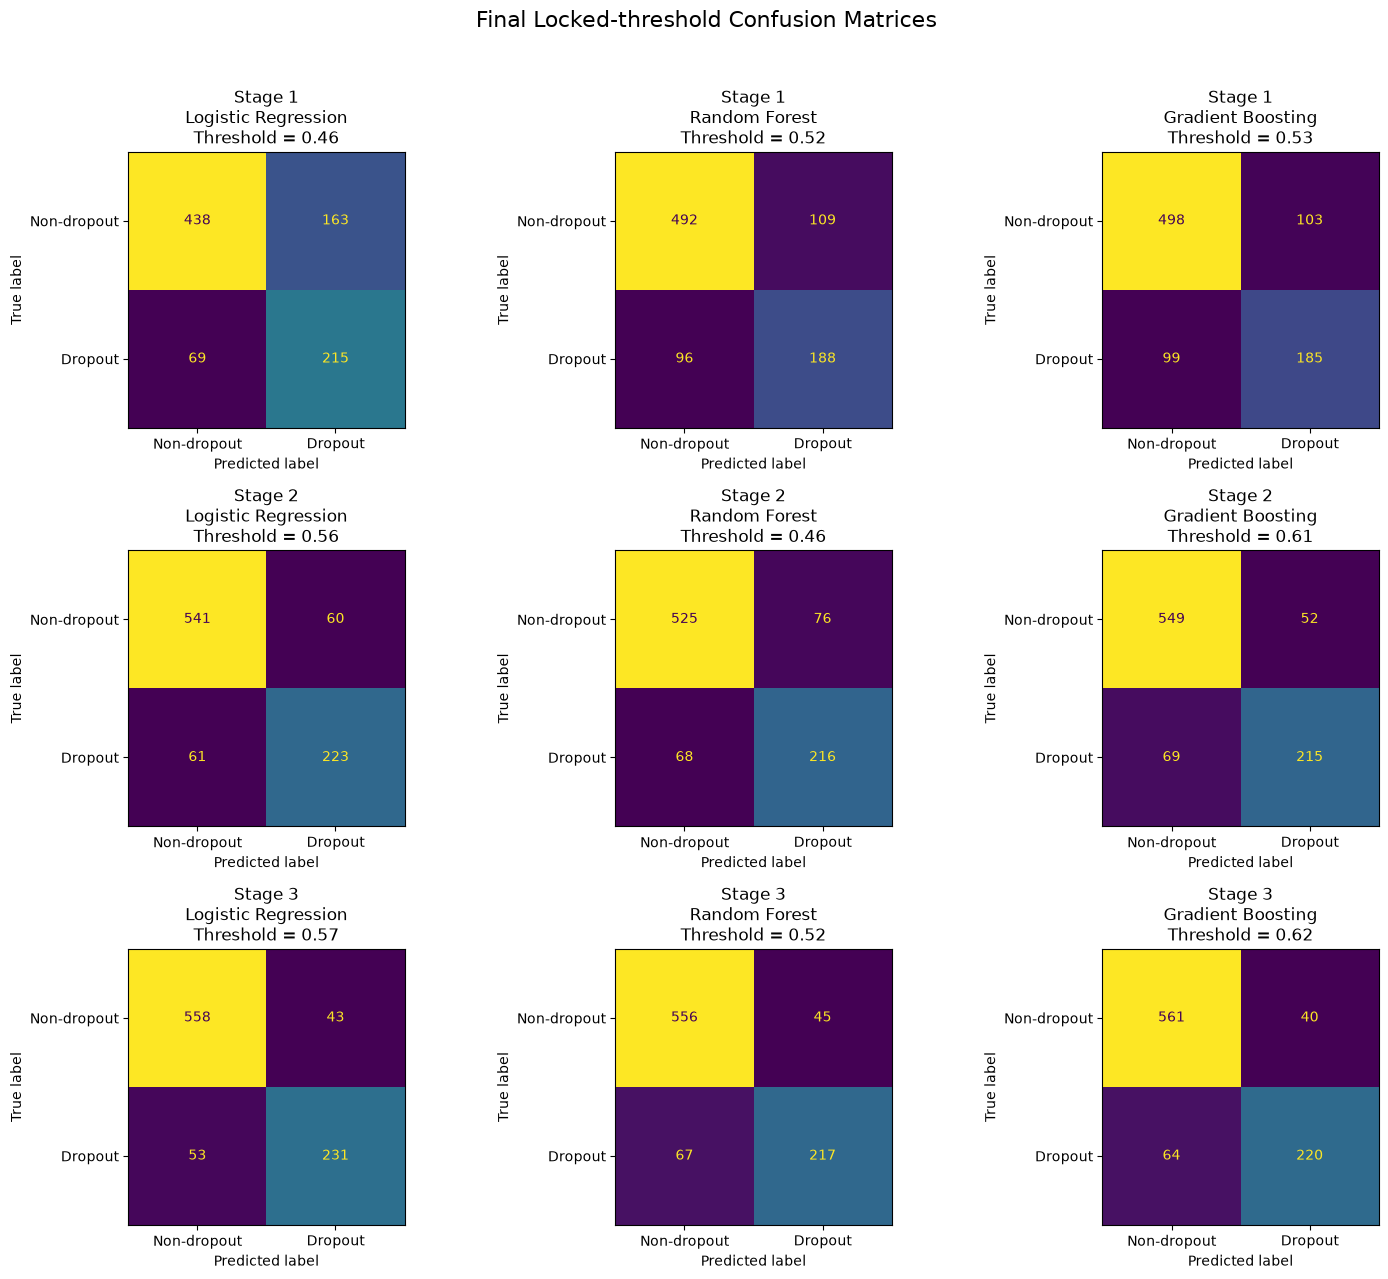

In [296]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15, 13)
)


for stage_position, stage_name in enumerate(
    stage_feature_sets
):

    for model_position, model_name in enumerate(
        PRIMARY_MODELS
    ):

        model_data = (
            final_test_predictions.loc[
                (
                    final_test_predictions[
                        "Stage"
                    ] == stage_name
                )
                &
                (
                    final_test_predictions[
                        "Model"
                    ] == model_name
                )
            ]
            .copy()
        )


        y_true = (
            model_data[
                "Observed_Dropout"
            ]
            .to_numpy()
        )


        y_pred = (
            model_data[
                "Locked_Prediction"
            ]
            .to_numpy()
        )


        threshold_value = float(
            model_data[
                "Locked_Threshold"
            ]
            .iloc[0]
        )


        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )


        cm_display = (
            ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=[
                    "Non-dropout",
                    "Dropout"
                ]
            )
        )


        cm_display.plot(
            ax=axes[
                stage_position,
                model_position
            ],
            colorbar=False
        )


        axes[
            stage_position,
            model_position
        ].set_title(
            f"{stage_name}\n"
            f"{model_name}\n"
            f"Threshold = "
            f"{threshold_value:.2f}"
        )


fig.suptitle(
    "Final Locked-threshold Confusion Matrices",
    fontsize=16
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96
    ]
)


plt.savefig(
    FIGURES_DIR
    / (
        "phase20_final_locked_"
        "confusion_matrices.png"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### Finding: Final Classification-error Visualisation

The final locked-threshold confusion matrices provide a consolidated view of held-out classification behaviour across all nine model-stage combinations.

Stage 1 contains the greatest number of classification errors. Logistic Regression records 163 false positives and 69 false negatives, Random Forest records 109 false positives and 96 false negatives, and Gradient Boosting records 103 false positives and 99 false negatives.

Classification errors decrease substantially when first-semester academic information becomes available at Stage 2. Logistic Regression records 60 false positives and 61 false negatives, while Gradient Boosting records 52 false positives and 69 false negatives. Random Forest produces 76 false positives and 68 false negatives.

Stage 3 produces the strongest overall classification pattern. Logistic Regression records 43 false positives and 53 false negatives, giving the lowest total number of classification errors among the Stage 3 models. Random Forest records 45 false positives and 67 false negatives, while Gradient Boosting records the fewest false positives at 40 but 64 false negatives.

The visualisation therefore reinforces the earlier performance finding that later academic information improves dropout classification.

The matrices also illustrate the trade-off between false positives and false negatives across models and thresholds. In the early-warning context, false negatives remain particularly important because they represent actual Dropout students who are not identified by the final classification rule.

No alternative threshold is selected from these visualisations.

## Phase 20.4: Identify the Stage 2 and Stage 3 Predictors for Partial Dependence

### Decision Record: Partial Dependence Feature Selection

#### Observation

The approved methodology specifies partial dependence analysis for the highest-ranked Stage 2 and Stage 3 SHAP predictors.

The global SHAP analysis has already produced cross-model consensus rankings for every prediction stage.

#### Decision

The predictor ranked first in the Stage 2 consensus SHAP analysis and the predictor ranked first in the Stage 3 consensus SHAP analysis will be selected automatically from the stored ranking table.

The same selected predictor will be examined across Logistic Regression, Random Forest and Gradient Boosting at the corresponding stage.

#### Justification

Using the previously calculated consensus ranking prevents arbitrary post-hoc feature selection and allows the three model families to be compared using the same substantively important predictor.

Partial dependence will use the training feature distribution rather than the held-out test set (Friedman, 2001).

This analysis describes marginal fitted-model behaviour and will not be interpreted causally (Friedman, 2001).

In [297]:
pdp_feature_selection = (
    stage_consensus_shap.loc[
        (
            stage_consensus_shap[
                "Stage"
            ]
            .isin(
                [
                    "Stage 2",
                    "Stage 3"
                ]
            )
        )
        &
        (
            stage_consensus_shap[
                "Consensus_Rank"
            ] == 1
        ),
        [
            "Stage",
            "Source_Feature",
            "Mean_Model_Importance_Share",
            "Consensus_Rank"
        ]
    ]
    .copy()
    .sort_values(
        "Stage"
    )
    .reset_index(drop=True)
)


pdp_feature_selection.round(4)

,Stage,Source_Feature,Mean_Model_Importance_Share,Consensus_Rank
0,Stage 2,Curricular units 1st sem (approved),0.2593,1
1,Stage 3,Curricular units 2nd sem (approved),0.2455,1


In [298]:
stage2_pdp_feature = (
    pdp_feature_selection.loc[
        pdp_feature_selection[
            "Stage"
        ] == "Stage 2",
        "Source_Feature"
    ]
    .iloc[0]
)


stage3_pdp_feature = (
    pdp_feature_selection.loc[
        pdp_feature_selection[
            "Stage"
        ] == "Stage 3",
        "Source_Feature"
    ]
    .iloc[0]
)


print(
    "Stage 2 PDP feature:",
    stage2_pdp_feature
)

print(
    "Stage 3 PDP feature:",
    stage3_pdp_feature
)

Stage 2 PDP feature: Curricular units 1st sem (approved)
Stage 3 PDP feature: Curricular units 2nd sem (approved)


### Finding: Partial Dependence Features Selected

The partial-dependence predictors were selected directly from the previously completed cross-model consensus SHAP rankings rather than chosen after inspecting partial-dependence behaviour.

At Stage 2, `Curricular units 1st sem (approved)` is the highest-ranked consensus predictor, with a mean cross-model importance share of approximately 0.2593.

At Stage 3, `Curricular units 2nd sem (approved)` is the highest-ranked consensus predictor, with a mean cross-model importance share of approximately 0.2455.

Both variables represent academic-progress information and were also classified as actionable within the pre-specified actionability framework.

Their selection therefore aligns the supplementary partial-dependence analysis directly with the global SHAP findings while avoiding arbitrary feature selection.

## Phase 20.5: Calculate One-way Partial Dependence across the Three Models

### Decision Record: Partial Dependence Computation

The selected predictors represent discrete counts of approved curricular units.

To preserve their observed data structure, the partial-dependence grid will use actual values observed in the training data rather than an automatically generated continuous grid.

The plotted range will be restricted to observed values between the 5th and 95th percentiles where possible. This reduces the influence of sparsely observed extreme values while retaining the main empirical range.

For every grid value, the selected feature will be set to that value for all training observations while all other predictors remain unchanged. The fitted model's mean predicted Dropout probability will then be calculated.

This is an empirical one-way partial-dependence calculation.

The procedure may still create hypothetical combinations between correlated academic variables and is therefore interpreted only as a description of fitted model behaviour rather than as evidence of causal effects (Friedman, 2001).

In [299]:
pdp_rows = []

pdp_grid_rows = []


pdp_stage_features = {
    "Stage 2":
    stage2_pdp_feature,

    "Stage 3":
    stage3_pdp_feature
}


for stage_name, feature_name in (
    pdp_stage_features.items()
):

    X_reference = (
        stage_datasets[
            stage_name
        ][
            "X_train"
        ]
        .copy()
    )


    feature_series = pd.to_numeric(
        X_reference[
            feature_name
        ],
        errors="raise"
    )


    observed_values = np.sort(
        feature_series
        .dropna()
        .unique()
    )


    lower_limit = (
        feature_series
        .quantile(
            0.05
        )
    )


    upper_limit = (
        feature_series
        .quantile(
            0.95
        )
    )


    grid_values = (
        observed_values[
            (
                observed_values
                >=
                lower_limit
            )
            &
            (
                observed_values
                <=
                upper_limit
            )
        ]
    )


    if len(
        grid_values
    ) < 2:

        grid_values = (
            observed_values
        )


    pdp_grid_rows.append({
        "Stage":
        stage_name,

        "Feature":
        feature_name,

        "Observed_Minimum":
        float(
            observed_values.min()
        ),

        "Observed_Maximum":
        float(
            observed_values.max()
        ),

        "PDP_Grid_Minimum":
        float(
            grid_values.min()
        ),

        "PDP_Grid_Maximum":
        float(
            grid_values.max()
        ),

        "Number_of_Grid_Values":
        len(
            grid_values
        )
    })


    for model_name in (
        PRIMARY_MODELS
    ):

        pipeline = (
            final_fitted_models[
                stage_name
            ][
                model_name
            ]
        )


        for feature_value in (
            grid_values
        ):

            X_modified = (
                X_reference
                .copy()
            )


            X_modified[
                feature_name
            ] = (
                feature_value
            )


            mean_probability = (
                pipeline
                .predict_proba(
                    X_modified
                )[
                    :,
                    1
                ]
                .mean()
            )


            pdp_rows.append({
                "Stage":
                stage_name,

                "Model":
                model_name,

                "Feature":
                feature_name,

                "Feature_Value":
                float(
                    feature_value
                ),

                "Mean_Partial_Dependence":
                float(
                    mean_probability
                )
            })


pdp_grid_summary = (
    pd.DataFrame(
        pdp_grid_rows
    )
)


pdp_results = (
    pd.DataFrame(
        pdp_rows
    )
)


pdp_grid_summary

,Stage,Feature,Observed_Minimum,Observed_Maximum,PDP_Grid_Minimum,PDP_Grid_Maximum,Number_of_Grid_Values
0,Stage 2,Curricular units 1st sem (approved),0.0,26.0,0.0,9.0,10
1,Stage 3,Curricular units 2nd sem (approved),0.0,20.0,0.0,8.0,9


In [300]:
pdp_results.head(
    12
).round(4)

,Stage,Model,Feature,Feature_Value,Mean_Partial_Dependence
0,Stage 2,Logistic Regression,Curricular units 1st sem (approved),0.0,0.9067
1,Stage 2,Logistic Regression,Curricular units 1st sem (approved),1.0,0.8406
2,Stage 2,Logistic Regression,Curricular units 1st sem (approved),2.0,0.7455
3,Stage 2,Logistic Regression,Curricular units 1st sem (approved),3.0,0.6252
4,Stage 2,Logistic Regression,Curricular units 1st sem (approved),4.0,0.4941
5,Stage 2,Logistic Regression,Curricular units 1st sem (approved),5.0,0.3707
6,Stage 2,Logistic Regression,Curricular units 1st sem (approved),6.0,0.2680
7,Stage 2,Logistic Regression,Curricular units 1st sem (approved),7.0,0.1890
8,Stage 2,Logistic Regression,Curricular units 1st sem (approved),8.0,0.1307
9,Stage 2,Logistic Regression,Curricular units 1st sem (approved),9.0,0.0888


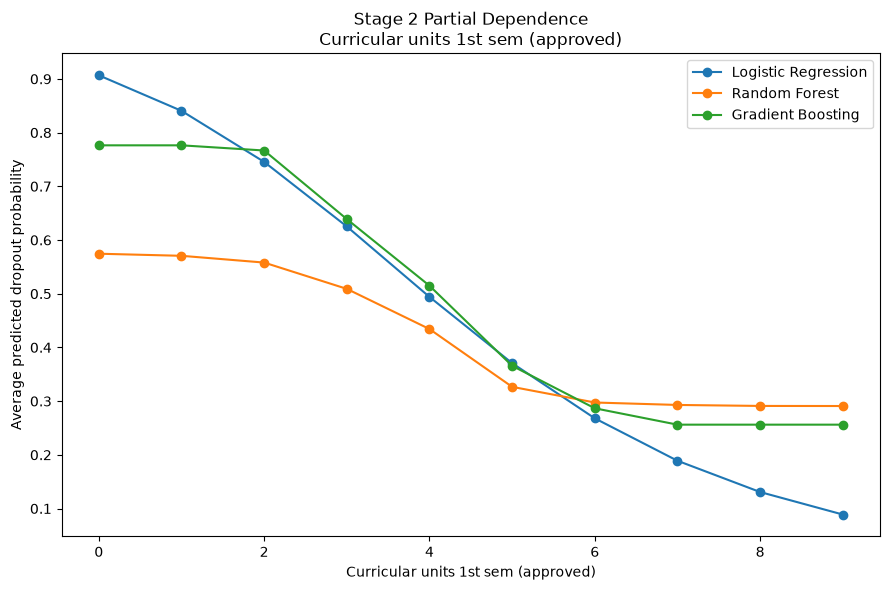

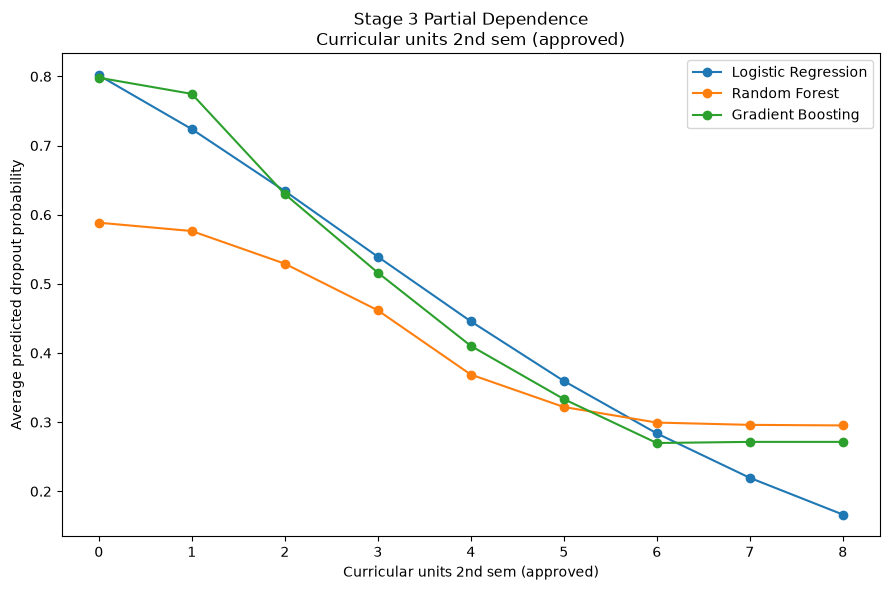

In [301]:
for stage_name, feature_name in (
    pdp_stage_features.items()
):

    plt.figure(
        figsize=(9, 6)
    )


    for model_name in (
        PRIMARY_MODELS
    ):

        plot_data = (
            pdp_results.loc[
                (
                    pdp_results[
                        "Stage"
                    ] == stage_name
                )
                &
                (
                    pdp_results[
                        "Model"
                    ] == model_name
                )
            ]
            .sort_values(
                "Feature_Value"
            )
        )


        plt.plot(
            plot_data[
                "Feature_Value"
            ],
            plot_data[
                "Mean_Partial_Dependence"
            ],
            marker="o",
            label=model_name
        )


    plt.xlabel(
        feature_name
    )

    plt.ylabel(
        "Average predicted dropout probability"
    )

    plt.title(
        f"{stage_name} Partial Dependence\n"
        f"{feature_name}"
    )

    plt.legend()

    plt.tight_layout()


    safe_stage = (
        stage_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )


    plt.savefig(
        FIGURES_DIR
        / (
            f"phase20_{safe_stage}_"
            f"partial_dependence.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

### Finding: Partial Dependence Analysis

The partial-dependence analysis shows a clear inverse relationship between approved curricular units and average predicted dropout risk at both later prediction stages.

At Stage 2, all three model families associate a larger number of first-semester approved units with a lower average Dropout score.

Logistic Regression shows the strongest continuous decline. Its average fitted Dropout probability decreases from approximately 0.91 when first-semester approved units are set to 0 to approximately 0.09 at 9 approved units.

Gradient Boosting also shows a strong decline, with comparatively high modelled risk at low approved-unit values followed by a substantial reduction across the middle of the observed range. The curve begins to flatten at approximately six or more approved units.

Random Forest produces a weaker initial decline than the other two models but similarly decreases as approved units increase and then reaches a plateau at the higher end of the observed range.

The Stage 3 results show the same overall pattern for `Curricular units 2nd sem (approved)`.

Logistic Regression decreases from an average predicted Dropout probability of approximately 0.80 at 0 approved second-semester units to approximately 0.16 at 8 approved units.

Gradient Boosting shows a pronounced nonlinear reduction before flattening at approximately six approved units, while Random Forest similarly decreases before reaching a relatively stable probability at the upper end of the range.

The agreement in direction across Logistic Regression, Random Forest and Gradient Boosting strengthens the evidence from the SHAP analysis that approved semester units are important academic signals of modelled dropout risk.

The ensemble models additionally demonstrate that the fitted relationship is not purely linear, because the reduction in predicted risk becomes progressively smaller at higher approved-unit values.

These results describe fitted model behaviour rather than a causal intervention effect.

Approved units are related to other academic characteristics such as enrolled units, evaluations and grades. Consequently, changing approved units while holding all other predictors fixed can produce hypothetical combinations that do not correspond to an individual student's actual academic trajectory.

The plots therefore support interpretation of model behaviour but do not establish that increasing the number of approved units would itself cause a reduction in dropout (Friedman, 2001).

## Phase 20.6: Create Representative SHAP Summary Visualisations

### Decision Record: SHAP Summary Plot Scope

The approved methodology allows SHAP findings to be communicated through global rankings, summary plots and selected local explanations.

The complete global SHAP analysis has already been conducted for all nine model-stage combinations, while Phase 18 examined selected local explanations. To avoid unnecessary duplication, representative source-level SHAP summary plots are produced for Stage 2 and Stage 3 Logistic Regression only.

Logistic Regression is used because it produced the highest held-out ROC-AUC point estimate at both later prediction stages. This selection does not imply statistical superiority over Random Forest or Gradient Boosting; uncertainty in the model differences is evaluated using the paired bootstrap analysis.

The source-level SHAP matrices calculated in Phase 17 are reused. No SHAP values are recalculated for model selection.

Continuous beeswarm colour gradients are restricted to non-nominal predictors. Nominal categorical predictors such as Course and Application mode are excluded from these colour-coded plots because their numerical codes do not represent meaningful low-to-high ordering.

This plotting restriction does not remove nominal predictors from the analysis. Their importance remains represented in the complete mean absolute SHAP rankings and tables from Phase 17, while categorical values in selected local explanations are reported using decoded labels.

For binary predictors, the two colour endpoints distinguish the observed values 0 and 1 and should not be interpreted as a continuous scale.

C:\Users\USER-PC\AppData\Local\Temp\ipykernel_24560\395135247.py:170: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


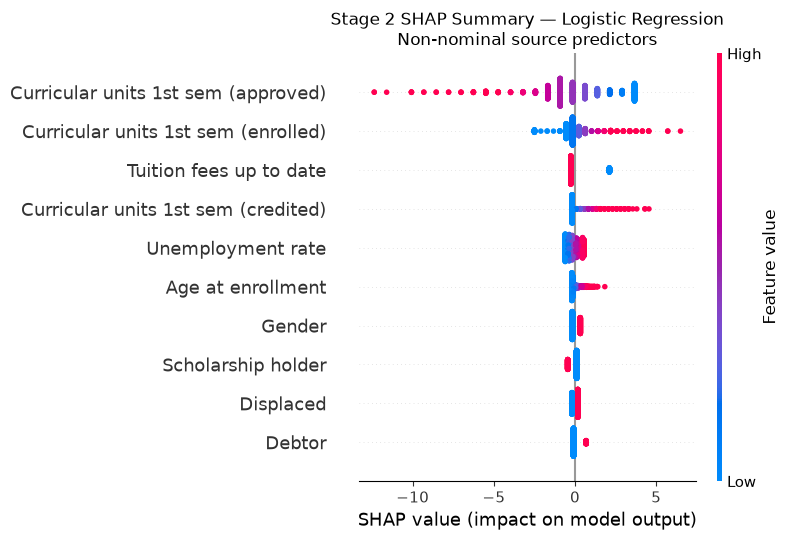

C:\Users\USER-PC\AppData\Local\Temp\ipykernel_24560\395135247.py:170: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


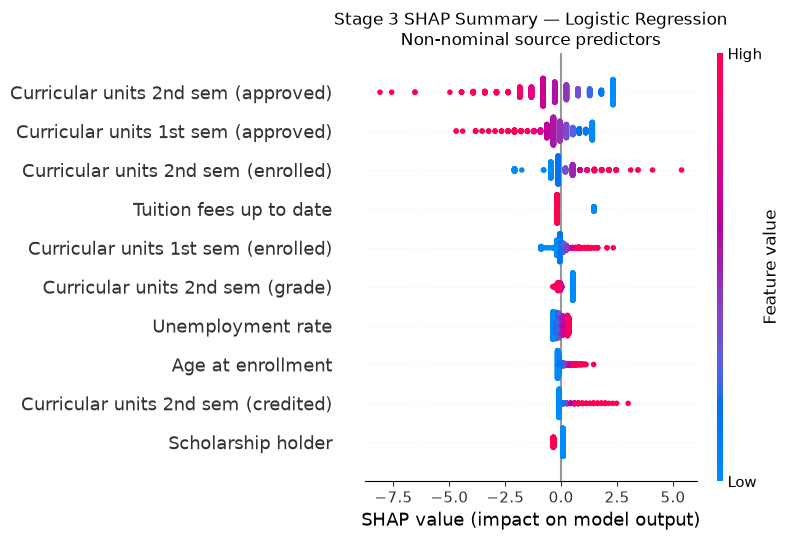

,Stage,Model,Feature,Nominal_Categorical,Displayed_in_Colour_Plot,Scope_Decision
0,Stage 2,Logistic Regression,Age at enrollment,False,True,Displayed in colour-coded summary plot
1,Stage 2,Logistic Regression,Curricular units 1st sem (approved),False,True,Displayed in colour-coded summary plot
2,Stage 2,Logistic Regression,Curricular units 1st sem (credited),False,True,Displayed in colour-coded summary plot
3,Stage 2,Logistic Regression,Curricular units 1st sem (enrolled),False,True,Displayed in colour-coded summary plot
4,Stage 2,Logistic Regression,Debtor,False,True,Displayed in colour-coded summary plot
5,Stage 2,Logistic Regression,Displaced,False,True,Displayed in colour-coded summary plot
6,Stage 2,Logistic Regression,Gender,False,True,Displayed in colour-coded summary plot
7,Stage 2,Logistic Regression,Scholarship holder,False,True,Displayed in colour-coded summary plot
8,Stage 2,Logistic Regression,Tuition fees up to date,False,True,Displayed in colour-coded summary plot
9,Stage 2,Logistic Regression,Unemployment rate,False,True,Displayed in colour-coded summary plot


In [302]:
shap_summary_stages = [
    "Stage 2",
    "Stage 3"
]


shap_summary_model = (
    "Logistic Regression"
)


SHAP_SUMMARY_MAX_DISPLAY = 10


shap_summary_plot_scope_rows = []


for stage_name in shap_summary_stages:

    source_shap_matrix = (
        shap_source_value_matrices[
            (
                stage_name,
                shap_summary_model
            )
        ]
        .copy()
    )


    source_feature_values = (
        stage_datasets[
            stage_name
        ][
            "X_test"
        ]
        .loc[
            source_shap_matrix.index,
            source_shap_matrix.columns
        ]
        .copy()
    )


    nominal_features_for_stage = set(
        stage_preprocessing_groups[
            stage_name
        ][
            "nominal"
        ]
    )


    colour_eligible_features = [
        feature_name
        for feature_name
        in source_shap_matrix.columns
        if feature_name
        not in nominal_features_for_stage
    ]


    assert (
        len(colour_eligible_features) > 0
    ), (
        f"No non-nominal SHAP features "
        f"available for {stage_name}."
    )


    displayed_features = (
        source_shap_matrix[
            colour_eligible_features
        ]
        .abs()
        .mean(axis=0)
        .sort_values(
            ascending=False
        )
        .head(
            SHAP_SUMMARY_MAX_DISPLAY
        )
        .index
        .tolist()
    )


    assert not (
        set(displayed_features)
        &
        nominal_features_for_stage
    ), (
        f"Nominal predictors were included "
        f"in the {stage_name} colour-coded "
        "SHAP summary plot."
    )


    for feature_name in (
        source_shap_matrix.columns
    ):

        is_nominal = (
            feature_name
            in nominal_features_for_stage
        )

        is_displayed = (
            feature_name
            in displayed_features
        )

        if is_nominal:
            scope_decision = (
                "Excluded because the nominal "
                "code has no numerical order"
            )

        elif is_displayed:
            scope_decision = (
                "Displayed in colour-coded "
                "summary plot"
            )

        else:
            scope_decision = (
                "Eligible but outside the "
                "displayed top features"
            )

        shap_summary_plot_scope_rows.append(
            {
                "Stage": stage_name,
                "Model": shap_summary_model,
                "Feature": feature_name,
                "Nominal_Categorical": (
                    is_nominal
                ),
                "Displayed_in_Colour_Plot": (
                    is_displayed
                ),
                "Scope_Decision": (
                    scope_decision
                ),
            }
        )


    displayed_feature_values = (
        source_feature_values[
            displayed_features
        ]
        .apply(
            pd.to_numeric,
            errors="raise"
        )
    )


    displayed_shap_values = (
        source_shap_matrix[
            displayed_features
        ]
        .to_numpy(
            dtype=float
        )
    )


    shap.summary_plot(
        shap_values=(
            displayed_shap_values
        ),
        features=(
            displayed_feature_values
        ),
        feature_names=(
            displayed_features
        ),
        plot_type="dot",
        max_display=(
            len(displayed_features)
        ),
        show=False
    )


    plt.title(
        f"{stage_name} SHAP Summary — "
        f"{shap_summary_model}\n"
        "Non-nominal source predictors"
    )


    plt.tight_layout()


    safe_stage = (
        stage_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )


    plt.savefig(
        FIGURES_DIR
        / (
            f"phase20_{safe_stage}_"
            f"logistic_regression_"
            f"shap_summary.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


shap_summary_plot_scope = (
    pd.DataFrame(
        shap_summary_plot_scope_rows
    )
)


display(
    shap_summary_plot_scope.loc[
        (
            shap_summary_plot_scope[
                "Nominal_Categorical"
            ]
        )
        |
        (
            shap_summary_plot_scope[
                "Displayed_in_Colour_Plot"
            ]
        )
    ]
    .sort_values(
        [
            "Stage",
            "Nominal_Categorical",
            "Feature"
        ]
    )
    .reset_index(drop=True)
)

### Finding: Representative SHAP Summary Presentation

The revised Stage 2 and Stage 3 Logistic Regression SHAP summary plots present the direction and distribution of contributions only for non-nominal source predictors.

Nominal categorical predictors, including Course and Application mode, were deliberately excluded from the colour-coded beeswarm plots because their numerical labels have no meaningful low-to-high ordering. This plotting decision prevents the colour gradient from implying an ordinal relationship that does not exist.

The exclusion applies only to these directional visualisations. Nominal predictors remain included in the complete Phase 17 global mean absolute SHAP rankings and are therefore not removed from the interpretability analysis.

Within the eligible Stage 2 predictors, `Curricular units 1st sem (approved)` remains the dominant academic-progress feature. Higher values generally appear on the negative SHAP side, indicating contributions toward a lower modelled Dropout score, whereas lower values generally contribute toward a higher score.

At Stage 3, `Curricular units 2nd sem (approved)` becomes the leading eligible feature, followed by first-semester approved units. Higher approved-unit values again generally contribute toward lower modelled Dropout scores.

The revised plots therefore support the finding that academic-progress information increasingly dominates model interpretation once semester information becomes available.

The SHAP values explain the fitted model’s predictions. They do not demonstrate that the identified predictors cause student dropout.

## Phase 20.7: Define the Illustrative Risk-tier Framework

### Decision Record: Risk-tier Boundary Construction

#### Observation

The approved research design specifies an illustrative Low, Medium and High model-score framework following decision-threshold optimisation.

Logistic Regression produced the highest held-out ROC-AUC point estimate at both Stage 2 and Stage 3. The paired bootstrap analysis is used to qualify uncertainty in its differences from Random Forest and Gradient Boosting, and its use in this illustration does not assume statistical superiority.

The High-tier classification threshold for each stage was previously locked using out-of-fold training predictions and the pre-specified F1-first threshold-selection rule.

A second, lower threshold is required to construct an intermediate warning tier.

#### Decision

The illustrative risk-tier framework will use Stage 2 and Stage 3 Logistic Regression.

For each stage:

- the existing locked F1-optimal classification threshold will define entry into the High tier;
- the Medium-tier lower boundary will be the highest out-of-fold training threshold below the High-tier boundary that still achieves Recall of at least 0.90;
- model scores below the lower warning boundary will be labelled Low;
- scores from the lower warning boundary up to, but excluding, the locked classification threshold will be labelled Medium; and
- scores at or above the locked classification threshold will be labelled High.

The Recall value of 0.90 is a pre-defined analytical rule used to illustrate a high-sensitivity warning boundary. It is not presented as an empirically validated institutional service requirement.

#### Justification

Both tier boundaries are derived entirely from out-of-fold training evidence. Held-out outcomes therefore do not determine or alter the tier thresholds.

The framework remains consistent with the study's emphasis on reducing missed dropout cases while preserving the previously locked binary classification rule.

Because the probability-calibration analysis identified imperfect calibration, the resulting categories are described as model-score tiers rather than literal probabilities of student dropout.

These tiers demonstrate one possible method of translating continuous model scores into a human-readable framework. They have not been validated as institutional policy and must not be used for automated decisions or interventions.

## Phase 20.8: Derive the Risk-tier Boundaries from Out-of-fold Training Evidence

In [303]:
RISK_TIER_TARGET_RECALL = (
    0.90
)


risk_tier_model = (
    "Logistic Regression"
)


risk_tier_stages = [
    "Stage 2",
    "Stage 3"
]


risk_tier_boundary_rows = []


for stage_name in (
    risk_tier_stages
):

    high_boundary = float(
        selected_threshold_summary.loc[
            (
                selected_threshold_summary[
                    "Stage"
                ] == stage_name
            )
            &
            (
                selected_threshold_summary[
                    "Model"
                ] == risk_tier_model
            ),
            "Threshold"
        ]
        .iloc[0]
    )


    stage_thresholds = (
        threshold_evaluations.loc[
            (
                threshold_evaluations[
                    "Stage"
                ] == stage_name
            )
            &
            (
                threshold_evaluations[
                    "Model"
                ] == risk_tier_model
            )
        ]
        .copy()
    )


    recall_eligible = (
        stage_thresholds.loc[
            (
                stage_thresholds[
                    "Recall"
                ]
                >=
                RISK_TIER_TARGET_RECALL
            )
            &
            (
                stage_thresholds[
                    "Threshold"
                ]
                <
                high_boundary
            )
        ]
        .sort_values(
            [
                "Threshold",
                "Precision",
                "F1"
            ],
            ascending=[
                False,
                False,
                False
            ]
        )
    )


    assert (
        len(
            recall_eligible
        ) > 0
    ), (
        "No lower warning threshold "
        f"found for {stage_name}."
    )


    lower_boundary_row = (
        recall_eligible
        .iloc[0]
    )


    medium_boundary = float(
        lower_boundary_row[
            "Threshold"
        ]
    )


    assert (
        medium_boundary
        <
        high_boundary
    )


    risk_tier_boundary_rows.append({
        "Stage":
        stage_name,

        "Model":
        risk_tier_model,

        "Medium_Tier_Lower_Bound":
        medium_boundary,

        "OOF_Recall_at_Lower_Bound":
        float(
            lower_boundary_row[
                "Recall"
            ]
        ),

        "OOF_Precision_at_Lower_Bound":
        float(
            lower_boundary_row[
                "Precision"
            ]
        ),

        "OOF_F1_at_Lower_Bound":
        float(
            lower_boundary_row[
                "F1"
            ]
        ),

        "High_Tier_Lower_Bound":
        high_boundary
    })


risk_tier_boundaries = (
    pd.DataFrame(
        risk_tier_boundary_rows
    )
)


risk_tier_boundaries.round(4)

,Stage,Model,Medium_Tier_Lower_Bound,OOF_Recall_at_Lower_Bound,OOF_Precision_at_Lower_Bound,OOF_F1_at_Lower_Bound,High_Tier_Lower_Bound
0,Stage 2,Logistic Regression,0.26,0.9050,0.5733,0.7019,0.56
1,Stage 3,Logistic Regression,0.30,0.9033,0.6281,0.7410,0.57


### Finding: Training-derived Risk-tier Boundaries

The illustrative risk-tier boundaries were derived entirely from out-of-fold training predictions and therefore do not use held-out outcomes for threshold selection.

For Stage 2 Logistic Regression, the Medium-tier warning boundary is 0.26.

At this training-derived threshold, Recall is 0.9050, Precision is 0.5733 and F1-score is 0.7019.

The High-tier boundary remains the previously locked F1-optimal threshold of 0.56.

Stage 2 therefore defines the illustrative tiers as:

- Low: model score below 0.26;
- Medium: model score from 0.26 to below 0.56; and
- High: model score of 0.56 or greater.

For Stage 3 Logistic Regression, the Medium-tier warning boundary is 0.30.

At this threshold, out-of-fold Recall is 0.9033, Precision is 0.6281 and F1-score is 0.7410.

The previously locked Stage 3 High-tier threshold remains 0.57.

The corresponding Stage 3 tiers are therefore:

- Low: model score below 0.30;
- Medium: model score from 0.30 to below 0.57; and
- High: model score of 0.57 or greater.

The later-stage warning threshold is slightly higher while achieving approximately the same 0.90 Recall target and improved Precision and F1-score.

This is consistent with the broader finding that Stage 3 contains stronger predictive information than Stage 2.

These boundaries remain model-score thresholds rather than calibrated estimates of an individual's literal probability of dropping out.

The 0.90 Recall criterion is used only to construct an illustrative high-sensitivity warning range and is not proposed as a validated institutional policy requirement.

## Phase 20.9: Apply the Illustrative Risk Tiers to Held-out Students

In [304]:
risk_tier_prediction_rows = []


for stage_name in (
    risk_tier_stages
):

    boundary_row = (
        risk_tier_boundaries.loc[
            risk_tier_boundaries[
                "Stage"
            ] == stage_name
        ]
        .iloc[0]
    )


    medium_boundary = float(
        boundary_row[
            "Medium_Tier_Lower_Bound"
        ]
    )


    high_boundary = float(
        boundary_row[
            "High_Tier_Lower_Bound"
        ]
    )


    model_data = (
        final_test_predictions.loc[
            (
                final_test_predictions[
                    "Stage"
                ] == stage_name
            )
            &
            (
                final_test_predictions[
                    "Model"
                ] == risk_tier_model
            )
        ]
        .copy()
    )


    model_data[
        "Illustrative_Risk_Tier"
    ] = pd.cut(
        model_data[
            "Dropout_Probability"
        ],
        bins=[
            -np.inf,
            medium_boundary,
            high_boundary,
            np.inf
        ],
        labels=[
            "Low",
            "Medium",
            "High"
        ],
        right=False
    )


    risk_tier_prediction_rows.append(
        model_data
    )


risk_tier_predictions = (
    pd.concat(
        risk_tier_prediction_rows,
        ignore_index=True
    )
)


assert (
    risk_tier_predictions[
        "Illustrative_Risk_Tier"
    ]
    .notna()
    .all()
)


risk_tier_predictions[
    [
        "Stage",
        "Student_Index",
        "Observed_Dropout",
        "Dropout_Probability",
        "Illustrative_Risk_Tier"
    ]
].head(10)

,Stage,Student_Index,Observed_Dropout,Dropout_Probability,Illustrative_Risk_Tier
0,Stage 2,0,1,0.715590,High
1,Stage 2,3,0,0.182080,Low
2,Stage 2,6,0,0.040730,Low
3,Stage 2,17,0,0.147886,Low
4,Stage 2,22,0,0.078193,Low
5,Stage 2,25,0,0.081828,Low
6,Stage 2,27,0,0.040008,Low
7,Stage 2,35,1,0.998950,High
8,Stage 2,47,0,0.177564,Low
9,Stage 2,48,0,0.046390,Low


In [305]:
risk_tier_summary = (
    risk_tier_predictions
    .groupby(
        [
            "Stage",
            "Illustrative_Risk_Tier"
        ],
        observed=True
    )
    .agg(
        Students=(
            "Student_Index",
            "count"
        ),

        Observed_Dropouts=(
            "Observed_Dropout",
            "sum"
        ),

        Observed_Dropout_Rate=(
            "Observed_Dropout",
            "mean"
        ),

        Mean_Model_Score=(
            "Dropout_Probability",
            "mean"
        ),

        Minimum_Model_Score=(
            "Dropout_Probability",
            "min"
        ),

        Maximum_Model_Score=(
            "Dropout_Probability",
            "max"
        )
    )
    .reset_index()
)


risk_tier_summary[
    "Student_Proportion"
] = (
    risk_tier_summary[
        "Students"
    ]
    /
    len(
        y_test
    )
)


tier_order = [
    "Low",
    "Medium",
    "High"
]


risk_tier_summary[
    "Illustrative_Risk_Tier"
] = pd.Categorical(
    risk_tier_summary[
        "Illustrative_Risk_Tier"
    ],
    categories=(
        tier_order
    ),
    ordered=True
)


risk_tier_summary = (
    risk_tier_summary
    .sort_values(
        [
            "Stage",
            "Illustrative_Risk_Tier"
        ]
    )
    .reset_index(drop=True)
)


risk_tier_summary.round(4)

,Stage,Illustrative_Risk_Tier,Students,Observed_Dropouts,Observed_Dropout_Rate,Mean_Model_Score,Minimum_Model_Score,Maximum_Model_Score,Student_Proportion
0,Stage 2,Low,440,29,0.0659,0.1096,0.0027,0.2587,0.4972
1,Stage 2,Medium,162,32,0.1975,0.3845,0.2611,0.5582,0.1831
2,Stage 2,High,283,223,0.7880,0.8565,0.5640,1.0000,0.3198
3,Stage 3,Low,485,26,0.0536,0.1242,0.0128,0.2989,0.5480
4,Stage 3,Medium,126,27,0.2143,0.4206,0.3002,0.5654,0.1424
5,Stage 3,High,274,231,0.8431,0.8694,0.5748,0.9997,0.3096


### RISK TIER PLOTS

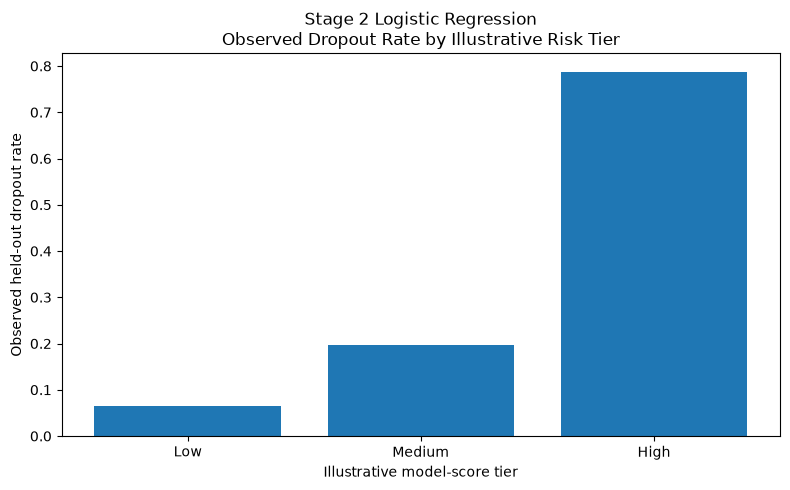

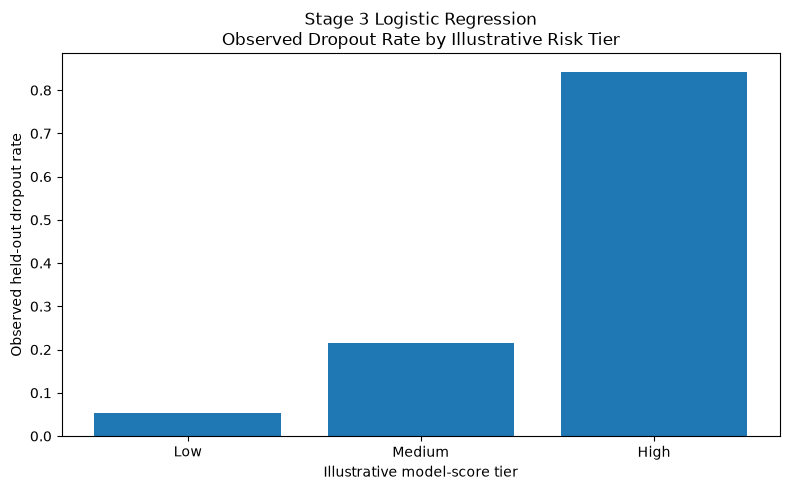

In [306]:
for stage_name in (
    risk_tier_stages
):

    plot_data = (
        risk_tier_summary.loc[
            risk_tier_summary[
                "Stage"
            ] == stage_name
        ]
        .copy()
        .sort_values(
            "Illustrative_Risk_Tier"
        )
    )


    plt.figure(
        figsize=(8, 5)
    )


    plt.bar(
        plot_data[
            "Illustrative_Risk_Tier"
        ]
        .astype(str),
        plot_data[
            "Observed_Dropout_Rate"
        ]
    )


    plt.xlabel(
        "Illustrative model-score tier"
    )

    plt.ylabel(
        "Observed held-out dropout rate"
    )

    plt.title(
        f"{stage_name} Logistic Regression\n"
        f"Observed Dropout Rate by "
        f"Illustrative Risk Tier"
    )


    plt.tight_layout()


    safe_stage = (
        stage_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )


    plt.savefig(
        FIGURES_DIR
        / (
            f"phase20_{safe_stage}_"
            f"risk_tier_outcomes.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

### Finding: Illustrative Risk-tier Outcome Pattern

The held-out descriptive evaluation shows a monotonic increase in observed Dropout prevalence from the Low model-score tier to the Medium tier and then to the High tier at both later prediction stages.

At Stage 2, 440 of the 885 held-out students fall within the Low tier, representing 49.72% of the test sample. Of these students, 29 are observed Dropout cases, producing an observed dropout rate of 6.59%.

The Stage 2 Medium tier contains 162 students, or 18.31% of the held-out sample. It contains 32 observed Dropout cases and has an observed dropout rate of 19.75%.

The Stage 2 High tier contains 283 students, representing 31.98% of the held-out sample. It contains 223 observed Dropout cases and has an observed dropout rate of 78.80%.

Stage 3 produces a similar but slightly wider separation between the Low and High tiers.

The Stage 3 Low tier contains 485 students, representing 54.80% of the held-out sample. It contains 26 observed Dropout cases and has an observed dropout rate of 5.36%.

The Stage 3 Medium tier contains 126 students, or 14.24% of the sample. It contains 27 observed Dropout cases and has an observed dropout rate of 21.43%.

The Stage 3 High tier contains 274 students, representing 30.96% of the held-out sample. It contains 231 observed Dropout cases and has an observed dropout rate of 84.31%.

The progression from approximately 5–7% observed dropout in the Low tiers to approximately 20% in the Medium tiers and approximately 79–84% in the High tiers demonstrates an ordered association between the model-score categories and observed outcomes within this held-out sample.

The Stage 3 tiers display a lower observed dropout rate in the Low tier and a higher rate in the High tier than the corresponding Stage 2 tiers. This is consistent with the stronger predictive information available after second-semester variables are included.

These results are descriptive evidence from one held-out partition. They do not constitute external, temporal or institutional validation of the tier boundaries.

The held-out results were not used to alter the boundaries. The tiers are not calibrated individual dropout probabilities, validated institutional policy categories or authorisation for automatic intervention.

They illustrate how a continuous model score could be translated into a human-readable warning framework while retaining human review and the previously locked binary classification threshold.

## Phase 20.10: Define the Human-supervised Risk-tier Response Matrix

In [307]:
risk_tier_response_matrix = pd.DataFrame(
    [
        {
            "Illustrative_Risk_Tier": "Low",
            "Interpretation": (
                "Model score is below the "
                "high-sensitivity warning boundary."
            ),
            "Illustrative_Response": (
                "Routine academic monitoring and "
                "continued access to standard "
                "student support."
            ),
            "Human_Review_Required": "Yes",
            "Automated_Action": "No",
        },
        {
            "Illustrative_Risk_Tier": "Medium",
            "Interpretation": (
                "Model score exceeds the "
                "high-sensitivity warning boundary "
                "but remains below the locked "
                "classification threshold."
            ),
            "Illustrative_Response": (
                "Adviser review or check-in, with "
                "attention to actionable academic "
                "indicators and cautiously interpreted "
                "administrative signals."
            ),
            "Human_Review_Required": "Yes",
            "Automated_Action": "No",
        },
        {
            "Illustrative_Risk_Tier": "High",
            "Interpretation": (
                "Model score meets or exceeds the "
                "locked F1-optimal classification "
                "threshold."
            ),
            "Illustrative_Response": (
                "Human-reviewed consideration for "
                "appropriate academic, financial or "
                "administrative support using the "
                "actionability framework."
            ),
            "Human_Review_Required": "Yes",
            "Automated_Action": "No",
        },
    ]
)


# Verify that the intended human-oversight safeguards are present.
assert risk_tier_response_matrix[
    "Illustrative_Risk_Tier"
].tolist() == ["Low", "Medium", "High"]

assert risk_tier_response_matrix[
    "Human_Review_Required"
].eq("Yes").all()

assert risk_tier_response_matrix[
    "Automated_Action"
].eq("No").all()


display(risk_tier_response_matrix)

,Illustrative_Risk_Tier,Interpretation,Illustrative_Response,Human_Review_Required,Automated_Action
0,Low,Model score is below the high-sensitivity warn...,Routine academic monitoring and continued acce...,Yes,No
1,Medium,Model score exceeds the high-sensitivity warni...,"Adviser review or check-in, with attention to ...",Yes,No
2,High,Model score meets or exceeds the locked F1-opt...,Human-reviewed consideration for appropriate a...,Yes,No


### Finding: Human-supervised Risk-tier Response Framework

The response matrix contains Low, Medium and High illustrative model-score tiers for later-stage student-support discussion.

Every tier explicitly requires human review, and no tier authorises an automated intervention. The suggested responses remain general support considerations rather than predetermined actions or sanctions.

The framework therefore demonstrates how model outputs could be translated into a cautious decision-support format while preserving professional judgement, contextual review and student-centred safeguards. It has not been validated as institutional policy.


## Phase 20.11: Preserve the Supplementary Model-behaviour Evidence

In [308]:
pdp_feature_selection.to_csv(
    TABLES_DIR
    / (
        "phase20_pdp_"
        "feature_selection.csv"
    ),
    index=False
)


pdp_grid_summary.to_csv(
    TABLES_DIR
    / (
        "phase20_pdp_"
        "grid_summary.csv"
    ),
    index=False
)


pdp_results.to_csv(
    TABLES_DIR
    / (
        "phase20_partial_"
        "dependence_results.csv"
    ),
    index=False
)


risk_tier_boundaries.to_csv(
    TABLES_DIR
    / (
        "phase20_risk_"
        "tier_boundaries.csv"
    ),
    index=False
)


risk_tier_predictions.to_csv(
    TABLES_DIR
    / (
        "phase20_risk_"
        "tier_predictions.csv"
    ),
    index=False
)


risk_tier_summary.to_csv(
    TABLES_DIR
    / (
        "phase20_risk_"
        "tier_summary.csv"
    ),
    index=False
)


risk_tier_response_matrix.to_csv(
    TABLES_DIR
    / (
        "phase20_risk_"
        "tier_response_matrix.csv"
    ),
    index=False
)
shap_summary_plot_scope.to_csv(
    TABLES_DIR / "phase20_shap_summary_plot_scope.csv",
    index=False
)

print(
    "Phase 20 supplementary "
    "evidence saved successfully."
)




Phase 20 supplementary evidence saved successfully.


### Finding: Phase 20 Evidence Preserved

The partial-dependence feature-selection record, empirical partial-dependence grids and results, out-of-fold-training-derived risk-tier boundaries, held-out tier descriptions and illustrative human-supervised response framework have been exported.

The final locked-threshold confusion matrices and representative Stage 2 and Stage 3 SHAP summary plots have also been preserved as report-ready figures.

These outputs complete the supplementary model-behaviour and decision-support components specified in the approved methodology.

## Phase 20.12: Overall Phase 20 Summary




Phase 20 completed the remaining supplementary model-behaviour and illustrative decision-support analyses specified in the approved research design.

The final locked-threshold confusion matrices provide report-ready representations of the classification outcomes across all nine model-stage combinations.

Classification errors decrease substantially as semester academic information becomes available. At Stage 3, Logistic Regression produces the fewest total classification errors, with 43 false positives and 53 false negatives, while Gradient Boosting produces the fewest false positives, with 40.

The highest-ranked cross-model consensus SHAP predictor was selected programmatically for partial-dependence analysis at each later prediction stage.

`Curricular units 1st sem (approved)` was selected at Stage 2 and `Curricular units 2nd sem (approved)` was selected at Stage 3.

Partial dependence shows a consistent inverse fitted relationship between approved curricular units and average modelled dropout risk across Logistic Regression, Random Forest and Gradient Boosting.

Logistic Regression displays a continuous reduction in predicted risk as approved units increase. Random Forest and Gradient Boosting show more nonlinear behaviour and progressively flatter responses at higher approved-unit values.

The agreement in direction across the three model families reinforces the SHAP finding that semester academic progression is strongly associated with later-stage dropout predictions. These relationships describe fitted model behaviour and are not interpreted as evidence of causation (Friedman, 2001).

Representative Stage 2 and Stage 3 Logistic Regression SHAP summary plots provide additional directional information for non-nominal predictors.

Nominal categorical predictors such as Course and Application mode were deliberately excluded from the colour-coded beeswarm plots because their numerical codes do not represent meaningful low-to-high ordering. They remain included in the complete Phase 17 global SHAP importance analysis.

Within the eligible Stage 2 predictors, first-semester approved units dominate the explanation distribution. At Stage 3, second-semester approved units become the leading feature, followed by first-semester approved units.



The illustrative risk-tier framework was derived entirely from out-of-fold training predictions.

At Stage 2, the Medium warning tier begins at a model score of 0.26 and the previously locked High-tier threshold remains 0.56.

At Stage 3, the Medium warning tier begins at 0.30 and the High-tier threshold remains 0.57.

Both lower warning thresholds achieve approximately 0.90 Recall in the out-of-fold training predictions.

When applied descriptively to the held-out sample, observed dropout prevalence increases across the Low, Medium and High model-score tiers.

At Stage 2, observed dropout prevalence increases from 6.59% in the Low tier to 19.75% in the Medium tier and 78.80% in the High tier.

At Stage 3, the corresponding observed rates are 5.36%, 21.43% and 84.31%.

This pattern demonstrates ordered separation within the current held-out sample. It does not constitute external, temporal or institutional validation of the tier boundaries.

The risk tiers remain illustrative model-score categories rather than calibrated individual dropout probabilities or validated institutional intervention policies. All associated support responses require human review, and no automatic intervention is proposed.

No Phase 20 result changes any predictive model, preprocessing rule, feature set, imbalance strategy, hyperparameter or previously locked classification threshold.

Phase 20 therefore completes the confusion-matrix visualisation, partial-dependence analysis, corrected representative SHAP presentation and illustrative risk-tier framework promised in the approved research methodology.

### Code Attribution — Phase 20

scikit-learn developers, 2026. *sklearn.metrics.ConfusionMatrixDisplay* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.inspection.partial_dependence* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.inspection.partial_dependence.html> [Accessed 14 September 2026].

SHAP Documentation, 2025. *shap.summary_plot* [Source code/documentation]. Available at: <https://shap.readthedocs.io/en/latest/generated/shap.summary_plot.html> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.sort* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/generated/numpy.sort.html> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.quantile* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/generated/numpy.quantile.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html> [Accessed 14 September 2026].

Matplotlib developers, 2025. *matplotlib.pyplot* [Source code/documentation]. Available at: <https://matplotlib.org/stable/api/pyplot_summary.html> [Accessed 14 September 2026].

# Phase 21: Final Research Synthesis and Reproducibility Audit

The empirical modelling, interpretability, responsible-use and supplementary decision-support analyses are now complete.

Phase 21 consolidates the evidence produced throughout the notebook into final research conclusions.

No new predictive model, feature-selection rule, preprocessing decision, imbalance strategy, hyperparameter or classification threshold will be introduced.

The purpose of this phase is to:

- provide final evidence-based answers to the three research questions;
- assess completion of the three research objectives;
- classify H1–H4 using the completed empirical evidence;
- document differences between the proposal blueprint and the implemented analysis;
- consolidate the study limitations;
- preserve a final output and environment manifest; and
- perform final analytical-integrity checks before the notebook is used as the evidence base for the research report.

The proposal is treated as the methodological blueprint, while the executed notebook and observed results provide the final empirical evidence.

## Phase 21.1: Decision Record for Final Research Synthesis

### Decision Record: Closing the Empirical Analysis

#### Observation

All planned primary model comparisons have been completed using the same held-out test partition.

Global and local SHAP analyses have been completed, supplementary reliability and responsible-use checks have been conducted, and the remaining proposal analyses have been implemented.

The study therefore has sufficient empirical evidence to provide final answers to the research questions and hypotheses.

#### Decision

No further model development will occur.

The remaining notebook work will consolidate existing evidence, verify alignment with the approved research design and preserve the final reproducibility record.

#### Justification

Continuing to alter models after examining held-out outcomes would weaken the separation between model development and final evaluation.

Closing model development at this point preserves the methodological integrity of the study and ensures that final conclusions reflect the analysis that was actually conducted rather than a retrospectively optimised result.

## Phase 21.2: Consolidate the Final Predictive-performance Evidence for Research Question 1

In [309]:
rq1_final_performance = (
    final_locked_summary[
        [
            "Stage",
            "Model",
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "False_Positives",
            "False_Negatives"
        ]
    ]
    .copy()
    .sort_values(
        [
            "Stage",
            "ROC_AUC"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(drop=True)
)


rq1_final_performance.round(4)

,Stage,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,False_Positives,False_Negatives
0,Stage 1,Logistic Regression,0.46,0.7379,0.5688,0.7570,0.6495,0.8355,163,69
1,Stage 1,Gradient Boosting,0.53,0.7718,0.6424,0.6514,0.6469,0.8354,103,99
2,Stage 1,Random Forest,0.52,0.7684,0.6330,0.6620,0.6472,0.8259,109,96
3,Stage 2,Logistic Regression,0.56,0.8633,0.7880,0.7852,0.7866,0.9126,60,61
4,Stage 2,Gradient Boosting,0.61,0.8633,0.8052,0.7570,0.7804,0.9078,52,69
5,Stage 2,Random Forest,0.46,0.8373,0.7397,0.7606,0.7500,0.9024,76,68
6,Stage 3,Logistic Regression,0.57,0.8915,0.8431,0.8134,0.8280,0.9326,43,53
7,Stage 3,Gradient Boosting,0.62,0.8825,0.8462,0.7746,0.8088,0.9318,40,64
8,Stage 3,Random Forest,0.52,0.8734,0.8282,0.7641,0.7949,0.9289,45,67


In [310]:
highest_roc_auc_point_estimate_by_stage = (
    final_locked_summary
    .loc[
        final_locked_summary
        .groupby(
            "Stage"
        )[
            "ROC_AUC"
        ]
        .idxmax(),
        [
            "Stage",
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ]
    .copy()
    .rename(
        columns={
            "Model":
            "Highest_ROC_AUC_Point_Estimate_Model"
        }
    )
    .sort_values(
        "Stage"
    )
    .reset_index(drop=True)
)


highest_roc_auc_point_estimate_by_stage[
    "Interpretation"
] = (
    "Point estimate only; interpret with the "
    "paired bootstrap uncertainty analysis."
)


highest_roc_auc_point_estimate_by_stage.round(4)

,Stage,Highest_ROC_AUC_Point_Estimate_Model,Accuracy,Precision,Recall,F1,ROC_AUC,Interpretation
0,Stage 1,Logistic Regression,0.7379,0.5688,0.7570,0.6495,0.8355,Point estimate only; interpret with the paired...
1,Stage 2,Logistic Regression,0.8633,0.7880,0.7852,0.7866,0.9126,Point estimate only; interpret with the paired...
2,Stage 3,Logistic Regression,0.8915,0.8431,0.8134,0.8280,0.9326,Point estimate only; interpret with the paired...


In [311]:
stage_mean_performance = (
    final_locked_summary
    .groupby(
        "Stage"
    )[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ]
    .mean()
    .reset_index()
)


stage_mean_performance.round(4)

,Stage,Accuracy,Precision,Recall,F1,ROC_AUC
0,Stage 1,0.7593,0.6147,0.6901,0.6479,0.8323
1,Stage 2,0.8546,0.7777,0.7676,0.7723,0.9076
2,Stage 3,0.8825,0.8392,0.7840,0.8106,0.9311


### Final Answer to Research Question 1

Research Question 1 asked how Logistic Regression, Random Forest and Gradient Boosting compare in predicting student dropout risk across the pre-enrolment, post-first-semester and post-second-semester prediction stages.

The final held-out evaluation shows that predictive performance improves substantially as semester academic information becomes available.

At Stage 1, Logistic Regression and Gradient Boosting produce almost identical ROC-AUC point estimates of approximately 0.8355 and 0.8354 respectively, while Random Forest produces approximately 0.8259.

At Stage 2, Logistic Regression produces the highest ROC-AUC point estimate of approximately 0.9126, followed by Gradient Boosting at approximately 0.9078 and Random Forest at approximately 0.9024.

Stage 3 produces the highest predictive-performance point estimates overall.

Logistic Regression produces the highest Stage 3 ROC-AUC point estimate of approximately 0.9326, followed closely by Gradient Boosting at approximately 0.9318 and Random Forest at approximately 0.9289.

At its locked Stage 3 threshold, Logistic Regression also produces point estimates of approximately 0.8915 for Accuracy, 0.8134 for Recall and 0.8280 for F1-score.

These results are descriptive point estimates. The paired bootstrap confidence intervals and pairwise differences calculated in Phase 16 must be used to assess uncertainty (Kohavi, 1995). Small numerical differences between the model families are not interpreted as evidence that Logistic Regression is statistically superior.

The held-out evidence does not demonstrate the consistent predictive advantage for Random Forest and Gradient Boosting anticipated by H1. This means H1 is not supported; it does not mean that Logistic Regression has been proven universally superior to the ensemble models.

The most substantial and consistent result is the improvement across prediction stages rather than the relatively small differences between model families.

All three model families improve considerably when first-semester academic information becomes available and improve again when second-semester information is included.

Research Question 1 is therefore answered by showing that the timing and availability of academic-performance information have a greater influence on predictive performance than changing from Logistic Regression to a more complex ensemble model within this dataset and evaluation design.

## Phase 21.3: Consolidate the Final Feature-importance Evidence for Research Question 2

In [312]:
rq2_top_features = (
    stage_consensus_shap.loc[
        stage_consensus_shap[
            "Consensus_Rank"
        ] <= 5,
        [
            "Stage",
            "Consensus_Rank",
            "Source_Feature",
            "Mean_Model_Importance_Share",
            "Mean_Model_Rank"
        ]
    ]
    .copy()
    .sort_values(
        [
            "Stage",
            "Consensus_Rank"
        ]
    )
    .reset_index(drop=True)
)


rq2_top_features.round(4)

,Stage,Consensus_Rank,Source_Feature,Mean_Model_Importance_Share,Mean_Model_Rank
0,Stage 1,1,Tuition fees up to date,0.1764,1.0000
1,Stage 1,2,Scholarship holder,0.1163,3.0000
2,Stage 1,3,Course,0.0995,4.0000
3,Stage 1,4,Age at enrollment,0.0975,5.6667
4,Stage 1,5,Application mode,0.0861,4.3333
5,Stage 2,1,Curricular units 1st sem (approved),0.2593,1.0000
6,Stage 2,2,Tuition fees up to date,0.1003,2.6667
7,Stage 2,3,Curricular units 1st sem (grade),0.0740,7.6667
8,Stage 2,4,Age at enrollment,0.0652,5.0000
9,Stage 2,5,Curricular units 1st sem (enrolled),0.0618,6.0000


In [313]:
rq2_group_importance = (
    stage_group_shap_summary[
        [
            "Stage",
            "Research_Group",
            "Mean_Importance_Share",
            "Stage_Group_Rank"
        ]
    ]
    .copy()
    .sort_values(
        [
            "Stage",
            "Stage_Group_Rank"
        ]
    )
    .reset_index(drop=True)
)


rq2_group_importance.round(4)

,Stage,Research_Group,Mean_Importance_Share,Stage_Group_Rank
0,Stage 1,Socioeconomic,0.4684,1
1,Stage 1,Application / enrolment,0.2030,2
2,Stage 1,Demographic,0.1951,3
3,Stage 1,Academic,0.0731,4
4,Stage 1,Macroeconomic,0.0507,5
5,Stage 1,Demographic / socioeconomic,0.0097,6
6,Stage 2,Academic,0.4737,1
7,Stage 2,Socioeconomic,0.2575,2
8,Stage 2,Demographic,0.1149,3
9,Stage 2,Application / enrolment,0.0964,4


### Final Answer to Research Question 2

Research Question 2 asked which academic, demographic, socioeconomic and macroeconomic features contribute most strongly to dropout-risk predictions at each stage and how feature importance changes as semester-performance information becomes available.

Feature importance is interpreted using mean absolute source-level SHAP attribution and describes the predictors that contribute most strongly to the fitted models' predictions; it does not identify causal determinants of student dropout (Lundberg and Lee, 2017).

The Phase 17 additivity and reconstruction audit verifies that the SHAP contributions reproduce the corresponding model outputs within the specified numerical tolerance. The explicit background-sample record and sensitivity analysis provide additional evidence about the reproducibility and stability of the explanations.

At Stage 1, before semester-performance information is available, `Tuition fees up to date` is the highest-ranked consensus predictor.

Other leading Stage 1 predictors include `Scholarship holder`, `Course`, `Age at enrollment` and `Application mode`. The Stage 1 explanation structure is consequently dominated by socioeconomic, application/enrolment and demographic information.

The pattern changes considerably at Stage 2.

`Curricular units 1st sem (approved)` becomes the highest-ranked consensus predictor. Other influential predictors include Tuition-fee status, first-semester grade, Age at enrollment and first-semester enrolled units.

Academic predictors collectively receive a greater mean SHAP importance share than the demographic and socioeconomic groups at Stage 2.

The transition toward academic-performance information becomes more pronounced at Stage 3.

`Curricular units 2nd sem (approved)` becomes the highest-ranked consensus predictor, while `Curricular units 1st sem (approved)` remains highly influential. Tuition-fee status, second-semester grade and Age at enrollment also remain important contributors.

Academic predictors collectively receive the greatest mean importance share at Stage 3, exceeding the demographic and socioeconomic groups across the three model families.

Nominal predictors such as Course and Application mode remain included in these complete global SHAP rankings. Their exclusion from the Phase 20 colour-coded beeswarm plots was only a visualisation safeguard and did not remove them from the feature-importance analysis.

The results therefore show a clear temporal shift in the fitted prediction structure. Pre-enrolment predictions depend more heavily on contextual, demographic, application and socioeconomic information, whereas later-stage predictions increasingly depend on direct evidence of academic progress (Martins et al., 2021; Realinho et al., 2022).

Research Question 2 is answered by demonstrating that the most influential predictors change as newer information becomes available, with semester academic-progress variables becoming dominant from Stage 2 onward.

These findings describe predictive associations and model attributions. They must not be interpreted as evidence that the identified variables cause students to drop out (Lundberg and Lee, 2017).

## Phase 21.4: Consolidate the Final Interpretability Evidence for Research Question 3

In [314]:
rq3_interpretability_summary = (
    phase18_interpretability_evidence
    .copy()
)


rq3_interpretability_summary

,Interpretability_Dimension,Evidence,Observed_Value
0,Source-level readability,Encoded SHAP contributions reconstructed to or...,Complete
1,Directional clarity,Each contribution labelled as raising or lower...,Complete
2,Top-five compactness,Mean share of local absolute SHAP captured by ...,0.6277
3,Cross-model feature consistency,Mean pairwise top-five Jaccard similarity.,0.4731
4,Cross-model directional consistency,Mean sign agreement among shared top-five feat...,0.9714
5,Responsible-use mapping,Top-five features with an existing actionabili...,1.0
6,Support-relevant attribution,Mean local absolute SHAP share associated with...,0.6796
7,Practitioner validation,No direct practitioner usability study was con...,Not evaluated


In [315]:
print(
    "Overall mean top-five Jaccard similarity:",
    round(
        overall_mean_jaccard,
        4
    )
)

print(
    "Overall mean directional agreement:",
    round(
        overall_mean_sign_agreement,
        4
    )
)

print(
    "Overall mean top-five importance coverage:",
    round(
        overall_mean_top5_coverage,
        4
    )
)

print(
    "Overall mean actionable/semi-actionable SHAP share:",
    round(
        overall_mean_support_relevant_share,
        4
    )
)

print(
    "Actionability mapping completion:",
    round(
        overall_actionability_complete,
        4
    )
)

Overall mean top-five Jaccard similarity: 0.4731
Overall mean directional agreement: 0.9714
Overall mean top-five importance coverage: 0.6277
Overall mean actionable/semi-actionable SHAP share: 0.6796
Actionability mapping completion: 1.0


### Final Answer to Research Question 3

Research Question 3 asked to what extent SHAP-based explanations provide clear, consistent and practically useful insight into dropout-risk predictions for non-technical higher education practitioners.

The completed analysis provides evidence for technical clarity and directional consistency, but only indirect evidence for practical usefulness to non-technical practitioners.

The Phase 17 additivity and reconstruction audit verifies that the calculated SHAP contributions reproduce the corresponding model outputs within the specified numerical tolerance.

An explicit and reproducible Logistic Regression background sample was recorded, and a background-sample sensitivity analysis was conducted to make the dependence of the explanations on the selected reference distribution transparent.

Source-level reconstruction combines the contributions of one-hot encoded variables back into the original dataset predictors. This makes the explanations more understandable than outputs containing only transformed dummy-variable names.

Selected local explanations also report decoded labels for categorical predictors. Practitioners can therefore see the represented category rather than being expected to interpret codes such as Course or Application mode numerically.

The corrected colour-coded SHAP summary plots exclude nominal categorical codes because their numerical values do not have meaningful low-to-high ordering. These variables remain included in the complete global SHAP importance analysis.

The local-explanation analysis shows that a relatively small number of influential features accounts for a substantial share of absolute SHAP attribution in many individual predictions. This supports concise presentation, although omitted features still contribute to the complete prediction.

Directional agreement is very high when the same feature appears among the leading local explanations of different model families. This indicates that shared influential features generally contribute in the same direction.

However, the exact sets of highest-ranked features show only moderate cross-model overlap. Different algorithms can therefore emphasise different combinations of predictors even when they produce similar predictions or agree on the direction of shared features.

The actionability analysis shows that every leading feature can be classified within the pre-specified responsible-use framework. A substantial proportion of local attribution is associated with actionable or semi-actionable predictors.

Nevertheless, predictive importance and actionability are separate concepts. A feature receiving high SHAP importance does not automatically justify an intervention, and non-actionable demographic characteristics must not be used as direct intervention targets.

The practitioner-oriented explanation table demonstrates that technical SHAP outputs can be translated into cautious, non-causal statements about modelled student-support signals.

However, the study did not include interviews, surveys, comprehension testing or usability evaluation with higher education practitioners. It therefore cannot establish that practitioners would understand, trust or use the explanations appropriately in practice.

Research Question 3 is consequently answered analytically. SHAP provides structured, source-level and directionally interpretable explanations of the fitted models, with strong directional consistency but only moderate agreement about the exact most influential features (Lundberg and Lee, 2017; Lundberg et al., 2020).

Practical usefulness remains a proposed possibility rather than an empirically validated practitioner outcome (Nagy and Molontay, 2024).

All SHAP results explain how the fitted models produced their predictions. They do not demonstrate that the identified features cause student dropout or that changing a feature would necessarily change a student's real-world outcome (Lundberg and Lee, 2017).

## Phase 21.5: Final Assessment of the Research Hypotheses

In [316]:
final_hypothesis_assessment = (
    pd.DataFrame([
        {
            "Hypothesis":
            "H1",

            "Prediction":
            (
                "Gradient Boosting and Random Forest "
                "would outperform Logistic Regression "
                "across the three prediction stages."
            ),

            "Final_Status":
            "Not supported",

            "Key_Evidence":
            (
                "Logistic Regression produced the "
                "highest held-out ROC-AUC point estimate "
                "at Stage 1, Stage 2 and Stage 3. "
                "The ensemble models did not demonstrate the "
                "predicted consistent advantage."
            ),

            "Qualification":
            (
                "The model differences are interpreted "
                "using paired bootstrap uncertainty. "
                "The result does not establish that "
                "Logistic Regression is universally or "
                "statistically superior."
            )
        },

        {
            "Hypothesis":
            "H2",

            "Prediction":
            (
                "Predictive performance would improve "
                "from Stage 1 to Stage 3 as semester "
                "academic information became available."
            ),

            "Final_Status":
            "Supported",

            "Key_Evidence":
            (
                "All three model families improved "
                "substantially from Stage 1 to Stage 2 "
                "and improved again at Stage 3 across "
                "all five primary held-out metrics."
            ),

            "Qualification":
            (
                "The finding is based on the current "
                "random held-out evaluation and has not "
                "been externally or temporally validated."
            )
        },

        {
            "Hypothesis":
            "H3",

            "Prediction":
            (
                "Academic indicators would become more "
                "important than demographic and "
                "socioeconomic indicators from Stage 2 "
                "onward."
            ),

            "Final_Status":
            "Supported",

            "Key_Evidence":
            (
                "Academic SHAP importance exceeded both "
                "demographic and socioeconomic importance "
                "for every model at Stage 2 and Stage 3."
            ),

            "Qualification":
            (
                "SHAP importance describes contribution "
                "to fitted model predictions and is not "
                "evidence of causal importance."
            )
        },

        {
            "Hypothesis":
            "H4",

            "Prediction":
            (
                "SHAP explanations would provide "
                "transparent feature-level attributions "
                "supporting non-technical interpretation."
            ),

            "Final_Status":
            "Partially supported",

            "Key_Evidence":
            (
                "Source-level explanations were readable, "
                "directionally consistent, reproducible "
                "and translatable into cautious "
                "support-oriented statements."
            ),

            "Qualification":
            (
                "No direct practitioner comprehension, "
                "usability or adoption study was "
                "conducted."
            )
        }
    ])
)


final_hypothesis_assessment

,Hypothesis,Prediction,Final_Status,Key_Evidence,Qualification
0,H1,Gradient Boosting and Random Forest would outp...,Not supported,Logistic Regression produced the highest held-...,The model differences are interpreted using pa...
1,H2,Predictive performance would improve from Stag...,Supported,All three model families improved substantiall...,The finding is based on the current random hel...
2,H3,Academic indicators would become more importan...,Supported,Academic SHAP importance exceeded both demogra...,SHAP importance describes contribution to fitt...
3,H4,SHAP explanations would provide transparent fe...,Partially supported,"Source-level explanations were readable, direc...","No direct practitioner comprehension, usabilit..."


### Finding: Final Hypothesis Outcomes

The completed empirical analysis produces four distinct hypothesis conclusions. These conclusions reflect the observed evidence and were not used to retrospectively alter the modelling procedure.

**H1 is not supported.**

H1 predicted that Random Forest and Gradient Boosting would outperform Logistic Regression across the three prediction stages.

Instead, Logistic Regression produced the highest held-out ROC-AUC point estimate at Stage 1, Stage 2 and Stage 3. The differences between model families were generally much smaller than the differences between prediction stages.

The paired bootstrap analysis is used to qualify uncertainty in these model comparisons. The absence of the predicted ensemble advantage does not establish that Logistic Regression is statistically or universally superior.

H1 is therefore classified as not supported because the expected consistent advantage of Random Forest and Gradient Boosting was not observed.

**H2 is supported.**

All three model families improve substantially when first-semester academic information becomes available and improve again when second-semester information is added.

Accuracy, Precision, Recall, F1-score and ROC-AUC all increase from Stage 1 to Stage 2 and again from Stage 2 to Stage 3 for every model family.

The largest improvement occurs between Stage 1 and Stage 2, while Stage 3 provides a smaller additional gain. H2 is therefore supported by the held-out predictive-performance evidence.

This conclusion remains limited to the current random held-out partition because no external, temporal or cohort-based validation was conducted.

**H3 is supported.**

Academic SHAP importance exceeds both demographic and socioeconomic importance for Logistic Regression, Random Forest and Gradient Boosting at Stage 2 and Stage 3.

The consensus feature rankings reinforce this finding because approved curricular units and semester grades dominate the later-stage explanation results.

H3 is therefore supported. However, SHAP importance represents contribution to model predictions and must not be interpreted as evidence that academic variables cause student dropout.

**H4 is partially supported.**

SHAP produces readable source-level contributions, strong directional agreement across shared influential features, relatively compact local explanations and complete mapping to the actionability framework.

The additivity audit, explicit background-sample record and background-sensitivity analysis strengthen the technical transparency and reproducibility of the explanations.

Categorical values are decoded in selected local explanations, while nominal numerical codes are excluded from continuous colour-based SHAP plots.

However, explanation usefulness was assessed analytically rather than through direct testing with higher education practitioners.

The evidence therefore supports technical transparency, structured interpretation and cautious translation, but it cannot establish actual practitioner comprehension, usefulness, trust or adoption.

H4 is consequently classified as partially supported.

## Phase 21.6: Verify Completion of the Research Questions and Objectives

In [317]:
final_research_alignment = (
    pd.DataFrame([
        {
            "Research_Element":
            "Research Question 1",

            "Final_Status":
            "Answered",

            "Evidence":
            (
                "Final held-out comparison of Logistic "
                "Regression, Random Forest and Gradient "
                "Boosting across all three prediction "
                "stages, supported by paired bootstrap "
                "uncertainty analysis."
            ),

            "Scope_Qualification":
            (
                "Model differences are not interpreted "
                "as statistical superiority unless "
                "supported by the confidence interval "
                "for the paired difference."
            )
        },

        {
            "Research_Element":
            "Objective 1",

            "Final_Status":
            "Completed",

            "Evidence":
            (
                "Accuracy, Precision, Recall, F1-score "
                "and ROC-AUC were compared across all "
                "nine model-stage combinations."
            ),

            "Scope_Qualification":
            (
                "Evaluation used one random held-out "
                "partition without external, temporal "
                "or cohort-based validation."
            )
        },

        {
            "Research_Element":
            "Research Question 2",

            "Final_Status":
            "Answered",

            "Evidence":
            (
                "Global source-level SHAP rankings and "
                "research-group importance were compared "
                "across models and prediction stages."
            ),

            "Scope_Qualification":
            (
                "SHAP importance describes contribution "
                "to model predictions rather than "
                "causal influence on dropout."
            )
        },

        {
            "Research_Element":
            "Objective 2",

            "Final_Status":
            "Completed",

            "Evidence":
            (
                "The predictors receiving the highest "
                "model-attribution importance were "
                "identified using SHAP and compared with "
                "supplementary model-native importance."
            ),

            "Scope_Qualification":
            (
                "Importance rankings may depend on the "
                "fitted model, correlated predictors "
                "and SHAP background specification."
            )
        },

        {
            "Research_Element":
            "Research Question 3",

            "Final_Status":
            "Answered within analytical scope",

            "Evidence":
            (
                "Global and local SHAP readability, "
                "directional consistency, compactness, "
                "reproducibility and actionability "
                "mapping were assessed."
            ),

            "Scope_Qualification":
            (
                "Practical usefulness was not tested "
                "directly with higher education "
                "practitioners."
            )
        },

        {
            "Research_Element":
            "Objective 3",

            "Final_Status":
            "Completed with scope limitation",

            "Evidence":
            (
                "Interpretability was evaluated through "
                "technical and analytical evidence, "
                "decoded local explanations and cautious "
                "student-support translations."
            ),

            "Scope_Qualification":
            (
                "The study cannot establish actual "
                "practitioner comprehension, trust, "
                "usefulness or adoption."
            )
        }
    ])
)


final_research_alignment

,Research_Element,Final_Status,Evidence,Scope_Qualification
0,Research Question 1,Answered,Final held-out comparison of Logistic Regressi...,Model differences are not interpreted as stati...
1,Objective 1,Completed,"Accuracy, Precision, Recall, F1-score and ROC-...",Evaluation used one random held-out partition ...
2,Research Question 2,Answered,Global source-level SHAP rankings and research...,SHAP importance describes contribution to mode...
3,Objective 2,Completed,The predictors receiving the highest model-att...,Importance rankings may depend on the fitted m...
4,Research Question 3,Answered within analytical scope,"Global and local SHAP readability, directional...",Practical usefulness was not tested directly w...
5,Objective 3,Completed with scope limitation,Interpretability was evaluated through technic...,The study cannot establish actual practitioner...


### Finding: Research-design Completion

All three research questions have been addressed within the analytical scope established by the approved research design.

Research Question 1 and Objective 1 are addressed through the comparison of the three approved model families across all three prediction stages using the five primary performance metrics. The paired bootstrap analysis qualifies uncertainty in the differences between model point estimates.

Research Question 2 and Objective 2 are addressed through global source-level SHAP rankings, research-group importance comparisons, stage-based changes and supplementary model-native importance. These results identify influential predictive contributions rather than causal determinants of dropout.

Research Question 3 and Objective 3 are addressed within the analytical scope of the study through explanation reconstruction, additivity checks, background-sample documentation, sensitivity analysis, directional consistency, compactness, decoded local explanations and actionability mapping.

The principal limitation for Research Question 3 is that practical usefulness was not evaluated through direct observation or testing with higher education practitioners. The study can therefore evaluate technical clarity and analytical interpretability, but it cannot establish actual practitioner comprehension, trust, usefulness or adoption.

Completion of the research questions does not imply that the models, explanations or illustrative risk tiers have been externally or institutionally validated.

The notebook nevertheless contains the analytical evidence required to proceed to the Findings, Discussion, Limitations and Conclusion sections of the final research report.

## Phase 21.7: Document Proposal-to-implementation Refinements

### Phase 21.7.1: Audit Unseen Nominal Categories

Rare nominal categories may appear in a held-out test partition or cross-validation fold without appearing in the corresponding training data.

The following audit identifies these cases without using validation or held-out information to alter the fitted encoders.

In [318]:
unseen_category_audit_rows = []


def format_category_levels(category_levels):
    """Convert category values into a reproducible text field."""
    if len(category_levels) == 0:
        return "None"

    ordered_levels = sorted(
        category_levels,
        key=lambda value: str(value)
    )

    return " | ".join(
        str(value)
        for value in ordered_levels
    )


def record_unseen_categories(
    stage_name,
    evaluation_scope,
    fold_number,
    reference_data,
    evaluation_data,
    nominal_feature_names
):
    """Record levels absent from fitting but present in evaluation."""

    for feature_name in nominal_feature_names:

        reference_levels = set(
            reference_data[
                feature_name
            ]
            .dropna()
            .unique()
            .tolist()
        )

        evaluation_levels = set(
            evaluation_data[
                feature_name
            ]
            .dropna()
            .unique()
            .tolist()
        )

        unseen_levels = (
            evaluation_levels
            -
            reference_levels
        )

        affected_rows = int(
            evaluation_data[
                feature_name
            ]
            .isin(
                unseen_levels
            )
            .sum()
        )

        unseen_category_audit_rows.append(
            {
                "Stage":
                stage_name,

                "Evaluation_Scope":
                evaluation_scope,

                "Fold":
                fold_number,

                "Feature":
                feature_name,

                "Reference_N":
                len(reference_data),

                "Evaluation_N":
                len(evaluation_data),

                "Reference_Level_Count":
                len(reference_levels),

                "Evaluation_Level_Count":
                len(evaluation_levels),

                "Unseen_Level_Count":
                len(unseen_levels),

                "Unseen_Levels":
                format_category_levels(
                    unseen_levels
                ),

                "Affected_Evaluation_Rows":
                affected_rows,
            }
        )


for stage_name, stage_data in (
    stage_datasets.items()
):

    X_train_stage = (
        stage_data[
            "X_train"
        ]
    )

    X_test_stage = (
        stage_data[
            "X_test"
        ]
    )

    nominal_features_for_stage = (
        stage_preprocessing_groups[
            stage_name
        ][
            "nominal"
        ]
    )


    record_unseen_categories(
        stage_name=stage_name,
        evaluation_scope="Held-out test",
        fold_number=np.nan,
        reference_data=X_train_stage,
        evaluation_data=X_test_stage,
        nominal_feature_names=(
            nominal_features_for_stage
        )
    )


    for fold_number, (
        cv_train_position,
        cv_validation_position
    ) in enumerate(
        cv_splits,
        start=1
    ):

        X_fold_train = (
            X_train_stage
            .iloc[
                cv_train_position
            ]
        )

        X_fold_validation = (
            X_train_stage
            .iloc[
                cv_validation_position
            ]
        )

        record_unseen_categories(
            stage_name=stage_name,
            evaluation_scope=(
                "Cross-validation fold"
            ),
            fold_number=fold_number,
            reference_data=X_fold_train,
            evaluation_data=X_fold_validation,
            nominal_feature_names=(
                nominal_features_for_stage
            )
        )


unseen_category_audit = (
    pd.DataFrame(
        unseen_category_audit_rows
    )
)


unseen_category_cases = (
    unseen_category_audit.loc[
        unseen_category_audit[
            "Unseen_Level_Count"
        ] > 0
    ]
    .copy()
    .sort_values(
        [
            "Stage",
            "Evaluation_Scope",
            "Fold",
            "Feature"
        ],
        na_position="first"
    )
    .reset_index(drop=True)
)


print(
    "Audit rows:",
    len(unseen_category_audit)
)


print(
    "Rows containing unseen levels:",
    len(unseen_category_cases)
)


print(
    "Evaluation records affected:",
    int(
        unseen_category_cases[
            "Affected_Evaluation_Rows"
        ]
        .sum()
    )
)


display(
    unseen_category_cases
)

Audit rows: 162
Rows containing unseen levels: 90
Evaluation records affected: 216


,Stage,Evaluation_Scope,Fold,Feature,Reference_N,Evaluation_N,Reference_Level_Count,Evaluation_Level_Count,Unseen_Level_Count,Unseen_Levels,Affected_Evaluation_Rows
0,Stage 1,Cross-validation fold,1.0,Application mode,2831,708,17,15,1,26,1
1,Stage 1,Cross-validation fold,1.0,Father's occupation,2831,708,41,20,2,175 | 182,4
2,Stage 1,Cross-validation fold,1.0,Mother's qualification,2831,708,23,20,4,14 | 22 | 26 | 36,6
3,Stage 1,Cross-validation fold,1.0,Nacionality,2831,708,17,9,2,105 | 17,2
4,Stage 1,Cross-validation fold,1.0,Previous qualification,2831,708,15,13,1,5,1
...,...,...,...,...,...,...,...,...,...,...,...
85,Stage 3,Held-out test,NaN,Father's qualification,3539,885,31,18,3,13 | 18 | 42,3
86,Stage 3,Held-out test,NaN,Mother's occupation,3539,885,31,26,1,173,1
87,Stage 3,Held-out test,NaN,Mother's qualification,3539,885,27,19,2,18 | 27,2
88,Stage 3,Held-out test,NaN,Nacionality,3539,885,19,11,2,108 | 32,2


### Finding: Unseen Nominal Categories

The audit identifies rare nominal-category levels that occur in a held-out test partition or individual cross-validation  fold without occurring in the corresponding fitting data.

This is expected when categories are valid but represented by very few records. It is particularly relevant to detailed coded variables such as `Nacionality`, previous qualification, parental qualifications and parental occupations.

The preprocessing pipelines use complete one-hot encoding with handle_unknown="ignore" and are fitted only on the relevant training data. Consequently, an unseen category does not cause transformation or prediction failure and does not require validation or held-out category information to be incorporated during fitting (scikit-learn developers, 2026).

When an unseen level is transformed, it is represented by zeros across all category columns learned for that predictor. The model therefore has no dedicated one-hot column or learned category-specific parameter for that unseen level.

This behaviour preserves leakage prevention and allows all valid records to be evaluated, but it does not mean that the model learned the effect of the rare unseen category. Predictions for affected records must therefore be interpreted cautiously.

`Nacionality` remains in the primary models because it preserves more detailed information than the deterministically derived binary `International` indicator. `International` remains outside the predictive models but is retained for descriptive and subgroup fairness analysis.

### Phase 21.7.2: Proposal-to-implementation Refinement Register

In [319]:
implementation_refinement_register = (
    pd.DataFrame([
        {
            "Methodological_Area":
            "Prediction-stage feature counts",

            "Proposal_Blueprint":
            (
                "24, 30 and 36 available predictors "
                "at Stages 1, 2 and 3."
            ),

            "Implemented_Analysis":
            (
                "23, 29 and 35 primary modelling "
                "predictors respectively."
            ),

            "Reason":
            (
                "International is an exact binary summary "
                "derived from Nacionality and therefore "
                "does not provide independent predictive "
                "information. Nacionality was retained "
                "because it preserves the more detailed "
                "published category information, while "
                "International remained available outside "
                "the models for subgroup audit."
            ),

            "Effect_on_Research_Design":
            (
                "No change to temporal staging; "
                "one redundant Stage 1 predictor "
                "was removed from every cumulative stage."
            )
        },

        {
            "Methodological_Area":
            "Hyperparameter search",

            "Proposal_Blueprint":
            (
                "Random search could be used when "
                "the tuning space was large."
            ),

            "Implemented_Analysis":
            (
                "Complete enumeration of the predefined "
                "parameter grids using ParameterGrid."
            ),

            "Reason":
            (
                "The final search spaces contained only "
                "4 Logistic Regression, 8 Random Forest "
                "and 8 Gradient Boosting configurations "
                "per stage and were small enough to "
                "evaluate exhaustively."
            ),

            "Effect_on_Research_Design":
            (
                "No reduction in candidate coverage; "
                "all predefined configurations were "
                "evaluated using identical "
                "cross-validation folds."
            )
        },

        {
            "Methodological_Area":
            "Application order encoding",

            "Proposal_Blueprint":
            (
                "The data-preparation plan described "
                "categorical features as requiring "
                "one-hot encoding."
            ),

            "Implemented_Analysis":
            (
                "Application order was retained as an "
                "ordinal discrete predictor. It was "
                "standardised for Logistic Regression "
                "and passed through unchanged for "
                "Random Forest and Gradient Boosting."
            ),

            "Reason":
            (
                "The variable's integer values represent "
                "a meaningful preference ranking. "
                "One-hot encoding would discard that "
                "ordering by treating each preference "
                "position as an independent unordered "
                "category."
            ),

            "Effect_on_Research_Design":
            (
                "The ranking information was preserved "
                "across all nine model-stage combinations "
                "without introducing artificial "
                "category separation."
            )
        },

        {
            "Methodological_Area":
            "International-status responsible-use audit",

            "Proposal_Blueprint":
            (
                "Demographic subgroup performance "
                "would be considered."
            ),

            "Implemented_Analysis":
            (
                "International was excluded as a "
                "predictive input but retained in the "
                "original dataframe for subgroup audit."
            ),

            "Reason":
            (
                "Redundancy exclusion from predictive "
                "modelling does not remove the variable's "
                "value as a responsible-use audit "
                "characteristic."
            ),

            "Effect_on_Research_Design":
            (
                "Strengthens the responsible-use audit "
                "without introducing model leakage."
            )
        },

        {
            "Methodological_Area":
            "Unseen nominal category handling",

            "Proposal_Blueprint":
            (
                "Valid rare categories would be retained "
                "and nominal predictors would be "
                "one-hot encoded."
            ),

            "Implemented_Analysis":
            (
                "Training-fitted OneHotEncoder instances "
                "use handle_unknown='ignore'. A final "
                "audit records category levels appearing "
                "in evaluation data but not in the "
                "corresponding fitting data."
            ),

            "Reason":
            (
                "Rare categories can be absent from an "
                "individual fold-training partition or "
                "the full training partition. Safe "
                "unknown-category handling prevents "
                "transformation failure without fitting "
                "the encoder on validation or held-out "
                "information."
            ),

            "Effect_on_Research_Design":
            (
                "All valid records remain evaluable and "
                "preprocessing leakage is avoided. An "
                "unseen level receives no dedicated "
                "learned category-specific parameter, "
                "which requires cautious interpretation."
            )
        },

        {
            "Methodological_Area":
            "Risk-tier lower boundary",

            "Proposal_Blueprint":
            (
                "Low, Medium and High tiers would be "
                "derived after threshold optimisation "
                "using validation predictions."
            ),

            "Implemented_Analysis":
            (
                "The High tier uses the locked "
                "F1-optimal threshold. The Medium tier "
                "begins at the highest out-of-fold "
                "training threshold retaining Recall "
                "of at least 0.90."
            ),

            "Reason":
            (
                "The proposal specified validation-derived "
                "tier thresholds but did not prescribe "
                "the exact lower-boundary rule."
            ),

            "Effect_on_Research_Design":
            (
                "Operationalises the planned illustrative "
                "framework without using held-out outcomes "
                "for threshold selection."
            )
        },

        {
            "Methodological_Area":
            "DiCE counterfactual analysis",

            "Proposal_Blueprint":
            (
                "Selected high-risk records would be "
                "examined using actionable or "
                "semi-actionable variables only."
            ),

            "Implemented_Analysis":
            (
                "The selected high-confidence true-positive "
                "case was analysed under both actionability "
                "and academic-feasibility constraints using "
                "the Logistic Regression pipeline's default "
                "0.50 classification boundary."
            ),

            "Reason":
            (
                "Unconstrained counterfactual generation "
                "could theoretically produce implausible "
                "academic records. Domain-feasibility "
                "constraints were therefore applied "
                "before generating the reported "
                "counterfactuals."
            ),

            "Effect_on_Research_Design":
            (
                "The constrained DiCE search returned "
                "Generation unsuccessful under the "
                "Logistic Regression pipeline's default "
                "0.50 classification boundary. "
                "Counterfactual feasibility under the "
                "final locked 0.57 decision rule was not "
                "directly evaluated, and the result was "
                "retained transparently."
            )
        }
    ])
)


implementation_refinement_register

,Methodological_Area,Proposal_Blueprint,Implemented_Analysis,Reason,Effect_on_Research_Design
0,Prediction-stage feature counts,"24, 30 and 36 available predictors at Stages 1...","23, 29 and 35 primary modelling predictors res...",International is an exact binary summary deriv...,No change to temporal staging; one redundant S...
1,Hyperparameter search,Random search could be used when the tuning sp...,Complete enumeration of the predefined paramet...,The final search spaces contained only 4 Logis...,No reduction in candidate coverage; all predef...
2,Application order encoding,The data-preparation plan described categorica...,Application order was retained as an ordinal d...,The variable's integer values represent a mean...,The ranking information was preserved across a...
3,International-status responsible-use audit,Demographic subgroup performance would be cons...,International was excluded as a predictive inp...,Redundancy exclusion from predictive modelling...,Strengthens the responsible-use audit without ...
4,Unseen nominal category handling,Valid rare categories would be retained and no...,Training-fitted OneHotEncoder instances use ha...,Rare categories can be absent from an individu...,All valid records remain evaluable and preproc...
5,Risk-tier lower boundary,"Low, Medium and High tiers would be derived af...",The High tier uses the locked F1-optimal thres...,The proposal specified validation-derived tier...,Operationalises the planned illustrative frame...
6,DiCE counterfactual analysis,Selected high-risk records would be examined u...,The selected high-confidence true-positive cas...,Unconstrained counterfactual generation could ...,The constrained DiCE search returned Generatio...


### Finding: Proposal Alignment and Evidence-based Refinement

The executed methodology remains closely aligned with the approved research design.

The most visible numerical difference is the reduction from the proposal's 24/30/36 available source predictors to 23/29/35 predictors in the fitted primary models.

This difference results from the documented exclusion of `International`, which is deterministically derived from `Nacionality`. `Nacionality` was retained because it contains more detailed published category information, while `International` remained available outside the models for subgroup fairness analysis.

The temporal stage structure itself remains unchanged.

The use of exhaustive parameter-grid enumeration instead of random search is an implementation refinement rather than a substantive redesign because the final search spaces were sufficiently small to evaluate every predefined candidate using identical cross-validation folds (Bergstra and Bengio, 2012).

`Application order` was retained as an ordinal predictor because its integer values represent preference ranking rather than unordered category labels.

The unseen-category audit confirms why safe unknown-category handling is required. Rare levels appearing only in evaluation data are encoded without transformation failure through `handle_unknown="ignore"`, but the fitted model has no dedicated category-specific parameter for those levels. This is an implementation safeguard rather than evidence that the rare categories were learned reliably.

The risk-tier lower boundary operationalises a framework specified conceptually in the proposal but for which no exact mathematical rule had been prescribed. Both boundaries remain derived from out-of-fold training evidence.

For DiCE, unconstrained counterfactual generation could theoretically produce implausible academic records. Actionability and academic-feasibility constraints were therefore specified before generating the reported counterfactuals.

The constrained DiCE search did not identify a counterfactual for the selected high-confidence true-positive case under the Logistic Regression pipeline's default 0.50 classification boundary and the locked domain constraints. The constraints were not relaxed to force a preferred result, and the unsuccessful search outcome was retained transparently. Because the final locked decision threshold was 0.57, counterfactual feasibility under that final decision rule was not directly evaluated.

These refinements preserve the original research questions, model families, staged design, primary metrics and interpretability framework. They document how the approved proposal was implemented in response to verified dataset and modelling characteristics.

## Phase 21.8: Consolidate the Empirical Limitations of the Study

In [320]:
final_limitation_register = (
    pd.DataFrame([
        {
            "Limitation":
            "Single institutional and national context",

            "Implication":
            (
                "The analysis uses one Portuguese higher "
                "education dataset. The relationships and "
                "model performance cannot be assumed to "
                "generalise directly to South African or "
                "other higher education institutions."
            ),

            "Mitigation_or_Future_Work":
            (
                "Replicate the analysis using datasets "
                "from multiple institutions, countries "
                "and educational contexts."
            )
        },

        {
            "Limitation":
            "No external validation",

            "Implication":
            (
                "The fitted models have not been tested "
                "on data from another institution, "
                "country or independently collected "
                "student cohort."
            ),

            "Mitigation_or_Future_Work":
            (
                "Evaluate the locked modelling pipeline "
                "on genuinely independent institutional "
                "datasets before operational use."
            )
        },

        {
            "Limitation":
            "Random rather than temporal validation",

            "Implication":
            (
                "The stratified random split estimates "
                "performance on students drawn from the "
                "same overall dataset but does not test "
                "future-cohort performance, temporal "
                "drift or changes in institutional policy."
            ),

            "Mitigation_or_Future_Work":
            (
                "Use cohort-based or temporal validation "
                "in which earlier student cohorts are "
                "used for training and later cohorts "
                "are used for evaluation."
            )
        },

        {
            "Limitation":
            "Binary target recoding",

            "Implication":
            (
                "Graduate and Enrolled students are "
                "combined as Non-dropout. Enrolled "
                "students have not necessarily reached "
                "a final outcome and may still drop out "
                "after the observation period."
            ),

            "Mitigation_or_Future_Work":
            (
                "Repeat the analysis using confirmed "
                "final outcomes, a multiclass design or "
                "a sensitivity analysis that excludes "
                "students whose outcomes remain Enrolled."
            )
        },

        {
            "Limitation":
            "Timing of Stage 3 prediction",

            "Implication":
            (
                "Stage 3 uses second-semester academic "
                "information and may not be sufficiently "
                "early for students who leave before "
                "completing the second semester."
            ),

            "Mitigation_or_Future_Work":
            (
                "Treat Stage 2 as the earlier practical "
                "intervention point and investigate "
                "weekly, monthly or first-assessment "
                "data in future research."
            )
        },

        {
            "Limitation":
            "Predictive rather than causal design",

            "Implication":
            (
                "Model coefficients, feature importance, "
                "SHAP values, counterfactual outputs and "
                "partial-dependence patterns describe "
                "predictive relationships or fitted-model "
                "behaviour rather than causes of dropout."
            ),

            "Mitigation_or_Future_Work":
            (
                "Use longitudinal, quasi-experimental "
                "or causal-inference designs before "
                "making claims about intervention effects."
            )
        },

        {
            "Limitation":
            "Incomplete theoretical measurement",

            "Implication":
            (
                "The dataset contains academic and "
                "administrative variables but lacks "
                "direct measures of attendance, LMS "
                "engagement, peer belonging, advising, "
                "motivation and social integration."
            ),

            "Mitigation_or_Future_Work":
            (
                "Combine administrative data with "
                "appropriately governed engagement, "
                "survey or support-service information."
            )
        },

        {
            "Limitation":
            "Probability calibration",

            "Implication":
            (
                "The class-weighted models generally "
                "overpredict mean dropout prevalence. "
                "Their output scores should therefore "
                "not be interpreted as perfectly "
                "calibrated individual probabilities."
            ),

            "Mitigation_or_Future_Work":
            (
                "Evaluate and, where necessary, recalibrate "
                "scores on a separate validation sample "
                "from the intended deployment context."
            )
        },

        {
            "Limitation":
            "Fairness subgroup uncertainty",

            "Implication":
            (
                "Some subgroup Recall and false-negative "
                "rate estimates use few observed dropout "
                "cases, while some false-positive rate "
                "estimates use few non-dropout cases. "
                "Total subgroup size alone therefore "
                "does not establish metric stability."
            ),

            "Mitigation_or_Future_Work":
            (
                "Interpret metric-specific denominators "
                "and Wilson confidence intervals together, "
                "and repeat the audit using larger and "
                "contextually appropriate subgroup samples."
            )
        },

        {
            "Limitation":
            "Rare and unseen categorical levels",

            "Implication":
            (
                "Some rare nominal levels are absent from "
                "a fitting partition but present in its "
                "evaluation data. With handle_unknown="
                "'ignore', these observations receive no "
                "dedicated learned category-specific "
                "parameter."
            ),

            "Mitigation_or_Future_Work":
            (
                "Retain the unseen-category audit, collect "
                "larger samples for rare groups and consider "
                "institutionally justified category "
                "grouping in future validation."
            )
        },

        {
            "Limitation":
            "Illustrative risk-tier boundaries",

            "Implication":
            (
                "The Low, Medium and High tiers were "
                "constructed from analytical threshold "
                "rules. They have not been validated "
                "against institutional capacity, costs, "
                "support outcomes or policy requirements."
            ),

            "Mitigation_or_Future_Work":
            (
                "Validate thresholds prospectively with "
                "institutional stakeholders and assess "
                "their workload, benefit, harm and "
                "resource implications before use."
            )
        },

        {
            "Limitation":
            "No practitioner usability validation",

            "Implication":
            (
                "SHAP clarity and practical usefulness "
                "were evaluated analytically. The study "
                "did not directly test whether "
                "non-technical higher education staff "
                "understand or appropriately use the "
                "explanations."
            ),

            "Mitigation_or_Future_Work":
            (
                "Conduct interviews, usability testing "
                "or task-based evaluations with relevant "
                "higher education practitioners."
            )
        },

        {
            "Limitation":
            "Counterfactual feasibility and scope",

            "Implication":
            (
                "The constrained DiCE search did not "
                "identify a counterfactual for the "
                "selected case under the Logistic "
                "Regression pipeline's default 0.50 "
                "classification boundary after ethical "
                "and academic-feasibility constraints "
                "were applied. Feasibility under the "
                "final locked 0.57 decision threshold "
                "was not directly evaluated, and one "
                "selected case cannot establish general "
                "counterfactual usefulness."
            ),

            "Mitigation_or_Future_Work":
            (
                "Repeat the constrained analysis using "
                "the final locked decision threshold, "
                "evaluate additional appropriately "
                "selected cases and refine constraints "
                "with educational domain experts without "
                "relaxing ethical protections."
            )
        },

        {
            "Limitation":
            "Partial-dependence assumptions",

            "Implication":
            (
                "Varying approved curricular units while "
                "holding correlated academic variables "
                "fixed can create hypothetical feature "
                "combinations that may not represent "
                "real student records."
            ),

            "Mitigation_or_Future_Work":
            (
                "Interpret partial dependence as average "
                "fitted-model behaviour and supplement it "
                "with conditional or accumulated local "
                "effect analyses in future research."
            )
        }
    ])
)


final_limitation_register

,Limitation,Implication,Mitigation_or_Future_Work
0,Single institutional and national context,The analysis uses one Portuguese higher educat...,Replicate the analysis using datasets from mul...
1,No external validation,The fitted models have not been tested on data...,Evaluate the locked modelling pipeline on genu...
2,Random rather than temporal validation,The stratified random split estimates performa...,Use cohort-based or temporal validation in whi...
3,Binary target recoding,Graduate and Enrolled students are combined as...,Repeat the analysis using confirmed final outc...
4,Timing of Stage 3 prediction,Stage 3 uses second-semester academic informat...,Treat Stage 2 as the earlier practical interve...
5,Predictive rather than causal design,"Model coefficients, feature importance, SHAP v...","Use longitudinal, quasi-experimental or causal..."
6,Incomplete theoretical measurement,The dataset contains academic and administrati...,Combine administrative data with appropriately...
7,Probability calibration,The class-weighted models generally overpredic...,"Evaluate and, where necessary, recalibrate sco..."
8,Fairness subgroup uncertainty,Some subgroup Recall and false-negative rate e...,Interpret metric-specific denominators and Wil...
9,Rare and unseen categorical levels,Some rare nominal levels are absent from a fit...,"Retain the unseen-category audit, collect larg..."


### Finding: Consolidated Study Limitations

The limitation register defines the boundaries within which the study findings can be interpreted.

The held-out evaluation provides internal evidence from a random partition of the source dataset. It does not provide external, temporal or prospective validation, and the reported performance should not be assumed to transfer directly to another institution or future student cohort.

The binary target also introduces outcome uncertainty because students labelled Enrolled are treated as Non-dropout even though their final outcomes are not yet known.

Although Stage 3 produces the highest predictive-performance point estimates, it depends on second-semester information and may not provide sufficiently early warning for students who leave before that information becomes available. Stage 2 may therefore offer a more practical balance between timing and predictive information, but this would require institutional validation.

Fairness findings remain descriptive. Metric-specific denominators and confidence intervals must be considered before interpreting subgroup differences, particularly where the number of observed dropout or non-dropout cases is small.

Rare unseen categories can be transformed safely by the fitted preprocessing pipelines, but the models have no dedicated learned category-specific parameter for those levels.

SHAP, DiCE and partial dependence explain fitted model behaviour and do not establish causal relationships or guaranteed intervention outcomes. Practical SHAP usefulness was not directly validated with higher education practitioners.

The risk tiers are illustrative model-score categories and not validated institutional policy. They must not be used for automatic labelling, punishment, exclusion or intervention.

These limitations do not invalidate the completed analysis. They restrict the conclusions to a reproducible, internally evaluated secondary-data study and identify the external, temporal, causal and practitioner-focused validation required before operational application.

## Phase 21.9: Preserve the Final Computational Environment Snapshot

In [321]:

import importlib.metadata as importlib_metadata


packages_to_record = [
    "pandas",
    "numpy",
    "scipy",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "shap",
    "imbalanced-learn",
    "statsmodels",
    "joblib",
    "lime",
    "dice-ml"
]


environment_rows = [
    {
        "Component":
        "Python",

        "Version":
        sys.version.split()[0]
    },

    {
        "Component":
        "Operating System",

        "Version":
        platform.platform()
    }
]


for package_name in (
    packages_to_record
):

    try:

        version = (
            importlib_metadata.version(
                package_name
            )
        )

    except (
        importlib_metadata
        .PackageNotFoundError
    ):

        version = (
            "Not installed"
        )


    environment_rows.append({
        "Component":
        package_name,

        "Version":
        version
    })


final_environment_snapshot = (
    pd.DataFrame(
        environment_rows
    )
)


final_environment_snapshot

,Component,Version
0,Python,3.13.5
1,Operating System,Windows-11-10.0.22000-SP0
2,pandas,3.0.5
3,numpy,2.5.2
4,scipy,1.18.0
5,scikit-learn,1.9.0
6,matplotlib,3.11.1
7,seaborn,0.13.2
8,shap,0.52.0
9,imbalanced-learn,0.14.2


## Phase 21.10: Create a Preliminary Output Inventory

In [322]:
from IPython.display import display as ipy_display
manifest_rows = []


artifact_directories = {
    "Figure":
    FIGURES_DIR,

    "Table":
    TABLES_DIR,

    "Model":
    MODELS_DIR
}


for artifact_type, directory in (
    artifact_directories.items()
):

    if directory.exists():

        for file_path in sorted(
            directory.rglob("*")
        ):

            if file_path.is_file():

                manifest_rows.append({
                    "Artifact_Type":
                    artifact_type,

                    "File_Name":
                    file_path.name,

                    "Relative_Path":
                    str(
                        file_path.relative_to(
                            PROJECT_ROOT
                        )
                    ),

                    "File_Size_Bytes":
                    file_path.stat().st_size
                })


final_output_manifest = (
    pd.DataFrame(
        manifest_rows
    )
)


print(
    "Total preserved artifacts:",
    len(
        final_output_manifest
    )
)


print(
    "\nArtifacts by type:"
)


ipy_display(
    final_output_manifest[
        "Artifact_Type"
    ]
    .value_counts()
    .rename_axis(
        "Artifact_Type"
    )
    .reset_index(
        name="Count"
    )
)


final_output_manifest.head(20)

Total preserved artifacts: 180

Artifacts by type:


,Artifact_Type,Count
0,Table,141
1,Figure,30
2,Model,9


,Artifact_Type,File_Name,Relative_Path,File_Size_Bytes
0,Figure,phase16_stage_1_heldout_roc.png,outputs\figures\phase16_stage_1_heldout_roc.png,184259
1,Figure,phase16_stage_2_heldout_roc.png,outputs\figures\phase16_stage_2_heldout_roc.png,178832
2,Figure,phase16_stage_3_heldout_roc.png,outputs\figures\phase16_stage_3_heldout_roc.png,172169
3,Figure,phase17_stage_1_consensus_shap.png,outputs\figures\phase17_stage_1_consensus_shap...,123685
4,Figure,phase17_stage_2_consensus_shap.png,outputs\figures\phase17_stage_2_consensus_shap...,129793
5,Figure,phase17_stage_3_consensus_shap.png,outputs\figures\phase17_stage_3_consensus_shap...,143930
6,Figure,phase18_high_confidence_false_negative_local_s...,outputs\figures\phase18_high_confidence_false_...,164459
7,Figure,phase18_high_confidence_false_positive_local_s...,outputs\figures\phase18_high_confidence_false_...,172507
8,Figure,phase18_high_confidence_true_negative_local_sh...,outputs\figures\phase18_high_confidence_true_n...,168809
9,Figure,phase18_high_confidence_true_positive_local_sh...,outputs\figures\phase18_high_confidence_true_p...,153079


### Finding: Preliminary Output Inventory Created

A preliminary inventory was created so the Phase 21 integrity checks could verify that the output collection was not empty.

Because it is generated before the final synthesis exports and may include a manifest retained from a previous execution, its artifact count is not treated as the authoritative final count.

Phase 21.13 rebuilds the final manifest after all synthesis outputs have been saved, excludes the manifest itself from its own checksum calculation and provides the authoritative final artifact record.


## Phase 21.11: Run the Final Analytical-integrity Checks

The final analytical-integrity audit verifies that the completed notebook contains the expected research structures, records and safeguards.

These checks examine completeness, consistency, partition separation, denominator rules, explanation-audit coverage and output preservation.

They do not require the results to support any hypothesis, favour any model or produce predetermined subgroup or risk-tier patterns.

In [323]:
final_integrity_checks = []


def record_integrity_check(
    check_name,
    passed,
    detail
):
    """Store the result of one final integrity check."""

    final_integrity_checks.append(
        {
            "Check":
            check_name,

            "Passed":
            bool(passed),

            "Detail":
            detail
        }
    )

In [324]:


record_integrity_check(
    "Three prediction stages present",
    (
        set(
            stage_feature_sets.keys()
        )
        ==
        {
            "Stage 1",
            "Stage 2",
            "Stage 3"
        }
    ),
    (
        "Expected Stage 1, Stage 2 and Stage 3."
    )
)


record_integrity_check(
    "Primary feature counts correct",
    (
        [
            len(
                stage_feature_sets[
                    "Stage 1"
                ]
            ),
            len(
                stage_feature_sets[
                    "Stage 2"
                ]
            ),
            len(
                stage_feature_sets[
                    "Stage 3"
                ]
            )
        ]
        ==
        [
            23,
            29,
            35
        ]
    ),
    (
        "Primary modelling stages must contain "
        "23, 29 and 35 predictors."
    )
)


record_integrity_check(
    "International excluded from primary models",
    all(
        "International" not in stage_features
        for stage_features
        in stage_feature_sets.values()
    ),
    (
        "The deterministically redundant International "
        "variable must remain excluded from all primary "
        "predictive feature sets."
    )
)


train_test_disjoint = (
    len(
        set(
            train_indices
        )
        .intersection(
            set(
                test_indices
            )
        )
    )
    == 0
)


record_integrity_check(
    "Training and held-out partitions are disjoint",
    train_test_disjoint,
    (
        "No student index may occur in both the "
        "training and held-out test partitions."
    )
)


all_records_partitioned = (
    len(
        set(
            train_indices
        )
        .union(
            set(
                test_indices
            )
        )
    )
    ==
    len(
        df
    )
)


record_integrity_check(
    "All records assigned to one partition",
    all_records_partitioned,
    (
        "The combined training and held-out indices "
        "must cover every source record."
    )
)

In [325]:


final_result_combinations = (
    final_locked_summary[
        [
            "Stage",
            "Model"
        ]
    ]
    .drop_duplicates()
)


record_integrity_check(
    "Nine final model-stage results present",
    (
        len(
            final_result_combinations
        )
        == 9
    ),
    (
        "Expected three models across all three "
        "prediction stages."
    )
)


threshold_combinations = (
    selected_threshold_summary[
        [
            "Stage",
            "Model"
        ]
    ]
    .drop_duplicates()
)


record_integrity_check(
    "Nine locked thresholds present",
    (
        len(
            threshold_combinations
        )
        == 9
    ),
    (
        "Every model-stage combination must have "
        "one training-derived classification threshold."
    )
)


expected_prediction_rows = (
    len(
        y_test
    )
    *
    9
)


record_integrity_check(
    "Final prediction-row coverage complete",
    (
        len(
            final_test_predictions
        )
        ==
        expected_prediction_rows
    ),
    (
        "Expected one held-out prediction for every "
        "student in each of the nine model-stage "
        "combinations."
    )
)


prediction_group_coverage = (
    final_test_predictions
    .groupby(
        [
            "Stage",
            "Model"
        ]
    )
    .agg(
        Prediction_Rows=(
            "Student_Index",
            "size"
        ),

        Unique_Students=(
            "Student_Index",
            "nunique"
        )
    )
    .reset_index()
)


prediction_coverage_complete = (
    len(
        prediction_group_coverage
    )
    == 9
    and
    (
        prediction_group_coverage[
            "Prediction_Rows"
        ]
        ==
        len(
            y_test
        )
    )
    .all()
    and
    (
        prediction_group_coverage[
            "Unique_Students"
        ]
        ==
        len(
            y_test
        )
    )
    .all()
)


record_integrity_check(
    "Every model-stage combination covers all test students",
    prediction_coverage_complete,
    (
        "Each model-stage combination must contain "
        "exactly one prediction for every held-out student."
    )
)

In [326]:
# ---------------------------------------------------------
# SHAP coverage and validation checks
# ---------------------------------------------------------

shap_model_stage_combinations = (
    shap_global_importance[
        [
            "Stage",
            "Model"
        ]
    ]
    .drop_duplicates()
)


record_integrity_check(
    "Nine SHAP model-stage combinations present",
    (
        len(
            shap_model_stage_combinations
        )
        == 9
    ),
    (
        "Global SHAP evidence must cover all three "
        "models across all three stages."
    )
)


shap_background_evidence_present = (
    len(
        shap_background_index_table
    )
    > 0
    and
    len(
        shap_background_audit
    )
    > 0
)


record_integrity_check(
    "Reproducible SHAP background evidence preserved",
    shap_background_evidence_present,
    (
        "The SHAP background-index table and "
        "background audit must both contain records."
    )
)


required_additivity_columns = {
    "Stage",
    "Model"
}


shap_additivity_coverage_complete = (
    required_additivity_columns
    .issubset(
        set(
            shap_additivity_audit.columns
        )
    )
    and
    len(
        shap_additivity_audit[
            [
                "Stage",
                "Model"
            ]
        ]
        .drop_duplicates()
    )
    == 9
)


record_integrity_check(
    "SHAP additivity audit covers all models and stages",
    shap_additivity_coverage_complete,
    (
        "The SHAP reconstruction audit must cover "
        "all nine model-stage combinations."
    )
)


nominal_features_excluded_from_colour_plots = not (
    (
        shap_summary_plot_scope[
            "Nominal_Categorical"
        ]
        &
        shap_summary_plot_scope[
            "Displayed_in_Colour_Plot"
        ]
    )
    .any()
)


record_integrity_check(
    "Nominal codes excluded from colour SHAP plots",
    nominal_features_excluded_from_colour_plots,
    (
        "No nominal categorical predictor may appear "
        "in a continuous-colour SHAP summary plot."
    )
)


shap_plot_scope_complete = (
    set(
        shap_summary_plot_scope[
            "Stage"
        ]
    )
    ==
    {
        "Stage 2",
        "Stage 3"
    }
    and
    set(
        shap_summary_plot_scope[
            "Model"
        ]
    )
    ==
    {
        "Logistic Regression"
    }
)


record_integrity_check(
    "Representative SHAP plot scope complete",
    shap_plot_scope_complete,
    (
        "The summary-plot scope audit must cover "
        "Stage 2 and Stage 3 Logistic Regression."
    )
)

In [327]:
# ---------------------------------------------------------
# SHAP background-sensitivity validation
# ---------------------------------------------------------

expected_shap_sensitivity_sizes = {
    50,
    200,
}


required_sensitivity_result_columns = {
    "Alternative_Background_Size",
    "Effective_Background_Size",
    "Background_From_Training_Only",
    "Test_Observations_In_Background",
}


required_sensitivity_index_columns = {
    "Background_Size",
    "Student_Index",
}


assert required_sensitivity_result_columns.issubset(
    shap_background_sensitivity.columns
), (
    "The SHAP background-sensitivity results are "
    "missing one or more required columns."
)


assert required_sensitivity_index_columns.issubset(
    shap_background_sensitivity_indices.columns
), (
    "The SHAP background-sensitivity index table is "
    "missing one or more required columns."
)


sensitivity_index_counts = (
    shap_background_sensitivity_indices
    .assign(
        Background_Size=lambda table: (
            table["Background_Size"].astype(int)
        )
    )
    .groupby(
        "Background_Size"
    )["Student_Index"]
    .nunique()
    .to_dict()
)


requested_sensitivity_sizes = set(
    shap_background_sensitivity[
        "Alternative_Background_Size"
    ]
    .astype(int)
)


effective_sensitivity_sizes = set(
    shap_background_sensitivity[
        "Effective_Background_Size"
    ]
    .astype(int)
)


requested_and_effective_sizes_match = (
    shap_background_sensitivity[
        "Alternative_Background_Size"
    ]
    .astype(int)
    .eq(
        shap_background_sensitivity[
            "Effective_Background_Size"
        ]
        .astype(int)
    )
    .all()
)


backgrounds_use_training_only = bool(
    shap_background_sensitivity[
        "Background_From_Training_Only"
    ]
    .astype(bool)
    .all()
)


no_test_observations_in_background = bool(
    shap_background_sensitivity[
        "Test_Observations_In_Background"
    ]
    .astype(int)
    .eq(0)
    .all()
)


expected_index_counts = {
    50: 50,
    200: 200,
}


shap_sensitivity_coverage_complete = bool(
    requested_sensitivity_sizes
    == expected_shap_sensitivity_sizes

    and

    effective_sensitivity_sizes
    == expected_shap_sensitivity_sizes

    and

    requested_and_effective_sizes_match

    and

    backgrounds_use_training_only

    and

    no_test_observations_in_background

    and

    sensitivity_index_counts
    == expected_index_counts
)


record_integrity_check(
    "SHAP background sensitivity sizes verified",
    shap_sensitivity_coverage_complete,
    (
        "The alternative SHAP backgrounds must "
        "contain exactly 50 and 200 unique training "
        "students, their requested and effective sizes "
        "must match, and no held-out observations may "
        "be included."
    )
)

In [328]:
# ---------------------------------------------------------
# H3 comparison checks
# ---------------------------------------------------------

h3_later_stage_rows = (
    h3_group_comparison.loc[
        h3_group_comparison[
            "Stage"
        ]
        .isin(
            [
                "Stage 2",
                "Stage 3"
            ]
        )
    ]
    .copy()
)


record_integrity_check(
    "H3 comparison covers all later-stage models",
    (
        len(
            h3_later_stage_rows
        )
        == 6
    ),
    (
        "Expected three models at Stage 2 and "
        "three models at Stage 3."
    )
)


h3_required_columns = [
    "Academic",
    "Demographic",
    "Socioeconomic"
]


h3_values_complete = (
    h3_later_stage_rows[
        h3_required_columns
    ]
    .notna()
    .all()
    .all()
    and
    np.isfinite(
        h3_later_stage_rows[
            h3_required_columns
        ]
        .to_numpy(
            dtype=float
        )
    )
    .all()
)


record_integrity_check(
    "H3 comparison values complete",
    h3_values_complete,
    (
        "Academic, Demographic and Socioeconomic "
        "importance values must be present and finite "
        "for all six later-stage model rows."
    )
)

In [329]:
# ---------------------------------------------------------
# Fairness denominator and confidence-interval checks
# ---------------------------------------------------------

fairness_denominator_rules_correct = (
    (
        subgroup_performance[
            "Recall_FNR_Denominator_Adequate"
        ]
        ==
        (
            subgroup_performance[
                "Observed_Dropouts"
            ]
            >=
            MIN_RATE_DENOMINATOR
        )
    )
    .all()
    and
    (
        subgroup_performance[
            "FPR_Denominator_Adequate"
        ]
        ==
        (
            subgroup_performance[
                "Observed_Non_Dropouts"
            ]
            >=
            MIN_RATE_DENOMINATOR
        )
    )
    .all()
    and
    (
        subgroup_performance[
            "PPR_Denominator_Adequate"
        ]
        ==
        (
            subgroup_performance[
                "N"
            ]
            >=
            MIN_RATE_DENOMINATOR
        )
    )
    .all()
)


record_integrity_check(
    "Fairness adequacy uses metric-specific denominators",
    fairness_denominator_rules_correct,
    (
        "Recall and FNR must use observed dropout "
        "cases, FPR must use observed non-dropout "
        "cases and PPR must use total subgroup size."
    )
)


def probability_intervals_are_valid(
    table,
    lower_column,
    upper_column
):
    """Check that intervals are jointly missing or valid."""

    lower_values = (
        table[
            lower_column
        ]
    )

    upper_values = (
        table[
            upper_column
        ]
    )

    both_missing = (
        lower_values.isna()
        &
        upper_values.isna()
    )

    both_present_and_valid = (
        lower_values.notna()
        &
        upper_values.notna()
        &
        (
            lower_values
            >= 0
        )
        &
        (
            upper_values
            <= 1
        )
        &
        (
            lower_values
            <=
            upper_values
        )
    )

    return bool(
        (
            both_missing
            |
            both_present_and_valid
        )
        .all()
    )


fairness_confidence_intervals_valid = all([
    probability_intervals_are_valid(
        subgroup_performance,
        "Recall_CI_Lower",
        "Recall_CI_Upper"
    ),

    probability_intervals_are_valid(
        subgroup_performance,
        "FNR_CI_Lower",
        "FNR_CI_Upper"
    ),

    probability_intervals_are_valid(
        subgroup_performance,
        "FPR_CI_Lower",
        "FPR_CI_Upper"
    ),

    probability_intervals_are_valid(
        subgroup_performance,
        "PPR_CI_Lower",
        "PPR_CI_Upper"
    ),
])


record_integrity_check(
    "Fairness confidence intervals valid",
    fairness_confidence_intervals_valid,
    (
        "Wilson confidence intervals must either be "
        "jointly missing or satisfy "
        "0 <= lower <= upper <= 1."
    )
)


# Gap column names differ from the metric prefix pattern
# so a mapping is used instead of f-string construction.

gap_column_map = {
    "Recall":
    "Recall_Max_minus_Min",

    "FNR":
    "FNR_Max_minus_Min",

    "FPR":
    "FPR_Max_minus_Min",

    "PPR":
    "Predicted_Positive_Rate_Gap"
}


fairness_gap_rules_correct = True


for _, gap_row in (
    fairness_gap_summary.iterrows()
):

    for metric_prefix in [
        "Recall",
        "FNR",
        "FPR",
        "PPR"
    ]:

        eligible_count = int(
            gap_row[
                (
                    f"{metric_prefix}_"
                    "Eligible_Groups"
                )
            ]
        )

        gap_value = (
            gap_row[
                gap_column_map[
                    metric_prefix
                ]
            ]
        )

        if eligible_count < 2:

            metric_gap_valid = (
                pd.isna(
                    gap_value
                )
            )

        else:

            metric_gap_valid = (
                pd.notna(
                    gap_value
                )
                and
                np.isfinite(
                    gap_value
                )
                and
                0
                <=
                gap_value
                <=
                1
            )

        fairness_gap_rules_correct = (
            fairness_gap_rules_correct
            and
            metric_gap_valid
        )


record_integrity_check(
    "Fairness gaps use eligible groups only",
    fairness_gap_rules_correct,
    (
        "A fairness gap must be missing when fewer "
        "than two groups have adequate "
        "metric-specific denominators."
    )
)

In [330]:
# ---------------------------------------------------------
# Unseen-category checks
# ---------------------------------------------------------

unseen_category_counts_consistent = (
    (
        (
            unseen_category_audit[
                "Unseen_Level_Count"
            ]
            == 0
        )
        &
        (
            unseen_category_audit[
                "Affected_Evaluation_Rows"
            ]
            == 0
        )
    )
    |
    (
        (
            unseen_category_audit[
                "Unseen_Level_Count"
            ]
            > 0
        )
        &
        (
            unseen_category_audit[
                "Affected_Evaluation_Rows"
            ]
            > 0
        )
    )
).all()


record_integrity_check(
    "Unseen-category audit counts consistent",
    unseen_category_counts_consistent,
    (
        "An unseen level must affect at least one "
        "evaluation record, while zero unseen levels "
        "must affect no evaluation records."
    )
)


# ---------------------------------------------------------
# Risk-tier checks
# ---------------------------------------------------------

record_integrity_check(
    "Risk tiers available for Stage 2 and Stage 3",
    (
        set(
            risk_tier_boundaries[
                "Stage"
            ]
        )
        ==
        {
            "Stage 2",
            "Stage 3"
        }
    ),
    (
        "Expected risk-tier boundaries for both "
        "later prediction stages."
    )
)


for stage_name in [
    "Stage 2",
    "Stage 3"
]:

    stage_tier_rows = (
        risk_tier_summary.loc[
            risk_tier_summary[
                "Stage"
            ]
            ==
            stage_name
        ]
        .copy()
    )

    tier_labels_complete = (
        set(
            stage_tier_rows[
                "Illustrative_Risk_Tier"
            ]
            .astype(str)
        )
        ==
        {
            "Low",
            "Medium",
            "High"
        }
    )

    heldout_coverage_complete = (
        int(
            stage_tier_rows[
                "Students"
            ]
            .sum()
        )
        ==
        len(
            y_test
        )
    )

    record_integrity_check(
        (
            f"{stage_name} risk-tier "
            "structure complete"
        ),
        (
            tier_labels_complete
            and
            heldout_coverage_complete
        ),
        (
            "Low, Medium and High tiers must all "
            "be present and together cover every "
            "held-out student."
        )
    )

In [331]:
# ---------------------------------------------------------
# Final synthesis checks
# ---------------------------------------------------------

required_limitations = {
    "Single institutional and national context",
    "No external validation",
    "Random rather than temporal validation",
    "Binary target recoding",
    "Timing of Stage 3 prediction",
    "Predictive rather than causal design",
    "Fairness subgroup uncertainty",
    "Rare and unseen categorical levels",
    "Illustrative risk-tier boundaries",
    "No practitioner usability validation"
}


limitations_complete = (
    required_limitations
    .issubset(
        set(
            final_limitation_register[
                "Limitation"
            ]
        )
    )
)


record_integrity_check(
    "Required study limitations documented",
    limitations_complete,
    (
        "The limitation register must include the "
        "principal external, temporal, target, "
        "fairness, interpretability and deployment "
        "limitations."
    )
)


record_integrity_check(
    "Four hypothesis outcomes present",
    (
        set(
            final_hypothesis_assessment[
                "Hypothesis"
            ]
        )
        ==
        {
            "H1",
            "H2",
            "H3",
            "H4"
        }
    ),
    (
        "The final assessment must contain one "
        "record for each hypothesis."
    )
)


record_integrity_check(
    "Research alignment contains six elements",
    (
        len(
            final_research_alignment
        )
        == 6
    ),
    (
        "Three research questions and three "
        "objectives must be represented."
    )
)


record_integrity_check(
    "Point-estimate leaders recorded for all stages",
    (
        set(
            highest_roc_auc_point_estimate_by_stage[
                "Stage"
            ]
        )
        ==
        {
            "Stage 1",
            "Stage 2",
            "Stage 3"
        }
    ),
    (
        "A highest ROC-AUC point estimate must be "
        "reported descriptively for every stage."
    )
)


record_integrity_check(
    "Output manifest is not empty",
    (
        len(
            final_output_manifest
        )
        > 0
    ),
    (
        "Figures, tables and model artifacts "
        "must be present."
    )
)


# Create the final audit table only after every check
# has been added.

final_integrity_summary = (
    pd.DataFrame(
        final_integrity_checks
    )
)


display(
    final_integrity_summary
)

,Check,Passed,Detail
0,Three prediction stages present,True,"Expected Stage 1, Stage 2 and Stage 3."
1,Primary feature counts correct,True,"Primary modelling stages must contain 23, 29 a..."
2,International excluded from primary models,True,The deterministically redundant International ...
3,Training and held-out partitions are disjoint,True,No student index may occur in both the trainin...
4,All records assigned to one partition,True,The combined training and held-out indices mus...
5,Nine final model-stage results present,True,Expected three models across all three predict...
6,Nine locked thresholds present,True,Every model-stage combination must have one tr...
7,Final prediction-row coverage complete,True,Expected one held-out prediction for every stu...
8,Every model-stage combination covers all test ...,True,Each model-stage combination must contain exac...
9,Nine SHAP model-stage combinations present,True,Global SHAP evidence must cover all three mode...


In [332]:
failed_integrity_checks = (
    final_integrity_summary.loc[
        ~final_integrity_summary[
            "Passed"
        ]
    ]
    .copy()
)


total_integrity_checks = (
    len(
        final_integrity_summary
    )
)


passed_integrity_checks = int(
    final_integrity_summary[
        "Passed"
    ]
    .sum()
)


all_integrity_checks_passed = (
    len(
        failed_integrity_checks
    )
    == 0
)


print(
    "Total integrity checks:",
    total_integrity_checks
)


print(
    "Checks passed:",
    passed_integrity_checks
)


print(
    "Checks failed:",
    len(
        failed_integrity_checks
    )
)


if all_integrity_checks_passed:

    print(
        "\nAll final analytical-integrity "
        "checks passed."
    )

else:

    print(
        "\nThe following integrity checks "
        "require attention:"
    )

    display(
        failed_integrity_checks
    )

Total integrity checks: 29
Checks passed: 29
Checks failed: 0

All final analytical-integrity checks passed.


In [333]:
shap_summary_plot_scope.to_csv(
    TABLES_DIR / "phase20_shap_summary_plot_scope.csv",
    index=False
)

### Finding: Final Analytical-integrity Audit

The final integrity audit verifies the structural, methodological and reproducibility conditions required for the completed study.

The checks confirm the prediction-stage definitions, primary predictor counts, train/test separation, model and threshold coverage, SHAP coverage, background-sample preservation, additivity-audit coverage, fairness denominator rules, confidence-interval validity, unseen-category documentation, corrected SHAP plotting scope, risk-tier coverage, research alignment, hypothesis coverage and limitation documentation.

The fairness checks verify that each metric uses its relevant denominator and that gaps are calculated only where at least two eligible groups are available. They do not require subgroup gaps to be large, small or to follow a preferred pattern.

The SHAP plotting check verifies that nominal category codes are excluded from continuous-colour summary plots. It does not require particular predictors to obtain high importance.

The H3 integrity check verifies that the required comparison data are present and finite. It does not require academic importance to exceed the comparison groups.

Similarly, the risk-tier checks verify structural completeness and held-out coverage. They do not require the observed outcome rates to follow a preferred ordering.

The purpose of the audit is to identify accidental omissions, inconsistent denominators, invalid intervals, leakage-related partition errors or incomplete analytical records without building preferred research outcomes into the checks.

A clean full-notebook execution in which every integrity check passes provides evidence that the final conclusions are generated from the documented analytical workflow.

## Phase 21.12: Preserve the Final Research Synthesis

In [334]:
phase21_synthesis_tables = {
    "phase21_rq1_final_performance.csv":
    rq1_final_performance,

    "phase21_highest_roc_auc_point_estimate_by_stage.csv":
    highest_roc_auc_point_estimate_by_stage,

    "phase21_stage_mean_performance.csv":
    stage_mean_performance,

    "phase21_prediction_group_coverage.csv":
    prediction_group_coverage,

    "phase21_rq2_top_features.csv":
    rq2_top_features,

    "phase21_rq2_group_importance.csv":
    rq2_group_importance,

    "phase21_rq3_interpretability_summary.csv":
    rq3_interpretability_summary,

    "phase21_final_hypothesis_assessment.csv":
    final_hypothesis_assessment,

    "phase21_final_research_alignment.csv":
    final_research_alignment,

    "phase21_implementation_refinement_register.csv":
    implementation_refinement_register,

    "phase21_unseen_category_audit.csv":
    unseen_category_audit,

    "phase21_unseen_category_cases.csv":
    unseen_category_cases,

    "phase21_final_limitation_register.csv":
    final_limitation_register,

    "phase21_environment_snapshot.csv":
    final_environment_snapshot,

    "phase21_integrity_summary.csv":
    final_integrity_summary,
}


phase21_export_rows = []


for file_name, table_object in (
    phase21_synthesis_tables.items()
):

    assert isinstance(
        table_object,
        pd.DataFrame
    ), (
        f"{file_name} is not a pandas DataFrame."
    )

    output_path = (
        TABLES_DIR
        /
        file_name
    )

    table_object.to_csv(
        output_path,
        index=False
    )

    phase21_export_rows.append(
        {
            "File_Name":
            file_name,

            "Rows":
            table_object.shape[0],

            "Columns":
            table_object.shape[1],

            "File_Size_Bytes":
            output_path.stat().st_size,

            "Relative_Path":
            str(
                output_path.relative_to(
                    PROJECT_ROOT
                )
            ),
        }
    )


phase21_export_register = (
    pd.DataFrame(
        phase21_export_rows
    )
)


phase21_export_register.to_csv(
    TABLES_DIR
    /
    "phase21_synthesis_export_register.csv",
    index=False
)


print(
    "Phase 21 synthesis tables saved:",
    len(
        phase21_synthesis_tables
    )
)


display(
    phase21_export_register
)

Phase 21 synthesis tables saved: 15


,File_Name,Rows,Columns,File_Size_Bytes,Relative_Path
0,phase21_rq1_final_performance.csv,9,10,1268,outputs\tables\phase21_rq1_final_performance.csv
1,phase21_highest_roc_auc_point_estimate_by_stag...,3,8,703,outputs\tables\phase21_highest_roc_auc_point_e...
2,phase21_stage_mean_performance.csv,3,6,354,outputs\tables\phase21_stage_mean_performance.csv
3,phase21_prediction_group_coverage.csv,9,4,354,outputs\tables\phase21_prediction_group_covera...
4,phase21_rq2_top_features.csv,15,5,1098,outputs\tables\phase21_rq2_top_features.csv
5,phase21_rq2_group_importance.csv,18,4,918,outputs\tables\phase21_rq2_group_importance.csv
6,phase21_rq3_interpretability_summary.csv,8,3,848,outputs\tables\phase21_rq3_interpretability_su...
7,phase21_final_hypothesis_assessment.csv,4,5,1650,outputs\tables\phase21_final_hypothesis_assess...
8,phase21_final_research_alignment.csv,6,4,1720,outputs\tables\phase21_final_research_alignmen...
9,phase21_implementation_refinement_register.csv,7,5,4185,outputs\tables\phase21_implementation_refineme...


### Finding: Final Research Synthesis Preserved

The final research-question evidence, point-estimate comparison, prediction-coverage audit, feature-importance findings, interpretability evidence, hypothesis assessment, research-objective alignment, methodological-refinement register, unseen-category audit, limitation register, computational-environment record and analytical-integrity summary have been exported.

The Stage 1–3 model comparison is labelled as a point-estimate comparison rather than a declaration of statistical superiority. The paired bootstrap confidence intervals remain preserved with the Phase 16 uncertainty outputs.

The unseen-category audit is retained both as a complete audit table and as a filtered table containing only evaluation settings in which unseen levels occurred.

A synthesis-export register records the filename, dimensions, size and project-relative path of every Phase 21 table written during this section.

These files provide the final tabular evidence required for constructing the Findings, Discussion, Limitations, Future Research and Conclusion chapters of the research report.

## Phase 21.13: Final Full-notebook Reproducibility Test

The final output manifest is generated only after all Phase 21 synthesis tables have been written.

Each preserved artifact is recorded using its type, filename, project-relative path, file size and SHA-256 checksum. The checksum provides a reproducible identifier for the exact saved file.

A required-artifact audit is also performed to ensure that the principal corrected SHAP, fairness, unseen-category, risk-tier and final-synthesis outputs are present and non-empty.

The final manifest deliberately excludes its own CSV file because a file cannot contain a stable checksum of itself.

In [335]:
import hashlib

from IPython.display import display


def calculate_file_sha256(
    file_path,
    chunk_size=1024 * 1024
):
    """Calculate the SHA-256 checksum of a file."""

    sha256_hash = hashlib.sha256()

    with file_path.open("rb") as input_file:

        while True:

            file_chunk = input_file.read(
                chunk_size
            )

            if not file_chunk:
                break

            sha256_hash.update(
                file_chunk
            )

    return sha256_hash.hexdigest()


artifact_directories = {
    "Figure": FIGURES_DIR,
    "Table": TABLES_DIR,
    "Model": MODELS_DIR,
}


final_manifest_path = (
    TABLES_DIR
    / "phase21_final_output_manifest.csv"
)


required_artifact_paths = {
    "Phase 17 SHAP background indices":
    (
        TABLES_DIR
        / "phase17_shap_background_indices.csv"
    ),

    "Phase 17 SHAP background sensitivity indices":
    (
        TABLES_DIR
        / "phase17_shap_background_sensitivity_indices.csv"
    ),

    "Phase 17 SHAP background audit":
    (
        TABLES_DIR
        / "phase17_shap_background_audit.csv"
    ),

    "Phase 17 SHAP additivity audit":
    (
        TABLES_DIR
        / "phase17_shap_additivity_audit.csv"
    ),

    "Phase 17 SHAP background sensitivity results":
    (
        TABLES_DIR
        / "phase17_shap_background_sensitivity.csv"
    ),

    # Phase 19 saves this filename.
    "Phase 19 fairness subgroup metrics":
    (
        TABLES_DIR
        / "phase19_subgroup_performance.csv"
    ),

    # Phase 19 saves this filename.
    "Phase 19 fairness gap summary":
    (
        TABLES_DIR
        / "phase19_subgroup_gap_summary.csv"
    ),

    "Phase 20 SHAP plot-scope audit":
    (
        TABLES_DIR
        / "phase20_shap_summary_plot_scope.csv"
    ),

    "Phase 21 hypothesis assessment":
    (
        TABLES_DIR
        / "phase21_final_hypothesis_assessment.csv"
    ),

    "Phase 21 research alignment":
    (
        TABLES_DIR
        / "phase21_final_research_alignment.csv"
    ),

    "Phase 21 implementation refinements":
    (
        TABLES_DIR
        / "phase21_implementation_refinement_register.csv"
    ),

    "Phase 21 unseen-category audit":
    (
        TABLES_DIR
        / "phase21_unseen_category_audit.csv"
    ),

    "Phase 21 limitation register":
    (
        TABLES_DIR
        / "phase21_final_limitation_register.csv"
    ),

    "Phase 21 integrity summary":
    (
        TABLES_DIR
        / "phase21_integrity_summary.csv"
    ),

    "Phase 21 synthesis export register":
    (
        TABLES_DIR
        / "phase21_synthesis_export_register.csv"
    ),
}


required_artifact_rows = []


for artifact_name, artifact_path in (
    required_artifact_paths.items()
):

    artifact_exists = artifact_path.exists()

    artifact_non_empty = (
        artifact_exists
        and artifact_path.stat().st_size > 0
    )

    required_artifact_rows.append(
        {
            "Required_Artifact":
            artifact_name,

            "File_Name":
            artifact_path.name,

            "Exists":
            artifact_exists,

            "Non_Empty":
            artifact_non_empty,

            "File_Size_Bytes":
            (
                artifact_path.stat().st_size
                if artifact_exists
                else 0
            ),
        }
    )


required_artifact_status = pd.DataFrame(
    required_artifact_rows
)


required_artifact_status.to_csv(
    TABLES_DIR
    / "phase21_required_artifact_status.csv",
    index=False
)


missing_required_artifacts = (
    required_artifact_status.loc[
        ~(
            required_artifact_status["Exists"]
            & required_artifact_status["Non_Empty"]
        )
    ]
    .copy()
)


display(
    required_artifact_status
)


assert (
    len(missing_required_artifacts) == 0
), (
    "One or more required final artifacts "
    "are missing or empty:\n"
    + missing_required_artifacts[
        [
            "Required_Artifact",
            "File_Name",
        ]
    ].to_string(
        index=False
    )
)


manifest_rows = []


for artifact_type, directory in (
    artifact_directories.items()
):

    if not directory.exists():
        continue

    for file_path in sorted(
        directory.rglob("*")
    ):

        if not file_path.is_file():
            continue

        # Exclude the manifest itself to avoid a recursive
        # and unstable checksum.
        if file_path == final_manifest_path:
            continue

        manifest_rows.append(
            {
                "Artifact_Type":
                artifact_type,

                "File_Name":
                file_path.name,

                "Relative_Path":
                str(
                    file_path.relative_to(
                        PROJECT_ROOT
                    )
                ),

                "File_Size_Bytes":
                file_path.stat().st_size,

                "SHA256":
                calculate_file_sha256(
                    file_path
                ),
            }
        )


final_output_manifest = (
    pd.DataFrame(
        manifest_rows
    )
    .sort_values(
        [
            "Artifact_Type",
            "Relative_Path",
        ]
    )
    .reset_index(
        drop=True
    )
)


assert (
    len(final_output_manifest) > 0
), (
    "The final output manifest is empty."
)


assert (
    final_output_manifest[
        "Relative_Path"
    ].is_unique
), (
    "Duplicate artifact paths were found "
    "in the final output manifest."
)


assert (
    (
        final_output_manifest[
            "File_Size_Bytes"
        ]
        > 0
    ).all()
), (
    "One or more preserved artifacts are empty."
)


assert (
    final_output_manifest[
        "SHA256"
    ]
    .str.fullmatch(
        r"[0-9a-f]{64}"
    )
    .all()
), (
    "One or more artifact checksums are invalid."
)


final_output_manifest.to_csv(
    final_manifest_path,
    index=False
)


print(
    "Final output manifest saved."
)


print(
    "Final artifact count:",
    len(final_output_manifest)
)


print(
    "Required artifacts missing or empty:",
    len(missing_required_artifacts)
)


print(
    "Manifest file:",
    final_manifest_path
)


display(
    final_output_manifest[
        "Artifact_Type"
    ]
    .value_counts()
    .rename_axis(
        "Artifact_Type"
    )
    .reset_index(
        name="Count"
    )
)


display(
    final_output_manifest.head(
        20
    )
)

,Required_Artifact,File_Name,Exists,Non_Empty,File_Size_Bytes
0,Phase 17 SHAP background indices,phase17_shap_background_indices.csv,True,True,2136
1,Phase 17 SHAP background sensitivity indices,phase17_shap_background_sensitivity_indices.csv,True,True,6303
2,Phase 17 SHAP background audit,phase17_shap_background_audit.csv,True,True,1094
3,Phase 17 SHAP additivity audit,phase17_shap_additivity_audit.csv,True,True,1034
4,Phase 17 SHAP background sensitivity results,phase17_shap_background_sensitivity.csv,True,True,1044
5,Phase 19 fairness subgroup metrics,phase19_subgroup_performance.csv,True,True,15053
6,Phase 19 fairness gap summary,phase19_subgroup_gap_summary.csv,True,True,1945
7,Phase 20 SHAP plot-scope audit,phase20_shap_summary_plot_scope.csv,True,True,7202
8,Phase 21 hypothesis assessment,phase21_final_hypothesis_assessment.csv,True,True,1650
9,Phase 21 research alignment,phase21_final_research_alignment.csv,True,True,1720


Final output manifest saved.
Final artifact count: 179
Required artifacts missing or empty: 0
Manifest file: c:\Users\USER-PC\OneDrive\Documents\Varsity College\Varsity College Postgraduate diploma\Semester 2\Research Project\POE\Research Notebook\outputs\tables\phase21_final_output_manifest.csv


,Artifact_Type,Count
0,Table,140
1,Figure,30
2,Model,9


,Artifact_Type,File_Name,Relative_Path,File_Size_Bytes,SHA256
0,Figure,phase16_stage_1_heldout_roc.png,outputs\figures\phase16_stage_1_heldout_roc.png,184259,c611a3836295ca0ad466f602703b843f9188b4ef23636c...
1,Figure,phase16_stage_2_heldout_roc.png,outputs\figures\phase16_stage_2_heldout_roc.png,178832,f17c2ddedf1f3c596481e6a40a2de220fedf40749431d1...
2,Figure,phase16_stage_3_heldout_roc.png,outputs\figures\phase16_stage_3_heldout_roc.png,172169,79af03547d25001815099db238fe1f2ffdf54a37c93bab...
3,Figure,phase17_stage_1_consensus_shap.png,outputs\figures\phase17_stage_1_consensus_shap...,123685,08f1f858a8aa5eb327497fb68ad87dc53257b8a392ebbb...
4,Figure,phase17_stage_2_consensus_shap.png,outputs\figures\phase17_stage_2_consensus_shap...,129793,e6b8b9f8d1b88745c129a1ca1a35cbcd338c0905e1626d...
5,Figure,phase17_stage_3_consensus_shap.png,outputs\figures\phase17_stage_3_consensus_shap...,143930,3c11bfcf756352a1d162074f50cdebdfc08170cc78f0d2...
6,Figure,phase18_high_confidence_false_negative_local_s...,outputs\figures\phase18_high_confidence_false_...,164459,7b0c34f6e3036e9ca6dae51e03a5bc21d19f0ec906973f...
7,Figure,phase18_high_confidence_false_positive_local_s...,outputs\figures\phase18_high_confidence_false_...,172507,04f5ee1445710e4312303899dfba2132469162943e92f1...
8,Figure,phase18_high_confidence_true_negative_local_sh...,outputs\figures\phase18_high_confidence_true_n...,168809,f6b7f6d0241958543c124bd52022eccf6ab086a63aaae9...
9,Figure,phase18_high_confidence_true_positive_local_sh...,outputs\figures\phase18_high_confidence_true_p...,153079,2ea569f4418e167b0430f6e5b483973115ef6455d2d36b...


### Finding: Final Research Evidence Preserved

The required-artifact audit confirms that the principal corrected SHAP, fairness, unseen-category, risk-tier and final-synthesis outputs are present and non-empty.

The final artifact manifest was generated after the Phase 21 synthesis files and required-artifact status table were written.

For every preserved figure, table and model artifact, the manifest records its type, filename, project-relative path, file size and SHA-256 checksum.

The manifest excludes its own CSV file to avoid an unstable recursive checksum. Its exclusion does not indicate that the manifest was not saved.

These files provide a traceable computational evidence base for constructing the Findings, Discussion, Limitations, Future Research and Conclusion chapters of the final research report.

The artifact audit confirms output preservation, but it does not by itself demonstrate that the notebook can run without hidden kernel state. That must be established through the clean-session procedure below.

### Required Final Manual Audit

After all corrections have been completed, the notebook must undergo one final clean-session reproducibility test.

The required procedure is:

1. Save the notebook.
2. Preserve the current generated outputs by renaming the existing `outputs` folder to a backup name such as `outputs_previous`. Do not delete the raw dataset or notebook.
3. Restart the Jupyter kernel.
4. Clear all notebook cell outputs.
5. Select **Run All** and allow the notebook to execute from the first cell to the final Phase 21 cell without manually running cells out of order.
6. Do not edit code, define variables manually or rerun selected cells while the clean execution is in progress.
7. Confirm that no code cell raises an execution error.
8. Confirm that every row in `final_integrity_summary` reports `Passed = True`.
9. Confirm that `missing_required_artifacts` contains zero rows.
10. Confirm that the figures, tables and model artifacts are recreated inside a new `outputs` folder.
11. Confirm that the final output manifest contains valid file sizes and SHA-256 checksums.
12. Save the completely executed notebook after the run finishes.

A successful uninterrupted Run All from a restarted kernel and fresh generated-output folder provides the strongest practical evidence that the workflow does not depend on hidden notebook state or artifacts from an earlier run.

The final research report must use the results from this clean, fully executed notebook.

## Phase 21.14: Overall Phase 21 Summary

Phase 21 closes the empirical research analysis by consolidating the results into final answers to the research questions, objectives and hypotheses.

Research Question 1 is answered through the final held-out comparison of Logistic Regression, Random Forest and Gradient Boosting across the three prediction stages.

The principal predictive finding is that progressively available academic information produces a stronger and more consistent improvement than increasing model complexity.

Logistic Regression produces the highest held-out ROC-AUC point estimate at Stage 1, Stage 2 and Stage 3. However, the model-family differences are substantially smaller than the differences between prediction stages and are interpreted alongside the paired bootstrap confidence intervals. A higher point estimate is not treated as proof of statistical superiority where the paired interval includes zero.

Research Question 2 is answered through the global SHAP analysis.

Stage 1 model importance is dominated by socioeconomic, application and demographic information, with `Tuition fees up to date` emerging as the strongest consensus predictor.

Once semester results become available, the explanation structure changes substantially.

First-semester approved units become the dominant Stage 2 predictor, while second-semester approved units become the dominant Stage 3 predictor.

Academic variables collectively exceed demographic and socioeconomic importance at both later stages.

Research Question 3 is answered through the combined global and local SHAP analysis.

Source-level SHAP explanations are readable, directionally interpretable and sufficiently compact to summarise much of an individual prediction using a small number of features.

Cross-model directional agreement is very high, although the exact top-ranked feature sets show only moderate consistency.

The explanations can also be linked to the pre-specified actionability framework and translated into cautious student-support statements.

However, no direct practitioner usability study was conducted.

The final hypothesis assessment therefore classifies H1 as not supported, H2 as supported, H3 as supported and H4 as partially supported.

Supplementary responsible-use analyses further demonstrate that strong aggregate performance does not guarantee uniform model behaviour.

Probability calibration remains imperfect, false-negative behaviour differs across model families, and performance varies across demographic and socioeconomic subgroups. Small metric-specific denominators and wide confidence intervals limit several subgroup comparisons.

The illustrative risk-tier analysis shows ordered separation of held-out Dropout prevalence while retaining human review and training-derived thresholds. The tiers have not been validated as institutional policy.

The research design remains closely aligned with the approved proposal.

The main implementation refinements consist of removing one deterministically redundant predictor from the primary models, exhaustively evaluating the compact hyperparameter spaces, operationalising the lower risk-tier boundary using out-of-fold training Recall and strengthening DiCE with explicit domain-feasibility constraints.

These decisions were documented transparently and did not alter the central research questions, model families, staged design or primary interpretability methodology.

The main limitations remain the single Portuguese institutional context, lack of external validation, random rather than temporal validation, predictive rather than causal design, binary target simplification, uncertain final outcomes for students classified as Enrolled, absence of direct engagement and social-integration measures, imperfect probability calibration, timing limitations associated with Stage 3, and the absence of practitioner usability testing.

The completed notebook therefore supports the study’s central conclusion: interpretable staged machine learning can provide useful evidence for higher education dropout-risk analysis, but the timing and nature of the available student information are more influential than model complexity alone.

Later-stage academic information provides the strongest predictive and interpretive evidence, while responsible use requires human oversight, subgroup validation, cautious non-causal interpretation and external validation before any institutional deployment.


### Code Attribution — Phase 21

scikit-learn developers, 2026. *sklearn.model_selection.ParameterGrid* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.ParameterGrid.html> [Accessed 14 September 2026].

scikit-learn developers, 2026. *sklearn.preprocessing.OneHotEncoder — handle_unknown parameter* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html> [Accessed 14 September 2026].

joblib developers, 2025. *joblib — lightweight pipelining* [Source code/documentation]. Available at: <https://joblib.readthedocs.io/en/stable/> [Accessed 14 September 2026].

Python Software Foundation, 2026. *hashlib — Secure hash and message digest algorithms* [Source code/documentation]. Available at: <https://docs.python.org/3/library/hashlib.html> [Accessed 14 September 2026].

Python Software Foundation, 2026. *pathlib — Object-oriented filesystem paths* [Source code/documentation]. Available at: <https://docs.python.org/3/library/pathlib.html> [Accessed 14 September 2026].

pandas development team, 2026. *pandas.DataFrame* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html> [Accessed 14 September 2026].

NumPy developers, 2025. *numpy.sort* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/reference/generated/numpy.sort.html> [Accessed 14 September 2026].

## Final Bibliography



Anthropic, 2026. *Claude* [large language model]. Available at: <https://claude.ai> [Accessed 14 September 2026].

Bergstra, J. and Bengio, Y., 2012. Random search for hyper-parameter optimization. *Journal of Machine Learning Research*, [e-journal] 13, pp.281–305. Available at: <https://jmlr.org/papers/v13/bergstra12a.html> [Accessed 14 September 2026].

Breiman, L., 2001. Random forests. *Machine Learning*, [e-journal] 45(1), pp.5–32. Available at: <https://doi.org/10.1023/A:1010933404324> [Accessed 14 September 2026].

Brier, G.W., 1950. Verification of forecasts expressed in terms of probability. *Monthly Weather Review*, 78(1), pp.1–3. Available at: <https://doi.org/10.1175/1520-0493(1950)078%3C0001:VOFEIT%3E2.0.CO;2> [Accessed 14 September 2026].

Chawla, N.V., Bowyer, K.W., Hall, L.O. and Kegelmeyer, W.P., 2002. SMOTE: synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, [e-journal] 16, pp.321–357. Available at: <https://doi.org/10.1613/jair.953> [Accessed 14 September 2026].

DiCE-ML developers, 2025. *DiCE: Diverse Counterfactual Explanations* [Source code/documentation]. Available at: <https://interpret.ml/DiCE/> [Accessed 14 September 2026].

Friedman, J.H., 2001. Greedy function approximation: a gradient boosting machine. *The Annals of Statistics*, [e-journal] 29(5), pp.1189–1232. Available at: <https://doi.org/10.1214/aos/1013203451> [Accessed 14 September 2026].

He, H. and Garcia, E.A., 2009. Learning from imbalanced data. *IEEE Transactions on Knowledge and Data Engineering*, [e-journal] 21(9), pp.1263–1284. Available at: <https://doi.org/10.1109/TKDE.2008.239> [Accessed 14 September 2026].

Hosmer, D.W., Lemeshow, S. and Sturdivant, R.X., 2013. *Applied logistic regression*. 3rd ed. Hoboken: Wiley. Available at: <https://doi.org/10.1002/9781118548387> [Accessed 14 September 2026].

imbalanced-learn developers, 2026. *imbalanced-learn documentation* [Source code/documentation]. Available at: <https://imbalanced-learn.org/stable/> [Accessed 14 September 2026].

joblib developers, 2025. *joblib documentation* [Source code/documentation]. Available at: <https://joblib.readthedocs.io/en/stable/> [Accessed 14 September 2026].

Kohavi, R., 1995. A study of cross-validation and bootstrap for accuracy estimation and model selection. *Proceedings of the 14th International Joint Conference on Artificial Intelligence*, 2, pp.1137–1143. Available at: <https://dl.acm.org/doi/10.5555/1643031.1643047> [Accessed 14 September 2026].

Lemaître, G., Nogueira, F. and Aridas, C.K., 2017. Imbalanced-learn: a Python toolbox to tackle the curse of imbalanced datasets in machine learning. *Journal of Machine Learning Research*, [e-journal] 18(17), pp.1–5. Available at: <https://jmlr.org/papers/v18/16-365.html> [Accessed 14 September 2026].

LIME developers, 2025. *lime documentation* [Source code/documentation]. Available at: <https://lime-ml.readthedocs.io/en/latest/> [Accessed 14 September 2026].

Lundberg, S.M. and Lee, S.I., 2017. A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems*, [e-journal] 30, pp.4765–4774. Available at: <https://proceedings.neurips.cc/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html> [Accessed 14 September 2026].

Lundberg, S.M., Erion, G., Chen, H., DeGrave, A., Prutkin, J.M., Nair, B., Katz, R., Himmelfarb, J., Bansal, N. and Lee, S.I., 2020. From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence*, [e-journal] 2(1), pp.56–67. Available at: <https://doi.org/10.1038/s42256-019-0138-9> [Accessed 14 September 2026].

Martins, M.V., Tolledo, D., Machado, J., Baptista, L.M.T. and Realinho, V., 2021. Early prediction of student's performance in higher education: a case study. In: *Trends and Applications in Information Systems and Technologies: WorldCIST 2021*. Cham: Springer, pp.166–175. Available at: <https://doi.org/10.1007/978-3-030-72657-7_16> [Accessed 14 September 2026].

Matplotlib developers, 2025. *Matplotlib documentation* [Source code/documentation]. Available at: <https://matplotlib.org/stable/> [Accessed 14 September 2026].

Mothilal, R.K., Sharma, A. and Tan, C., 2020. Explaining machine learning classifiers through diverse counterfactual explanations. *Proceedings of the 2020 Conference on Fairness, Accountability, and Transparency*, pp.607–617. Available at: <https://doi.org/10.1145/3351095.3372850> [Accessed 14 September 2026].

Nagy, M. and Molontay, R., 2024. Interpretable dropout prediction: towards XAI-based personalized intervention. *International Journal of Artificial Intelligence in Education*, [e-journal] 34, pp.274–300. Available at: <https://doi.org/10.1007/s40593-023-00331-8> [Accessed 14 September 2026].

NumPy developers, 2025. *NumPy documentation* [Source code/documentation]. Available at: <https://numpy.org/doc/stable/> [Accessed 14 September 2026].

OpenAI, 2026. *ChatGPT* [large language model]. Available at: <https://chatgpt.com> [Accessed 14 September 2026].

pandas development team, 2026. *pandas documentation* [Source code/documentation]. Available at: <https://pandas.pydata.org/docs/> [Accessed 14 September 2026].

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M. and Duchesnay, É., 2011. Scikit-learn: machine learning in Python. *Journal of Machine Learning Research*, [e-journal] 12, pp.2825–2830. Available at: <https://jmlr.org/papers/v12/pedregosa11a.html> [Accessed 14 September 2026].

Python Software Foundation, 2026. *Python standard library* [Source code/documentation]. Available at: <https://docs.python.org/3/library/> [Accessed 14 September 2026].

Realinho, V., Machado, J., Baptista, L. and Martins, M.V., 2022. Predicting student dropout and academic success. *Data*, [e-journal] 7(11), article 146. Available at: <https://doi.org/10.3390/data7110146> [Accessed 14 September 2026].

Ribeiro, M.T., Singh, S. and Guestrin, C., 2016. "Why should I trust you?": explaining the predictions of any classifier. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, pp.1135–1144. Available at: <https://doi.org/10.1145/2939672.2939778> [Accessed 14 September 2026].

Romero, C. and Ventura, S., 2020. Educational data mining and learning analytics: an updated survey. *WIREs Data Mining and Knowledge Discovery*, [e-journal] 10(3), e1355. Available at: <https://doi.org/10.1002/widm.1355> [Accessed 14 September 2026].

scikit-learn developers, 2026. *scikit-learn documentation* [Source code/documentation]. Available at: <https://scikit-learn.org/stable/> [Accessed 14 September 2026].

seaborn developers, 2025. *seaborn documentation* [Source code/documentation]. Available at: <https://seaborn.pydata.org/> [Accessed 14 September 2026].

SHAP Documentation, 2025. *SHAP documentation* [Source code/documentation]. Available at: <https://shap.readthedocs.io/en/latest/> [Accessed 14 September 2026].

UCI Machine Learning Repository, 2026. *Predict students' dropout and academic success* [dataset]. Available at: <https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success> [Accessed 14 September 2026].

Waskom, M.L., 2021. seaborn: statistical data visualization. *Journal of Open Source Software*, [e-journal] 6(60), article 3021. Available at: <https://doi.org/10.21105/joss.03021> [Accessed 14 September 2026].

Wilson, E.B., 1927. Probable inference, the law of succession, and statistical inference. *Journal of the American Statistical Association*, [e-journal] 22(158), pp.209–212. Available at: <https://doi.org/10.1080/01621459.1927.10502953> [Accessed 14 September 2026].

Yu, R., Lee, J.S. and Kizilcec, R.F., 2021. Should college dropout prediction models include protected attributes? *Proceedings of the 8th ACM Conference on Learning @ Scale*, pp.91–100. Available at: <https://doi.org/10.1145/3430895.3460155> [Accessed 14 September 2026].